# Python 中級編３：再帰処理その２

## 目次
* [1. フラクタル図形の描画](#1.-フラクタル図形の描画)
 * [練習12.1：シェルピンスキーの三角形](#練習12.1：シェルピンスキーの三角形)
 * [練習12.2：マンダラ](#練習12.2：マンダラ)
 * [練習12.3：コッホ雪片](#練習12.3：コッホ雪片)
* [2. 簡単な数式処理](#2.-簡単な数式処理)
 * [練習12.4: 定数式の評価](#練習12.4:-定数式の評価)
 * [練習12.5: 変数を含む式の評価](#練習12.5:-変数を含む式の評価)
 * [練習12.6: グラフの表示](#練習12.6:-グラフの表示)
 * [練習12.7: 微分の計算](#練習12.7:-微分の計算)
 * [練習12.8: 接線のグラフ](#練習12.8:-接線のグラフ)

---

このノートブックでは，前回に引き続き再帰すなわち「自分自身を呼び出す関数」を用いたプログラミングについて学習する．

## 1. フラクタル図形の描画
自分自身の一部と相似な図形をフラクタル図形という．フラクタル図形を描画しようとすると自然に再帰を使うことになる．

### 練習12.1：シェルピンスキーの三角形
シェルピンスキーの三角形とは，以下の手順で定義される図形である：
1. 正三角形を描いて塗りつぶす
2. 正三角形の各辺の中点をつなぐ正三角形を取り除く
3. 残った3つの正三角形について，2. を無限に繰り返す

上記の手順の結果残る部分がシェルピンスキーの三角形である:

![alt text](data:image/svg+xml,%3Csvg%20height%3D%22288pt%22%20version%3D%221.1%22%20viewBox%3D%220%200%202016%20288%22%20width%3D%222016pt%22%20xmlns%3D%22http%3A//www.w3.org/2000/svg%22%20xmlns%3Axlink%3D%22http%3A//www.w3.org/1999/xlink%22%3E%0A%20%3Cdefs%3E%0A%20%20%3Cstyle%20type%3D%22text/css%22%3E%0A%2A%7Bstroke-linecap%3Abutt%3Bstroke-linejoin%3Around%3B%7D%0A%20%20%3C/style%3E%0A%20%3C/defs%3E%0A%20%3Cg%20id%3D%22figure_1%22%3E%0A%20%20%3Cg%20id%3D%22patch_1%22%3E%0A%20%20%20%3Cpath%20d%3D%22M%200%20288%20%0AL%202016%20288%20%0AL%202016%200%20%0AL%200%200%20%0Az%0A%22%20style%3D%22fill%3A%23ffffff%3B%22/%3E%0A%20%20%3C/g%3E%0A%20%20%3Cg%20id%3D%22axes_1%22%3E%0A%20%20%20%3Cg%20id%3D%22patch_2%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%20348.441586%20242.116364%20%0AL%20576.694391%20242.116364%20%0AL%20462.567988%2044.443636%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_3%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%20633.757592%20242.116364%20%0AL%20747.883994%20242.116364%20%0AL%20690.820793%20143.28%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_4%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%20747.883994%20242.116364%20%0AL%20862.010397%20242.116364%20%0AL%20804.947195%20143.28%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_5%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%20690.820793%20143.28%20%0AL%20804.947195%20143.28%20%0AL%20747.883994%2044.443636%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_6%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%20919.073598%20242.116364%20%0AL%20976.136799%20242.116364%20%0AL%20947.605198%20192.698182%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_7%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%20976.136799%20242.116364%20%0AL%201033.2%20242.116364%20%0AL%201004.668399%20192.698182%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_8%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%20947.605198%20192.698182%20%0AL%201004.668399%20192.698182%20%0AL%20976.136799%20143.28%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_9%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201033.2%20242.116364%20%0AL%201090.263201%20242.116364%20%0AL%201061.731601%20192.698182%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_10%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201090.263201%20242.116364%20%0AL%201147.326402%20242.116364%20%0AL%201118.794802%20192.698182%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_11%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201061.731601%20192.698182%20%0AL%201118.794802%20192.698182%20%0AL%201090.263201%20143.28%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_12%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%20976.136799%20143.28%20%0AL%201033.2%20143.28%20%0AL%201004.668399%2093.861818%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_13%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201033.2%20143.28%20%0AL%201090.263201%20143.28%20%0AL%201061.731601%2093.861818%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_14%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201004.668399%2093.861818%20%0AL%201061.731601%2093.861818%20%0AL%201033.2%2044.443636%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_15%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201204.389603%20242.116364%20%0AL%201232.921204%20242.116364%20%0AL%201218.655404%20217.407273%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_16%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201232.921204%20242.116364%20%0AL%201261.452805%20242.116364%20%0AL%201247.187004%20217.407273%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_17%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201218.655404%20217.407273%20%0AL%201247.187004%20217.407273%20%0AL%201232.921204%20192.698182%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_18%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201261.452805%20242.116364%20%0AL%201289.984405%20242.116364%20%0AL%201275.718605%20217.407273%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_19%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201289.984405%20242.116364%20%0AL%201318.516006%20242.116364%20%0AL%201304.250205%20217.407273%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_20%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201275.718605%20217.407273%20%0AL%201304.250205%20217.407273%20%0AL%201289.984405%20192.698182%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_21%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201232.921204%20192.698182%20%0AL%201261.452805%20192.698182%20%0AL%201247.187004%20167.989091%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_22%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201261.452805%20192.698182%20%0AL%201289.984405%20192.698182%20%0AL%201275.718605%20167.989091%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_23%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201247.187004%20167.989091%20%0AL%201275.718605%20167.989091%20%0AL%201261.452805%20143.28%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_24%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201318.516006%20242.116364%20%0AL%201347.047606%20242.116364%20%0AL%201332.781806%20217.407273%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_25%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201347.047606%20242.116364%20%0AL%201375.579207%20242.116364%20%0AL%201361.313407%20217.407273%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_26%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201332.781806%20217.407273%20%0AL%201361.313407%20217.407273%20%0AL%201347.047606%20192.698182%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_27%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201375.579207%20242.116364%20%0AL%201404.110807%20242.116364%20%0AL%201389.845007%20217.407273%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_28%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201404.110807%20242.116364%20%0AL%201432.642408%20242.116364%20%0AL%201418.376608%20217.407273%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_29%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201389.845007%20217.407273%20%0AL%201418.376608%20217.407273%20%0AL%201404.110807%20192.698182%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_30%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201347.047606%20192.698182%20%0AL%201375.579207%20192.698182%20%0AL%201361.313407%20167.989091%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_31%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201375.579207%20192.698182%20%0AL%201404.110807%20192.698182%20%0AL%201389.845007%20167.989091%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_32%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201361.313407%20167.989091%20%0AL%201389.845007%20167.989091%20%0AL%201375.579207%20143.28%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_33%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201261.452805%20143.28%20%0AL%201289.984405%20143.28%20%0AL%201275.718605%20118.570909%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_34%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201289.984405%20143.28%20%0AL%201318.516006%20143.28%20%0AL%201304.250205%20118.570909%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_35%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201275.718605%20118.570909%20%0AL%201304.250205%20118.570909%20%0AL%201289.984405%2093.861818%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_36%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201318.516006%20143.28%20%0AL%201347.047606%20143.28%20%0AL%201332.781806%20118.570909%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_37%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201347.047606%20143.28%20%0AL%201375.579207%20143.28%20%0AL%201361.313407%20118.570909%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_38%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201332.781806%20118.570909%20%0AL%201361.313407%20118.570909%20%0AL%201347.047606%2093.861818%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_39%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201289.984405%2093.861818%20%0AL%201318.516006%2093.861818%20%0AL%201304.250205%2069.152727%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_40%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201318.516006%2093.861818%20%0AL%201347.047606%2093.861818%20%0AL%201332.781806%2069.152727%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_41%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201304.250205%2069.152727%20%0AL%201332.781806%2069.152727%20%0AL%201318.516006%2044.443636%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_42%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201489.705609%20242.116364%20%0AL%201503.971409%20242.116364%20%0AL%201496.838509%20229.761818%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_43%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201503.971409%20242.116364%20%0AL%201518.23721%20242.116364%20%0AL%201511.10431%20229.761818%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_44%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201496.838509%20229.761818%20%0AL%201511.10431%20229.761818%20%0AL%201503.971409%20217.407273%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_45%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201518.23721%20242.116364%20%0AL%201532.50301%20242.116364%20%0AL%201525.37011%20229.761818%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_46%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201532.50301%20242.116364%20%0AL%201546.76881%20242.116364%20%0AL%201539.63591%20229.761818%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_47%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201525.37011%20229.761818%20%0AL%201539.63591%20229.761818%20%0AL%201532.50301%20217.407273%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_48%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201503.971409%20217.407273%20%0AL%201518.23721%20217.407273%20%0AL%201511.10431%20205.052727%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_49%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201518.23721%20217.407273%20%0AL%201532.50301%20217.407273%20%0AL%201525.37011%20205.052727%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_50%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201511.10431%20205.052727%20%0AL%201525.37011%20205.052727%20%0AL%201518.23721%20192.698182%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_51%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201546.76881%20242.116364%20%0AL%201561.034611%20242.116364%20%0AL%201553.901711%20229.761818%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_52%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201561.034611%20242.116364%20%0AL%201575.300411%20242.116364%20%0AL%201568.167511%20229.761818%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_53%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201553.901711%20229.761818%20%0AL%201568.167511%20229.761818%20%0AL%201561.034611%20217.407273%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_54%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201575.300411%20242.116364%20%0AL%201589.566211%20242.116364%20%0AL%201582.433311%20229.761818%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_55%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201589.566211%20242.116364%20%0AL%201603.832012%20242.116364%20%0AL%201596.699111%20229.761818%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_56%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201582.433311%20229.761818%20%0AL%201596.699111%20229.761818%20%0AL%201589.566211%20217.407273%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_57%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201561.034611%20217.407273%20%0AL%201575.300411%20217.407273%20%0AL%201568.167511%20205.052727%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_58%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201575.300411%20217.407273%20%0AL%201589.566211%20217.407273%20%0AL%201582.433311%20205.052727%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_59%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201568.167511%20205.052727%20%0AL%201582.433311%20205.052727%20%0AL%201575.300411%20192.698182%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_60%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201518.23721%20192.698182%20%0AL%201532.50301%20192.698182%20%0AL%201525.37011%20180.343636%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_61%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201532.50301%20192.698182%20%0AL%201546.76881%20192.698182%20%0AL%201539.63591%20180.343636%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_62%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201525.37011%20180.343636%20%0AL%201539.63591%20180.343636%20%0AL%201532.50301%20167.989091%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_63%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201546.76881%20192.698182%20%0AL%201561.034611%20192.698182%20%0AL%201553.901711%20180.343636%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_64%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201561.034611%20192.698182%20%0AL%201575.300411%20192.698182%20%0AL%201568.167511%20180.343636%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_65%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201553.901711%20180.343636%20%0AL%201568.167511%20180.343636%20%0AL%201561.034611%20167.989091%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_66%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201532.50301%20167.989091%20%0AL%201546.76881%20167.989091%20%0AL%201539.63591%20155.634545%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_67%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201546.76881%20167.989091%20%0AL%201561.034611%20167.989091%20%0AL%201553.901711%20155.634545%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_68%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201539.63591%20155.634545%20%0AL%201553.901711%20155.634545%20%0AL%201546.76881%20143.28%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_69%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201603.832012%20242.116364%20%0AL%201618.097812%20242.116364%20%0AL%201610.964912%20229.761818%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_70%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201618.097812%20242.116364%20%0AL%201632.363612%20242.116364%20%0AL%201625.230712%20229.761818%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_71%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201610.964912%20229.761818%20%0AL%201625.230712%20229.761818%20%0AL%201618.097812%20217.407273%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_72%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201632.363612%20242.116364%20%0AL%201646.629412%20242.116364%20%0AL%201639.496512%20229.761818%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_73%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201646.629412%20242.116364%20%0AL%201660.895213%20242.116364%20%0AL%201653.762313%20229.761818%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_74%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201639.496512%20229.761818%20%0AL%201653.762313%20229.761818%20%0AL%201646.629412%20217.407273%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_75%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201618.097812%20217.407273%20%0AL%201632.363612%20217.407273%20%0AL%201625.230712%20205.052727%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_76%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201632.363612%20217.407273%20%0AL%201646.629412%20217.407273%20%0AL%201639.496512%20205.052727%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_77%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201625.230712%20205.052727%20%0AL%201639.496512%20205.052727%20%0AL%201632.363612%20192.698182%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_78%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201660.895213%20242.116364%20%0AL%201675.161013%20242.116364%20%0AL%201668.028113%20229.761818%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_79%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201675.161013%20242.116364%20%0AL%201689.426813%20242.116364%20%0AL%201682.293913%20229.761818%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_80%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201668.028113%20229.761818%20%0AL%201682.293913%20229.761818%20%0AL%201675.161013%20217.407273%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_81%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201689.426813%20242.116364%20%0AL%201703.692614%20242.116364%20%0AL%201696.559713%20229.761818%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_82%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201703.692614%20242.116364%20%0AL%201717.958414%20242.116364%20%0AL%201710.825514%20229.761818%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_83%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201696.559713%20229.761818%20%0AL%201710.825514%20229.761818%20%0AL%201703.692614%20217.407273%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_84%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201675.161013%20217.407273%20%0AL%201689.426813%20217.407273%20%0AL%201682.293913%20205.052727%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_85%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201689.426813%20217.407273%20%0AL%201703.692614%20217.407273%20%0AL%201696.559713%20205.052727%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_86%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201682.293913%20205.052727%20%0AL%201696.559713%20205.052727%20%0AL%201689.426813%20192.698182%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_87%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201632.363612%20192.698182%20%0AL%201646.629412%20192.698182%20%0AL%201639.496512%20180.343636%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_88%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201646.629412%20192.698182%20%0AL%201660.895213%20192.698182%20%0AL%201653.762313%20180.343636%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_89%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201639.496512%20180.343636%20%0AL%201653.762313%20180.343636%20%0AL%201646.629412%20167.989091%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_90%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201660.895213%20192.698182%20%0AL%201675.161013%20192.698182%20%0AL%201668.028113%20180.343636%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_91%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201675.161013%20192.698182%20%0AL%201689.426813%20192.698182%20%0AL%201682.293913%20180.343636%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_92%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201668.028113%20180.343636%20%0AL%201682.293913%20180.343636%20%0AL%201675.161013%20167.989091%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_93%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201646.629412%20167.989091%20%0AL%201660.895213%20167.989091%20%0AL%201653.762313%20155.634545%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_94%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201660.895213%20167.989091%20%0AL%201675.161013%20167.989091%20%0AL%201668.028113%20155.634545%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_95%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201653.762313%20155.634545%20%0AL%201668.028113%20155.634545%20%0AL%201660.895213%20143.28%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_96%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201546.76881%20143.28%20%0AL%201561.034611%20143.28%20%0AL%201553.901711%20130.925455%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_97%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201561.034611%20143.28%20%0AL%201575.300411%20143.28%20%0AL%201568.167511%20130.925455%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_98%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201553.901711%20130.925455%20%0AL%201568.167511%20130.925455%20%0AL%201561.034611%20118.570909%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_99%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201575.300411%20143.28%20%0AL%201589.566211%20143.28%20%0AL%201582.433311%20130.925455%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_100%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201589.566211%20143.28%20%0AL%201603.832012%20143.28%20%0AL%201596.699111%20130.925455%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_101%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201582.433311%20130.925455%20%0AL%201596.699111%20130.925455%20%0AL%201589.566211%20118.570909%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_102%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201561.034611%20118.570909%20%0AL%201575.300411%20118.570909%20%0AL%201568.167511%20106.216364%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_103%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201575.300411%20118.570909%20%0AL%201589.566211%20118.570909%20%0AL%201582.433311%20106.216364%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_104%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201568.167511%20106.216364%20%0AL%201582.433311%20106.216364%20%0AL%201575.300411%2093.861818%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_105%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201603.832012%20143.28%20%0AL%201618.097812%20143.28%20%0AL%201610.964912%20130.925455%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_106%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201618.097812%20143.28%20%0AL%201632.363612%20143.28%20%0AL%201625.230712%20130.925455%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_107%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201610.964912%20130.925455%20%0AL%201625.230712%20130.925455%20%0AL%201618.097812%20118.570909%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_108%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201632.363612%20143.28%20%0AL%201646.629412%20143.28%20%0AL%201639.496512%20130.925455%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_109%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201646.629412%20143.28%20%0AL%201660.895213%20143.28%20%0AL%201653.762313%20130.925455%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_110%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201639.496512%20130.925455%20%0AL%201653.762313%20130.925455%20%0AL%201646.629412%20118.570909%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_111%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201618.097812%20118.570909%20%0AL%201632.363612%20118.570909%20%0AL%201625.230712%20106.216364%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_112%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201632.363612%20118.570909%20%0AL%201646.629412%20118.570909%20%0AL%201639.496512%20106.216364%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_113%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201625.230712%20106.216364%20%0AL%201639.496512%20106.216364%20%0AL%201632.363612%2093.861818%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_114%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201575.300411%2093.861818%20%0AL%201589.566211%2093.861818%20%0AL%201582.433311%2081.507273%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_115%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201589.566211%2093.861818%20%0AL%201603.832012%2093.861818%20%0AL%201596.699111%2081.507273%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_116%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201582.433311%2081.507273%20%0AL%201596.699111%2081.507273%20%0AL%201589.566211%2069.152727%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_117%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201603.832012%2093.861818%20%0AL%201618.097812%2093.861818%20%0AL%201610.964912%2081.507273%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_118%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201618.097812%2093.861818%20%0AL%201632.363612%2093.861818%20%0AL%201625.230712%2081.507273%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_119%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201610.964912%2081.507273%20%0AL%201625.230712%2081.507273%20%0AL%201618.097812%2069.152727%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_120%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201589.566211%2069.152727%20%0AL%201603.832012%2069.152727%20%0AL%201596.699111%2056.798182%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_121%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201603.832012%2069.152727%20%0AL%201618.097812%2069.152727%20%0AL%201610.964912%2056.798182%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_122%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201596.699111%2056.798182%20%0AL%201610.964912%2056.798182%20%0AL%201603.832012%2044.443636%20%0Az%0A%22%20style%3D%22fill%3A%23ffa500%3Bstroke%3A%23ffa500%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_123%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%20650.876552%20143.28%20%0AL%20633.757592%20148.98632%20%0AL%20633.757592%20143.394126%20%0AL%20576.694391%20143.394126%20%0AL%20576.694391%20143.165874%20%0AL%20633.757592%20143.165874%20%0AL%20633.757592%20137.57368%20%0Az%0A%22%20style%3D%22stroke%3A%23000000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_124%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%20936.192558%20143.28%20%0AL%20919.073598%20148.98632%20%0AL%20919.073598%20143.394126%20%0AL%20862.010397%20143.394126%20%0AL%20862.010397%20143.165874%20%0AL%20919.073598%20143.165874%20%0AL%20919.073598%20137.57368%20%0Az%0A%22%20style%3D%22stroke%3A%23000000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_125%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201221.508564%20143.28%20%0AL%201204.389603%20148.98632%20%0AL%201204.389603%20143.394126%20%0AL%201147.326402%20143.394126%20%0AL%201147.326402%20143.165874%20%0AL%201204.389603%20143.165874%20%0AL%201204.389603%20137.57368%20%0Az%0A%22%20style%3D%22stroke%3A%23000000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_126%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23p5e9148f941%29%22%20d%3D%22M%201506.82457%20143.28%20%0AL%201489.705609%20148.98632%20%0AL%201489.705609%20143.394126%20%0AL%201432.642408%20143.394126%20%0AL%201432.642408%20143.165874%20%0AL%201489.705609%20143.165874%20%0AL%201489.705609%20137.57368%20%0Az%0A%22%20style%3D%22stroke%3A%23000000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%3C/g%3E%0A%20%3C/g%3E%0A%20%3Cdefs%3E%0A%20%20%3CclipPath%20id%3D%22p5e9148f941%22%3E%0A%20%20%20%3Crect%20height%3D%22217.44%22%20width%3D%221506.46851%22%20x%3D%22279.965745%22%20y%3D%2234.56%22/%3E%0A%20%20%3C/clipPath%3E%0A%20%3C/defs%3E%0A%3C/svg%3E%0A)

上の手順から，「1辺の長さが1のシェルピンスキーの三角形」は，「1辺の長さが1/2のシェルピンスキーの三角形」を３つ合わせた図形であることがすぐわかる．すなわち，下図の外側の正三角形の1辺の長さが1のとき，赤・青・緑の部分はそれぞれが1辺の長さが1/2のシェルピンスキーの三角形である（下図の色分けは説明のためのもの．課題では1色で描けばよい）．

![decomp_tri](data:image/svg+xml,%3Csvg%20height%3D%22288pt%22%20version%3D%221.1%22%20viewBox%3D%220%200%20288%20288%22%20width%3D%22288pt%22%20xmlns%3D%22http%3A//www.w3.org/2000/svg%22%20xmlns%3Axlink%3D%22http%3A//www.w3.org/1999/xlink%22%3E%0A%20%3Cdefs%3E%0A%20%20%3Cstyle%20type%3D%22text/css%22%3E%0A%2A%7Bstroke-linecap%3Abutt%3Bstroke-linejoin%3Around%3B%7D%0A%20%20%3C/style%3E%0A%20%3C/defs%3E%0A%20%3Cg%20id%3D%22figure_1%22%3E%0A%20%20%3Cg%20id%3D%22patch_1%22%3E%0A%20%20%20%3Cpath%20d%3D%22M%200%20288%20%0AL%20288%20288%20%0AL%20288%200%20%0AL%200%200%20%0Az%0A%22%20style%3D%22fill%3A%23ffffff%3B%22/%3E%0A%20%20%3C/g%3E%0A%20%20%3Cg%20id%3D%22axes_1%22%3E%0A%20%20%20%3Cg%20id%3D%22patch_2%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2046.145455%20231.142214%20%0AL%2052.486364%20231.142214%20%0AL%2049.315909%20225.650825%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_3%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2052.486364%20231.142214%20%0AL%2058.827273%20231.142214%20%0AL%2055.656818%20225.650825%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_4%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2049.315909%20225.650825%20%0AL%2055.656818%20225.650825%20%0AL%2052.486364%20220.159437%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_5%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2058.827273%20231.142214%20%0AL%2065.168182%20231.142214%20%0AL%2061.997727%20225.650825%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_6%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2065.168182%20231.142214%20%0AL%2071.509091%20231.142214%20%0AL%2068.338636%20225.650825%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_7%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2061.997727%20225.650825%20%0AL%2068.338636%20225.650825%20%0AL%2065.168182%20220.159437%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_8%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2052.486364%20220.159437%20%0AL%2058.827273%20220.159437%20%0AL%2055.656818%20214.668049%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_9%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2058.827273%20220.159437%20%0AL%2065.168182%20220.159437%20%0AL%2061.997727%20214.668049%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_10%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2055.656818%20214.668049%20%0AL%2061.997727%20214.668049%20%0AL%2058.827273%20209.17666%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_11%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2071.509091%20231.142214%20%0AL%2077.85%20231.142214%20%0AL%2074.679545%20225.650825%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_12%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2077.85%20231.142214%20%0AL%2084.190909%20231.142214%20%0AL%2081.020455%20225.650825%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_13%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2074.679545%20225.650825%20%0AL%2081.020455%20225.650825%20%0AL%2077.85%20220.159437%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_14%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2084.190909%20231.142214%20%0AL%2090.531818%20231.142214%20%0AL%2087.361364%20225.650825%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_15%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2090.531818%20231.142214%20%0AL%2096.872727%20231.142214%20%0AL%2093.702273%20225.650825%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_16%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2087.361364%20225.650825%20%0AL%2093.702273%20225.650825%20%0AL%2090.531818%20220.159437%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_17%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2077.85%20220.159437%20%0AL%2084.190909%20220.159437%20%0AL%2081.020455%20214.668049%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_18%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2084.190909%20220.159437%20%0AL%2090.531818%20220.159437%20%0AL%2087.361364%20214.668049%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_19%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2081.020455%20214.668049%20%0AL%2087.361364%20214.668049%20%0AL%2084.190909%20209.17666%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_20%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2058.827273%20209.17666%20%0AL%2065.168182%20209.17666%20%0AL%2061.997727%20203.685272%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_21%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2065.168182%20209.17666%20%0AL%2071.509091%20209.17666%20%0AL%2068.338636%20203.685272%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_22%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2061.997727%20203.685272%20%0AL%2068.338636%20203.685272%20%0AL%2065.168182%20198.193884%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_23%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2071.509091%20209.17666%20%0AL%2077.85%20209.17666%20%0AL%2074.679545%20203.685272%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_24%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2077.85%20209.17666%20%0AL%2084.190909%20209.17666%20%0AL%2081.020455%20203.685272%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_25%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2074.679545%20203.685272%20%0AL%2081.020455%20203.685272%20%0AL%2077.85%20198.193884%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_26%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2065.168182%20198.193884%20%0AL%2071.509091%20198.193884%20%0AL%2068.338636%20192.702495%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_27%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2071.509091%20198.193884%20%0AL%2077.85%20198.193884%20%0AL%2074.679545%20192.702495%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_28%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2068.338636%20192.702495%20%0AL%2074.679545%20192.702495%20%0AL%2071.509091%20187.211107%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_29%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2096.872727%20231.142214%20%0AL%20103.213636%20231.142214%20%0AL%20100.043182%20225.650825%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_30%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20103.213636%20231.142214%20%0AL%20109.554545%20231.142214%20%0AL%20106.384091%20225.650825%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_31%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20100.043182%20225.650825%20%0AL%20106.384091%20225.650825%20%0AL%20103.213636%20220.159437%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_32%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20109.554545%20231.142214%20%0AL%20115.895455%20231.142214%20%0AL%20112.725%20225.650825%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_33%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20115.895455%20231.142214%20%0AL%20122.236364%20231.142214%20%0AL%20119.065909%20225.650825%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_34%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20112.725%20225.650825%20%0AL%20119.065909%20225.650825%20%0AL%20115.895455%20220.159437%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_35%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20103.213636%20220.159437%20%0AL%20109.554545%20220.159437%20%0AL%20106.384091%20214.668049%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_36%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20109.554545%20220.159437%20%0AL%20115.895455%20220.159437%20%0AL%20112.725%20214.668049%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_37%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20106.384091%20214.668049%20%0AL%20112.725%20214.668049%20%0AL%20109.554545%20209.17666%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_38%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20122.236364%20231.142214%20%0AL%20128.577273%20231.142214%20%0AL%20125.406818%20225.650825%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_39%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20128.577273%20231.142214%20%0AL%20134.918182%20231.142214%20%0AL%20131.747727%20225.650825%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_40%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20125.406818%20225.650825%20%0AL%20131.747727%20225.650825%20%0AL%20128.577273%20220.159437%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_41%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20134.918182%20231.142214%20%0AL%20141.259091%20231.142214%20%0AL%20138.088636%20225.650825%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_42%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20141.259091%20231.142214%20%0AL%20147.6%20231.142214%20%0AL%20144.429545%20225.650825%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_43%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20138.088636%20225.650825%20%0AL%20144.429545%20225.650825%20%0AL%20141.259091%20220.159437%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_44%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20128.577273%20220.159437%20%0AL%20134.918182%20220.159437%20%0AL%20131.747727%20214.668049%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_45%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20134.918182%20220.159437%20%0AL%20141.259091%20220.159437%20%0AL%20138.088636%20214.668049%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_46%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20131.747727%20214.668049%20%0AL%20138.088636%20214.668049%20%0AL%20134.918182%20209.17666%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_47%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20109.554545%20209.17666%20%0AL%20115.895455%20209.17666%20%0AL%20112.725%20203.685272%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_48%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20115.895455%20209.17666%20%0AL%20122.236364%20209.17666%20%0AL%20119.065909%20203.685272%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_49%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20112.725%20203.685272%20%0AL%20119.065909%20203.685272%20%0AL%20115.895455%20198.193884%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_50%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20122.236364%20209.17666%20%0AL%20128.577273%20209.17666%20%0AL%20125.406818%20203.685272%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_51%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20128.577273%20209.17666%20%0AL%20134.918182%20209.17666%20%0AL%20131.747727%20203.685272%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_52%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20125.406818%20203.685272%20%0AL%20131.747727%20203.685272%20%0AL%20128.577273%20198.193884%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_53%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20115.895455%20198.193884%20%0AL%20122.236364%20198.193884%20%0AL%20119.065909%20192.702495%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_54%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20122.236364%20198.193884%20%0AL%20128.577273%20198.193884%20%0AL%20125.406818%20192.702495%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_55%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20119.065909%20192.702495%20%0AL%20125.406818%20192.702495%20%0AL%20122.236364%20187.211107%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_56%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2071.509091%20187.211107%20%0AL%2077.85%20187.211107%20%0AL%2074.679545%20181.719718%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_57%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2077.85%20187.211107%20%0AL%2084.190909%20187.211107%20%0AL%2081.020455%20181.719718%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_58%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2074.679545%20181.719718%20%0AL%2081.020455%20181.719718%20%0AL%2077.85%20176.22833%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_59%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2084.190909%20187.211107%20%0AL%2090.531818%20187.211107%20%0AL%2087.361364%20181.719718%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_60%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2090.531818%20187.211107%20%0AL%2096.872727%20187.211107%20%0AL%2093.702273%20181.719718%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_61%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2087.361364%20181.719718%20%0AL%2093.702273%20181.719718%20%0AL%2090.531818%20176.22833%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_62%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2077.85%20176.22833%20%0AL%2084.190909%20176.22833%20%0AL%2081.020455%20170.736942%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_63%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2084.190909%20176.22833%20%0AL%2090.531818%20176.22833%20%0AL%2087.361364%20170.736942%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_64%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2081.020455%20170.736942%20%0AL%2087.361364%20170.736942%20%0AL%2084.190909%20165.245553%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_65%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2096.872727%20187.211107%20%0AL%20103.213636%20187.211107%20%0AL%20100.043182%20181.719718%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_66%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20103.213636%20187.211107%20%0AL%20109.554545%20187.211107%20%0AL%20106.384091%20181.719718%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_67%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20100.043182%20181.719718%20%0AL%20106.384091%20181.719718%20%0AL%20103.213636%20176.22833%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_68%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20109.554545%20187.211107%20%0AL%20115.895455%20187.211107%20%0AL%20112.725%20181.719718%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_69%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20115.895455%20187.211107%20%0AL%20122.236364%20187.211107%20%0AL%20119.065909%20181.719718%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_70%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20112.725%20181.719718%20%0AL%20119.065909%20181.719718%20%0AL%20115.895455%20176.22833%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_71%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20103.213636%20176.22833%20%0AL%20109.554545%20176.22833%20%0AL%20106.384091%20170.736942%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_72%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20109.554545%20176.22833%20%0AL%20115.895455%20176.22833%20%0AL%20112.725%20170.736942%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_73%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20106.384091%20170.736942%20%0AL%20112.725%20170.736942%20%0AL%20109.554545%20165.245553%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_74%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2084.190909%20165.245553%20%0AL%2090.531818%20165.245553%20%0AL%2087.361364%20159.754165%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_75%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2090.531818%20165.245553%20%0AL%2096.872727%20165.245553%20%0AL%2093.702273%20159.754165%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_76%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2087.361364%20159.754165%20%0AL%2093.702273%20159.754165%20%0AL%2090.531818%20154.262777%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_77%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2096.872727%20165.245553%20%0AL%20103.213636%20165.245553%20%0AL%20100.043182%20159.754165%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_78%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20103.213636%20165.245553%20%0AL%20109.554545%20165.245553%20%0AL%20106.384091%20159.754165%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_79%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20100.043182%20159.754165%20%0AL%20106.384091%20159.754165%20%0AL%20103.213636%20154.262777%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_80%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2090.531818%20154.262777%20%0AL%2096.872727%20154.262777%20%0AL%2093.702273%20148.771388%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_81%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2096.872727%20154.262777%20%0AL%20103.213636%20154.262777%20%0AL%20100.043182%20148.771388%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_82%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2093.702273%20148.771388%20%0AL%20100.043182%20148.771388%20%0AL%2096.872727%20143.28%20%0Az%0A%22%20style%3D%22fill%3A%23ff0000%3Bstroke%3A%23ff0000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_83%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20147.6%20231.142214%20%0AL%20153.940909%20231.142214%20%0AL%20150.770455%20225.650825%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_84%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20153.940909%20231.142214%20%0AL%20160.281818%20231.142214%20%0AL%20157.111364%20225.650825%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_85%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20150.770455%20225.650825%20%0AL%20157.111364%20225.650825%20%0AL%20153.940909%20220.159437%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_86%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20160.281818%20231.142214%20%0AL%20166.622727%20231.142214%20%0AL%20163.452273%20225.650825%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_87%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20166.622727%20231.142214%20%0AL%20172.963636%20231.142214%20%0AL%20169.793182%20225.650825%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_88%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20163.452273%20225.650825%20%0AL%20169.793182%20225.650825%20%0AL%20166.622727%20220.159437%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_89%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20153.940909%20220.159437%20%0AL%20160.281818%20220.159437%20%0AL%20157.111364%20214.668049%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_90%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20160.281818%20220.159437%20%0AL%20166.622727%20220.159437%20%0AL%20163.452273%20214.668049%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_91%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20157.111364%20214.668049%20%0AL%20163.452273%20214.668049%20%0AL%20160.281818%20209.17666%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_92%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20172.963636%20231.142214%20%0AL%20179.304545%20231.142214%20%0AL%20176.134091%20225.650825%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_93%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20179.304545%20231.142214%20%0AL%20185.645455%20231.142214%20%0AL%20182.475%20225.650825%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_94%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20176.134091%20225.650825%20%0AL%20182.475%20225.650825%20%0AL%20179.304545%20220.159437%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_95%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20185.645455%20231.142214%20%0AL%20191.986364%20231.142214%20%0AL%20188.815909%20225.650825%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_96%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20191.986364%20231.142214%20%0AL%20198.327273%20231.142214%20%0AL%20195.156818%20225.650825%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_97%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20188.815909%20225.650825%20%0AL%20195.156818%20225.650825%20%0AL%20191.986364%20220.159437%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_98%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20179.304545%20220.159437%20%0AL%20185.645455%20220.159437%20%0AL%20182.475%20214.668049%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_99%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20185.645455%20220.159437%20%0AL%20191.986364%20220.159437%20%0AL%20188.815909%20214.668049%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_100%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20182.475%20214.668049%20%0AL%20188.815909%20214.668049%20%0AL%20185.645455%20209.17666%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_101%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20160.281818%20209.17666%20%0AL%20166.622727%20209.17666%20%0AL%20163.452273%20203.685272%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_102%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20166.622727%20209.17666%20%0AL%20172.963636%20209.17666%20%0AL%20169.793182%20203.685272%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_103%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20163.452273%20203.685272%20%0AL%20169.793182%20203.685272%20%0AL%20166.622727%20198.193884%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_104%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20172.963636%20209.17666%20%0AL%20179.304545%20209.17666%20%0AL%20176.134091%20203.685272%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_105%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20179.304545%20209.17666%20%0AL%20185.645455%20209.17666%20%0AL%20182.475%20203.685272%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_106%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20176.134091%20203.685272%20%0AL%20182.475%20203.685272%20%0AL%20179.304545%20198.193884%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_107%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20166.622727%20198.193884%20%0AL%20172.963636%20198.193884%20%0AL%20169.793182%20192.702495%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_108%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20172.963636%20198.193884%20%0AL%20179.304545%20198.193884%20%0AL%20176.134091%20192.702495%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_109%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20169.793182%20192.702495%20%0AL%20176.134091%20192.702495%20%0AL%20172.963636%20187.211107%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_110%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20198.327273%20231.142214%20%0AL%20204.668182%20231.142214%20%0AL%20201.497727%20225.650825%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_111%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20204.668182%20231.142214%20%0AL%20211.009091%20231.142214%20%0AL%20207.838636%20225.650825%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_112%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20201.497727%20225.650825%20%0AL%20207.838636%20225.650825%20%0AL%20204.668182%20220.159437%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_113%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20211.009091%20231.142214%20%0AL%20217.35%20231.142214%20%0AL%20214.179545%20225.650825%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_114%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20217.35%20231.142214%20%0AL%20223.690909%20231.142214%20%0AL%20220.520455%20225.650825%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_115%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20214.179545%20225.650825%20%0AL%20220.520455%20225.650825%20%0AL%20217.35%20220.159437%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_116%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20204.668182%20220.159437%20%0AL%20211.009091%20220.159437%20%0AL%20207.838636%20214.668049%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_117%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20211.009091%20220.159437%20%0AL%20217.35%20220.159437%20%0AL%20214.179545%20214.668049%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_118%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20207.838636%20214.668049%20%0AL%20214.179545%20214.668049%20%0AL%20211.009091%20209.17666%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_119%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20223.690909%20231.142214%20%0AL%20230.031818%20231.142214%20%0AL%20226.861364%20225.650825%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_120%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20230.031818%20231.142214%20%0AL%20236.372727%20231.142214%20%0AL%20233.202273%20225.650825%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_121%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20226.861364%20225.650825%20%0AL%20233.202273%20225.650825%20%0AL%20230.031818%20220.159437%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_122%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20236.372727%20231.142214%20%0AL%20242.713636%20231.142214%20%0AL%20239.543182%20225.650825%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_123%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20242.713636%20231.142214%20%0AL%20249.054545%20231.142214%20%0AL%20245.884091%20225.650825%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_124%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20239.543182%20225.650825%20%0AL%20245.884091%20225.650825%20%0AL%20242.713636%20220.159437%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_125%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20230.031818%20220.159437%20%0AL%20236.372727%20220.159437%20%0AL%20233.202273%20214.668049%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_126%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20236.372727%20220.159437%20%0AL%20242.713636%20220.159437%20%0AL%20239.543182%20214.668049%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_127%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20233.202273%20214.668049%20%0AL%20239.543182%20214.668049%20%0AL%20236.372727%20209.17666%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_128%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20211.009091%20209.17666%20%0AL%20217.35%20209.17666%20%0AL%20214.179545%20203.685272%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_129%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20217.35%20209.17666%20%0AL%20223.690909%20209.17666%20%0AL%20220.520455%20203.685272%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_130%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20214.179545%20203.685272%20%0AL%20220.520455%20203.685272%20%0AL%20217.35%20198.193884%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_131%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20223.690909%20209.17666%20%0AL%20230.031818%20209.17666%20%0AL%20226.861364%20203.685272%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_132%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20230.031818%20209.17666%20%0AL%20236.372727%20209.17666%20%0AL%20233.202273%20203.685272%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_133%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20226.861364%20203.685272%20%0AL%20233.202273%20203.685272%20%0AL%20230.031818%20198.193884%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_134%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20217.35%20198.193884%20%0AL%20223.690909%20198.193884%20%0AL%20220.520455%20192.702495%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_135%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20223.690909%20198.193884%20%0AL%20230.031818%20198.193884%20%0AL%20226.861364%20192.702495%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_136%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20220.520455%20192.702495%20%0AL%20226.861364%20192.702495%20%0AL%20223.690909%20187.211107%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_137%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20172.963636%20187.211107%20%0AL%20179.304545%20187.211107%20%0AL%20176.134091%20181.719718%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_138%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20179.304545%20187.211107%20%0AL%20185.645455%20187.211107%20%0AL%20182.475%20181.719718%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_139%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20176.134091%20181.719718%20%0AL%20182.475%20181.719718%20%0AL%20179.304545%20176.22833%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_140%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20185.645455%20187.211107%20%0AL%20191.986364%20187.211107%20%0AL%20188.815909%20181.719718%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_141%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20191.986364%20187.211107%20%0AL%20198.327273%20187.211107%20%0AL%20195.156818%20181.719718%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_142%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20188.815909%20181.719718%20%0AL%20195.156818%20181.719718%20%0AL%20191.986364%20176.22833%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_143%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20179.304545%20176.22833%20%0AL%20185.645455%20176.22833%20%0AL%20182.475%20170.736942%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_144%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20185.645455%20176.22833%20%0AL%20191.986364%20176.22833%20%0AL%20188.815909%20170.736942%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_145%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20182.475%20170.736942%20%0AL%20188.815909%20170.736942%20%0AL%20185.645455%20165.245553%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_146%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20198.327273%20187.211107%20%0AL%20204.668182%20187.211107%20%0AL%20201.497727%20181.719718%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_147%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20204.668182%20187.211107%20%0AL%20211.009091%20187.211107%20%0AL%20207.838636%20181.719718%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_148%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20201.497727%20181.719718%20%0AL%20207.838636%20181.719718%20%0AL%20204.668182%20176.22833%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_149%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20211.009091%20187.211107%20%0AL%20217.35%20187.211107%20%0AL%20214.179545%20181.719718%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_150%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20217.35%20187.211107%20%0AL%20223.690909%20187.211107%20%0AL%20220.520455%20181.719718%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_151%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20214.179545%20181.719718%20%0AL%20220.520455%20181.719718%20%0AL%20217.35%20176.22833%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_152%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20204.668182%20176.22833%20%0AL%20211.009091%20176.22833%20%0AL%20207.838636%20170.736942%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_153%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20211.009091%20176.22833%20%0AL%20217.35%20176.22833%20%0AL%20214.179545%20170.736942%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_154%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20207.838636%20170.736942%20%0AL%20214.179545%20170.736942%20%0AL%20211.009091%20165.245553%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_155%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20185.645455%20165.245553%20%0AL%20191.986364%20165.245553%20%0AL%20188.815909%20159.754165%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_156%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20191.986364%20165.245553%20%0AL%20198.327273%20165.245553%20%0AL%20195.156818%20159.754165%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_157%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20188.815909%20159.754165%20%0AL%20195.156818%20159.754165%20%0AL%20191.986364%20154.262777%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_158%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20198.327273%20165.245553%20%0AL%20204.668182%20165.245553%20%0AL%20201.497727%20159.754165%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_159%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20204.668182%20165.245553%20%0AL%20211.009091%20165.245553%20%0AL%20207.838636%20159.754165%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_160%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20201.497727%20159.754165%20%0AL%20207.838636%20159.754165%20%0AL%20204.668182%20154.262777%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_161%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20191.986364%20154.262777%20%0AL%20198.327273%20154.262777%20%0AL%20195.156818%20148.771388%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_162%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20198.327273%20154.262777%20%0AL%20204.668182%20154.262777%20%0AL%20201.497727%20148.771388%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_163%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20195.156818%20148.771388%20%0AL%20201.497727%20148.771388%20%0AL%20198.327273%20143.28%20%0Az%0A%22%20style%3D%22fill%3A%230000ff%3Bstroke%3A%230000ff%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_164%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%2096.872727%20143.28%20%0AL%20103.213636%20143.28%20%0AL%20100.043182%20137.788612%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_165%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20103.213636%20143.28%20%0AL%20109.554545%20143.28%20%0AL%20106.384091%20137.788612%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_166%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20100.043182%20137.788612%20%0AL%20106.384091%20137.788612%20%0AL%20103.213636%20132.297223%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_167%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20109.554545%20143.28%20%0AL%20115.895455%20143.28%20%0AL%20112.725%20137.788612%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_168%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20115.895455%20143.28%20%0AL%20122.236364%20143.28%20%0AL%20119.065909%20137.788612%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_169%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20112.725%20137.788612%20%0AL%20119.065909%20137.788612%20%0AL%20115.895455%20132.297223%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_170%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20103.213636%20132.297223%20%0AL%20109.554545%20132.297223%20%0AL%20106.384091%20126.805835%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_171%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20109.554545%20132.297223%20%0AL%20115.895455%20132.297223%20%0AL%20112.725%20126.805835%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_172%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20106.384091%20126.805835%20%0AL%20112.725%20126.805835%20%0AL%20109.554545%20121.314447%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_173%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20122.236364%20143.28%20%0AL%20128.577273%20143.28%20%0AL%20125.406818%20137.788612%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_174%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20128.577273%20143.28%20%0AL%20134.918182%20143.28%20%0AL%20131.747727%20137.788612%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_175%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20125.406818%20137.788612%20%0AL%20131.747727%20137.788612%20%0AL%20128.577273%20132.297223%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_176%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20134.918182%20143.28%20%0AL%20141.259091%20143.28%20%0AL%20138.088636%20137.788612%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_177%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20141.259091%20143.28%20%0AL%20147.6%20143.28%20%0AL%20144.429545%20137.788612%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_178%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20138.088636%20137.788612%20%0AL%20144.429545%20137.788612%20%0AL%20141.259091%20132.297223%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_179%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20128.577273%20132.297223%20%0AL%20134.918182%20132.297223%20%0AL%20131.747727%20126.805835%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_180%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20134.918182%20132.297223%20%0AL%20141.259091%20132.297223%20%0AL%20138.088636%20126.805835%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_181%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20131.747727%20126.805835%20%0AL%20138.088636%20126.805835%20%0AL%20134.918182%20121.314447%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_182%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20109.554545%20121.314447%20%0AL%20115.895455%20121.314447%20%0AL%20112.725%20115.823058%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_183%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20115.895455%20121.314447%20%0AL%20122.236364%20121.314447%20%0AL%20119.065909%20115.823058%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_184%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20112.725%20115.823058%20%0AL%20119.065909%20115.823058%20%0AL%20115.895455%20110.33167%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_185%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20122.236364%20121.314447%20%0AL%20128.577273%20121.314447%20%0AL%20125.406818%20115.823058%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_186%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20128.577273%20121.314447%20%0AL%20134.918182%20121.314447%20%0AL%20131.747727%20115.823058%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_187%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20125.406818%20115.823058%20%0AL%20131.747727%20115.823058%20%0AL%20128.577273%20110.33167%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_188%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20115.895455%20110.33167%20%0AL%20122.236364%20110.33167%20%0AL%20119.065909%20104.840282%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_189%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20122.236364%20110.33167%20%0AL%20128.577273%20110.33167%20%0AL%20125.406818%20104.840282%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_190%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20119.065909%20104.840282%20%0AL%20125.406818%20104.840282%20%0AL%20122.236364%2099.348893%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_191%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20147.6%20143.28%20%0AL%20153.940909%20143.28%20%0AL%20150.770455%20137.788612%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_192%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20153.940909%20143.28%20%0AL%20160.281818%20143.28%20%0AL%20157.111364%20137.788612%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_193%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20150.770455%20137.788612%20%0AL%20157.111364%20137.788612%20%0AL%20153.940909%20132.297223%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_194%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20160.281818%20143.28%20%0AL%20166.622727%20143.28%20%0AL%20163.452273%20137.788612%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_195%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20166.622727%20143.28%20%0AL%20172.963636%20143.28%20%0AL%20169.793182%20137.788612%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_196%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20163.452273%20137.788612%20%0AL%20169.793182%20137.788612%20%0AL%20166.622727%20132.297223%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_197%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20153.940909%20132.297223%20%0AL%20160.281818%20132.297223%20%0AL%20157.111364%20126.805835%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_198%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20160.281818%20132.297223%20%0AL%20166.622727%20132.297223%20%0AL%20163.452273%20126.805835%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_199%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20157.111364%20126.805835%20%0AL%20163.452273%20126.805835%20%0AL%20160.281818%20121.314447%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_200%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20172.963636%20143.28%20%0AL%20179.304545%20143.28%20%0AL%20176.134091%20137.788612%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_201%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20179.304545%20143.28%20%0AL%20185.645455%20143.28%20%0AL%20182.475%20137.788612%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_202%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20176.134091%20137.788612%20%0AL%20182.475%20137.788612%20%0AL%20179.304545%20132.297223%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_203%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20185.645455%20143.28%20%0AL%20191.986364%20143.28%20%0AL%20188.815909%20137.788612%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_204%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20191.986364%20143.28%20%0AL%20198.327273%20143.28%20%0AL%20195.156818%20137.788612%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_205%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20188.815909%20137.788612%20%0AL%20195.156818%20137.788612%20%0AL%20191.986364%20132.297223%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_206%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20179.304545%20132.297223%20%0AL%20185.645455%20132.297223%20%0AL%20182.475%20126.805835%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_207%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20185.645455%20132.297223%20%0AL%20191.986364%20132.297223%20%0AL%20188.815909%20126.805835%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_208%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20182.475%20126.805835%20%0AL%20188.815909%20126.805835%20%0AL%20185.645455%20121.314447%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_209%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20160.281818%20121.314447%20%0AL%20166.622727%20121.314447%20%0AL%20163.452273%20115.823058%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_210%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20166.622727%20121.314447%20%0AL%20172.963636%20121.314447%20%0AL%20169.793182%20115.823058%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_211%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20163.452273%20115.823058%20%0AL%20169.793182%20115.823058%20%0AL%20166.622727%20110.33167%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_212%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20172.963636%20121.314447%20%0AL%20179.304545%20121.314447%20%0AL%20176.134091%20115.823058%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_213%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20179.304545%20121.314447%20%0AL%20185.645455%20121.314447%20%0AL%20182.475%20115.823058%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_214%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20176.134091%20115.823058%20%0AL%20182.475%20115.823058%20%0AL%20179.304545%20110.33167%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_215%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20166.622727%20110.33167%20%0AL%20172.963636%20110.33167%20%0AL%20169.793182%20104.840282%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_216%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20172.963636%20110.33167%20%0AL%20179.304545%20110.33167%20%0AL%20176.134091%20104.840282%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_217%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20169.793182%20104.840282%20%0AL%20176.134091%20104.840282%20%0AL%20172.963636%2099.348893%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_218%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20122.236364%2099.348893%20%0AL%20128.577273%2099.348893%20%0AL%20125.406818%2093.857505%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_219%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20128.577273%2099.348893%20%0AL%20134.918182%2099.348893%20%0AL%20131.747727%2093.857505%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_220%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20125.406818%2093.857505%20%0AL%20131.747727%2093.857505%20%0AL%20128.577273%2088.366116%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_221%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20134.918182%2099.348893%20%0AL%20141.259091%2099.348893%20%0AL%20138.088636%2093.857505%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_222%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20141.259091%2099.348893%20%0AL%20147.6%2099.348893%20%0AL%20144.429545%2093.857505%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_223%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20138.088636%2093.857505%20%0AL%20144.429545%2093.857505%20%0AL%20141.259091%2088.366116%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_224%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20128.577273%2088.366116%20%0AL%20134.918182%2088.366116%20%0AL%20131.747727%2082.874728%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_225%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20134.918182%2088.366116%20%0AL%20141.259091%2088.366116%20%0AL%20138.088636%2082.874728%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_226%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20131.747727%2082.874728%20%0AL%20138.088636%2082.874728%20%0AL%20134.918182%2077.38334%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_227%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20147.6%2099.348893%20%0AL%20153.940909%2099.348893%20%0AL%20150.770455%2093.857505%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_228%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20153.940909%2099.348893%20%0AL%20160.281818%2099.348893%20%0AL%20157.111364%2093.857505%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_229%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20150.770455%2093.857505%20%0AL%20157.111364%2093.857505%20%0AL%20153.940909%2088.366116%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_230%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20160.281818%2099.348893%20%0AL%20166.622727%2099.348893%20%0AL%20163.452273%2093.857505%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_231%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20166.622727%2099.348893%20%0AL%20172.963636%2099.348893%20%0AL%20169.793182%2093.857505%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_232%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20163.452273%2093.857505%20%0AL%20169.793182%2093.857505%20%0AL%20166.622727%2088.366116%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_233%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20153.940909%2088.366116%20%0AL%20160.281818%2088.366116%20%0AL%20157.111364%2082.874728%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_234%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20160.281818%2088.366116%20%0AL%20166.622727%2088.366116%20%0AL%20163.452273%2082.874728%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_235%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20157.111364%2082.874728%20%0AL%20163.452273%2082.874728%20%0AL%20160.281818%2077.38334%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_236%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20134.918182%2077.38334%20%0AL%20141.259091%2077.38334%20%0AL%20138.088636%2071.891951%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_237%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20141.259091%2077.38334%20%0AL%20147.6%2077.38334%20%0AL%20144.429545%2071.891951%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_238%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20138.088636%2071.891951%20%0AL%20144.429545%2071.891951%20%0AL%20141.259091%2066.400563%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_239%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20147.6%2077.38334%20%0AL%20153.940909%2077.38334%20%0AL%20150.770455%2071.891951%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_240%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20153.940909%2077.38334%20%0AL%20160.281818%2077.38334%20%0AL%20157.111364%2071.891951%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_241%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20150.770455%2071.891951%20%0AL%20157.111364%2071.891951%20%0AL%20153.940909%2066.400563%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_242%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20141.259091%2066.400563%20%0AL%20147.6%2066.400563%20%0AL%20144.429545%2060.909175%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_243%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20147.6%2066.400563%20%0AL%20153.940909%2066.400563%20%0AL%20150.770455%2060.909175%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%20%3Cg%20id%3D%22patch_244%22%3E%0A%20%20%20%20%3Cpath%20clip-path%3D%22url%28%23pf335a2219a%29%22%20d%3D%22M%20144.429545%2060.909175%20%0AL%20150.770455%2060.909175%20%0AL%20147.6%2055.417786%20%0Az%0A%22%20style%3D%22fill%3A%23008000%3Bstroke%3A%23008000%3Bstroke-linejoin%3Amiter%3B%22/%3E%0A%20%20%20%3C/g%3E%0A%20%20%3C/g%3E%0A%20%3C/g%3E%0A%20%3Cdefs%3E%0A%20%20%3CclipPath%20id%3D%22pf335a2219a%22%3E%0A%20%20%20%3Crect%20height%3D%22193.29687%22%20width%3D%22223.2%22%20x%3D%2236%22%20y%3D%2246.631565%22/%3E%0A%20%20%3C/clipPath%3E%0A%20%3C/defs%3E%0A%3C/svg%3E%0A)

よって，左下の頂点の座標が `(x, y)` で，1辺の長さが `b` のシェルピンスキーの三角形を描く関数を `triangle(x, y, b)` とすれば，おおよそ以下のように実装すればよい（?? のところは自分で考える）：
```python
def triangle(x, y, b):
    triangle(x, y, b/2) # 左下の三角形
    triangle(??, ??, b/2) # 右下の三角形
    triangle(??, ??, b/2) # 上の三角形
```
しかし，これでは例えば `triangle(0, 0, 1)` と呼び出したとき，
```python
   triangle(0, 0, 1) → triangle(0, 0, 1/2) → triangle(0, 0, 1/4)  → triangle(0, 0, 1/8) → triangle(0, 0, 1/16) → ...
```
と「左下の三角形の左下の三角形の左下の三角形の...」を描くために無限に呼び出しが繰り返されて，何も描かれない．

無限の繰り返しを止めるため，ここでは，1辺の長さが `blim` 以下のシェルピンスキーの三角形は，単に塗り潰された正三角形として近似することにする．

この考え方に基づく以下のプログラムの足りないところ「`??`」を埋めて実行せよ．

なお，以下のプログラムの `ax.add_patch(t)` は，描画を行う領域 `ax` に図形を表す patch である `t` を加えるという意味である．このプログラムでは，すでに実装してある部分以外で，自分で `add_patch` を呼び出す必要はない．以下の課題でも同様．

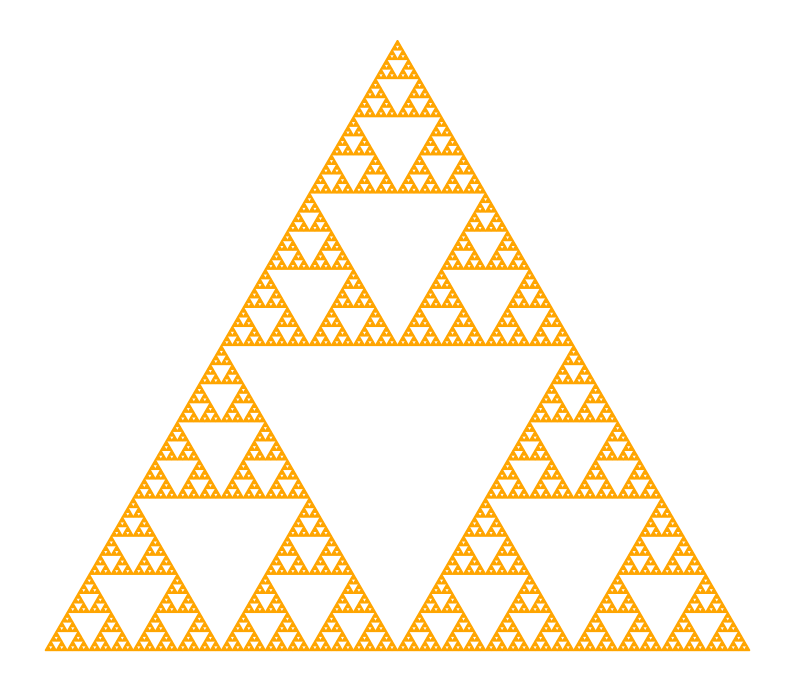

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
%matplotlib inline

plt.figure(figsize=(10, 10))
ax = plt.gca() # 現在の座標軸

blim = 0.01 # 辺の長さがこれ以下になったら単に正三角形を描いて塗りつぶす

# 左下の頂点が(x,y)で1辺 b のシェルピンスキーの三角形
def triangle(x, y, b):
    if b <= blim: # 1辺の長さが blim 以下ならば
        # 左下の頂点が (x,y), 1辺 b の正三角形を描く
        t = Polygon([(x, y), 
                     (x + b, y), 
                     (x + b/2, y + b/2 * 3**0.5)],
                    color="orange",
                    fill=True)
        ax.add_patch(t)
    else: # 1辺が blim より長ければ
        # 大きさを半分にして自分自身と相似な図形を3つ描く
        triangle(x, y, b/2) # 左下の三角形
        triangle(x + b/2, y, b/2) # 右下の三角形
        triangle(x + b/4, y + b/4 * 3**0.5, b/2) # 上の三角形

# 一辺の長さ１のシェルピンスキーの三角形を描画
triangle(0, 0, 1)

plt.axis('scaled') # 図形が収まる広さに調整
ax.set_aspect('equal') # 縦横 1:1 で表示
plt.axis("off") # 軸の目盛りは不要
plt.show();

### 練習12.2：マンダラ
再帰を用いて以下のような図形を描きなさい（[参考](https://crea.bunshun.jp/mwimgs/d/5/800w/img_d53d0f0b83c29521d1ca16c79786f17d1156029.jpg)）：

![mandara](data:image/png,%89PNG%0D%0A%1A%0A%00%00%00%0DIHDR%00%00%02%40%00%00%02%40%08%06%00%00%00e%9A%D96%00%00%00%04sBIT%08%08%08%08%7C%08d%88%00%00%00%09pHYs%00%00%0B%12%00%00%0B%12%01%D2%DD~%FC%00%00%009tEXtSoftware%00matplotlib%20version%203.0.2%2C%20http%3A//matplotlib.org/8%80%3B%AD%00%00%20%00IDATx%9C%EC%DDwX%14W%FB7%F0%7B%E9%7D%17%D8%A5%B3%A0%02%8A%5D%B0%60%17c%C4%8AXb%09b7%2AF%7D%2C%D1h%D4%A0%89%25%09%26%C6%F8X%23%96%18k%EC%BD%83%B1%2B%2A%B1%A3%22VP%91%CE%B2l%FB%BE%7F%F8%3A%3F%F7%C1%02F%5Cu%EF%CFuy%99%3D%3Bs%CE%3D%2BW%F6%CB%CC%993%22%00%20%C6%18c%8C1%23bb%E8%02%18c%8C1%C6%DE5%0E%40%8C1%C6%183%3A%1C%80%18c%8C1ft8%001%C6%18c%CC%E8p%00b%8C1%C6%98%D1%E1%00%C4%18c%8C1%A3%C3%01%881%C6%18cF%87%03%10c%8C1%C6%8C%0E%07%20%C6%18c%8C%19%1D%0E%40%8C1%C6%183%3A%1C%80%18c%8C1ft8%001%C6%18c%CC%E8p%00b%8C1%C6%98%D1%E1%00%C4%18c%8C1%A3%C3%01%881%C6%18cF%87%03%10c%8C1%C6%8C%0E%07%20%C6%18c%8C%19%1D%0E%40%8C1%C6%183%3A%1C%80%18c%8C1ft8%001%C6%18c%CC%E8p%00b%8C1%C6%98%D1%E1%00%C4%18c%8C1%A3%C3%01%881%C6%18cF%87%03%10c%8C1%C6%8C%0E%07%20%C6%18c%8C%19%1D%0E%40%8C1%C6%183%3A%1C%80%18c%8C1ft8%001%C6%18c%CC%E8p%00b%8C1%C6%98%D1%E1%00%C4%18c%8C1%A3%C3%01%881%C6%18cF%87%03%10c%8C1%C6%8C%0E%07%20%C6%18c%8C%19%1D%0E%40%8C1%C6%183%3A%1C%80%18c%8C1ft8%001%C6%18c%CC%E8p%00b%8C1%C6%98%D1%E1%00%C4%18c%8C1%A3%C3%01%881%C6%18cF%87%03%10c%8C1%C6%8C%0E%07%20%C6%18c%8C%19%1D%0E%40%8C1%C6%183%3A%1C%80%18c%8C1ft8%001%C6%18c%CC%E8p%00b%8C1%C6%98%D1%E1%00%C4%18c%8C1%A3%C3%01%881%C6%18cF%87%03%10c%8C1%C6%8C%0E%07%20%C6%18c%8C%19%1D%0E%40%8C1%C6%183%3A%1C%80%18c%8C1ft8%001%C6%18c%CC%E8p%00b%8C1%C6%98%D1%E1%00%C4%18c%8C1%A3%C3%01%881%C6%18cF%87%03%10c%8C1%C6%8C%0E%07%20%C6%18c%8C%19%1D%0E%40%8C1%C6%183%3A%1C%80%18c%8C1ft8%001%C6%18c%CC%E8p%00b%8C1%C6%98%D1%E1%00%C4%18c%8C1%A3%C3%01%881%C6%18cF%87%03%10c%8C1%C6%8C%0E%07%20%C6%18c%8C%19%1D%0E%40%8C1%C6%183%3A%1C%80%18c%8C1ft8%001%C6%18c%CC%E8p%00b%8C1%C6%98%D1%E1%00%C4%18c%8C1%A3%C3%01%881%C6%18cF%87%03%10c%8C1%C6%8C%0E%07%20%C6%18c%8C%19%1D%0E%40%8C1%C6%183%3A%1C%80%18c%8C1ft8%001%C6%18c%CC%E8p%00b%8C1%C6%98%D1%E1%00%C4%18c%8C1%A3%C3%01%881%C6%18cF%87%03%10c%8C1%C6%8C%0E%07%20%C6%18c%8C%19%1D%0E%40%8C1%C6%183%3A%1C%80%18c%8C1ft8%001%C6%18c%CC%E8p%00b%8C1%C6%98%D1%E1%00%C4%18c%8C1%A3%C3%01%881%C6%18cF%C7%CC%D0%050%C6%3ENZ%AD%96%9E%3CyB%B9%B9%B9%94%9F%9FOyyy%94%97%97G%F9%F9%F9%94%99%99I%0F%1E%3C%A0%F4%F4tz%FC%F81%3Dz%F4%88%1E%3F~L999%94%9B%9BK%2A%95%8A%88%88LLL%C8%D6%D6%96%24%12%09999%91L%26%23%17%17%17ruu%25%0F%0F%0Frqq%21%7B%7B%7B%E1%8F%9D%9D%1D%D9%DB%DB%93%B3%B33Y%5B%5B%1B%F8%13%60%8C%BD%CFD%00%60%E8%22%18c%1F%0E%00%94%91%91Aw%EF%DE%A5%07%0F%1EPZZ%DA%0B%FF~%FC%F81%D9%DB%DB%93%AD%AD-%99%98%98%90F%A3%A1%C2%C2B%CA%CF%CF%27%8DFC%96%96%96%24%12%89H%A3%D1%90Z%AD%26333%D2h4DDdggGfff%94%9B%9BK%00%C8%C4%C4D%18%DB%DC%DC%9CLLLH%A5R%11%00%B2%B5%B5%25%1B%1B%1B%B2%B0%B0%20%22%22%B5ZMO%9E%3C%21%1B%1B%1B%F2%F0%F0%20ww%F7b%7F%BB%BB%BB%93%A7%A7%27%C9%E5r23%E3%DF%03%193F%1C%80%18c/TPP%40%D7%AF_%A7%E4%E4d%BAv%ED%1A%25%27%27%0B%7FD%22%11%F9%F8%F8%14%0B%17nnn%A4P%28%E8%FC%F9%F3t%E6%CC%19%3A%7F%FE%3C%D9%D9%D9Qpp0%D5%AE%5D%9B%AAV%ADJ%A9%A9%A9%B4j%D5%2Az%F4%E8%11%0D%1A4%88%CA%95%2BG%23G%8E%A4%21C%86%D0%95%2BW%A8Z%B5j4a%C2%04%22%22%BA%7F%FF%3E%05%04%04%D0%1F%7F%FCA%E3%C6%8D%A36m%DAP%A3F%8Dh%C9%92%25%94%98%98H%91%91%91%D4%ACY3JOO%A7%C4%C4DJLL%A4%ABW%AF%92%BF%BF%3F%D5%ACY%93%EA%D4%A9Cr%B9%9C%B2%B2%B2%8A%85%B4%FB%F7%EFSzz%3A%F9%FA%FAR%40%40%00%05%04%04P%C5%8A%15%85%FFvss%23%91Hd%E0%7F%05%C6XY%E1%00%C4%98%91%D3j%B5%94%9C%9C%2C%04%88%7F%FE%F9%87%AE%5D%BBF%99%99%99%E4%E7%E7%27%04%82%E7C%82%B3%B3%B3%B0%BFJ%A5%A2%84%84%04%DA%BAu%2Bm%DB%B6%8DLLL%28%3C%3C%9CZ%B6lI%B5k%D7%26%17%17%17%22%22%DA%BBw/%0D%1C8%90%2AW%AELC%87%0E%A5%D6%AD%5B%D3%ED%DB%B7%A9a%C3%864o%DE%3C%EA%D8%B1%23%B5m%DB%96%06%0D%1AD%E1%E1%E1B%FFnnnt%E6%CC%19%B2%B2%B2%A2%D0%D0P%EA%DB%B7/%8D%1A5%8An%DC%B8A%0B%16%2C%A0e%CB%96%D1%80%01%03%28%26%26%86%AC%AC%ACH%A9T%D2%85%0B%17%E8%EF%BF%FF%A6m%DB%B6Qbb%22%85%86%86R%FB%F6%ED%A9%5D%BBv%E4%E6%E6%26%F4%ADT%2A%29%25%25%A5X%C0%BBv%ED%1A%15%16%16R%40%40%00U%AE%5C%99%82%83%83%2988%98j%D5%AAEvvv%EF%EE%1F%871Vf8%001fD%9E%0F%3Bg%CE%9C%A1%C4%C4D%3A%7F%FE%3C%B9%BA%BA%0A_%F25k%D6%A4%8A%15%2B%92%B7%B7%B7p%E9%E9%7F%01%A0S%A7N%D1%FC%F9%F3i%CB%96-T%A9R%25%0A%0F%0F%A7%F6%ED%DBS%95%2AU%F4%CE%9C%E4%E6%E6%D2%981ch%CF%9E%3D%B4x%F1bj%D9%B2%A5%F0%5E%AF%5E%BD%C8%CF%CF%8F%26O%9ELDD111t%EE%DC9Z%BF~%3DYXX%D0%A6M%9Bh%F8%F0%E1%94%9A%9AJ%A6%A6%A6t%E7%CE%1D%AAQ%A3%06%A5%A4%A4%90%A3%A3%23%11%11%3D%7C%F8%90%A2%A3%A3%E9%CA%95%2B%B4l%D92%AA%5B%B7%AE%5E%AD%99%99%99%B4%7B%F7n%DA%BAu%2B%ED%D9%B3%87%02%03%03i%E0%C0%81%D4%BD%7B%F7W%CE%13%CA%CA%CA%A2%EB%D7%AF%D3%C5%8B%17%85px%E1%C2%05%92%CB%E5%C2gU%BBvm%0EE%8C%7D%A08%001%F6%11S%2A%95t%FC%F8q%8A%8F%8F%A7%84%84%04JLL%D4%0B%3B%C1%C1%C1%14%14%14%24%84%89%D7Q%28%14%B4z%F5j%9A7o%1Eeee%D1%90%21C%28%2A%2AJ%EF%AC%CA%F3%12%13%13%A9S%A7N%D4%B2eK%8A%8D%8D%25%B1X%2C%BC%97%91%91A%E5%CA%95%A3%F0%F0p%CA%CD%CD%A5%BAu%EB%D2%7F%FE%F3%1Fj%DB%B6-%9D%3D%7B%96%CC%CD%CDI%A7%D3%D1%9E%3D%7B%A8%A0%A0%80%16-ZDj%B5%9A%1E%3E%7CH%5D%BAt%A1%91%23G%0A%7D%01%A0u%EB%D6%D1%88%11%23h%E8%D0%A14q%E2%C4%17%5E%BER%A9T%B4w%EF%5E%9A%3F%7F%3E%9D%3Cy%92z%F7%EEMC%86%0C%21%3F%3F%BF%12%1D%BFZ%AD%A6%2BW%AE%08%E1%F1%F9P%D4%A8Q%23%0A%0D%0D%A5f%CD%9A%91%87%87G%89%FAc%8C%19%0E%07%20%C6%3E%22J%A5%92N%9E%3CI%87%0E%1D%A2%F8%F8x%3As%E6%0CU%ABV%8D%9A5kFM%9B6%A5z%F5%EA%958%EC%3C/55%95%E6%CC%99C%2BV%AC%A0%FA%F5%EBStt4%85%85%85%BD%F4%0C%11%11QBB%02%7D%F6%D9g%B4%60%C1%02%EA%D4%A9S%B1%F7%27O%9EL%3F%FD%F4%13M%9C8%91%AAT%A9B%BF%FF%FE%3B%29%14%0AJJJ%A2%81%03%07%92%83%83%03m%DA%B4%89%DC%DD%DD%E9%F4%E9%D34m%DA4%B2%B5%B5%A5%B1c%C7%92R%A9%A4%87%0F%1F%16%EB3%3D%3D%9D%DA%B6mK%F5%EB%D7%A79s%E6%BC%B2%BE%94%94%14Z%B8p%21-%5D%BA%94%82%82%82%E8%CB/%BF%A4%B6m%DB%96z%DE%8FZ%AD%A6K%97.%D1%DF%7F%FFM%87%0E%1D%A2%84%84%04%92J%A5%D4%ACY3%E1%8F%BB%BB%7B%A9%FAd%8C%BD%03%60%8C%7D%B0%B4Z-N%9D%3A%85%29S%A6%2044%14vvv%A8%5B%B7.%C6%8D%1B%87%5D%BBv%2177%F7_%F5%FF%F0%E1C%0C%1F%3E%1C%CE%CE%CE%18%3Bv%2Cn%DD%BAU%A2%FD%8E%1C9%02%A9T%8A%FD%FB%F7%BFt%9B%A0%A0%204o%DE%5Cx%ADT%2Aacc%83%F1%E3%C7%0BmYYY011%C1%EA%D5%AB%85%B6%0B%17.%80%88%A0%D3%E9%5E%D8ovv6%1A6l%88%E8%E8%E8%97n%F3%BC%C2%C2B%ACX%B1%02%D5%ABWGHH%08%E2%E3%E3Kr%88/%A5%D5j%91%94%94%84%D9%B3g%23%22%22%02%8E%8E%8E%A8X%B1%22%06%0F%1E%8C%BF%FE%FA%EB_%FF%9B0%C6%DE%0E%0E%40%8C%7D%60%14%0A%05%B6o%DF%8E/%BE%F8%02%EE%EE%EE%A8X%B1%22F%8F%1E%8D%1D%3Bv%20%27%27%E7%AD%8C%91%93%93%83%C9%93%27%C3%C9%C9%09%C3%87%0F%C7%C3%87%0FK%BC%EF%A5K%97%E0%E2%E2%82%DD%BBw%BFr%BB%CA%95%2B%A3k%D7%AEzmb%B1%183g%CE%D4k355%C5%9E%3D%7B%84%D7yyy%20%22h4%9A%97%F6%9D%9D%9D%8D%A0%A0%20%C4%C4%C4%94%B8n%ADV%8B%3F%FF%FC%13%E5%CA%95C%ABV%ADp%EE%DC%B9%12%EF%FB%BA~%CF%9D%3B%87%9F%7F%FE%19aaa%B0%B7%B7GXX%18%FE%FB%DF%FF%E2%CE%9D%3Boe%0C%C6X%E9q%00b%EC%03%F0%F0%E1C%C4%C5%C5%21%22%22%02%0E%0E%0Eh%D2%A4%09bccq%ED%DA%B5%B7%3A%8EJ%A5%C2%EC%D9%B3%E1%E2%E2%82%A8%A8%A8%12%9F%F1y~%FF%A0%A0%20%2C%5C%B8%F0%B5%DBFDD%C0%D9%D9%19%0F%1E%3C%00%00l%DC%B8%11%0E%0E%0E%A8W%AF%1E%B2%B3%B3%01%00%BF%FD%F6%1B%1C%1D%1D%D1%B1cG%28%95Jh%B5Z%0C%1E%3C%18fff%AF%ED%FF%E1%C3%87pss%C3%D1%A3GKu%0CEEE%F8%ED%B7%DF%E0%E6%E6%86%1E%3Dz%94%FA3x%9D%9C%9C%1C%AC_%BF%1EQQQpvvF%ADZ%B5%F0%ED%B7%DF%2211%B1Dg%AC%18co%07%07%20%C6%DES%0F%1E%3C%C0%ACY%B3P%BF~%7D%88%C5b%7C%F6%D9gX%B1b%05222%CAd%BC%A4%A4%24%04%05%05%E1%D3O%3FERR%D2%1B%F5%F1%DDw%DF%21%2C%2C%ACD_%E4%C7%8F%1F%87%93%93%13lmm%E1%E1%E1%01///%1C%3F~%1Cm%DB%B6%85%89%89%09%CC%CC%CC%E0%E4%E4%84%D3%A7O%A3K%97.ppp%80T%2A%85%5C.G%8F%1E%3DJT%CF%FA%F5%EB%11%10%10%00%85BQ%EAc%C9%CB%CB%C3%94%29S%20%95J1w%EE%5Ch%B5%DAR%F7%F1%3Aj%B5%1A%09%09%09%183f%0C%FC%FD%FD%E1%E9%E9%89%E8%E8h%1C%3Dz%94%C3%10ce%8C%03%10c%EF%91%DC%DC%5C%2C%5B%B6%0C%9F~%FA%29%24%12%09%FA%F6%ED%8B%DD%BBwC%A9T%96%D9%98%2A%95%0AS%A7N%85T%2A%C5%92%25K%DE%F8%8B7%29%29%09R%A9%B4%C4%97ut%3A%1Dj%D5%AA%85%8D%1B7%E2%F6%ED%DBP%AB%D5%D8%B7o%1F%DC%DC%DC%F0%E7%9F%7Fb%C7%8E%1D%08%0F%0FG%B7n%DD%00%00%19%19%19%B8%7B%F7.%E4r9%CE%9C9S%E2%BA%BAv%ED%8A%D1%A3G%BF%D11%01%C0%D5%ABWQ%BF~%7D4k%D6%0C%29%29%29o%DCOI%C7%FA%FE%FB%EF%11%18%18%88r%E5%CAa%E2%C4%89%B8r%E5J%99%8E%C9%98%B1%E2%00%C4%98%81%A9T%2Al%DB%B6%0D%DD%BBw%87X%2CFxx8%D6%AE%5D%FBFg-J%EB%D9Y%9FV%ADZ%FD%EB%F9%28%CD%9A5%2B%D1%A5%AF%E7%ADZ%B5%0A%15%2BV%C4%93%27O%00%00%5D%BAtA%5C%5C%9C%F0~aa%21%EC%EC%EC%90%99%99%09%00%988q%22BCCK5%C6%A3G%8F%E0%E2%E2%F2%AF%82%84F%A3Alll%99%9E%0Dz%9EN%A7%C3%D9%B3g1j%D4%28%B8%BB%BB%2388%18%BF%FC%F2%0B%D2%D2%D2%CAt%5C%C6%8C%09%07%20%C6%0C%E4%CC%993%18%3At%28d2%19%1A4h%80y%F3%E6%E1%F1%E3%C7%EFdl%9DN%87%9F~%FA%E9_%9F%F5y%E6%C2%85%0B%F0%F0%F0%80J%A5%2A%F5%BEc%C7%8EE%8D%1A5p%F7%EE%5Dt%E8%D0%01%EB%D6%AD%13%DE%D3j%B5prr%C2%FD%FB%F71q%E2D%F8%FB%FB%E3%D1%A3G%A5%1Ec%C2%84%09%18%3E%7Cx%A9%F7%FB_%CF%CE%06%85%86%86%22%3D%3D%FD_%F7W%12%1A%8D%06%7B%F7%EEE%AF%5E%BD%20%91H%10%16%16%86%95%2BW%A2%B0%B0%F0%9D%8C%CF%D8%C7%8A%03%10c%EF%90B%A1%C0%B2e%CBP%B7n%5D%F8%F8%F8%60%EA%D4%A9%B8y%F3%E6%3B%AF%2122%12%C1%C1%C1%B8%7D%FB%F6%5B%E93%3A%3A%1A%DF~%FB%ED%1B%ED%AB%D3%E9%F0%C3%0F%3F%40%22%91%A0a%C3%86%F0%F5%F5%C5%95%2BW%A0P%280d%C8%10%C8%E5r%F8%FA%FA%A2Y%B3f%A5%BA%1B%EDy%A9%A9%A9prrB~~%FE%1B%ED%FF%3C%8DF%83%89%13%27B.%97%BF%B5%3B%C5J%AA%A0%A0%00%ABW%AFF%CB%96-%21%93%C90v%EC%D8w%FE%F3%C3%D8%C7%82%03%10c%EF%C0%8D%1B70f%CC%18H%A5R%B4n%DD%1A%DB%B6m%7B%E5m%DCe%E5%DE%BD%7B%A8%5D%BB6%BAw%EF%8E%82%82%82%B7%D2gnn.%1C%1D%1Dq%EF%DE%3D%E8t%3A%1C%3At%08-%5B%B6%84%B9%B99%88%08%A6%A6%A6%08%09%09y%ED1%A7%A6%A6%A2S%A7N011%01%11%09%7F%2AT%A8%80%F5%EB%D7%BF%B2%86%EB%D7%AF%E3%CB/%BF%84%AD%AD-%88%08%22%91%08%5E%5E%5E%98%3Bw%AE%B04%40xx8%16-Z%F4V%8E%19%00%D6%AE%5D%0B%A9T%AAw%C6%EA%5D%BA~%FD%3AF%8F%1E%0Dggg%B4i%D3%06%DB%B7o7%C8%CF%14c%1F%2A%0E%40%8C%95%11%8DF%83%AD%5B%B7%A2U%ABV%90J%A5%F8%EA%AB%AFp%E3%C6%0D%83%D5s%E2%C4%09xzzb%FA%F4%E9o%F5%0E%A3%95%2BW%22%3C%3C%1C%17/%5ED%D5%AAU%11%10%10%00%B1X%8C%1F%7F%FC%11%A9%A9%A9X%B2d%09%EC%ED%EDQ%BDzu%F8%FA%FA%E2%C8%91%23%C5%FAX%B0%60%01%9C%9C%9CP%A7N%1D%B8%BB%BBc%DF%BE%7D%B8z%F5%2A%BAu%EB%06___%B8%B8%B8%A0C%87%0E%C8%CA%CA%D2%DB/77%17%9F%7D%F6%19d2%19%2AT%A8%80%0E%1D%3A%2099%19%87%0F%1F%86%5C.G%ED%DA%B5%E1%E8%E8%88_~%F9%05%5B%B7nE%E3%C6%8D%DF%DAq%03%C0%D9%B3g%21%97%CB1i%D2%A42%9F%17%F42%0A%85%02K%97.E%9D%3Au%E0%EB%EB%8B%993g%BE%D1eB%C6%8C%0D%07%20%C6%DE%B2%DC%DC%5C%C4%C6%C6B.%97%A3%5E%BDzX%BE%7C%F9%3B%99%D0%FC%2A%ABW%AF%86T%2A%C5%96-%5B%DEz%DF%C3%87%0F%C7%7F%FE%F3%1F%B8%B8%B8%60%D9%B2eX%B7n%1D%DA%B5k%A7%B7%CD%90%21C%F0%CB/%BF%60%FB%F6%ED%90%C9d%D8%BBw%AF%F0%DE%B4i%D3%10%10%10%80k%D7%AE%21%22%22Bo%D5g%8DF%03%89D%82%BBw%EFb%D8%B0a%A8%5E%BD%BA%10%82%F2%F2%F2P%A7N%1D%0C%180%00%19%19%19%B0%B2%B2%D2%9B%83%B4u%EBV%B4l%D9%12%29%29%29%A8R%A5%0AF%8D%1A%05%5B%5B%DB%B7~%96%24%3D%3D%1D%0D%1B6D%C7%8E%1D%0D%3E/%E7%D4%A9S%E8%DB%B7/%24%12%09%A2%A2%A2p%E1%C2%05%83%D6%C3%D8%FB%EC%E5%0F%CAa%8C%95JFF%06M%9E%3C%99%CA%97/O%A7N%9D%A2%0D%1B6%D0%89%13%27%A8W%AF%5E%AF%7C%EAxY%8B%8B%8B%A3%D1%A3G%D3%C1%83%07%29%3C%3C%FC%AD%F7%7F%E2%C4%09%FA%F3%CF%3F%E9%BF%FF%FD/%F5%EE%DD%9BLMMI%A3%D1%E8m%A3V%ABI%24%12Q%DB%B6mi%C3%86%0D%14%19%19I%B7o%DF%A6%CD%9B7%D3%E2%C5%8B%29%21%21%81%02%02%02%C8%C4%C4Do_%9DNG%3A%9D%8E%AC%AC%AC%E8%D7_%7F%A5f%CD%9AQdd%24%11%11%F5%EB%D7%8Fj%D4%A8A%8B%16-%22kkk%02%40Z%AD%B6%D8%98%E5%CA%95%A3%84%84%04%DA%B6m%1B%D9%D9%D9%D1%D5%ABW%DF%EA%F1%BB%BA%BA%D2%81%03%07%C8%C2%C2%82%DA%B7oO%05%05%05o%B5%FF%D2%A8S%A7%0E%C5%C5%C5%D1%CD%9B7%2900%90Z%B4hA%E1%E1%E1t%FC%F8q%83%D5%C4%D8%7B%CB%D0%09%8C%B1%0F%DD%9D%3Bw0b%C4%088%3A%3Ab%E0%C0%81HNN6tI%82y%F3%E6%C1%DB%DB%FB%AD%AF%18%FD%8CF%A3%81%85%85%05%3At%E8%80%EC%EClh4%1Adee%C1%C7%C7%07%B1%B1%B18w%EE%1C%E2%E2%E2%20%93%C9%90%9A%9A%0A%ADV%8B%AC%AC%2C%8C%1C9%12c%C7%8EE%BDz%F5%B0a%C3%06dggC%A7%D3a%EB%D6%AD%F0%F2%F2%C2%BE%7D%FBp%EE%DC9DFF%A2%5D%BBv%D0%E9tP%2A%95%C8%CE%CE%86%A7%A7%27%B6n%DD%0A%99L%86%27O%9E%08g%5D%BAu%EB%86%CE%9D%3B%E3%EC%D9%B38x%F0%20%CA%95%2B%875k%D6%00x%BA%FA%F2%EE%DD%BB%21%16%8B%B1l%D9%B22%FB%2Cz%F7%EE%8D%26M%9A%BC7%CF%FBR%28%14%98%3Bw.%7C%7C%7C%D0%B4iS%EC%DE%BD%9B%17Xd%EC%FF%E3%00%C4%D8%1B%BAz%F5%2A%FA%F6%ED%0BGGG%8C%1E%3D%1A%F7%EE%DD3tIz%16.%5C%08%1F%1F%9F2%5D%BC%EF%F2%E5%CB033%83%B7%B77lmmacc%83%B9s%E7b%E5%CA%95%B0%B4%B4%84H%24%82%A9%A9%29~%FC%F1G%AC%5B%B7%0E%12%89%04vvvpqq%81%9D%9D%1D%24%12%09lll%60kk%8B%80%80%00%24%25%25%A1C%87%0E%10%89D%10%89D%90J%A58%7F%FE%3C%FA%F5%EB%07KKKXYY%C1%CF%CF%0F%95%2AU%82%9F%9F%1F%2C--aii%89%C8%C8H%5C%BCx%11nnn%C2%BE-%5B%B6%C4%A5K%97P%A5J%15%D8%D8%D8%C0%DA%DA%1A666%C5%9E%3F%F66i%B5Z%0C%180%00M%9A4yk%93%CC%DF%06%95J%85%15%2BV%A0r%E5%CA%08%0A%0A%C2%BAu%EBx%C243z%1C%80%18%2B%A5%8B%17/%A2K%97.%90%C9d%982e%8A%B0%88%DF%FBd%D9%B2e%F0%F2%F2%2A%F3I%D7K%96%2C%01%11a%F9%F2%E5%D0%E9t%B8y%F3%26%BC%BD%BD%E1%E0%E0%80%7D%FB%F6%01x%3AQX%22%91%C0%C9%C9%09g%CF%9E%05%00%EC%DD%BB%17%22%91%08VVVHII%81N%A7%C3%F2%E5%CB%E1%E8%E8%88%1A5j%E0%D1%A3G%D0%E9t%986m%1A%5C%5C%5C%D0%AAU%2B%E4%E5%E5A%ADV%2322%12D%84%88%88%08%A8T%2A%28%14%0ADDD%C0%CD%CD%0D%13%26L%80V%AB%C5%93%27OP%AF%5E%3D8%3B%3Bc%FE%FC%F9%D0%E9t%B8s%E7%0E%EC%EC%EC%E0%E5%E5U%A6%9F%89V%ABE%AF%5E%BD%D0%A2E%0B%83%CF%09%FA_Z%AD%16%5B%B6lAHH%08%02%02%02%B0%7C%F9r%0EB%CChq%00b%AC%84RSS%D1%A7O%1F%B8%B8%B8%2066%F6%AD%AC%29S%16%B6m%DB%06ww%F7w%F2%08%85%11%23F%C0%C4%C4D%AF-%2A%2A%0A%15%2AT%D0kk%D4%A8Q%B1%3B%B0%CC%CC%CC%E0%E7%E7%A7%D7%F6%BFO%83%D7%E9t055%D5%7B%B2%7Cnn.%88%08%D7%AF_%17%DAN%9F%3E%0D%91H%A4w%27%D6%82%05%0B%60cc%A3%D7%7F%93%26M%60kk%5B%CA%A3%2C%3D%B5Z%8D%AE%5D%BB%A2S%A7N%06%BB%3B%ECUt%3A%1D%0E%1E%3C%88%86%0D%1B%A2j%D5%AA%D8%BAu%2B_%1AcF%87%27A3%F6%1A%19%19%194j%D4%28%0A%0A%0A%22///JNN%A6%D1%A3G%93%AD%AD%AD%A1K%2B%E6%F2%E5%CB%D4%AF_%3F%DA%B8q%23U%AAT%A9%CC%C7%B3%B5%B5%25%00z%13%97%0B%0B%0B%A9%A8%A8%88%00%08mJ%A5%92%94J%A5%F0%1AO%7F%F9%D2%DBO%A3%D1%90F%A3%D1%9BD%5CPP%40%00%28%3F%3F_hKKK%23%22%A2G%8F%1E%09m999DD%94%9B%9B%2B%B4%E5%E7%E7%93V%AB%25%95J%25%B4%29%14%0A255%FDW%C7%5C%12fff%B4b%C5%0AJOO%A7%A9S%A7%96%F9x%A5%25%12%89%2844%94%FE%FE%FBo%9A%3E%7D%3A%8D%1F%3F%9E%1A7nLG%8E%1C1ti%8C%BD3%A61111%86.%82%B1%F7Q~~%3E%FD%F0%C3%0F%14%15%15E%81%81%81%B4v%EDZ%0A%0F%0F%27%2B%2B%2BC%97%F6B%99%99%99%D4%BCys%FA%FE%FB%EF%A9%5D%BBv%EFd%CC%82%82%02Z%BDz5%5D%BDz%95%9C%9D%9Di%FB%F6%ED%B4b%C5%0Arpp%A0K%97.Qzz%3A%AD%5B%B7%8E%8E%1E%3DJ%F9%F9%F9TPP%40%3A%9D%8E~%FE%F9g%3As%E6%0C%E5%E7%E7%93D%22%21%85BA%DF%7C%F3%0D%99%9B%9B%D3%DE%BD%7B%C9%CC%CC%8C._%BEL%13%26L%20___Z%B5j%15%C9%E5r%BAs%E7%0E%F5%EA%D5%8B233%E9%C0%81%03%E4%EF%EFO%97/_%A6/%BF%FC%92%82%83%83i%F9%F2%E5%04%80%0E%1F%3EL3f%CC%A0%EA%D5%AB%D3%CE%9D%3B%C9%C5%C5%85%F6%EC%D9C%CB%96-%23___%1A%3Ath%99%7F6fff%D4%B6m%5B%8A%8E%8E%26ooo%AA%5C%B9r%99%8FYZ%22%91%88%2AV%ACH%83%06%0D%22%0B%0B%0B%1A6l%18%1D8p%80%AAU%ABF%AE%AE%AE%86.%8F%B12%25%C2%F3%BF%A61%C6H%A5R%D1%E2%C5%8B%E9%FB%EF%BF%A7%D0%D0P%FA%EE%BB%EF%A8B%85%0A%86.%EB%954%1A%0D%B5n%DD%9A%AAW%AFN%B3f%CDzg%E3%DE%BBw%8F%CA%97/O%CD%9B7%27%85BA...%14%13%13C%27N%9C%A0/%BF%FC%92LMMI%ADV%D37%DF%7CC%7D%FB%F6%A5%09%13%26%D0%ED%DB%B7I%2C%16Srr2%A5%A5%A5Qhh%28eggS%DD%BAui%F2%E4%C9%D4%A5K%17JHH%20SSS%B2%B4%B4%A4%83%07%0F%D2%ED%DB%B7i%C1%82%05%A4V%ABI%A1P%90T%2A%A5%F4%F4t%12%8B%C5dbbB%FD%FB%F7%A7%AAU%ABR%D3%A6MI%A1P%90V%AB%A5z%F5%EA%D1%F6%ED%DBi%C6%8C%19t%EC%D81rpp%A0%7D%FB%F6%D1%17_%7CAs%E6%CCyg%9F%D1%D9%B3g%29%2C%2C%8C%F6%ED%DBG5k%D6%7Cg%E3%BE%89%A2%A2%22%9A%3F%7F%3E%CD%981%83Z%B5jES%A6L%21___C%97%C5X%D90%DC%D57%C6%DE%3F%BBw%EF%86%BF%BF%3F%C2%C2%C2%84%09%BB%1F%82%11%23F%20%2C%2C%0Cj%B5%FA%9D%8E%AB%D3%E9%20%16%8BQ%B5jUa%EC%E4%E4d%C8d2%24%25%25%01%00n%DF%BE%0Dooo%FC%FD%F7%DF%C2%3E%ED%DA%B5%C3%BCy%F3%D0%AD%5B7%FC%F8%E3%8FB%7F%D3%A7OG%8B%16-%84%85%23%97/_%8E%F2%E5%CB%0B%13u%D3%D2%D2%20%91Hp%E3%C6%0DH%24%12%A4%A6%A6%0A%7DV%AE%5C%19%F3%E7%CF%07%00%28%95J%B4o%DF%1E%13%27N%14%FA%9E%3Bw.d2%196o%DE%5C%C6%9FJqk%D6%AC%81%8F%8F%CF%1B%3F%CB%EC%5D%CB%C9%C9%C1%E4%C9%93%E1%E4%E4%84%09%13%26%BC%B7%F3%DD%18%FB78%001%86%A7%13%9C%3Bv%EC%88%0A%15%2A%60%C7%8E%1D%86.%A7TV%AF%5E%0D%7F%7F%7Fdff%1Ad%FC%D6%AD%5B%A3F%8D%1A%184h%10%B4Z-V%ADZ%85%CF%3E%FBLo%9BQ%A3F%E1%87%1F~%00%00L%9D%3A%155k%D6D~~%3E._%BE%AC%B72t%DB%B6m%8B%05%14WWW%DC%BBw%0F999%A8S%A7%0E%A6L%99%02%00%F8%E9%A7%9FP%BDzu%3Cy%F2%04YYY%B0%B3%B3%D3%9B%C8%BBo%DF%3E4k%D6%0C%00p%F8%F0a%C8d2H%24%12%83-W0a%C2%04%7C%F2%C9%27%EF%E5%A4%E8%97%B9w%EF%1Ez%F4%E8%01%B9%5C%8E%0D%1B6%F0Di%F6Q%E1I%D0%CC%A8%29%95J%FA%FE%FB%EF%2988%98%82%82%82%E8%E2%C5%8B%D4%A6M%1BC%97Ub%0F%1F%3E%A4%11%23F%D0%9F%7F%FEI%8E%8E%8E%06%A9%A1v%ED%DA%D4%B2eK%BAx%F1%22u%EB%D6%8D%0A%0B%0B%29%25%25EoU%E6%EB%D7%AF%93H%24%A2%C1%83%07%D3%9A5kh%C7%8E%1DdkkK%81%81%81%C2%CA%D0%B3g%CF%26%07%07%07%BAq%E3%86%B0%DF%A3G%8F%28//%8F.%5D%BAD%8D%1B7%A6z%F5%EA%D1%A4I%93%88%88h%F4%E8%D1%D4%AAU%2Bj%D8%B0%21%9D%3E%7D%9A4%1A%0D%3Dx%F0%40oL%B1XL%F3%E6%CD%A3%CE%9D%3B%D3%EC%D9%B3%C9%D2%D2%92%3C%3C%3C%DE%DD%87%F3%9C%A9S%A7R~~%3E-%5C%B8%D0%20%E3%BF%09OOOZ%B5j%15-_%BE%9C%26M%9AD%ADZ%B5%A2%E4%E4dC%97%C5%D8%DBa%E8%04%C6%98%A1l%DF%BE%1D%15%2AT%40DD%04n%DD%BAe%E8rJM%A7%D3%A1c%C7%8E%18%3F~%BCA%EB%D8%BBw/%82%82%82PPP%80%AF%BF%FE%1AR%A9%14%8E%8E%8E%A8Y%B3%26%06%0F%1E%8C%86%0D%1B%C2%C1%C1%01b%B1%18%D1%D1%D1/%3CSu%F1%E2EDDD%C0%C1%C1%01%E6%E6%E6%A8R%A5%0Aj%D6%AC%09GGGH%A5R%04%04%04%60%F1%E2%C5/%3C%03%F1l%81%3F%99L%06%99L%86%01%03%06%A0s%E7%CE%B0%B6%B6%86X%2CF%BBv%EDp%EE%DC9%2CX%B0%00%5D%BAty%17%1F%C9K%5D%BE%7C%19%CE%CE%CEe%BA8eYQ%A9T%985k%16%9C%9D%9D%F1%F5%D7_%F3e1%F6%C1%E3%00%C4%8CNJJ%0A%C2%C3%C3%E1%E7%E7%87%5D%BBv%19%BA%9C7%B6j%D5%2AT%AE%5C%19J%A5%D2%A0uh%B5Z%94%2BW%0E%27O%9E%04%00%14%16%16%E2%F7%DF%7FG%ED%DA%B5%21%97%CBQ%A3F%0D%C4%C6%C6%BE%F2%F1%10%2A%95%0A%ABW%AFFpp0LLL%20%12%89%84%BF%ED%ED%ED1q%E2%C4W%5E%BA%D2%E9t%88%8F%8FGXX%18%7C%7D%7D%11%10%10%80%C1%83%07%0BAC%A7%D3%A1z%F5%EAz%0Fa5%94%1F~%F8%01%A1%A1%A1%1F%D4%A5%B0%E7%3Dx%F0%00%91%91%91%F0%F6%F6%C6%BAu%EB%F8%B2%18%FB%60q%00bFC%AB%D5b%F6%EC%D9pvv%C6%B4i%D3%0C%1E%1C%FE%8D%F4%F4t%B8%B8%B8%E0%D4%A9S%86.%05%00%F0%E3%8F%3F%A2w%EF%DEo%B4oVV%16%9A5k%86%06%0D%1A%20%22%22%02%5D%BBv%15%26%3D%EF%DB%B7%0F%CE%CE%CE%88%8E%8E%86L%26%13V%97.%AD%23G%8E%C0%DF%DF%FF%BD%08%1D%1A%8D%06%F5%EA%D5%C3%BCy%F3%0C%5D%CA%BF%92%90%90%80%AAU%AB%A2m%DB%B6%B8%7F%FF%BE%A1%CBa%AC%D48%001%A3p%FD%FAua5%E2%E7W%10%FEPu%EE%DC%D9%E0%97%BE%9E%F7%F8%F1cH%24%12ddd%94j%3F%85B%81%FA%F5%EB%23%3A%3A%1A%1A%8D%06%AD%5B%B7%C6%D6%AD%5B%F5%B6qss%C3%DD%BBw%91%90%90%00%99L%26%DCMV%1A%91%91%91%F8%F9%E7%9FK%BD_Yyv%29%EC%D9%5Dl%1F%AA%A2%A2%22L%9E%3C%192%99Lx%1C%0Ac%1F%0A%9E%04%CD%3Ej%3A%9D%8E~%FD%F5W%AA_%BF%3Eu%E9%D2%85%E2%E3%E3%C9%CF%CF%CF%D0e%FD%2B%87%0F%1F%A6%C4%C4D%9A%3Cy%B2%A1K%11H%A5R%EA%D6%AD%9B0A%B9%A4%A6O%9FN%EE%EE%EE%F4%DBo%BF%91%A9%A9%29yzz%D2%A9S%A7%84%F7SRR%28//%8F%A4R%295i%D2%84V%ACXA%DD%BBw%27%B5Z%5D%E21N%9F%3EM%FB%F6%ED%A3%3E%7D%FA%94%AA%B6%B2%14%18%18HC%87%0E-%F5%E7%F5%BE%B1%B0%B0%A0%29S%A6%D0%9E%3D%7Bh%D6%ACY%14%1E%1E%AE7%11%9D%B1%F7%19/%84%C8%3EZ7n%DC%A0%BE%7D%FB%92H%24%A2%B8%B8%B8%0F%3E%F8%10%3D%7D%84D%A3F%8Dh%F0%E0%C1%14%15%15e%E8r%F4dggS%B5j%D5h%F9%F2%E5%D4%BCy%F3%D7n%AFR%A9%C8%DB%DB%9B%BE%FE%FAk%B2%B4%B4%A4%DA%B5k%93%BB%BB%3B%D5%AF_%9F%FC%FC%FC%C8%CE%CEN%08z%9F%7D%F6%19m%DF%BE%9D%D4j5-Z%B4%88%BE%FE%FAk%EA%DC%B9%F3k%C7P%2A%95%14%1C%1CL%13%27N%A4%1E%3Dz%BC%8D%C3%7Ckrss%29%20%20%80%F6%EE%DDK%D5%ABW7t9%FF%9AJ%A5%A2i%D3%A6%D1%FC%F9%F3%2966%96%A2%A2%A2H%24%12%19%BA%2C%C6%5E%8A%CF%00%B1%8F%CE%B3%B3%3E%21%21%21%1F%CDY%9Fg%B6m%DBFyyy%F4%F9%E7%9F%1B%BA%94b%24%12%09-Z%B4%88%FA%F7%EFOyyy%AF%DD~%CD%9A5TTTD%1B7n%A4%A4%A4%24%EA%D4%A9%13%AD%5C%B9%92lmm%29%3D%3D%9D%EE%DF%BFO%85%85%85%A4%D1h%A8V%ADZ%B4c%C7%0E%3Az%F4%28%5D%BBv%8D%A6O%9F%5E%A2%9A%A6N%9DJ%01%01%01%D4%BD%7B%F7%7F%7Bxo%9D%83%83%03%8D%1F%3F%9E%BE%F9%E6%1BC%97%F2V%F0%D9%20%F6%C11%F0%258%C6%DE%AA%D4%D4T4n%DC%18%8D%1A5Brr%B2%A1%CBy%AB4%1A%0D%AAT%A9%82m%DB%B6%19%BA%94W%EA%DB%B7/%FA%F4%E9%F3%DA%F9%20%8D%1A5B%95%2AU%84%89%C9w%EE%DC%81%A5%A5%25%FA%F4%E9%23ls%EE%DC9%98%99%99a%C6%8C%19B%DB%BAu%EB%20%12%89%5E%5BGBB%02%5C%5C%5C%90%96%96%F6%86GR%F6%94J%25%7C%7C%7C%DEh%5E%D3%FB%EC%F9%B9A%ABW%AF6t9%8C%BD%10%9F%01b%1F%8D%CD%9B7S%DD%BAu%A9%5D%BBv%94%90%90%40%FE%FE%FE%86.%E9%ADZ%B9r%259%3A%3AR%DB%B6m%0D%5D%CA%2B%FD%FA%EB%AFt%F1%E2E%9A0a%C2%2B%B7%CB%C8%C8%A0%EA%D5%AB%93%89%C9%D3%FF%0Dy%7B%7B%93%95%95%95%DES%EC%9F%3D%3B%2B%28%28Hh%0B%0F%0F%27%00z%0B-%FE%AF%B3g%CFR%97.%5D%E8%CF%3F%FF%2477%B7%7Fs8e%CA%D2%D2%92%A6N%9DJ%E3%C6%8D%23%7CD%B3%11%9E%9D%0D%DA%B5k%17M%9A4%89%06%0E%1CH%0A%85%C2%D0e1%A6%87%03%10%FB%E0%15%15%15%D1%F0%E1%C3i%E4%C8%91%B4e%CB%16%1A%3Bv%AC%F0%A5%FA%B1%D0h4%14%13%13C3f%CCx%EF%E7U%D8%DB%DB%D3%AE%5D%BBh%DB%B6m4~%FC%F8%97~%B1%CBd2JJJ%22%9DNGDD%B7o%DF%A6%A2%A2%22%BAr%E5%8A%B0%CF%D9%B3g%89%88%E8%CC%993%C2~%9B7o%26%91HD%A6%A6%A6/%EC%F7%D4%A9S%D4%A6M%1BZ%B0%60%01%B5h%D1%E2m%1EZ%99%88%8C%8C%A4%9C%9C%1C%DA%B3g%8F%A1Ky%EB%82%83%83%E9%EC%D9%B3%A4P%28%A8n%DD%BAt%F9%F2eC%97%C4%D8%FF1%EC%09%28%C6%FE%9D%E4%E4d%04%05%05%A1S%A7N%06%7B%16%D6%BB%B0y.%9B%EE%CB%00%00%20%00IDAT%F3f%D4%AF_%DF%D0e%94%CA%E3%C7%8FQ%BBvm%F4%EB%D7%EF%85%AB%06%FF%F1%C7%1F%90H%24%A8_%BF%3E%FA%F7%EF%0F%0F%0F%0F%FC%F0%C3%0F%A8X%B1%22%FC%FC%FCP%ADZ5%88%C5b%CC%9B7%0F%DE%DE%DE%88%88%88%40%CF%9E%3D%E1%E0%E0%80%E0%E0%E0%17%8E%B9i%D3%26%C8d%B2b%B7%D2%BF%EF%E2%E2%E2%D0%B6m%5BC%97Qft%3A%1D%96%2CY%02%A9T%8A%25K%96%F0%ED%F2%EC%BD%F0q%FD%9A%CC%8C%CA%AAU%AB%A8A%83%06%D4%AF_%3F%FA%EB%AF%BF%0C%F6%2C%ACwa%DE%BCy%14%1D%1Dm%E82JE%2A%95%D2%81%03%07H%ADVS%F5%EA%D5%29%21%21A%EF%FD%AE%5D%BB%92%A5%A5%25u%EF%DE%9D%EA%D4%A9C%5B%B7n%A5%EE%DD%BBS%5E%5E%1E%F9%FA%FAR%F9%F2%E5%C9%D6%D6%96%B4Z-%9D%3F%7F%9E%3Aw%EEL%A1%A1%A1%E4%EF%EF_l%E2pff%26%F5%EC%D9%93%C6%8C%19C%9B7o%A6%F6%ED%DB%BF%CBC%FD%D7%BAu%EBF%27N%9C%A0%5B%B7n%19%BA%942%21%12%89%A8_%BF~%14%1F%1FO%3F%FF%FC3%F5%EC%D9%B3D%13%E5%19%2BS%86N%60%8C%95VAA%01%FA%F7%EF%0F%7F%7F%7F%9C%3D%7B%D6%D0%E5%94%B9%E4%E4d%C8d2%14%16%16%1A%BA%947%B6u%EBVxxx%60%D8%B0a%C8%CE%CE%16%DA%27O%9E%8C%88%88%08a%22t%FF%FE%FD1y%F2d%E1%FD%5B%B7n%C1%D6%D6%16%0A%85%02%00%B0c%C7%0Ex%7B%7BC%ADV%03xzfa%C3%86%0D%F0%F0%F0%C0%88%11%23PPP%F0%0E%8F%EA%ED%1A5j%14%C6%8D%1Bg%E82%CA%5CAA%01%06%0E%1C%08%3F%3F%3F%24%26%26%1A%BA%1Cf%C4%F8%0C%10%FB%A0%A4%A4%A4P%BDz%F5H%A9TRbb%22%D5%AAU%CB%D0%25%95%B9%05%0B%16P%BF~%FD%C8%CA%CA%CA%D0%A5%BC%B1%F6%ED%DB%D3%85%0B%17%A8%A0%A0%80%7C%7D%7Di%D0%A0A%94%94%94D%E3%C7%8F%A7%8C%8C%0C%8A%8E%8E%26%ADVK%0F%1E%3C%A0%DA%B5k%0B%FB%F9%FA%FA%92%BD%BD%3D%3Dy%F2%84%0E%1D%3AD%7D%FA%F4%A15k%D6P~~%3E%FD%FA%EB%AF%14%18%18HS%A6L%A1%D5%ABW%D3%EC%D9%B3%C9%C6%C6%C6%80G%F9%EF%0C%1E%3C%98%E2%E2%E2H%A9T%1A%BA%942eccC%8B%16-%A2%EF%BE%FB%8E%C2%C2%C2%28..%CE%D0%251%23%C5%0B%21%B2%0F%C6%C1%83%07%E9%F3%CF%3F%A7I%93%26Qtt%F4%7B%3F%19%F8mP%28%14%24%97%CB%E9%F4%E9%D3T%AE%5C9C%97%F3V%A4%A7%A7%D3%EF%BF%FFN%0B%17.%24%B9%5CN%9F%7C%F2%09m%DF%BE%9DLLL%C8%DB%DB%9B%CC%CC%CCh%CD%9A5djjJ%7B%F6%EC%A1%9E%3D%7BRxx8m%DE%BC%99%FA%F4%E9CO%9E%3C%A1-%5B%B6P%EB%D6%AD%29%3A%3A%9A%1A6l%F8%D1%FC%2C%84%85%85QTT%14%F5%EC%D9%D3%D0%A5%BC%13W%AF%5E%A5%F0%F0pj%D3%A6%0D%C5%C6%C6%92%99%99%99%A1KbF%84%03%10%7B%EF%01%A0y%F3%E6%D1%D4%A9Si%F5%EA%D5%25Ze%F8c%B1r%E5JZ%B5j%15%ED%DC%B9%B3%C4%FB%00%A0%07%0F%1EPbb%22%C5%C7%C7%D3%EE%DD%BB%E9%EE%DD%BB%A4%D5j%C9%D6%D6%96%82%82%82%A8%5D%BBvT%B7n%5D%AA%5E%BD%3AY%5B%5B%97%E1%11%BC%9CF%A3%A1%5D%BBvQ%7C%7C%3C%1D%3Dz%94%CE%9D%3BG%1A%8DF%B8%2B%ECy%26%26%26%E4%E5%E5EM%9A4%11%16%B8tuu5%40%D5O%3F%DF%94%94%14JLL%A4%7D%FB%F6%D1%A1C%87%28%3D%3D%9Dt%3A%1D%89%C5b%0A%09%09%A1%B6m%DBR%9D%3Au%A8r%E5%CAdnn%5E%E2%BE7o%DEL%3F%FF%FC3%1D%3E%7C%B8%0C%8F%E0%FD%92%95%95E%3Dz%F4%20%ADVKk%D7%AE%25%27%27%27C%97%C4%8C%04%07%20%F6%5ES%A9T%F4%E5%97_%D2%B1c%C7h%EB%D6%ADT%BE%7CyC%97%F4Nu%E9%D2%85%DA%B5k%F7%DA%E7X%01%A0%BF%FF%FE%9B%16%2CX%40%07%0F%1E%24%B5ZM%E6%E6%E6%94%95%95E%00%A8F%8D%1A%24%95J%2911%91%94J%A5%F0e%9D%99%99I%15%2BV%A4%EE%DD%BBS%FF%FE%FDI%26%93%BD%93%E3%D2%E9t%B4%7F%FF~Z%B8p%21%1D%3E%7C%98%00%90%89%89%09egg%93F%A3%21%A9TJ%26%26%26%94%93%93CDDfff%E4%E0%E0%40%99%99%99T%B5jU%8A%8C%8C%A4%DE%BD%7B%BF%B3%89%EFZ%AD%96v%EE%DCI%8B%16-%A2%A3G%8F%92%B9%B99%01%A0%BC%BC%3C%D2j%B5T%B7n%5D%B2%B6%B6%A6%93%27O%12%00255%25%5B%5B%5B%CA%CE%CE%A6%1A5j%08gu%EC%ED%ED_9%8ER%A9%24WWW%BAy%F3%26I%A5%D2wrl%EF%03%8DFC%E3%C6%8D%A3%AD%5B%B7%D2%96-%5B%A8r%E5%CA%86.%89%19%03CL%3Cb%AC%24%1E%3E%7C%88F%8D%1A%21%3C%3C%1C%B9%B9%B9%86.%E7%9DS%2A%95%10%8B%C5x%F4%E8%D1K%B7%C9%CD%CD%C5%7F%FF%FB_T%A9R%05%95%2AU%C2%9C9s%B0m%DB6%B8%BA%BAb%E6%CC%99%18%3Cx0%BE%F9%E6%1B%BD%ED%9D%9C%9C%B0k%D7.4l%D8%10%9F%7D%F6%19%E2%E3%E3%D1%AF_%3FH%24%12DFF%E2%E8%D1%A3evL%99%99%99%985k%16%FC%FC%FCP%B3fM%2C%5C%B8%10%EB%D7%AF%87L%26%C3%DC%B9s%D1%BD%7Bw%CC%9A5K%D8%FE%F1%E3%C7%B0%B1%B1%C1%81%03%07P%B3fM%0C%180%00%07%0E%1C%C0%E7%9F%7F%0E%89D%82%FE%FD%FB%97%E9D%DA%87%0F%1Fb%FA%F4%E9%90%CB%E5%08%09%09%C1%F2%E5%CB%B1%7C%F9rH%A5R%C4%C5%C5%21%2C%2C%0C%CB%96-%13%B6OMM%85%8D%8D%0D%F6%EF%DF%8F%80%80%00%8C%193%06%BBv%EDB%E7%CE%9D%E1%E8%E8%88%A1C%87%E2%D2%A5K%AF%1C%B3S%A7NX%BE%7Cy%99%1D%D3%FBl%E9%D2%A5%90%C9d%EF%FDj%E7%EC%E3%C0%01%88%BD%97%CE%9D%3B%07%1F%1F%1F%7C%F3%CD7%C2%1DB%C6f%F7%EE%DDh%D0%A0%C1K%DF%DF%BE%7D%3B%3C%3D%3D%D1%B9sg%1C%3Cx%10%3A%9D%0E%A9%A9%A9pww%C7%A6M%9B%00%00QQQ%88%8B%8B%D3%DB/00%10%FF%FC%F3%0F%0A%0B%0B%F1%E9%A7%9Fb%E8%D0%A1%00%80%27O%9E%E0%E7%9F%7F%86%AF%AF/%BAw%EF%8E%C7%8F%1F%BF%B5c%D1%E9tX%B3f%0D%5C%5D%5D%11%19%19%89c%C7%8EA%A7%D3%E1%D2%A5K%90%C9d8p%E0%00%00%A0m%DB%B6%D8%BCy%B3%DE%BE%AE%AE%AE%B8w%EF%1Erss%11%12%12%22%DC%25%F6%2C%9Cxzzb%C0%80%01%C8%C9%C9y%AB%F5%FE%FE%FB%EF%90J%A5z%21%EB%C4%89%13%90%C9d8%7D%FA4%00%20%24%24D%EF1%16Z%AD%16%16%16%16P%28%14%C8%C8%C8%40%95%2AU0%7B%F6l%00%C0%BD%7B%F7%F0%ED%B7%DF%C2%D5%D5%15%23G%8E%7C%E9%1Dk%CB%96-C%E7%CE%9D%DF%DA%B1%7Ch%8E%1D%3B%06%0F%0F%0F%CC%9C9%93%D7%0Bbe%8A%03%10%7B%EFl%D9%B2%05R%A9%14k%D6%AC1t%29%06%15%1D%1D%8D%993g%16k%CF%CC%CCD%EF%DE%BDQ%AE%5C9%1C%3CxP%EF%BD%21C%86%60%C2%84%09%C2%EBE%8B%16%A1N%9D%3A%C8%CA%CA%02%F0t%A1%40%0F%0F%0F%E1%CB7%27%27%07R%A9%147n%DC%10%F6%29%28%28%C0%A8Q%A3%E0%E6%E6%86%0D%1B6%FC%EB%E3HOOG%A7N%9D%10%18%18%88%13%27N%E8%BD%D7%B5kW%C4%C6%C6%0A%AFg%CE%9C%89%E6%CD%9B%0B%0B%27%C6%C5%C5%C1%CF%CFO%08%C1%E9%E9%E9%90H%24x%F8%F0%A1%B0ONN%0E%06%0E%1C%08%B9%5C%8E%3D%7B%F6%FC%EBz%EF%DC%B9%83%B0%B00%04%05%05%E1%9F%7F%FE%D1%7B%AFE%8B%16X%BAt%A9%F0%FA%AB%AF%BEB%C7%8E%1D%A1T%2A%01%00%B1%B1%B1%A8%5D%BB%B6%F0%FE%8D%1B7%E0%E4%E4%A4%B7%10dFF%06z%F4%E8%01%7F%7F%7F%1C9r%A4%D8%F8%8F%1E%3D%82X%2C%FE%A0%97%3D%F8%B7%EE%DE%BD%8B%E0%E0%60%F4%EC%D9%13EEE%86.%87%7D%A48%00%B1%F7%CA%E2%C5%8B%E1%E6%E6%86S%A7N%19%BA%14%83%D2%E9t%F0%F6%F6%C6%E5%CB%97%F5%DAO%9F%3E%0D///DGG%23//O%EF%BD%9C%9C%1C888%A0M%9B6%08%09%09%C1%A0A%83%F0%E4%C9%13t%ED%DA%15%E6%E6%E6%B0%B2%B2%82%9D%9D%1D%0E%1F%3E%8C%5D%BBv%A1e%CB%96h%D4%A8%11%1A7n%8CQ%A3F%15%AB%E1%C8%91%23%F0%F7%F7G%9F%3E%7D%A0R%A9%DE%E88%0E%1D%3A%04WWW%8C%1B7%AE%D8%17%FA%83%07%0F%60gg%87%D6%AD%5B%A3~%FD%FA%181b%04%B2%B3%B3%11%16%16%26%D4%2B%91Hp%F6%ECY%AC_%BF%1E%9F%7C%F2%09%9A4i%82z%F5%EAa%FA%F4%E9%C5%C6%DA%B3g%0F%E4r9F%8C%18%F1%C6g%0D%B7n%DD%0A%A9T%8A%EF%BE%FB%AE%D81_%BDz%15%8E%8E%8Eh%DD%BA5%1A4h%80%AF%BF%FE%1A%D9%D9%D9%08%09%09%81%B9%B99%2C--%E1%E2%E2%82%E4%E4d%C4%C5%C5%2144%14%CD%9A5%13.%F5%FD%AF%8D%1B7%C2%DD%DD%1D%93%27O.v%A6%A3Q%A3F%D8%B5k%D7%1B%1D%C3%C7%A2%A0%A0%00%E1%E1%E1h%D9%B2%A5Q%5E%02ge%8F%03%10%7B/%E8t%3A%7C%F7%DDw%28W%AE%1C%AE%5D%BBf%E8r%0C.%29%29%09%15%2AT%D0%FBb%8C%8F%8F%87L%26%13.o%FD%AF%9F~%FA%09%96%96%96%985k%16%FE%FE%FBo%0C%1E%3C%18%95%2BW%86%B3%B33f%CD%9A%85%15%2BV%A0C%87%0E%08%09%09%81%9B%9B%1B%D6%AE%5D%8B%83%07%0F%A2n%DD%BA%B0%B4%B4%7C%E1%E5%86%82%82%02%B4o%DF%1Em%DB%B6%15%16%23%2C%A9%AD%5B%B7%EA%5D%DE%FA_c%C6%8C%81%95%95%15%E6%CF%9F%8F%C3%87%0F%2322%12%C1%C1%C1%90J%A5%F8%ED%B7%DF%B0%7C%F9r%B4h%D1%02M%9A4%81%5C.%C7%E6%CD%9B%B1o%DF%3ET%AAT%09%8E%8E%8E/%EC3%3B%3B%1BM%9B6%C5%E7%9F%7F%5E%EA%D0%F6%C7%1F%7F%C0%D5%D5%15%27O%9E%7C%E1%FB%BD%7B%F7%86%B5%B55%96.%5D%8A%84%84%04%84%87%87%A3A%83%06pss%C3%FC%F9%F3%B1l%D92%84%84%84%E0%93O%3EA%40%40%00v%EC%D8%81%9D%3BwB.%97%C3%C7%C7%E7%85%7D%3Ez%F4%08%C1%C1%C1%182d%88%5Eh%FB%E1%87%1F%84K%93%C6L%ADVc%C0%80%01%A8%5D%BB%B6%DEY%3F%C6%DE%06%0E%40%CC%E04%1A%0D%86%0E%1D%8A%1A5j%E0%C1%83%07%86.%E7%BD%B0p%E1B%F4%EE%DD%5Bx%7D%F4%E8QH%A5%D2%97%86%09%00h%DE%BC%B9%DE%E5%17%9DN%07%A9T%8A%81%03%07%0AmEEE%B0%B4%B4%C4/%BF%FC%22%B4eee%81%88%90%91%91%F1%C2~U%2A%15%BAw%EF%8E6m%DA%94%F8r%C4%AE%5D%BB%E0%E2%E2%F2%D20%01%005k%D6DXX%98%F0Z%ADV%C3%D6%D6Vo%25%E8%FC%FC%7C%98%98%98%E8%5D%8AKNN%06%11%BD%F4%2C%8FB%A1%40%EB%D6%AD%F1%F9%E7%9F%97%F8L%D0%9A5k%E0%E1%E1%F1%CA%09%CA%E5%CA%95C%CF%9E%3D%85%D7%85%85%85077%C7%A2E%8B%84%B6%C7%8F%1FC%24%12%E9%5D%EA%DB%BBw/LMM_%DAoNN%0E%1A5j%84%A1C%87%0A%21%F4%E8%D1%A3z%FF%96%C6L%A7%D3a%E2%C4%89%F0%F7%F7GJJ%8A%A1%CBa%1F%11%5E%09%9A%19TQQ%11%F5%E8%D1%83.%5E%BCH%09%09%09%E4%EE%EEn%E8%92%DE%0B%89%89%89%C2%8A%C8%D7%AE%5D%A3%8E%1D%3B%D2%1F%7F%FC%F1%CA5%90%8A%8A%8A%C8%CE%CENx-%12%89%C8%DC%DC%5Co%9D%1F%0B%0B%0B211%D1%5B1%D9%C1%C1%81%88%88%F2%F3%F3_%D8%AF%B9%B99%ADX%B1%82LMMi%E0%C0%81%25%AA%3D%2A%2A%8A6m%DADu%EB%D6%7D%E9v%2A%95J%EF%B6p333255%D5%AB%CD%C6%C6%86D%22%11%D9%DA%DA%0Am%CF%D6%FF%C1KV%F0%B0%B6%B6%A6%0D%1B6%D0%BD%7B%F7h%F4%E8%D1%AF%AD%F7%E0%C1%834%7C%F8p%DA%BD%7B%F7%2Bo%BFV%AB%D5%C2gEDdeeU%EC%B3%94H%24%04%80%C4b%B1%D0%E6%E2%E2%F2%C2%B5%8D%9Eqpp%A0%ED%DB%B7%D3%F1%E3%C7i%DA%B4iDDT%B3fM%BAt%E9%12%A9T%AA%D7%D6%FF%B1%13%89D%F4%DDw%DF%D1%88%11%23%A8q%E3%C6%94%94%94d%E8%92%D8%C7%C2%D0%09%8C%19%AF%9C%9C%1C4o%DE%1C%9D%3Bw6%EA%09%9F/%12%14%14%84c%C7%8EA%A3%D1%20%24%24%04s%E7%CE%7D%ED%3E%C3%87%0F%87%8D%8D%0D%92%92%92%84gdI%24%12%94/_%1E%A9%A9%A9%D0%E9t%983g%0E%A4R%29%EA%D5%AB%87%C7%8F%1FC%A3%D1%60%F8%F0%E1%10%89D%D0h4%AF%EC_%A1P%A0R%A5JX%B7n%DDK%B7%29%2C%2CD%60%60%20V%AF%5E%FD%DAz%BBu%EB%06%B1X%8C%E4%E4d%E1i%E1NNN%A8V%AD%1A%D2%D2%D2%A0%D5j%11%13%13%03WWW%7C%FA%E9%A7%C8%C9%C9%11%CEFYXX%BC%B6%FF%AC%AC%2Cx%7B%7Bc%DF%BE%7D/%DD%26%3B%3B%BB%C4%93%A7%9B7o%0E%17%17%17%DC%B9s%07%3A%9D%0E%B1%B1%B1%90%C9dh%D8%B0%21%9E%3Cy%02%B5Z%8D%11%23F%C0%D3%D3%13%9D%3AuBAA%01%14%0A%05%3E%FD%F4S%88%C5%E2%D7%F6%9F%96%96%06WWW%E1%0E%B3%2AU%AA%F0%B3%B2%FE%C7%BAu%EB%20%93%C9p%E8%D0%21C%97%C2%3E%02%1C%80%98A%A4%A5%A5%A1f%CD%9A%182d%C8k%BFx%8D%8DR%A9%84%B5%B55%0A%0A%0A%F0%E3%8F%3F%2244%B4D%97rn%DD%BA%05%3B%3B%3BH%24%12XYY%A1%7C%F9%F28u%EA%14%FA%F6%ED%0B%91H%04%22%82D%22%C1%F1%E3%C71f%CC%18XZZ%C2%D2%D2%12~~~%08%0F%0F/Qm%27N%9C%80%AB%AB%EBK%E7c%8C%1B7%0E%9D%3Bw.%D1%ED%CB%E7%CE%9D%83%A3%A3%23%EC%EC%EC%60ii%89%CA%95%2B%E3%C2%85%0B%E8%D8%B1%A3P%AFL%26%C3%3F%FF%FC%83A%83%06%C1%C2%C2%02%96%96%96%F0%F7%F7G%BF~%FDJT%EF%EE%DD%BB%E1%E3%E3%F3%D2I%B4%03%07%0E%C4%17_%7CQ%A2%BE%F6%EF%DF%0FWWWX%5B%5B%C3%D2%D2%12%C1%C1%C1%B8v%ED%1ABCCAD%20%22xyy%E1%EA%D5%AB%F8%FC%F3%CFaaa%01%0B%0B%0B%F8%FB%FB%97%F8%21%A7%ABV%ADB%95%2AU%A0T%2A%D1%ABW/%BD%CBk%EC%A9%83%07%0FB%26%93%E1%AF%BF%FE2t%29%EC%03%C7%01%88%BDs%F7%EE%DD%83%BF%BF%3Fbbbx%9D%8F%178s%E6%0C%AAV%AD%8A%CB%97/%C3%D9%D9%B9T%F3%1E%DA%B5k%87%C5%8B%17%0B%B7%5D%3F%BB%0Bk%F7%EE%DD%B8r%E5%0A%BE%FC%F2K4h%D0%00%1A%8D%06j%B5%1A%05%05%05%A8T%A9%12%12%12%12J%3C%C6%D8%B1c%D1%A5K%97b%ED%AF%0BG/R%BF~%7Dl%D8%B0A%A8w%F3%E6%CD%F0%F6%F6%C6%A1C%87p%E9%D2%25%F4%EA%D5%0Bm%DA%B4%81N%A7%83J%A5Bnn.%3C%3C%3Cp%E1%C2%85%12%8F%D1%BF%7F%7F%0C%1A4%A8X%FB%9E%3D%7B%E0%E3%E3S%E2%F5%83t%3A%1D%2AV%AC%88%F8%F8xa%19%81%B8%B88%04%04%04%E0%E8%D1%A3%B8p%E1%02%3At%E8%80%A8%A8%28%00O%E7%5Bedd%C0%C9%C9%09w%EF%DE-%F1%18%11%11%11%980a%02~%FD%F5%D7%12%873cs%F6%ECY%B8%BB%BBc%C5%8A%15%86.%85%7D%C08%00%B1w%EA%CE%9D%3B%A8P%A1%02~%F8%E1%07C%97%F2%DEz6%01%BAM%9B6%F8%F5%D7_K%B5%EF%E1%C3%87%E1%E6%E6%26%AC%EB3%60%C0%00%CC%993Gx_%AB%D5B.%97%0Bw%DAM%9A4%09%0D%1A4%28U%10-%2C%2C%84%9F%9F_%B1%CB%10%21%21%21X%B9re%A9%EA%DD%B2e%0B%E4r9%EE%DF%BF%0F%E0%E9%2A%C8%CF%F7%A1R%A9%20%16%8B%F1%F8%F1c%E8t%3A%0C%1D%3A%14%ED%DB%B7/%D5%18%D9%D9%D9pww%C7%F9%F3%E7%856%ADV%8B%80%80%00%EC%DC%B9%B3T%7D-%5B%B6%0C%95%2AU%C2%93%27O%00%00M%9B6%D5%BB%5D%3D%3F%3F%1F%16%16%16P%A9T%D0j%B5%E8%D1%A3%87%DEd%F6%92HKK%83%93%93%136l%D8%80%E0%E0%E0R%EDkL._%BE%0COOO%BDu%99%18%2B%0D%9E%04%CD%DE%99%DB%B7oS%D3%A6Mi%E8%D0%A14v%ECXC%97%F3%DEJNN%26%17%17%17%3Au%EAT%89%26%1D%3F%AFq%E3%C64e%CA%14j%D6%AC%19%25%26%26%0A%CF%D8zF%24%12%91%89%89%09%15%15%15%D1%F8%F1%E3i%ED%DA%B5%B4i%D3%A6R%3DM%DD%CA%CA%8AF%8E%1CI%F3%E6%CD%13%DA%12%13%13%29--%8D%BAw%EF%5E%AAz%C3%C3%C3%29%3A%3A%9A%9A6mJW%AE%5Cya%BD%22%91%88%0A%0B%0Bi%E8%D0%A1t%EC%D81%FA%E3%8F%3FJ5%86X%2C%A6%21C%86%D0%FC%F9%F3%85%B6%03%07%0E%90%B5%B55%B5j%D5%AAT%7D%F5%EE%DD%9B%C2%C3%C3%A9Y%B3ft%EB%D6%ADb%F5%3E%FB%EF%FC%FC%7C%EA%D9%B3%27%DD%BBwOo%DC%92pss%A3%A8%A8%28%3Az%F4%28%5D%BF~%BDT%FB%1A%93%C0%C0%40%3Ap%E0%00M%9A4%89~%FF%FDwC%97%C3%3ED%06%0E%60%CCH%DC%BAu%0B%BE%BE%BEzg%23%D8%8B%7D%FE%F9%E7h%D3%A6%0D%C6%8C%19%A3%D7%AE%D3%E9%90%9B%9B%5B%A2%B35k%D7%AE%85%8B%8B%0Bj%D5%AA%25%9CMHLLD%BF~%FD%E0%E1%E1%01WWW%84%85%85%95%E8q%17%85%85%85%C5n%7F%CF%C9%C9%81%A3%A3%A3p%E6%A6%7F%FF%FE%981c%C6%1B%D7%BBx%F1b899%21%28%28%08%AE%AE%AE%D8%BE%7D%3B%12%13%13%D1%B9sg%F8%F8%F8%C0%D9%D9%19%9D%3Au%2A%D1%E5%AA%82%82%02%A8%D5j%BD%B6%07%0F%1E%40%22%91%20%3B%3B%1B%00%10%11%11Qlq%C2%92%D6%FBl%02%B4%A3%A3%23j%D5%AA%05___%EC%DB%B7%0F%A7N%9D%C2%A7%9F~%0A%7F%7F%7F899%A1W%AF%5E%25Z%3B%29//%AF%D8%3C%B8%ABW%AF%C2%D5%D5%15%96%96%96z%ABH%B3%E2%AE_%BF%0Eooo%2CX%B0%C0%D0%A5%B0%0F%0C%07%20V%E6n%DF%BE%8Dr%E5%CA%E1%B7%DF~3t%29%1F%84%26M%9A%40%2C%16%E3%C6%8D%1B%D0h4%D8%BE%7D%3B%1A5j%24L%0C%26%22%F8%F8%F8%60%C1%82%05%C5V%83~%5EZZ%1A%22%23%23ajj%2A%ECGD%F0%F4%F4%C4%92%25K%5E%F9E%9F%94%94%84~%FD%FA%C1%DC%DC%5C%D8%CF%D6%D6%16_%7F%FD5n%DF%BE%0D%E0%E9c7bbb%90%99%99%29%3C%9EB%A5R%E1%AF%BF%FEBpp%B0%DE%98%15%2BV%C4%B2e%CB%5E%19%08n%DD%BA%A57%01%FA%D9%9F%F2%E5%CBc%DD%BAu%AF%AC%F7%D4%A9S%E8%DE%BD%BB%DE%B1%8A%C5bL%992EX%5B%AAk%D7%AE%983g%0En%DF%BE%0DGGG%E4%E5%E5A%A9Tb%E5%CA%95%A8R%A5%8A%DE%98%D5%ABW%C7%9A5k%5E%B9%EE%D1%95%2BW%D0%AAU%ABb%F5V%AE%5C%19%DB%B7o%7F%E9~%3A%9D%0E%87%0F%1FF%87%0E%1D%60bb%22%EC%27%95J%F1%E3%8F%3F%0A%A1%F4%93O%3E%81L%26%C3%F5%EB%D7_%DA%17%7B%EA%C6%8D%1B%F0%F6%F6%C6%EF%BF%FFn%E8R%D8%07%84%03%10%2BSw%EF%DEE%85%0A%15%F4%16%DEc%AF%E6%E9%E9%89%BAu%EB%E2%E2%C5%8B%F0%F7%F7G%CD%9A5%E1%E8%E8%88%F9%F3%E7C%AB%D5%E2%E4%C9%93prrB%E3%C6%8D%E1%E4%E4%F4%C2g%A6%CD%9D%3B%17%12%89%04M%9A4%11%16%F8S%A9T%88%89%89%81%9B%9B%1B%02%03%03Q%ABV-%A4%A6%A6%EA%ED%97%9B%9B%8B%0E%1D%3A%C0%C3%C3%03%95%2BWF%97.%5DPPP%80%87%0F%1F%A2N%9D%3A%A8W%AF%1E%9C%9C%9C0%7C%F8p%9C%3Cy%12%01%01%01X%BAt%29%BAt%E9%82%93%27O%C2%DB%DB%1Bu%EB%D6%85%83%83%03%D6%ACY%03%ADV%8B%FD%FB%F7C%2C%16%A3a%C3%86%90%C9d%C5%E6%DD%E8t%3AL%9B6%0Db%B1%18%8D%1A5B%85%0A%15%90%92%92%82%A2%A2%22%8C%181%02r%B9%1C%E5%CB%97G%A3F%8D%90%9E%9E%AE%B7oFF%06%9A7o%0E___T%A8P%01%03%06%0C%80R%A9%C4%9D%3Bw%10%18%18%88%06%0D%1A%40%22%91%60%D2%A4I%D8%BD%7B7BBB%10%1B%1B%8B/%BE%F8%02%07%0E%1C%80%AB%AB%2B%1A4h%00%07%07%07%EC%D8%B1%03Z%AD%16%9B7o%86%83%83%03%EA%D7%AF%0F%0F%0F%0F%1C%3E%7CXoL%ADV%8B%B1c%C7%C2%D1%D1%11%F5%EB%D7G%F5%EA%D5%F1%E0%C1%03%14%16%16%22%2A%2A%0A%01%01%01%F0%F6%F6F%ABV%AD%84g%B0%3Ds%FF%FE%7D%D4%ABW%0F%FE%FE%FE%F0%F2%F2%C2%D8%B1c%A1R%A9p%FD%FAu%F8%F8%F8%A0q%E3%C6%10%8B%C5%88%8D%8D%C5%AAU%AB%E0%E8%E8Xl%7C%F6b%C9%C9%C9%3C%27%88%95%0A%07%20Vf%EE%DF%BF%0F%3F%3F%3F%FC%F4%D3O%86.%E5%83baa%81%5E%BDz%C1%C5%C5%05%2BV%AC%C0%FE%FD%FB%D1%B8qc%BDmbbb0a%C2%04%9C%3F%7F%1E%5E%5E%5EX%B2d%89%F0%DE%F4%E9%D3Q%B1bE%DC%BCy%13%7D%FA%F4%29v%A9%C7%CF%CF%0F%17/%5E%C4/%BF%FC%02///%DC%BAu%0B%C0%D3K1u%EA%D4%C1%C0%81%03%A1T%2Aaii%A9w%86%E9%E4%C9%93%A8U%AB%16%B2%B2%B2%D0%A2E%0Bt%EB%D6%0D666%E8%DF%BF%3F%86%0D%1B%06%A9T%8A-%5B%B6%60%ED%DA%B5%88%88%88%D0%1Bs%D8%B0a%985k%16%8E%1C9%02WWW%BD%95%9DG%8F%1E%8DZ%B5j%E1%FE%FD%FB%08%0F%0F%C7%FA%F5%EB%85%F7t%3A%1D%9C%9D%9D%F1%E0%C1%03%7C%FB%ED%B7%F0%F3%F3%13B%D0%93%27O%10%18%18%88%AF%BE%FA%0AYYY%B0%B6%B6%D6%BB%94%B4s%E7N%B4h%D1%02%0F%1F%3ED%BDz%F5%D0%BF%7F%7FX%5B%5B%A3k%D7%AE%185j%14d2%19%0E%1E%3C%88%F9%F3%E7%17%BB%AD%3E22%12K%97.%C5%9E%3D%7B%20%93%C9%B0%7F%FF~%A1%9E%BE%7D%FB%A2q%E3%C6%C8%C8%C8%40%C3%86%0D%F5%1EH%ABR%A9%60aa%81%FC%FC%7C%0C%1F%3E%1C%D5%ABW%17.%BB%DD%BBw%0F%BE%BE%BE%98%3E%7D%3ARRR%E0%E1%E1%A1wVk%E5%CA%95%E8%DA%B5%2B%EE%DC%B9%83j%D5%AAa%D8%B0a%B0%B4%B4%2C%D1%9AJ%EC%A9%2BW%AE%C0%C3%C3%83%EF%0Ec%25b%F6%0E%A7%1B1%23%92%95%95E-%5B%B6%A4%BE%7D%FB%D2%981c%0C%5D%CE%07%A3%A0%A0%80%D4j5%ED%DC%B9%93%E6%CE%9DK%DD%BAu%A3%23G%8EPnn.%01%10%26%2B%E7%E4%E4%90D%22%A1%1A5j%D0%FE%FD%FB%A9i%D3%A6T%A3F%0Dz%F4%E8%11-%5C%B8%90%8E%1F%3FN%EE%EE%EEdiiI%B9%B9%B9B%FFj%B5%9A%0A%0A%0A%C8%CA%CA%8A%FE%F3%9F%FF%90H%24%A2%F0%F0p%3A%7F%FE%3C%0D%1E%3C%98%AAV%ADJ%0B%17.%24%A2%A7%2B%40%E7%E6%E6%0A%ABK%E7%E4%E4%90%A5%A5%25I%24%12%DA%B6m%1B%7D%FA%E9%A7%24%95J%E9%F0%E1%C3%F4%E4%C9%13Z%B5j%15%85%85%85%D1%96-%5B%F4%C6%7C~%DF%86%0D%1B%D2%CE%9D%3B%29%2C%2C%8C%AAV%ADJ%A7O%9F%A6%1D%3Bv%D0%B1c%C7%C8%D1%D1%B1X%BDJ%A5%92%8A%8A%8A%C8%CA%CA%8Abbb%08%00u%EB%D6%8D%E2%E3%E3%A9g%CF%9E%D4%A6M%1B%FA%F1%C7%1FI%A9T%92N%A7%23%85B%21%AC.%FDlL%17%17%17%DA%BBw/5i%D2%84%1C%1C%1C%E8%C8%91%23TXXH%DB%B7o%A7%06%0D%1APjj%EAK%EBm%D9%B2%25%AD_%BF%9E%3E%FB%EC3JJJ%A2%BF%FE%FA%8B.%5E%BCH%87%0E%1D%22%5B%5B%DBb%F5%E6%E7%E7%93H%24%22%2B%2B%2B%9A%3D%7B6%0D%1B6%8C%FA%F6%EDK%1B6l%A0%CE%9D%3B%D3%17_%7CA%E3%C7%8F%A7%B4%B44R%2A%95%A4R%A9%C8%D2%D2RoLooo%3Ap%E0%005h%D0%80%00%D0%D5%ABW%DF%D6%8F%D7G%AFR%A5J%B4o%DF%3E%FA%E4%93OH%2C%16Sxx%B8%A1Kb%EF3%03%070%F6%11R%28%14h%D8%B0%21F%8E%1C%C9%EB%FC%94%D2%CD%9B7%21%12%89%10%1A%1A%8A%5B%B7n%2133%13EEE%A8%5D%BB6%06%0F%1E%8CM%9B6a%F6%EC%D9%90%C9d%B8q%E3%06%14%0A%05n%DE%BC%89%193f%A0g%CF%9Eh%DE%BC9%E2%E2%E2p%F3%E6M%28%95J%9C%3E%7D%1AR%A9%14%0B%17.%C4%A6M%9B%D0%BD%7Bw%B4j%D5%0A%3A%9D%0E%8F%1F%3FFjj%2Aj%D6%AC%89%15%2BV%40%22%91%E0%C6%8D%1B%B8w%EF%1Et%3A%1D%C6%8D%1B%87%90%90%10l%D8%B0%01%ABV%ADB%B9r%E5%B0b%C5%0Ah4%1A%A4%A6%A6%E2%E8%D1%A3%B0%B1%B1%81H%24B%B7n%DD%90%92%92%82%9C%9C%1C%E4%E5%E5%A1b%C5%8A%18%3Bv%2C6m%DA%84%193f%C0%DD%DD%1Diii%C8%CF%CF%C7%CD%9B71v%ECX%0C%1B6%0C%D5%ABW%C7%C6%8D%1B%91%92%92%02%95J%25%5C%96Z%BAt%296m%DA%84%B6m%DB%A2G%8F%1E%D0%E9tHOOGjj%2A%7C%7C%7C%B0z%F5j%B8%BB%BB%E3%D6%AD%5BHKK%83N%A7%C3%80%01%03%F0%C9%27%9F%60%E3%C6%8DX%B1b%05%3C%3C%3C%B0%7D%FBv%A8T%2A%A4%A4%A4%60%E7%CE%9D%B0%B3%B3%83%A9%A9%29%A2%A3%A3q%F3%E6M%E4%E5%E5%21%23%23%03%DE%DE%DE%88%89%89%C1%A6M%9B0q%E2D%94%2BW%0EYYY%C8%CD%CD%C5%CD%9B71%60%C0%00%7C%FB%ED%B7%F0%F1%F1%C1%C1%83%07q%EB%D6-%A8%D5jl%D8%B0%01%5E%5E%5EX%B9r%256l%D8%80%A6M%9B%E2%CB/%BF%84N%A7%C3%83%07%0Fp%F3%E6MH%A5R%FC%F9%E7%9F%08%08%08%C0%ED%DB%B7%F1%F0%E1C%E8t%3At%EA%D4%09%11%11%11%D8%B8q%23~%FF%FDw%C8d2%FC%FD%F7%DF%28%2A%2ABJJ%0AV%ADZ%05%2B%2B%2Bt%EA%D4%C9%D0%3F%96%1F%9CS%A7NA%2A%95%E2%C8%91%23%86.%85%BD%C78%00%B1%B7J%ADV%23%3C%3C%BCT%0F%A2d%FF%E7%F0%E1%C3%20%22%B8%BA%BA%C2%CB%CB%0Bvvv%185j%146o%DE%0C%2B%2B%2B%98%9B%9B%C3%D4%D4%14%A3G%8F%C6%DA%B5k%21%91H%20%97%CB%E1%E0%E0%00kkk%D8%DA%DA%C2%CE%CE%0Er%B9%1C2%99%0C%7B%F7%EE%15%26B%9B%9B%9B%C3%DE%DE%1E%F1%F1%F1%E8%D5%AB%17%1C%1C%1C%E0%EE%EE%0EOOO%C8%E5r%C8%E5r899A%26%93%A1q%E3%C6HJJ%82%97%97%17%CC%CC%CC%60ff%86%DA%B5k%E3%DC%B9s%08%08%08%80%A7%A7%27%EC%ED%EDaoo/L%E0%F5%F6%F6%86%AD%AD-%A6N%9D%8Ae%CB%96%C1%C2%C2%02%E6%E6%E6033%C3%B4i%D3%B0x%F1b%D8%DB%DBC.%97C%22%91%C0%DA%DAZX%09%DA%DB%DB%1B%1E%1E%1E8r%E4%08%DA%B4i%23%D4%EB%E8%E8%88%93%27O%22%22%22%02%8E%8E%8Epuu%85%B7%B77%7C%7D%7D%85ctrrB%EB%D6%ADq%E6%CC%19%C8d2%E13%0A%0D%0D%C5%C9%93%27%21%97%CB%E1%ED%ED-%AC8MDprr%82%5C.%87%9D%9D%1D%E6%CC%99%83_~%F9%05fff077%87%B9%B99%E6%CD%9B%87%D8%D8X%E1%B3tvv%86%83%83%03%5C%5C%5C%60gg%07///%94%2BW%0Eg%CE%9CA%C3%86%0D%85z%DD%DC%DCp%F6%ECY%B4h%D1%02%CE%CE%CE%90J%A5%90%CB%E5%F0%F5%F5%85%97%97%17%DC%DC%DC%20%91H%D0%B5kW%1C%3F~%1Cb%B1X%A8%B7c%C7%8E%88%8F%8F%87%9B%9B%9BP%AF%A9%A9%29%AAU%ABf%E8%1F%CB%0F%D2%EE%DD%BB%E1%E2%E2%82%8B%17/%1A%BA%14%F6%9E%E2%00%C4%DE%9Ag%BF%85%B7l%D9%B2%C4O%0Dg%FA%16/%5E%0C%22%C2%F2%E5%CB%01%3C%9D%E7R%A3F%0D%D8%D9%D9%09%F3P%EE%DC%B9%03OOO%88%C5baq%BF%0B%17.%C0%C4%C4%04%16%16%16%C2%C4%E6%F8%F8x%D8%DB%DB%A3J%95%2A%C2%93%DEW%AF%5E%0D%07%07%07%B4h%D1%02%05%05%05%D0%E9t%F8%FE%FB%EFADh%DD%BA5%D4j5%B4Z-%86%0D%1B%06%99L%86%F1%E3%C7C%A7%D3A%A9T%A2S%A7N%90H%24%C2%ED%C6999%10%8B%C5%20%22l%D9%B2%05%C0%D3%3B%CF%2AT%A8%00%7B%7B%7B%E1I%F0%C9%C9%C9pvv%86L%26Crr2%80%A7%ABF%8BD%22%D8%D9%D9%21--%0D%C0%D3E%11%ED%ED%EDQ%BF~%7D%E1v%F7y%F3%E6A%22%91%A0K%97.%28%2A%2A%12%16C%24%22%F4%EA%D5%0BZ%AD%16%2A%95%0AQQQprrBll%2Ct%3A%1D%F2%F3%F3%D1%BCysa26%F0%F4I%ED%16%16%16%20%22a%E5%EB%5B%B7n%C1%DD%DD%1D%12%89D%F8%A2%3C%7F%FE%3C%1C%1C%1C%E0%ED%ED-%AC%E0%BCw%EF%5E%E1%D1%1C%99%99%99%00%80%15%2BV%40%2C%16%A3u%EB%D6P%28%14%D0%E9t%F8%EE%BB%EF%20%95J1%60%C0%00h4%1Ah4%1At%E9%D2%05D%84q%E3%C6A%A7%D3%A1%B0%B0%10%ED%DA%B5%83X%2C%16%E6neee%21%28%28%08%F6%F6%F6%D8%BD%7B7%80%A7s%86%CC%CD%CD%21%91H%DE%E6%8F%98QY%B9r%25%BC%BD%BDq%E7%CE%1DC%97%C2%DEC%1C%80%D8%5B3q%E2D%D4%A9S%E7%95%B7f%B3W%1B3f%0C%FE%F7%CA%F4W_%7D%05%17%17%17%BD%B6%0E%1D%3A%A0j%D5%AAzm%D6%D6%D6%90%C9dzm%1E%1E%1E%18%3E%7Cx%B1%ED%9E%7F%C6%94N%A7%03%11%E9M%B6%7D%F8%F0%21%88%08J%A5Rh%DB%B9s%27%CC%CC%CC%F4%FA%0A%08%08%28VoTT%14%2AT%A8%A0%D7%D6%A8Q%A3b%13%B9%CD%CC%CC%E0%E7%E7%A7%D7%26%16%8B1s%E6L%BD6SSS%BD%87%95%E6%E7%E7%83%88%84%C9%DB%00p%FA%F4i%88D%22%BDK%AE%0B%16%2C%80%8D%8D%8D%5E_%CE%CE%CE%C5%EAm%D5%AA%15%82%82%82%F4%DA%AAT%A9%82%8E%1D%3B%EA%B5%89D%22%84%84%84%E8%B5YZZ%E2%CF%3F%FF%14%5Ek%B5Z%10%91%B0%D26%00%1C%3Bv%0CD%A4%B76%D1%BAu%EB%8A%3D%D0u%D2%A4Ipvv%D6ksww%87%95%95%15%D8%9B%FB%F9%E7%9F%11%18%18%28%FC%12%C0%D83%BC%124%7B%2B%E6%CE%9DKk%D7%AE%A5%1D%3Bv%08%93fY%E9%89%C5b%22z%3A%99%F6%99%9C%9C%1C%2A%2A%2A%22%8DF%23%B4%E5%E5%E5%91B%A1%20%00DD%04%80t%3A%1Di%B5Za%1B%ADVKJ%A5%92%F2%F2%F2%84%B6%82%82%02%D2j%B5%94%9D%9D-%B4%3Dz%F4%88%88%9EN%5C%7F%E6%EE%DD%BBdbbBw%EE%DC%11%DA233I%A7%D3%E9m%A7V%AB%89%88%A8%A8%A8H%AF%B6%C2%C2B%A1%B6g%C7SPP%20%BC%D6%E9t%04%40%D8%FFY%1Fj%B5%9Arrr%F4%C6%04%40%99%99%99B%DB%8D%1B7%88%88%E8%D6%AD%5B%C5%8E%E1%F1%E3%C7B%5Bvv6i4%1AR%28%14z%9F%C9%F3%7F%3F_%DB%F3%9F%A5B%A1%D0%FB7x%D9q%FE%EFg%F9%E0%C1%03%12%89D%94%96%96%26%B4%3D%FB%EF%7B%F7%EE%E9%D5%A6%D5j%F5%8E5%27%82%1A%AC%03%00%00%20%00IDAT%27%87T%2A%95%DEg%A2T%2A%F5V%9Af%A57r%E4Hj%DF%BE%3D%B5k%D7N%EFg%901%D3%98%98%98%18C%17%C1%3El%EB%D6%AD%A3I%93%26%D1%C1%83%07%C9%D3%D3%D3%D0%E5%7C%D0233i%ED%DA%B5%14%1F%1FOb%B1%98%B6m%DBFqqqT%B9re%DA%B8q%23%DD%B8q%83%D6%ACYC%C7%8F%1F%27%07%07%07%3Aw%EE%1Ci4%1A%9A3g%0E%9D%3D%7B%96%8A%8A%8AH%A1PPNN%0E%C5%C4%C4%90%85%85%05%1D%3Bv%8C%EE%DF%BFO%A7N%9D%A2%29S%A6P%60%60%20%AD_%BF%9E%AC%AD%AD%2955%95z%F7%EEMYYYt%F4%E8Q%92%C9dt%F1%E2E%1A2d%08%B5l%D9%92bcc%E9%C9%93%27%B4w%EF%5E%9A9s%26%B5h%D1%82%16%2CX%40b%B1%98%F6%EC%D9C%1B6l%20%DD%FFc%EF%CE%E3rJ%FF%FF%81%BF%DAH%FB~%B7%27%85%2C-%A6%94%89%B2o%211%C6%9A%25%84%89%26%7Bc%1D%8Ce%18%DB%D8%85%193%96%90%3D%FB%3AB%84%10Q%F6J%8B%90%F6%D2r%DF%AF%EF%1F~%CEo%EE%8F-%06%B7%E5%3C%1F%8F%CF%E33%9Ds%AE%EBz%9F%E3%E6%BE%BA%CEu%BD/%99%0C%E7%CE%9DC%95%2AU%10%11%11%81%9D%3Bw%C2%D4%D4%14%87%0F%1FFbb%22%D6%AE%5D%8B%5B%B7n%E1%E9%D3%A7HJJBaa%21f%CD%9A%85%F8%F8x%14%16%16B%26%93%21%2B%2B%0Bc%C7%8E%85%B9%B99%F6%EC%D9%83%87%0F%1F%E2%EC%D9%B3%988q%22%DC%DD%DD%B1z%F5j%E8%E8%E8%E0%C6%8D%1B%E8%DF%BF%3F%0A%0A%0A%B0%7F%FF~H%24%12%C4%C6%C6b%C4%88%11h%D5%AA%15%16%2CX%80%CC%CCL%EC%DD%BB%17K%96%2C%81%97%97%17%D6%AD%5B%07MMM%EC%DC%B9%13%FB%F7%EF%07%00%5C%BBv%0D%2A%2A%2A%F8%EB%AF%BFp%FA%F4iT%AAT%09g%CE%9CA%7C%7C%3CV%ACX%81%9C%9C%1C%DC%BF%7F%1FYYY%C8%C9%C9%C1%F8%F1%E3q%EB%D6-dee%A1R%A5Jx%F0%E0%01BBBP%B7n%5D%AC_%BF%1EYYY8%7D%FA4BCC%D1%B4iS%2CZ%B4%08%06%06%06%88%8B%8BCHH%08%9E%3E%7D%8A%5D%BBv%C1%C4%C4%04%A7O%9F%C6%A4I%93%D0%B4iS%2C_%BE%1C%E9%E9%E9%D8%B5k%17%D6%AD%5B%07%17%17%17%EC%DA%B5%0B%95%2AUBxx8%8E%1C9%02%23%23%23%8C%1A5J%C1%9F%CC%CF%5B%8B%16-p%F2%E4I%FC%FD%F7%DF%F8%FE%FB%EF%A1%A2%A2%A2%E8%90D%9F%00%25%FE%FB%D74%91%E8-%9D%3E%7D%1A%9D%3Au%C2%E1%C3%87%E1%EC%EC%AC%E8p%3E%7BqqqpqqA%9B6m%A0%AE%AE%0E%7D%7D%7D%8C%1E%3D%1A%B1%B1%B1%18%3Cx0444P%5C%5C%8C%EE%DD%BBc%DE%BCy%981c%06n%DE%BC%09%0D%0D%0D%9C9s%06%B9%B9%B9h%DF%BE%3D%F2%F3%F3%E1%E4%E4%841c%C6%A0%7B%F7%EE8q%E2%04%D4%D5%D5%F1%F4%E9Sl%DD%BA%15%FA%FA%FAX%B2d%09%8A%8A%8A%90%9D%9D%0D%03%03%03%24%26%26%C2%D1%D1%11R%A9%14%DD%BBwG%9D%3Au%E0%E5%E5%85%F2%F2r%C8d2%98%9B%9B%23%2A%2A%0A%9B7o%C6%D1%A3G%A1%A5%A5%85%88%88%08%3C%7D%FA%14%BE%BE%BEPRR%82%89%89%09%C6%8D%1B%87%C8%C8H%FC%F4%D3O%A8R%A5%0A%8A%8B%8B1l%D80%8C%193%06%BF%FC%F2%0B%92%93%93Q%B9re%24%26%26%22%29%29%09~~~%C8%CB%CB%83%BB%BB%3B%82%83%83%E1%E3%E3%83%CB%97/%A3R%A5J%28//%C7%FE%FD%FBQRR%82%D5%ABW%A3%B4%B4%14iii%B0%B6%B6%C6%DD%BBwQ%B5jU%A8%A8%A8%A0_%BF~022B%8B%16-%A0%AC%AC%8C%B2%B22%D4%ACY%13G%8E%1CAXX%18%A2%A3%A3%A1%AD%AD%8D%F0%F0p%C8d2t%EA%D4%09%E5%E5%E5%B0%B0%B0%C0%C4%89%13%11%16%16%86%D9%B3g%0B%F1N%9E%3C%19%BDz%F5%C2%CC%993%91%91%91%01eee%3Cz%F4%08W%AF%5E%85%AF%AF/%F2%F3%F3%E1%ED%ED%8D~%FD%FA%A1i%D3%A6%B8w%EF%1ETU%9Fe%159~%FC8RRR%B0~%FDz%90%C4%AD%5B%B7%60oo%8F%07%0F%1E%C0%C4%C4%04%EA%EA%EA%182d%08%A4R%29%DA%B7o%8FJ%95%2A%A1%B4%B4%14%EE%EE%EE%D8%B9s%27%16.%5C%88%D8%D8Xhkkc%E3%C6%8D%F0%F2%F2%C2%3F%FF%FC%A3%D8%0F%E6%17%A0%AC%AC%0C%1D%3Bv%84%A5%A5%25V%AE%5C%F9V%FB%DF%89%BEP%8Az%F7%26%FA%FC%25%27%27%D3%CC%CC%EC%ADw%D4%16%BDZzz%3A%95%95%95%29%91H%84%B9T%F7%EF%DF%A7%A1%A1%21%AF%5C%B9B%F2%D9%EE%E6%CE%CE%CE%DC%BCy3%C9gsx%BAt%E9%C2%B9s%E7r%E4%C8%91rs~%16%2CX%C0f%CD%9A%B1%B8%B8%98%E4%B3%89%D1%C6%C6%C6B%DD%99%99%99%D4%D7%D7%17%12%F3%9D%3D%7BV%28%EB%E6%E6%C6%A5K%97%0Am%0C%1D%3A%94%FD%FA%F5%13%CE%AFY%B3FX%15U%A3F%0Da%BE%D0%B5k%D7%28%91Hx%E7%CE%1D%92%E4%C3%87%0Figg%27L%E2%96J%A5%C2r%FD%BE%7D%FBr%CA%94%29B%9D%93%26M%A2%9F%9F%1FKKKI%92%BBw%EF%A6%85%85%85%90%E0%F0%DE%BD%7B%D4%D3%D3cjj%2A%0D%0C%0C%98%98%98%28%C4W%ADZ5a%C2syy9%7B%F6%EC%C9Q%A3F%09u%CF%993GX%25%E6%EE%EE.%D4y%FA%F4iZYY%09%5Bf%A4%A4%A4%D0%DC%DC%9C%17.%5C%20%F9%2C%B9%A1%AB%AB%2Bw%ED%DA%C5%0E%1D%3A%C8m%E9%12%14%14%C4%80%80%00a%C5%E3%DA%B5kY%BBvm%E1%7C%5C%5C%1C%8D%8D%8D%99%9C%9C%2C%C4M%92O%9F%3E%A5%A9%A9%A90%E1%B9%A4%A4%84%3E%3E%3E%9C1c%86P644%94U%AAT%E1%80%01%03%5E%F8%9C%88%DEM%5E%5E%1E%EB%D4%A9%C3%25K%96%28%3A%14%D1%27%40%EC%00%89%DEIAA%01%5D%5C%5C8w%EE%5CE%87%F2E%29//%A7%92%92%12%3D%3D%3D%D9%B6m%5B%16%17%17%F3%C0%81%03l%DE%BC%B9%DCu3g%CE%E4%981c%84%95GNNN%CC%CB%CB%E3%83%07%0FX%B5jUaO%24%7F%7F%FF%17%B6%06%A8%5D%BB6%E3%E2%E2%98%93%93CwwwN%9C8%91%24%19%11%11AKKK%DE%B9s%87R%A9%94%2A%2A%2ABG%84%24/%5D%BA%24L%BC%8E%8A%8A%A2%B1%B11---%D9%B8qczxx%B0%7B%F7%EE%2C--%E5%86%0D%1B%D8%B5kW%B96G%8D%1A%C5_%7F%FD%952%99%8C%23F%8C%A0%A7%A7%27%9F%3E%7D%CA%BBw%EF%D2%CC%CC%8C%5B%B7n%25I%FA%F8%F8%08%2B%CA%9E355%E5%FD%FB%F7%99%99%99%C9%DA%B5k%0B%DB%AA%84%85%85%D1%DE%DE%9Eiii%7C%F2%E4%09%B5%B5%B5%E5%CA%1D9r%84%8D%1B7%26I%EE%D9%B3%87%26%26%26%D4%D1%D1%A1%AB%AB%2B%EB%D5%AB%C7%C1%83%07S%2A%95r%D1%A2E%1C2d%88%5C%D9%80%80%00%86%85%85%B1%BC%BC%9C%01%01%01l%DB%B6-%CB%CB%CB%19%1F%1FOccc%1E%3E%7C%98%24%E9%E1%E1%21%97kF%26%93%B1R%A5J%2C%2A%2AbJJ%0A%ABV%AD%2A%AC%E8%9B5k%16%5D%5C%5C%98%95%95%C5%5B%B7n%B1j%D5%AArmn%D9%B2E%98x%BDa%C3%06ZXXPYYY%FC%B2~%CF%EE%DC%B9C%89D%C2%A3G%8F%2A%3A%14%91%82%89%B3%EBDo%8D%24%02%02%02%E0%E8%E8%88%91%23G%2A%3A%9C/%8A%8A%8A%0A%B4%B5%B5amm%0D%1D%1D%1D4k%D6%0Ciii%B8u%EB%96%DCd%DE%B8%B88%A8%A8%A8%60%E0%C0%81%D8%B4i%13%F6%ED%DB%07mmmH%24%12%1C8p%00%BF%FC%F2%0BF%8D%1A%05%0D%0D%0D%5C%B9rE%28%F7%F8%F1c%A4%A7%A7%E3%DA%B5kh%D4%A8%11%3C%3C%3C0m%DA4%00%40%97.%5D0q%E2D4j%D4%08%1B7n%84%B1%B1%B1%5C%D9%B8%B88%18%1A%1Ab%C1%82%05%F8%EE%BB%EF%B0r%E5J%E4%E4%E4%A0I%93%26h%D4%A8%11rss%E1%E3%E3%83%EC%ECl%5C%BF~%5D%98%CCK%12W%AE%5CAyy9%BAw%EF%8E%D3%A7Oc%F7%EE%DD%A8%5C%B92lmm%B1g%CF%1E%04%07%07c%F2%E4%C9%D0%D1%D1%91k%F3%FE%FD%FB%C8%CB%CBCtt4%3C%3D%3D%D1%A5K%17%0C%1F%3E%1C%00%10%18%18%88%81%03%07%E2%DBo%BF%C5%E1%C3%87%21%95Jq%E7%CE%1D%B9x%F5%F4%F40%7D%FAt%0C%180%00%CB%96-%83%96%96%16%1A6l%08%3F%3F%3F%5C%BBv%0D%9D%3Bw%C6%D3%A7Oq%F5%EAU%C8d2%00%CF%26H%3F%9F%9F%E4%EB%EB%8B%E4%E4dl%DE%BC%19%2A%2A%2A%A8S%A7%0E%B6n%DD%8A%5E%BDza%F6%EC%D9000%90%8B711%11%EA%EA%EA%D8%B5k%17%3C%3D%3D%11%12%12%82%3E%7D%FA%00%00BCC%D1%BAukxzz%2266%16%8F%1F%3F%96%9B%2C%1D%17%17%07mmm%8C%1F%3F%1E%A1%A1%A1%98%3Bw.444P%B5j%D5%FF%FC%B9%12%FD%7F%D5%AAU%C3%C6%8D%1B%D1%A3G%0F%DC%BD%7BW%D1%E1%88%14I%D1%3D0%D1%E7g%FA%F4%E9tww%17%5E%AB%88%DE%AFZ%B5j%D1%C4%C4%84%25%25%25%5C%BAt%29k%D4%A8A%3D%3D%3DZZZ%B2S%A7Ntqq%A1%96%96%16%0D%0C%0C%84%7D%B0%FEWFF%06%87%0E%1DJ%1D%1D%1DV%AAT%89%A6%A6%A6%B4%B6%B6%A6%A6%A6%26utt%E8%E2%E2%C2u%EB%D6%BD4S%F7%B1c%C7%D8%B2eK%EA%E8%E8PSS%93%ED%DA%B5c%F3%E6%CD%A9%AE%AEN---v%EB%D6%8DW%AF%5E%E5%FA%F5%EB%D9%A6M%1B%9E8q%82u%EA%D4aii%29%7F%FB%ED7%DA%D8%D8POO%8F%B6%B6%B6%EC%D4%A9%13k%D7%AEMmmmJ%24%12N%9A4%89%85%85%85/%B4y%EF%DE%3D%0E%180%80ZZZTSS%A3%B9%B99%AD%AD%ADY%A5J%15ac%D2%ED%DB%B7%BF%F4y%ED%D9%B3G%D8DT%5B%5B%9B%BE%BE%BEl%DC%B8%B1%10o%DF%BE%7Dy%EB%D6-%FE%FE%FB%EF%EC%D9%B3%27%B7o%DFN///%16%17%17s%DA%B4i477%A7%8E%8E%0Ek%D6%AC%C9N%9D%3A%B1z%F5%EA%D4%D5%D5%A5%A5%A5%25g%CE%9C%F9%D2%9CV%09%09%09%F4%F7%F7%17%E2%7D%9EL%B2r%E5%CA%D4%D6%D6f%93%26M%84%D7%5B%FFk%F3%E6%CD%AC_%BF%3E%F5%F4%F4h%60%60%C0%8E%1D%3B%D2%D3%D3%93%EA%EA%EA%D4%D1%D1%E1%E0%C1%83y%FF%FE%7D%FE%FC%F3%CF422bll%EC%9B%3E2%A2w%B0d%C9%12%D6%A9S%87yyy%8A%0EE%A4%20b%07H%F4Vv%EE%DCIKKK%A6%A5%A5%29%3A%94/V%FB%F6%ED%E9%E0%E0%C0%1D%3Bv%90%7C%F6Z%E5%D0%A1Cl%D7%AE%1D%1D%1D%1D%E9%ED%ED%CD%95%2BW%BE%B6%03ZRR%C25k%D6%D0%D9%D9Y%C8%E4%5C%A9R%25%2A%29%29Q%5D%5D%9D%FD%FB%F7%17%92%28%BE%CA%8D%1B78%60%C0%00%D6%ABW%8F%F5%EB%D7%E7%D8%B1c%85%A4%85%24%E9%E9%E9%C9%9D%3BwR%26%93%D1%C1%C1A%D8%B5%BC%BC%BC%9C%BBw%EFf%EB%D6%AD%E9%E8%E8%C8%26M%9Ap%DD%BAu%AFM%8EYXX%C8%A5K%97%B2z%F5%EATQQ%11%B22%2B%29%29%B1J%95%2A%1C%3At%A80%DF%E7U%AE%5C%B9B%7F%7F%7F%3A%3B%3B%D3%C3%C3%83%3F%FF%FC%B3%90%FBE%26%93%B1f%CD%9A%8C%8A%8Abii%29%CD%CD%CDy%F5%EAU%92%CF%E6%F8l%DA%B4%89%CD%9A5%A3%A3%A3%23%5B%B4h%C1%AD%5B%B7%CA%E5%ED%F9_%B9%B9%B9%9C%3F%7F%3E%AD%AD%AD%85%2C%D0jjjTVV%16%B2w%DF%BD%7B%F7%B5%F1%9E%3F%7F%9E%DF%7F%FF%3D%9D%9D%9D%D9%A0A%03%CE%9A5K%D88%B5%B4%B4%94fff%D4%D7%D7%97%7B%E6%A2%F7G%26%93q%D0%A0A%F4%F5%F5%15%B3%D6%7F%A5%C4%0E%90%A8%C2%AE%5C%B9B%23%23%23%9E%3BwN%D1%A1%7C%D1%02%03%03%19%10%10%C0%96-%5B%BES%F9%27O%9E%B0q%E3%C6l%D6%AC%19%FB%F4%E9%C3%CE%9D%3B%0B%FF%C0%C7%C7%C7SWW%97%93%26M%A2%89%89%09%FF%F8%E3%8Fwj%E3%D2%A5K%B4%B2%B2%12%3A%09%8B%16-b%F7%EE%DD%DF%A9%AE%8C%8C%0C%BA%BA%BA%B2%5D%BBv%EC%D2%A5%0B%07%0C%18%20%8CL%9D%3D%7B%96zzz%9C8q%22%8D%8C%8C%84%B9Bo%EB%E8%D1%A3%AC%5B%B7%AEP%EF%CF%3F%FF%CC%A0%A0%A0w%AA%EB%DE%BD%7Btpp%60%D7%AE%5D%D9%B6m%5B%8E%1D%3BV8w%E0%C0%01%9A%99%99q%EC%D8%B1%C2V%24%EFb%CB%96-%F4%F6%F6%A6%AA%AA%AA%DC%0E%F7%A2%F7%AB%A4%A4%84%5E%5E%5E%9C0a%82%A2C%11%29%80%D8%01%12U%C8%E3%C7%8Fikk%CBu%EB%D6%29%3A%94/%DE%D4%A9S%85%EC%CFo%1A%F5%F8_EEE%F4%F4%F4%E4%B0a%C3%28%95J%D9%ABW/%AE%5D%BBV%EE%9A%3Au%EA%F0%F2%E5%CBLLL%A4%95%95%157n%DC%F8%D61%06%06%06r%FA%F4%E9%C2%CF999%D4%D3%D3%7B%EB%D1%8A%DC%DC%5C%3A99q%E2%C4%89%94%C9dl%DB%B6-w%EF%DE-w%8D%99%99%19SRRx%F1%E2EJ%24%92wZu%D8%B9sg.%5B%B6L%F8955%95%FA%FA%FA%C2%96%1B%15%95%99%99I%3B%3B%3B%CE%9F%3F%9F%24%E9%EE%EE%CE%D3%A7O%0B%E7%9FO%82.%2C%2C%14%26%8A%BF%CB%86%9C%8D%1B7%E6%E2%C5%8Biaa%F1%D6eEo%2733%93666%C2%0AB%D1%D7C%EC%00%89%DEH%26%93%B1%7D%FB%F6%1C1b%84%A2C%F9%2A%EC%D8%B1%83m%DB%B6%E5%8C%193%D8%B6m%DB%97%CE%D3y%95Y%B3f%C9%0D%E9O%9C8%91%FD%FA%F5%13%EA%B8w%EF%1Euuu%85WCqqq%D4%D3%D3%13%5E%BDT%C4%A5K%97hll%CC%CC%CCL%B9%E3%23G%8E%A4%BF%BF%7F%85%EB%21%9Fm%FD%D1%B7o_%21%BE%A0%A0%20%8E%1C9R8%1F%1F%1FO%1D%1D%1Da%89%FD%A9S%A7hbb%22%B7E%C7%9B%1C%3F~%9C%E6%E6%E6/%CC%F5%E8%DB%B7/CBB%DE%2A%DE%FE%FD%FB%CB%C5%D7%AD%5B7%B9%A5%EB%D1%D1%D1411%11%EEg%F7%EE%DD%B4%B3%B3%7B%ABW%2C%DB%B7o%A7%BD%BD%3D7o%DEL%1F%1F%9F%B7%8AO%F4n.%5D%BAD%23%23%23%B9-LD_%3E1%11%A2%E8%8D%16%2CX%80M%9B6%E1%E4%C9%93%A8T%A9%92%A2%C3%F9%E2%A5%A6%A6%C2%D5%D5%15%F7%EF%DF%87%87%87%07BBB%D0%AF_%BF7%96%93J%A5%A8V%AD%1A%FA%F4%E9%035558%3B%3B%A3I%93%26%F0%F2%F2%82T%2A%85%8E%8E%0En%DF%BE%8D%29S%A6%A0K%97.%08%0F%0FGQQ%11%8E%1F%3F%8E%0E%1D%3A%E0%C7%1F%7F%7Cc%1B%CF%13%F6%8D%181%02%7D%FB%F6%95%3BWXX%08%27%27%27%2CX%B0%00%BE%BE%BEo%AC%AB%B8%B8%18VVV%08%09%09%01%00%B8%BB%BB%A3%5E%BDzh%D0%A0%01%B4%B5%B5%A1%A1%A1%81%9B7ob%D1%A2E%F0%F2%F2BDD%04%CA%CA%CA%B0k%D7.%0C%1B6%0C%BDz%F5zc%1B%CFcZ%B8p%21%3At%E8%20w.%2B%2B%0B%8E%8E%8E%D8%BCy3%BC%BC%BC%DEX%D7%93%27O%60kk%8Bq%E3%C6%A1%BC%BC%1C%5E%5E%5E%B0%B1%B1%81%A7%A7%27LMMQ%A9R%25%DC%B8q%03%EB%D6%ADC%CD%9A5%B1s%E7N%C8d2%FC%FD%F7%DF%987o%1E%DA%B4i%F3%C66%9E%C7%B4e%CB%16%1C8p%00%CA%CA%CA%C2%2A%3D%D1%87%B5%7C%F9r%84%85%85%E1%CC%993PWWWt8%A2%8F%40%5C%06/z%AD%F3%E7%CFc%D6%ACY%D8%B4i%93%D8%F9%F9H%9Eo%27%92%99%99%89%3F%FF%FC%13c%C7%8EEZZ%DA%1B%CB%ED%DE%BD%1B%D9%D9%D9%88%89%89AII%09%26N%9C%88%B1c%C7%A2%A4%A4%04U%AAT%81%A6%A6%26TUU%91%9E%9E%0EWWW%C4%C5%C5%21%27%27%07%17/%5E%C4%EC%D9%B3%2B%14%DB%CC%993aii%29%2C%ED%FE7MMM%FC%F1%C7%1F%F8%E1%87%1F%E4%F6%EEz%95%BF%FE%FA%0B%A5%A5%A5%B8p%E1%82%90-z%CE%9C9%28//G%95%2AU%A0%A1%A1%01eee%DC%B9s%07%F5%EB%D7%C7%AD%5B%B7%F0%E8%D1%23%5C%BF~%1D3g%CE%ACP%BC%3F%FD%F4%13%1A6l%F8B%E7%07%00%0C%0D%0D%B1%7C%F9r%04%04%04%C8%A5%18x%95%A5K%97%82%24.%5D%BA%84%C2%C2B%F4%EE%DD%1Bk%D6%AC%81T%2A%95%8B%F7%EA%D5%AB%F0%F4%F4DJJ%0A%D2%D2%D2%90%92%92%82%E9%D3%A7W%28%DE%1F%7F%FC%11%DD%BAuC%A3F%8D%10%1B%1B%0BWW%D7%0A%95%13%FDwC%86%0C%81%BD%BD%3DF%8F%1E%AD%E8PD%1F%8B%82G%A0D%9F%B0%9C%9C%1C%DA%DA%DA2%22%22B%D1%A1%7Cu%DA%B6m%2B%AC%02%9B2e%0A%9B5k%F6%DAUT%E4%B3%D5c%D5%AAU%13%5E%BF%E4%E5%E5QGG%87%9D%3Bw%16%AEIMM%A5%9A%9A%1A%C7%8D%1B%27%1C%8B%8B%8B%23%00%16%14%14%BC%B6%FE%93%27O%D2%D8%D8X%C8f%FC%2A%C1%C1%C1%EC%DC%B9%F3%1B%27%EF~%FB%ED%B7%ACW%AF%9E%10%EF%C3%87%0F%A9%AE%AE%CE%1F~%F8A%B8%E6%E6%CD%9BTQQ%E1%A2E%8B%84c%FB%F7%EF%A7%92%92%D2k%EB%26%C9%C8%C8H%9A%9B%9B%F3%C9%93%27%AF%BD%AEW%AF%5Er%13%AF_%A5V%ADZr%09%29%93%93%93%A9%AA%AA%CAi%D3%A6%09%C7.%5C%B8%40%15%15%15%B9%F9%24%2BW%AE%A4%9A%9A%DA%1B%E3%5D%B7n%1D%ED%ED%EDYXXH%99LV%A1g-z%BF%B2%B3%B3ikk%CBm%DB%B6%29%3A%14%D1G%20%8E%00%89%5E%8A%24%02%03%03%D1%A6M%1Bt%E9%D2E%D1%E1%7Cu%5C%5D%5D%11%1B%1B%0B%00%980a%02ttt%E0%EF%EF/%B7%8B%F9%FFz%FC%F81lmm%85%3D%8E%B4%B5%B5%A1%A5%A5%05%2B%2B%2B%E1%1A%0B%0B%0B%A8%A9%A9%A1Z%B5j%C21%27%27%27%00%90K%CA%F7%BF.%5D%BA%84%CE%9D%3Bc%C3%86%0Do%DC%F0v%CE%9C9%C8%CE%CEFPP%90%DC%8E%F0%FF%2B%3B%3B%1B5k%D6%14%E2566F%E5%CA%95acc%23%5CS%BDzu%28%29%29%A1f%CD%9A%C2%B1%26M%9A%80%E4k%9FETT%14%02%02%02%B0m%DB6%E8%EB%EB%BF6%DEe%CB%96%21..%0E%E3%C7%8F%7F%EDu%B9%B9%B9ptt%14~%B6%B6%B6%86%8A%8A%0A%EC%EC%EC%84c%DF%7C%F3%0D%A4R%A9%DC%C8%8D%B7%B77%CA%CB%CB_%5B%F7%9E%3D%7B0z%F4h%EC%D8%B1%03%1A%1A%1AHMM%85%B2%B22%CC%CD%CD_%5BN%F4~%E9%E9%E9a%D3%A6M%182d%08%92%92%92%14%1D%8E%E8%03%13%3B%40%A2%97%0A%0B%0B%C3%8D%1B70%7F%FE%7CE%87%F2Uruu%C5%F9%F3%E7%01%00%AA%AA%AA%08%0F%0FGvv6z%F6%EC%89%D2%D2%D2%97%96%B1%B6%B6%C6%B5k%D7P%5C%5C%0C%00HIIA%5E%5E%9E%90%85%19x%D6%91%91J%A58%7B%F6%AC%D09%D9%BBw/%00%C8u%94%FE-%26%26%06m%DA%B4%C1%F2%E5%CB%D1%B2e%CB7%C6%FE%3C%13r%5C%5C%9C%B0%E9%E7%CB%98%99%99%E1%C2%85%0BB%C6%E8%84%84%04%94%94%94%E0%C2%85%0BBV%E6%A8%A8%28%A8%A8%A8%E0%F8%F1%E3B%B9%BF%FF%FE%1B%CA%CA%CA%AF%DC%D1%FB%E8%D1%A3%F8%EE%BB%EF%10%1E%1E%8E%06%0D%1A%BC1%5E%1D%1D%1D%EC%DF%BF_%D8%C0%F5U%9D6cccDEE%09%F7%F3%FC%CF%E7%F4%E9%D3B%99%DD%BBwC%5D%5D%1D%BBw%EF%16%CA%85%87%87%BF%F6%F5%F1%8E%1D%3B%D0%BF%7F%7F%EC%DA%B5%0Bu%EB%D6%15%EAvuu%157%ECT%00www%84%86%86%A2%7B%F7%EE%C2gS%F4%85R%E4%F0%93%E8%D3%14%17%17G%23%23%A3%B7%5E%82-z%7F%B2%B2%B2%A8%AD%AD%CD%A2%A2%22%E1Xqq1%3Bv%EC%C8%16-Z%BC4%11eTT%14%B5%B5%B5iggG%3F%3F%3FJ%24%12.X%B0%80%DE%DE%DE422%A2%8D%8D%0D%B5%B4%B4%B8v%EDZ~%F3%CD7%F4%F0%F0%60%FB%F6%ED%A9%AB%AB%CBZ%B5j%BD4%8E-%5B%B6%D0%D8%D8%98%91%91%91o%7D%0Fyyyl%DA%B4%29%3Bu%EA%24%AC%3A%FB%B7m%DB%B6Q__%9F%B5j%D5%A2%9F%9F%1F%8D%8D%8D%B9j%D5%2A%D6%ABW%8F%12%89%84666%D4%D6%D6fxx8%1D%1C%1C%E8%E5%E5%C5%B6m%DBRWW%97%8D%1A5z%A1%3E%99L%C6%D5%ABW%D3%D8%D8%98%FF%FC%F3%CF%5B%C7%FB%E8%D1%23%D6%AF_%9F%7D%FA%F4y%E9%F2%F8%95%2BW%D2%D0%D0%90%CE%CE%CE%EC%D8%B1%23%8D%8C%8C%B8n%DD%3A%D6%A8Q%83fff%B4%B6%B6%A6%AE%AE.%23%22%22X%B5jU6o%DE%9C-Z%B4%A0%BE%BE%3E%3Bv%EC%F8B%7DR%A9%94%0B%16%2C%A0%A9%A9%A9%B0%F1%EAs%83%07%0F%16%F7%D9S%20%A9T%CAv%ED%DAq%CC%981%8A%0EE%F4%01%89%1D%20%91%9C%C2%C2B%3A88%F0%EF%BF%FFVt%28_%BD%C6%8D%1B%BF%D0%F1%28%2B%2B%E3%C4%89%13ill%CC%BF%FF%FE%5Bn%DE%8AL%26c%DD%BAu%F9%FB%EF%BF3%22%22%82%D7%AF_%17v6%EF%D2%A5%0B%03%03%03Y%B7n%5D%8E%181%82O%9F%3E%E5%81%03%07%B8%7D%FBv6n%DC%F8%85%3F%EF%CC%CCLv%E9%D2%855k%D6dLL%CC%3B%DFCqq1CBBhff%26%CCi%FA%F7%BDXZZr%D5%AAU%8C%88%88%E0%AD%5B%B7%98%98%98H%13%13%13v%EF%DE%9D%81%81%81%AC%5E%BD%3A%7F%F9%E5%17%16%14%14p%DF%BE%7D%DC%B9s%27%9D%9D%9D%B9w%EF%5E%B9%BA%EE%DF%BF%CF6m%DA%D0%C5%C5%85W%AE%5Cy%E7x%F3%F2%F28%60%C0%00Z%5B%5B%BF%90%C4%B0%B0%B0%90%06%06%06%5C%BF~%3D%B7n%DD%CA%A4%A4%24%9E%3F%7F%9EFFF%F4%F7%F7%E7%C0%81%03iee%C5%A5K%972%27%27%87%91%91%91%DC%B9s%27mllx%F6%ECY%B9%BAn%DD%BAE///zzz%F2%D6%AD%5Br%E7%A4R%29%CD%CD%CDy%F3%E6%CDw%BE%0F%D1%7F%F7%E8%D1%23ZYYq%FF%FE%FD%8A%0EE%F4%81%88%1D%20%91%9C%11%23F%BCsF_%D1%FB5o%DE%3C%0E%1A4%E8%A5%E7.%5C%B8%C0%BAu%EB%B2C%87%0Er%5B.%84%85%85%D1%C3%C3C%189%1A1b%84%DCo%B1O%9E%3C%A1%BE%BE%BE0%82t%E0%C0%01%9A%9A%9A%0A%DBj%94%97%97s%C3%86%0D%94H%24%1C%3Dz%B4%DC%08%D4%7F%11%15%15E%3B%3B%3B%F6%EC%D9Snb%EF%ACY%B3%D8%B2eKa%D7%F9%BE%7D%FBr%D6%ACY%C2%F9%F4%F4tjhh%08%13%B4%C3%C3%C3ioo/L%B0.%29%29aXX%18%8D%8C%8C8u%EAT%B9%DD%EB%FF%8B%FD%FB%F7%D3%CA%CA%8A%83%06%0D%E2%C3%87%0F%85%E3c%C6%8C%E1%F7%DF%7F/%E4%F5i%DF%BE%3D%C3%C2%C2%84%F37o%DE%A4%96%96%96%D01%5D%B2d%09%EB%D7%AF/%FC%5C%5C%5C%CC%05%0B%16%D0%D0%D0%90%F3%E7%CF%7F%E9D%F1%F3%E7%CF%D3%C1%C1%E1%BD%DC%87%E8%BF9z%F4%28---_%BA%DF%9E%E8%F3%27v%80D%82%93%27O%D2%CC%CC%EC%A5%AF%2BD%1F%DF%CD%9B7iff%F6%CA%24zO%9F%3E%E5%CF%3F%FFLCCC%B6o%DF%9E%FB%F6%EDcYY%19%BBw%EF%CE%B6m%DB2%3F%3F%9F%FE%FE%FE%FC%F3%CF%3F%E5%CA%D5%AAU%8Bqqq%3C%7C%F80%8D%8C%8Cx%EA%D4%29%3Ex%F0%803f%CC%A0%B5%B55%3D%3C%3C%18%1D%1D%FD%DE%EF%A7%B0%B0%90c%C6%8C%A1%BE%BE%3E%BF%FB%EE%3B%1E%3Dz%94%25%25%25l%DB%B6-%BBu%EB%C6%A7O%9F%D2%C7%C7%87%BBv%ED%92%2B%27%91H%98%9A%9A%CA%1D%3Bv%D0%D8%D8%98%97/_%E6%FD%FB%F79i%D2%24%9A%9A%9A%B2I%93%26o%DC%D7%EC%5D%E4%E4%E40%28%28%88zzz%EC%D5%AB%17O%9F%3E%CD%C2%C2Bzzzr%F0%E0%C1%2C%2B%2B%A3%87%87%87%5C%A6%E7%E7%99%A0%8B%8A%8A%B8v%EDZ%9A%9A%9A%F2%D6%AD%5B%BCs%E7%8E%B0%3DF%DB%B6m_%9Bpo%D2%A4I%E2%AB%97OHPP%10%03%02%02%14%1D%86%E8%03%10%3B%40%22%92%CF%BE%9C%EC%ED%ED_%B9%E3%B6H1%1C%1C%1C%DE%B8%F7Zaa%21%D7%ACY%C3o%BE%F9%86%B6%B6%B6%1C6l%18%BD%BD%BDiiiI%3F%3F%3F6h%D0%40%18A%D9%BF%7F%3F%0D%0C%0C%D8%B9sg%EA%EB%EBs%C8%90%21%EC%D4%A9%13uuu9%60%C0%80%17%E6%A2%7C%08%B9%B9%B9%5C%BAt%29%EB%D4%A9C%07%07%07%06%07%07%D3%DD%DD%9D%D5%AAUc%BBv%ED%D8%AAU%2B%21%D3%F3%A6M%9B%28%91H%E8%EB%EBKCCC%0E%1D%3A%94%ED%DB%B7%A7%BE%BE%3E%87%0E%1D%CA%F8%F8%F8%0F%1EoVV%16%E7%CF%9FO%7B%7B%7B%3A991%24%24%84NNN%C2%B2%F8%AE%5D%BB%0A%7B%A2-%5D%BA%94%B6%B6%B6l%D9%B2%25%25%12%09%83%83%83%D9%AAU%2B%1A%1A%1Ar%D4%A8Q/%BC%EEz%19ggg%9E%3Cy%F2C%DF%96%A8%82%F2%F3%F3ikk%FB%C2kW%D1%E7O%CC%04-%02%00%8C%1C9%12%0F%1E%3C%C0%C6%8D%1B%15%1D%8A%E8_BCC%A1%A6%A6V%A1Dz%24q%E1%C2%05%1C%3F~%1C%17.%5C%40tt4%1E%3Cx%20%ACZRVV%86L%26%83%8A%8A%0ATTT%E0%EC%EC%8C%06%0D%1A%C0%CD%CD%0D%1D%3Atx%E3r%F1%F7%8D%24%A2%A3%A3q%F4%E8Q%FC%F3%CF%3F%B8p%E1%02%F2%F3%F3_z%AD%B2%B22%1C%1C%1C%E0%ED%ED%0Dooo%B4o%DF%1E%DA%DA%DA%1F5%5E%99L%86%13%27N%E0%E4%C9%93%C2%F3%CD%CD%CDEyy%B9%B0Z%8B%24TUU%A1%A6%A6%86%FA%F5%EB%C3%C3%C3%03%F5%EB%D7G%BBv%ED%A0%A1%A1%F1%C66%92%93%93%E1%E6%E6%86%07%0F%1E%BCr%95%9B%E8%E3%3B~%FC8%FA%F4%E9%83%ABW%AFBOOO%D1%E1%88%DE%13%B1%03%24%C2%A9S%A7%D0%B5kW%5C%BDz%15%86%86%86%8A%0EG%F4/%17/%5ED%A7N%9Dp%F7%EE%DDw%FAB%CC%CE%CEF%7C%7C%3C%CE%9E%3D%8B%C7%8F%1F%A3n%DD%BA%A8_%BF%3E%AAW%AF%AE%D0/%D8%D2%D2Rl%DB%B6%0D%2BW%AE%C4%B9s%E7%60jj%8A%82%82%02%14%15%15%A1%B4%B4%14%F6%F6%F6PUUEjj%2A%A4R%29%CA%CB%CBabb%82%AC%AC%2C%18%19%19%A1W%AF%5E%184h%D0%2B%97%EE%7F%2C%99%99%99%B8r%E5%0AbbbP%5C%5C%0C%17%17%17%B8%BA%BA%A2j%D5%AAPV~%FB%2C%23%D3%A6MCFF%06%96/_%FE%01%A2%15%FD%17C%87%0EEQQ%11%FE%FC%F3OE%87%22z_%148%FA%24%FA%04%3C%7F%F5%F5%BF%2BtD%9F%0E%0F%0F%8F%17vH%FF%5C%A5%A6%A6r%FC%F8%F1%94H%24l%D6%AC%19%23%22%22%84%A5%F6%1B7nd%F7%EE%DD%B9t%E9R%E1%FA%DC%DC%5Cjhh%F0%C2%85%0B%F4%F2%F2b%D7%AE%5D%19%1B%1B%CBa%C3%86Q__%9F~~~%3C%7C%F8%F0%5Bm%18%FB%A9%2A--%A5%85%85%05%E3%E2%E2%14%1D%8A%E8%25%C4Wa_%1E1%11%E2Wn%E2%C4%89pww%87%9F%9F%9F%A2C%11%BDBPP%10%96-%5B%A6%E80%FE%13%99L%86e%CB%96%C1%D9%D9%19%F9%F9%F98~%FC8%8E%1E%3D%0A%5B%5B%5B%04%05%05a%EF%DE%BD%E8%D1%A3%07%0A%0A%0A%60ff%26%94%D3%D6%D6%86%A6%A6%26%CC%CD%CDq%E8%D0%21deea%DD%BAuX%BCx1RRR%D0%A6M%1B%0C%1D%3A%14%5D%BAtAff%A6%02%EF%F0%BF%8B%8C%8C%84%AD%AD%AD%90%99%5B%F4i%D1%D2%D2%C2%9A5k0x%F0%60%E4%E4%E4%28%3A%1C%D1%FB%A0%E8%1E%98HqN%9D%3A%25%AE%FA%FA%0C%14%17%17%D3%C8%C8%88%B7o%DFVt%28%EF%E4%EE%DD%BBl%DA%B4%29%3D%3C%3Cx%FD%FAu%B9s%BE%BE%BE%5C%B6l%99%F0%F3%A2E%8B%E8%E1%E1%C1%AC%AC%2C%CAd2%CE%9D%3B%97u%EB%D6%15V%C2%3D_%C6%FF%EF%A5%F4%C5%C5%C5%FC%E9%A7%9Fhbb%C2%F0%F0%F0%CFv4%A8y%F3%E6%DC%B8q%A3%A2%C3%10%BD%81%B8%2A%EC%CB%21v%80%BEReeettt%E4%E6%CD%9B%15%1D%8A%A8%02%C6%8C%19%C3%D1%A3G%2B%3A%8C%B7%B6s%E7N%1A%1A%1Ar%CE%9C9/%E4%BCIJJ%A2%B6%B66%BF%FD%F6%5B%D6%ACY%93%FE%FE%FE%7C%F4%E8%11%7D%7D%7D%A9%A4%A4Deee%1A%1A%1A%F2%EA%D5%AB%5C%B9r%25%EB%D5%AB%C7%3Au%EA%D0%CD%CD%8D%93%26Mz%A1%AD%98%98%18%D6%AAU%8B%FE%FE%FE%EF-%1F%D0%C7%92%90%90%40%89D%22%AC~%13%7D%BA%F2%F2%F2hii%29%AE%D4%FB%02%88%93%A0%BFR%BF%FF%FE%3B%22%23%23q%F8%F0aq%BF%A1%CF%C0%9D%3Bw%D0%A0A%03%24%27%27Wh5%D1%A7%60%FD%FA%F5%183f%0C%22%23%23%E1%E6%E6%F6%C2%F9a%C3%86a%CD%9A5%F8%EB%AF%BFP%A7N%1D%2C_%BE%1CG%8F%1EENN%0E%96-%5B%06%03%03%03%2C%5E%BC%18w%EF%DEEaa%21V%AF%5E%0DMMM%0C%1A4%087o%DED%5E%5E%DE%0Bu%16%17%17%A3%5B%B7n%90J%A5%D8%BAu%2B%AAT%A9%F21n%F5%3F%0B%09%09%81%96%96%16f%CC%98%A1%E8PD%15%B0y%F3f%CC%9C9%13%B1%B1%B1PUUUt8%A2w%24v%80%BEB%0F%1E%3C%80%A3%A3%23%A2%A2%A2P%ABV-E%87%23%AA%A0%AE%5D%BB%C2%D5%D5%15%A1%A1%A1%8A%0E%E5%8D%B6l%D9%82%11%23F%E0%F0%E1%C3%A8%5D%BB%F6K%AFqvv%86%95%95%15%F6%EC%D9%03%E0%D9%3C%21%5D%5D%5D%8C%193%06%93%27O%06%00%94%94%94%40CC%03%3Bv%EC%80%AF%AF/%80g%9B%BC%DA%D8%D8%40%2A%95%BEt%A5UYY%19z%F7%EE%8D%82%82%02%EC%D8%B1%03jjj%1F%E8.%DF%8F%D4%D4T8%3B%3B%E3%CA%95%2B%B0%B0%B0Pt8%A2%0A%20%89%16-Z%C0%CF%CF%0F%C1%C1%C1%8A%0EG%F4%8E%C4I%D0_%A1%D0%D0P%04%04%04%88%9D%9F%CF%CC/%BF%FC%82%B9s%E7%22%3B%3B%5B%D1%A1%BCVTT%14%82%83%83%B1%7F%FF%FEWv~%80g%1D%9E%7F%EF%92%AE%AC%AC%0Ceee%B9%0E%8B%9A%9A%1A%94%94%94%E4%8Eijj%02%C0%2BwmWSS%C3%BAu%EB%A0%A4%A4%84%C1%83%07%FF%D7%DB%F9%E0%A6N%9D%8A%C0%C0%40%B1%F3%F3%19QRR%C2%E2%C5%8B1m%DA%B4%CF~%F2%FDWM%91%EF%DFD%1F%DF%A9S%A7haa%C1%BC%BC%3CE%87%22z%07%81%81%81%0C%0D%0DUt%18%AF%F4%7C%A9pEv%8F%EF%D3%A7%0F555%19%13%13%C3%C2%C2B%FE%F6%DBo433%A3%BD%BD%3D%13%12%12%98%9F%9F%CF%E1%C3%87%D3%C6%C6%86%DF~%FB-SRR%F8%E4%C9%13%B6m%DB%96%EA%EA%EAo%AC%BF%A0%A0%E0%93O%F1%90%90%90%40%23%23%23%3Ey%F2D%D1%A1%88%DE%C1%A8Q%A3%D8%B7o_E%87%21zGb%07%E8%2BRVVFggg%86%87%87%2B%3A%14%D1%3BJMM%A5%81%81%81%DC%2A%A8OIPPP%85%BF%10%AE%5D%BBF%5D%5D%5DZZZ%B2R%A5J%8F%D17%D2%00%00%20%00IDATl%D4%A8%11%EF%DE%BD%CBN%9D%3AQYY%99%00%28%91H%18%1F%1F%CFq%E3%C6Q__%9F%9A%9A%9A%ACS%A7%0E%87%0D%1BV%A16%A2%A2%A2%3E%E9%95%8E%DF%7D%F7%1D%7F%FD%F5WE%87%21zGyyy477%E7%E9%D3%A7%15%1D%8A%E8%1D%88%1D%A0%AF%C8%E2%C5%8B%D9%B4i%D3%CFv%99%B0%E8%99%B1c%C7200P%D1a%BC%E0%D8%B1co%BDsv%93%26M%E4%96~o%D8%B0%81%D5%ABW%E7%B5k%D7%98%9B%9B%CB%1F%7F%FC%91%DE%DE%DEr%BB%A9%9B%98%98%BCv3%D1%FF%15%12%12%C2%9E%3D%7BV%FCF%3E%92%98%98%18ZXX%B0%B0%B0P%D1%A1%88%FE%83%0D%1B6%D0%C5%C5%E5%85U%8E%A2O%9F%D8%01%FAJdff%D2%C8%C8%E8%A3l%1E%29%FA%B0%9E%3CyB%23%23%A3O%2Ac%B0L%26%A3%B3%B3%F3%5B%BFn%3Ar%E4%08%CD%CC%CCx%E7%CE%1D%92%A4%9F%9F%9F%5Cj%06%A9TJ%7D%7D%7DfffR%2A%95%D2%DF%DF%9F%3Dz%F4x%AB6%0A%0B%0Bicc%C3%98%98%98%B7%2A%F7%21I%A5R6j%D4%88aaa%8A%0EE%F4%1F%C9d26n%DC%98%8B%17/Vt%28%A2%B7%24N%82%FEJL%992%05%FE%FE%FE%A8S%A7%8E%A2C%11%FDG%FA%FA%FA%98%3D%7B6%FA%F5%EB%87%B2%B22E%87%03%008s%E6%0C%8A%8B%8B%85%95Z%15%D5%BCys%FC%FC%F3%CFh%DC%B81%CE%9C9%03%15%15%15%3C%7D%FAT8_VV%86%F2%F2r%14%14%14%A0W%AF%5EHNN%C6%EA%D5%AB%DF%AA%0D%0D%0D%0D%0C%1D%3A%F4%93%CA%A6%BDt%E9R%C8d2%F4%EF%DF_%D1%A1%88%FE%A3%7FO%88%163D%7F%5E%C4e%F0_%81%DB%B7o%A3A%83%06%B8q%E3%86%B8%D9%E9%17%82%24%7C%7C%7C%E0%E9%E9%89I%93%26%29%3A%1C%F8%FB%FB%C3%CD%CD%0D%C3%87%0F%17%8E%E5%E4%E4%20%25%25%05%16%16%16000xm%BE%A9m%DB%B6a%C4%88%11%D0%D4%D4%C4%83%07%0F%10%1A%1A%0A%5D%5D%5D%84%87%87%23%25%25%05%B9%B9%B9%F8%FE%FB%EF%B1h%D1%22%A8%AB%AB%BF%B2%9E%A7O%9F%E2%EE%DD%BB%D0%D6%D6%86%B9%B9%B9%B0%E1%EB%E3%C7%8FQ%BDzu%DC%BE%7D%5B%E1%7F%07%EE%DC%B9%03%0F%0F%0FDGG%A3F%8D%1A%0A%8DE%F4%FE%04%04%04%C0%DC%DC%5C%CC%E5%F49Q%F0%08%94%E8%23%E8%DE%BD%3B%A7O%9F%AE%E80D%EF%D9%FD%FB%F7%3F%89Wa%99%99%99%D4%D3%D3%E3%93%27OXPP%C0%B0%B00%DA%D9%D9%11%00%95%94%94%08%80%A6%A6%A6%9C%3F%7F%FEkW%3B%25%26%26%B2c%C7%8EB%99%E7%FF%B3%B1%B1%E1%FA%F5%EB_9%C7B%2A%95%F2%C0%81%03l%D9%B2%25%95%94%94%84%F2%95%2BW%E6%8F%3F%FE%28%CC%17%EA%D3%A7%0F%7F%FB%ED%B7%0F%F2%0C%2AJ%2A%95%D2%DB%DB%9B%F3%E6%CDSh%1C%A2%F7/99%99%FA%FA%FALOOWt%28%A2%0A%12_%81%7D%E1.%5E%BC%88%13%27N%C8%FDf.%FA2XZZ~%12%AF%C2v%ED%DA%05%1F%1F%1F%C4%C6%C6%C2%D6%D6%16%11%11%11x%FC%F81%8E%1D%3B%06%99L%86%B8%B88%94%96%96%E2%D0%A1C%B0%B3%B3Cxx%B8%5Cy%99L%86%D1%A3G%A3Q%A3F%28%28%28%80%93%93%13%1E%3F~%0C%99L%86%193f%40%2A%95b%E1%C2%85pqqARR%92%5C%D9%D4%D4T%D4%AF_%1F%3F%FD%F4%13n%DF%BE%8Dq%E3%C6A%2A%95%22%27%27%07NNN%B8r%E5%0A%BC%BC%BC0t%E8P%F4%E9%D3%07%9B7o%FE%88O%E6EK%97.%85T%2AEHH%88B%E3%10%BD%7F%D6%D6%D6%E8%D7%AF%1F~%F9%E5%17E%87%22%AA%28E%F7%C0D%1FV%ABV%AD%B8t%E9RE%87%21%FA%40d2%19%DB%B4i%C3%29S%A6%28%2C%86A%83%06q%C8%90%21411%E1%89%13%27%B8i%D3%26~%F7%DDwr%D7%0C%1F%3E%9C%BF%FD%F6%1B%AF%5C%B9B%2B%2B%2B%FE%F9%E7%9F%24%9F%C5%DF%BF%7F%7Fz%7B%7B%F3%C9%93%27%EC%D0%A1%03%B7o%DF.%94%93%C9d466fzz%3A%17-ZDKKK%26%25%25%91%24%D3%D2%D2X%B5jU%FE%FA%EB%AF%CC%CE%CE%A6%A6%A6%A6%DC%0A%C7%83%07%0F%B2Y%B3f%CC%CD%CDe%CB%96-%D9%A5K%17%AA%AB%AB%B3%A4%A4%E4%C3%3F%94%97%B8y%F3%26%0D%0D%0D%DFj%05%9B%E8%F3%F2%E8%D1%23%1A%1A%1A%F2%D6%AD%5B%8A%0EET%01%E2%08%D0%17%EC%D8%B1c%B8s%E7%0E%02%03%03%15%1D%8A%E8%03QRR%C2%EA%D5%AB%B1r%E5J%EC%DB%B7O%211%9C%3D%7B%16%9B6m%C2%8E%1D%3B%E0%ED%ED-%CC%E3%E1%BF%A6%17%3Ex%F0%00%9A%9A%9Aptt%C4%A1C%87%10%1A%1A%8A%F8%F8x%ACZ%B5%0A%97/_%C6%BE%7D%FB%A0%AF%AF/%94%7D.%3F%3F%1FEEE%D0%D0%D0%40pp0F%8E%1C%89.%5D%BA%80%24z%F4%E8%81%01%03%06%2044%14U%AATAyy%B9%5C%96%EC%E7m%EA%E8%E8%60%F7%EE%DDHOO%87%9E%9E%1E%E2%E3%E3%3F%EA%F3%01%80%BC%BC%3C%F8%F9%F9%E1%97_~%11%E7%FD%7C%C1%8C%8C%8C0%7C%F8%F0Ob%5E%9E%E8%CD%C4I%D0_%28%92h%D0%A0%01F%8C%18%81%EE%DD%BB%2B%3A%1C%D1%07%16%1D%1D%0D%3F%3F%3FDEE%C1%C1%C1%E1%A3%B5%5BRR%02---t%EB%D6%0D%C3%87%0F%87%B1%B11%24%12%09%3C%3D%3D%E1%EC%EC%8Cz%F5%EA%E1%EE%DD%BB%D8%B9s%27bccQZZ%8A%D4%D4Tl%DF%BE%1DO%9E%3CATT%14%A6N%9D%8Aj%D5%AA%A1z%F5%EAHLLD%FB%F6%ED%11%12%12%02%5D%5D%5Dl%D9%B2%05u%EA%D4%C1%B2e%CB%90%98%98%88%D2%D2Rt%ED%DA%15%A1%A1%A1%986m%1Av%EE%DC%89J%95%2A%C1%C1%C1%01c%C7%8E%C5%A9S%A7%D0%ABW/%14%14%14%60%E1%C2%85%D8%B2e%0B%5C%5D%5Dq%E3%C6%0D%A4%A5%A5%C1%DF%DF%1Fs%E7%CE%FD%A8%5Bd%C8d2%F8%F9%F9%C1%DC%DC%1C%CB%97/%177%1F%FE%C2%15%14%14%A0z%F5%EA%D8%B7o%1F%EA%D5%AB%A7%E8pD%AF%21v%80%BEP%DB%B6m%C3%8C%193p%E1%C2%85%97n%18%29%FA%F2%FC%F1%C7%1F%F8%F5%D7_%11%13%13%03%7D%7D%FD%8F%D2%E6%A5K%97%E0%E6%E6%06%1D%1D%1DT%ADZ%15%F7%EF%DF%87%BF%BF%3F%1C%1C%1C0%7C%F8p%A8%A9%A9%A1%B4%B4%14c%C7%8E%85%8E%8E%0Ef%CE%9C%09%5B%5B%5B%DC%BBw%0F%C5%C5%C5%A8R%A5%0ATUUaii%89%B4%B44%FC%F5%D7_%98%3Bw.%A2%A3%A3%A1%AA%AA%0A%15%15%15%EC%D8%B1%03S%A7NErr2%AAT%A9%82%AC%AC%2C%A8%AA%AAB%26%93AGG%07%E5%E5%E5%90H%24%98%3D%7B6%3Av%EC%28%2C%9D%AFW%AF%1E%A6M%9B%06%7F%7F%7F%98%99%99%21--%0DEEEh%D2%A4%89%B0%01%EB%C70a%C2%04%9C%3Cy%12G%8E%1C%91%DB%FBL%F4%E5Z%BAt%29%22%23%23q%E0%C0%01E%87%22z%1D%05%BE~%13%7D%20%E5%E5%E5tpp%E0%81%03%07%14%1D%8A%E8%23%0B%09%09a%ABV%ADXVV%F6Q%DA%5B%B2d%09%01%F0%C4%89%13%24%C9%9C%9C%1C%D6%AE%5D%9B%DA%DA%DA%BC~%FD%3A%C9g%DBwH%24%12J%24%12%A6%A5%A5%91%7C%B6%0D%86%92%92%12uuu%99%93%93C%92%FC%E7%9F%7F%A8%A9%A9%C9%16-Z%B0%B8%B8%98%24%B9i%D3%26jii%B1%7F%FF%FE%C2%2A%B0%89%13%27%12%00CBB%28%93%C9%28%95J9l%D80jkk%F3%8F%3F%FE%20I%96%94%94%D0%D7%D7%97%9A%9A%9A%C2%DF%83%FC%FC%7C%1A%1A%1AR%22%91%7C%94gC%92%E1%E1%E1%B4%B1%B1%E1%C3%87%0F%3FZ%9B%22%C5%2B%29%29%A1%9D%9D%1D%FF%F9%E7%1FE%87%22z%0D%B1%03%F4%05%DA%B2e%0B%1B4h%20ny%F1%15%2A%2B%2Bc%8B%16-%84%CE%C1%87%16%1C%1CL%15%15%15%B9c%BD%7B%F7%A6%9D%9D%9D%DC%B1F%8D%1A%D1%DB%DB%5B%EE%98%AA%AA%EA%0B%D7%E9%EA%EA%BE%B07%96%8A%8A%0A%0F%1E%3C%28%FC%5CTTD%00%C2dh%92%3C%7F%FE%3C%95%94%94%E4%CA%ADX%B1%82%1A%1A%1Ar%C7%9A6m%FA%C2%B1%0F%E5%FC%F9%F3422%E2%E5%CB%97%3FJ%7B%A2O%CB%9A5k%D8%B2eKE%87%21z%0D%F1%DD%C8%17%86%24f%CD%9A%85q%E3%C6%89s%0D%BEB%AA%AA%AA%D8%BCy3%8E%1E%3D%FAQ%96%E3%1A%1A%1AB%26%93%A1%B0%B0P8%96%9D%9D%8D%82%82%02H%A5R%00%CF%3E%93%B9%B9%B9%C8%C9%C9%11%26F%97%97%97C%26%93%A1%B4%B4T%28WPP%80%D2%D2R%3Cz%F4H8%F6%7C2uzz%BAp%2C..%0E%00p%FD%FAu%E1%D8%FD%FB%F7%E5%FE%1F%00%1E%3E%7C%88%F2%F2r%E4%E6%E6%0A%C7%1E%3Dz%0455%B5%F7r%EF%AFs%F5%EAU%B4o%DF%1E%ABW%AF%86%B3%B3%F3%07oO%F4%E9%F1%F7%F7GBB%02bcc%15%1D%8A%E8%15T%15%1D%80%E8%FD%3At%E8%10JKK%D1%BE%7D%7BE%87%22R%10%03%03%03%1C9r%04%8D%1B7F%E5%CA%95%11%1A%1A%FA%C1%DA%FA%F6%DBo%01%00%CD%9A5C%FF%FE%FDq%ED%DA5%5C%BDz%15%0E%0E%0Eh%D6%AC%19%1C%1C%1C%90%92%92%02%E0YG%A8o%DF%BEh%D4%A8%11v%ED%DA%05%25%25%25%3C%7C%F8%10%3F%FE%F8%23%EA%D6%AD%8B%BF%FE%FA%0B%ED%DA%B5%C3_%7F%FD%85%8C%8C%0Chkk%E3%D8%B1c%E8%DB%B7/%C6%8C%19%83%8C%8C%0Chii%E1%97_~%81%8A%8A%0Az%F5%EA%85%C9%93%27%A3%AC%AC%0C%BF%FD%F6%1B%06%0E%1C%08ooo%B4j%D5%0AEEE%D8%BF%7F%3F%BE%FB%EE%3B%B4h%D1%02%03%07%0E%C4%CD%9B7q%E3%C6%8D%0F%BE%1DLBB%02Z%B7n%8D%DF%7F%FF%1D%1D%3Bv%FC%A0m%89%3E%5D%95%2AU%C2%A8Q%A30k%D6%2Cl%DD%BAU%D1%E1%88%5EB%1C%01%FA%C2%CC%9A5%0B%3F%FD%F4%938%F1%F9%2B%27%91Hp%F4%E8Q%AC%5E%BD%1A%B3g%CF%FE%60%ED%D4%ABW%0F%2A%2A%2A%B0%B1%B1%C1%B9s%E7%A0%A9%A9%89%98%98%18%B4j%D5%0A%97.%5D%C2%81%03%07p%E6%CC%194l%D8%10%27O%9E%84%9D%9D%1D%CE%9E%3D%0B%23%23%23%B8%BA%BA%A2r%E5%CA%20%89%98%98%18%F4%E9%D3%07k%D6%AC%81%8D%8D%0D%8E%1C9%82%7D%FB%F6%2133%13%3D%7B%F6%C4%C1%83%07%91%91%91%81k%D7%AE%A1F%8D%1A%F0%F7%F7%87%BD%BD%3Dn%DC%B8%81%E4%E4dDFF%A2w%EF%DE%C8%CE%CE%C6%FE%FD%FBq%F8%F0a%98%99%99a%E9%D2%A5%F8%E1%87%1Fp%FE%FCy%94%95%95AII%09%3E%3E%3E%1F%ECy%5C%BF~%1D-Z%B4%C0%ACY%B3%D0%AD%5B%B7%0F%D6%8E%E8%F3%10%18%18%88%93%27O%2211Q%D1%A1%88%5EF%91%EF%DFD%EFWtt4%ABV%AD%FA%D1%26%C0%8A%3E%7D%A9%A9%A9tpp%E0%94%29S%3E%D8%9C%20%13%13%13%DA%D8%D8%B0%A0%A0%80%24y%E9%D2%25%9A%9B%9B%0B%5B%02%E4%E6%E6%B2v%ED%DA%DC%B3g%0F%C9g%F3%94%BE%FD%F6%5B%AE_%BF%9E%83%06%0D%E2%E8%D1%A3%85%BA%C6%8C%19C%7F%7F%7FJ%A5R%92%E4%F1%E3%C7ill%CC%D2%D2R%92%E4%F5%EB%D7%A9%AF%AF%CF%87%0F%1F%D2%D8%D8%98%17/%5E%24%F9%2Ca%A2%B9%B99%F7%EF%DF/%FC%3Ch%D0%20%0E%1D%3AT%A8%7B%F2%E4%C9411%F9%60%8B%03._%BELSSS%AE%5B%B7%EE%83%D4/%FA%3CM%9B6%8D%01%01%01%8A%0EC%F4%12b%07%E8%0B%D2%A1C%071%EB%B3%E8%05%0F%1E%3C%60%DD%BAu%19%1C%1C%FCA%3A%C7~~~l%DC%B81%7D%7C%7CXTT%C4%F5%EB%D7%B3%5B%B7nr%D7%8C%1A5%8A%B3f%CDbYY%19%03%02%02%D8%BAuk%96%95%951%3D%3D%9D666%5C%B5j%15I%B2m%DB%B6%DC%BD%7B%B7%5CYSSS%A6%A4%A40%29%29%89%B6%B6%B6B%16%E9M%9B6%D1%CA%CA%8A%B7n%DDbVV%16utt%E4%CA%1D9rD%98x%BD~%FDzZXXPKK%8B%8F%1E%3Dz%EF%CF%E0%D8%B1c411%E1%96-%5B%DE%7B%DD%A2%CF%DB%93%27Oh%60%60%C0%94%94%14E%87%22%FA%1F%E2%7B%92/D%7C%7C%3C%CE%9F%3F%8F%80%80%00E%87%22%FA%C4H%24%12DEE%2111%11m%DB%B6%C5%93%27O%DEk%FDnnn%F8%E6%9Bo%A0%AB%AB%8B%C6%8D%1B%23%3D%3D%1D%97.%5DBqq1%00%40%2A%95%E2%DC%B9s%28%2A%2A%82%8F%8F%0F%EE%DF%BF%8F%88%88%08%A8%AA%AA%C2%CC%CC%0C%07%0F%1E%C4%8C%1930t%E8P%E8%E8%E8%E0%CC%993B%DD%B7n%DDBAA%01%F6%EF%DF%8F%86%0D%1B%22%24%24%04%FD%FA%F5%03%00t%EB%D6%0D%13%27N%84%97%97%17%B6l%D9%02%00rY%9E%CF%9E%3D%0B%7D%7D%7D%8C%181%02%3F%FD%F4%13V%ACX%01%03%03%03%18%19%19%BD%B7%7B%27%89e%CB%96%A1%7B%F7%EE%D8%B8q%23%BE%FF%FE%FB%F7V%B7%E8%CB%A0%AF%AF%8F%FE%FD%FBc%DE%BCy%8A%0EE%F4%BF%14%DD%03%13%BD%1F%BDz%F5%E2%ACY%B3%14%1D%86%E8%13VVV%C6%11%23F%D0%DE%DE%5E%C8%D1%F3%3E%9C9s%86%D5%ABWgYY%19%FF%F8%E3%0F%BA%B8%B8P%5B%5B%9B%26%26%26%F4%F6%F6%A6%95%95%15%B5%B4%B4X%BDzu.%5C%B8%F0%A5%7Bqeffr%EC%D8%B1%D4%D7%D7%A7%AA%AA%2Auuui%60%60%40UUUjhh%B0%7D%FB%F6%3Cv%EC%D8K%DB%3Fu%EA%14%FD%FC%FC%A8%A9%A9%C9%2AU%AA%B0a%C3%86trr%A2%BA%BA%3A%F5%F4%F48r%E4H%A6%A5%A5q%F6%EC%D9%EC%D7%AF%DF%7B%BB%EF%92%92%12%0E%1A4%88%B5k%D7%E6%ED%DB%B7%DF%5B%BD%A2/OZZ%1A%F5%F5%F5%3F%C8%E8%A3%E8%DD%89%23%40_%80%D4%D4T%EC%DF%BF%1F%3F%FC%F0%83%A2C%11%7D%C2TUU1%7F%FE%7CL%980%01%8D%1B7%C6%DE%BD%7B%DFK%BD%1E%1E%1E%D0%D0%D0%C0%F1%E3%C7%11%10%10%80%8B%17/%E2%E0%C1%83h%D9%B2%25H%C2%C3%C3%03%5B%B7n%C5%8D%1B7%10%12%12%F2%D2l%C8jjj%D0%D2%D2B%A5J%95%A0%A4%A4%84%D2%D2R%94%94%94%80%CF%5E%D3CKK%0B%9A%9A%9A/m%BFa%C3%86%D8%B1c%07%12%12%12%F0%C3%0F%3F%40MM%0D%16%16%16%987o%1E%D2%D2%D20o%DE%3CH%24%12%ACX%B1%E2%BD%FD%1Dy%F4%E8%11Z%B4h%81%8C%8C%0C%9C9s%06vvv%EF%A5%5E%D1%97%C9%DC%DC%1C%5D%BAt%C1%B2e%CB%14%1D%8A%E8%DF%14%DC%01%13%BD%07%93%26Mbpp%B0%A2%C3%10%7DF%A2%A3%A3inn%CE%C9%93%27%BF%97%DD%D1W%AE%5CI%3F%3F%BFw%2A%7B%EF%DE%3D%D6%ACY%93%BD%7B%F7f%D7%AE%5D9b%C4%08%E1%DC%D5%ABW%A9%AD%AD%CDy%F3%E6Q%22%91p%F5%EA%D5%EF%D4%C6%DE%BD%7B%E9%EA%EA%FA%5E%26%82GEE%D1%C6%C6%86%13%26L%10%26k%8BDor%E5%CA%15ZXX%08%13%FAE%8A%27v%80%3Es%25%25%25455%7D%AF%AF4D_%87%B4%B44%B6m%DB%96%CE%CE%CE%BCt%E9%D2%7F%AA%2B%3F%3F%9F%06%06%06LNN~%ABr%8F%1E%3D%A2%BD%BD%3D%17%2CX%40%F2%E5%93%A0%CD%CC%CC%98%92%92%C2%9B7o%D2%D2%D2%92%9B7o~%EB%F8%7C%7C%7C%B8f%CD%9A%B7.%F7o%05%05%05%FC%F1%C7%1Fiff%C6%5D%BBv%FD%A7%BAD_%27///n%DD%BAU%D1a%88%FE%1F%F1%15%D8gn%C7%8E%1D%A8U%AB%16j%D5%AA%A5%E8PD%9F%19sss%EC%DD%BB%17%21%21%21h%D9%B2%25%A6N%9D%2A%97%99%F9mhiia%E8%D0%A1%08%09%09%11%B2%3DW%C4%D4%A9S%D1%BAuk%0C%1F%3E%1C%00P%B3fMDFF%0Au%9C%3Bw%0E%25%25%25055E%F5%EA%D5%11%19%19%89%A0%A0%20%14%15%15U%B8%8D%BD%7B%F7%22%21%21%01%3Dz%F4x%BB%9B%FA%97%93%27O%C2%D9%D9%19YYY%88%8F%8F%87%AF%AF%EF%3B%D7%25%FAz%05%05%05%89%AF%C1%3E%21%E2n%F0%9F%B9%C6%8D%1B%2388%18%5D%BAtQt%28%A2%CFXjj%2A%06%0D%1A%84%F4%F4t%AC%5D%BB%16...o%5DGII%09%5C%5D%5D1a%C2%84%0Au6%0A%0A%0A%60ii%89A%83%06%A1%B4%B4%14%EE%EE%EEh%DB%B6-%BC%BD%BD%91%97%97%07%0D%0D%0D%A4%A7%A7c%FD%FA%F5%B0%B7%B7%C7%BAu%EBPVV%86%E8%E8h%0C%180%00%FD%FB%F7%7Fc%1B999ptt%C4%DF%7F%FF%8D%A6M%9B%BE%F5%3D%15%16%16b%FC%F8%F1%88%88%88%C0%F2%E5%CB%C5%CC%CE%A2%FF%A4%B4%B4%14%D6%D6%D68~%FC%B8%F8K%EB%27%40%1C%01%FA%8C%C5%C7%C7%E3%F6%ED%DB%E2%3F%CA%A2%FF%CC%D2%D2%12%7B%F7%EE%C5%F0%E1%C3%D1%AAU%2B%F4%EF%DF_n_%AD%8A%A8%5C%B92%D6%AE%5D%8B%E1%C3%87%E3%C1%83%07o%BC~%D5%AAU%28//%C7%A3G%8F%60ee%85%DF~%FB%0D%23G%8E%C4%E3%C7%8FQ%B7n%5D899AWW%17G%8F%1E%85%B7%B77%00%40OO%0F%09%09%09%981cF%85b%1A1b%04%7C%7D%7D%DF%BA%F3SVV%86%15%2BV%A0F%8D%1Ax%F2%E4%09%E2%E3%E3%C5%BFg%A2%FF%ACR%A5J%188p%20V%ACX%A1%E8PD%808%09%FAs%16%14%14%C4%9F%7F%FEY%D1a%88%BE0%D9%D9%D9%1C7n%1C%0D%0C%0C8j%D4%28%3E~%FC%F8%AD%CA%8F%1F%3F%9E%ADZ%B5z%E3%E4jwww6h%D0%40%AE%5Duuu%0E%1F%3E%5C8%96%9C%9CLeee%86%85%85%09%C7%FE%F9%E7%1FV%E4%9F%AE%8D%1B7%B2j%D5%AA%CC%CF%CF%AFp%ECR%A9%94%9B7of%F5%EA%D5%D9%BCys%9E%3Bw%AE%C2eE%A2%8AHNN%A6%81%81%81%909%5D%A48%E2%08%D0g%2A%3F%3F%1F%E1%E1%E1%08%0C%0CTt%28%A2/%8C%9E%9E%1Ef%CE%9C%89%F8%F8x%14%16%16%A2f%CD%9A%981c%06%0A%0A%0A%2AT~%CA%94%29PWWG%9F%3E%7D%84%1D%E1_%26//%0FU%ABV%95k%B7r%E5%CA055%15%8EY%5B%5BCYY%19666%C21www%00xm%DD%CFG%B3v%EF%DE%0D--%AD7%C6L%12%87%0F%1F%86%BB%BB%3B%E6%CC%99%83e%CB%96%E1%C8%91%23%A8_%BF%FE%1B%CB%8ADo%C3%DA%DA%1A%5E%5E%5E%D8%B8q%A3%A2C%F9%EA%89%1D%A0%CF%D4%FA%F5%EB%D1%ACY3XXX%28%3A%14%D1%17%CA%CC%CC%0C%CB%97/%C7%993gp%F5%EAU%D8%D8%D8%60%F8%F0%E1%B8q%E3%C6k%CB%A9%A9%A9a%F3%E6%CD%C8%CA%CAB%8F%1E%3D%5E9%B1%DA%CA%CA%0A%D1%D1%D1%C2%84%E6%F3%E7%CF%A3%B4%B4%14QQQ%28//%07%00%EC%D9%B3%07jjjr%13%A3%17/%5E%0Ceee%A8%A8%A8%BC%B4%DE%1D%3Bv%20%20%20%00%BBv%ED%82%A3%A3%E3kc-%28%28%40XX%18%EA%D5%AB%87%E0%E0%60%8C%1D%3B%16%E7%CE%9DC%8B%16-%5E%5BN%24%FA/%9EO%86%A68%05W%B1%14%3C%02%25zG...%3C%7C%F8%B0%A2%C3%10%7DE%92%92%928n%DC8%9A%98%98%B0y%F3%E6%DC%B6m%DBk%F7%16%2B..f%C7%8E%1D%D9%ACY3%DE%BF%7F%FF%85%F3%FB%F6%ED%A3%81%81%01---%E9%ED%EDM%23%23%23FDD%D0%D3%D3%93%DA%DA%DA444%A4%8E%8E%0E%F7%ED%DBG777%D6%AD%5B%97%1E%1E%1E444d%ABV%AD%5E%A8%AF%BC%BC%9Cs%E6%CC%A1%A9%A9%29ccc_%7B/%09%09%09%0C%0E%0E%A6%81%81%01%3Bv%EC%C8C%87%0E%899%7DD%1F%8DT%2A%A5%9D%9D%9D%F8%8AU%C1%C4U%60%9F%A1k%D7%AE%A1u%EB%D6HII%81%B2%B28%88%27%FA%B8JJJ%B0m%DB6%2C%5B%B6%0CIII%F0%F7%F7%87%AF%AF/%3C%3C%3C%5E%18%95%29//%C7%ACY%B3%B0h%D1%22%CC%9E%3D%1B%01%01%01PRR%02%00%C8d2T%AF%5E%1DS%A7N%85%B9%B99%EA%D4%A9%83%8C%8C%0C%B4l%D9%12%FE%FE%FE%D0%D6%D6%C6%DE%BD%7B%D1%B4iS%CC%9A5%0B%17/%5EDII%09%86%0C%19%82%25K%96%A0Y%B3fB%3B%89%89%89%08%08%08%80%BA%BA%3A%FE%F8%E3%0F%D8%DA%DA%BE%10wjj%2A%22%23%23%11%11%11%81%EB%D7%AFc%E0%C0%81%184h%10%AC%AD%AD%3F%EC%03%13%89%5Eb%CA%94%29%C8%C9%C9%C1%C2%85%0B%15%1D%CA%D7K%D1%3D0%D1%DB%1B7n%1C%C7%8C%19%A3%E80D%22%C6%C5%C5q%C2%84%09ttt%A4%B1%B11%03%02%02%B8c%C7%8E%17%26x%C6%C5%C5%B1%5E%BDzl%DD%BA5%AF%5D%BB%26%1C_%B4h%11%3D%3D%3DY%5C%5CL%92%EC%D9%B3%27%17.%5C%28%9C%CF%CA%CA%A2%86%86%06%F3%F2%F2H%3E%CB8%ED%E8%E8%28dt%CE%CB%CB%E3%ACY%B3hhh%C8%25K%96%C8%8D%E2%C8d2%5E%BCx%91S%A6L%E17%DF%7CCCCC%FA%FB%FB3%22%22%E2%BDd%BF%16%89%FE%8B%9B7oR%22%91%BCv%14U%F4a%89%23%40%9F%19%99L%06%5B%5B%5BDFF%C2%C9%C9I%D1%E1%88D%82%A4%A4%24DFFb%F7%EE%DD%88%89%89%81%BB%BB%3B%DC%DC%DC%E0%EA%EA%0AWWWXZZb%FE%FC%F9%F8%FD%F7%DFQ%ABV-%04%05%05%A1C%87%0E%E8%DB%B7/rss%B1e%CB%16%F4%E8%D1%03%81%81%81rK%CE%25%12%09.%5D%BA%84%83%07%0Fb%FC%F8%F1%88%8A%8ABii%29%96/_%8E%8D%1B7%A2Y%B3f%983g%0E%0C%0D%0Dq%F1%E2E%C4%C6%C6%2266%16%A7N%9D%82%BA%BA%3A%3Av%EC%08___xzzBUUU%81OH%24%92%E7%E1%E1%81%A9S%A7%A2M%9B6%8A%0E%E5%AB%24v%80%3E3QQQ%186l%18%AE%5C%B9%A2%E8PD%A2W%CA%CD%CD%C5%A9S%A7%84%CEHll%2C%8A%8A%8A%F0%CD7%DF%C0%D1%D1%11%D9%D9%D98w%EE%1C%1E%3Dz%04///ddd%E0%CE%9D%3BprrBaa%21%0E%1D%3A%04mmm%2C%5B%B6%0C%D3%A7O%87%8D%8D%0D%EE%DE%BD%8B%E6%CD%9B%E3%FA%F5%EB%B8%7F%FF%3E%3C%3D%3DQ%B3fM%A4%A5%A5%E1%C2%85%0B%C8%C8%C8%80%93%93%93%D0%E9j%D0%A0%01j%D4%A8%21%BCr%13%89%3E5%8B%17/%C6%B9s%E7%B0n%DD%3AE%87%F2U%12%3B%40%9F%99%C1%83%07%A3Z%B5j%08%0D%0DUt%28%15B%12%E9%E9%E9HIIAFF%86%F0%DF%D7%AE%5D%C3%DD%BBw%F1%E0%C1%03%E4%E7%E7%CB-iVUU%85%AE%AE.%2C%2C%2C%60gg%87%DA%B5k%C3%CA%CA%0Afff033%83%AD%AD-%8C%8C%8C%14xW%A2w%F1%E0%C1%03%9C%3F%7F%1E%27N%9C%C0%DD%BBw%91%96%96%86%D4%D4Tdee%A1%A4%A4%A4Bu%A8%A8%A8%40%5B%5B%1B%16%16%16077%87%B5%B55%EA%D7%AF%8F%86%0D%1B%C2%C1%C1A%1C%E1%F9%CC%94%94%94%E0%CE%9D%3BHOOGFF%06%D2%D2%D2p%EB%D6-%DC%B8q%03%C9%C9%C9x%FC%F81JJJ%84%D5RJJJPWW%87%91%91%11lll%E0%E0%E0%00%7B%7B%7BXXX%C0%CC%CC%0C%E6%E6%E6%B0%B3%B3C%A5J%95%14%7Cg%15%F3%F0%E1C%D4%A8Q%03iii%D0%D4%D4Tt8_%1D%B1%03%F4%19%29%29%29%81%B9%B99._%BE%0C%2B%2B%2BE%87%F3%02%92HMM%95%FB%AD%3F66%16%24acc%03%25%25%25%A4%A5%A5%E1%D1%A3G066Fqq1JJJ%20%95J%D1%B8qc888%20%26%26%06%F1%F1%F1%28//%87%8E%8E%0E%94%94%94%90%9D%9D%0D%0B%0B%0BH%24%12%94%96%96%E2%CE%9D%3B%D0%D3%D3%13%5E%AD%3C%FF%8D_%EC%14%7DZd2%19n%DE%BC%29%F7Y%B8t%E9%12%F4%F5%F5ann%8E%92%92%12%A4%A4%A4%A0%A0%A0%00FFF%C8%CD%CD%85%92%92%12%8A%8B%8B%E1%E8%E8%08UUU%24%25%25%E1%E9%D3%A7%28%29%29%81%BE%BE%3EJKKQ%5C%5C%0C%1B%1B%1B%18%18%18%20%3F%3F%1Fw%EF%DE%85%8D%8D%8D%DCg%C1%C5%C5%A5B%F9%7FD%1FOII%09%E2%E3%E3%85%CF%C2%85%0B%17%90%90%90%00%2B%2B%2B%18%1A%1A%22%3F%3F%1FIII%20%09%3D%3D%3DdeeASS%13%24%D1%B9sg%90%C4%B6m%DB%A0%A2%A2%82%A2%A2%22%18%18%18%20%27%27%07%CA%CA%CA%A8Z%B5%2A%B4%B4%B4%F0%F8%F1c%A4%A6%A6%A2N%9D%3Ar%AF_%EB%D4%A9%F3%C9v%8A%7C%7C%7C%E0%EF%EF%8F%9E%3D%7B%2A%3A%94%AF%8E%B8%84%E83%B2o%DF%3E899%7DR%9D%9F%BC%BC%3CDDD%A0w%EF%DE033%83%9B%9B%1B%C2%C2%C2%00%00%83%06%0D%C2%A1C%870d%C8%10%A4%A5%A5%A1J%95%2A%98%3F%7F%3EN%9C8%81%F2%F2rL%9F%3E%1D%3F%FF%FC3z%F7%EE%8D%83%07%0F%E2%F7%DF%7F%C7%993g%E0%EC%EC%8C%F0%F0p%04%04%04%40GG%07W%AE%5CAhh%28%0A%0B%0BQTT%84%A9S%A7%2222%12%5D%BBvENN%0E~%FD%F5W%D8%D9%D9%C1%D6%D6%16AAA8p%E0%40%85G%14D%EFWzz%3A%C2%C2%C2%D0%BE%7D%7B%E8%E9%E9%C1%C7%C7%07%3Bw%EE%84%89%89%09%26M%9A%84C%87%0E%C1%C7%C7%07%89%89%89%B0%B7%B7GDD%04V%ADZ%05%A9T%8Am%DB%B6%A1M%9B6X%B1b%05.%5E%BC%88s%E7%CE%09_%88%97/_F%FD%FA%F5%E1%E1%E1%81%F8%F8xt%EF%DE%1DIII%D0%D7%D7GXX%18%D6%AF_%8F%26M%9A%E0%C6%8D%1B%189r%24LLL%E0%EC%EC%8C%09%13%26%20%26%26%062%99L%D1%8F%E6%ABC%12%09%09%09%98%3D%7B6%1A5j%04%7D%7D%7D%F4%EB%D7%0F%D1%D1%D1ptt%C4%92%25K%B0%7D%FBv%D4%AE%5D%1B%89%89%89h%D2%A4%09%A2%A3%A31p%E0%40a%3E%97%86%86%06%A2%A2%A2%B0j%D5%2A%AC%5E%BD%1A%87%0F%1F%86%91%91%11bbb%A0%A3%A3%83%E0%E0%60%9C%3Cy%12%0D%1B6DBB%02%9C%9D%9D%B1k%D7.%2C%5C%B8%10%B5j%D5BTT%14%FC%FD%FD%A1%A7%A7%07ooo%CC%9D%3B%177o%DET%F4%A3%91%E3%EF%EF%8F%F5%EB%D7%2B%3A%8C%AF%D3G%9Fv-zg%9D%3Bw%E6%EA%D5%AB%15%1D%06%93%92%92%B8x%F1b%B6l%D9%92%DA%DA%DAl%D3%A6%0D%97-%5B%C6%7B%F7%EE%09%ABsd2%197m%DAD%89D%C2A%83%06%F1%EA%D5%AB%24%C9%8C%8C%0C%9A%9B%9Bs%DB%B6m%24%C9%193fp%F4%E8%D1r%F5%FB%F8%F8p%C7%8E%1D%C2y%17%17%17%96%94%94P%26%93%F1%E4%C9%93%EC%D4%A9%13%ED%ED%ED%19%15%15%25%94%91J%A5%8C%8F%8F%E7%EC%D9%B3%D9%B0aC%EA%E8%E8%B0s%E7%CE%5C%BBv-%1F%3Dz%F41%1E%CBWI%26%93%F1%F2%E5%CB%9C6m%1A%DD%DC%DC%A8%AF%AF%CF%1E%3Dz0%3C%3C%5Cn%0B%8D%D2%D2RN%9B6%8DFFF%9C2e%0A%D3%D2%D2H%92%27O%9E%A4%89%89%89%B02%CC%D7%D7%97%11%11%11r%F5%1B%1A%1A2%23%23%83eee%EC%D4%A9%13%FB%F7%EF/%D4%19%11%11A7776i%D2%84w%EF%DE%95k%EF%F4%E9%D3%FC%E9%A7%9FX%BBvmJ%24%12%0E%180%80%BBv%EDbaa%E1%C7x4_%A5%B2%B22%1E%3F~%9C%23F%8C%A0%9D%9D%1D---%19%14%14%C4%03%07%0E%C8%3D%F7%27O%9E%B0O%9F%3E%B4%B5%B5%E5%8A%15%2B%84%EDJ%16.%5CH%27%27%27%E6%E4%E4%90%24MLL%E4rH%DD%BCy%93666%24%C9%C7%8F%1F%D3%C1%C1A%D8%26%2577%97K%96%2C%A1%B5%B55%07%0E%1C%C8%DC%DC%5C%A1%5C~~%3E%F7%EE%DD%CB%C1%83%07%D3%DC%DC%9C5k%D6%E4%981c%18%15%15%A5%F0UX%05%05%05%D4%D5%D5eff%A6B%E3%F8%1A%89%1D%A0%CFD%5E%5E%1E%B5%B5%B5%99%9D%9D%AD%90%F6KJJ%B8i%D3%26%21a%5D%DF%BE%7D%B9m%DB6ay%F2%BFeff%B2s%E7%CE%ACU%AB%16%CF%9E%3D%2Bwn%F2%E4%C9%1C2d%88%F0%F3%C5%8B%17ill%CC3g%CEP%2A%952%22%22%82%12%89D%F8%C7%40%26%93%D1%CB%CB%8B%9B7o%96%ABg%C7%8E%1D433cHH%C8K%BF%D0%1E%3E%7C%C8%B5k%D7%B2s%E7%CE%D4%D5%D5%A5%9F%9F%9F%98%EC%EE%3D%CA%CE%CE%E6%EF%BF%FFN%07%07%07%DA%DA%DAr%F8%F0%E1%3Cv%EC%18KKK_%B8%F6%CA%95%2B%FC%E6%9Bo%D8%BAuk%A6%A4%A4%C8%9Dk%D5%AA%15%D7%AE%5D%2B%FC%BCf%CD%1A%D6%AD%5B%97%29%29%29%2C%2B%2B%E3%F8%F1%E3%E9%E1%E1%21t%AC%0B%0A%0Ahhh%28%D7%D9y%9E%00%F1eK%E1%9F%BB%7D%FB6%17%2CX%C0%A6M%9BROO%8F%83%07%0F%E6%E5%CB%97%DF%D7%E3%F8%EA%25%27%27s%FC%F8%F1%94H%24tuu%E5%D4%A9Sy%E9%D2%25%E1%CF%ED%DF%22%23%23iaa%C1a%C3%86%C9%A5Kx%FA%F4%29MLL%98%90%90%20%1C%0B%0C%0C%E4w%DF%7D%C7%82%82%02%E6%E6%E6%B2%7D%FB%F6%FC%F1%C7%1F%85%F3%17/%5E%A4%A5%A5%A5%5C%27%2677%97%81%81%81%B4%B6%B6%E6%C1%83%07_h_%26%93%F1%C2%85%0B%9C%3Cy2%5D%5C%5Chff%C6%C9%93%27%BF4Y%E7%C7%D2%ABW/.%5D%BATa%ED%7F%AD%C4%0E%D0gb%EB%D6%ADl%DD%BA%F5Go7%25%25%85%13%27N%A4%A9%A9%29%9B6m%CA%88%88%88%97~%C9%3D%17%13%13CSSS%86%86%86%0A%B9%5D%9E%2B--%A5%91%91%11%EB%D5%ABGCCC%BA%B9%B9%F1%DC%B9s%9C1c%06UUU%09%80U%AATaDD%04w%EC%D8A%07%07%07%1A%19%19%D1%D5%D5%95%DF~%FB%ED%0Bm%3D~%FC%98%3D%7B%F6%A4%83%83%03%93%93%93_%19S~~%3E%C3%C2%C2%E8%EC%EC%CC%EA%D5%ABs%FE%FC%F9%7C%F2%E4%C9%BB%3F%94%AF%D8%A5K%97%18%18%18H%3D%3D%3Dv%EF%DE%9DQQQ/%FD%92%7B%EE%AF%BF%FE%A2%91%91%11W%AF%5E%FD%C2u7o%DE%A4%8E%8E%8E%F0%E7%EC%E3%E3%C3%FB%F7%EF%B3S%A7NTRR%22%00ath%E6%CC%99%B4%B6%B6%A6%99%99%19%9D%9D%9D9j%D4%A8%17%DAJHH%60%83%06%0D%D8%AE%5D%BB%D7%8E%F2%A4%A7%A7s%DA%B4i%B4%B0%B0%60%C3%86%0D%B9a%C3%06%3E%7D%FA%F4%DD%1F%CAWJ%2A%95%F2%C0%81%03%F4%F5%F5%A5%81%81%01CBB%E4%3A//%BB~%F8%F0%E1%ACV%AD%1A%FF%F9%E7%9F%17%CE%AF_%BF%9E%F6%F6%F6%B4%B1%B1%A1%A9%A9%29%87%0C%19%C2%8C%8C%0C%D6%AAU%8B%00%08%80NNN%7C%F8%F0%21%FB%F7%EFO%89D%C2%AAU%AB%D2%D6%D6%96%DB%B7o%7F%A1%BE%83%07%0F%D2%DA%DA%9A%E3%C6%8D%7B%EDg4%3E%3E%9EC%87%0E%A5%BE%BE%3E%3Bw%EE%CC%23G%8E%BC%F6%FA%0FAQ%FF%BE%7F%ED%C4%0E%D0g%A2O%9F%3E%1F%F57%84s%E7%CE%D1%CF%CF%8F%06%06%06%0C%0E%0E%96K%5E%F7%2A%C7%8F%1F%A7%B1%B11%23%23%23_z~%F3%E6%CDTSScXX%18%1F%3Cx%C0%F0%F0p%1A%18%18P__%9F%DB%B7ogJJ%0A%17-ZD%13%13%13%9A%98%98%F0%D8%B1c%CC%C8%C8p%16%9D%D7%00%00%20%00IDAT%E0%981c%A8%A2%A2%22%F7%5B%FF%BF-%5C%B8%90%D6%D6%D6%BCq%E3%C6k%E3%93%C9d%8C%8E%8E%A6%BF%BF%3F%F5%F4%F4%D8%BF%7F%7F%DE%BE%7D%FB%CD%0F%E3%2B%27%93%C9%B8%7D%FBv~%FB%ED%B7%B4%B2%B2%E2%F4%E9%D3%99%91%91%F1%C6r%8B%17/%A6%95%95%D5%2B%BF%14%07%0E%1CH%0D%0D%0D%1E9r%84%19%19%19%9C4i%12mllhcc%C3%B3g%CF2%29%29%89%03%07%0Ed%CD%9A5Y%AF%5E%3D%5E%BBv%8DIIIl%D2%A4%09544%5EZgYY%19%7B%F7%EE%CDF%8D%1A%C9%BD%02y%D5%B5%DB%B7og%CB%96-ibb%C2%09%13%26%88%1D%E3%0Ax%FA%F4%29%17-ZD%3B%3B%3B%D6%ABW%8F%ABV%ADz%E3%CE%E6%E5%E5%E5%EC%DB%B7/%1B6l%F8%CAQ%EC%DA%B5k%D3%DA%DA%9AW%AF%5Eerr2%3Bv%EC%C8%BAu%EB%B2i%D3%A6LLLdBB%02%1B6l%C8%DA%B5k%B3%5B%B7n%BC%7F%FF%3E/_%BEL333%BA%BA%BA%BE%B4%CE%C7%8F%1F%D3%CD%CD%8DC%86%0Cy%E3%E8o%5E%5E%1E%97/_NGGG%D6%ACY%93%CB%96-%FBh%093%9F%8F%F0%BF%E93%2Bz%BF%C4%0E%D0g%A0%AC%AC%8C%86%86%86%AF%1D%E5x_%12%13%13%D9%A5K%17ZXXp%E9%D2%A5%C2%BB%F979s%E6%0C%8D%8C%8Cx%EC%D8%B1W%5E3d%C8%10ZZZ%CA%1Dsssc%E3%C6%8D%E5%8EYZZ2%20%20%40%F8Y%26%93%B1r%E5%CA%DC%B0a%C3%2B%EB%5E%BDz5%AD%AC%AC%98%94%94T%A1x%1F%3E%7C%C8%A9S%A7%D2%D0%D0%90AAA%15%FAB%FF%1A%1D%3Bv%8C%EE%EE%EEtqq%E1%F6%ED%DB%2B%3C_%22%2C%2C%8CU%ABV%E5%BD%7B%F7%5EyM%DD%BAu%D9%B1cG%E1g%99LFmmmN%9F%3E%5D8VVVF%15%15%15%B9N%F5%83%07%0F%08%E0%95_hR%A9%94%83%07%0F%A6%B7%B77%8B%8A%8A%2A%14%EF%8D%1B7%18%18%18H%23%23%23%FE%FA%EB%AF%E2%3C%A1%97%28//%E7%DA%B5kicc%C3%0E%1D%3A%F0%CC%993%15%1A%29%91%C9d%1C0%60%00%9B5k%F6%DA%E7%AA%A1%A1%C1%95%2BW%0A%3F%E7%E6%E6%12%00o%DD%BA%25%1C%BBx%F1%22%01%C8%8D.%CF%993%87%3A%3A%3A%AF%AC7//%8F%0D%1B6dppp%85%E3%8D%8A%8Ab%EB%D6%ADigg%C7%8D%1B7~%94W%E7%AD%5B%B7%96%9B%FF%26%FA%F0%C4U%60%9F%813g%CE%C0%CA%CA%EA%83%EEY%94%9A%9A%8A%C0%C0%404j%D4%08nnn%B8y%F3%26%82%82%82%2A%B4%948%29%29%09~~~%F8%FB%EF%BF%D1%B4i%D3%0F%16%E3%EB%12%DA%0D%180%00%A3F%8D%FA%3F%F6%CE%3B%2C%8A%B3%FB%FB%87%2A%9D%05%B6%C1%C2%22%5D%A4%17%A9%22%22%08%D8%A3%D80%A2%D8K%AC1%16l%91%D8Kb%88-%F6%125%F6%28v%C1%18%2CQ%29%2A%C6%82%02%0A%8A%14%A5%28E%EA%EE%F7%FD%83%97y%B2%01%A5%B8%20%C9%8F%CFuy%C9%DC%7B%D7%D9%99%9D3%E7%3E%85%02%02%02%A8%B8%B8%B8%DE%BE8%1C%0E-%5E%BC%98%92%92%92HII%89%AC%AC%ACh%E1%C2%85%F4%EE%DD%3BiN%F9_%CB%9D%3Bw%28%20%20%80%C6%8E%1DK3f%CC%A0%84%84%04%EA%DF%BF%7F%83%E2%EC%9C%3F%7F%9E%96%2CYBQQQ%D4%BE%7D%FB%0F%D6%93%91%91%A93%1B%F6%DF%CB%EA%FB%BC.deei%F3%E6%CD%A4%AF%AFO%21%21%21%0D%CA%B8mnnN%DB%B6m%A3%EB%D7%AFS%7C%7C%3Cs%5CYYYo%DB%FF%3A%00%2822%92%EC%EC%ECh%FB%F6%ED%B4%7F%FF~%8A%8C%8C%2477%B7%06%05%99%5C%BAt%29%3Dx%F0%80N%9D%3AE%2A%2A%2A%F5%8E%F5%CF%BF%1BR%F6%B1y%A8%AB%AB%D3%993g%E8%DA%B5k%B4n%DD%BAz%E7%2B%23%23C%5E%5E%5Et%E1%C2%05%DA%BE%7D%3B%FD%F8%E3%8F%E4%E4%E4D%17.%5Ch%D6%EC%ED%7D%FB%F6%A5%C8%C8%C8f%EB%BF%8D%3A%F8%2CbW%1B%8D%E2%9Bo%BE%C1%E2%C5%8B%9B%A5%EF%92%92%12%CC%9D%3B%17%DA%DA%DA%98%3Bwn%A3%B7%00D%22%11%7C%7C%7C%B0z%F5%EAz%EB%1E%3Dz%14%0A%0A%0A%D8%B4i%13%5E%BE%7C%89%7D%FB%F6AGG%07ZZZ8t%E8%10%9E%3Cy%82%EF%BF%FF%1E%7C%3E%1F%5C.%17%17.%5C%40zz%3Af%CE%9C%0999%B9%8Fj%13j%181b%04%A6L%99%D2%A85%00%D5F%9C%A1%A1%A1%E0p8%F8%F1%C7%1FQUU%D5%E8%3E%FE%0Bddd%60%E8%D0%A1%D0%D5%D5%C5%A6M%9B%1A%BD%05%90%9F%9F%0F%81%40%80%2BW%AE%D4%5Bw%FC%F8%F1PVV%C6%B9s%E7%F0%E2%C5%0B%CC%9B7%0F%C6%C6%C6000%40LL%0C%92%92%920r%E4HXZZ%C2%D6%D6%16w%EF%DEErr2%3Aw%EE%0CUU%D5z%FB/%2B%2B%83%B5%B55~%F9%E5%97F%AD%01%A8%DE%02%EE%D6%AD%1B%CC%CD%CD%3F%B8%A5%FB%7F%81%F8%F8xxxx%C0%DA%DA%1A%A7O%9Fn%B4mL%7C%7C%3C8%1C%0E233%EB%ADkee%05%7D%7D%7D%24%24%24%20%25%25%05%BD%7B%F7%86%AD%AD-%BC%BC%BC%90%98%98%88%BBw%EF%C2%D5%D5%15666%08%0A%0A%C2%B3g%CF%10%1B%1B%0B%1E%8F%07gg%E7z%FBOKK%03%9B%CDf%3CR%1B%8AX%2C%C6%F1%E3%C7aaa%01ooo%24%26%266%AA%7DCy%F1%E2%05ttt%3E%BBW%DA%FF%25%DA%04%A0%7F%01%E6%E6%E6%88%8F%8F%97z%BF%D7%AE%5D%83%A9%A9%29%82%83%83%91%91%91%D1%A4%3E6o%DE%0CWW%D7%06%09%0C%15%15%15%E0p8pvv%06%9F%CF%87%BB%BB%3B%12%12%12%B0%7C%F9r%C8%C9%C9%81%88%A0%A4%A4%84%A3G%8F%E2%CC%993%B0%B5%B5%85%9E%9E%1E%5C%5C%5C%E0%E9%E9%D9%A0%F94%E6%01%5C%17%0F%1E%3C%80%B7%B77%3C%3C%3C%90%94%94%D4%A4%3E%FE%8D%88%C5b%EC%D9%B3%07%1C%0E%07%8B%16-j%F0%D6%E7%3Fi%8C%00%9A%92%92%02%0D%0D%0D%D8%D8%D8%40WW%17%FD%FA%F5Cff%26%BE%F8%E2%0B%C6%08%9A%C3%E1%E0%E1%C3%87X%B7n%1DLMM%21%14%0A%E1%E0%E0%809s%E64h%8C%C6%3C%80%FF%89X%2C%C6%C5%8B%17abb%82%E1%C3%87%23//%AF%D1%7D%FC%5B%29%2B%2B%C3%FC%F9%F3%C1%E5r%B1k%D7%AE%26%BD%104V%00%3Dp%E0%00%CC%CC%CC%60ff%06%A1P%88%A9S%A7%22%27%27%A7N%23%E8%89%13%27%C2%C0%C0%00%E6%E6%E6h%DF%BE%3DN%9D%3A%D5%A01%B6n%DD%0Agg%E7%26%09%19%95%95%95%D8%BAu%2B%D8l6%C2%C3%C3%3F%EA%0C%D2T%1C%1C%1C%10%13%13%23%F5~%DB%A8%9B6%01%A8%95%93%94%94%04%3D%3D%3D%A9z%25%94%94%94%60%C6%8C%19%D0%D5%D5e%E2%ED4%85g%CF%9E%81%CDf%E3%D1%A3G%0Dn%B3d%C9%12%8C%1B7%8E9%8E%8F%8F%07%97%CBE%7C%7C%3C%C4b1N%9E%3C%09.%97%8B%EC%ECl%00%D5%0F%21OO%CFF%ED%8D%9F%3E%7D%1AFFFM~%88%8BD%22l%D8%B0%01%3A%3A%3AX%B7n%DD%7F%5E%1B%94%91%91%81%5E%BDz%C1%CE%CE%0Ew%EF%DEmr%3F%A7O%9F%86%B1%B1q%A3%CE%7B%60%60%20v%EE%DC%C9%1C%D7x%EBeffB%24%12%E1%DBo%BF%85%B3%B33s%FD%17%15%15AGG%A7%C1%B6%5E%00%B0%60%C1%02%F4%E9%D3%A7%C9%F7Pqq1%A6M%9B%06%3D%3D%3DDFF6%A9%8F%7F%13qqq%8C%7D%D6%A7%D8%C6-%5C%B8%10%7D%FB%F6m%F0y/%2B%2B%03%8F%C7%C3%83%07%0F%98%B2%D1%A3Gc%F0%E0%C1x%FF%FE%3D%8A%8B%8B%D1%AF_%3F%7C%F5%D5W%CC%E7%F1%F1%F1%10%0A%85%0D%BEG%C5b1%FC%FC%FC%B0%7C%F9%F2%C6-%E6o%BC%7C%F9%12%81%81%81%B0%B7%B7%97z%28%85o%BF%FD%B6N%0F%C76%9A%876%01%A8%95%B3v%EDZL%980Aj%FD%D5h%7D%86%0D%1B%26%11%A8%AE%29%8C%1C9%12%E1%E1%E1%8Dj%93%93%93%03%81%40%C0%C4%F5Y%B6l%19f%CF%9E-Q%A7W%AF%5E%8C%60%16%1E%1E%0EGG%C7F%BFm%0D%1E%3C%18%ABV%ADjT%9B%7F%92%92%92%82.%5D%BA%FCg%B5A%7F%D7%FA%7C%FB%ED%B7%9F%E4%F1%22%16%8B%D1%A1C%87%3A%E3%AE%7C%8C%1B7n%80%C3%E1%E0%FE%FD%FB%00%80%3E%7D%FA%E0%D8%B1c%12%FD%B2%D9ldee%A1%A2%A2%02%7D%FA%F4%C1%F8%F1%E3%1B5FYY%19%CC%CC%CC%EAt%BDn%0C111066%FE%CFj%83%FE%AE%F59p%E0%C0%27%BDtegg%83%C5b5Z%F3%B6q%E3FXYY1%5B%F1%1C%0EGB%3B%9D%9C%9C%CC%04B%7C%FD%FA5%CC%CC%CC%B0k%D7%AEF%8D%91%96%96%06%16%8B%F5I%1E%7Fb%B1%18%3Bw%EE%94%BA6%28%3E%3E%1E%E6%E6%E6R%E9%AB%8D%FAi%13%80Z9%5D%BAt%C1%993g%3E%B9%1F%91H%84%25K%96%7C%B2%D6%A7%86%DC%DC%5C%B0X%AC%26EY%BE%7B%F7.%F8%7C%3E~%FC%F1G%AC%5E%BD%9A%89%EC%0BT%FF%B0%B8%BB%BB%E3%F8%F1%E3%989s%26%2C%2C%2C%9A%F4%16z%FB%F6m%18%19%19%7D%B2%F7%C6%DF%B5AM%B1%25i%AD%14%17%17c%E0%C0%81%8Cm%CD%A7r%F9%F2eX%5B%5B7%E9%A1y%E8%D0%21p%B9%5C%9C%3E%7D%1A%83%07%0Ff%22%FB%D6%CCSUU%15%0F%1E%3C%40%60%60%20z%F7%EE%DD%24A-%22%22%02C%86%0Cit%BB%7FR%5C%5C%8C%A9S%A7B__%BFV%90%CF%7F3iii%B0%B7%B7%FFd%ADO%0D%CB%97/%C7%981c%1A%DDN%2C%16c%F6%EC%D9%B0%B2%B2Bbb%22%84B%21%23%1C%03%D5%F7u%87%0E%1D%90%90%90%00ss%F3%26%DBF%06%07%07c%FD%FA%F5Mj%FBwj%B4A%9D%3Auj%B2%19%C1%DF%11%8B%C5%10%08%04%FF%C9%17%AE%D6H%9B%00%D4%8A%29..%86%8A%8AJ%BD16%EA%A3%A8%A8%08AAApww%97%9A%BB%F7%DA%B5k1b%C4%08%89%B2%B4%B44DFF%E2%C6%8D%1B%F5%CE999%19~~~%D0%D1%D1%81%AA%AA%2A%82%82%820y%F2d%F8%FA%FABGG%07%2C%16%0B%C1%C1%C1%F5%BEi%E7%E7%E7%E3%F2%E5%CB%B8p%E1%82D%28y%B1X%0C%27%27%27%9C%3Bw%AE%E9%8B%FC%1B%0F%1E%3C%80%B1%B11f%CF%9E%FD%AF%DF%12KKK%83%9D%9D%1DBCC%A5%16%000%28%28%08%9B7of%8E%AB%AA%AA%F0%F0%E1C%9C%3Cy%12%F7%EE%DD%AB%F7%0D9%2A%2A%0A666000%80%AA%AA%2ABCC1i%D2%24%266%8C%B6%B66%E6%CD%9BW%AF%ED%C6%CB%97/q%F6%ECY%5C%BDzU%22JyAA%01X%2C%96%D4%AE%FFS%A7N%81%CDfc%DF%BE%7DR%E9%EFsr%F5%EAU%F0%F9%7C%AC_%BF%5E%2A%5B%EDUUU000%40BB%02SVZZ%8A%B8%B88%9C%3Au%0AO%9F%3E%ADw%9C-%5B%B6%40OO%0FFFF%E0%F3%F9%980a%02%26L%98%00%0E%87%03%23%23%23%18%18%18Hl%9D%D6%85H%24%C2%93%27Op%F2%E4I%24%24%24H%5C%EB%D7%AE%5D%83%99%99%99T%DC%DB%C5b1V%ACX%01%81%40%20%15%A1x%E4%C8%91%12%F7R%1B%CDG%9B%00%D4%8A%89%8A%8A%82%87%87%C7%27%F5%F1%FC%F9s%D8%DA%DAb%D4%A8QR%7B%D8%89D%22%18%1B%1B%E3%D6%AD%5Bx%FF%FE%3Dv%ED%DA%85%8E%1D%3BBVV%16%0A%0A%0A%90%95%95%85%A2%A2%22F%8F%1E%8D%3Bw%EE%7Ctn%E3%C6%8Dc%A2%40%D7%FCSQQ%C1%C2%85%0B%3F%A8%5D%12%8B%C5%88%8E%8EF%9F%3E%7D%20%27%27%07999%C8%CB%CBCVV%16%DE%DE%DE8y%F2%24%2A%2B%2B%B1s%E7N%F4%EE%DD%5B%2Ak%06%AA%B5%5E%DD%BAuC%8F%1E%3D%98%5CE%FF6%A4%FD%B0%03%AAm%88%B4%B4%B4PXX%88%D7%AF_c%E5%CA%95%60%B3%D9%90%91%91%81%A2%A2%22ddd%A0%AE%AE%8E%05%0B%16%7C4%96Ull%2C%02%03%03%25%AE%05%22%82%9E%9E%1E%B6n%DDZ%2B%B2x%0Deee8p%E0%00%1C%1D%1D%25%AEAyyy%0C%1B6%8C%89W3n%DC8%2C%5D%BAT%2Ak%06%FE%27%14%7F%F3%CD7%FFZ%A1x%DB%B6m%E0r%B9%8D%DE%BA%FC%18%A7N%9D%82%9B%9B%1B%80%EA%F8J3f%CC%80%92%92%92%C4%F5%20%14%0A%F1%D3O%3F%7D%F0%3E%AA%AA%AA%C2%C9%93%27amm%5D%EBzppp%C0%D9%B3g%3F%28%BC%E4%E7%E7%E3%87%1F~%80%9E%9E%9E%C4%98%2A%2A%2A%F8%E6%9Bo%90%92%92%02%B1X%0C%1B%1B%1BDEEIm%DD%91%91%91%E0p8%D8%BBw%EF%27%F5%B3%7B%F7n%0C%1E%3CXJ%B3j%E3c%B4%09%40%AD%98%F9%F3%E7c%C1%82%05Mn%1F%13%13%C3l5I%D3%88%3A%21%21%01%16%16%16%B8%7B%F7.%0C%0C%0C%10%18%18%08%1E%8F%C7%DC%F8%85%85%85puuE%CF%9E%3D%A1%AF%AF%8Fq%E3%C6Ih%00%C4b1~%F8%E1%07hkk%23%28%28%08%BA%BA%BA%CC%83%F1%D6%AD%5B%60%B1X%08%0A%0A%82%B6%B66N%9E%3C%291%F6%DB%B7o%D1%BD%7BwXYY%C1%D3%D3%13%C1%C1%C1%A8%AC%AC%84X%2C%C6%9C9s%60cc%03WWW888%20%25%25%05%CA%CA%CA%9F%ACA%FB%3B%15%15%15%98%3Au%2A%2C%2C%2C%EA%8D%3C%DD%DA%D8%BAu%AB%D4%1Fv%40%B5%27%E0%C8%91%23q%F4%E8Qhii%21%28%28%08%2C%16%8B%11~%9F%3D%7B%06%1E%8F%87%81%03%07BKK%0B%1B7n%94h_%5E%5E%8E%D0%D0P%08%85B%04%06%06%A2s%E7%CE%CCw%B6%7D%FBv%E8%EA%EA%22%20%20%00%86%86%86%12%06%B2%40%F5%03%D6%D4%D4%14%3E%3E%3E%10%0A%85%CC%B6%C6%FB%F7%EF%E1%E7%E7%87%EE%DD%BB%C3%D8%D8%18C%86%0C%C1%E5%CB%97agg%27%D5%B5%D7%08%C5%81%81%81%9F-O_S%A8%A8%A8%C0%94%29S%D0%A1C%07%3C%7D%FAT%AA%7D%8F%181%02%9B7o%C6%A2E%8B%C0%E1p%98%E4%C55%1A%DAK%97.AKK%0B%FD%FA%F5%03%87%C3%A9%E5%B1%99%93%93%03777899%C1%D1%D1%11_%7D%F5%15D%22%11%AA%AA%AA0z%F4h%B8%B8%B8%C0%CE%CE%0E%5E%5E%5E%B54%C4%17.%5C%80%8E%8E%0E%FA%F7%EF%0F%16%8B%C5xT%BDz%F5%0AB%A1%10%03%06%0C%80%8E%8E%0EV%ACX%21u%FBJ%A0Z%28611%F9%24%A1%F8%F9%F3%E7%E0r%B9-%9E%8E%E3%FF%22m%02P%2B%C6%C3%C3%A3%C9o%28%FB%F7%EFo%96%87%1DP%FD%20%ED%DB%B7/%B8%5C.%0E%1D%3A%84g%CF%9E%C1%C0%C0%40%A2%CE%91%23G%D0%BF%7F%7F%14%16%16%2200%10C%87%0Ee%DE%D8V%ADZ%05KKK%A4%A5%A5%E1%BB%EF%BECXX%98D%DB~%FD%FA%E1%D8%B1c%88%8D%8D%05%9F%CFgl%96JJJ%E0%E2%E2%82I%93%26%A1%AA%AA%0A%16%16%16%12%0F%C4%A2%A2%22%28%29%29A%2C%16c%D9%B2e011%81%9D%9D%1D%AE_%BF.%F5sP%F3%E6%7C%ED%DA5%A9%F7-m%C4b1f%CD%9A%D5%2C%0F%3B%A0%DASg%EC%D8%B1%D0%D3%D3%C3%9D%3Bwp%F0%E0A%0C%1A4H%A2%CE%D7_%7F%8D%D5%ABW%2355%15fff%8C%A0RUU%85%A0%A0%20%F4%EE%DD%1B%C5%C5%C5%E8%D5%ABW-%A1%97%C7%E3%21%23%23%03%BF%FC%F2%0Bx%3C%1E%93Z%2355%15%BA%BA%BA%D8%BE%7D%3B%0A%0A%0A%A0%A6%A6%26%F1%D0%88%8A%8AB%D7%AE%5DQZZ%8A%81%03%07%22%20%20%00JJJ%1F%D4%245%95%CA%CAJL%9B6%0D%1D%3At%F8%AC%095%1BJqq1%BAw%EF%8E%9E%3D%7B6%8B%26%B3c%C7%8E%08%09%09A%A7N%9D%90%93%93%83i%D3%A6%E1%FB%EF%BF%97%A8%E3%E1%E1%81%98%98%18%5C%BE%7C%19%1C%0E%871P%CF%CF%CF%87%A5%A5%25%16%2CX%00%B1X%0C%1D%1D%1D%C6%23%14%A8%16%0E%F4%F5%F5%21%12%89%F0%F5%D7_%C3%CE%CE%8EI%1Fq%E1%C2%05p%B9%5C%5C%BF~%1D%E7%CF%9F%87%9F%9F%9F%C4%98K%97.%C5%BCy%F3%F0%EA%D5%2B%D8%D9%D9a%D4%A8Q%0D%8A%1F%D4X%F2%F2%F2%E0%EB%EB%8B%DE%BD%7B78%12%F9%3Fi%DF%BE%7D%83%D2%0F%B5%F1i%B4%09%40%AD%94%1A%E3%CF%A6%84%E4%DF%B1c%07%04%02A%B3%DD%40c%C7%8E%05%87%C3a%8C%82%F3%F2%F2%A0%A6%A6%26%E1U%B1r%E5J%C6%B8%F9%FD%FB%F7pss%C3%E6%CD%9Bq%E3%C6%0D%08%04%02%C6%60p%C3%86%0D%12%EA%DE%AA%AA%2A%D8%D9%D9%E1%F2%E5%CB%00%AA%5Drutt%90%95%95%85%29S%A6%E0%CB/%BFd%1Ernnn%12n%C95y%81j%08%0B%0B%83%A1%A1%21%22%22%22%9A%E5%3C%5C%BAt%09%1C%0E%87%99kkD%24%12a%E2%C4%89puum%B6%3CW%96%96%96%D0%D4%D4d%5C%82%CF%9F%3F%0Fggg%89-%8A~%FD%FA1%C6%CDiii%D0%D5%D5E%5C%5C%1C%D6%AF_%0F///f%7Bv%F8%F0%E1%F8%E1%87%1F%98vo%DE%BC%81%8A%8A%0A%E3Z%BFs%E7Nt%EC%D8%11UUUpvv%C6O%3F%FD%04%A0Z%A3%A1%A4%A4%24%E1u%F4%F3%CF%3F%A3%7F%FF%FE%CC%E7%DD%BBw%07%9F%CF%C7%ED%DB%B7%9B%E5%3C%AC%5B%B7%0EFFF%0D%0A%D8%F9%B9x%F7%EE%1D%3Aw%EE%8CQ%A3F5%CB%B6%5Dqq1%14%15%15ajj%CAhg%BE%FD%F6%5B%09%D7%F5%B2%B22%09%E3%E6%E8%E8hp8%1C%14%16%16b%C8%90%21%12%D9%DEMMM%F1%E7%9F%7F2%C7%D1%D1%D1%B0%B1%B1%01%00f%5Bs%D4%A8Q%C8%CB%CB%03%9B%CDf%5Evn%DD%BA%05sss%09%CDshh%28%13%B05%3B%3B%1B%86%86%86PTTl%96%7C_%15%15%15%08%0E%0E%86%AF%AFo%934%D0%A3F%8Dj%CB%0E%DF%02%C8%00%CD%18%DB%BB%8D%26s%E9%D2%25Z%BAt%29%5D%BBv%ADQ%ED%B6l%D9B%ABV%AD%A2%E8%E8h233k%96%B9%99%99%991%E9%06%DA%B5kG...4o%DE%3C%BAr%E5%0A%F9%FB%FB%D3%BBw%EF%E8%C4%89%13%14%13%13C%EA%EA%EA%F4%F0%E1C%CA%C8%C8%A0%B5k%D7%92%BD%BD%3D%99%99%99%91%A7%A7%27%B5o%DF%9E%F8%7C%3E%B9%B8%B8P%A7N%9D%C8%C0%C0%80%EE%DD%BBG%95%95%95t%E1%C2%05%BA%7F%FF%3E%E5%E6%E6%D2%BE%7D%FB%C8%C8%C8%886n%DCH%BF%FC%F2%0B%29%29%29%91%A3%A3%23%C5%C6%C6%D2%A8Q%A3%2888%98%14%14%14%E8%C8%91%23%B4%60%C1%02%1A%3At%28%C5%C7%C7%93H%24%A2/%BE%F8%82%FC%FD%FD%E9%C4%89%13%CDr.bbbh%D0%A0A%F4%CB/%BFP%40%40%40%B3%8C%D1T%C4b1%8D%1D%3B%96RRR%E8%EC%D9%B3%A4%AE%AE.%F51%CA%CA%CAH%5D%5D%9D%82%83%83%E9%CB/%BF%24.%97KVVV%E4%E7%E7G%EA%EA%EAdmmM%E9%E9%E9t%FF%FE%7D%BA%7D%FB6%BD%7C%F9%92%5E%BCxAW%AE%5C%A1%EC%ECl%BAz%F5%2A-Y%B2%84%F8%7C%3EY%5B%5BS~~%3Eu%EB%D6%8D%06%0D%1AD%EA%EA%EAt%FE%FCy%EA%D9%B3%27%85%87%87Sll%2CUTT%D0%F4%E9%D3i%DC%B8q%B4a%C3%06%DA%BAu%2B%29%28%28P%A7N%9Dh%DD%BAut%F0%E0A%EA%DB%B7/%95%94%94%D0%E1%C3%87%E9%DC%B9sd%60%60%40%89%89%89%94%9F%9FOc%C6%8C%A15k%D6%D0%94%29S%A4~.%88%886m%DADk%D6%AC%A1%CB%97/%93%A9%A9i%B3%8C%D1T%DE%BD%7BG%FE%FE%FE%E4%E4%E4D%1B7n%24YY%E9gB%BAq%E3%06%F5%E8%D1%83%16/%5EL%D6%D6%D6dffF%2A%2A%2A%E4%E2%E2B~~~%C4%E3%F1%E8%E6%CD%9B%C4%E5r%E9%D0%A1C%14%1F%1FO%EF%DE%BD%A3%88%88%08%F2%F2%F2%A2%D5%ABW%D3%E1%C3%87INN%8E%9C%9D%9D%E9%CC%9934w%EE%5C%1A%3At%28%89%C5b%FA%F5%D7_i%D3%A6M%E4%E3%E3C%09%09%09TQQA%C3%86%0D%A3Y%B3fQbb%22%8D%1F%3F%9E%B4%B4%B4%C8%C1%C1%81%FA%F7%EFO%A5%A5%A5%E4%E4%E4DYYYt%ED%DA5%8A%8B%8B%A3%82%82%02JMM%A5%F8%F8xZ%BDz5%5D%BDz%95%1C%1C%1C%A4~.D%22%11%8D%1D%3B%96RSS%E9%DC%B9s%0DJ%2BT%C3%BE%7D%FB%E8%F4%E9%D3t%F4%E8Q%A9%CF%AB%8D%BF%F1%B9%25%B06%EA%26%2C%2C%0C%0B%17.lT%9B%ED%DB%B7C%28%14~0k%BA%B4%90%91%91%01%8B%C5%82%97%97%17%EC%EC%EC%E0%EC%EC%8C%DF~%FB%0Djjj%E0r%B9%D0%D4%D4%84%97%97%17~%F9%E5%17%E8%E8%E8%C0%D7%D7%17B%A1%10%1A%1A%1A%90%97%97%07%9B%CD%86%9F%9F%1Fx%3C%1E%16-Z%84I%93%26AUU%15%5C.%17%2A%2A%2A%F8%E9%A7%9F0d%C8%10%18%19%19%C1%D7%D7%17%2C%16%0B%CA%CA%CA%E0p8%B0%B4%B4D%D7%AE%5D%C1%E3%F1p%E6%CC%19%18%1B%1BC%5B%5B%1B%1C%0E%07%5C.%17%E7%CF%9FG%FB%F6%ED%E1%E9%E9%09GGG%B0X%2C%B0%D9%ECf%3D%1F5%B1lZ%93%26%A8%E6%ED%D8%DB%DB%5B%AA6P%FF%24%3E%3E%1E%B2%B2%B2%60%B1X%F0%F5%F5%85%A1%A1%21BBB%B0v%EDZ%28%2B%2B3%DF%E9%8C%1930o%DE%3C%F0%F9%7C%C6%FBOQQ%11%2C%16%0B%ED%DB%B7g%BC%FF%0E%1E%3C%08777%B0X%2Cp%B9%5C%A8%AB%AB%E3%D4%A9Sppp%80%83%83%03%3Aw%EE%0Cmmm%B0%D9lhkk%C3%DD%DD%1D%CE%CE%CE%B0%B2%B2%C2%993g%A0%A9%A9%09.%97%0B%16%8B%05%07%07%07%1C%3Bv%0Cl6%1B%BE%BE%BE011%81%AA%AA%2A%FC%FD%FD%9B%ED%7C%00%D5%5B%C4%86%86%86%8D%0A%D6%D8%DC%14%16%16%C2%DD%DD%BD%C1%09A%9BJxx8%E4%E4%E4%98%EF%99%C3%E1%60%FD%FA%F5%184h%10%D4%D5%D5%99%EBa%CF%9E%3D%08%0C%0C%84%85%85%05%7C%7C%7C%C0b%B1%A0%A9%A9%096%9B%CD%D8%F7%E8%EB%EB%E3%FC%F9%F3%D0%D5%D5%05%9B%CD%86%8E%8E%0E%0C%0C%0Cp%EE%DC9%E8%EA%EA%C2%DB%DB%1B%D6%D6%D6%60%B3%D9PWW%07%8B%C5B%B7n%DD%60jj%8A~%FD%FAa%EB%D6%ADPQQ%01%8F%C7%83%9A%9A%1AF%8E%1C%89%15%2BV%80%CB%E52s%93%93%93%93%8A%3B%FC%87%10%89D%18%3Bv%2C%BAv%ED%DA%28m~zz%3A8%1CN%9B%1DP3%D3%26%00%B5R%DC%DD%DD%1B%F5%40%DD%B7o%1F%04%02%81D%E6%E4%E6%A0%B2%B2%12D%84-%5B%B6%00%A8~%D0N%9C8%11JJJ%88%8E%8Ef%EA%04%04%04%40YY%99%C9%9BSRR%02MMM%C8%C8%C80v%12o%DE%BC%01%9F%CF%87P%28d%0CHSSS%A1%A6%A6%06%17%17%17%C6V%2366%96%09%83_%A3%B6%8F%8C%8C%84%B2%B22f%CF%9E%CD%FCHl%DC%B8%11jjj%D8%B0a%033%B7%3E%7D%FA%40VV%B6Y%CF%09%00%FC%F1%C7%1F%60%B3%D9%AD%C2%26H%2C%16c%EA%D4%A9pwwor4%EC%86%12%11%11%01%22b%0C%9E%DF%BF%7F%0F%07%07%07%A8%AB%AB3%02%40%5E%5E%1E%F4%F4%F4%A0%AF%AF%CFl%8B%A4%A5%A5AFF%06ZZZ%8C%9DDBB%02%94%95%95%D1%A7O%1F%E6%7B%3E%7F%FE%3C%94%94%940%7D%FAt%E6%7B%FE%FE%FB%EFADL%0C%18%B1X%8C%F9%F3%E7CYY%19%C7%8F%1F%07P%FD%E0%19%3At%28%94%94%94p%E3%C6%0D%00%D5%5B/%7C%3E%1F%1C%0E%A7Y%CF%09%00%FC%F4%D3O066n%156A%25%25%25%E8%D2%A5%0B%C6%8F%1F%DF%EC%0FT///%28%2A%2A2%1E%9C/%5E%BC%80%A6%A6%26lll%18%01%E0%DE%BD%7BPVVF%60%60%20%13%D6%E0%D2%A5K%20%22%04%04%040s%DC%B5k%17TUU%25%F2%0C.Y%B2%04%2A%2A%2A8t%E8%10%80%EA%EF%D9%C3%C3%03D%C4%18%3C%97%97%97%C3%DB%DB%1B%2A%2A%2A%8C%BDXaa%21%CC%CD%CD%A1%A3%A3%C3l%93fggC%5E%5E%1E%81%81%81%CDzN%AA%AA%AA0%7C%F8p%F8%FB%FB7%CA%FE%CC%D8%D8%B8%96%D1%7F%1B%D2%A5M%00j%85%14%15%155%CA%FE%27%3A%3A%1A%3C%1E%AFQ%29%29%9AJvv6%88H%C2%BE%E3%C4%89%13PTT%94%A8%B7x%F1b%E8%E8%E8H%94%09%85%C2Z%F5%5C%5D%5D%E1%EB%EB%5B%AB%DE%3F%A3%FD%12%11%06%0C%18%20Q%26%2B%2B%8B%ABW%AF2%C7%C5%C5%C5%20%22%09%8D%C7%EE%DD%BB%D1R%8A%CE%8B%17/%82%C3%E1%7Cv%EF%B0U%ABV%C1%C1%C1%A1E%5C%F5%BF%FA%EA%2B%C8%C9%C9I%94%8D%181%02%26%26%26%12e%9D%3BwF%97.%5D%24%CA%E4%E5%E5k%D5%D3%D4%D4%AC%95XW%5E%5E%1E%97.%5Db%8EKKKAD%12.%F5qqq%90%91%91%91h%F7%F3%CF%3F%D7J%9A%EA%E3%E3%03%15%15%95%06%AE%EE%D3X%B9r%25lmm%9B%5D%08%FD%18%22%91%08AAA%18%3E%7C%B8Tb%DE%D4%87%B9%B99x%3C%5E%AD%B2a%C3%86I%94ikk%E3%BB%EF%BE%93%28%23%22%09%AF%D7%AA%AA%2A%10%91%84%5D%D7%83%07%0F%20%23%23%23%21%C8%8D%1B7%AE%D6%3D%3Ek%D6%2C%F0%F9%7C%89%B2%BE%7D%FB%C2%D6%D6%B6%D6%3C%A4%ED%19X%17%95%95%95%08%0A%0A%92%B0a%AC%8F%D1%A3G3/sm4%0F%D2%DF%04n%E3%93IHH%20%1B%1B%1BRQQ%A9%B7njj%2A%0D%1B6%8C%0E%1D%3AD%96%96%96%CD%3E7%16%8BEDD%F1%F1%F1LYzz%3A%89D%22%CA%C8%C8%60%CA%B2%B3%B3%A9%B4%B4%94%DE%BD%7B%C7%94%95%95%95%91H%24%A2%CA%CAJ%22%AA%B6Q%C9%CF%CF%A77o%DE%10%FE%BF%29ZYY%19%15%17%17Svv6%D3.//%8F%88%88%DE%BE%7D%CB%94%A5%A6%A6J%FCODt%E7%CE%1D%92%97%97%A7%84%84%04%A6%EC%FE%FD%FB%24%23%23%F3%E9%0Bo%00%FE%FE%FE%B4l%D92%EA%D7%AF%9F%C4%BA%5B%92%B3g%CF%D2O%3F%FDD%91%91%91%A4%A9%A9%D9%EC%E3%F1%F9%7C%12%89DTPP%C0%94%E5%E4%E4Paa%21UTT%10%11%11%00%CA%CB%CB%A3%DC%DC%5C%E6%7B.//%27%B1XL%A5%A5%A5L%BB%82%82%02%2A//%A7W%AF%5E1eiii%24%16%8B%E9%D9%B3gL%D9%CD%9B7%89%88%28..%8E%29KII%21%19%19%19z%FA%F4%29S%F6%EA%D5%2B%AA%A8%A8%A0%D7%AF_3eYYY%A4%A8%A8%28%AD%E5%7F%94%B9s%E7%92%93%93%13%85%86%86%92X%2Cn%911%FF%C9%D2%A5K%29%2B%2B%8Bv%EC%D8%D1%2C6%3F%FFD%5D%5D%9D%8A%8B%8B%99%F5VVVRaa%21%E5%E4%E40u%DE%BD%7BG%A5%A5%A5%12%DF%F3%CB%97/%89%88%24%EA%DD%BBw%8F%E4%E4%E4%2811%91%29KJJ%22%19%19%19z%FC%F81S%96%9F%9FOD%24%F1%9B%91%9D%9DM%25%25%25TRRBD%D5%D7%E0%EB%D7%AF%A9%A0%A0%80%AA%AA%AA%88%A8%DAF%E7%FD%FB%F7-r%9F%C8%CB%CB%D3%BE%7D%FB%E8%F1%E3%C7%B4n%DD%BA%06%B5%E9%DC%B93s%AD%B7%D1%3C%B4%19A%B7B%BE%FF%FE%7BJKK%A3%0D%1B6%7C%B4%5Eaa%21%B9%BB%BB%D3%94%29Sh%D2%A4I-27%00%24%2B%2BKZZZ4c%C6%0Cz%FB%F6-%ED%DF%BF%9F%86%0F%1FNG%8E%1C%A1N%9D%3AQQQ%11%25%25%25Q%40%40%00%25%24%24%D0%90%21C%2811%91N%9F%3EM%15%15%15%E4%EE%EEN%3D%7B%F6%A4%98%98%18%2A--%A5%F7%EF%DF%93%8C%8C%0C%09%04%02z%FA%F4%29YZZRbb%22%B9%B9%B9%91%A5%A5%25%ED%D9%B3%87RRRHYY%99F%8E%1CIzzz%B4u%EBV%0A%0E%0E%A6%1D%3Bv%90%BB%BB%3B%C9%CB%CB%D3%F5%EB%D7i%C2%84%09%B4%7D%FBv%9A4i%12%95%96%962%C6%9E%C5%C5%C5-r~%88%88%A6L%99B%CF%9F%3F%A7%C8%C8H%92%93%93k%B1q%1F%3F~L%DE%DE%DEt%EA%D4%29rwwo%911%7F%FF%FDw%F2%F3%F3%23KKK%1A%3E%7C8%3Dx%F0%80%EE%DC%B9C%16%16%16%F4%EC%D93255%A5%8C%8C%0CRPP%20%19%19%19b%B1X%D4%B9sg%8A%8C%8C%A4%B8%B88RPP%A0%FE%FD%FB%93%B5%B55%1D%3Cx%90%3C%3C%3C%2822%92%AC%AD%ADIMM%8Dbcci%D8%B0a%B4g%CF%1E%0A%0D%0D%25UUU%8A%88%88%A0%F7%EF%DF%93%92%92%12M%9F%3E%9D%2A%2A%2Ah%E7%CE%9D4f%CC%18%DA%B3g%0F%B9%BB%BB%D3%FB%F7%EF%E9%EE%DD%BB4d%C8%10%8A%8A%8A%A2%91%23G%D2%D3%A7O%E9%D7_%7F%25%1B%1B%1B%09%E1%A99%29//%27%1F%1F%1F%0A%08%08%A0o%BF%FD%B6E%C6%AC%E1%F8%F1%E3%F4%F5%D7_Sll%2C%F1x%BC%16%19s%CA%94%29%B4u%EBV%F2%F3%F3%23ooo%3A%7F%FE%3CijjRrr2q8%1Cb%B3%D9%F4%E0%C1%03%F2%F2%F2%A2K%97.Q%CF%9E%3D%C9%D0%D0%90%B6l%D9BYYY%D4%AE%5D%3B%9A8q%22ihh%D0%96-%5Bh%F4%E8%D1%B4u%EBV%F2%F4%F4%24%00%F4%E7%9F%7F%D2%F8%F1%E3i%DF%BE%7D4q%E2D%CA%CD%CD%A5%1D%3BvPyy9%19%18%18%D0%B8q%E3%2855%95~%FF%FDw%F2%F4%F4%A4%84%84%04%B2%B4%B4%A4%9C%9C%1C%2A%29%29%21%1E%8FGUUU%E4%EF%EFOQQQ%F4%C7%1F%7F%D0%9C9sh%C5%8A%15-r~%5E%BE%7CInnn%B4%7D%FBv%EA%D9%B3%E7G%EB%DE%BF%7F%9F%06%0D%1ADO%9E%3Ci%91%B9%FD_%A4M%03%D4%0AIHH%20%27%27%A7%8F%D6%11%89D%F4%E5%97_R%97.%5DZL%F8%21%22%92%91%91%21.%97K%26%26%26TVVF%9A%9A%9At%F3%E6Mrss%A3%E2%E2bJII%A1%E7%CF%9F%93%B6%B66%7D%FF%FD%F7%14%16%16F%F9%F9%F9dddD%CA%CA%CA%D4%A9S%27%B2%B6%B6%A6%DC%DC%5C%EA%DD%BB7%5D%B8p%81%84B%21eddPrr2egg%93%A5%A5%25%DD%BE%7D%9B%AC%AD%AD%A9%A0%A0%80%1C%1D%1Di%C8%90%21%A4%A8%A8Hl6%9B%8A%8A%8Ah%D7%AE%5D4~%FCxj%D7%AE%1D%A5%A4%A4Prr2%01%A0%BE%7D%FB%D2%993g%A8%AA%AA%8A%94%94%94HMM%8D%1C%1D%1D%5B%EC%FC%10%11%AD_%BF%9EJKKi%FE%FC%F9-6f~~%3E%F5%ED%DB%97%D6%AE%5D%DBb%C2%0F%11%91%BD%BD%3D%C9%CA%CA%92%BD%BD%3D%E5%E7%E7%93%BD%BD%3D%DD%BAu%8B%CC%CD%CD%29%2B%2B%8B%92%93%93%29%23%23%83%0C%0D%0D%29%2A%2A%8A%02%02%02%2877%97lll%C8%D3%D3%93%DA%B5kG%86%86%86%94%9F%9FO%8B%17/%A6%95%2BW%92%96%96%16%3D%7B%F6%8CRRR%A8%A4%A4%84%3C%3C%3C%E8%C6%8D%1B%A4%AA%AAJ%15%15%15diiIc%C6%8C%21sss%12%89D%A4%A8%A8H111%E4%ED%EDMeee%94%9C%9CL%CF%9E%3D%23%0D%0D%0DZ%B4h%11%ADZ%B5%8A%0A%0A%0AH%20%10%10%00%EA%D5%ABW%8B%9D%9Fv%ED%DA%D1%89%13%27h%E7%CE%9Dt%FC%F8%F1%16%1B711%91%26N%9CH%BF%FD%F6%5B%8B%09%3FDD%3D%7B%F6%24%05%05%B2%E4%D3s%00%00%20%00IDAT%05%EA%D0%A1%03%E5%E6%E6RHH%08%1D%3E%7C%98tuu%29--%8D%92%93%93%2977%97lmm%29..%8E%0C%0D%0D%E9%DD%BBw%E4%E8%E8H%23G%8E%24%16%8BEjjjT%5E%5EN%27N%9C%A0%C1%83%07%93%8C%8C%0C%A5%A4%A4Pjj%2A%C9%CB%CBSHH%08%1D%3Cx%90%DE%BF%7FO%2C%16%8BTTTh%F8%F0%E1%E4%E4%E4Do%DF%BE%25SSS%8A%8B%8B%23%2B%2B%2Bz%FD%FA5%25%27%27%D3%8B%17/H%20%10%D0%C9%93%27i%F0%E0%C1%F4%E6%CD%1B%B2%B4%B4%A4v%ED%DA%91%BF%BF%7F%8B%9D%1F%03%03%03%3Av%EC%18%85%86%86Jh%B1%EA%A2c%C7%8E%94%91%91A%85%85%85-4%BB%FF%83%7C%AE%BD%B76%3E%8C%B9%B99%FE%FA%EB%AF%8F%D6%09%0B%0B%83%B7%B7w%B3%C4%B0%A8%8F%81%03%07BUUU%C2%C0%99%C5b1q%60%C4b1%C6%8C%19%C3dy%17%8B%C5%18%3Dz4f%CF%9E%8D%83%07%0F%C2%C5%C5%85%99%F7%81%03%07%24%8E%DF%BCy%03%81%40%C0%24%E8%7C%F3%E6%0Dtuuq%EF%DE%3D%F4%EA%D5%0B%EB%D6%ADc%E6%D1%B3gO%89%00kG%8F%1E%85%B5%B5%B5%C41%9B%CD%96j%FA%83%86%92%9B%9B%0Bcc%E3%16I%A0ZYY%09%3F%3F%3F%7C%FD%F5%D7%CD%3EV%5D%E8%E9%E9AWW%97%893t%FB%F6m%08%85B%E6%B8%B4%B4%14%8E%8E%8E%8C%81rii%29%E3%A15m%DA4L%9C8%91%E9k%DA%B4i%984i%12c%27%11%1F%1F%0F---%E6%FA%88%8F%8F%07%9B%CD%C6%DB%B7o%A1%AB%AB%CB%18%9D%8BD%22%8980%40%B5%1D%C8%D8%B1c%25%8Ey%3C%1Ec%AC%DF%92%24%24%24%80%CDf3%F7Hs%92%93%93%03CCC%C6P%B8%25%C9%C9%C9%81%B2%B22%02%02%02%18%9B%A3%88%88%08%04%06%062%86%ED/%5E%BC%80%8E%8E%0Ec%24%FF%E2%C5%0Bhkk%23%3D%3D%1D...%D8%B3g%0F%D3%9F%8B%8B%8BDj%89-%5B%B6%A0k%D7%AE%B5%8E%9F%3Cy%02%0E%87%C3%E4zKJJ%02%97%CBe%8E%2B%2B%2B%E1%ED%ED%8D%1D%3Bv0%C75%06%DB5%81%14%5B%92%5D%BBv%C1%D4%D4%B4%DE%D8%5CnnnL%90%C86%A4O%9B%00%D4%CAx%F7%EE%1DTUU%3F%9A%F4%F1%C2%85%0B%10%0A%85x%FD%FAu%0B%CE%EC%7F%AC%5B%B7%0E%FE%FE%FE000%C0%93%27O%90%92%92%02CCC%89%3A%C7%8E%1DC%BF~%FD%20%16%8B%B1t%E9RXYY%A1%A0%A0%00UUU%E8%D7%AF%1F%86%0E%1D%8A%F2%F2r%2CY%B2%A4V%BA%8F%FE%FD%FB%E3%C8%91%23%C8%CF%CF%87%9B%9B%1B%E6%CE%9D%0B%00HII%01%9F%CF%C7%91%23G%00%00fff%12%86%DF%25%25%25%8C%91uLL%0C%D8l6%9C%9C%9Cp%FE%FC%F9f%3C%1B%1F%E6%AF%BF%FE%82%8E%8EN%B3D_%FE%3B%E1%E1%E1%F0%F3%F3%AB7Qhs1h%D0%20%04%06%06%C2%CB%CB%0Bo%DF%BE%C5%FE%FD%FBke%5E%FF%E6%9Bo%B0r%E5J%94%95%95a%C0%80%01%184h%10D%22%11%F2%F2%F2%60aa%815k%D6%00%00z%F4%E8%21%11%DC%12%00tuu%F1%E2%C5%0B%3Cz%F4%08%02%81%80%11%A4%CE%9D%3B%07%3E%9F%8F%C4%C4D%E4%E5%E5ACCC%A2%DD%E5%CB%97%19%C3%EB%8D%1B7%C2%C8%C8%08%2A%2A%2A%CD%16%10%B2%3E%0E%1E%3C%0833%B3%26%057m%28b%B1%18%3Dz%F4%C0%BCy%F3%9Am%8C%FA%D0%D7%D7%97%88%D8%3Ee%CA%94Z%AE%E6%9D%3Bw%C6%95%2BW%90%99%99%09%2B%2B%2B%AC%5D%BB%16%00p%F7%EE%5Dp8%1C%26%82%BD%96%96%96%C4%EF%5Czz%3A%F4%F4%F4%00T%7B%82r%B9%5C%E67%20%3C%3C%1C%8E%8E%8Ex%FD%FA5%CE%9E%3D%5B%2B%DC%C1%F2%E5%CB1g%CE%1CTVV%2244%14%1E%1E%1E077o%B6%F3P%1F%D3%A6MCPP%D0G%8D%A2%BF%FA%EA%ABZQ%B4%DB%90%1Em%5B%60%AD%8C%BBw%EF%92%AD%AD-%C9%CB%CB%D7%F9%F9%BBw%EFh%DC%B8q%B4s%E7N%E2p8-%3C%BBj%9C%9C%9C%A8%B0%B0%90%16/%5EL%5D%BAt%A1%A3G%8FRAA%01%3D%7C%F8%90%88%AA%ED%84.%5D%BAD%2A%2A%2A4h%D0%20%3Az%F4%28%5D%BCx%91X%2C%16%C9%C9%C9%D1%C1%83%07%A9%A4%A4%84%BAv%EDJ%85%85%85t%F9%F2e%C60%BA%A0%A0%80%E2%E2%E2%28%29%29%89%DC%DC%DC%C8%CD%CD%8D%D9%9F711%A1%F3%E7%CF%D3%CC%993i%CA%94%29%C4%E7%F3%29%2A%2A%8A%99WTT%14%09%85BZ%B8p%21%0D%1C8%90%0E%1C8%40%29%29%29%F5n%276%17%D6%D6%D6%B4x%F1b%1A5j%14%89D%A2f%19%2311%916n%DCH%7B%F6%EC%F9%E05%D3%DC899%91%B9%B99%D9%D8%D8%90%BB%BB%3B%A5%A4%A4%D0%AD%5B%B7%18%D5%7DEE%05%FD%F1%C7%1F%94%9F%9FO%5D%BAt%21%19%19%19%DA%B7o%1F%C9%CA%CA%92%B6%B66%5D%BAt%89%F6%EC%D9CC%87%0E%25555%89%EF411%91JJJ%E8%C0%81%03%D4%B5kWZ%B1b%05%0D%180%80%88%88z%F4%E8A%11%11%11%E4%EB%EBK%5B%B6l%21999%8A%8D%8De%DAFEE%11%8B%C5%A2%11%23FPDD%04m%D9%B2%85%F8%7C%3Eiii%B5%EC%09%FA%FF%04%07%07%93%B3%B33-%5C%B8%B0%D9%C6%D8%BBw/eee%D1w%DF%7D%D7lc%D4%87%B3%B33M%980%81%1E%3F~L%81%81%81%24%12%89%E8%F2%E5%CB%8Catff%26%3Dz%F4%88%FE%FC%F3Orss%A3%A1C%87%D2%ACY%B3%88%A8zK%F5%C4%89%13%14%12%12Bs%E6%CC%21%7D%7D%FDZ%F7%B8%9E%9E%1E%7D%FD%F5%D74~%FCx%8A%8C%8Cd%9C%3F%16-ZD%01%01%01%E4%E6%E6Fw%EF%DE%A5%7B%F7%EE%D1%9B7o%88%A8%DAd%E0%F7%DF%7F%A7%D2%D2R%F2%F5%F5%A5%AC%AC%2C%FA%F2%CB/%C9%D9%D9%B9%85%CF%CE%FFX%BDz5%3Dz%F4%E8%A3%C1%0E%9D%9C%9C%24%9C%3A%DA%902%9F%5B%02kC%92u%EB%D6a%CA%94%29%1F%FC%7C%EC%D8%B1%B5%5C%C4%5B%9A%92%92%12hkk%23--%0Dqqq%F8%F2%CB/%A1%AC%AC%8Cv%ED%DA%C1%CA%CA%0A%FA%FA%FAPRR%82%A1%A1%21%D6%AE%5D%8B%C2%C2%C2Z%7DTUUa%F7%EE%DDprr%82%82%82%02%14%14%14%A0%AC%AC%0C999%28%28%28%C0%DF%DF%1F%A7O%9F%AEs%FC%CC%CCL%84%85%85A%5B%5B%1B%8A%8A%8A011A%87%0E%1D%A0%A8%A8%08uuuL%9D%3A%15%29%29%29%B8x%F1%22%EC%ED%ED%9B%FBt%7C%14%91H%04///%89%F4%0E%D2%A2%A2%A2%02%0E%0E%0E%D8%B5k%97%D4%FBn%0Cw%EE%DC%81P%28Dee%25N%9E%3C%09%3F%3F%3F%28%2B%2BCCC%03666%D0%D6%D6%86%B2%B22%5C%5D%5D%B1o%DF%BE%3A%DD%B1%DF%BE%7D%8BU%ABVA%20%10%40%5E%5E%1E%ED%DA%B5%83%B2%B22dee%A1%A4%A4%84%11%23F%20%21%21%A1%CE%F1%EF%DF%BF%8F%D1%A3GCEE%05%8A%8A%8A%E8%D8%B1%23%0C%0D%0D%D1%AE%5D%3B%E8%E9%E9a%D9%B2e%C8%CB%CBCxx%B8%D4%93_6%96%DC%DC%5C%89%AD%3Bi%92%91%91%01%0E%87%D3%22%DBl%1Fc%F3%E6%CD%188p%20%CA%CA%CA%B0y%F3fXYYAYY%19%3C%1E%0F666PQQ%81%B2%B22%FA%F5%EB%F7%C1Xg%CF%9F%3F%C7%CC%993%A1%AE%AE%0EYYY%28%2B%2BCII%09%B2%B2%B2%D0%D0%D0%C0%EC%D9%B3%3F%18c%E9%E2%C5%8B%E8%D5%AB%17%94%95%95%A1%AA%AA%0A%1B%1B%1Bp8%1C%28%2B%2B%C3%CE%CE%0E%DB%B6mCEE%05z%F4%E8%81%DD%BBw7%E3%99%A8%9F%5B%B7n%81%C7%E31%89b%FFIbb%E2g%D5R%FD%D7i%13%80Z%19%C1%C1%C1%1F%BC%29/%5C%B8%00CC%C3%CF%B2g%FDO%A6O%9F%8E%F9%F3%E73%C7999X%B6l%19%06%0E%1C%88Q%A3F%2122%F2%A3qGJKK%B1r%E5J%08%85B%A8%A8%A8%40CC%03%1C%0E%07%2A%2A%2APSS%83%AD%AD-v%EC%D8%F1%D1%3E%CA%CA%CA%B0g%CF%1E%7C%F9%E5%97%182d%086l%D8%20%11s%E5%EF%F9%A7%3E%27%C9%C9%C9%CD%B2%15%16%1E%1E%8E%9E%3D%7B%B6%8Ah%B1%AE%AE%AE%12%5BWIII%985k%16%FA%F7%EF%8F%AF%BE%FA%0A%F1%F1%F1%1Fm%9F%99%99%89%193f%80%C5bAAA%81%89%EE%AD%A8%A8%08555%F8%FB%FBK%C4%02%AA%8B%BC%BC%3C%ACY%B3%06%03%07%0E%C4%88%11%23p%EC%D81f%5B%B0%A2%A2%02%02%81%E0%B3%0B%07%40u%DC%2Cio%85%D5l%7D%85%87%87K%AD%CF%A6%F2%EE%DD%3Bhii%E1%D5%ABW%00%AA%E7%16%13%13%83%F1%E3%C7c%C0%80%01X%B0%60%81D%0C%A7%BA%B8w%EF%1E%82%83%83%A1%AA%AA%CAD%8Fg%B3%D9%90%97%97%87%9A%9A%1ABBB%EA%0D%12%F8%EC%D93%CC%9B7%0F%03%06%0C%C0%84%09%13p%E3%C6%0D%E6%5EIII%81%8E%8EN%93%93%95J%939s%E6%7Cp%2B%AC%B2%B2%12%2A%2A%2A%AD%E27%FF%BFH%9B%00%D4%CA%F8%90%01%F4%DB%B7oa%60%60%D0%E4%EC%F0%D2%26%29%29%09%3C%1E%8FIb%D9%18%F2%F3%F3%E1%E9%E9%89%BE%7D%FBb%E1%C2%85%E8%DE%BD%3Bs%F3%97%94%94%C0%C4%C4%04%11%11%11pqq%C1%B0a%C3%24%12%1A6%94%F4%F4thii5k%1A%88%C6%10%11%11%01OOO%A9%25%A0%BCw%EF%1E8%1C%0E%93T%F6s%B3w%EF%DE%26G%D4%7D%F8%F0%21%84B%21f%CC%98%81%A1C%87J%D8%84%D5D%06%DF%B5k%17%0C%0C%0C%18%5B%91%C6r%FC%F8qxzz6%A9ms%10%1C%1C%8C%993gJ%AD%BF%DD%BBw%C3%DE%DE%BEI%F7Js0i%D2%24%2CY%B2%A4ImO%9D%3A%056%9B%8D%1F~%F8%01%1D%3Bv%94%D0%04%1F9r%04%8E%8E%8EX%BDz5%D8l6.%5C%B8%D0%A41f%CF%9E%8DY%B3f5%A9%AD%B4%29--%85%A5%A5%25%0E%1F%3E%5C%E7%E7m%86%D0%CDG%9B%00%D4%8A%28%2A%2A%82%8A%8AJ%9D%C6%AC%93%26M%FA%EC%5B_%FF%C4%D7%D7%B7%D1%5ENeee%E8%D2%A5%0B%A6L%99%02%91HT%A7%11%F4%17_%7C%81%A3G%8F%E2%FD%FB%F7%08%0C%0C%C4%981c%1A%AD%E5%08%0B%0B%C3%D4%A9S%1B%D5%A69%A9%D9%0A%93FdW%91H%04%27%27%A7%CF%BE%F5%F5wJKK%C1f%B3%1B%AD%E5%CA%C8%C8%80%81%81%01%E3%F9S%97%114%9F%CF%C7%CB%97/%F1%F2%E5K%98%9A%9A6Z%AB%27%16%8B%E1%E3%E3%83%03%07%0E4%AA%5DsR%B3%15v%EB%D6%ADO%EE%2B%3B%3B%BBUl%7D%FD%9D%FB%F7%EFCOO%AF%D1/H111%E0p8%88%8D%8D%05P%DB%08%3A--%0D%02%81%00%00p%FD%FAu%B0%D9%ECF%9F%C3%92%92%12%B0%D9%ECfO%1B%D4%18j%B6%C2%EA2%D0%9F%3Cyr%B3l%A1%B7%D1%26%00%B5%2A%12%12%12j%85j%07%AA%B5-l6%FB%B3y%AF%7C%88%DF%7F%FF%1D%FA%FA%FAL%1E%AF%86%B0c%C7%0E%F8%F8%F80%5B%5B%27N%9C%80%B5%B55c%27%94%96%96%26%91%D6%A3%A8%A8%08%ED%DB%B7%C7%CD%9B7%1B%3C%C6%E3%C7%8F%A1%A3%A3%D3%ECIa%1B%CB%FD%FB%F7%C1%E5r%3FY%9D%BD%7F%FF~%B8%B9%B9%B5%8A%AD%AF%BF%B3r%E5J%F8%F9%F95j%5Ec%C7%8Ee%BC%FC%00%60%EE%DC%B9%08%0E%0Ef%AE%8F%9A4/5/%05O%9E%3C%81%96%96V%A3%CE%E1%E1%C3%87%D1%A1C%87%26i%2B%9B%93%1D%3Bv%C0%DB%DB%FB%93%BF%C7%29S%A6%60%FA%F4%E9R%9A%95%F4%F8%E2%8B/j%BD%DC%7C%0C%B1X%0Ckkk%FC%F6%DBoL%99%B7%B7%B7%84%07%D9%8A%15%2B%D0%A3G%0F%E6%F8%C0%81%03puum%D4%BCf%CE%9CY%2B5Gk%E0%9F%F7B%0D%1B6l%F8%EC%B6k%FFU%DA%04%A0V%C4%AF%BF%FE%8AA%83%06%D5%2A%0F%0A%0A%C2%AAU%AB%3E%C3%8C%EAg%E2%C4%89%185jT%83%EA%8A%C5b%D8%D9%D9a%C4%88%11%18%3E%7C8%16-Z%84%B7o%DFb%FC%F8%F1%D0%D0%D0%80%9E%9E%1ETUU%B1~%FDz%BC%7C%F9%123g%CEDHH%08%FA%F7%EF%8F%E1%C3%877h%8C%AA%AA%2A%B8%BB%BB%B7%DA%1C%3A%21%21%21L%12%CF%A6P%5E%5E%0E%23%23%A3V%A9%12%AF%AC%AC%84%B3%B33%B6n%DD%DA%A0%FA%05%05%05PWW%C7%84%09%13%10%12%12%82%0D%1B6%A0%B0%B0%10%9D%3Au%82%8E%8E%0E%F4%F4%F4%A0%AE%AE%8E%CB%97/%E3%F6%ED%DB%980a%02F%8F%1E%0DOOOl%DA%B4%A9Ac%E4%E4%E4%80%C7%E3IE%D3%22m%2A%2B%2B%D1%A1C%07%9C%3Bw%AE%C9%7D%A4%A6%A6B%5B%5B%FB%B3%85%C4%F8%18%99%99%99%E0r%B9%F5%DA%7F%D5p%F5%EAU%18%1A%1Ab%C2%84%09%185j%14N%9E%3C%89%E4%E4d%F0%F9%7C%F0%F9%7C%F0x%3C%E8%EB%EB%23--%0DG%8F%1EEhh%28%26N%9C%08%3E%9F%DF%E01%AE%5D%BB%06%5D%5D%5D%26Ykk%E2%E5%CB%97%D0%D6%D6%AE%B5%AD%7D%E9%D2%25%F8%F8%F8%7C%A6Y%FD%B7is%83oE%3C%7D%FA%94%CC%CD%CD%25%CA%E2%E2%E2%E8%E6%CD%9B4u%EA%D4%CF4%AB%8F%B3f%CD%1A%BAr%E5%0A%9D%3Bw%AE%DE%BA%B1%B1%B1%F4%E4%C9%13%2A..%26___JOO%27///%8A%89%89%21___%0A%0A%0A%A2N%9D%3A%D1%C9%93%27%C9%D5%D5%95%E4%E5%E5%C9%C7%C7%87233%E9%F0%E1%C3%12%F9%A6%3E%C4%FA%F5%EB%A9%5D%BBv4y%F2di%2CO%EA%84%87%87%D3%C6%8D%1B%25%F2S5%86m%DB%B6%91%85%85%05y%7B%7BKyf%9F%8E%BC%BC%3C%ED%D9%B3%87%16%2CX%40%E9%E9%E9%F5%D6%DF%BCy3UUU%91%9A%9A%1A%F9%F8%F8%D0%D1%A3G%29%24%24%84%9E%3D%7BF%7D%FA%F4%A1%A0%A0%20%12%08%04%B4g%CF%1E%EA%DD%BB7%99%99%99Q%A7N%9D%28%25%25%A5A%A9%0B%00%D0%E4%C9%93i%E4%C8%91%E4%EA%EA%2A%8D%25J%15yyyZ%BE%7C9%85%85%8559W%D8%E2%C5%8Bi%DA%B4i%9F-%24%C6%C7%D0%D5%D5%A5%1F~%F8%81BCC%A9%BC%BC%BC%DE%FA%CB%96-%A3%DC%DC%5C211%21WWW%9A9s%26%AD%5E%BD%9A%88%88%06%0C%18%40%03%06%0C%A0%F2%F2r%FA%EE%BB%EFh%FE%FC%F9%E4%E1%E1A%86%86%86TXXH%CB%96-%AB%B7%FF%F7%EF%DF%D3%A8Q%A3h%D3%A6M%C4f%B3%3Fy%7D%D2F__%9F%C6%8C%19S%2B%84%81%B9%B9%B9D%8E%BB6%A4%C8%E7%96%C0%DA%F8%1F%C3%86%0D%93%88z%2A%16%8B%D1%AD%5B%B7%06%BFQ%7F.._%BE%0C%3D%3D%BDz%B7%9Cf%CD%9A%05%1D%1D%1Df%7BC%2C%16%A3c%C7%8Epvvf%EATVV%82%CDfKh%C2%8A%8A%8A%20//%FFA%B7%F8%1Ajl%02RSS%3Fa5%CD%CF%B4i%D3%9Ad%9FTTT%04%3E%9F%CFD%C9n%AD%AC%5C%B9%12%1E%1E%1E%F5z99%3B%3BKd%88/%29%29%81%B2%B22%13A%1C%A8%D6%E0%C8%CA%CAb%DF%BE%7DLYlll%AD%EC%DFu%B1y%F3ft%E8%D0%01%A5%A5%A5MXE%CB%20%16%8B%E1%EA%EA%DA%24%FB%A4%7B%F7%EE%81%C7%E3%D5%19f%A2%B5%20%16%8B%D1%AF_%3FL%9C8%B1%DE%AD%3Euuu%89%0C%F1%8F%1F%3F%86%AC%AC%2C%AE%5E%BD%CA%94%9D%3Bw%0E222L%14i%00%F8%FA%EB%AF%A1%A3%A3%F3%D1%BEE%22%11F%8E%1C%89%A1C%876q%25-C%5E%5E%1E%D8l6%92%92%92%982%91H%04%25%25%25%09%0F%D76%A4C%9B%06%A8%15%F1O%0DPTT%14edd%D0%E8%D1%A3%3F%E3%AC%EA%A7%5B%B7n%14%16%16F%DD%BBw%A7%AC%AC%AC%0F%D6%CB%CF%CF%27MMM%26%2B%B5%8C%8C%0C%A9%AB%ABKdc%96%97%97%27%15%15%15%89%60ujjj%A4%A8%A8%F8Q%AD%C9%BD%7B%F7h%C0%80%01%B4%7F%FF~266%96%C2%AA%9A%8F%05%0B%16%D0%81%03%07%242%9C7%84%F5%EB%D7S%B7n%DD%C8%DE%DE%BE%99f%26%1D%E6%CC%99C%26%26%26%14%14%14%F4%D17%FF%E2%E2b%D2%D3%D3c%8EUTT%98%7Co5p%B9%5C%92%91%91%21%3E%9F%CF%94Y%5B%5B%13%11%7D4%B8%E4%C1%83%07i%F9%F2%E5t%E6%CC%19RRR%FA%94%E54%2B222%B4j%D5%2AZ%B4h%11UTT4%AA%ED%FC%F9%F3i%C1%82%05%A4%AE%AE%DEL%B3%FBtdddh%EF%DE%BD%14%1B%1BK%0B%17.%24%7C%24%F7vee%25%99%9A%9A2%C7%A6%A6%A6%24%16%8B%C9%C4%C4%84%29%13%0A%85%04%80%84B%21Sfbb%F2%D1%EB%0C%00%7D%F3%CD7%F4%F4%E9S%DA%B1c%C7%27%AE%A8y%D1%D6%D6%A6Y%B3fI%04%CB%94%95%95%25SSSJII%F9%8C3%FB%8F%F2%99%05%B06%FE%3Fb%B1%18%1A%1A%1A%C8%CB%CBc%CA%3C%3D%3D%F1%EB%AF%BF~%C6Y5%8E%95%2BW%C2%D4%D4%14%CF%9F%3F%AF%F3%F3%88%88%08%28%2A%2A%E2%E1%C3%87%00%AA%83%9D%B1%D9l%F0%F9%7Cf%DF%FB%CE%9D%3BPSS%83%B5%B55c%5C%7D%FE%FCy%C8%CA%CA~p%9F%FF%E6%CD%9B%E0r%B98v%EC%98%F4%17%D5L%2CZ%B4%A8Q%5E%7DEEE%D0%D6%D6FJJJ3%CEJzTVV%22%28%28%08%FE%FE%FE%1F%0CE%D0%B3gO%F0%F9%7C%C6%B8%3F%3A%3A%1A%AA%AA%AA%E8%DA%B5%2B%13%9F%E5%97_~%81%BA%BA%3AF%8C%18%81%CA%CAJ%88%C5b%CC%9B7%0Frrr%1F%1C%7B%E7%CE%9D%D0%D5%D5%AD7%9F%5Ek%A2%7B%F7%EE%8D%F2%EA%8B%8B%8B%83P%28lu%86%DD%1F%E2%F5%EB%D7%B0%B6%B6%C6%EC%D9%B3%3F%A8%09%D2%D5%D5%85%8F%8F%0Fc%F0%BEf%CD%1Ahii1mD%22%11%A6N%9D%0AMMMl%DC%B8%11%40%B5M%9C%9B%9B%1B%DA%B7o_g%9F%22%91%08_%7D%F5%15%1C%1D%1D%5B%9D%13%C9%87%28%29%29%01%9F%CFg~%27%01%60%C0%80%01%9F%25%B7%DB%7F%9D6%01%A8%95%90%95%95%056%9B%CD%1C%DF%BBw%0F%FA%FA%FA%9F-%BFSS%D9%B0a%03%04%02%01%93%CB%E7%EF%E4%E7%E7CEE%05%9A%9A%9A%B0%B6%B6f~%C8%C2%C2%C2%A0%A0%A0%00%15%15%15%B4k%D7%0E%BBw%EF%C6%F4%E9%D3%A1%A5%A5%85%8E%1D%3BB%5B%5B%1B%02%81%A0VPD%B1X%8C%5D%BBv%81%C3%E1%E0%EC%D9%B3-%B5D%A9%90%95%95%05%16%8B%85%B7o%DF6%A8%FE%D6%AD%5B%F1%C5%17_4%F3%AC%A4KM%CE%25ggg%3C~%FC%B8%D6%E7W%AE%5C%81%B6%B66%B4%B4%B4%60ee%05.%97%8BK%97.%C1%CF%CF%0F%8A%8A%8A%CC%B5%12%13%13%03%3F%3F%3F%08%04%02%98%9A%9A%82%CF%E7%D7y.%CA%CA%CA0w%EE%5C%08%85B%3Cy%F2%A4%25%96%285%CE%9E%3D%2B%B1%15%5C%1F%A3F%8Dj%B5%8E%11%1F%22//%0F...%18%3Cx0rssk%7D%1E%1E%1E%0E%81%40%00%3D%3D%3D%98%99%99%C1%D2%D2%12%B7n%DDB%FB%F6%ED%A1%A4%A4%04%25%25%25%98%99%99%E1%D6%AD%5B033%83%85%85%05%F8%7C%3E%F4%F4%F4%EAt%13%CF%C9%C9A%BF~%FD%98%1Cu%FF%26%16-Z%24%91%11%20%2C%2CLb%7B%B0%0D%E9%D0%26%00%B5%12bbb%E0%E1%E1%C1%1CO%980%E1_%7B%C1_%BAt%09B%A1%10%E3%C6%8D%AB%E5%AE%3Cz%F4h%2CZ%B4%08w%EF%DE%C5%9B7o%90%9D%9D%0D%81%40%80%B0%B00l%DB%B6%0D%A3G%8F%86%A3%A3%23%CA%CA%CA%90%91%91%81%C4%C4D%0C%192%A4VB%C0%97/_%A2G%8F%1Eppp%60%B2%D2%FF%DB%182d%08~%FA%E9%A7z%EB%89%C5b%D8%DA%DA%D6%1B%09%B95%22%12%89%B0i%D3%26%E8%E8%E8%60%CD%9A5%12%81%20kl%C0%8E%1C9%82%7B%F7%EE%A1%A8%A8%087n%DC%00%87%C3%C1%DA%B5k%B1m%DB6t%ED%DA%15c%C7%8E%85H%24Brr2%FE%FA%EB/%98%9A%9A%E2%C6%8D%1B%12%E3%C4%C6%C6%A2c%C7%8E%E8%DF%BF%3F%B2%B3%B3%5Bz%99%9FLUU%15%8C%8C%8C%98%F87%1F%23//%0F%2C%16%ABUz~%D5GII%09f%CE%9C%09%3D%3D%3D%9C%3CyR%E2%B3%D7%AF_CCC%03qqqx%F8%F0%21%2A%2A%2A%B0a%C3%06XXX%60%F3%E6%CD%D8%B4i%13%8C%8D%8D%B1c%C7%0E%94%97%97%E3%C1%83%07%B8y%F3f%AD%17%09%B1X%8CC%87%0E%81%C7%E3a%EE%DC%B9%AD%DA%06%ECC%BC%7C%F9%12ZZZ%8C%DD%CF%EE%DD%BB%1B%EC%09%DBF%C3i%13%80Z%09%DB%B7oGhh%28%80%EA%A8%CF%2C%16%0B%99%99%99%9FyVM%E7%DD%BBw%187n%1C%84B%21%8E%1C9%C2h%B2%EE%DD%BB%07.%97%CB%18%F9%FD%F0%C3%0F%CC%BA%81%FF%19%85%D6h%90%A2%A3%A3%C1%E5r%99%AD%C1%92%92%12l%DA%B4%09l6%1B%E1%E1%E1%AD%26%F2mS%88%89%89A%87%0E%1D%EA5%0E%BDq%E3%06%CC%CC%CC%3E%9A%16%A4%B5%F3%EC%D93t%ED%DA%15nnn%B8~%FD%3A%B3%E6%1D%3Bv%C0%CE%CE%8E1%E4%1D2d%08~%FE%F9g%A6%5DQQ%11TUU%99%07%DC%EA%D5%AB%E1%EA%EA%CA%B4%CF%CE%CE%C6%EC%D9%B3%C1%E5r%F1%EB%AF%BF%B6%BA%D8H%8Da%F5%EA%D5%12%F7%C2%87%F8%FE%FB%EF%FF%F5%0F%C3k%D7%AE%C1%D4%D4%14%C1%C1%C1%12%C13%C7%8E%1D%8B%E1%C3%873%DF%A3%A1%A1%A1D%80%C7%3F%FF%FC%13%96%96%96%00%AA%85%EB%A0%A0%20%89%18H%8F%1E%3DBPP%10%3At%E8%D0%2AC%1F4%86%FE%FD%FB3%F7%C2%8D%1B7%E0%E2%E2%F2%99g%F4%DF%A3M%00j%25%CC%9F%3F%9F%D1%F8l%D8%B0%01%83%07%0F%FE%CC3%92%0E%97.%5DB%E7%CE%9D%21%10%08%10%1E%1E%8E%CC%CCL%EC%DC%B9%13%06%06%06%F8%EB%AF%BF%B0l%D92%CC%993G%A2M%EF%DE%BDq%E2%C4%09%5C%BCx%11%1C%0E%07%7F%FC%F1%07%92%92%920c%C6%0C%E8%E8%E8%A0O%9F%3E%AD%2A%EAmS%11%8B%C5%B0%B2%B2%C2%EF%BF%FF%FE%D1z_~%F9%E5%7F%22%12%ACH%24%C2%B6m%DB%60nn%0E%5B%5B%5B%FC%FC%F3%CF%28%2C%2C%C4%84%09%13%E0%E1%E1%81%DC%DC%5C%F4%E9%D3%07%C7%8F%1Fg%DA%88%C5b%B0%D9l%BCz%F5%0A%DF%7F%FF%3D%84B%21%5E%BCx%81%ABW%AFb%E8%D0%A1%60%B1X%18%3F~%FC%BFR%EB%F3O%DE%BCy%03%16%8BU%E7%F6P%0D%22%91%08fff%F8%F3%CF%3F%5Bpf%CDCII%09%16.%5C%08.%97%0B%7F%7F%7F%FC%F6%DBox%F7%EE%1D%DC%DC%DC0v%ECXTTT%80%C3%E109%C5%80%EA%1C%5EB%A1%10%E5%E5%E5%18%3E%7C8%BC%BD%BDQTT%84%A3G%8F%C2%C7%C7%07%7C%3E%1F%E1%E1%E1%FFJ%AD%CF%3F%89%8A%8A%82%AD%AD-%C4b1%B2%B2%B2%EA%F5tk%A3%F1%B4%09%40%AD%84%D0%D0P%EC%D8%B1%03b%B1%18%96%96%96%AD2%D0%DD%A7%90%98%98%88%89%13%27%82%C5b%A1%5B%B7n%E8%DD%BB7TUU%E1%E9%E9%09mmmf%1B%EB%CC%993%D0%D0%D0%40%A7N%9D%A0%A9%A9%89%A0%A0%20%B8%BA%BA%82%C7%E3a%FE%FC%F9%12%EE%AF%FF%056m%DA%84%81%03%07~%F0%F3%9C%9C%1C%B0X%AC%7F%8D%01gC%10%89D%88%8A%8AB%FF%FE%FD%A1%A5%A5%85%DE%BD%7B%A3s%E7%CEPWW%87%87%87%07%AC%AC%AC%F0%FA%F5k%88%C5b%2C%5E%BC%18%FA%FA%FA055%85%BE%BE%3E%06%0F%1E%0C%0B%0B%0BXXX%20%22%22%A2QQ%C8%FF%0D%84%84%84%60%DD%BAu%1F%FC%FC%D2%A5K%B0%B7%B7%FFWk%BA%FEIYY%19%F6%EF%DF%0F%0F%0F%0F%08%04%02%0C%1C8%10VVV%E0%F1x%B0%B5%B5%C5%C0%81%03Q%5E%5E%8E%D2%D2R%F4%EE%DD%1B%0E%0E%0E%E0p8%B0%B5%B5EPP%10tuu%D1%A5K%17%1C%3At%08%E5%E5%E5%9F%7B9RC%24%12%C1%DC%DC%1C%D7%AF_%87H%24%82%BC%BC%FC%7Fj%7D%AD%01%19%E0%23~%89m%B4%18%81%81%814%7D%FAt%D2%D6%D6%A6%11%23FPRR%12%C9%C8%C84%A8%ED%9B7o%28%21%21%81%E2%E3%E3%29%3A%3A%9A%12%12%12%A8%A4%A4%84%00%90%8C%8C%0C%A9%A9%A9%91%B3%B33%F9%F9%F9%91%93%93%13999%7D%B6%40%60%85%85%85%14%19%19I%17.%5C%A0%DB%B7o%D3%F3%E7%CF%EBtgVTT%24%0B%0B%0Brww%A7%5E%BDzQ%40%40%00%B5k%D7%AE%C5%E7%0B%80%5E%BDzE%09%09%09%14%17%17G%17/%5E%A4%87%0F%1FRii%29%11U%BB%F9%B2X%2C%F2%F0%F0%20%1F%1F%1Frvv%26%07%07%07%D2%D0%D0hP%FF%85%85%85%A4%AF%AFO%E9%E9%E9%12%AE%FF5DDD%D0%9D%3Bwh%EF%DE%BD%0D%9Eozz%BA%C4%7C%1F%3F~%CC%B8%09%CB%C8%C8%90%8E%8E%0Eyyy%91%B7%B77999%91%BD%BD%3D%A9%A9%A95%F0%8CH%97W%AF%5E%D1%89%13%27%28%3A%3A%9A%E2%E3%E3%2933%B3%CEz%AA%AA%AAdccC%5E%5E%5E%D4%B7o_%F2%F4%F4l%F0%FD%21M%C4b1%25%27%27S%7C%7C%3C%DD%BE%7D%9B.%5D%BAD%CF%9E%3D%A3%CA%CAJ%22%22%92%93%93%23%1E%8FG%3E%3E%3E%E4%E5%E5ENNNdcc%D3%E0k%F7%FA%F5%EB4q%E2Dz%F0%E0A%9D%9F%07%07%07S%97.%5Dh%D2%A4I%0D%EAO%24%12QRR%12%25%24%24%D0%AD%5B%B7%E8%E2%C5%8B%F4%E2%C5%0B%AA%AA%AAb%E6%AB%A7%A7G~~~%E4%E1%E1A%CE%CE%CEdeeE%0A%0A%0A%0D%EA_%DA%FC%F5%D7_%F4%DBo%BFQLL%0C%DD%BD%7B%F7%83%C1O%B5%B5%B5%C9%D1%D1%91%BAv%EDJ%03%06%0C%20KK%CB%16%9Ei5%15%15%15%F4%E0%C1%03%8A%8F%8F%A7%1B7n%D0%E5%CB%97%29%3B%3B%9B%F9M%93%97%97%27%23%23%23%0A%08%08%20WWWrrr%22sss%92%93%93kP%FF%EB%D6%AD%A3%A4%A4%24%DA%B1c%07%E9%EB%EB%D3%9F%7F%FE%29%11%02%A0%8DO%E4%B3%8A_m0%D8%D8%D8%E0%EE%DD%BB%98%3F%7F%3E%E6%CD%9BWo%FD%F7%EF%DFc%CF%9E%3Dpqq%81%A6%A6%26%5C%5C%5C%C0%E7%F3%A1%A3%A3%03UUUL%9D%3A%15%27N%9C%C0%A4I%93%A0%AA%AA%0Ammm%E8%EA%EA2%F5%DD%DC%DC%B0o%DF%BE%16S%15%17%15%15%E1%E7%9F%7F%86%AD%AD-%B4%B5%B5%E1%E2%E2%02%0E%87%03%1E%8F%07%25%25%25L%9C8%11%CB%97/%C7%C0%81%03%A1%AE%AE%0E%16%8B%05%7D%7D%7D%B8%B8%B8%40%5D%5D%1D%5D%BBv%C5%91%23GZ%CC%E6%A7%A0%A0%00%3F%FE%F8%23%2C%2C%2C%C0%E5r%E1%E2%E2%02mmm%E8%E9%E9AEE%05%8B%17/%C6%B1c%C70%60%C0%00hiiA%5D%5D%1D%86%86%86pvv%86%AA%AA%2A%02%03%03%11%19%19%D9%A0%EC%EF%7D%FA%F4%F9%60%20%BCn%DD%BA%D52%16%AD%8B7o%DE%60%F5%EA%D5022%92%F8%9E%0D%0C%0C%A0%A6%A6%86%15%2BV%E0%E8%D1%A3%08%08%08%00%87%C3%81%AA%AA%2A%8C%8D%8D%E1%E0%E0%00UUU%F4%EB%D7%0F%17/%5El1%3B%A3%CC%CCL%C6%EB%C7%C0%C0%00%CE%CE%CEPWW%87P%28%84%BA%BA%3A%E6%CD%9B%87e%CB%96%C1%D5%D5%15%7C%3E%1F%2A%2A%2A077%87%BD%BD%3DTUU1d%C8%10%C4%C4%C4%B4%98%26%24--%0D%F3%E7%CF%07%8F%C7%83%91%91%11%1C%1D%1D%A1%AA%AA%8A%F6%ED%DB%83%C3%E1%60%E3%C6%8D8p%E0%00%EC%ED%ED%A1%AF%AF%0FeeeXZZ%C2%DA%DA%1Ajjj%181b%04n%DF%BE%5D%EF%7CE%22%11x%3C%5E%9D%C1%3C%2B%2A%2A%1Al%1B%F8%F4%E9S%26%40%A0%A9%A9%29%EC%ED%ED%A1%A2%A2%82%F6%ED%DBC__%1F%DB%B7o%C7%DE%BD%7Baaa%01%A1P%08eeeXYY%C1%D2%D2%12%1A%1A%1A%18%3F~%7C%8Bn3%FF%F5%D7_%98%3Cy2455aaa%01%1B%1B%1B%28%2B%2BC%28%14%A2%7D%FB%F6%08%0F%0F%C7%92%25K%A0%AF%AF%0FCCC%28%2B%2B%C3%CE%CE%0E%E6%E6%E6%D0%D2%D2%C2%B4i%D3%EA%F44l.%E2%E3%E31z%F4h%A8%AB%AB%C3%CA%CA%0A%1D%3Bv%84%B2%B22%0C%0C%0C%60mm%8D%FD%FB%F7%E3%E7%9F%7F%06%8F%C7C%FB%F6%ED%A1%AA%AA%0A%07%07%07%98%98%98%80%C3%E1%60%CE%9C9%0D%0A%D8%9A%92%92%02.%97%0B%91H%04gg%E7%7F%BD%5DSk%A3M%00j%25%B0%D9l%E4%E4%E4%C0%C6%C6%E6%A3%FB%FB%99%99%99%F8%E6%9Bo%C0f%B3%D1%A3G%0F%9C%3E%7D%1Aqqq%E0r%B9%D8%BE%7D%3B%B6o%DF%5E%2B%DAiPP%10%F6%EC%D9%83-%5B%B6%80%C7%E3%21%21%21%01%A7N%9Db%1E%86s%E6%CCi6%1B%8A%B4%B44L%992%05ZZZ%E8%DF%BF%3F%A2%A2%A2p%E5%CA%15%B0%D9l%1C%3At%08%ABW%AF%C6%E4%C9%93%25%DA%F8%F8%F8%E0%E4%C9%93X%BDz5%F4%F5%F5%F1%E8%D1%23%1C%3E%7C%18%DE%DE%DE%D0%D5%D5%C5%E2%C5%8B%9BmK%E8%C9%93%27%187n%1CX%2C%16%82%83%83q%ED%DA5DFF2%AE%F6s%E7%CE%C5%A2E%8B%98%FA5%1EZ111X%B0%60%01LLL%90%9A%9A%8A%BD%7B%F7%C2%D5%D5%15B%A1%10%2BV%AC%F8h%14%D7%BA%BE3%E0%7F%B9%B2%3E%14G%07%A8%DEZ%0C%09%09%01%8B%C5Bhh%28bcc%B1%7F%FF~%F0%F9%7C%FC%F1%C7%1F%187n%1C~%FC%F1G%A6%BEH%24%82%81%81%01%EE%DD%BB%87%AF%BE%FA%0A%B6%B6%B6x%F1%E2%05%B6m%DB%06%3B%3B%3B%98%9A%9A%E2%87%1F~h6%C1%F8%F6%ED%DB%184h%10X%2C%16%26N%9C%88%C4%C4Dl%DC%B8%11B%A1%10qqq%08%0A%0A%92%88%FA%5C%5E%5E%0E%0D%0D%0D%3C%7F%FE%1C%C3%87%0F%87%BB%BB%3B%5E%BDz%85%9F~%FA%09%1D%3At%80%95%95%156o%DE%DCl%82%F1%1F%7F%FC%81%BE%7D%FBB%5B%5B%1B3f%CC%40RR%12%BE%FB%EE%3B%98%9B%9B%E3%E1%C3%87%E8%DA%B5%ABD%08%86%A2%A2%22%28%2A%2A%22%3B%3B%1B%7D%FB%F6E%40%40%00%5E%BDz%855k%D6%C0%C8%C8%08NNN%D8%BD%7B%F7G%05%E31c%C6H%7Cg5%5C%BE%7C%B9%5EC%D8%F3%E7%CF%C3%DF%DF%1F%1C%0E%07s%E7%CEEjj%2A%A6O%9F%0E%7B%7B%7B%A4%A6%A6%C2%C6%C6F%E2%21Z%E3m%94%95%95%05%1F%1F%1F%0C%1E%3C%18%19%19%19X%BAt%29%F4%F5%F5%E1%E1%E1%81C%87%0E5%8B%A0%29%16%8Bq%FC%F8qt%E9%D2%05%BA%BA%BA%F8%F6%DBo%F1%E2%C5%0B%8C%181%02%9E%9E%9E%C8%C8%C8%80%40%20%900%92NLL%84%A9%A9%29%D2%D3%D3%D1%A9S%27L%980%01iiiX%B0%60%01x%3C%1E%BAu%EB%86%C8%C8%C8f%99%AFH%24%C2%FE%FD%FB%E1%E2%E2%02CCC%AC%5C%B9%12%AF%5E%BDB%DF%BE%7D%11%18%18%88%9C%9C%1C%28%2B%2BK%C4r%FB%FD%F7%DF%E1%EA%EA%8A%27O%9E%A0c%C7%8E%08%0B%0BCrr2%13%15%BFg%CF%9E%88%8E%8E%FE%E8%B8VVV%B8y%F3%26%FA%F6%ED%8B%13%27NH%7D%5D%FF%97i%13%80Z%01%E5%E5%E5PPP%60%A4%FD%BA~%1C%C5b1%F6%ED%DB%07%0E%87%83%E9%D3%A73%C5n%26k%00%00%20%00IDAT%01%F1rss%21%10%08%98%20%80%DB%B6mCHH%88D%DB%A1C%87b%F7%EE%DD%00%80C%87%0E%C1%C0%C0%80%11%20%9E%3E%7D%8A%A9S%A7%82%CB%E5%E2%E0%C1%83R%FB%E1%10%89D%D8%BCy3ttt0o%DE%3C%BCx%F1%02%00%90%9E%9E%0E.%97%CB%DC%F4%2BW%AE%C4%8C%193%24%DA%FA%FB%FB%E3%D4%A9S%00%80-%5B%B6%C0%DC%DC%9Cy%20%3Fx%F0%00c%C6%8C%81%9E%9E%1E%22%23%23%A52W%A0%DA%0Dy%CD%9A5%60%B3%D9%F8%EE%BB%EF%90%95%95%05%A0%DA%AB%84%CDf%E3%F6%ED%DB%00%80%D9%B3g%D7%0AO%E0%E4%E4%84%EB%D7%AF%03%00%96-%5B%06%27%27%27%E6%3B%8C%8F%8FGpp0%8C%8C%8C%3Eh%EC%5C%13%13%E8%9F%FB%FB%BF%FE%FA%2Bz%F5%EAUg%9B%F2%F2r%2CZ%B4%08%1C%0E%07k%D6%ACa%0Cgo%DD%BA%05.%97%CB%04Q%1B%3Dz%B4D%E2P%B1X%0C%23%23%23%3C~%FC%18b%B1%183g%CE%84%AF%AF/%C4b1%C4b1n%DC%B8%81%BE%7D%FBJ%DD%8B%A6%A4%A4%043f%CC%80%AE%AE.6l%D8%C0%84G%B8x%F1%22%F4%F4%F4%98%E0%99_%7C%F1%85D%F0%CF%AA%AA%2Ahii%21%27%27%07b%B1%18%A1%A1%A1%8C%83%80X%2C%C6%E5%CB%97%E1%E7%E7%07GGG%A9%86Cx%F7%EE%1D%C6%8E%1D%0B%A1P%88%ED%DB%B73B%E8%E1%C3%87all%8C%9C%9C%1C%00%80%97%97%97Dx%82%D2%D2R%28%2A%2A%A2%BC%BC%1CUUUL%1A%08%A0%FA%9E8w%EE%1C%3C%3D%3D%D1%B9sg%89%07%FB%DF9u%EA%14%BAu%EBV%AB%7C%FA%F4%E9X%BAti%9Dm%DE%BCy%83%A1C%87%C2%CC%CC%0C%BF%FC%F2%0Bs%BFl%DE%BC%19666%8C%17%5D%C7%8E%1D%91%90%90%C0%B4%CB%C9%C9%81%86%86%06%80j%5B%9C%AE%5D%BB2%19%DC%2B%2B%2Bq%E2%C4%09888%C0%DF%DF%1F%E9%E9%E9%0D%3F%81%F5%F0%EA%D5%2B%F4%EE%DD%1B666%12%9A%DD%A5K%97%C2%C3%C3%83%09%84%C9%E7%F3%25%02%AB%3Ez%F4%08FFF%00%AA%85M%27%27%27%C6A%A0%AC%AC%0C%07%0F%1E%84%A5%A5%25%06%0C%18%20%D5%97%BA%1A/F%17%17%17%09%CD%EE%CC%993%11%18%18%88%8A%8A%0A%88D%22%B4k%D7N%22%F4%C7%B5k%D7%98%F8N%B9%B9%B9%B0%B0%B0%60~%8B%DF%BF%7F%8F%DD%BBw%C3%C8%C8%08%23G%8E%FC%E0K%5DXX%18%C2%C2%C20a%C2%84%06%27%01n%A3a%B4%09%40%AD%80%F4%F4t%08%04%02DDD%D4%99Y%3D33%13%7D%FA%F4%81%8D%8D%8D%C4%8F%17P%ED%3A%3Br%E4Hf%EB%22%3D%3D%1D%1C%0E%07G%8E%1CA%5E%5E%1E%0E%1E%3C%08%1E%8F%C7DZ%16%89D%08%0E%0E%C6%FA%F5%EB%25%FA%89%8D%8D%85%95%95%95T%E2%A8%3C%7B%F6%0C%3E%3E%3Epuu%C5%A3G%8F%24%3E%9B3g%0Ef%CE%9C%C9%CC%F7%E1%C3%87%60%B3%D98%7B%F6%2C%F2%F2%F2%B0u%EBV%E8%EB%EB3oQ%22%91%08%FE%FE%FE%129%D2%80%EA7sccc%84%84%84%7C%B26%E8%F1%E3%C7puu%85%8F%8FO%AD%7Cfc%C7%8E%C5%B2e%CB%98%F9%D6%08%18W%AE%5CAnn.%D6%ACY%03sss%26%EFUUU%15%3Au%EA%843g%CEH%F4s%F6%ECY%E8%EB%EBc%F2%E4%C9uj%83%5C%5D%5Dk%BD%09%06%07%07%D7%99%07.%21%21%01666%E8%DD%BB%B7%84%87%0CP%ED%3A%BBe%CB%16f%BE%17/%5E%84%40%20%C0%AD%5B%B7%F0%E6%CD%1B%84%85%85%C1%C9%C9%89%89%AA%5CYY%09%13%13%93ZZ%C7%23G%8E%80%C7%E3a%CE%9C9%9F%AC%0D%BAv%ED%1A%CC%CC%CC0l%D8%B0Z%1EN%5D%BAt%C1%E1%C3%87%99%F9%1E%3At%08%26%26%26%B8%7B%F7.%5E%BF~%8D%C9%93%27%A3%5B%B7n%8C%80%F6%FE%FD%7B%F0x%3C%89%ED%0E%B1X%8C%9D%3Bw2%C2%EB%A7j%83.%5E%BC%08%A1P%88%F1%E3%C7K%3C%CC%C4b1%AC%AD%AD%11%1D%1D%CD%CCw%D3%A6M%B0%B5%B5%C5%A3G%8F%90%95%95%85a%C3%861F%EDb%B1%18%05%05%05%B5%B6%ADD%22%11%22%22%22%C0f%B3%B1~%FD%FAZ%DB%8E%25%25%25PWW%97%B8%AEk%04%D7%BA%84%BC%E3%C7%8F%83%CF%E7%E3%EB%AF%BF%96%C8%BFVYY%09%7D%7D%7D%24%24%240c%7C%F7%DDwpwwGJJ%0A222%D0%BBwo%26%22%B9H%24%C2%CB%97/%C1b%B1%24%D6%5DQQ%81e%CB%96%81%CDfc%FB%F6%ED%9F%F4%92%24%16%8B%B1w%EF%5Ep8%1C%7C%FB%ED%B7%12B%7FII%09ttt%90%9A%9A%CA%CCw%C6%8C%19%E8%DE%BD%3B%5E%BCx%81%E7%CF%9F%C3%DB%DB%1Baaa%CC%7C%1F%3Dz%04%1E%8F%27%D1Oii%29%E6%CD%9B%07%1E%8F%F7%C9%DA%2B%91H%84%8D%1B7BGG%07k%D7%AE%95x9%AD%F1%DA%AB1%D8%07%AA%8D%D8%83%82%82%F0%EA%D5%2B%3Cy%F2%04NNN%8CQ%BBH%24%C2%F5%EB%D7ajj%2A%F1%9D%17%15%15a%CA%94%29%10%08%04%B5~7%80%EAH%F7VVVX%B2d%09%16.%5C%D8%E4%B5%B4Q%9B6%01%A8%15p%EB%D6-t%EA%D4%09%BE%BE%BE%F8%ED%B7%DFj%7D%C6%E3%F1%B0h%D1%A2Z%1A%82%AA%AA%2A%08%04%02%98%99%99AVV%16%02%81%00%BF%FD%F6%1B%B6l%D9%02EEE%10%11%DA%B5k%87%1D%3Bv%E0%D8%B1c%D0%D3%D3%83%9C%9C%1C%CC%CD%CD%21%14%0Ak%FD%F0%96%95%95a%FE%FC%F9%E0%F3%F9%88%8B%8Bk%D2Z%A2%A3%A3%C1f%B3k%05%BD%03%AA%7F%98X%2C%16%8C%8D%8D%21%2B%2B%0B%23%23%23DGGc%C5%8A%15%90%97%97%07%11AYY%19%C7%8E%1Dc%22%3C%CB%C9%C9%A1C%87%0E%B0%B3%B3%AB5Vqq1%A6N%9D%0A%A1PXK%D0j%28%27N%9C%00%9B%CD%C6%E6%CD%9Bk%9D%8F%82%82%02%A8%AA%AAB%28%14BVV%16%16%16%16%B8y%F3%26%BE%F9%E6%1B%C8%C9%C9%81%88%A0%AE%AE%8E%E8%E8h%FC%F8%E3%8F%D0%D2%D2%82%82%82%02%3Av%ECX%E7%1B%7CAA%01BCCann%5E%CB%9Bm%F9%F2%E5%986m%1As%5CQQ%01--%ADZ%02%CE%9E%3D%7B%C0%E1p%B0o%DF%BEZ%3F%EC/_%BE%84%AA%AA%2A%F4%F4%F4%20%2B%2B%0B%3B%3B%3B%DC%BF%7F%1Fc%C6%8C%81%EC%FFc%EF%BD%A3%AA8%BB%F6%E1%0B%CE%E1%D0%7B%07%01APzGP%90%A2%60%8D%28%89J%EC%C6%1A%BBFy%D4%3C%89%261%96%A8I%ACXP%A3F%8D%25vTb%C1%8A%8A%8A%88%BD%60%03%0B%28%22%BD%9Dr%FD%FE%F0w%E6c%82X%B2%DE%EF%7B%B3%BE%E5%B5%16K%CF%7Df%EE%7B%9F%99%D93%7Bv%B9%B6%A6%26%01%D0%D4%D4%94%E7%CF%9F%E7%F7%DF%7FO%23%23%23%CAd2zzz%8A%9A%CF%AAQXX%C8%1E%3Dz%D0%DF%DF%FF%1F%1B%C5%BF%FE%FA%2Bmmm%1B%5C%D7%E4%EB%BC%0FcccZYYQ%22%91044%94w%EE%DCaBB%02544%08%80VVV%BCv%ED%1A%27M%9AD%03%03%03%EA%E8%E8%D0%D3%D3%93%23G%8El0_~~%3E%3Bv%EC%C8%88%88%88%7FT%1D%A6%AE%3Astt%7C%23%E9%E4%C9%93%27ieeEsssJ%A5RFGG%F3%E1%C3%87l%DB%B6%AD%20%AF%83%83%03%EF%DD%BB%C7%11%23FPOO%8F%BA%BA%BAtww%17%85M%D5%B8%7B%F7.%DB%B4i%C3%8E%1D%3B6%08sv%ED%DA%95%9B7o%16%1D%2B%27%27%27%D19W%2A%95%1C7n%1C%DD%DC%DC%1A%10C%92%AF%AFm%07%07%07%1A%1B%1BS%26%93%B1s%E7%CE%7C%FC%F81CBB%08%80%00%E8%E6%E6%C6%87%0F%1F%B2O%9F%3E%D4%D1%D1%A1%BE%BE%3E%DD%DC%DC%B8h%D1%A2%06%F3%5D%BDz%95AAALLL%FCG%D5Huuu%1C0%60%00%7D%7D%7D%DF%D8%D07%25%25%85%CD%9A5%A3%81%81%01%B5%B5%B5%D9%B3gO%E6%E7%E7%D3%D3%D3S%90%D7%CF%CF%8F%8F%1F%3Ff%B7n%DD%28%93%C9hdd%C4%A6M%9B%8A%8E%95%1A%99%99%99%F4%F0%F0%E0%88%11%23%DE%2B%17%EF%EF%A8%AE%AEf%B7n%DD%18%16%16%F6%C6%FC%A2%D9%B3g%B3E%8B%16%C2y%1E4h%10%EF%DF%BFOggg%02%A0%86%86%06%C3%C3%C3%99%97%97%C7%B8%B88jii%D1%D4%D4%94%B6%B6%B6od%CA%3Fv%EC%18%9D%9D%9D9e%CA%94%06%E7%D9%DA%DA%9A%B3f%CD%E2%E0%C1%83%3F%F8w%7CD%E3%F8h%00%FD%0B%B0s%E7Nv%EE%DC%99%FA%FA%FA%A2%1Bazz%3A---%DF%F8V%40%BE~S%95J%A5%FC%ED%B7%DFXWW%C7%8C%8C%0C%9A%9B%9B%D3%D8%D8%98%07%0E%1C%60%5D%5D%1D%F7%EE%DDK%13%13%13ZZZ%F2%EC%D9%B3%AC%AB%ABcJJ%0A%A5Ri%A3%A5%F6%BBw%EF%A6%A5%A5%A5%A8%0B%F3%FB%60%CF%9E%3D%B4%B4%B4%E4%89%13%27%DE%F8%FD%FA%F5%EB%A9%A5%A5%C5%1D%3Bv%B0%AE%AE%8E%87%0E%1D%A2%A9%A9%29MMMy%E2%C4%09%D6%D5%D5q%D3%A6M455%A5%BD%BD%3DsrrX%5B%5B%CB%9F~%FA%89%12%89D%D4%21%F9%EF%F3%DA%D8%D8%F0%D2%A5K%1F%24%EF%86%0D%1Bhcc%D3%C0%AB%A6%C6O%3F%FDD%99L%C6C%87%0E%B1%AE%AE%8E%3Bv%EC%A0%A9%A9%29---y%E1%C2%05%D6%D5%D5199%99%16%16%16tuu%E5%9D%3BwXSS%C3%A4%A4%24jjj6%EA%99Z%B4h%11%1D%1C%1CD%BF%E7%F2%E5%CBtss%13%3E%9F%3Au%8A%81%81%81%A2%FD%16/%5ELGG%C7F%8F%C3%A4I%93%A8%A3%A3%C3%8C%8C%0C%D6%D5%D5q%DD%BAu477%A7%83%83%03%AF%5D%BB%C6%DA%DAZ%CE%9A5%8B%B6%B6%B6%F4%F3%F3%E3%A3G%8FXUU%C5%C1%83%07SSS%F3%8D%09%D0%2A%95%8A%DF%7F%FF%3D%DD%DC%DC%840%E6%FB%E2%FB%EF%BFg%F3%E6%CD%1B%0D%9D%F4%EB%D7%8F%06%06%06%CC%CE%CEfmm-%17.%5CHkkk%B6h%D1%82%B9%B9%B9%AC%AE%AEfRR%12%1D%1C%1C%18%11%11%C1g%CF%9E%B1%AC%AC%8C%F1%F1%F1%D4%D1%D1y%E3%9Cj%A3%C0%DF%DF%FF%83%98%92U%2A%95%B0%9F%3A%BC%F5wt%E8%D0%81fff%BCy%F3%26kjj8c%C6%0C%DA%D9%D9188%98%F9%F9%F9%AC%A8%A8%E0%D0%A1C%E9%EC%EC%CCN%9D%3A%F1%E5%CB%97%2C..fDD%04MMM%DF8%A7%5C.%E7%C0%81%03%19%1E%1E.%F2%BA%ACX%B1B%14%CA%9E%3F%7F%BE%28WN%A1Pp%C0%80%01%8C%88%88h%B4%CDCpp0%ED%ED%ED%F9%E0%C1%03VUUq%DC%B8qtrrbLL%0C%9F%3F%7F%CE%D2%D2R%F6%EC%D9%93...LLLdii%A9%90%87%E8%E0%E0%F0%C69%D5FA%C7%8E%1D%3F%C83X%5B%5B%CBn%DD%BA%B1S%A7N%22/U%7D%B8%BA%BA%B2E%8B%16%7C%FA%F4%29%CB%CB%CB9%60%C0%00%BA%B8%B80%3E%3E%9E%AF%5E%BDbQQ%11%3Bt%E8%C0%A6M%9Br%C4%88%11%AC%AC%ACd%5E%5E%1E%9B6mJoo%EF7%CEYVV%C6%B6m%DB211%F1%83%DA%0AUTT0%26%26%86%9F%7F%FEy%A3%C6%9E%95%95%15%83%83%83%F9%E2%C5%0B%BEz%F5%8A%DD%BBw%17%BC%D2%E5%E5%E5%7C%FA%F4%29%5B%B5jE%07%07%07%C1%93z%F7%EE%5DZ%5B%5B322%F2%8Ds%16%15%15%B1e%CB%96%1C1b%84H%1F%07%0D%1A%C4/%BF%FC%92%9D%3Auz%EF%DF%F0%11%EF%C6G%03%E8_%80e%CB%96%B1%5B%B7n%0C%0A%0A%12%C6%CE%9E%3DKKKK%1E%3Bv%AC%D1%FDf%CC%98%D1%80%1C%ABS%A7N%0D%BC%25%5E%5E%5E%8C%8F%8F%17%8D%99%9A%9Ar%F6%EC%D9%8D%CE%7D%F8%F0a%E1A%FF%3E8t%E8%D0%3B%B7%1F%3E%7C8%9D%9C%9CDc-%5B%B6dLL%8Ch%CC%C1%C1%81C%87%0E%15%8D%E9%E8%E8%F0%F7%DF%7Fot%EE%3F%FF%FC%93666%EF%5D%09%B2%7D%FBv%DA%DA%DA%BE%D5s%D4%AD%5B7%FA%FA%FA%8A%C6%9A7o%DE%C0%5Bbff%D6%201Z%22%914j%08%92%AF%1Bv%3A%3A%3A%0A%C6%81B%A1%A0%81%81%81%E0%B9%F8%E5%97_8z%F4ha%FB%94%94%14%3A99%BD%95%07%29%22%22%A2%C1%8D%D5%D6%D6%96c%C7%8E%15%C9%A6%AB%AB%2Bb%5B%96%CB%E5%04%C0%FC%FC%FCF%E7%9E%3F%7F%3E%5B%B4h%D1%A8q%F0w%FC%F4%D3O%F4%F0%F0x%AB%E7%C8%CB%CB%8B%9F%7D%F6%99h%CC%C8%C8Ht%5D%2A%95JJ%24%12%1E8p%40%18%2B..%26%80F%DF%EA%D5%0DS%03%03%03%DF%BB%07%D4%94%29S%18%12%12%F2V%CF%91%83%83%83%90%CF%A3%5EG%5B%5B%5Bt%5D%D6%D6%D6%12%80%A8%91eVV%16544%1A%9DW%A9Tr%C4%88%11%8C%8A%8A%12r_._%BELwwwa%9B%5E%BDz%09%EB%A8T%2A%0E%1B6%8C111%8D%1A%13%E4%EB%EB%B2~%BE%9AB%A1%A0%A6%A6%A6%E8%C5%E6%C5%8B%17%04%202%D6%FF%FC%F3O%CAd%B2F%E7%95%CB%E5LLLd%7C%7C%FC%7B%85%1B%15%0A%05%7B%F4%E8%C1%EE%DD%BB%BF%D5s%A4%AB%AB%2B%E4%C7%90%AFCb%00D9%40999%04%20Z%F7%D7_%7F%A5%A1%A1a%A3%F3VWW%B3c%C7%8E%EC%DF%BF%FF%7BU9%D6%D4%D40..%8E%83%06%0Dz%AB%E7H%22%91%88%C2%D6%F9%F9%F9%04%20z%89%DD%BBw/%A5R%A9%C8%A3%93%94%94Dkk%EBF%E7-%2B%2Bcxx8%C7%8D%1B%27%EC%B7b%C5%0Av%ED%DA%F5%8D%9E%F0%8F%F8%E7%D0%FC%FF%BA%EC%FE%23%1A%E2%D5%ABW%A8%AA%AABPP%10%00%20%3F%3F%1F%DD%BAu%C3%BAu%EB%10%1D%1D%DD%E8~ZZZP%28%14%60%3D%2A%27%B9%5C.p%7C%A8%A1P%28%04%9E%12%E05W%8CB%A1%80L%26kt%EE%D8%D8X%AC%5E%BD%1A%5D%BBvm%94%9BE%8D%5B%B7n%A1O%9F%3E%D8%B9s%27%82%83%83%DF%2Ao%7D9%1A%93W%A9T%8A%B6S%2A%95P%A9To%E5R%F9%EC%B3%CF%F0%D3O%3F%A1c%C7%8E%8Dr%87%A8q%FE%FCy%8C%1E%3D%1A%07%0F%1E%7C%2B%7F%88%96%96%96%C0%9F%A3%C6%9B%8E%A5R%A9D%5D%5D%9D0VWW%07%92%D0%D1%D1it%EE%C1%83%07%E3%AB%AF%BEB%87%0E%1DPUU%05%89D%02%3F%3F%3F%5C%BAt%09%00p%F1%E2E%E1z8r%E4%08%A6O%9F%8E%C3%87%0F%C3%C9%C9%A9%D19%A5R%A9H%5E%F5y%AE/%9B%FAX%D6%1F%AB%A9%A9%01%80%B7%5E%0F%93%27OF%AF%5E%BD%D0%B5k%D7%06%E7%F0%EF%D8%BE%7D%3B%96/_%8E%C3%87%0F%C3%DA%DA%FA%AD%F2%AA%F9%94%80%D7%1C%3B%7F%97M%7D%2C%EB%8F%95%95%95%01%40%A3%3C%40%1A%1A%1A%98%3D%7B6Z%B5j%85%5E%BDz%89%F4%E3MX%B9r%25%F6%ED%DB%87%83%07%0F%C2%C4%C4%A4%D1%ED%24%12%89H%5E%85B%01%95J%25%3A%E6UUU%00%20%DA%AE%BC%BC%FC%AD%9CE%9A%9A%9AHNN%86%BD%BD%3D%BE%F8%E2%0B%00%80%A7%A7%27%F2%F2%F2P%5E%5E%0E%40%7C%3D%CC%9D%3B%17999%D8%B3g%0F%F4%F4%F4%DE%3Aoee%A5%F0%B9%B6%B6%16%24E%F2VTT%40CC%03%15%15%15%A21M%CD%C6%1F%0DR%A9%14%BF%FF%FE%3B%14%0A%05%26L%98%D0%E8vjL%992%05%25%25%25%D8%B2e%CB%5B%AF1MMM%91%1C%95%95%95%D0%D0%D0%10%8E%29%F0%FA%B8jhh%88%8Eoee%E5%5B%E5%D5%D1%D1%C1%8E%1D%3B%F0%E0%C1%03%CC%981%E3%9D%F2~%F9%E5%97044DJJ%CA%5B%F9z%FE~%DC%D4%F2%BE%EB%98%AB%F5%BD1%18%1A%1A%2255%15%27O%9E%C4%A2E%8B%00%00AAA%B8s%E7%CE%3B%EFm%1F%F1%81%F8_3%BD%3EB%C0%94%29S%18%18%18%C8%95%2BWR%A5R%B1C%87%0E%8DV%7B%D4%C7%F9%F3%E7%29%93%C98i%D2%24fggs%D5%AAU%B4%B0%B0%A0%8D%8D%0D%E7%CC%99%C3%B4%B44%CE%9C9%93%B6%B6%B6%B4%B0%B0%E0%EA%D5%AB%99%9D%9D%CD%F1%E3%C7SKK%EB%BDx%3E%BE%FD%F6%5Bv%ED%DA%B5%D1DB%85B%C1%D0%D0P%26%27%27%BFs%AE%BD%7B%F7R%26%93%F1%87%1F~%E0%E5%CB%97%F9%EB%AF%BF%0A9%15%8B%16-bZZ%1A%A7L%99%C2%A6M%9B%D2%DC%DC%9C%9B6m%E2%A5K%978%60%C0%00J%A5%D2%06%F90o%C2%E8%D1%A3%DF%DAO%A9%BA%BA%9A%1E%1E%1E%DC%B2e%CB%3B%E7JII%A1%B6%B66%7F%FD%F5W%5E%BE%7C%99%3F%FC%F0%03%1D%1C%1Chff%C6%95%2BW2--%8D%23G%8E%A4%BB%BB%3B%AD%AD%AD%B9s%E7Nfee1%3E%3E%9ER%A9%F4%AD%A5%EFj%7C%FE%F9%E7%FC%EA%AB%AFH%92%E3%C6%8D%E3%BCy%F3H%92-Z%B4%60NN%0EKKK%1B%CDI%F9%3Bf%CD%9AEmmm%AEZ%B5%8A%D9%D9%D9LJJ%A2%AB%AB%2B-%2C%2C%B8~%FDz%1E%3Cx%90%7D%FB%F6%A5%9F%9F%1F%9B4i%C2%FD%FB%F7%F3%C2%85%0B%8C%8A%8A%A2%96%96%D6%3B%93EU%2A%15%DB%B7o%CFY%B3f5%BAMAA%01%AD%AC%AC%DE%AB%A9%E7%D8%B1c%05%CF%5Evv6%87%0F%1F.0%00%FF%F1%C7%1FLKKc%B7n%DD%18%12%12BWWW%1E9r%84%E7%CE%9D%A3%BF%BF%3F%8D%8D%8D%DF9%BF%5C.g%CB%96-%B9%7C%F9%F2F%B7%B9%7F%FF%3E-%2C%2C%DE%CBs%D8%BBwo%EA%E9%E9q%FB%F6%ED%BCt%E9%12%7B%F7%EE%CD%80%80%00%3A88%F0%CF%3F%FF%E4%81%03%07%18%13%13%C3V%ADZ%D1%C7%C7%87%27O%9E%14z%5E%D9%DB%DB%BFs%FE%EA%EAj%BA%BB%BBs%DB%B6m%24_%7BGO%9E%3C%C9%E2%E2b%1A%18%18P%A1P0%27%27%87%16%16%16o%F5%D6%A9%11%1B%1BKccc%A6%A6%A6%F2%E2%C5%8B%EC%D2%A5%0BCCC%D9%A2E%0B%EE%DA%B5%8B%A9%A9%A9%0C%09%09a%EB%D6%AD%19%16%16%C6%B3g%CF%F2%E8%D1%A3%B4%B5%B5%A5%A7%A7%E7%3B%E7/%29%29%A1%83%83%03%0F%1F%3E%DC%E86%27O%9E%A4%9D%9D%DD%5B%DB%7B%A8%11%18%18HKKK%1E%3At%88%99%99%99%8C%8C%8Cd%EB%D6%AD%E9%EF%EF%CF%7D%FB%F6q%CF%9E%3D%F4%F2%F2bXX%18%E3%E2%E2x%E1%C2%05%1E%3Cx%90%A6%A6%A6%0C%0F%0F%7F%E7%FC%CF%9E%3D%A3%95%95%D5%5B%BD%D4%7B%F7%EE%A5%8B%8B%CB%5B%A9%27%D4pqq%A1%93%93%13%8F%1F%3F%CE%8C%8C%0C%06%05%05%B1u%EB%D6%8C%88%88%E0%FE%FD%FB%B9c%C7%0E%BA%B8%B80%24%24%84%09%09%09%CC%CA%CA%E2%EE%DD%BBi%60%60%D0%C0%23%FF%26%DC%BBw%8F%16%16%16%BCu%EB%16kjj%A8%AB%ABK%13%13%93w%EE%F7%11%EF%8F%8F%06%D0%BF%00%A3G%8F%A6%AD%AD-/%5E%BC%C8%D5%ABW300%F0%BD%5C%CB%EA%AA%94%98%98%18zyy%B1%7D%FB%F6%BC%7C%F92%17/%5EL%A9TJ%A9TJ---._%BE%9C%97.%5Dbll%2C%BD%BC%BC%18%1D%1D%CD%80%80%80%F7%92%AD%B6%B6%96%3E%3E%3E%22n%96%FA%987o%1Ecbb%DE%CB%B5%ACP%28%D8%A4I%13%C6%C4%C4%D0%D3%D3%93%9F%7C%F2%09o%DF%BE%CD%EF%BE%FB%8E%12%89%84R%A9%94%DA%DA%DA%FC%E3%8F%3Fx%EA%D4%29FGG%D3%DB%DB%9B%91%91%91%8C%8D%8D%7D/y%CB%CB%CB%E9%EC%EC%DCh%DE%D4%94%29S%F8%D9g%9F%BDWeHuu5MMM%05y%3F%FD%F4S%E6%E5%E5q%FC%F8%F1%82%BC%BA%BA%BALKKcZZ%1A%23%22%22%E8%E3%E3%C36m%DA%BC%91%D7%E7Mx%F1%E2%05mmmy%FA%F4in%D8%B0%81%89%89%89%2C%2B%2B%A3%9E%9E%1E%E5r9%87%0D%1B%C6a%C3%86%BD%D7%5C%C5%C5%C5%02i%A4%97%97%17%7B%F7%EE%CD%82%82%02%F6%EF%DF%9F%9A%9A%9A%94J%A5444%E4%D9%B3g%B9%7D%FBv%86%85%85%D1%D7%D7%97%AD%5B%B7%16%85%DB%DE%86G%8F%1E%D1%C2%C2%82W%AF%5Em%F0%9DJ%A5%E2%A7%9F~%FA%5ED%9E%24%99%97%97GCCCFFF%D2%CB%CB%8B%83%07%0F%E6%CB%97/%F9%C9%27%9F%08%F2%9A%99%99%F1%EA%D5%AB%5C%BBv-%5B%B6lI%7F%7F%7F%86%84%84p%C6%8C%19%EF%B5%86%BA%CA%B0~%18E%0D%A5R%C9%E8%E8h%CE%9F%3F%FF%BD%E6%BAz%F5%2A%CD%CD%CD%19%11%11Aooo%8E%1E%3D%9A%AF%5E%BDb%9B6m%A8%A9%A9I%89DB%5B%5B%5B%DE%BBw%8F%8B%17/fPP%10%03%03%03%E9%EF%EF%CF%25K%96%BC%D7%1Ag%CF%9E%A5%B5%B55%0B%0B%0B9j%D4%28%FE%F2%CB/%3Cr%E4%08%23%22%22XWW%C7%80%80%00%AEY%B3%E6%BD%E6%3Aq%E2%04%ED%ED%ED%D9%AAU%2B%FA%FA%FA2%29%29%89/_%BEd%40%40%00%25%12%09%25%12%09%9D%9D%9D%F9%EC%D93%CE%9E%3D%9B%01%01%01%0C%09%09%A1%87%87G%A3%C4%9C%7FGZZ%1A%9D%9C%9C%84f%B6%F5QYYIWW%D7%F7%22%F2%24_%E7B%BA%B9%B9144%94%FE%FE%FE%FC%EE%BB%EF%F8%FC%F9s%BA%B9%B9%09%F2zzz%B2%A8%A8%88_%7F%FD5%FD%FC%FC%18%16%16F%27%27%A77%26%15%BF%09%9B6m%A2%97%97%17kjj%1A%7C%F7%F2%E5K%DA%D9%D9%BDw%1B%A2%94%94%14%FA%F8%F8%08%E7y%FE%FC%F9%CC%CB%CB%A3%83%83%03%25%12%09555%D9%B2eK%16%17%17s%C2%84%09%F4%F1%F1a%EB%D6%AD%DFi%84%D5%C7%92%25K%D8%AAU%2B%2A%14%0A%E1%BC%7D%C4%FF%1C%3E%1A%40%FF%02%F4%E9%D3%872%99%8Cw%EF%DE%A5%85%85%05%AF%5C%B9%F2%DE%FB%A6%A4%A4%B0s%E7%CE%C2%03%FD%EA%D5%AB%B4%B4%B4%14%BC%3BYYY%B4%B4%B4%14%DEpU%2A%15ccc%B9n%DD%BA%F7%5EC%3D%C7%DF%3D07o%DE%A4%85%85E%83%D2%F1%B7a%EE%DC%B9%A2N%D6%A7O%9F%A6%9D%9D%9D%C0%89r%FC%F8q%D1%1B%AER%A9dPP%10%F7%ED%DB%F7%DEk%1C%3Bv%8C%F6%F6%F6%0D%92%90333imm%FDA%15M%FF%F9%CF%7FD%DD%A6SSS%E9%E2%E2%22%24%04%EF%DD%BB%97666%C2Z%B5%B5%B5tuu%FD%A0f%95%3Bv%EC%A0%9B%9B%1B/%5E%BCHWWW%9E8q%82%A1%A1%A1%FC%EB%AF%BF%E8%E4%E4%24J%8E%7D%17%86%0C%19%C2%EF%BF%FF%5E%F8%BC~%FDz%FA%FA%FA%0A%09%C1%1B6l%A0%93%93%93%90%C0ZQQ%D1%A0%AC%FC%5DHIIaPPP%03%23%FD%8F%3F%FE%A0%A7%A7%E7%1B%1F.%8D%A1%7B%F7%EE%5C%BAt%A9%F0%F9%D7_%7Fe%EB%D6%AD%85%5C%9CE%8B%16%D1%D3%D3S0%B0_%BE%7CI%13%13%93%F7%F2%06%AA1w%EE%5C%A1%94%BE%3E%96-%5B%C6%B0%B0%B0%0F%AA%10%8A%8C%8C%14%F1%14%7D%F3%CD7%EC%D8%B1%23%2B%2B%2B%A9R%A98c%C6%0CFDD%08%DF%E7%E5%E5%D1%D4%D4%F4%83%CEaRR%12%7B%F4%E8%C15k%D6%B0o%DF%BE%FC%E9%A7%9F8~%FCx%FE%F0%C3%0F%EC%D4%A9%D3%7B%97u%AB%9B%ED%D67%0EF%8E%1C%C9%5E%BDz%09%3CEc%C7%8E%15y%23%AE%5E%BDJkk%EB%0F%3A%87C%86%0C%E1%88%11%23%1A%8CO%980%81%7D%FA%F4y%EFy%D4e%FB%F5%8D%83%C4%C4D%0E%1F%3E%9C%0A%85B%A8%22%ABO%15r%F2%E4%C9%06e%E5o%83J%A5b%F7%EE%DD%85R%FA%FA%E8%DF%BF%BF%28_%EE%5DP%97%ED%DF%BD%7BW%18%8B%8D%8D%15%AA%B8%AA%AA%AA%18%1F%1F%CF%C9%93%27%0B%DF%EF%DA%B5%8B%21%21%21%EF%BD%86%DAH_%B0%60%01%87%0D%1BFMM%CD%0F%3A7%1F%F1v%7C4%80%FE%05%88%8A%8A%A2%8B%8B%0BG%8D%1A%F5%DEo%CFjTVV%D2%D7%D7%97s%E6%CC%21%F9%9A%F8%EC%EF%1E%83A%83%061%25%25%85%E4%EB%CA%9C%80%80%80%0F%E6v%994i%92%C8%10%20_%87o%DE%F7%EDY%8D%E2%E2b6k%D6L%E0%B7%999s%26%A7L%99%22%DA%26%3E%3E%9E%3Bv%EC%A0J%A5%E2%F8%F1%E3%19%19%19%F9%C1e%AC_%7C%F1%85%C8%10%20%C9%B8%B8%B8%F7~%7BV%E3%C9%93%27%B4%B7%B7%E7%D6%AD%5BI%BE%26%3ES%87%A9%D4%08%0F%0F%E7%F1%E3%C7%A9T%2A9%60%C0%00v%EB%D6%ED%83%B9G%E2%E3%E3%B9x%F1b%A1m%C5%C8%91%23%19%18%18%F8%DEo%CFj%DC%BD%7B%97VVV%C2Co%C0%80%01%0D~%B3%BB%BB%3B%AF%5E%BD%CA%BA%BA%3A%C6%C7%C7%BF%91%7B%EAmP%A9T%8C%88%88%10%19%02J%A5%92%CE%CE%CE%3Cu%EA%D4%07%CD%95%9D%9DM%0B%0B%0B%C1%60%FC%E4%93O%1A%94%CC%5BYY%F1%C9%93%27%AC%AA%AAbtt%B4%E8%81%F2%3E%90%CB%E5%F4%F6%F6%16%19%02%D5%D5%D5%B4%B4%B4%E4%B5k%D7%3Eh%AE%13%27N%D0%CA%CAJ%F0%80%B5j%D5J%94T%ACT%2A%29%93%C9X%5D%5D%CD%D2%D2R%06%06%06%BE%B5%D8%E0M%A8%AE%AE%A6%A3%A3%237o%DELwww%26%26%26r%F9%F2%E5411%F9%E0J%BC%BD%7B%F7%D2%CE%CENh%BB%A0f%B0V%A3%A4%A4%84zzz%24%C9%E7%CF%9F%B3y%F3%E6o%E4%9Ez%1BJJJhaa%21j%ED%A0f%98~%9F%D0W%7D%AC_%BF%9E...%02o%92%85%85%85%40JJ%BE%0EY%AA%2B%D4%D4%DE%96%ED%DB%B7%7F%D0%1A%CF%9E%3D%A3%B1%B1%B1%A8J%F0%DA%B5k%B4%B1%B1y%AF%D0W%7D%FC%FA%EB%AF%F4%F6%F6fqq1%15%0A%05%B5%B4%B4D%06%CA%85%0B%17%E8%EF%EFO%92%BCu%EB%16%AD%AD%AD%DF%2B%9C%5D%1Fw%EF%DE%A5%99%99%19%17-ZD%99L%C6%17/%5E%7C%D0%FE%1F%D18%3E%1A%40%FF%02x%7B%7B%B3u%EB%D6455%15%08%0B%3F%04%F9%F9%F9tss%E3%F8%F1%E3%99%9C%9C%2C%2A%95T%7B%7CRRR8f%CC%18%BA%BB%BB%BFW/%A1%BF%E3%E1%C3%87433%13n%10j%F6%E2%F7%AD%B2%A9%8F%DB%B7o%D3%C1%C1%81%DF~%FB-%E7%CC%99%C3%BE%7D%FB%0A%DF%A9%3D%3E%7F%FC%F1%07%07%0E%1C%C8%C0%C0%C0%7FDtx%F9%F2e%DA%DB%DB%0B%A5%AF%B7o%DF%A6%95%95%D5%3Fz%7B%CA%CE%CE%A6%8D%8D%0D%7F%FA%E9%27N%9D%3A%B5%01_O%B3f%CD%98%9A%9A%CA%84%84%04FEE%7D%F0M%94%7CMy%E0%E9%E9IOOO%F6%E9%D3%87%E3%C6%8D%A3%8B%8B%CB%3F%EA%CDu%EA%D4%29ZZZr%D9%B2e%1C1b%84%C8%10%AC%AC%AC%A4%A5%A5%25%D3%D3%D3%19%17%17%C7%AE%5D%BB%FE%23N%97%3F%FF%FC%93m%DA%B4%11%3E%EF%DF%BF_%60%BC%FDP%1C8p%80%16%16%16%5C%B7n%1D%13%13%13E%E1%A2W%AF%5EQOO%8Fg%CF%9Ee%ABV%AD%D8%B7o%DF%7F%C4%E9%B2r%E5Jv%EB%D6M%F8%BCa%C3%06%B6o%DF%FE%1F%C9%FB%C7%1F%7F%D0%CA%CA%8A%DB%B7og%5C%5C%9C%88%83%E6%C9%93%27%D4%D5%D5eff%26%7D%7D%7D9v%EC%D8%7FD%C47%7B%F6l%F6%EF%DF%9F%BA%BA%BAl%D9%B2%25%C7%8F%1F%CF%DE%BD%7B%FF%23y%97/_N%3B%3B%3B%EE%DF%BF%9FAAA%22CP%FD%E0W%E7%2AM%9F%3E%FD%1F%AD1y%F2d%26%25%25%09%9F%BF%FD%F6%DB%F7%0E%AB%FE%1Ds%E6%CCa%D3%A6M%99%9E%9ENggg%91G%E8%E4%C9%93%F4%F2%F2%E2%A1C%87%E8%E0%E0%F0%C6%96%21%EF%83/%BE%F8Bxi%24%C9Q%A3F%FD%A3%DF%AER%A9%98%94%94D%0F%0F%0F%9E9s%86FFF%22%8F%F8%AE%5D%BB%D8%A6M%1B%EE%DE%BD%9B%D6%D6%D6%1F%E4y%AF%8Fn%DD%BAq%E2%C4%89%D4%D6%D6~c8%F7%23%FE%19%3E%1A%40%FF%028%3A%3A200PT%12%ACR%A9x%E1%C2%05%26%27%27s%C3%86%0D%EFLz%7C%F1%E2%05%07%0E%1CH%23%23%23%1A%19%191%28%28%88%1D%3Bvd%40%40%00%8D%8D%8Didd%C4/%BE%F8%E2%9D%C6%C4%A3G%8F%B8~%FDz%26%27%273%2B%2BKt%F3%EE%DA%B5%AB%E0I%9A9s%A6%C0%20K%BE6%5C%CE%9C9%234%85%AC%FF%D6%F6%26%3C~%FC%98%BDz%F5%A2%91%91%11%F5%F5%F5%19%1A%1A%CA%8E%1D%3B%D2%DB%DB%5B%E02%1A%3Dz%F4%3B%13%89sss%B9v%EDZ%AE%5C%B9%B2A%5EJxx%B8%D0%3Bg%C2%84%09%22%EF%9A%5C.%E7%C9%93%27%B9d%C9%12n%DD%BA%F5%9DoU%B9%B9%B9%8C%8F%8F%A7%89%89%09uuu%19%1E%1E%CE%8E%1D%3B%B2y%F3%E6%B4%B4%B4%A4%A9%A9%29%93%92%92%DEi%60%DD%B8q%83%29%29%29%5C%BDz%B5%88%CFG%A5R%D1%C3%C3%83AAA%8C%88%88%60%9B6mD%DE%B5%DA%DAZ%1E%3Dz%94%8B%17/%E6%CE%9D%3B%DFI%F4w%F5%EAUv%E8%D0%81%A6%A6%A6%D4%D5%D5edd%A4%C0%A1bccC%0B%0B%0B%CE%981%E3%AD%DC%28%2A%95%8A999%5C%B1b%05%7F%FB%ED7%D1%8D%BD%AE%AE%8EvvvB%B8%B6K%97.%5C%BBv%AD%F0%7Duu5%D3%D2%D2%B8x%F1b%EE%DD%BB%F7%8D9%22%F5%91%99%99%C9%A8%A8%28%9A%9B%9BSWW%97%D1%D1%D1%EC%D8%B1%23%ED%ED%EDiggG%5B%5B%5B%CE%9B7%EF%AD%06%E1%DBt%A6%BC%BC%9C%A6%A6%A6%02%ED%40XX%98%C8%BBVQQ%C1%FD%FB%F7s%F1%E2%C5%3Cp%E0%C0%5B%CB%CB%C9%FF%A7%C7%93%95%95%15%F5%F4%F4%D8%B6m%5B%A1%07%97%BD%BD%3D%1D%1D%1D%99%9C%9C%FCV%E3%A7%BE%CEl%DE%BCY%14%9A-%2C%2C%A4%89%89%09%0D%0C%0ChkkK%17%17%17%91w%AD%B4%B4%94%BBw%EF%E6%E2%C5%8By%F8%F0%E1w%5Ew%A9%A9%A9%F4%F3%F3%A3%8D%8D%0D%0D%0C%0C%18%1B%1B%CB%F6%ED%DB%D3%D4%D4%94vvvtssk4%CFO%8D%FA%3A%B3m%DB6%91w%2777%97%16%16%16%AC%AA%AAbmm-mllD%DE%B5%E2%E2b%FE%F9%E7%9F%5C%BCx1%D3%D3%D3%DF%99%E3%B8e%CB%16%BA%BB%BB%D3%D6%D6%96%C6%C6%C6l%DF%BE%3D%E3%E2%E2hhhH%5B%5B%5Bz%7B%7B%BF%B3/V%7D%9D%D9%B5k%97Hg.%5C%B8%40%27%27%27%2A%14%0A%96%95%95%D1%C4%C4Dt%BD%14%16%16%F2%8F%3F%FE%E0%D2%A5Ky%FA%F4%E9w%1A%DD%ABW%AF%A6%B3%B33%ED%EC%EChaa%C1%0E%1D%3A%B0%5D%BBv%D4%D3%D3%A3%B5%B5u%03%C3%F3M%A8%AF3%FB%F6%ED%13%DD%FB%FE%FA%EB/%BA%BB%BBSKK%EB%83R%24%3E%E2%ED%F8h%00%FD%0B%60ffFsss%1E%3Dz%94%25%25%25%5C%B2d%09%5D%5C%5C%28%91H%A8%AF%AFOmmmJ%A5Rv%E8%D0%81%FB%F6%EDkT%19o%DC%B8%C1%A1C%87%0A%AC%CA%EA%3F---%0E%1F%3E%BCQ%02%3D%85B%C1%3D%7B%F6%B0%5D%BBvB%22%B2%BE%BE%3E%25%12%09%5D%5D%5D%B9l%D92%96%95%951--%8D%FE%FE%FE%AC%AB%ABc%93%26M%98%9D%9D%CD%A2%A2%22.X%B0%80%F6%F6%F6%94H%24400%A0L%26%A3%96%96%16%BBu%EB%C6%C3%87%0F7%FA%10%C8%CE%CEf%BF~%FD%04%96b%F5%9FL%26%E3%84%09%13%1A%CD-%AA%AB%AB%E3%B6m%DB%18%1E%1EN%A9TJ%1D%1D%1D%EA%E9%E9Q%22%91%D0%DB%DB%9Bk%D6%ACaee%257m%DA%C4v%ED%DA%B1%B2%B2%92fff%7C%F8%F0%21%0B%0A%0A%F8%E3%8F%3F%0A%2C%D3%86%86%86%D4%D2%D2%A2L%26%1AU%E2%84%00%00%20%00IDAT%E3%E7%9F%7F%CES%A7N5%2A%EF%B9s%E7D%2C%C5%EA%3F%5D%5D%5DN%9B6%ADQ%EF%5Duu57l%D8%C0%C0%C0%40%21qZWW%97R%A9%94%21%21%21%DC%B8q%23kjj%B8d%C9%12%3A99%D1%D9%D9%99%06%06%06%2C%2A%2Ab%5E%5E%1E%BF%F9%E6%1B%9A%98%98%08%F2%AA%CF%D1%A0A%83%1AM%A6T%A9T%3C~%FC8%3Bt%E8%D0%40%5ECCC~%FF%FD%F7%8Dr%FATTTp%D5%AAU%F4%F0%F0%10%AEA%1D%1D%1DJ%A5RFFF%F2%CF%3F%FF%A4%5C.%E7w%DF%7D%C7/%BF%FC%92%F7%EF%DF%A7%B9%B99%2B%2B%2B%99%9B%9B%CB%A4%A4%24%1A%18%18%08%F2J%24%12%EA%E8%E8%F0%CB/%BFl%F4%E6%ADT%2A%99%96%96%C6%A8%A8%A8%06%F2%AA%DB%104f%BC%ABu%C6%D9%D9Y%A43ZZZ%EC%D0%A1%03SSS%85%7C%97%AF%BF%FE%9A%97.%5D%A2%83%83%03%E5r9o%DC%B8%C1%B1c%C7%0A%D7%8FZ%5E%7D%7D%7DN%980%81%B7o%DF~%E3%9Aj%9D%A9%CF%AA%AC%FE%B3%B1%B1%E1%D2%A5K%1B5%FA%8A%8A%8A8%7F%FE%FC7%EAL%F7%EE%DDy%E4%C8%11%AAT%2A%F6%ED%DB%97%16%16%16%D4%D4%D4%A4%B7%B77U%2A%15%B3%B3%B39l%D80%E1%9E%A0%96%D7%C8%C8%88S%A7Nm%D4%3BPWW%C7-%5B%B6%D0%C7%C7%A7%81%BCM%9B6eJJJ%A3F%DF%B3g%CF8s%E6LZXX4%D0%19u%C3%60%95J%C5%8E%1D%3Br%DD%BAu%DC%BAu%2B%A3%A3%A3I%BEN%EA%EE%D7%AF%1Fe2%99H%5E333%CE%981%E3%AD%3A%B3n%DD%3A6k%D6%AC%81%BC%1E%1E%1E%82%CE%BC%09%EF%AB3%21%21%21%DC%BBw/%93%93%93%F9%E9%A7%9FR%A5R%F1%D8%B1c%EC%D1%A3%07%B5%B4%B4%A8%A5%A5%25%C8kmm%CD9s%E64J%AEYQQ%C1%15%2BV%B0I%93%26%0D%E4%0D%08%08%E0%8E%1D%3B%1A%7D%D9%C8%CD%CD%E5%E4%C9%93%DF%A83%23G%8E%E4%95%2BW%A8T%2A%05%06%FD7%B1~%7F%C4%3F%C3G%1E%A0%7F%01%AA%AA%AA%20%97%CBajj%0Aooo%1C%3F~%1Cr%B9%1Ck%D7%AEEEE%05%2A%2A%2A%90%90%90%00%00%98%3E%7D%3A%3Au%EA%24p%A1%00%AF%F9%5E~%FE%F9gDEEA%A1P%C0%C2%C2%02%F9%F9%F9%20%89%87%0F%1F%C2%D4%D4%14r%B9%1C%11%11%11X%BCx%B1h%ED%D2%D2R%B4o%DF%1E%3F%FC%F0%03455%D1%B3gOTVV%A2%A2%A2%02%ABV%AD%82%5C.Gzz%3A%BC%BC%BC%60cc%83%A7O%9F%22--%0D%26%26%26%A8%AC%AC%84%97%97%17.%5D%BA%84%DA%DAZ%EC%DA%B5%0B%E5%E5%E5%28%2B%2BCTT%14%00%60%DC%B8q%E8%D9%B3%A7%88%B7%83%24%BE%FD%F6%5Bt%EE%DC%19%9A%9A%9Aprr%C2%F3%E7%CFA%127n%DC%80%81%81%01JKK%11%12%12%82%F5%EB%D7%8B%E4%7D%FE%FC9%22%22%22%B0h%D1%22hjjb%F8%F0%E1%A8%AA%AABee%25%E6%CC%99%03%92%D8%B1c%07%FC%FD%FD%E1%EF%EF%8F%B3g%CF%22--%0D%3E%3E%3E%B8y%F3%26%BC%BD%BDq%F7%EE%5D%E1w%95%95%95%E1%D5%ABW%F0%F7%F7%87R%A9%C4%A0A%830t%E8%D0%06%3CDc%C7%8EEbb%22tuu%E1%ED%ED%8D%92%92%12%90%C4%F9%F3%E7%A1%A3%A3%83g%CF%9E%C1%CF%CF%0F%BBw%EF%16%C9%9B%97%97%87%E0%E0%60l%D8%B0%01%1A%1A%1A%986m%1A%2A%2B%2BQYY%89%AF%BE%FA%0A%1A%1A%1AX%B3f%0DBCC%11%13%13%83%A7O%9F%A2%A0%A0%00%ADZ%B5Bzz%3A%02%02%02%F0%F8%F1c%00%AF%B9%60%CA%CA%CA%F0%FC%F9s%B8%B8%B8%40.%97%23%21%21%01_%7D%F5%15T%2A%95%B0f%5D%5D%1D%06%0E%1C%88a%C3%86%C1%D0%D0%10%AD%5B%B7FUU%15H%E2%E8%D1%A3%D0%D2%D2Bnn.%BC%BD%BDq%F4%E8Q%91%BC%B7o%DF%86%AF%AF/%F6%ED%DB%27%5CW%15%15%15%A8%AC%AC%C4%A0A%83%A0%A9%A9%89%05%0B%16%20%2A%2A%0A%5D%BAt%C1%9E%3D%7B%90%9A%9A%8A%84%84%04l%DE%BC%19%A1%A1%A1%28%2A%2A%82%B6%B66n%DE%BC%89%B2%B22%3Cy%F2%04VVV%A8%AE%AEF%5C%5C%1Cf%CE%9C%29%E2%E6%A9%AA%AABBB%02%26O%9E%0C%23%23%23t%EA%D4I%E0O%D9%B1c%07%A4R%29.%5D%BA%04OOOdff%8A%E4%CD%CE%CE%86%97%97%17N%9C8%81%BA%BA%3A%AC%5B%B7N%D0%99%F8%F8xhjj%E2%DBo%BFE%97.%5D%F0%E9%A7%9Fb%EF%DE%BD%D8%B3g%0F%3E%FF%FCs%2C%5C%B8%10QQQ%28//%87%B1%B11%1E%3E%7C%88%B2%B22%DC%BBw%0F%FA%FA%FA%28--Exx8%96%2CY%22Z%B3%A4%A4D%F8%1D%26%26%26%E8%D3%A7%8F%C0%C7%95%92%92%02%5D%5D%5D%A4%A7%A7%C3%DB%DB%1B%D7%AE%5D%13%ED%7B%FA%F4ixyy%E1%F2%E5%CB%A8%AD%AD%C5%EE%DD%BB%05%9D%89%8C%8C%04%00%8C%1D%3B%16%BDz%F5Bbb%22jkk%21%91H%D0%AF_%3FAgjkkaoo%8Fg%CF%9E%A1%AC%AC%0CW%AE%5C%81T%2AEaa%21%82%83%83%F1%FB%EF%BF%8B%D6%2C%2C%2CDxx8%96.%5D%0Accc%8C%193%06%2A%95%0A%241g%CE%1C%18%18%18%60%E7%CE%9D%08%08%08%C0%BD%7B%F7D%FB%1E%3Cx%10%3E%3E%3E%B8%7B%F7.%14%0A%05%8E%1F%3F%8E%B2%B22%14%17%17%C3%CF%CF%0FJ%A5R%B8%D6z%F7%EE%8D%3D%7B%F6%60%CF%9E%3D%E8%D3%A7%0F%C6%8C%19%83%CF%3F%FF%1CJ%A5%12%EE%EE%EEx%F9%F2%25%CA%CA%CAp%E6%CC%19%E1%DE%E4%E7%E7%87%3D%7B%F64%D0%99%A0%A0%20l%DA%B4%09%C6%C6%C6%98%3E%7D%BA%C0%11%95%94%94%04%23%23%23%AC%5E%BD%1A%A1%A1%A1%0D8%CA%B6n%DD%8A%80%80%00%3Cy%F2%04%00%90%95%95%25%E8%8C%B3%B3%B3%A03%93%27OF%DF%BE%7D%85%EB%2111%11%FD%FB%F7%C7%88%11%23%40%12%A1%A1%A1%28--EYY%19%FE%FA%EB/%C8%E5r%DC%B8q%03%5E%5E%5EHOO%17%ADy%EB%D6-%F8%F8%F8%E0%C0%81%03%D0%D3%D3%C3%E2%C5%8B%05~%B0%C1%83%07%C3%C4%C4%04%F3%E7%CFGtt4%5E%BE%7C%29%DA7%25%25%05%A1%A1%A1x%F9%F2%25%B4%B5%B5q%EB%D6-%94%95%95%E1%F1%E3%C7%B0%B4%B4DUU%15%E2%E2%E20%7B%F6l%F4%EB%D7%0F%2A%95%0A%CF%9F%3F%C7G%FC%0F%E1%7F%C1%E8%FA%88%BFA%FD%86gee%C5m%DB%B6%B1%A4%A4%84%FA%FA%FA%22ODzz%3A%DB%B4iC%B9%5C%CE%E1%C3%873%22%22BHd%9E%3F%7F%3E%3D%3C%3C%98%97%97%C7%A5K%976%A8%C8%18%3Cx0W%AE%5C%C9%07%0F%1E%B0y%F3%E6B%DC%BC%B2%B2%92aaa%1C5j%14%15%0AE%83%84N5%D3mEE%85%D0T522%92%C3%87%0Fg%D7%AE%5Diaa%C1%B4%B44%DE%BBw%8F%8E%8E%8E%A25%B7o%DF%CE%EE%DD%BB%B3%A6%A6%86%BDz%F5b%E7%CE%9D%857%A0%A9S%A7288%98%85%85%85%FC%FE%FB%EF%F9%F5%D7_%8B%F6%ED%DE%BD%3B%B7o%DF%CE%1B7n%D0%D1%D1Qh%84%FA%EA%D5%2Bz%7B%7B%F3%BF%FF%FD/U%2AU%83%84%CE%8A%8A%0Ajkk%93%7C%9D%F7%D0%A4I%13%FA%FB%FBs%E8%D0%A1%EC%D9%B3%27%AD%AC%AC%98%91%91%C1%F3%E7%CF7%A0%01X%B1b%05%07%0F%1E%CC%F2%F2rv%EA%D4%89%7D%FA%F4%A1R%A9%14Xw%A3%A3%A3YRR%C2%F1%E3%C7%0B%CD%0D%D5h%D3%A6%0D%D3%D3%D3y%E1%C2%05%DA%D8%D8%08%5D%EA%0B%0A%0A%E8%EC%EC%CC%9F%7F%FE%99%24inn.%0As%3Cz%F4%88%B6%B6%B6T%A9T%9C%3D%7B6%5D%5D%5DinnN%00LLL%A4%9D%9D%1D%B3%B3%B3%99%96%96%C6v%ED%DA%89%D6%9C%3D%7B6%93%92%92%84V%0Bc%C6%8C%A1J%A5%A2R%A9d%8F%1E%3D%D8%B5kWVVV%B2_%BF~%22v%5D%F2uG%F0%9C%9C%1C%1E%3F~%9C%96%96%96B%D9%EF%FD%FB%F7igg%C7%D5%ABW%0B%0C%CC%F5%F3%83%B2%B3%B3%E9%ED%EDM%A5R%C9%A4%A4%24%FA%F9%F9%D1%D4%D4%94%3D%7B%F6d%FF%FE%FD%D9%B4iS%DE%BE%7D%9B%9B6m%12%3A%B6%AB1i%D2%24%CE%9D%3B%97O%9F%3E%A5%BF%BF%BFP%C6%5EWW%C7%B8%B88%F6%ED%DB%97%B5%B5%B5%EC%DC%B93%F7%EC%D9%23%DA%D7%C6%C6%86%F9%F9%F9%DC%B7o%1F-%2C%2C%84%D6%25%D7%AE%5D%13rq%D4%14%00%F5q%E4%C8%11FEEQ.%97s%E8%D0%A1%0C%0F%0F%A7%8E%8E%0E%3Bu%EA%C4~%FD%FA%09%3A%B3d%C9%12%11%C33%F9%3AGd%D5%AAU%82%CE%A8%7BcUVV244%94%A3G%8F%168%B0N%9F%3E-%EC%A7R%A9%28%93%C9XUU%C5M%9B6%D1%DA%DAZ%F0%22%9D%3D%7B%96%16%16%16%FC%EB%AF%BFx%F7%EE%5D6m%DAT%B4%E6%B6m%DB%98%90%90%C0%9A%9A%1A%F6%EC%D9%93qqq%94H%24%82%A7%25%24%24%84%CF%9F%3F%E7w%DF%7D%27tlWC%5D8p%FD%FAu%3A88%08%AC%D1%AF%5E%BD%A2%A7%A7%27%BF%FD%F6%5B%AAT%2A%BA%BA%BA%8A%2A%FE%CA%CA%CA%84%B6%22%C9%C9%C9l%D2%A4%89%10%0A%3At%E8%90%A03%99%99%99%0DZ%B3%2C_%BE%9CC%87%0Eeyy9%3Bt%E8%C0%F8%F8x%3A88%B0y%F3%E6%FC%F4%D3O%19%13%13%C3%92%92%12%8E%1D%3BV%E8%D8%AE%86%BAp%E0%FC%F9%F3%B4%B6%B6%16%AA%3C%9F%3D%7B%C6%A6M%9B%0A%3Acff%26%F2T%3E%7C%F8%90%F6%F6%F6T%A9T%9C5k%16%DD%DC%DC%84%F0%F5%B6m%DBhgg%C7%CB%97/%F3%C0%81%03%8C%8B%8B%13%AD%F9%E3%8F%3Fr%CA%94%29%7C%F9%F2%25%5B%B7n%CD%9E%3D%7B%D2%CF%CF%8F%E6%E6%E6%EC%DC%B93%E3%E3%E3YYY%C9%BE%7D%FB6%C8%D5%F1%F0%F0%E0%95%2BWx%EC%D81Q%BB%9F%FB%F7%EF%D3%D6%D6%96k%D7%AE%A5B%A1%A0D%22%11yz%B2%B2%B2%E8%EB%EBK%A5R%C9I%93%261%20%20%40%F0%0C%AEZ%B5%8A%CE%CE%CE%BCs%E7%0E7n%DC%C8%C4%C4D%D1%9A_%7D%F5%15%7F%FA%E9%27%3E%7D%FA%94~~~%EC%DB%B7/555%DF%9BR%E1%23%DE%8D%8F%06%D0%BF%00%F8%BFM%2A%D5%0F%2A%85BA%3D%3D%3DQU%C5%E2%C5%8B%85%1C%21%A5R%C9%CF%3E%FB%8C%D3%A6M%E3%A5K%97%84%07%04In%DD%BA%95%11%11%11B%AE%84R%A9dXX%98PY%F3%F0%E1CZYY%F1%CA%95%2B%9C%3Cy2%13%13%13%05C%2B%3E%3E%5EDhx%E7%CE%1D%1A%18%18%08s%ADZ%B5%8A%D6%D6%D6%F4%F1%F1%A1%A9%A9%A9%F0%A0%2A%29%29%A1%81%81%81%E8%E1%3Ec%C6%0C%21G%A8%AE%AE%8E%ED%DA%B5%E3%82%05%0Bx%F4%E8Q%3A%3B%3B%0B7%AD%E4%E4d%11%D1bmm-%3D%3C%3C%84%1B%CC%F5%EB%D7iff%C6G%8F%1Eq%F0%E0%C1%1C9r%A4%B0mxx%B8P%9DE%BE%0EQ%D5%EFa4g%CE%1C6i%D2%84%1E%1E%1E444%14%E6%7C%F0%E0%01-%2C%2CD%09%DCc%C6%8C%11r%84%AA%AA%AA%18%1C%1C%CC%B5k%D7r%FB%F6%ED%F4%F6%F6%16nZ%3F%FE%F8%A3%88h%B1%A2%A2%82%F6%F6%F6B%BECff%26%CD%CC%CC%F8%F2%E5Kv%EB%D6M%D4%BD%D9%DD%DD%5DD%9D%BF%7F%FF~%11%B5%FD%E4%C9%93iff%26%84%A9%D4%BD%CD%B2%B2%B2%D8%B4iS%A1M%02%F9%9A%3AA%9D%23TRRBwww%EE%D9%B3%87%2BV%AC%60%EB%D6%AD%85%F0%C0%C4%89%139i%D2%24a%3Fu%19%B9%3A%11%FE%F0%E1%C3%B4%B2%B2bUU%15%23%22%22D%0F%2A%2B%2B%2BQ%7F%B5%DF%7F%FF%5Dh%F2%AAR%A98x%F0%606i%D2D%C8%D3P%3F%E8%0F%1D%3AD___%E1A%A0%26%F7T%E7%08%15%14%14%D0%C1%C1%81%A7N%9D%E2%ACY%B3%D8%B1cGa%DB%81%03%07%8A%88%16%1F%3F~L%3D%3D%3D%21%3C%B3%7D%FBv%BA%B8%B8P.%97%D3%D3%D3S0%8E%E5r9%F5%F4%F4D%21%A0%85%0B%17%0AmK%94J%25%13%12%12hcc%234%60U%EB%CC%96-%5B%D8%A6M%1B%E1%3AW%1B6%EA%1C%A1%07%0F%1E%88%9A%B2%F6%EE%DD%5B%B8%06%3F%F9%E4%13Q%5B%91%5B%B7n%D1%D0%D0P%D4%C2%2000%90%B5%B5%B5l%D2%A4%89%60%1C%AB%C9%0D%EB%EB%CC%F4%E9%D3%85%97%97%BA%BA%3A%C6%C4%C4%08%E1%EC%A6M%9B%0A97%EA%D69%F5u%A6E%8B%16B%8E%D0%B5k%D7hff%C6%BC%BC%3C%0E%1A4H%D4C%ACU%ABV%A2%AA%A93g%CE%88%5E%5Ef%CD%9A%C5%D8%D8X%96%97%97%D3%C2%C2Bx%21%BA%7F%FF%3E---E%3A3z%F4h%E1%E5%A5%B2%B2%92%C1%C1%C1%D4%D5%D5%A5%96%96%16%7D%7C%7C%84%1C%96%1F~%F8A%D4%C4%B3%BC%BC%9Cvvv%C2%CB%CB%B9s%E7hff%C6%E2%E2bv%ED%DAU%D4V%A6E%8B%16%3Cz%F4%A8%F0955U%F4%F22i%D2%24%26%26%26%B2%A0%A0%80fffB%93%D5%0B%17.%D0%D9%D9YT%ED%FA%F9%E7%9F%0B%86%D5%ABW%AF%D8%BCysjii%D1%C8%C8H%A43%13%26L%10U%1A%16%15%15%D1%C4%C4D%C8k%3Ct%E8%10mllX%5D%5D%CD%F0%F0pQ%22%B6%85%85%85%88%60v%FD%FA%F5%02%87%99J%A5%E2%A0A%838r%E4H%DE%BD%7B%97%E6%E6%E6%02%FD%C7_%7F%FDE%3F%3F%3F%91%CE%B4o%DF%5Ex%26%3C%7B%F6%8C%F6%F6%F6%04%F0%8F%13%D5%3F%A2%214%C8w%F0%C4%7F%C4%FF%EB%D0%D0%D0%80%B5%B55%96.%5D%0A%A9T%8A%E8%E8hl%DC%B8%11%F3%E6%CDCLL%0C%AA%AB%ABq%FC%F8q%A4%A7%A7CGG%07%17/%5EDuu5%FE%F3%9F%FF%A0K%97.066Fhh%28%EC%ED%ED%11%16%16%86%B8%B88hhh%C0%D9%D9%19%F7%EE%DD%83%96%96%16%FE%FA%EB/ddd%E0%E9%D3%A78%7D%FA4%E4r9v%EE%DC%89_~%F9%05%DA%DA%DA%08%09%09Ayy9%E2%E2%E2%10%13%13%03%1D%1D%1D%A4%A7%A7%E3%9Bo%BEAbb%22%8E%1F%3F.%84%82%8A%8B%8B%E1%E6%E6%86%193f%40%5B%5B%1B%ED%DA%B5%C3%CF%3F%FF%8C%0D%1B6%20%3C%3C%1Ceee8w%EE%1C%CE%9E%3D%8B%AA%AA%2A%E4%E4%E4%E0%D5%ABW%98%3F%7F%3E%FC%FC%FC%E0%E9%E9%09ooo8%3B%3B%C3%D7%D7%17%11%11%11%B0%B0%B0%80%BD%BD%3Dn%DE%BC%09%7B%7B%7Bl%DD%BA%15%C7%8F%1FGQQ%11%0E%1C8%00KKK%AC%5D%BB%16%C9%C9%C9%90H%24h%D5%AA%15%1E%3Dz%84%84%84%04%B4o%DF%1ER%A9%14%87%0E%1D%C2%A2E%8B%10%13%13%83S%A7N%81%24%86%0C%19%82%AA%AA%2A%84%85%85a%CC%981000%40%BBv%ED0e%CA%14%1C9r%04%C1%C1%C1%28..%C6%D5%ABW%91%99%99%89%82%82%02%5C%BF~%1DO%9E%3C%C1%E6%CD%9Bahh%88%0E%1D%3A%C0%D9%D9%19-Z%B4%80%8B%8B%0BBCC%E1%EA%EA%0A%2B%2B%2B%5C%BE%7C%19AAAHNNFzz%3AJKK%B1e%CB%16%F8%F8%F8%60%D9%B2eX%B9r%25%00%20%22%22%02%17/%5E%C4%90%21C%D0%BE%7D%7B%90%C4%A1C%87%B0q%E3F%F8%F8%F8%E0%F4%E9%D3%20%89~%FD%FAA%A1P%20%3E%3E%1E%BD%7B%F7%86%A9%A9%29bbb0d%C8%10%5C%BF~%1D%3E%3E%3Ex%FE%FC9%1E%3E%7C%88s%E7%CE%E1%CE%9D%3B%B8%7B%F7.%EE%DE%BD%8B%8C%8C%0C%3Cy%F2%04C%87%0E%85%B5%B55%7C%7C%7C%60nn%8E%D0%D0P%04%06%06%C2%C4%C4%04%99%99%99%88%8F%8F%C7%F7%DF%7F%8F%A3G%8F%A2%AA%AA%0A%CB%97/GLL%0CV%AE%5C%29%84H%A3%A2%A2%90%96%96%86%A4%A4%24%C4%C5%C5%A1%AE%AE%0EG%8E%1C%C1%BE%7D%FB%60gg%87s%E7%CEA%A1P%60%F0%E0%C1%90%CB%E5%180%60%00%3At%E8%00%2B%2B%2BDEE%A1%7B%F7%EEx%F9%F2%25%9A7o%8E%FC%FC%7C%94%97%97%E3%E4%C9%93%B8t%E9%12%1E%3Dz%84%CB%97/%E3%D1%A3G8%7D%FA4%BE%FD%F6%5B%18%1B%1B%23%20%20%00R%A9%14%11%11%11%08%0F%0F%87%81%81%01N%9D%3A%85%E1%C3%87c%F4%E8%D1HOO%87%5C.%C7%ACY%B3%D0%A3G%0Fl%DC%B8%113g%CE%84T%2AELL%0C%D6%AF_%8F%05%0B%16%20%26%26%06UUU8q%E2%04%8E%1D%3B%06%99L%86%8B%17/%A2%AA%AA%0A%A3G%8F%86B%A1%C0%A8Q%A3%10%16%16%86%26M%9A%2044%14%B1%B1%B1%D0%D4%D4%14tF%26%93%21--M%D0%99S%A7NA%A9T%E2%CF%3F%FF%C4%C2%85%0B%21%93%C9%D0%B2eK%21%84%DC%B6m%5Bhkk%23%3D%3D%1D%D3%A7OG%CF%9E%3D%05%9D%F9%CF%7F%FE%83%21C%86%60%DF%BE%7D%984i%92%A03%F3%E7%CF%C7%A6M%9B%D0%BAuk%94%95%95%2133%13g%CE%9C%11t%E6%E5%CB%97%187n%1CH%E2%BF%FF%FD/%3C%3D%3D%05%9D%09%0F%0F%87%A5%A5%25%EC%EC%ECp%F3%E6M888%60%EB%D6%AD8v%EC%18%8A%8A%8A%B0%7F%FF~%D8%D8%D8%20%25%25%05%2BV%AC%10t%E6%FE%FD%FB%F8%EC%B3%CF%10%17%17%27%E8%CC%D2%A5K%11%15%15%85%93%27O%02%00F%8D%1A%85Q%A3F%E1%DC%B9s%F8%E2%8B/%60hh%88v%ED%DA%21%29%29%09%E9%E9%E9%08%0A%0A%12t%E6%FC%F9%F3x%FA%F4%29n%DC%B8%81%27O%9E%08%AD%26%BE%F9%E6%1B4m%DA%14-Z%B4%80%B3%B33BCC%D1%BCysXZZ%22%3B%3B%1B-%5B%B6%C4%B2e%CBp%F4%E8Q%94%96%96b%F3%E6%CD%F0%F3%F3Crr2V%ACX%01%00h%D3%A6%0D%CE%9F%3F%8F%A1C%87%8Atf%D3%A6M%F0%F2%F2BFF%06Hb%C4%88%11%F8%F2%CB/q%FF%FE%7D%7C%FA%E9%A7055E%DB%B6m1h%D0%20%DC%BAu%0B%DE%DE%DE%28%2C%2CD%5E%5E%1E%CE%9D%3B%87%5B%B7n%2177%17w%EE%DC%C1%DC%B9s%A1%A1%A1%819s%E6%C0%CA%CA%0A%3E%3E%3E033CXX%18%02%03%03ajj%2A%E8%CCw%DF%7D%27%E8%CC%B2e%CB%10%1B%1B%8BU%ABVa%E1%C2%85%D0%D0%D0%40TT%14%F6%EF%DF%8F%A9S%A7%2266V%D0%99%FD%FB%F7%C3%DA%DAZ%D0%991c%C6%A0_%BF~%A8%A9%A9A%BBv%ED%60ee%85%C8%C8Ht%EF%DE%1D%C5%C5%C5h%D1%A2%85%A03%27N%9C%40VV%16%F2%F2%F2%90%9D%9D%8D%05%0B%16%E0%8B/%BE%C0%DA%B5k%FF%17%9ET%FF%FF%83%F4%7F%5B%80%8Fx%8D%CA%CAJ%AC%5B%B7%0Er%B9%1C%13%27N%C4%ACY%B3PZZ%8A%D3%A7O%A3%B6%B6%16fff8w%EE%1C%BE%FE%FAkDGG%2377%17%0A%85%02%9B6m%82%99%99%19%0A%0A%0A%90%93%93%83%A0%A0%20%F8%FB%FB%E3%F7%DF%7F%C7%93%27O%F0%F2%E5K%0C%1E%3C%18%FD%FA%F5%C3%D5%ABW%E1%E3%E3%83%E3%C7%8F%A3%B8%B8%18%86%86%86X%B2d%09%9C%9D%9D1v%ECX%CC%9B7%0F%A6%A6%A68%7B%F6%2Cd2%19%2A%2A%2A%60ll%0C%7F%7F%7Fxzz%0A%BD%85%EA%EA%EA%90%9F%9F%8FM%9B6%A1%AC%AC%0CS%A6L%C1%B4i%D3%F0%FC%F9s%9C%3E%7D%1A%D5%D5%D5%B0%B7%B7Gjj%2Af%CE%9C%89%A8%A8%28%DC%B8q%03%C5%C5%C5%D8%BF%7F%3F.%5E%BC%88%F0%F0p%5C%B8p%01%9D%3Bw%86%97%97%17%D2%D2%D2%F0%E0%C1%03%14%15%15%E1%93O%3EA%D7%AE%5DQPP%80%E6%CD%9B%E3%E8%D1%A3%A8%A8%A8%80%81%81%01%96.%5D%0A%5B%5B%5B%8C%193%06%0B%17.%84%AE%AE.222%20%91H%84%BC%1D%7F%7F%7F%04%07%07%A3%BA%BA%1AJ%A5%12%0A%85%02W%AF%5E%C5%B6m%DBPPP%80%E9%D3%A7c%D8%B0a%F8%ED%B7%DFP%5B%5B%8B%8A%8A%0Axxx%60%CD%9A5X%B6l%19%22%22%22%90%9D%9D%8D%27O%9E%40%A9T%E2%F1%E3%C7%08%09%09%C1%993g0h%D0%204o%DE%1C%E7%CF%9F%87%91%91%11%9E%3F%7F%8EA%83%06%A1m%DB%B6P%28%14ppp%C0%89%13%27p%E8%D0%21%E8%E8%E8%2099Y%C8%BBP%F7%F5Q%DF%B8%25%12%89%90%7F%14%1E%1E%8E%E2%E2bH%24%12%28%14%0A%9C%3Cy%122%99%0C%0F%1E%3C%80%81%81%01%BAv%ED%8A%3D%7B%F6%A0%AC%AC%0C%A5%A5%A5%88%88%88%C0%ACY%B3%B0u%EBV%84%85%85%E1%DC%B9s%28%2C%2C%84T%2A%C5%CA%95%2B%E1%E7%E7%87I%93%26%E1%AB%AF%BE%82%93%93%13233a%60%60%80%C2%C2B4o%DE%1C%ADZ%B5%82%A1%A1%A1%F0%40%CA%CA%CA%82D%22%C1%AAU%AB%A0%A5%A5%85q%E3%C6%E1%E7%9F%7FFmm-N%9F%3E%0D%85B%01%7D%7D%7D%DC%BD%7B%17%F1%F1%F1%88%8A%8A%C2%E3%C7%8F%21%91HPWW%87%D4%D4TTUU%E1%D6%AD%5BprrB%60%60%20%16/%5E%8C%17/%5E%E0%D5%ABW%E8%D6%AD%1B%C6%8F%1F/%3C%40O%9F%3E%8D%17/%5E%40OO%0F%CB%97/G%8B%16-0a%C2%04%7C%F7%DDw%B0%B1%B1%C1%B9s%E7%A0%A3%A3%83%A2%A2%22%D8%DB%DB%23%28%28%08%8E%8E%8E%D0%D7%D7%C7%FD%FB%F71o%DE%3Chhh%BCUg%CC%CD%CDq%EE%DC9L%9D%3A%15111%C8%CD%CD%15r3%B6m%DB%86%C2%C2B%E4%E4%E4%20%24%24%04%FE%FE%FE%D8%B4i%93%A03C%86%0CA%DF%BE%7Dq%ED%DA5%F8%F8%F8%E0%D8%B1c%28%29%29%81%81%81%01%96%2CY%82%A6M%9B%0A%3Acbb%823g%CE%40KK%0B%15%15%15022%82%9F%9F%1F%BC%BC%BC%A0%A1%A1%81%E2%E2bA%DEM%9B6%A1%B4%B4%14S%A7N%C5%D4%A9SQXX%88%8C%8C%0CTUU%C1%DE%DE%1E%7B%F7%EE%C5%EC%D9%B3%11%19%19%89%1B7n%08%B9R%EB%D6%AD%13t%A6K%97.%F0%F4%F4%C4%A1C%87%F0%E0%C1%03%BCx%F1%02%F1%F1%F1%E8%D2%A5%8Bp~%8F%1E%3D%8A%CA%CAJ%E8%E9%E9a%E9%D2%A5%B0%B1%B1%C1%E8%D1%A3%B1p%E1B%E8%E8%E8%E0%CC%993%C2%B5%A6R%A9%E0%E7%E7%87%90%90%10TWWC.%97%E3%E7%9F%7F%86D%22%81%BE%BE%3E%9E%3D%7B%86%E9%D3%A7c%E8%D0%A1X%B7n%1DjjjPQQ%01///%A4%A4%A4%2099%19%11%11%11B.%A0J%A5%C2%9A5k%10%1C%1C%8C3g%CE%E0%8B/%BE%80%9B%9B%1B.%5E%BC%08CCC%3C%7F%FE%1CC%86%0CAtt4%94J%25%1C%1C%1Cp%F2%E4I%1C%3Dz%142%99%0C%CB%97/%87%91%91%11%C6%8C%19%23%E4%D3%D4%D7%99%97/_%22%20%20%00%11%11%11%28%2A%2A%82%A6%A6%26%16/%5E%0Cmmm%90%14t%A6K%97.HMMEii%29JKK%11%19%19%89%1F%7F%FCQ%A43%EA%1C%AB%95%2BW%C2%D7%D7%17%93%26M%C2%A4I%93%E0%E8%E8%88%F3%E7%CFC__%1F%CF%9F%3F%87%9B%9B%1B%C2%C2%C2%60dd%04KKK%E4%E4%E4%E0%F2%E5%CB%D0%D4%D4DJJ%0A%A4R%29%C6%8D%1B%87%05%0B%16%A0%BA%BA%1A%19%19%19%90%CB%E5000%C0%9D%3Bw%F0%C9%27%9F%08%3A%A3%DE%C7%D0%D0%10eee%B8y%F3%26%5C%5C%5C%10%18%18%88%25K%96%08%3A%D3%BD%7Bw%8C%1D%3B%16%27N%9C%40%60%60%20N%9D%3A%05%00BN%E0G%FC%0F%E0%7F%C3%ED%F4%11b%00%10%91%01%CE%9B7%8F%DA%DA%DA%02a%96J%A5%E2%F0%E1%C3%A9%AD%AD%CD%9C%9C%1C%92%AF%DD%F4%0E%0E%0E%D4%D0%D0%10%5C%F9%EA%3EW%D6%D6%D6%82%AB%BA%B8%B8%98%16%16%16%F4%F6%F6%16%5C%BC%8F%1E%3D%22%00%3A%3B%3B%0Bn%FFK%97.Q%26%93q%F4%E8%D1%82k%FD%C0%81%03B/%2C5%92%92%92%08%40D%82%97%94%94D%99L%C6%CC%CCL%92%AF%C3%0D%DD%BBw%A7%AE%AE.sssI%BEv%E9%9B%9A%9ARSSS%08%7F%95%95%95%D1%DE%DE%9E...B%88%E3%E9%D3%A7444%14%F2%9D%C8%D7%D5m%00%18%1C%1C%2C%C8v%FC%F8q%A1%AF%98%1A%BF%FF%FE%3BuuuE%E5%BC%9D%3Bw%26%00%A6%A7%A7%0B%C7r%C0%80%01%D4%D6%D6%16%5C%F0r%B9%9Cm%DA%B4%A1%A1%A1%A1%10%1A%AA%AA%AA%12%DC%F9%EA%F0%D7%8B%17/hff%26jUr%EF%DE%3D%EA%EA%EA2%21%21A8%96%E7%CE%9D%23%00v%ED%DAU%90c%D7%AE%5D%D4%D1%D1%11%F5%A5%FA%F5%D7_%A9%A3%A3%C3%FD%FB%F7%0B%B2%A9%ABH%D4%A1%27%A5R%C9%CE%9D%3BSOOO%E8%04_SSCoooZZZ%0A%95Q%25%25%25%94J%A5%D4%D7%D7%17%DC%FE%F9%F9%F9%D4%D7%D7g%BBv%ED%84%CA%C1%9C%9C%1C%CAd2%0E%1B6L8%96iii%04%20%E27Z%BDz5uuuE%21%C6%FF%FE%F7%BF%94%C9dB%15%8AJ%A5%A2%B5%B55%01%08%E1%AF%BA%BA%3A%86%86%86%D2%D8%D8X%C8%DD%A8%A8%A8%A0%93%93%13%9B6m%2Ap%24%15%16%16RCC%83%16%16%16%22%AE%26%1D%1D%1DQX%F6%F4%E9%D3%94%C9d%A2P%E2%9A5k%08%40%08g%90%AF%BB%CF%CBd2%21%C4%A8R%A98d%C8%10jkk%0B%95g%EA%D02%00%A1%FAH%DD%7F%EBM%3A%E3%EB%EB%2B%E4%40%3Dx%F0%A0%81%CEdeeQ%26%93%89%B8~RSS%A9%AD%AD-%E4%0C%91%AF%C9G%01%08%3D%BE%C8%D7%F9%1D2%99L%E8%99%A6T%2A%D9%AD%5B7%EA%EA%EA%0A%A1ougy%00B%F8%AB%AC%AC%8Cvvvtuu%15B%A2j%9D%A9O%18z%ED%DA5%02%60HH%88%20%DB%B1c%C7%28%93%C9%F8%E3%8F%3F%0Ar%AC_%BF%9E%BA%BA%BA%DC%B8q%A306%60%C0%00%02%E0%B1c%C7%84c%D9%AF_%3Fjkk%F3%C6%8D%1B%24_%EBLxx8%8D%8C%8C%84%D0Pee%A5P%D1%A9%0E%7F%BDx%F1%82%A6%A6%A6%0C%0E%0E%16t%2677%97%3A%3A%3AB%E5%15%F9%3A%3F%0A%00%BBw%EF.%C8%B1c%C7%0E%EA%E8%E8%88B%8C%BF%FC%F2%0B%B5%B5%B5y%F0%E0AA%B6%98%98%18%02%10%C2_J%A5%92%1D%3Bv%A4%9E%9E%9E%40%7BPSSC///ZZZ%0A%E5%F0%25%25%25%04%40%89D%22%DC%1B%F3%F2%F2%A8%AF%AF%CF%B8%B8%B8%06%3A3b%C4%08%D1%BD%11%00%27L%98%20%C8%96%92%92B%1D%1D%1DQ%88q%DA%B4i%94%C9d%02%D1%A7%9A%9D%1B%80%C0%20%5DWW%C7%90%90%10%9A%98%98%08Uf%E5%E5%E5ttt%A4%B3%B3%B3po%2C%28%28%20%00%B6h%D1%82%1F%F1%3F%83%8F%06%D0%BF%00%00x%F1%E2E%E1%F3%A5K%97%A8%A1%A1%21%DA%26%25%25E%60lU%C3%DF%DF%9F%9A%9A%9A%A2%B1%CE%9D%3B7H%F0%F5%F1%F1%11%DDXH%0A%7Dj%EACGGGd%3C%A8T%2A%02%10%25M%1E%3Cx%90%00D%7C%2C%3Bw%EE%A4%96%96%96h%AE%E9%D3%A7%D3%DC%DC%5C4%E6%E8%E8H%99L%26%1A%0B%0D%0Dm%90%E0%EB%E8%E8%28%E2%18%22_%1F%A3%FA%3CI%EA%DF%A0%CE%EB%21_%3Fh%01%88%CAy%27N%9C%C8%BF%DB%F9%0B%17.l%900%3B%7C%F8%F0%06%89%DC%A6%A6%A6400%10%8D%B5h%D1%A2A%B2%A2%B9%B9y%83%DET%00%F8%9F%FF%FCG%F8%ACT%2AE%0F%5E%F2u%2B%11%00%A2dwOO%CF%06%F2%26%25%25%D1%DA%DAZ4%D6%AD%5B7%FA%F8%F8%88%C6tuuiii%29%1A%B3%B3%B3k%C0%E0%AD%A7%A7%27%F09%D5%97%B7~%83%D8%17/%5E%10%80%88%AF%E5%C0%81%03%94J%A5%A2%FD%DC%DC%DC%1A%C8%3B%60%C0%006k%D6L4%16%11%11%C1%C8%C8H%D1%98T%2Am%B0%9D%B1%B11%E7%CE%9D%DB%60%BB%FA%1C%2A555%04%20%3C%DC%C8%D79%1F%7F%D7%99%15%2BV4%D0%19%0B%0B%8B%06%F2v%EC%D8%B1A%82%AF%97%97%17%13%12%12Dc%1A%1A%1A%0C%0B%0B%13%8Dikk%8B%FAf%A9u%A6~%7B%04%F5%C3%BD%FEy%DE%BE%7D%7B%03%5D%F8%F6%DBo%1B%E8%8C%DA%A0%A8%8F%96-%5B6%E8%8D%E7%E0%E0%D0%20%91%BB1%9D%A9_F%5D%5E%5EN%00%A2%FC%B2%85%0B%176X%F3%97_~i%A03C%87%0Em%90%C8-%95J%1B%DC%93%9A7o%DE%80%C4%D1%CC%CC%AC%01S%3B%00Qr%B7B%A1%20%00%11q%EB%B5k%D7%1A%9C%E7a%C3%865%90w%D2%A4I%B4%B1%B1%11%8D%C5%C7%C7%D3%D7%D7W4%A6%A1%A1%D1%E0%3C%D8%DA%DAr%E2%C4%89%A21%5D%5D%DD%06%8C%EA%00D%C6Naa%21%01%88%92%A0SSS%1B%E8Llll%83%DF%D0%AF_%3F%BA%BA%BA%8A%C6%C2%C3%C3%19%15%15%D5%60M%3B%3B%3B~%C4%FF%0C%3E%96%C1%FFKp%EC%D81%E1%FFj%D7jvv%B60%96%9B%9B%0B%B9%5C%8E%BC%BC%3Ca%AC%BC%BC%1C%2A%95%0A%25%25%25%00%00%95J%85g%CF%9E%E1%C5%8B%17%A8%AB%AB%03%00%D4%D6%D6%A2%A8%A8%08O%9E%3C%11%DC%E9%AF%5E%BD%82J%A5%12%95%D2%3F%7C%F8%10J%A5%12w%EF%DE%15%C6%B2%B2%B2%20%95J%91%95%95%25%8C%E5%E4%E4%00%00N%9C8%21%8C%DD%BE%7D%1B%24%91%9B%9B%2B%8C%3Dz%F4%08UUUx%F1%E2%05%80%D7%A5%EFUUUP%2A%95BI%BC%5C.%C7%8B%17/%F0%EC%D93%28%95J%E17%95%95%95%21//O%90W%5D%EA%AA%9E%0B%00%AE%5D%BB%06%0D%0D%0D%5C%BF~%5D%18%3B%7D%FA4%B4%B4%B4%84%5C%86%FA%FB%5E%BDzU%18%BB%7F%FF%3Ejkk%85%EFH%22//%0F%A5%A5%A5%28//%07%F0%BA%F4%BD%AE%AE%0EuuuBh%AD%BA%BA%1A%C5%C5%C5x%FC%F8%B1%20%5BQQ%11%AA%AA%AA%F0%F0%E1C%D1%B9%02%20%94%E2%02%C0%D9%B3g%21%95Jq%EE%DC%B9%06%C7%F7%E2%C5%8B%C2%98%FA%D8%D4%9F///%0F%15%15%15%28..%16%E4%7D%FA%F4%29%8A%8A%8AP%5B%5B%0B%E0u%E9%BBB%A1%40MM%8DP%12%AF%FE%3D%8F%1E%3D%12%CD%25%97%CBE%E7J%7D%9D%DD%BAuK%18S%87tN%9F%3E-%8C%A9%BF%BF%7D%FBv%03y%0B%0B%0B%05%D9%1E%3F~%8C%92%92%12TVV%02%00%14%0A%05%0A%0B%0BQPP%20%9C%E7%CA%CAJ%A8T%2ATVV%0A%C7%B2%B0%B0%10%B5%B5%B5x%F0%E0%81hM%FE_z%045%8E%1C9%02%40%7C%0D%5E%B9r%05%9A%9A%9A%C2%F5%09%00%F7%EE%DD%83%5C.G~~%BE0%A6%3E%5E%A5%A5%A5%00%1A%D7%99%E2%E2b%3C%7D%FAT%90%AD%B8%B8%18%24%85%FD%00%E0%C1%83%07%0Dt%E6%C2%85%0B%90J%A58%7F%FE%BC0%A6%D6%1Fu%08%03%00%EE%DC%B9%03%95J%25%3A%0F%0F%1F%3EDUU%15%8A%8A%8A%84c%A9%5E%FFM%3A%A3%3E%CF%E5%E5%E5%28--%15%E9%8C%FA%DA%AB_v%7D%F5%EAUhhh%E0%CA%95%2B%C2%D8%A9S%A7%A0%A5%A5%25%92%ED%FE%FD%FB%00%20%2A%E1W%EB%CC%B3g%CF%04%D9%F2%F3%F3QRR%82%8A%8A%0A%00%AFuF%5D%5E%AFP%28%04%B9_%BDz%25%D2%99%17/%5E%A0%BA%BAZt%9E%D5%C7%B0%FE%B9R_%83g%CF%9E%15%C6%B2%B3%B3%21%91HD%F7%A4%82%82%02%E1%F8%A9%91%97%97%87%F2%F2r%BCz%F5J%90%F7M%3ACR%28%B1%07%5ES%1C%BCIg%14%0A%85%E8%5C%A9%D7%AF%AF3g%CF%9E%85%96%96%16222%E69%3CB%00%00%20%00IDAT%84%B1%9B7o%02%10%EB%CC%ABW%AF%40R%28gW%EB%CC%ABW%AFPUU%05%E0%CD%3A%A3%3E%CE%BA%BA%BA%F8%88%FF%19%7CL%82%FE%17%40CC%03zzz%184h%10%E4r9v%EF%DE%8D%A4%A4%24%CC%993%07%5E%5E%5E%A8%A9%A9%C1%D3%A7O1l%D80%AC%5D%BB%16%BDz%F5%C2%DD%BBw%91%9E%9E%8E%EA%EAj4k%D6%0C%F1%F1%F1%C2%83%D4%CC%CC%0C999%B0%B3%B3%C3%93%27O%10%1C%1C%8Cg%CF%9EAKK%0B%81%81%81%D8%B5k%17%1E%3Cx%00%3D%3D%3D%C4%C6%C6%A2Y%B3f%D8%BAu%2B%86%0D%1B%86%E5%CB%97%C3%C1%C1%01%DA%DA%DA%B8~%FD%3A%A6M%9B%86%F9%F3%E7%23%21%21%01%12%89%04%1B6l%40ee%25%8C%8C%8C0h%D0%20%94%96%96%E2%D0%A1CB~%81%BB%BB%3B%2A%2B%2BQZZ%8A%CF%3E%FB%0C%3Bw%EEDBB%02%AE%5C%B9%82%8C%8C%0C%D4%D6%D6%C2%CB%CB%0B%ED%DB%B7%C7%A9S%A7%60ee%85%CA%CAJ%3C~%FC%18VVVx%F4%E8%11%3At%E8%80%0B%17.%C0%DE%DE%1E%EE%EE%EE%D8%B2e%0B%0A%0A%0A%A0%AB%AB%8B.%5D%BA%C0%CE%CE%0E%9B7o%C6%C4%89%13%B1%60%C1%02%B8%BA%BAB%22%91%E0%FA%F5%EB%F8%E6%9Bo0w%EE%5C%24%26%26%A2%A6%A6%06%1B7n%14r%A8%06%0E%1C%88g%CF%9E%E1%EC%D9%B3%E8%D7%AF%1FV%AF%5E%0D777%94%96%96BCC%03aaa%C8%C8%C8%40%E7%CE%9Dq%EE%DC9%5C%BCx%11J%A5%12%81%81%81h%D3%A6%0D%0E%1F%3E%0Cooo%DC%BE%7D%1B%95%95%95077%C7%BD%7B%F7%D0%BBwo%EC%DD%BB%17%BE%BE%BEprr%C2%EF%BF%FF%8E%92%92%12hkk%E3%B3%CF%3E%83%B1%B116o%DE%8C%29S%A6%60%F6%EC%D9%F0%F0%F0%00I%DC%BE%7D%1B%D3%A6M%C3%BCy%F3%D0%A7O%1F%14%17%17c%CB%96-%90%CB%E5%B0%B1%B1A%DF%BE%7Dq%EF%DE%3D%DC%BAu%0B%1D%3Bv%C4%F6%ED%DB%E1%E2%E2%82%97/_%C2%D8%D8%18%8E%8E%8E%C8%CD%CDE%DB%B6mq%EC%D81%5C%B9r%05%12%89%04%A1%A1%A1%08%0E%0EFjj%2Abccq%E4%C8%11hkk%C3%D0%D0%10%B7o%DF%C6%A8Q%A3%B0v%EDZ%B4i%D3%06VVVX%BF~%3D%AA%AA%AA%A0%A5%A5%85%DE%BD%7BCKK%0B%DB%B6m%C3%D4%A9S%F1%E3%8F%3F%C2%CB%CB%0B%0A%85%02%F7%EF%DF%C7%C4%89%13%B1d%C9%12%F4%EE%DD%1B%F9%F9%F9%D8%B3g%0F%EA%EA%EA%E0%E8%E8%88%9E%3D%7B%E2%FA%F5%EB%28%2A%2A%82%97%97%17%8E%1F%3F%0EGGG%14%14%14%C0%D5%D5%15%00PVV%86V%ADZ%E1%E0%C1%83%B8%7D%FB6%B4%B5%B5%11%19%19%09///%EC%D8%B1%03%89%89%89%F8%E3%8F%3F%60nn%0E%7D%7D%7D%5C%BF~%1D%93%27O%C6%A2E%8B%D0%B9sg%18%18%18%60%FD%FA%F5%90%CB%E5%90J%A5%E8%DF%BF%3F%E4r9%F6%EC%D9%83I%93%26a%EE%DC%B9%22%9D%19%3At%28~%FB%ED7%F4%EA%D5%0Bw%EE%DC%C1%C1%83%07%A1P%28%D0%A2E%0Bt%ED%DA%15%17.%5C%80D%22%81%B1%B11%AE%5C%B9%02%3B%3B%3B%3C~%FC%18-%5B%B6%C4%E3%C7%8F%A1%A3%A3%83%80%80%00%EC%DC%B9%13%8F%1E%3D%82%AE%AE.%E2%E2%E2%E0%E2%E2%82-%5B%B6%60%C4%88%11HNN%16%E9%CC%D7_%7F%8Dy%F3%E6%E1%D3O%3F%15%F2~%E4r9%B4%B5%B51p%E0%40%94%96%96%E2%F0%E1%C3%189r%24%16-Z%04wwwTTT%A0%AC%AC%0C%09%09%09%D8%B3g%0F%BAw%EF%8E%9C%9C%1C%1C%3E%7C%18%00%E0%E7%E7%87%B8%B88%9C%3Au%0A666%28//%17%F8%95%1E%3E%7C%88N%9D%3A%2133%13M%9A4%11t%A6%B0%B0%10%3A%3A%3A%E8%DA%B5%2Blll%04%9D%99%3F%7F%3E%5C%5D%5D%21%95JE%3A%F3%F9%E7%9F%A3%AA%AA%0A%5B%B7n%15r%BE%06%0E%1C%88%A7O%9F%2233%13%7D%FB%F6m%A03%A1%A1%A18%7B%F6%2C%3Au%EA%84%B3g%CF%E2%CC%993P%A9Th%D5%AA%15%22%22%22p%E8%D0%21%F8%F9%F9%E1%FA%F5%EB%A8%A9%A9%81%99%99%19rss%D1%AF_%3F%EC%DA%B5%0B%FE%FE%FEptt%C4%86%0D%1BPVV%06---%F4%E8%D1%E3%AD%3A3u%EAT%CC%9F%3F%1F%7D%FB%F6EQQ%11v%ED%DA%85%BA%BA%3A%98%9B%9B%A3o%DF%BEB%82s%5C%5C%1Cv%EE%DC%09ggg%14%15%15%C1%CC%CC%0C%F6%F6%F6%B8w%EF%9E%A03%17/%5E%84%A6%A6%26%A2%A2%A2%10%14%14%84%7D%FB%F6%21..%0EG%8E%1C%81L%26%83%B1%B11n%DF%BE%8D%91%23Gb%CD%9A5%88%8A%8A%82%A5%A5%A5%90%0B%25%95JE%3A3e%CA%14%CC%9A5%0B%5E%5E%5E%90%CB%E5x%F0%E0%01%26L%98%80%25K%96%A0O%9F%3E%C8%CF%CF%C7%C1%83%07QSS%03%7B%7B%7B%F4%EC%D9%13W%AF%5EEqq1%3C%3D%3D%1B%E8%8C%FA%25%A1U%ABV%D8%BF%7F%3Fn%DC%B8%81%98%98%98%06%5CD%1F%F1%CF%F0%D1%03%F4/%81%B9%B99%5C%5D%5D%E1%E5%E5%85%0B%17.%C0%D9%D9%19%1A%1A%1A%00%5E%1BH%1A%1A%1A%18%3Cx06m%DA%04KKK%84%87%87C%2A%95%22%3E%3E%1Em%DB%B6%85%B9%B99%06%0F%1E%8C%B4%B44hj%8AO%ABT%2A%C5%E1%C3%871%60%C0%00%98%9B%9B%A3m%DB%B6%E8%D1%A3%07%24%12%09Z%B7n%0DKKKl%D9%B2%05%FD%FB%F7%17%D6R%AF%ED%EA%EA%8A%CC%CCLxxx%C0%D5%D5%15%E6%E6%E6%90J%A5h%D6%AC%19%1C%1D%1D%11%1C%1C%8C%AC%AC%2CX%5B%5B%0B%B2%AA%FFMJJ%C2%F2%E5%CBann%8E%C8%C8H%18%1A%1A%A2M%9B6%88%89%89%81%A9%A9%29%C6%8F%1F%8F%AD%5B%B76%90W%26%93%21%23%23%03%09%09%09%B0%B4%B4Dtt4%06%0D%1A%24%3C%DCmmm%91%9A%9A%8A.%5D%BA%08%EB%A9%D7%0C%08%08%C0%A9S%A7%E0%E2%E2%02ooo%E8%E9%E9A%22%91%C0%D7%D7%17%B6%B6%B6%88%8C%8CDVV%16%8C%8C%8CD%F2%02%C0%FC%F9%F31g%CE%1C%98%9A%9A%22%3A%3A%1A%0E%0E%0E%F0%F4%F4Dtt4LMM1%7D%FAt%AC%5C%B9Rt%7C%00%40__%1F%17.%5C%40%5C%5C%1C%AC%AD%AD%11%1E%1E%8E%11%23F%40WW%17%01%01%01ptt%C4%B1c%C7%10%1E%1E.%FA%9D%1A%1A%1A%88%8E%8E%C6%E1%C3%87%D1%A4I%13%04%06%06%0A%F3%86%85%85%C1%D2%D2%12%9D%3Au%12%C8%16%EB%CB%AB%A9%A9%89%DF~%FB%0D%D3%A6M%13%2A%C5%02%02%02%60mm%8D%E8%E8h%98%9B%9B%E3%E7%9F%7F%C6%CC%993E%FBhhh%C0%D4%D4%14YYYh%DD%BA5%EC%EC%EC%10%14%14%84Q%A3F%C1%D2%D2%12%9E%9E%9Eh%D6%AC%19222%E0%ED%ED-%FA%AD%1A%1A%1AHHH%C0%EE%DD%BBamm%8D%B0%B00%E1%B7DEE%C1%C2%C2%02%3D%7B%F6%C4%89%13%27%A0%A5%A5%D5%E0%DC%EC%DA%B5%0B%A3F%8D%82%99%99%19%DA%B6m%8B%D8%D8X%E8%EA%EA%A2M%9B6077%C7%EA%D5%AB1~%FC%F8%06k%DA%D9%D9%21%2B%2B%0B%01%01%01prr%82%87%87%07F%8D%1A%85f%CD%9A%A1Y%B3f%F0%F2%F2%C2%F9%F3%E7%D1%B4i%D3%06k%0E%1D%3A%14%1B7n%84%A5%A5%25%DA%B4i%03%0D%0D%0DH%24%12Ag%86%0C%19%82%03%07%0E%08%C7F%BD%9FT%2A%C5%D1%A3G%D1%BF%7F%7FAgz%F6%EC%29%D2%99%AD%5B%B7%A2o%DF%BE%0D%AE%07777%9C%3Bw%0E%EE%EE%EEpssC%93%26M0z%F4h%F8%FA%FA%C2%C1%C1A%D0%19%2B%2B%2B%91~khh%60%EA%D4%A9HNN%16tF%8D%B6m%DB%C2%CC%CC%0C%13%27N%C4%96-%5BD%EB%01%80%B6%B66222%D0%BD%7B%F7%06%3A%13%12%12%02%5B%5B%5B%EC%DF%BF%1F%9D%3Aujp%7C%D5%09%B6%CE%CE%CE%F0%F1%F1%81%89%89%09F%8E%1C%89%B0%B00%D8%DA%DA%22%2A%2A%0AYYY044l%F0%5B%17%2CX%80%D9%B3g%0B%3A%A3%A5%A5%05---Agf%CC%98%81%E4%E4%E4%06k%AAu%2666V%D0%99%E1%C3%87%C3%C0%C0%40%A43%AD%5B%B7n%A03m%FF%0F%7B%EF%1D%16%C5%15%B6%FF%1F%40XXX%D8e%2Bm%E9EzQ%8AJ%07%05AA%01EE%8C%B1%17%D0X%00%7D%AD%D8klQc%EC%BD%17%92%60%8D%89%85hT%EC%89%D1h%82%28h%14E%11%A5%ED%CE%FD%FB%C3%EF%9E%9F%E3%02%82%25%21%EF%CB%E7%BAr%C5%19fg%CE%EC%CC%D99%F3%9C%E7%B9%EF%B00r%E4%C8%11bffF%BC%BD%BD%09%87%C3%21%FD%FA%F5%23%81%81%81D%2C%16%93%8E%1D%3B%92_~%F9%A5%D6%3E%B3~%FDz%92%95%95%C5jo%8B%16-Hpp0%11%0A%85%E4%CB/%BF%24%D3%A6MS%FBm066%26%17/%5E%24%01%01%014%29%7F%E8%D0%A1D%22%91%D0%DF%C6%9F%7F%FE%99%D5gT%FF%25%24%24%B0%FA%8C%A6%A6%26%E9%D1%A3%07%09%0D%0D%25B%A1%90t%EF%DE%9D%9C8q%82%B4h%D1%82%F5%1Dijj%92%03%07%0E%90%21C%86%D0%CA6B%08%B1%B0%B0%20%CD%7C%24%FE%A9%B9%B6f%EA%86%FC%3F%DD%17U2%ACR%A9%04%9F%CFgi%B0dgg%B3LC%07%0F%1E%8Ca%C3%86%E1%C4%89%13%B0%B6%B6%A6%C9%B0999%F0%F4%F4%A4%C9%9B%AA%84YU%D2%60II%09%E4r9~%FE%F9g%0C%180%00%C3%87%0F%A7%FB%EC%DE%BD%3B%CB%B9%FA%FC%F9%F3%10%0A%854w%E1%C0%81%03066%86%A3%A3%23x%3C%1EM%EC%7B%F1%E2%05x%3C%1E%2B%EFa%C4%88%114%A9%96a%18%24%25%25a%D2%A4I%D8%BBw/%DC%DC%DCh%9E%CE%BAu%EB%10%1C%1CL%13%0E%CB%CA%CA%60eeE%13%AA%EF%DF%BF%0F%B1X%8C%1B7n%20%21%21%81%95k%13%11%11%C1r%AE%3Et%E8%10%EC%ED%ED%E9%F2%DA%B5k%21%95Jagg%07%7D%7D%7D%EA%15VTT%04%81%40%80%A2%A2%22%DA%BE%94%94%14L%992%05%C0%EB%DC%83%C8%C8H%2CZ%B4%08%ABW%AFF%DB%B6m%E9%F7%B9%60%C1%02%C4%C7%C7%D3%EF%E4%F1%E3%C7%90H%24%F4%DCo%DD%BA%05%81%40%80%E2%E2b%84%84%84%60%C9%92%25%B4%3D%5E%5E%5E%D8%BD%7B7%5D%DE%B2e%0B%2B%A7d%DE%BCy%E0%F3%F9%20%84%B0L%15%7F%FD%F5W%C8d2z%8D%19%86A%C7%8E%1D%A9%20Zee%25%7C%7D%7D%B1i%D3%26%CC%993%071114Gk%FC%F8%F1%E8%D7%AF%1F%3DFaa%21%8C%8C%8Ch%22%FA%C5%8B%17%21%10%08%F0%EC%D93%B8%BB%BB%B3%92a---i%F28%00%2C%5D%BA%14%1D%3Bv%A4%CB%E3%C6%8D%A3%DEGo%BAv%AB%8C5U%D7%B8%A6%A6%06m%DA%B4%A1%A6%A1eeeh%D9%B2%25%BE%FF%FE%7Bddd%A0W%AF%5E%F4%FB%1C%3Cx0%CBT%F3%C6%8D%1B%E0%F1x4%B1%FB%C4%89%13%90%C9dx%F5%EA%15%E4r9%BD%AF%15%0A%05%8C%8C%8CX%1A%2CS%A6LA%EF%DE%BD%E9w6%60%C0%00H%A5Rp%B9%5CXZZ%D2d%D8%03%07%0E%C0%CB%CBK%AD%CF%1C%3At%08%C0%EB%3Ecaa%81%B3g%CF%A2%7F%FF%FE%ACd%F1%A4%A4%24V%CE%D2/%BF%FC%02%91HD%CFg%DF%BE%7D%B0%B7%B7%A7%BA%3Ag%CE%9C%A1%DF%C1%DB%7D%26--%8D%E6k1%0C%83%C4%C4D%AA%03%E4%EA%EAJ%BF%CF%B5k%D7%2244%94%5E%E3%B2%B22XZZR%8B%87%7B%F7%EEA%2C%16%E3%E6%CD%9B%E8%D2%A5%0B%BD%AF%01%20%2C%2C%0C%ABV%AD%A2%CB%B9%B9%B9ppp%A0%CB%ABW%AF%86%AF%AF/JJJ%20%10%08%A8%BE%D5%FD%FB%F7%E9%7D%ADj_%AF%5E%BDh%11BMM%0D%22%22%22%C0%E5r%A1%A3%A3%83%C0%C0%40%9A%3F6o%DE%3CV%C2%F3%A3G%8F%20%16%8Bi%B2%F7%CD%9B7%A9%CENPP%10K%E8%CF%D3%D3%13%7B%F6%EC%A1%CB%9B7oF%40%40%00%5D%9E%3Bw.%A2%A3%A3%A9Y%B3J%07%EA%FA%F5%EB011a%F5%99%E8%E8h%7C%F5%D5W%00%5E%27%BF%B7j%D5%0A-Z%B4%80%91%91%11bcc%E9%F79n%DC8%F4%EF%DF%9F%1E%E3%EE%DD%BB022%A2%89%E8%17/%5E%84%B1%B11%9E%3F%7F%0E777%96%19%AE%85%85%05%15%16%05%80%C5%8B%17%2366%96.gff%A2W%AF%5E%B8%7C%F92LLL%A8%0E%D4%C9%93%27aoo%CF%EA3%01%01%01%B4%D8%A4%AC%AC%8C%E6%DB%BDY%10%D0%CC%87%D1%3C%00j%02%A8%94%A0%C5b1N%9D%3A%85%D2%D2R%B5%E4%DB%E3%C7%8F%A3%5D%BBv%60%18%06%D3%A6M%83%B3%B33%ED%DC%23G%8ED%BBv%EDPZZZ%AB%AA%ED%E7%9F%7F%8E%95%2BW%E2%C9%93%27%F0%F7%F7%A7%0F%98%92%92%128%3A%3Ab%D6%ACY%60%18%06%FE%FE%FE%2C%C3E%95%12%F4%8B%17/%A8jpPP%10RSS%11%1D%1D%0D%99L%86%8B%17/%E2%F6%ED%DB%B0%B4%B4d%1Ds%D7%AE%5D%88%8B%8B%83R%A9%C4%17_%7C%01___%BC%7C%F9%12%0C%C3%A0w%EF%DE%88%8E%8E%C6%CB%97/kU%B5%8D%8F%8F%C7%CE%9D%3BQ%5C%5C%0C777%FA%80%B9%7F%FF%3E%E4r9%1D%F4%D8%DB%DB%D3%AA%14%E0u%12%B4%2A%A11%27%27%07%12%89%04%DE%DE%DE%E8%D5%AB%17%E2%E2%E2%20%97%CB%F1%FB%EF%BF%D7%AAj%FB%F5%D7_%A3o%DF%BE%A8%A9%A9A%DF%BE%7D%11%11%11%81%AA%AA%2A%D4%D4%D4%A0S%A7N%E8%DE%BD%3B%AA%AA%AA%90%9E%9E%CE%AA%3E%02%5E%2BA%FF%F0%C3%0F%F8%F3%CF%3FakkK%1F0%B7n%DD%82T%2A%A5%95To%AB%DA%DE%BD%7B%97%26jn%DA%B4%09%26%26%26%10%8B%C5%20%84%A0s%E7%CEppp%C0%DD%BBwq%F0%E0A%B5%A4%D7%993gb%CC%981%A8%A8%A8%40%D7%AE%5D%91%90%90%00%A5R%89%CA%CAJ%04%07%07c%D0%A0AP%28%14%B5%AA%DA%3A%3B%3B%E3%F2%E5%CB%B8~%FD%3A%CC%CC%CCh%22%E7%A5K%97%20%16%8Bq%F0%E0A%28%95Jhjj%B2%92%A0/%5D%BA%04%17%17%17%00%A0%DE%5Bb%B1%18%9D%3AuB%97.%5D%E0%E5%E5%85%BF%FF%FE%BBVU%DB%D1%A3Gc%D6%ACY%28%2B%2BCDD%04%FA%F7%EF%0F%86aPVV%06///dff%D2%87%94J%2CP%85L%26Caa%21%CE%9D%3B%07%89DB%AB%23O%9E%3C%09%B1X%8C%D3%A7O%E3%C9%93%27044d%7D%EE%D8%B1c%08%0A%0A%02%C30%98%3Au%2A%5C%5C%5C%A8%D1j%A7N%9Dh%9FY%B2d%09%86%0C%19%C2%FAl%DF%BE%7D%F1%F5%D7_%D3%3E%A3%AA%D2%2C%29%29%81%83%83%03%E6%CC%99%03%86a%E0%EB%EB%CBJ%2AV%29A%BF%7C%F9%12%C7%8F%1F%87X%2C%C6%D9%B3g%01%00%DF~%FB-d2%19.%5D%BA%84%5B%B7n%C1%DA%DA%9Au%CC%9D%3Bw%22%3E%3E%1EJ%A5%12%23G%8ED%ABV%AD%A0%A1%A1%81%16-Z%20%2A%2A%0A%1D%3Bv%C4%CB%97/1y%F2d%B5%87%60%E7%CE%9D%B1%7B%F7n%14%15%15%C1%D5%D5%15s%E7%CE%05%F0z0daaA%93%DEmmmY%9E%80/%5E%BC%A0%EA%E9%07%0E%1C%A0%82%8F%C0%EB%7BR.%97%E3%E6%CD%9B8%7B%F6%2C%7C%7C%7CX%C7%5C%B1b%05%FA%F5%EB%87%9A%9A%1A%7C%F6%D9g%08%0C%0C%84D%22%81%5C.GHH%08z%F4%E8%81%AA%AA%2A%0C%1F%3E%9CUI%0A%BCN%F0%FD%F1%C7%1Fq%E7%CE%1D%D8%D8%D8%60%F5%EA%D5%00%5E%0F%86%A4R%29%AD%98%13%08%04%2C%FF%AD%82%82%02%9A%04%BCq%E3F%98%9A%9A%D2A%CF%92%25K%E0%E8%E8%88%C2%C2B%7C%FF%FD%F7h%DF%BE%3D%EB%98%D3%A7OGFF%06%2A%2A%2A%10%1F%1F%8F%88%88%08899%81%C7%E3%21%20%20%00%83%07%0F%86B%A1%40%CF%9E%3D%A9%C0%A6%8A%96-%5B%E2%CA%95%2B%B4%CF%A8%5Ed.%5E%BCH%15%F1%15%0A%05455%D5%94%A0U%C5%0A%8B%17/%86%B5%B55%1D%F4L%9E%3C%99%F6%99M%9B6%2199%99u%CCQ%A3Fa%F6%EC%D9%28%2B%2BCxx8bbb%A0%A1%A1%C1%12%5El%E6%C3h%1E%005%018%1C%0E%84B%21%8E%1C9%02%B1X%8CQ%A3F%B1~%E8%19%86%C1%F0%E1%C3%11%13%13%83N%9D%3A%C1%C3%C3%83F/%80%D7o%BF%E9%E9%E9%B0%B3%B3%C3%17_%7C%01%5B%5B%5BVI%AF%95%95%15F%8D%1A%05%1B%1B%1B%8C%1E%3D%9AU%C1u%EF%DE%3D%B8%B9%B9%21..%0EQQQ%189r%24%AB%D4%D3%C4%C4%04%23G%8E%84D%22%C1%B1c%C7%60nn%8E%ED%DB%B7%A3U%ABV%D8%BD%7B7%C4b1233%C1%E7%F3Ye%F0%3D%7B%F6D%B7n%DD%10%1E%1E%8E%B6m%DB%B2%9C%A3%AB%AA%AA%90%9A%9A%0AWWW%0C%1B6%0C%9E%9E%9E%AC2x%A9T%8A%8C%8C%0C%98%9B%9Bc%DA%B4i%AC%EA%99%5B%B7n%C1%D6%D6%16%3Dz%F4%40PP%10%A6M%9BF%FF%B6i%D3%26899a%C8%90%21011%C1%CF%3F%FF%0C%1E%8F%87%CD%9B7S%25b%89D%82%AC%AC%2C%F0%F9%7CV%19%7Ctt4RSS%D1%A6M%1BDEE%B1%8C%2C_%BE%7C%89%F8%F8x%B4j%D5%0A%FD%FB%F7Gpp0%8D%16%DC%B9s%07%C6%C6%C6%C8%CA%CA%82L%26S%93%A9%BF%7C%F92%CC%CD%CD%D1%AF_%3Fxyy%B1%CA%E0%17-Z%84%D6%AD%5B%A3O%9F%3E%90%CB%E58w%EE%1C%B4%B5%B5%A1%AB%AB%8BN%9D%3Aa%E1%C2%85011Aff%26%84B%21%AB%0C%3E%20%20%00%03%07%0E%84%97%97%17%92%92%92X%8A%B7%CF%9E%3DCxx8%02%03%03%91%92%92%82%B8%B88VI/%9F%CFGff%26%C4b1%B5LP%91%97%97%07%A9T%8Aa%C3%86%C1%D6%D6%96U%06%3Fq%E2D%84%86%86%A2%5B%B7nppp%40%5E%5E%1E5%2A%1D6l%18%26N%9C%08%B9%5C%8E%B1c%C7%C2%D4%D4%94U%06%EF%E2%E2%82%B4%B44%B4l%D9%12%FD%FB%F7g%3D%24%1E%3Dz%04%3F%3F%3F%B4o%DF%1E%09%09%09%F8%EC%B3%CFXe%F0%02%81%00c%C7%8E%85H%24R%B3%C98%7C%F80%C4b1F%8F%1E%0D%B1X%CC%2A%83%1F%3At%28bcc%11%13%13%03///%1C%3Dz%14%0E%0E%0E%187n%1C%26L%98%80%B4%B44%D8%DB%DBc%E4%C8%91%B0%B3%B3S%EB3%A3G%8F%86%8D%8D%0D%C6%8C%19%C3%EA3%85%85%85pqqA%7C%7C%3C%A2%A2%A20j%D4%28V%19%BC%99%99%19%ED3oF%D0%80%D7/%06%AA%3Ecdd%C4%EA3%3Dz%F4%40%B7n%DD%10%16%16%86v%ED%DAa%FF%FE%FD%E0%F1x%D0%D1%D1%C1%82%05%0B%D0%BBwo%B8%B9%B9a%D8%B0a%F0%F2%F2%A2%95%5BEEE%AC%3E3%7D%FAtV%9F%B9y%F3%26lll%D0%B3gO%B4k%D7%8E%A5%B4%BDa%C3%06899a%F0%E0%C1011%A1%EDQ%B1z%F5jV%9Fy%B3%0C%3E%2A%2A%0A%7D%FA%F4A%40%40%00%A2%A2%A2%B0i%D3%26%C4%C4%C4%2011%11k%D6%ACA%5C%5C%1CZ%B7n%8D~%FD%FA%2144%94%0E%A6%FF%F8%E3%0F%08%04%02%DAgTQ%19%15%97.%5D%82%99%99%19%FA%F5%EB%07OOOV%19%FC%97_~%09___%F4%E9%D3%07%96%96%96%2C%C7y%00%98%3F%7F%3E%ED3%22%91%88U%06%EF%EF%EF%8FA%83%06%C1%D3%D3%13%DD%BBw%C7%B2e%CB%90%9A%9A%8A%D0%D0P%EC%DA%B5%0Baaa%08%0C%0CD%AF%5E%BD%10%1F%1FO%FB%CC%E5%CB%97addD%FB%CC%9BQR%D5%3D%2A%95J1%7C%F8p%D8%D8%D8%B0%2A%C3%FE%E7%7F%FE%07aaaHJJ%82%A3%A3%23%CB%E0%99a%18L%980%01%96%96%96%18%3Bv%2C%CC%CC%CCXe%F0%CE%CE%CEHOOG%CB%96-1%60%C0%00L%9F%3E%1D%1A%1A%1A%AC%28r3%1FF%F3%00%A8%09%20%10%08%60dd%84s%E7%CE%A1%A0%A0%00%19%19%19022%82%B6%B66%CC%CD%CD%21%14%0A%C1%E1p%E0%E4%E4%84%E5%CB%97S-%95%B79z%F4%28%3Aw%EE%8C%16-Z%D07G%D5%FF%E3%E3%E3Y%92%F2o%F2%E2%C5%0B%2C%5B%B6%0C%0E%0E%0E%E0p8%10%89D077%87%B6%B66%F8%7C%3E%B2%B2%B2p%F7%EE%5D%9C%3E%7D%1A%F6%F6%F6%A8%A8%A8%A0%D3%3E7o%DEDzz%3A%0C%0C%0C%A0%AD%AD%0D%0B%0B%0B%08%04%02p8%1Cxzzb%ED%DA%B5%B5%BA63%0C%83%9C%9C%1CDDD%D0%D2%D97%DB%9B%9C%9CL%A7%D8%DE%A6%B4%B4%14%F3%E7%CF%A7e%F5R%A9%14%A6%A6%A6%D0%D6%D6%86H%24%C2%E4%C9%93%F1%E0%C1%03%E4%E4%E4%C0%CF%CF%0F%A5%A5%A5%E0%F3%F9x%F8%F0%21%AE%5E%BD%8A%81%03%07%82%CB%E5B%5B%5B%1Br%B9%1CFFF%E0p8h%D3%A6%0D%B6l%D9R%ABk%B3B%A1%A0%0E%F4ZZZ%AC%F6jkk%A3o%DF%BE%AC%29%CB7y%F4%E8%11f%CC%98%01%99L%06mmm%98%98%98%D0%7F%9B%9A%9Ab%D6%ACY%28%29%29%C1%BAu%EB%60ff%06%0B%0B%0B%F0x%3C%BCx%F1%02%E7%CF%9FGjj%2A%F4%F4%F4%A0%A3%A3%03%B9%5C%0E%1E%8F%07%0E%87%83%B0%B00%EC%D9%B3%87%F5pVQ%5D%5D%8DM%9B6%C1%C7%C7G%AD%BD%1C%0E%07%83%07%0Ff%F9%A8%BDIQQ%11-%C9%D6%D6%D6%86%99%99%19%24%12%09ttt%60mm%8D/%BF%FC%12%CF%9F%3F%C7%82%05%0B%90%92%92%82%EB%D7%AF%C3%D4%D4%14%D5%D5%D58u%EA%14%BAw%EF%0E%5D%5D%5D%E8%EA%EAB.%97Sw%F6%8E%1D%3B%E2%FB%EF%BFg%3D%9CUTTT%E0%9Bo%BEA%CB%96-%A1%A9%A9%09---%DA%5E.%97%8B%91%23G%B2%A6%8B%DE%E4%AF%BF%FE%C2%D8%B1cahhXk%9FY%B1b%05%5E%BE%7C%89%F1%E3%C7%23%3D%3D%1D%27O%9E%84%A3%A3%23%94J%25%8E%1C9%82%B8%B88%E8%EA%EA%82%CB%E5B.%97COO%0F%BA%BA%BAHHHP%1B%C0%A8P%F5%19kkk%B5%F6%F2x%3C%DAgj%E3%E6%CD%9BHKK%AB%B5%CFxyya%DD%BAu%A8%AC%AC%C4%A0A%83%20%14%0A%A1%A9%A9%89%80%80%00%DAg%3At%E8%00%0E%87%03%7D%7D%7D%C8%E5rp8%1C%E8%EA%EA%A2g%CF%9E%EF%EC3%A6%A6%A6%F4%5EP%B5W%20%10%60%CA%94%29t%0A%F3m%AE%5E%BD%8A%01%03%06%D0%3EcaaQk%9FIJJ%C2%B2e%CB%B0f%CD%1A%C4%C6%C6B%A1P%60%C7%8E%1D%08%0A%0A%02%87%C3%81%A1%A1%21%ED%B3zzz%F8%FC%F3%CF%EB%ED3%D3%A7O%87P%28%A4%BF%09%AA%FBX%2A%95b%F6%EC%D9%AC%97%AA79w%EE%1C%ED3%1C%0E%07r%B9%1C%06%06%06%E0p8%08%0F%0F%A7%7D%26%2C%2C%0C%5B%B7n%C5%DC%B9s%D1%A7O%1FTWWc%E3%C6%8D%F0%F5%F5%05%87%C3%01%9F%CF%87%85%85%05%B4%B5%B5%A1%AF%AF%8F%A1C%87%D6%D9g%EE%DF%BF%8F%09%13%26%C0%C8%C8H%AD%BDr%B9%1C%8B%16-%C2%F3%E7%CFk%FD%EC%C9%93%27%D1%AD%5B7V%9F%E1r%B9%E0p8%88%89%89Ann.%94J%25%DC%DD%DD%A1%A1%A1%C1%8A%D27%F3a4W%815%01%E4r9166%26%5E%5E%5Ed%DD%BAu%84%10B%2A%2B%2B%C9%EE%DD%BB%C9/%BF%FCB%F4%F4%F4Hll%2CM%E2%AC%8D%8A%8A%0A2k%D6%2C%B2j%D5%2ARQQA%F4%F4%F4%88%81%81%01y%F1%E2%05%A9%AC%AC%24%5C.%97%0C%1E%3C%98dff%D2%E4%C0%B7%01%40N%9E%3CI%BE%FF%FE%7BRQQA%FC%FD%FDIbb%22%E1p8%84%10Bz%F5%EAEZ%B7nMF%8E%1CI%B2%B2%B2%88B%A1%20%F3%E7%CF%27%84%BC.k%DE%B1c%07%B9x%F1%22144%24%F1%F1%F1%C4%D7%D7%B7%CEs.%2B%2B%23%D3%A7O%27k%D7%AE%25%95%95%95%C4%D0%D0%90p%B9%5C%F2%EC%D93%A2P%28%A8%12%EC%A8Q%A3H%8B%16%B5%0B%963%0CC%8E%1E%3DJ%8E%1C9B%94J%25i%D7%AE%1D%89%8B%8B%23%DA%DA%DA%84%10B%A2%A3%A3I%8F%1E%3DHjj%2A%190%60%00%B1%B6%B6%26%E3%C7%8F%27%84%10jYq%E5%CA%15%22%14%0AIbb%22%F1%F0%F0%A8%B3%BD%25%25%25d%EA%D4%A9d%D3%A6M%A4%BA%BA%9A%18%1B%1B%13%5D%5D%5DZf%2C%12%89%C8%88%11%23%C8%D0%A1C%D5%92%BAU%28%14%0A%F2%FD%F7%DF%93%9F~%FA%89%26sFGG%13---B%08%21%BE%BE%BED%A9T%12%0E%87C%9D%A4%07%0D%1AD%8F%BFu%EBVr%E3%C6%0D%22%93%C9Hrr2qtt%AC%B3%BDEEEd%EA%D4%A9d%C7%8E%1D%A4%AA%AA%8AH%24%12%C2%E1p%C8%A3G%8F%88%96%96%16155%25%A3G%8F%26%9F%7D%F6Y%9D%F7Tuu5%D9%BF%7F%3F%C9%CB%CB%23%DA%DA%DA%A4C%87%0E%24%3C%3C%9Chjj%12%86a%88%A3%A3%23%D9%B4i%13%F1%F7%F7%27%21%21%21d%F8%F0%E1%2411%91%10%F2%BA4y%CB%96-%E4%F6%ED%DB%C4%C2%C2%82%24%27%27%13%1B%1B%9B%3A%DB%7B%E7%CE%1D2u%EAT%B2%7F%FF~RUUELLLH%8B%16-%C8%C3%87%0F%89%8E%8E%0E%B1%B1%B1%21%19%19%19%A4%5B%B7nu%EE%A3%A2%A2%82%EC%DE%BD%9B%9C%3Bw%8Ep%B9%5C%12%13%13C%FBLUU%15%B1%B4%B4%24%27N%9C%20%0E%0E%0E%C4%DD%DD%9D%2C%5E%BC%98%26%96%16%16%16%92%AD%5B%B7%92%BBw%EF%12kkk%D2%ABW/bffV%E7%B1~%FD%F5W%92%9D%9DMrssIuu5155%25%9A%9A%9A%E4%C1%83%07%84%C3%E1%10ggg2n%DC8%12%1B%1B%5B%E7%3E%CA%CB%CBi%9F%E1%F3%F9%24..%8E%F6%99%E7%CF%9F%13%2B%2B%2B%C20%0C%D1%D5%D5%25ZZZ%2477%97xzz%12B%5EK-l%DF%BE%9D%14%15%15%11GGG%D2%B3gO%9AT%5D%1B%F9%F9%F9%24%3B%3B%9B%FC%F8%E3%8F%D4M%5ECC%83%14%15%15%11%5D%5D%5D%E2%E3%E3C%26L%98%40BCC%EB%DC%C7%B3g%CF%C8%B6m%DB%C8%B5k%D7%88P%28%24III%C4%DD%DD%9D%10%F2Zn%C2%D5%D5%95%14%14%14%90%16-Z%10%B9%5CN.%5C%B8%40%AC%AC%AC%08%21%84%FC%F6%DBod%E7%CE%9D%E4%D1%A3G%C4%D9%D9%99%F4%EC%D9%93%18%1B%1B%D7y%ACS%A7N%91%E9%D3%A7%93%B3g%CF%92%CA%CAJbnnN%00%90%A2%A2%22%C2%E1pH%60%60%20%998q%22%2B%11%FFm%EA%EB37n%DC%20%A1%A1%A1%A4%B0%B0%90%94%95%95%11%7B%7B%7Br%FB%F6m%22%14%0A%09%21%84%5C%BCx%91%EC%D9%B3%87%3C%7B%F6%8Cxxx%90%1E%3Dz%10%1E%8FW%E7%B1%0E%1F%3ELf%CE%9CI%AE%5C%B9B%BF_%A5RI%8A%8B%8B%09%87%C3%21%91%91%91d%D2%A4I%F5%FE%C6%3Cx%F0%80l%DD%BA%95%F6%99%9E%3D%7B%D2%EF%EF%CC%993%A4G%8F%1E%A4%B8%B8%98%9C%3F%7F%BE%DE%FD4%D3%08%FE%DD%F1W3%C0%EB%9C%8Cv%ED%DA%81%CF%E7%D7%F9VS%1F%A5%A5%A5%08%08%08%40BB%02%16.%5C%C82vT%99%A1.Z%B4%08%F1%F1%F1%08%0C%0C%AC%F3M%A4%3E%FE%FE%FBo%F0%F9%7C%9Aw%F4%E7%9F%7FB%24%12%B1%04%D4%1A%CA%83%07%0F%E0%EE%EE%8E%3E%7D%FA%20%3B%3B%1B%9D%3BwV3C%FD%E6%9Bo%10%19%19%89%E8%E8%E8%F7%3A%C6%ED%DB%B7%21%12%89%E8%D4P~~%3E%2C%2C%2ChX%BB1%FC%F5%D7_%B0%B3%B3%C3%B0a%C3%90%91%91Q%AB%19%EA%A6M%9B%10%10%10%80%E4%E4%E4Z%23H%EF%E2%DC%B9s%B0%B2%B2%82%BB%BB%3B%BAu%EB%86a%C3%86%C1%DD%DD%BD%D6h%C9%BBP9%82gffb%D0%A0A%B5%9A%A1%EE%DA%B5%0B%1E%1E%1E%18%3Cxp%AD%11%A4wq%F8%F0axyy%D1%F6%ED%D8%B1%03%A1%A1%A1%8D%DE%0F%F0%FA%DCe2%19%A6M%9B%86%1E%3Dz%D4j%86%BAw%EF%5E%3A%7D%F5%3E%DF%C9%D6%AD%5BY%82%9B%CB%97/W%13%09l%28%AA%DC%9E%85%0B%17%22%2A%2A%AAV3%D4%DD%BBwC.%97%D3%5C%9C%C6%B2t%E9R%24%24%24%80%C3%E1%C0%C7%C7%07%83%06%0DR%13%07m%28%FB%F7%EF%87X%2C%C6%8A%15%2B%E0%EF%EF_%AB%19%EA%96-%5B%20%93%C9X%09%D2%8Da%EA%D4%A9%AC%3C%AA/%BE%F8%82%9A%0B7%96%8D%1B7B%2A%95b%C3%86%0D%B5%9A%A1zxx%60%F5%EA%D5%10%8B%C5%2Cu%ED%C6%90%9E%9E%CE%CA%3DLMM%A5%E6%C2%8De%C9%92%25033%C3%CE%9D%3B%21%16%8B%D5%CCPCCC%B1d%C9%12%9A%2B%F4%3E%A4%A4%A4%60%E8%D0%A1%E0p8%2C%93%ECf%3E%8C%E6%01P%13%A0%5D%BBvppp%40%EF%DE%BD%D5Tp%DF%85%CA5z%D8%B0aP%2A%95X%B6l%19u%94V%F1%F9%E7%9F%E3%EB%AF%BF%86R%A9%C4%C0%81%03%11%11%11%D1%E8%87tvv6%AB%9A%08%00bbb%D4%14%85%DF%C5%CB%97/%E1%E3%E3%83%89%13%27%D2%E4T%95%A3%B4%8A%F8%F8x%EC%DA%B5%0B%D5%D5%D5%E8%DE%BD%3B%12%13%13%1B%FD%D0%1B9r%24%AB%9A%08%00%FC%FD%FDY%15%25%0D%E1%E9%D3%A7ptt%A4I%9C%23F%8C%C0%FC%F9%F3Y%DB%04%06%06%E2%F8%F1%E3%A8%A8%A8%40TT%94%DA%F7%DF%10z%F7%EE%8DY%B3f%C1%C8%C8%08%93%26M%C2%88%11%23%E0%E0%E0%C0%AA%28i%08%C5%C5%C5%90%CB%E54%893%25%25%85%3AJ%ABpvv%C6%95%2BWPVV%866m%DA%60%DC%B8q%8Dn%EF%DB%D7%BE%AA%AA%0A2%99%8C%DAN4%94%DB%B7oC%26%93Q%E7%F5%8E%1D%3B%AA%E5%F9%C8d2%DC%BBw%0F%25%25%25pssS%FB%FE%DF%05%C30%08%08%08%60%5D%FB%B2%B22%08%04%02%9AW%D5P%AE%5C%B9%02%B1XLm%22%FC%FC%FCp%FA%F4i%D6%B1ttt%F0%EA%D5%2B%DC%BF%7F%1F%B6%B6%B6j%0A%C2%EFB%A1P%C0%C9%C9%09%1B6l%80%AD%AD-%BAt%E9%82%95%2BW%BE%D7%0B%D2%E9%D3%A7%21%16%8B%A9%D2%BC%9D%9D%1DK%D9%BD%AC%AC%0C%BA%BA%BA%00%5E_%0B333%EC%DD%BB%B7Q%C7%A8%A8%A8%80%99%99%19%EB%DA%DF%BCy%13b%B1%B8%CE%E9%FA%BA%C8%CD%CD%85L%26%A3%B9Fo%17%0E%14%14%14%C0%CC%CC%0C%C0%EBkQ%5B%9E%D5%BBx%F6%EC%19%8C%8D%8DYS%94g%CF%9E%85%B5%B55%2B%E9%BF%21l%DD%BA%15%96%96%96%28%28%28%80B%A1%80%96%96%96Z%12%B4J%7D%3A//%0F%22%91%88V%EB5%94%07%0F%1E%80%CF%E7c%E9%D2%A5%D0%D1%D1a%25%857%F3a4%0F%80%9A%00%DD%BAu%A3%9EE%22%91%88V54%84%ED%DB%B7%A3m%DB%B64%B2q%F6%ECY%98%99%99Q%7F%B0%82%82%02%98%98%98%20%3F%3F%1F%C0%EB%E4E__%DFF%0D%04%FE%F8%E3%0F%08%85B%DC%BAu%8B%B5%FE%EC%D9%B3%90J%A5%AC%1F%A8w%F1%D5W_%21%26%26%86%0Eh%0E%1E%3C%08%3B%3B%3B%DA%A9%7F%FB%ED7%88%C5b%9A%EFQYY%09GG%C7F%0D%04T%D5Lo%26%8A%03%AF%A3%16%96%96%96%8D%8A%80M%9B6%0D%A9%A9%A9ty%CB%96-%F0%F2%F2%A2%09%B3%E7%CE%9D%83H%24%A2%95%1D%2A%7F%B3%C6%0C%04~%FC%F1G%98%9A%9A%E2%C2%85%0B%90%EE%E8%A4%3B%00%00%20%00IDAT%CB%E58z%F4%28%82%82%82%B0u%EBV%B8%B8%B8%D4%9ACU%17%23G%8Ed%C9%F8/Y%B2%04%C1%C1%C14%C9%FC%D8%B1c%90H%24%2C%AF%A6%B7%1F%06%EFb%DF%BE%7D%2C/%2A%15K%97.E%40%40%40%A3%A2l%BD%7B%F7f%25%B2O%992%05%9D%3Au%A2I%E6%7B%F6%ECaE%EE%0A%0B%0BY%91%C8%86%B0z%F5jx%7B%7B%AB%0D%FA%A7N%9D%8A%E8%E8%E8F%0D%AEcbb%B0%7C%F9r%BA%9C%96%96%86%DE%BD%7B%D3%F6%AD%5E%BD%1A%AE%AE%AE%F4%EF%D7%AF_ot%A4t%CE%9C9%08%0D%0D%C5%C6%8D%1B%91%94%94%84i%D3%A6%21%23%23%03%E9%E9%E9HIIi%F0~%80%D7%83%FE7-Nz%F6%EC%89%F4%F4tz%CEs%E6%CCaY%94%9C%3Au%0A%96%96%96%8D%BA%86%99%99%99%B5F%D3RRRX%92%01%EFB%A9T%C2%DE%DE%1EG%8F%1E%A5%EB%A2%A2%A20e%CA%140%0C%03%86a%90%99%99%C9%B2%289p%E0%00%3C%3D%3D%1Bu%0D%FB%F7%EF%AF%16MSU%20%BEm%CFQ%1F%AAA%BF%EA%B7%15%00Z%B7nM%0B%21%94J%25%06%0C%18%C0%2A%A9_%BBv-%C2%C2%C2%1A%7C%0C%86a%D0%B5kW%8C%1B7%0E%C3%86%0D%83%96%96%D6%7BE%C4%9B%A9%9D%E6%01P%13%60%C8%90%21%90H%24%B8z%F5%2Af%CF%9E%8D%B0%B0%B0%06OK%B4m%DB%16%5D%BAtAtt4%FA%F7%EF%8F%C2%C2BL%9F%3E%9D%26%F1%E9%EA%EAb%EE%DC%B9%28%28%28%40%BF~%FD%10%1D%1D%8D%B8%B88%84%84%844h%FFJ%A5%12%81%81%81X%B8pa%AD%7F%1F%3Bv%2C%12%13%13%1B%B4/%86a%E0%E4%E4%84%C4%C4DDGGc%E8%D0%A1x%F4%E8%11F%8D%1A%C5j%EF%AAU%AB%F0%FB%EF%BF%2355%15%1D%3Bv%A4%95%25%0D%A1%AA%AA%0A%EE%EE%EEj%A5%DF%2A%FA%F5%EB%D7%E0%08MMM%0DLLL%D0%AD%5B7DGGc%E4%C8%91%28--E%9F%3E%7D%A0%AB%AB%0B%3E%9F%0F%3D%3D%3D%EC%DA%B5%0B%97.%5DB%CF%9E%3D%11%13%13%83%F6%ED%DB7%F8%18%E5%E5%E5%B0%B1%B1ANN%0E%B6o%DF%8E.%5D%BA%E0%C9%93%27%E0%F1xP%28%14%88%8F%8Fop%84%A6%BC%BC%1CFFFHNNFtt4%B2%B2%B2PVV%86%CE%9D%3BCOO%0FFFF%D0%D7%D7%C7%D1%A3G%91%97%97%87%EE%DD%BB%A3S%A7N%08%09%09Q%8B%C2%D5EII%09LLLjM%C4T%2A%95%08%0E%0Enp%84%E6%F1%E3%C7%E0%F1xHNNF%C7%8E%1D1e%CA%14%94%95%95%21%28%28%08%5C.%17FFF022%C2%D9%B3gq%E4%C8%11%24%26%26%22..%0E%01%01%01jR%04uQXX%08%91HDM%84%DF%A4%BA%BA%1A%9E%9E%9Ej%11%B2%BA%F8%F3%CF%3F%C1%E7%F3%D1%A3G%0F%C4%C4%C4%60%CE%9C9x%F6%EC%19%BC%BC%BC%60%60%60%00%23%23%23%08%85B%5C%BF~%1D%FB%F6%EDC%D7%AE%5D%A9%3C%C0%DBe%D5u%F1%DBo%BFA%28%14%E2%CF%3F%FF%C4%C8%91%231%7B%F6l%E4%E6%E6%22%2C%2C%0C%E5%E5%E5%B0%B5%B5U%8B%90%D5E~~%3E%A4R%29%BD%CEK%97.%C5%A3G%8F%E0%E0%E0%00%03%03%03%18%1A%1A%C2%C4%C4%04%7F%FD%F5%176o%DE%8C%B8%B88%24%26%26%C2%C1%C1%01%DF~%FBm%83%8E%A1z%09R%BD%00%BC%C9%93%27O%60bb%C2%F2%EB%AB%8F%A3G%8F%C2%C6%C6%06III%E8%DC%B93%D6%AE%5D%8B%C2%C2BXXX%C0%D0%D0%10%3C%1E%0F666x%F0%E0%01V%AE%5C%89N%9D%3A%21%29%29%09%E6%E6%E6u%26%7F%BF%CD%A1C%87%20%97%CBk%7D%09%BAw%EF%1ED%22%11k%0A%AB%3Ev%EC%D8%01777z%9Dw%EC%D8%81%9B7oB%22%91%C0%C8%C8%08%06%06%06pqq%C1%D3%A7O%B1p%E1B%C4%C4%C4%2099%19%C6%C6%C6%2C%F9%8E%FA%D8%B6m%1B%9C%9D%9DQYY%09%3F%3F%3Fhjj%BE%D7%14p3%B5%D3%3C%00j%02ddd%C0%C3%C3%03%EB%D6%AD%A3%11%9A7%CB%A5%EB%E2%D7_%7F%85%8E%8E%0E%BAu%EB%86%9C%9C%1CL%980%01fff%B0%B7%B7G%DF%BE%7D1%7B%F6l%F4%EE%DD%1BNNN055%C5%A4I%93%90%93%93%83%84%84%04hkk%ABEtjc%F1%E2%C5%AC%08%D3%DB%A8%DC%B4%1B2%17%FF%D3O%3F%81%C3%E1%A0%7F%FF%FE%C8%C9%C9%C1%17_%7C%01%1B%1B%1Bj%E48%7B%F6l%24%26%26%C2%DB%DB%1B%12%89%04%B3g%CF%C6%81%03%07%10%19%19%09mmm%2A%DEW%1F%93%27OfE%98%DE%E6%D9%B3g%B0%B0%B0%60%BDe%D6%C5%8E%1D%3B%A0%AB%AB%8B/%BE%F8%02999%180%60%00%5C%5D%5D%21%95J1b%C4%08%CC%9E%3D%1B%1D%3BvD%DB%B6m%21%12%89%B0x%F1b%EC%DB%B7%0F~~~%D0%D1%D1a%95%A6%D7%C5%F0%E1%C3%A9X%DF%D8%B1c%A9S%B7%B5%B55n%DC%B8%81%07%0F%1E%40%22%91P%D7%F0%FAX%B6l%19tuu1a%C2%04%E4%E4%E4%A0G%8F%1Eh%DD%BA5%84B%21%C6%8E%1D%8B%D9%B3g%23%24%24%04%91%91%91%10%8B%C5X%B9r%25%F6%EC%D9%03%17%17%17p%B9%DC%06%FD%B0%F6%EC%D9%93%E5%80%FD6w%EE%DC%81P%28di%CD%D4%C5%C4%89%13%A1%AB%AB%8B%993g%E2%C0%81%03%88%8D%8DEpp0%8C%8D%8D1~%FCx%CC%9A5%0B%BE%BE%BE%88%8D%8D%85L%26%C3%BAu%EB%B0s%E7NXZZB%22%91%BCs%FF%0C%C3%A0C%87%0ET%AC%AF6T%D1%C27Mj%EBb%D0%A0A%D0%D3%D3%C3%C2%85%0B%B1%7F%FF~%84%86%86%22%2A%2A%0Ab%B1%18%93%26M%C2%CC%993%E1%EA%EA%8A.%5D%BA%40.%97c%F3%E6%CD%D8%B2e%0B%24%12%09K%A0%B3.%14%0A%05%FC%FC%FChYx%60%60%20%8E%1D%3BF%F3%EF%18%86%C1%89%13%27%60jj%8A%27O%9E%BCs%7F%5D%BBv%05%97%CB%C5%F2%E5%CB%B1w%EF%5E%F8%FA%FA%A2s%E7%CE011%C1%D4%A9S1c%C6%0C%D8%DA%DA%A2k%D7%AEppp%C0%8E%1D%3B%B0~%FDz%F0%F9%7C%B4n%DD%FA%9D%FB%AF%A8%A8%40%CB%96-Y%11%A6%B7%D9%BF%7F%3Flmm%1B4%15%16%14%14%04CCC%ACY%B3%06%BBv%ED%82%8B%8B%0B%BAv%ED%0A%2B%2B%2BL%9F%3E%1D%D3%A6M%83%B9%B99%E2%E3%E3%A9%40%E2%AAU%AB%60%60%60%80%A8%A8%A8w%EE_%D5%F7%DF4%D6%7D%9B5k%D6%C0%D3%D3%B3ASa%AE%AE%AE%10%0A%85%D8%B4i%13%B6m%DB%06%1B%1B%1Bt%ED%DA%15NNN%989s%26%A6L%99%02%A9T%8A%D8%D8X%B4m%DB%16%FB%F6%ED%C3%92%25K%A0%A7%A7%D7%A0H%DE%C3%87%0F%21%91H%F0%CB/%BF%A0%A6%A6%86%BE%144%F3%F1h%1E%005%01%B2%B3%B3%11%1E%1ENU%99%7F%FD%F5W%08%85B5M%8E%B7%993g%0E%0C%0C%0CX%83%93%E0%E0%608%3A%3A%D2e%86a%60kk%CB%12%D2S%28%14%E0r%B9X%BCxq%BD%FB%FF%F9%E7%9F%21%12%89p%F3%E6%CDz%B7%3B%7B%F6%2C%24%12I%9D%25%A2%2AF%8C%18%01%B1X%CCz%D0%BA%B9%B9%B1%D4%90%95J%25%24%12%09%CB%3D%BA%A2%A2%02-Z%B4%A0y%22uq%E8%D0%21H%24%12%B5%A9%AF%DA%B6333%7B%E7Tcrr2lll%E82%C30%90%CB%E5%88%89%89%A1%EB%AA%AB%AB%C1%E3%F10j%D4%28%BA%EE%F9%F3%E7%D0%D0%D0%A8%B3%C4W%C5%8E%1D%3B%60ffF%A7s%C2%C2%C2%A8%B2qbb%22%D5%1B%D9%B6m%1B%EC%EC%ECj%7D%CB~%93%88%88%08xzz%D2e%85B%01%A1P%88%CF%3F%FF%9C%AE%7B%F9%F2%25tttX%09%9F%8F%1E%3D%02%21%E4%9D%D3J%2BW%AEd%A9%D5%D6%C5%B2e%CB%E0%E1%E1A%95%96%EB%C2%DB%DB%9B%95%98%5CUU%05.%97%CB%8AF%95%96%96BSS%93%F5%90%BD~%FD%BA%9A%BBzm%CC%981%03%DE%DE%DE%EF%7C%98M%9D%3A%15%ED%DA%B5%7B%E7y%D9%D8%D8%B0%04%1E%CB%CB%CB%D1%A2E%0B%D6%94XQQ%11444p%F2%E4I%BA%EE%BB%EF%BE%83%96%96V%BD%FBf%18%06%A3G%8F%A6%D1_%A5R%09%1E%8FG%AF%89%B9%B99n%DF%BE%0D%E0u%3F%8A%8E%8E~%E7yI%24%12%D6%14TII%09444X%D1%9D%EB%D7%AFCSS%93%95%17%F4%D5W_AOO%EF%9D%ED%ED%DB%B7o%83%F2%F3RRR%D0%A3G%8FwF%B5%0D%0C%0C0g%CE%1C%BA%5CPP%00%0D%0D%0D%D6%E0%FF%F8%F1%E3%D0%D0%D0%60%F5%85%F1%E3%C7C%20%10%D4%BB%EF%9A%9A%1At%E9%D2%E5%9D%89%E4%2A%95%F5%A1C%87%BE%F3%BC%B4%B5%B5%B1e%CB%16%BA%9C%9F%9F%0F%0D%0D%0D%96%D6%CF%E6%CD%9B%A1%A5%A5E%A7%CC%81%D79%99%E6%E6%E6%F5%EE%BB%A2%A2%02aaa4%FA%7B%F5%EAU%D8%D8%D8%BC%F3s%CD4%8Ef/%B0%26%00%9F%CF%27%06%06%06%D4a%D8%D9%D9%99%AC%5B%B7%8Et%EE%DC%99%E5%C8%FC6/%5E%BC%20zzz%B4%8C%9A%90%D7%BET%5C.%97.%AB%8CV%F5%F5%F5%E9%3A---%A2%A7%A7%C7r%B6~%9B%2BW%AE%90%F8%F8x%B2i%D3%26%E2%E0%E0Po%FB%FD%FC%FC%C8%82%05%0BH%87%0E%1D%A8%93tm%94%97%97%13%03%03%03V%D95%97%CBe%B5WSS%93%96%F0%AB%D0%D5%D5%25%3A%3A%3A%D4%D9%B96N%9F%3EMRRR%C8%DE%BD%7B%89%A9%A9i%BD%ED%ED%D0%A1%03%C9%C8%C8%20%91%91%91%D4%DD%BA6T%A6%AF%2A444%D4%DA%A6%AD%ADMtttX%25%B2%86%86%86DSS%B3%DE%F6%1E%3Cx%90%A4%A5%A5%91%DC%DC%5C%22%10%08%08%00r%F1%E2E%E2%E3%E3C%08%21%C4%C7%C7%87%DE%0F%C9%C9%C9%24%25%25%85t%E8%D0%81%3A%C2%D7%C6%ABW%AF%88%40%20%A0%CBZZZ%84%C3%E1%B0%DA%CB%E5rI%8B%16-%88%91%91%11%5D%27%12%89%08%21%A4%DE%FBa%DB%B6m%B4%EC%FB%CD%EBU%1BC%87%0E%25AAA%2466%96%3A%C2%D7Fee%25-%3B%26%E4%B5%07%9C%B6%B66%EB%3B%E7%F3%F9%D4%BFL%85%A5%A5%25%21%84P%07%EF%DAX%BE%7C9Y%B3f%0D%F9%F6%DBo%A9%2CB%5DL%980%81XYY%91%A4%A4%24%EA%14%5E%1B%D5%D5%D5D%2C%16%D3e%7D%7D%7Dj%A4%AAB%2A%95%12%00%AC%92tKK%CBz%DBJ%08%213g%CE%24%87%0F%1F%26%BBv%ED%22%9A%9A%9A%E4%D6%AD%5BD%2C%16%D3%F3~%F3~%987o%1E%D1%D2%D2%22%A9%A9%A9%D4%29%BC6T%A6%BA%2A%8C%8D%8D%89%86%86%06%AB%FC%DC%DC%DC%9C0%0CC%CC%CD%CD%E9%3A%0B%0B%0B%EA%E6%5E%1B%00%C8%E8%D1%A3%C9%8D%1B7%C8%BAu%EB%EA%94QP%F1%F5%D7_%93%A2%A2%222%7C%F8p%EA%08_%1B%0A%85%82%D5wMLL%08%00bbbB%D7%A9%BE%D77%AF%83%A9%A9i%BD%EDe%18%86%0C%1C8%90%94%97%97%93%25K%96%D4%DBV%0D%0D%0D%B2u%EBVr%E6%CC%192i%D2%A4z%DB%CB0%0C%CB%97%CB%D4%D4%94%00%60%9D%83%EA%FE%7D%F3%1E%91%C9d%A4%BA%BA%BA%CE%FD%D6%D4%D4%90%9E%3D%7B%12%A1PH%7D%C9%F2%F3%F3%89%83%83%03%E1%F3%F9%F5%B6%BF%99F%F2/%0E%BE%9A%F9%7F%EC%DA%B5%0B%B1%B1%B1%D0%D7%D7g%25%BCn%DB%B6%0DR%A9%B4%CE%E9%8F%7D%FB%F6%A1E%8B%16t%3A%E7%CE%9D%3B%90%C9d%2CO%A4%FC%FC%7C%18%1A%1A%B2%24%E3%0F%1D%3A%84%16-Z%2077%B7%D6%FD%9E9s%06%12%89%84U.%DB%10V%AE%5C%09ss%F3%3A%23A%2BV%AC%80%B6%B66%B5%06%B8~%FD%3A%04%02%01%C4b1%9D%8E%FB%E9%A7%9F%C0%E3%F1%60ooO%85%D9%B6m%DB%06--%AD%3A%E7%E6%8F%1C9%02%91HD%95%B3%1B%CA%CC%993akk%5Bg%24h%D2%A4I%E0p8%D4C%EC%EC%D9%B3044%84%85%85%05%0A%0B%0B%01%BC%B6%DC%E0%F1x%F0%F6%F6%A6%D3%12%CB%96-%83%A6%A6f%9D%11%1B%95%82%F6%9By%0B%BF%FF%FE%3B%E4r9%5D%3Ez%F4%28%DA%B4iC%97%19%86%C1%D8%B1c%E1%E6%E6V%A7%60%DD%E0%C1%83a%60%60%40%CBd%8F%1E%3D%0A%1E%8F%87%96-%5B%D2D%F5%8D%1B7%C2%C8%C8%08%21%21%21x%F1%E2%05%18%86%C1%A4I%93%A0%A1%A1Qge%E0%9A5k%60bb%D2%A8%C4n%A5R%89~%FD%FA%21%20%20%A0%CE%C8R%97.%5D%20%14%0Ai%C4n%F7%EE%DD044%A4%E2%95%C0%EB%29Xccc%C4%C7%C7%A3%A2%A2%82V2jkk%D7y%EC%05%0B%16%C0%D2%D2%92FL%1ABuu5%12%12%12%D0%BE%7D%FB%3A%A7k%02%03%03annN%A7b%D7%ACY%03%3E%9F%8F%C8%C8H%94%97%97%D3%EFR%2C%16Sa%3DU%E4%E1mk%1B%15%2A5%60GGGV%E4r%FD%FA%F5%E8%D6%AD%1B%5D%9E6m%1A%2B%CA%F8%EA%D5%2BDFF%2211%B1%CE%24yWWW899%E1%F9%F3%E7%60%18%06s%E7%CE%85P%28DRR%12%2A%2B%2B%A1P%28%90%96%96%06%89D%82%91%23GR%2B%95%A0%A0%20H%A5%D2Z%F7%A9T%2A1t%E8Px%7B%7B7%2A%11%FD%F9%F3%E7%F0%F7%F7G%BF~%FD%EA%9CN%B7%B0%B0%80%9F%9F%1F%5E%BDz%05%86a%90%95%95%05%89D%82%01%03%06%A0%A6%A6%06%D5%D5%D5%E8%DD%BB7%C4b1%B2%B3%B3%C10%0C%5E%BCx%01www%D8%D9%D9%D5%BA%CF%EA%EAj%F4%EA%D5%0BAAA%8D%AAH%FB%FB%EF%BF%E1%EA%EA%8A1c%C6%D4%19%09%12%08%04%88%8A%8ABuu5%14%0A%05%06%0F%1E%0C%89D%82%8C%8C%0C%28%95J%BCz%F5%0A%9D%3Au%82%B1%B11M%8C~%FA%F4%29%AC%AD%AD%D1%AAU%ABZ%F7%F9%EA%D5%2B%C4%C6%C6%2266%96%16%02%00%AF%FBv%FF%FE%FD%D5%EC%3D%9A%F90%9A%07%40M%80%D3%A7O%C3%DF%DF%1Fm%DA%B4Q%D3%89%C8%C9%C9%81H%24%C27%DF%7C%A3%D6%11%AB%AA%AA%20%10%08%20%14%0A%21%93%C9%A0%AF%AF%8F%E5%CB%97c%C9%92%25T%E9U%5B%5B%1B%2BV%AC%C0%92%25K%A0%AF%AF%0F%99L%06%91H%04%B1X%AC%F6%C0c%18%06%2BW%AE%84H%24%A2%C6%AC%8De%D3%A6M%90H%24%D8%BE%7D%BBZ%7B%9F%3F%7F%0E%7D%7D%7D%F0%F9%7C%98%98%98%C0%D0%D0%10%9B7o%C6%D4%A9S%A9%92.%87%C3%C1%D6%AD%5B%91%9D%9D%0D.%97%0B%A9T%0A%A9T%0A%1B%1B%1B%B5%FD%29%14%0A%CC%9B7%8Fz%A8%BD%0FK%97.%85%89%89%09%BE%FB%EE%3B%B5%BF%3Dx%F0%00%5C.%97%26%8B%1A%1B%1B%23%27%27%07%E9%E9%E9TMWOO%0F%07%0F%1E%C4%A8Q%A3%C0%E5r%21%91H%60jj%AA%E6%9B%04%BC%BE%5E%93%27O%A6%1Ejo%B2p%E1B%0C%180%80.%BFz%F5%0A%3C%1E%8FU%F6%AC%F2%81%B3%B4%B4%A4e%D8or%F3%E6M%18%18%18%D0%EB%2C%95J%F1%C3%0F%3F%20%25%25%85%B6%97%C7%E3%E1%E4%C9%93%E8%D7%AF%1F%F4%F5%F5%21%12%89%60aa%81%C8%C8H%B5%FD%BDz%F5%0A%A3F%8D%A2~P%8DE%E5%03%E7%E4%E4T%EBt%EE%993g%20%10%08%C0%E5r%21%93%C9%A8%E1hll%2Cm%AF%B1%B11%CE%9F%3F%8F%A4%A4%24%F0x%3C%18%1B%1B%C3%D2%D2%925E%AA%E2%F9%F3%E7%180%60%00%F5%83j%2C%2AO%2B//%AFZ%07%7B%DF%7D%F7%1Dd2%19%BD/%ED%EC%ECp%E9%D2%25%04%06%06R5h%13%13%13%5C%B9r%05%D1%D1%D1022%02%9F%CF%87%95%95%15%D2%D2%D2%D4%F6WRR%82%E4%E4dxyy%A9%956w%EB%D6%8DU%3E%7F%EE%DC9899%B1%B6%A9%AC%ACD%D7%AE%5D%D1%B6m%DBZU%B2%D7%AF_%0Fsss%E8%EB%EBC%2C%16%C3%CD%CD%0D%D7%AE%5D%83%A7%A7%27m%AF%95%95%15~%FD%F5W%04%06%06%C2%D8%D8%18%3C%1E%0F%96%96%96%B5VC%15%17%17%2366%16%81%81%81%AC%29%9D%86%F2%E2%C5%0BDDD%A0%7D%FB%F6%B4J%F5M%E6%CF%9F%0FKKK%18%18%18%40%28%14%C2%CF%CF%0F%BF%FE%FA%2B%EC%ED%ED%A1%A5%A5%05---8%3B%3B%E3%D7_%7F%85%B7%B77D%22%11%F4%F5%F5aaa%C1%9A%86T%F1%E7%9F%7F%22%24%24%04111%EFU9%F5%E4%C9%13%F8%F9%F9%A1k%D7%AE%B5V%BAfff%C2%CA%CA%0A%86%86%86%E0%F3%F9%08%0F%0F%C7%B5k%D7%60nnNU%A0%7D%7D%7Dq%F5%EAU899A%22%91%80%CB%E5%C2%C4%C4%A4%D6%9C%C9%1B7n%C0%D7%D7%17%3Dz%F4%60Mo%AA%A6%DE%B3%B3%B3%D1%A7O%9FF%9FG3u%D3%3C%00j%02%FC%F9%E7%9F%90%CB%E5%98%3D%7B6%86%0E%1D%AA%F6%F7%ABW%AF%C2%DB%DB%1B%ED%DB%B7W%2BW%9E8q%22%86%0D%1B%86%C2%C2B%BCz%F5%0A%8F%1F%3F%86%B9%B99f%CD%9A%85C%87%0Ea%FA%F4%E9%90%CB%E5x%F2%E4%09%5E%BDz%85%7B%F7%EEa%C0%80%01j%89%A1%05%05%05%08%0F%0FG%EB%D6%AD%DF%99%CB%F3.%CE%9E%3D%8B%96-%5B%A2k%D7%AEjQ%90%A1C%87b%C2%84%09%28%2C%2CDee%25%EE%DE%BD%0B%A9T%8A%C5%8B%17%E3%D0%A1C%C8%CC%CC%84%93%93%13%CA%CB%CBQ%5E%5E%8E%7B%F7%EE%21%21%21A%CD/%E8%C6%8D%1B%F0%F7%F7Gpp%F0%07%0B%83%1D%3F~%1C%D6%D6%D6HMMU%7B%ABMNN%C6%82%05%0BPXX%88%AA%AA%2A%FC%F6%DBo%10%89D%F8%FA%EB%AFq%E8%D0%21%0C%1D%3A%14%BE%BE%BE%A8%AE%AEFYY%19%EE%DF%BF%8F%D0%D0P%B5%C4%D0K%97.%C1%C3%C3%03111%B5%26%DC%86%84%84%A8U%DE%C4%C7%C7c%E3%C6%8Dj%DB~%FB%ED%B7033%C3%B0a%C3h9%BB%8A%C8%C8HZ%3DS%5D%5D%8D_~%F9%05b%B1%18%1B6l%C0%E1%C3%87%91%92%92%82%C8%C8H0%0C%83%D2%D2R%14%15%15%C1%CD%CDM-z%96%97%97%07%07%07%07t%EF%DE%BDA%C9%E7u%C10%0C%B6m%DBF%FD%A4%DEL%0Cg%18%06%DE%DE%DE%D8%B7o%1F%EE%DD%BB%07%85B%81%A3G%8FB%26%93a%DB%B6m8t%E8%10%E2%E2%E2h%24%E4%C9%93%27%28%2A%2A%82%85%85%05%AB%F4%18x%1D%05%94%CB%E5%E8%DF%BF%FF%7B%3D%9C%DFl%D37%DF%7C%03%91H%84%E9%D3%A7%B3%1EDJ%A5%12%D6%D6%D6%F8%F1%C7%1Fq%FF%FE%7Dj%8F%22%97%CB%B1%7B%F7n%E4%E6%E6%22%3C%3C%1CC%86%0C%01%C30x%FC%F81%EE%DE%BD%0B%A1P%A8v%8F%EE%DB%B7%8F%FA%EC%BD%9D%7BTUUE%AD%5B%DE%3C%B6%89%89%89Z%E1%82B%A1%C0%C2%85%0B%21%14%0A%B1h%D1%22V%9EMEE%05%C4b1%F2%F3%F3Q%5C%5C%0C%A5R%89%15%2BV%C0%D1%D1%11%FB%F7%EF%C7w%DF%7D%07%3F%3F%3FL%980%01%0C%C3%E0%E1%C3%87%F8%E3%8F%3F%C0%E7%F3Y%032%86a%B0q%E3F%88%C5bL%980%81%15%99h%2C%D5%D5%D5%C8%CE%CE%86H%24%C2%9A5kX/5%2A%CB%9A%DF%7F%FF%1D%0F%1E%3C%00%C30%981c%06%BC%BC%BC%F0%ED%B7%DF%22%27%27%07%AE%AE%AEX%B8p%21%18%86Aqq1%AE%5E%BD%0AcccVtG%A9Tb%F9%F2%E5%10%0A%85%983g%CE%7B%09%93%AA%A8%A8%A8%40FF%06%CB%D4X%C5%BD%7B%F7%20%10%08%F0%D7_%7F%E1%D1%A3G%60%18%06%A3F%8DB%60%60%20rss%B1w%EF%5E%D8%D8%D8%60%C3%86%0DP%2A%95%28%2A%2AB%5E%5E%1E%CC%CC%CCXmR%28%14%98%3Bw.D%22%11%96/_%AE%96%2Bu%F9%F2e%D8%D8%D8%20%3B%3B%FB%BD4%BB%9A%A9%9B%E6%01P%13%A0%A2%A2%02%3A%3A%3AT%C1%B7%B6%90kuu5%A6O%9F%0E%91H%84%05%0B%16%D0%1F%F9%FB%F7%EFC%2C%16%D3R%D3%B5k%D7%AA%95%8C%C7%C5%C5%D1%84%DA%1F~%F8%01b%B1%18%C5%C5%C5%00%5E%FF%E8%CC%9B7%0F%22%91%08%B3g%CF%FE%A0%1F%8B%B7%CF%2933%13%12%89%04%2BV%AC%A0%3FP7n%DC%80H%24%A2%11%90y%F3%E6%A9%95%8C%AB~%40%00%60%EF%DE%BD055%A5e%AB%8F%1F%3FFvv6%84B%21%96-%5B%F6%5E%2A%C6%B5%F1%E2%C5%0B%0C%1B6%0CfffX%BF~%3D%7DP%FF%F2%CB/%90J%A5%F4%C13n%DC8%D6%8F%10%C30pqq%A1%11%8E%B5k%D7%C2%D6%D6%96%3E%24%8A%8B%8B%91%95%95%05%B1X%8C%F5%EB%D7%D7zmUN%E6o%BF%A5%AE%5D%BB%16III%B5%B6%F7%E9%D3%A7HMM%85%B5%B55v%EC%D8A%1F%D4%87%0F%1F%86%85%85%05%1Dd%0D%1C8%90U%96%5ESS%03SSS%1A1%98%3F%7F%3E%3C%3D%3D%E9%F7XPP%80%B4%B44%C8d%B2%8Fj%BA%F8%F0%E1Ct%E9%D2%05-%5B%B6%C4%81%03%07%E84%C8%F6%ED%DB%E1%E0%E0%40%23%5D%89%89%89X%BBv-%FD%5CEE%05%2B%19x%FC%F8%F1%2C%1D%95%9B7o%E2%F3%CF%3F%87%85%85%C5%7B%AB%EC%D6%C6%DD%BBw%D1%BE%7D%7Bx%7B%7B%E3%F0%E1%C3%F4%FB%F9%EA%AB%AF%E0%ED%EDM%07%9E%A1%A1%A1%AC%B2%F4%D2%D2R%E8%E8%E8%A0%A6%A6%06%0C%C3%60%E0%C0%81%ACkx%ED%DA5%24%27%27%C3%CE%CE%AE%CE%A8%E5%91%23G%10%10%10%A0%B6~%E0%C0%81u%96%FF%DF%BAu%0Bm%DB%B6E%BBv%EDp%E2%C4%09z%9Fegg%2388%98N%93%B9%BB%BB%B3%84%1B%FF%FA%EB/%08%85B%00%AF%07%0E%DD%BAuc%F5%C7%0B%17.%2066%16nnnj%83%CE%0F%E1%CA%95%2B%F0%F2%F2B%87%0E%1Dp%F6%ECY%DA%DE%91%23G%A2s%E7%CE%F4%FE077g%95%8C%E7%E7%E7%C3%C1%C1%01%C0%EB%DF%C4%F6%ED%DB%D3%A4y%86ap%FA%F4i%84%86%86%C2%D7%D7%B7%C1%A5%E6%0D%E1%CC%993prrB%D7%AE%5DYS%F1%BD%7B%F7Fjj%2A%D5%29%E2r%B9%ACh%D1%9B%D7%F2%E5%CB%97%F0%F3%F3%A3%FD%91a%18%FC%F0%C3%0F%F0%F3%F3Chh%28%2By%FAM%B2%B3%B31r%E4H%0C%1D%3A%14K%96%2C%F9h%E7%D4L%F3%00%A8%C9%20%10%08%F0%E8%D1%23%D8%DA%DA%E2%D2%A5Kunw%ED%DA5t%EB%D6%0D%7C%3E%1F%03%07%0E%C4%E5%CB%97%A9%8B%FC%A1C%87%F0%F5%D7_%B3%AC%1A%00%A0W%AF%5EX%BBv-%BE%FF%FE%7B%88D%22%FC%F8%E3%8F%B8x%F1%22%FA%F7%EF%0F%3E%9F%8F%E4%E4%E4%0F%8E%FA%D4%C5%B9s%E7%D0%B9sg%18%1B%1B%23%3D%3D%1D7n%DC%C0%AE%5D%BB%20%93%C9%90%97%97%87%993g%B2%AC%1A%00%20%3A%3A%1A%FB%F7%EF%C7%B6m%DB%20%16%8Bq%FE%FCy%9C9s%06%BD%7B%F7%86%91%91%11%FA%F4%E9%F3%C9%E4%E0O%9C8%81%0E%1D%3A%40%2C%16%23%23%23%03w%EE%DC%C1%EA%D5%ABann%8EK%97.a%CC%981%2C%AB%06%00%F0%F5%F5%C5%C9%93%27%B1r%E5J%C8d2%DC%B8q%03%3F%FE%F8%23%92%92%92%C0%E7%F31h%D0%A0z%CB%AC7o%DE%8C%CE%9D%3B%AB%AD%FF%FB%EF%BFaddT%AF%10%E2%C1%83%07%11%1C%1C%0C%13%13%13L%9A4%09%F7%EE%DD%C3%DC%B9sagg%87%9B7o%A2o%DF%BE%2C%AB%06UU%E0%F5%EB%D71g%CE%1C%C8%E5r%14%14%14%E0%E0%C1%834_a%C4%88%11%1F%14%F5%A9%0B%86a%B0g%CF%1E%F8%F9%F9A.%97c%C6%8C%19x%F8%F0%21%B2%B2%B2%E0%E6%E6%86%C2%C2B%C4%C5%C5%B1%A6%07%94J%25%8C%8D%8DQTT%84%F1%E3%C7%C3%C1%C1%01%C5%C5%C5%D8%B7o%1F-%E7%CF%CA%CA%FA%A0%A8O%7D%ED%DD%B8q%23%3C%3C%3C%60gg%87%05%0B%16%A0%A4%A4%04%03%07%0ED%40%40%00%FE%FE%FBo%B4k%D7%8Ee%D5PUU%05%1D%1D%1D%94%97%97c%C8%90%21%F0%F6%F6FII%09%B6o%DF%8E%A0%A0%20Z%82%5E_%C5%D9%F0%E1%C31s%E6L%B5%F5%DF~%FB-%82%83%83%EB%FC%9CB%A1%C0%CA%95%2B%E1%E4%E4%04%17%17%17%7C%F5%D5Wx%FA%F4%29%92%92%92%10%19%19%89g%CF%9E%A1e%CB%96%AC%07%B8J%8B%A9%A2%A2%02%3D%7B%F6DPP%10%9E%3E%7D%8A%F5%EB%D7%C3%D7%D7%97%DAy%7CH%D4%A7.%AA%AB%AB%B1p%E1BX%5B%5B%C3%C7%C7%07%ABW%AFFii%29%DA%B7o%8F%84%84%04%94%97%97C%2A%95%B2%A63o%DE%BC%09%2B%2B%2B%94%95%95%2166%16%9D%3AuBii%29V%AE%5C%09www%D8%DB%DBc%E9%D2%A5%1F%EDE%EEM%2A%2A%2A0c%C6%0C%98%99%99%A1M%9B6%D8%BCy3%9E%3Cy%02%7F%7F%7F%F4%ED%DB%17%AF%5E%BD%02%87%C3aE%A3~%FE%F9g%F8%F8%F8%A0%A4%A4%04AAA4%CA%BCh%D1%228%3A%3A%C2%D5%D5%15k%D6%AC%A9%F7E%AEU%ABV8~%FC8U%C8o%E6%E3%D1%3C%00j%228%3B%3B%E3%EA%D5%AB%F8%E2%8B/%1A%A4FZ%5C%5C%8C%EC%ECl%98%99%99%C1%D9%D9%19QQQ022%82%93%93%13%0C%0C%0C%B0s%E7NTUUa%EB%D6%AD%E0%F1xptt%04%9F%CFGTT%14Z%B6l%09%0B%0B%0BL%9F%3E%BD%CE%84%DA%8FMAA%01%C6%8F%1F%0F%89D%02%0F%0F%0F%B4o%DF%1E%3C%1E%0F%AE%AE%AE%E0%F1x%C8%CD%CDEUU%15V%AE%5C%09CCC%D8%DA%DAB%24%12%21%3A%3A%1Avvv%B0%B5%B5%C5%FC%F9%F3%DF%CB%2B%ED%7D%B8u%EB%16F%8D%1A%05%A1P%08%1F%1F%1F%84%85%85A__%1F%1E%1E%1E%E0%F3%F98y%F2%24%2A%2B%2B1%7B%F6l%08%04%02XZZB%26%93%21%3A%3A%1A%96%96%96pvv%C6%B2e%CB%1A%A4%3A%DD%BD%7Bw%AC%5E%BD%BA%D6%BF%05%04%04%D4%AB%5B%A2%E2%FA%F5%EB%186l%18%04%02%01%FC%FC%FC%10%1C%1C%0C.%97%0BOOOH%A5R%9C%3F%7F%1E/_%BEDFF%06%CDS277Gtt4%CC%CC%CC%E0%E9%E9%89o%BE%F9%A6%D1%D6%05%EF%CB%85%0B%17%D0%AF_%3F%18%19%19%21%20%20%00m%DB%B6%05%97%CB%85%87%87%07%2C--q%FD%FAu%94%97%97c%C0%80%01033%83X%2C%86%B5%B55%A2%A2%A2%20%95J%11%10%10%80M%9B65Hk%E9Ca%18%06yyy%E8%D5%AB%17%8C%8C%8C%10%18%18%08%3F%3F%3F%DA%5E%27%27%27%DC%BE%7D%1B%CF%9E%3DCRR%12lll%60ll%0C%07%07%07%B4o%DF%1E%22%91%08%A1%A1%A1%D4%DE%E5%5D%C7R%9D%FF%DB%D4%96%17V%D7%3E%8E%1F%3F%8E%C4%C4D%9A%F0%EE%ED%ED%0D%7D%7D%7D%B8%BA%BA%A2U%ABV%D4Z%A4C%87%0Eptt%84%A1%A1%21%5C%5C%5C%10%19%19I%93%7Bsrr%DE%CB%3B%AF%B1%28%95J%E4%E6%E6%2266%16%7C%3E%1F%11%11%11pss%03%8F%C7%83%93%93%13BBB%F0%E8%D1%23%14%17%17%23%20%20%00...000%80%A7%A7%27%C2%C2%C2%C0%E7%F3%11%1F%1F%8F%23G%8E%7C%B4%88p%7D%D4%D4%D4%60%EF%DE%BD%88%88%88%80%B1%B11%22%23%23%E1%E4%E4%04%3E%9F%0F%3B%3B%3Bt%EE%DC%19%A5%A5%A5%28%28%28%80%9B%9B%1B%DC%DC%DC%A0%AF%AF%8FV%ADZ%2188%98%8A%95%9E%3Cy%F2%9D%A5%F6EEE%10%08%04%A8%AE%AE%86%9F%9F%1F%F2%F2%F2%3E%F9%F9%FD_%A2%D9%0D%BE%89%10%19%19I%C6%8E%1DKttt%C8%A8Q%A3%C8%C5%8B%17%1B%F49%85BA%AE%5C%B9B%F2%F3%F3%C9%F9%F3%E7%C9%F1%E3%C7%C9_%7F%FD%C5%2A%DF%D4%D4%D4%24%D6%D6%D6%2444%94%F8%FA%FA%12%1F%1F%1F%E2%EE%EE%5E%A7%CB%FA%A7%A4%A2%A2%82%1C8p%80%E4%E6%E6%92s%E7%CE%91%3Bw%EE%D4Z%C2%CA%E1p%88%93%93%13%09%08%08%20%B1%B1%B1%24%2A%2A%8AU%EE%FFOQYYI.%5E%BCH%F2%F3%F3%C9%993g%C8%89%13%27Hqq1k%1B---%E2%E4%E4D%C2%C2%C2H%ABV%AD%88%8F%8F%0Fqvv~gy%B0j%FF%26%26%26%D4%B1%FAmf%CF%9EM%0A%0B%0B%C9%F2%E5%CB%1B%D4%DE%97/_%92%FC%FC%7C%92%9F%9FO%CE%9E%3DK~%FA%E9%27%F2%E8%D1%23%D66%DA%DA%DA%C4%C5%C5%85%84%86%86%92V%ADZ%91V%ADZ%11%7B%7B%FB%06%B5%F7c%F3%E8%D1%23%B2k%D7.r%EC%D81r%E1%C2%05RTTTk%E91%8F%C7%23%EE%EE%EE%A4%5D%BBv%A4k%D7%AE%D45%FD%9F%A6%B4%B4%94%5C%B8p%81%5C%B8p%81%E4%E5%E5%91%D3%A7O%AB%C9%07%E8%EA%EA%12///%12%12%12BZ%B5jEZ%B7n%CD%2A%97%AE%8FK%97.%91%84%84%04r%E7%CE%9DZ%AFG%7C%7C%3C%E9%DA%B5%2BIMMm%D0%FEJJJ%C8%F9%F3%E7I~~%3E9u%EA%149s%E6%0Cy%F1%E2%05k%1B%3D%3D%3D%D2%BAuk%12%1C%1CL%7C%7C%7CH%EB%D6%AD%DF%29%25%F1%A9%B8u%EB%16%D9%B9s%279q%E2%04%B9t%E9%12y%F2%E4I%AD%DB%89D%22%E2%ED%EDMBBBH%B7n%DD%88%AD%AD%ED%3F%DC%D2%D7%14%15%15%91s%E7%CE%91%FC%FC%7Cr%E2%C4%09r%E1%C2%05RYY%C9%DA%C6%D0%D0%90%B4i%D3%86%04%06%06%D2%EF%F7M%29%82%FAX%B1b%059u%EA%14%D9%BAu%2B%B1%B4%B4%24%3F%FD%F4%13%B1%B6%B6%FE%14%A7%F2%7F%93%7Fw%FC%D5%8C%8A%DE%BD%7Bc%DD%BAuP%28%14%90%CB%E5%D4%BC%F0%7Da%18%86%96%936%05%1E%3E%7C%88%193f%40.%97%C3%D6%D6%16%A1%A1%A1%E0%F3%F9%B0%B5%B5%85%81%81%01V%ADZ%85%EB%D7%AFc%F2%E4%C9%B4l_%2A%95%22%2C%2C%0C%A6%A6%A6pss%C3%8A%15%2BPVV%F6o%9F%0A%80%FF%FF%FB%FDP6n%DC%88%0E%1D%3A%D4%F9%F7%82%82%02%B5%24%CF%F7AU%96%DBT%B8q%E3%06%D2%D3%D3%21%10%08%E0%E1%E1%816m%DA%80%CB%E5%C2%D9%D9%19R%A9%14%DF%7F%FF%3D._%BE%8C%C4%C4D%98%99%99%C1%D0%D0%10vvv%08%0E%0E%A6Q%82%BD%7B%F7~%92%A9%8E%F7%A1%A6%A6%A6Q%9Emu1t%E8PL%9E%3C%B9%CE%BF%EF%D9%B3%07%81%81%81%1F%7C%9C%9A%9A%9AO2%AD%F5%3E%A8%14%AE%BBw%EF%0ECCC%04%04%04%C0%DD%DD%1D%5C.%17%F6%F6%F6h%D5%AA%15%CE%9E%3D%8B%BC%BC%3C%B8%BB%BB%C3%D1%D1%91F7%FD%FD%FDahh%88%5E%BDz%21//%AF%C9%FC%DEUVV~%F0%BD%C90%0C%BC%BC%BCp%F0%E0A0%0C%03mm%ED%7F%24%E2%F9%7F%89%E6%01P%13%2133%93%E6%96%CC%9C9S%CDy%FD%BF%CA%B5k%D7%D0%A3G%0F%18%19%19%A1_%BF~%B8p%E1%02%BE%FB%EE%3BH%24%12%1C9r%04%B3f%CDR%B3Vh%DF%BE%3D%F6%EF%DF%8F%D5%ABWC%2A%95%E2%CA%95%2B8v%EC%18%BAt%E9%02%81%40%80a%C3%865%C8%BA%E0%BF%80%BF%BF%FF%3B%BD%9D%3Aw%EE%CCr%5E%FF/s%E8%D0%21%84%85%85A%2A%95b%FC%F8%F1%28%28%28%C0%B4i%D3%E0%E8%E8%88%5B%B7n%21%3E%3E%1E%DB%B6m%A3%DB%2B%14%0A%08%04%02%DC%BBw%0F%E9%E9%E9pss%C3%C3%87%0F%B1y%F3f%B4i%D3%06%E6%E6%E6%986m%DA%3BU%9C%FF%0B%A8%1C%EA%EB%BB%B7kjj%1Am%B6%DBTQ%28%14X%B5j%15%5C%5C%5C%E0%E4%E4%84%C5%8B%17%E3%F1%E3%C7%88%8B%8BCtt4JKK%21%93%C9X%3A%5D%BF%FD%F6%98%800%20%00%00%20%00IDAT%1B%AC%AD%ADQRR%82%F0%F0pZ%A5%B8%60%C1%02%D8%D9%D9QK%A1%7Fb%2A%ECSs%F6%ECY%D8%D8%D8%40%A9T%E2%F1%E3%C7%E0%F3%F9%FFv%93%FE%D7%D1%3C%00j%22%2C_%BE%9C%EA%C0%A8%BC%7F%1A%234%D6%D4x%B3%DCu%DE%BCy%F4%5C%FE%F8%E3%0F%88D%22%9C9s%06%000w%EE%5C%B5%D2%FF%D0%D0P%AA%CB%B3e%CB%16%C8%E5rZus%EF%DE%3Dddd%40%24%12a%DD%BAuM%E6%8D%EF%7D%C8%CF%CF%87%5C.%7Fg%9E%C5%A1C%87%1A%EDx%DD%D4x%FA%F4%29z%F7%EE%0Dkkkl%D9%B2%85FK%F6%EE%DD%0B%2B%2B%2B%9A%8B%96%90%90%C0%2A%FD%AF%AA%AA%82%A1%A1%21%CD%7B%191b%04%3Av%ECH%FF~%E9%D2%25t%EF%DE%1Dvvv%2C%FB%89%FF%22%CB%97/%AF%D5U%FDm%A6N%9D%8A%21C%86%FC%03-%FAt%DC%BCy%93V%AD%FD%F0%C3%0F%F4%DE%CE%CC%CCDdd%24%CD%95233c%95%FE_%B9r%85%8A%1E%AAD%1BU%92%1EJ%A5%12%87%0F%1F%86%9F%9F%1FBBB%EA%AC%AA%FA%AF%90%9A%9AJ-k%CE%9D%3B%C7%B2%B9i%E6%E3%D0%3C%00j%22%1C%3Bv%0CAAAt%B9g%CF%9E%F8%F2%CB/%FF%C5%16%BD%3FW%AE%5C%81%B7%B77%3At%E8%A0%26H%97%9E%9E%8E%AC%AC%2C%3C%7D%FA%14J%A5%12w%EE%DC%A1%25%E2%F9%F9%F9%D4%A0%B1%AC%AC%0C555%28--E%A7N%9D%F0%F5%D7_%B3%F6%A3%D2%D5%E9%D8%B1%E3%7F6%1A%D4%BF%7F%7F%B5%8A%B2%DAP%2A%95%B0%B5%B5%A5%83%C6%FF%1A999055%C5%F0%E1%C3%D5t%8B%7C%7D%7D%B1w%EF%5E%94%96%96%82a%18%AAqt%E8%D0%21%E4%E7%E7%A3G%8F%1E%E8%D4%A9%13%80%D7U8%A5%A5%A5033SswW%E9%EA%8C%181%E2%3F%19%0Db%18%06%AE%AE%AE%AC%8A%B2%BAP%25%C66%24%C1%BE%A9%F1%A6n%D1%E2%C5%8BY%91%9A%E7%CF%9FC%20%10%E0%CE%9D%3B%F4%3E%990a%02%02%02%02p%E6%CC%19%E4%E5%E5%C1%C7%C7%87%F6%99%B2%B22%AA%CB%F5%E6%F4%AEJW%E7cKe%FC%93%A8%22%3E%AA%81%FF%A6M%9BX%3Et%CD%7C%1C%9A%07%40M%84%7B%F7%EEA%26%93%D1%E5%D3%A7O%C3%DE%DE%FE%3F%D7y%F7%EC%D9%03%91H%84%D5%ABW%ABE%2C%CA%CB%CB%C1%E3%F1%20%12%89%C0%E3%F1%20%10%08%B0w%EF%5EL%9F%3E%1DZZZ%D0%D0%D0%00%87%C3%C1%CE%9D%3B%B1p%E1B%E8%E9%E9%C1%C0%C0%00%16%16%16ppp%A8U%09%7B%F2%E4%C9%B4%CA%E9%BF%84J%F4%ED%5D%06%A7%2A%E6%CF%9FO%5D%E3%FF%2B%A8l%1E%AC%AC%ACjU%AE%3E%7F%FE%3CU%82600%80%BD%BD%3D._%BE%8C%B8%B88hhh%40CC%03%22%91%08%97.%5DB%DF%BE%7D%C1%E1p%A0%A7%A7%07%5B%5B%DBZ%15qKJJ%D0%A3G%0F%B8%BB%BB%FFc%D5%8D%1F%8B%93%27O%C2%D1%D1%B1%C1Q%BE%C4%C4D5q%D0%A6%8E%CA%1A%A2%5D%BBv%B5%2AW/Y%B2%04%D6%D6%D6%F4%3A%87%87%87%E3%F6%ED%DBprr%A2%F7%83%9B%9B%1B%FE%F8%E3%0F%04%06%06BOO%0F%1C%0E%07%96%96%96%2C%D5l%15%BF%FD%F6%1B%7C%7D%7D%EB%B5%0Bi%AA%CC%9D%3B%97u%8FO%9C8%11%13%27N%FC%F7%1A%F4%BF%94%E6%01P%13A%A9T%82%CB%E5%D2%B7%3A%86a%E0%EE%EE%5E%A7_WSd%E3%C6%8D%90%C9du%0A%A6%7D%F3%CD7%D0%D6%D6%A6%0FC%D5%03%D0%D8%D8%98%E64%1C%3Cx%10%86%86%86%B0%B6%B6FAA%01U%E6%D5%D2%D2%AA%B54%18%00%F6%EF%DF%0F%B1X%FC%9F%9A%02%99%3F%7F%3E%92%93%93%1B%BC%FD%93%27O%C0%E7%F3%FF3%0Fv%86a%90%9E%9E%0E//%AFZm%04%00P%9D%24%D5T%C5%C6%8D%1B%21%10%08%E0%E9%E9I%95ug%CE%9C%09%89D%82%A8%A8%28%BCx%F1%02555HII%81%8E%8EN%9D%C7%9D%3Au%2A%EC%EC%EC%DE%CB%0E%E3%DF%2211%11%8B%16-j%F0%F6%C7%8F%1FG%CB%96-%FF%912%F5%8FAyy9BBB%D4l%1E%DE%C4%CA%CA%0A%9E%9E%9E%28%2B%2B%83B%A1%40zz%3A%CC%CC%CC%90%92%92%82%AA%AA%2ATTT%2011%11%26%26%26%C8%CC%CC%84R%A9Dii%29%9C%9C%9C%E0%E8%E8X%EB%3E%2B%2A%2A%10%1F%1F%8F%0E%1D%3A%FCg%12%88%AB%AB%ABaeeE%3D%13%81%D7R%19%2A1%DBf%3E%1E%CD%03%A0%26%84%87%87%07%AB%FAk%C7%8E%1D%F0%F1%F1%F9OD%81v%EF%DE%0D%99LV%AF%FAj%FF%FE%FDaee%C5Z%E7%E7%E7%C7R%F6%05%00%B9%5C%CE%F2%C5%02%00%3D%3D%3D%AC_%BF%BE%CE%7D%1F%3Dz%14b%B1%F8%83%AB%E7%FE%09%9E%3F%7F%0E%89D%D2%E8D%D6Q%A3F%D5j%95%D2%14%C9%CA%CAB%ABV%AD%EA%15%28tvvVS-722%C2%ACY%B3%E82%C30%D0%D2%D2b%A9%3C%97%95%95%81%10R%EF%C3%7F%DE%BCypttT%F3%D8j%8A%E4%E7%E7%C3%C4%C4%A4Q%95~%0C%C3%A0M%9B6%B5Z%A545%2A%2B%2B%D1%BE%7D%7B%F4%E9%D3%A7%DEk%A6%A7%A7%87%0D%1B6%B0%3EG%08a%D9%FF%5C%BBv%0D%84%10%D6o%E2%92%25K%C0%E3%F1%EA%DCoMM%0D%BAw%EF%8E%CE%9D%3B%BFS%87%A9%29%B0b%C5%0ADDD%B0%D6yyy%D5i%8A%DD%CC%FB%A3%F9/W%E17%F3%06%8E%8E%8E%E4%D6%AD%5Bt911%91%10B%C8%EE%DD%BB%FF%AD%265%88K%97.%91%21C%86%90%DC%DC%5C%D2%B2e%CB%3A%B7%D3%D3%D3%23%15%15%15%2C%9D%97%CA%CAJ%96n%06%00R%5D%5DM%2A%2A%2A%E8%BA%9A%9A%1A%A2P%28%08%8F%C7%ABs%DF%11%11%11d%D5%AAU%A4S%A7Nj%BA7M%8D%05%0B%16%90%0E%1D%3A%1077%B7F%7Dn%DC%B8qd%C7%8E%1D%E4%F6%ED%DB%9F%A8e%1F%87%B5k%D7%92%03%07%0E%90%83%07%0F%12%23%23%A3%3A%B7%D3%D1%D1%21eeetY%A1P%10%85BA%5E%BDzE%D7%95%97%97%13%00%A4%BC%BC%9C%AES%E90ij%D6%FD%F35f%CC%18%92%98%98H%E2%E3%E3%89R%A9%FC%90%D3%F9%E4%8C%1B7%8EL%980%81%E8%EB%EB7%F83%1A%1A%1Ad%F6%EC%D9d%D2%A4I%A4%AA%AA%EA%13%B6%EE%C3IKK%23%FA%FA%FAd%F5%EA%D5%F5jyiii%91%92%92%12%BA%5CRRB444%C8%D3%A7O%E9%BA%D2%D2R%A2%A1%A1AJKK%E9%BA%C7%8F%1F%D7%ABi%D6%A2E%0B%B2q%E3FR%5D%5DM%C6%8C%19%F3%81g%F3iy%F9%F2%25%C9%CE%CE%26%B3f%CD%A2%EB%00%90%5B%B7n%11%7B%7B%FB%7F%B1e%FFK%F9w%C7_%CD%BC%C9%84%09%13%D44%40%8E%1C9%02%7B%7B%FB%26%FB%E6RUU%05ww%F7%06%BD%89%1E9r%04%1C%0E%07%23F%8C%C0%F1%E3%C71q%E2DXXX%C0%C4%C4%04YYYX%B5j%15%FA%F6%ED%0Bggg%88D%22%2C%5D%BA%14%C7%8E%1DC%5C%5C%1CZ%B4hQ%E7T%CA%9Bdff%22%21%21%A1%C9VL%FD%FD%F7%DF066~%EF%0A%95i%D3%A6%D5%EA%84%DET%B8%7B%F7.D%22%11%AE%5D%BB%F6%CEm322%A0%AB%AB%8B%C5%8B%17%E3%87%1F~%40%B7n%DD%E0%E7%E7%07%A1P%88y%F3%E6a%D5%AAU%08%0E%0EFXX%18%CC%CD%CD%B1s%E7N%E4%E6%E6%C2%DE%DE%1E%C6%C6%C6%EF%DC%BFR%A9DHH%08%E6%CE%9D%FB1N%ED%93%F0%C3%0F%3F%C0%C6%C6%E6%BD5ybbb%B0x%F1%E2%8F%DC%AA%8F%C7%C1%83%07aii%D9%A0%84m%7F%7F%7F%F0%F9%7Cl%DF%BE%1D%07%0F%1E%A4%85%14%0E%0E%0EX%BE%7C9%96-%5B%06kkk%B4o%DF%1E%FE%FE%FE8%7C%F80%B6l%D9%02%1E%8F%87%F0%F0%F0w%EE%FF%C9%93%27055%C5O%3F%FD%F41N%ED%930s%E6L5%FF%BF%FB%F7%EFC%22%91%FCK-%FA%DFM%F3%00%A8%09%B1q%E3%C6Z%1Fn%E1%E1%E1%2C%3F%A7%A6%C4%C4%89%13%11%1B%1B%DB%A0%01%87%AA%9A%A9S%A7N%08%0C%0CDjj%2A%EE%DF%BF%8F%AC%AC%2Chkk%83%CB%E5%82%C3%E1%60%C3%86%0D%B8%7C%F92%12%12%12%10%1C%1C%8C%0E%1D%3A%D0J%A0wQQQ%81%96-%5B%AA%B9%B17%15%D2%D2%D2%90%9E%9E%FE%DE%9F%7F%F1%E2%05d2%195%93mJ0%0C%83%C8%C8HL%9F%3E%BDA%DB%3Fx%F0%00%3C%1E%0Fqqq%08%0A%0A%C2%981c%F0%FC%F9sDDD%40GG%07%5C.%17FFF%B8p%E1%02%F6%EF%DF%8F%E8%E8h%84%87%87%C3%DF%DF%9F5MV%1Fw%EE%DC%81P%28%C4%8D%1B7%3E%E4%D4%3E%09%0C%C3%C0%D7%D7%17%5B%B7n%7D%EF%7D%5C%B9r%05R%A9%B4%C9%08%84%BE%C9%B3g%CF%60aa%81%A3G%8F6h%FB%DC%DC%5C%D8%DA%DA%A2c%C7%8E%08%0F%0F%C7%92%25KP%5C%5C%0C%2B%2B%2B%E8%E9%E9AWW%17%F6%F6%F6x%F4%E8%11%E6%CF%9F%8F%B0%B00%C4%C4%C4%C0%C2%C2%A2%C1%83%9A%03%07%0E%C0%C6%C6%E6%1F%B3%7Ci%0CO%9E%3C%81H%24%C2%CD%9B7Y%EB%8F%1F%3F%FEQ%C4/%9BQ%A7y%00%D4%84%F8%E5%97_%E0%E3%E3%A3%B6%FE%DC%B9s055mr%E5%BD%17/%5E%84X%2CFQQQ%83%3F%F3%E5%97_%A2k%D7%AEt%C0t%EC%D81XYY%D1R%F6%8B%17/B%24%12%D1%08Iuu5%5C%5D%5Dq%E4%C8%91%06%1FC%E5%E0%DE%90%88%D1%3F%C9%9D%3Bw%60ll%FC%C1%EDZ%B6lY%BD%EA%D1%FF%16%DF%7C%F3%0D%7C%7C%7C%1A%A5%80%DB%BD%7Bw%CC%993%87.%CF%981%03%91%91%91%B4%ACy%D3%A6M%B0%B6%B6%A6%B9%23%C5%C5%C5%E0%F3%F9%8D%CA%EDY%B6l%19%FC%FD%FD%9B%5C%C2%F0%EE%DD%BB%E1%E9%E9%F9%C19~%29%29%29%F5%AAG%FF%5B%F4%EF%DF%1F%03%07%0El%F0%F6J%A5%12%D6%D6%D68q%E2%04%5D%D7%A9S%27%8C%1D%3B%16%0C%C3%40%A9T%22--%8DU%0E~%E8%D0%21%B8%B8%B84%2A%E2%9B%92%92%82%B4%B4%B4%06o%FFO1f%CC%18%0C%1A4Hm%FD%CA%95%2B%FF%D7%08%E365%9A%07%40M%88%D2%D2R%18%18%18%D4%FA%83%D8%BD%7Bw%8C%1B7%EE_hU%DD%C4%C7%C77%BA%14%B7%AC%AC%0C%AE%AE%AE%98%3D%7B6%80%D7%A2no%9FW%5C%5C%1Cv%EF%DE%0D%85B%81%CF%3E%FB%0C111%8D~H%0C%1D%3A%14%E3%C7%8Fo%D4g%3E%25%0C%C3%20..%AEAF%B7%EF%A2%AA%AA%0Avvv%EFT%90%FE%27Q%29%1476%09%FD%C6%8D%1B%10%8B%C5%D4%F0%B5c%C7%8Ej%E7%25%95Jq%FF%FE%7D%3C%7B%F6%0C%ADZ%B5%A2%C2w%0DE%A9T%C2%C7%C7%07999%8D%FA%DC%A7%A4%BC%BC%1C666%AC%E4%EE%F7%E5%CF%3F%FF%84P%28lR%C2%7F%AA%C8%5Bc%B5%8A%F6%EE%DD%0B333%DC%B9s%07%00%D4%5E%18%FE%FA%EB/%98%9B%9B%03%00~%FF%FDw%C8d%B2FW%CA%3Ey%F2%04%02%81%A0Q/n%9F%9A%1B7n%40%28%14%D6%DA%A6%91%23G%B2%5E%12%9A%F9x4%0F%80%9A%18VVVj%21P%E0%F5t%81D%22i2z7%85%85%85%EF%EDQUXX%08GGG%0C%1B6%0C3f%CC%60%A9%DF%D6%D4%D4%C0%CD%CD%0D%EB%D7%AFG%E7%CE%9D%11%12%12%A2%26%9E%D7%10~%FF%FDwH%A5%D2%26%A3%FF%B1e%CB%16%B8%B8%B8%7C%B4%F6%FC%F4%D3O055%C5%93%27O%3E%CA%FE%3E%94%BD%7B%F7%A2%5D%BBv%EF%F5%D9S%A7NA%22%91%60%E1%C2%85HNN%A6%EA%B7%C0%EB%9C%29.%97%8B%C3%87%0F%C3%CD%CD%0Diii%EF%95%DF%B5a%C3%06DEE%BDW%FB%3E%05iiiHII%F9h%FB%9B%3Bw.BBB%9AL%C5hFF%06F%8F%1E%FD%5E%9F%5D%B9r%25LLL%B0%7B%F7n%D8%DB%DB%E3%D4%A9S%F4o%AA%FB%60%FB%F6%ED%90J%A5%F5V%86%D6%C7%90%21C0e%CA%94%F7%FA%EC%C7F%A1P%C0%DF%DF%1F%CB%96-%AB%F5%EFAAA%8D%8A%807%D3p%9A%07%40M%8C%84%84%84%3As%02%3E%F6C%F4C%980a%02%2B%97%A5%B2%B2%12%7B%F6%EC%C1%F8%F1%E31g%CE%9Cz%CB%E1%81%D7oaC%86%0C%01%9F%CF%87%81%81%01lll%E0%E9%E9%09333%08%04%02H%24%12L%9A4%A9%DEse%18%06yyy%986m%1A%26O%9E%8C%A3G%8F%B2%1E%00%E1%E1%E1%1F%94_%F1%B1%F8T%83%D7%B4%B4%B4%26%23%8E%18%11%11%C1%FA%AE%9F%3E%7D%8A5k%D6%20%2B%2B%0B%CB%97/%7F%A7~%D1o%BF%FD%86%AE%5D%BB%C2%D0%D0%10%1C%0E%07-%5B%B6%84%87%87%07%F8%7C%3E%C4b1%9C%9C%9C%B0f%CD%9Az%07%3F%D5%D5%D5%C8%C9%C9%C1%84%09%130s%E6L%5C%BE%7C%99%FE%AD%A2%A2%02%22%91%08%B7o%DF%FE%F0%93%FD%40%3E%C5%E0U%F5%10m%0A%E2%88%15%15%15%10%8B%C5%2C%B1%C3%82%82%02%2CZ%B4%08YYY%F8%FF%D8%3B%CF%B0%A8%AE%AE%0D%3F%C00%F420%F4%26%20%8A%8A%1D%01%11%B1%2B%A0boA%AC%B1%C5%16cl%AFF1%2A%12%93%BC%F6D%8D%BD%26vE%2C%B17%14%15%15%1B%0A%8A%20%22%28H%13%906%F3%7C%3Fx9_%266P%10M%E6%BE.~%CC%9E%DDf%9F%CD9%EB%AC%B5%F6Z%5B%B6ly%E7K%CD%91%23G%D8%ACY3%1A%19%19QKK%8B%F5%EA%D5c%DD%BAu%A9%A9%A9I%23%23%23%B6h%D1%82%27N%9Cxk%1F%D9%D9%D9%DC%B8q%23%A7N%9D%CA%C5%8B%17%2B%C4%85%BAq%E3%06---%3F%89%C3%25o%13%5Ee2%19%F5%F4%F4%84%88%D0J%2A%16%A5%00%F4%89%11%1C%1C%CCo%BE%F9%E6%B5%DF%95%9AQ%AA%DA%B4SPP%40sssFGG3%21%21%81%D3%A6M%A3%A1%A1%21E%22%11MLL%A8%AB%ABK%B1XL///%FE%F1%C7%1F%AF%F5%09%91%CB%E5%3Cq%E2%04%3Bw%EELUUU%02%A0%AA%AA%2AUTT%28%12%898d%C8%10%85%07%D8_%C9%C9%C9%E1%AF%BF%FEJggg%AA%AB%AB%D3%D0%D0%90%C6%C6%C6%14%89D%B4%B6%B6%E6%82%05%0B%F8%FC%F9s%EE%DA%B5%EB%BD%B5%12%15Ee%5E%B3R3JU%9Bv%FE%AAm%8B%8C%8C%E4%90%21C%A8%A9%A9Iuuu%9A%99%99QCC%83%1A%1A%1A%EC%DD%BB%F7%1B%9DU%0B%0B%0B%B9u%EBV6j%D4H%D8%07%A5%FBBGG%87%D3%A7Ogbb%E2k%DB%3Ey%F2%84AAA%94J%A5%14%89DB%A4q%B1XLWWWn%DC%B8%91%F9%F9%F9%9C4i%D2%7Bk%25%2A%8A%CA%BCf%A5f%94%AA6%85m%DC%B8%91%1D%3At%A0%5C.gXX%18%FD%FC%FC%28%16%8B%A9%A5%A5ESSS%8AD%22%EA%E8%E8p%EC%D8%B1otN%CF%C8%C8%E0%C2%85%0Biii%29%EC%85%D2%7Dacc%C3%A5K%97%BE%D1%F1%FB%D6%AD%5B%1C5j%14%B5%B5%B5%29%12%89hffFMMMjhh%D0%DF%DF%9FG%8E%1C%A1%5C.g%F3%E6%CD%B9c%C7%8E%CA%5C%8AwRz%CDJM~%AF%FB%FE%EF%B1%D3%94T%1C%CA8%40%9F%18%AE%AE%AE%88%8C%8C%7C%EDw%2A%2A%2AX%B1b%05V%AF%5E%8D%2BW%AE%7C%E4%99%FD%3FW%AE%5C%81%85%85%05%1E%3E%7C%88%C6%8D%1B%E3%C5%8B%17PUU%C5%F1%E3%C7%F1%EC%D93dff%A2S%A7N077%C7%A2E%8B%E0%EB%EB%8B%AC%AC%2C%A1%7Dqq1F%8F%1E%8D%E1%C3%87%C3%C2%C2%02%CE%CE%CE%C8%CE%CE%86L%26%C3%C3%87%0F%21%91H%A0%AB%AB%0B%1F%1F%1F%2CZ%B4Ha%EC%84%84%04%B8%B9%B9%E1%D0%A1C011%C1%A4I%93%90%91%91%81%B4%B44%2C_%BE%1C%FA%FA%FA%B8y%F3%26%EA%D7%AF%0F%5B%5B%5B%5C%BF~%1D%99%99%99%1F%7B%89%04%B6m%DB%86%FB%F7%EFc%E6%CC%99%15%DE%B7%8E%8E%0E%D6%AE%5D%8B%91%23G%2A%C4J%F9%D8%1C%3Cx%10%DD%BAu%C3%E2%C5%8B%D1%A9S%27%E8%EA%EA%C2%C0%C0%00%0F%1F%3EDJJ%0A%9E%3E%7D%0A%3B%3B%3B%18%19%19a%F0%E0%C1%980a%82Bl%9E%8C%8C%0C%B4k%D7%0E%BF%FC%F2%0Blmm%D1%ABW/%14%17%17C%26%93%E1%D8%B1c%D0%D4%D4Dff%26%1A5j%84%A3G%8F%2A%8C%7D%E6%CC%194h%D0%00%C9%C9%C9PSS%C3%9E%3D%7B%90%9A%9A%8A%AC%AC%2C%04%04%04%C0%CC%CC%0C%EB%D6%ADC%ABV%AD%E0%E3%E3%83%B0%B0%B0%8F%BD%3C%0AL%9B6%0D%CD%9A5C%E7%CE%9D%2B%BCogggL%992%05C%86%0C%81%5C.%AF%F0%FE%CB%CA%81%03%07%D0%ABW/%04%04%04%60%CA%94%29011%81%AB%AB%2B%D2%D3%D3%F1%F4%E9SDEEA%5D%5D%1D%AA%AA%AA%F0%F6%F6%C6%86%0D%1B%14%DAGGG%A3a%C3%86%88%88%88%80%A9%A9%29~%FE%F9g%C8d2%C8d2%CC%9D%3B%17%96%96%968u%EA%14%1A5j%F4JL%AC%95%2BW%A2u%EB%D6%10%8B%C5%D0%D4%D4Dtt4RRR%90%96%96%86%3Au%EA%C0%C4%C4%04%E3%C7%8F%C7%D0%A1C%D1%A7O%9F%2A%DD%0F2%99%0C%83%07%0F%C6%EC%D9%B3%E1%E0%E0%F0%DA%3A%91%91%91puu%FD%C83%FB%17Q%D5%12%98%12E%D2%D2%D2%A8%AF%AF%FFV%5B%FE%96-%5BX%BBv%ED%2A%3B%CA%B9d%C9%12v%EC%D8%91%A6%A6%A6%0C%0F%0F%E7%FD%FB%F7igg%A7Pg%C7%8E%1D%EC%DA%B5%2B%8B%8B%8B9b%C4%086o%DE%9C/_%BE%A4%5C.%E7%F0%E1%C3%D9%AAU%2Bfee1%28%28%88%D3%A7OWh%DB%B5kW%EE%D8%B1%83%09%09%09%ACQ%A3%86%10%E7%24%25%25%85%0E%0E%0E%FC%F9%E7%9FI%92NNN%0A%A6%B6%9C%9C%1Cjhh%90%A4%E0%23%D0%A8Q%A32%25%98%AC%0C%1E%3Dz%F4Q%FC%B6%C6%8E%1D%CB%BE%7D%FBVY%EC%A3%80%80%00%F6%EE%DD%9B%B5k%D7fbb%227o%DE%FCJ%E2%C6%89%13%272%24%24%84%E9%E9%E9%F4%F2%F2%E2%B8q%E3%28%97%CB%99%9B%9BK%0F%0F%0F%8E%193%86%C5%C5%C5%F4%F5%F5%7DE%3Bbnn%CE%C4%C4D%9E9sF%21%E5IDD%04%A5R%29%8F%1E%3D%CA%E7%CF%9FS___%A1%DD%B1c%C7%D8%A2E%0B%CAd2N%9E%3C%99%0D%1A4%A0%96%96V%95%1D%19%3Fz%F4h%A5%FBm%95%9A%C2%AA2%91%B2%83%83%03%DB%B7o%CF.%5D%BA0//%8Fc%C6%8Cye%3E%CD%9A5%E3%C9%93%27y%E7%CE%1D%DA%D8%D8p%CB%96-%24K%1C%BA---%B9n%DD%3A%92%A4D%22Q8%F1%17%1F%1FO%2B%2B%2B%92%25%11%93mll%84%13%A4%BF%FD%F6%1B%ED%ED%EDy%FF%FE%7D%86%85%85%B1%7D%FB%F6%0Ac%CE%9D%3B%97S%A6L%E1%8B%17/%E8%E3%E3%C3%8E%1D%3B%D2%C5%C5%A5%B2%96%E1%9D%CC%9B7%EF%9D~%5B%13%26L%28s%C8%07%25%E5G%29%00%7D%82%BC%C9%11%BA%14%B9%5C%CEA%83%06%B1G%8F%1EU%E2%F4%D8%BF%7F%7F%EA%EB%EB%0B6%F8%EC%ECl%EA%EA%EA2%3E%3E%5E%A83y%F2d%8E%1E%3D%9Ad%89%1D%DB%DF%DF%9Fs%E6%CC%E1%81%03%07%E8%EC%EC%2C%9C%0EY%BDz5%DB%B5k%27%3C%BCsss%E9%E8%E8%C8%F0%F0p%92%25%A7%3E%8C%8D%8D%19%1B%1B%CB~%FD%FAq%CA%94%29%C2%18%ADZ%B5Rp%82%3Cy%F2%24%1D%1C%1C%84%CF%CB%97/%A7%85%85E%95%04%C2%CB%CD%CDe%C3%86%0D%3F%CA%D8%B9%B9%B9l%D4%A8%91%82%F3%F0%C7%C4%DE%DE%9EFFF%82%89%EA%D4%A9Stvv%16r/%C9d2%B6h%D1%82%9B6m%22Yb%DE%A8%5E%BD%3A%FF%FC%F3O%CE%981%83%3D%7B%F6%14%AE%FF%B0a%C38c%C6%0C%A1%EF%07%0F%1EPWWW%E8%EB%C8%91%23%B4%B2%B2b~~%3E%1D%1D%1D%B9g%CF%1E%92%25%0F~%3D%3D%3D%05%81x%FE%FC%F9%FC%E2%8B/H%96%FC%CF%0C%180%80fffU%923%EE%FE%FD%FB455%7D%A7%DFJE%F0%E0%C1%03%9A%99%99U%89%E0%9F%91%91A%0D%0D%0D%BA%B9%B9%09%FE%7B%21%21%21%0A%F1%CD%D2%D3%D3ijj%CA%98%98%18%92%25%E9-JC%1B%B4m%DBVa%1F%D7%AD%5B%97%07%0E%1C%10%3E%EF%D8%B1%83nnn%C2%E7%D9%B3g%D3%DF%DF%9F%89%89%89422%12%EE%9BQQQ%B4%B6%B6%16%84%DDRS%F4%92%25KH%96%FC%CF%D4%ABW%8F%EA%EA%EAU%12%5E%24%2C%2C%8C%16%16%16%EF%CCW%A7t%80%AE%5CT%C8%BF%E4%25P%F2I%D0%B3gO%F4%E8%D1%03%FD%FA%F5%7Bc%9D%82%82%02%B4l%D9%12%BE%BE%BE%95b%5Ey%1B666066%C6%C8%91%23%A1%A1%A1%01%7F%7F%7Fl%D9%B2%05%21%21%21h%D0%A0%01%5E%BCx%81G%8F%1E%E1%E2%C5%8Bx%F8%F0%21%AE%5E%BD%8A%97/_b%F1%E2%C5%A8S%A7%0E%EA%D5%AB%07%5B%5B%5B%D8%DB%DB%A3m%DB%B6h%DF%BE%3Drrr%60nn%8E%B8%B884m%DA%14%BF%FE%FA%2B%F6%EE%DD%8B%B4%B44DDD%40OO%0F%5B%B7nEHH%08%E4r9Z%B4h%81%FC%FC%7Ct%E8%D0%01%0D%1B6%84H%24%C2%E5%CB%97%B1q%E3F%D4%AE%5D%1B%7F%FE%F9%27TTT0y%F2d4i%D2%04%7F%FE%F9%E7G%5B%1F%92%E8%DB%B7/%C4b16n%DC%08%15%15%95J%1F311%11%EE%EE%EEX%BDz5%FC%FC%FC%2A%7D%BCR%5E%BCx%01%23%23%23%04%04%04%C0%D5%D5%15%A6%A6%A6%E8%D2%A5%0B%86%0C%19%82%ABW%AF%C2%DE%DE%1E%C9%C9%C9%90H%248t%E8%10%8E%1C9%82%84%84%04%C4%C5%C5%21..%0E%17/%5E%C4%94%29S%20%16%8B%E1%EA%EA%0Akkkxxx%C0%D1%D1%11%3A%3A%3A%B8z%F5%2Af%CD%9A%85%9E%3D%7B%2244%14EEEX%BDz5%DA%B7o%8F%D0%D0P%8C%193%06jjj%E8%D8%B1%23%8E%1C9%82I%93%26%C1%D5%D5%15/_%BE%C4%DD%BBwq%FE%FCy%A4%A7%A7%E3%E2%C5%8B%90%CB%E5%98%3Cy2f%CF%9E%8D%29S%A6%7C%B45%CA%CE%CEF%D3%A6M%F1%D5W_a%F4%E8%D1%1Fe%CC%13%27N%A0_%BF~%B8p%E1%C2%1B%CD%2B%955%AE%BF%BF%3F%26N%9C%08%A9T%0Aggg%B8%BB%BB%C3%CB%CB%0BZZZ066%C6%DD%BBw%D1%B3gO%CC%9A5%0B%7B%F6%ECAVV%16%8E%1E%3D%0AGGGl%DA%B4%09s%E7%CE%85%5C.G%DB%B6m%F1%E8%D1%23%F4%EA%D5%0B%AE%AE%AE%20%89%C8%C8H%EC%DF%BF%1FR%A9%14%27N%9C%80%AA%AA%2A%A6M%9B%86%C0%C0%40%A4%A4%A4%C0%DB%DB%1B%12%89%04%DD%BAu%C3%B7%DF~%8B%3F%FF%FC%13NNNHMM%05%00%9C%3E%7D%1Ag%CE%9CAll%2C%92%93%93%B1d%C9%12%1C%3Dz%14M%9B6%FDhk%14%1D%1D%8D%16-Z%60%EF%DE%BD%F0%F4%F4%7Cc%3D%B9%5C%0ECCC%3C%7C%F8%10%C6%C6%C6%1Fm~%FF%26%D4%82%82%82%82%AAz%12J%14y%F0%E0%01%EE%DF%BF%8F%0E%1D%3A%BC%B1%8EH%24B%C7%8E%1D1j%D4%28T%ABV%ED%AD9%B8%2A%9A%89%13%27%22//%0F%86%86%86%B8u%EB%16f%CE%9C%09%0F%0F%0F%1C%3Bv%0Cb%B1%18%99%99%99%10%8B%C5%28%28%28%C0%F4%E9%D3ahh%883g%CE%20%21%21%01%B1%B1%B1HMM%85%9E%9E%1E6l%D8%80%F0%F0p%A8%A8%A8%20%3E%3E%1E%24%F1%EC%D93%B8%B9%B9a%EE%DC%B9%88%8A%8A%02I%84%85%85%E1%DC%B9sPWWGaa%21rss1m%DA48%3A%3A%E2%EC%D9%B3%00%80%BC%BC%3Cdff%A2q%E3%C6%08%08%08%80%96%96%16bbbp%F7%EE%5D%24%27%27c%EA%D4%A9%1Fm%7D%82%83%83%11%11%11%81%DD%BBwC%5D%5D%FD%A3%8Ci%60%60%00%0F%0F%0F%F4%EB%D7%0F%9D%3Bw%86T%2A%FD%28%E3%5E%B9r%05k%D6%AC%C1%D3%A7Oadd%84%B0%B00l%DA%B4%09%F6%F6%F6%B8z%F5%2ATUU%91%96%96%06GGG%EC%DE%BD%1B%7B%F6%EC%81%A6%A6%26%0E%1D%3A%24%F8%B1%95%FA%87%CD%9D%3B%17%EA%EA%EA%B8s%E7%0E%5E%BE%7C%89%C2%C2B%A4%A6%A6%A2E%8B%16%188p%20%0A%0B%0B%F1%EC%D93%9C%3D%7B%16%17.%5C%40vv6tttp%FF%FE%7DL%9B6%0D%1E%1E%1E8z%F4%28%D4%D5%D5%91%95%95%05%92%D0%D5%D5%C5%F8%F1%E3add%84%F0%F0p%24%25%25%21%27%27%07C%86%0C%F9%28%EB%23%97%CB%D1%BBwo%D4%A9S%07%B3g%CF%FE%28%C20%00%D8%DB%DBC%5B%5B%1B%13%27ND%60%60%20444%3E%CA%B8%BF%FE%FA%2B%CE%9D%3B%87%F4%F4thii%E1%97_~A%5C%5C%1C%B2%B2%B2%F0%F4%E9S%C8d2%3C%7B%F6%0C%5E%5E%5E%980a%02%12%12%12%90%9F%9F%8F%C3%87%0F%E3%FC%F9%F3%20%09%15%15%15%3C%7F%FE%1C%93%27OF%FD%FA%F5q%E2%C4%09%A8%A9%A9%21%27%27%07/%5E%BC%40%ED%DA%B51%60%C0%00%18%18%18%E0%C6%8D%1Bx%F0%E0%01%22%22%22%F0%E4%C9%13%18%1B%1B%E3%C4%89%13X%B6l%19%EA%D4%A9%83%0B%17.%089%C6%2C--%11%1E%1E%8Eu%EB%D6AGG%07%7F%FE%F9%27RRR%60gg%07oo%EF%8F%B2%3E%19%19%19h%D3%A6%0D%82%82%82%E0%EF%EF%FF%D6%BA%F7%EE%DD%C3%EE%DD%BB1m%DA%B4%8F2%B7%7F%25U%A7%7CR%F2%26%8E%1C9%C2%16-Z%94%A9%EE%E5%CB%97%29%95J%19%15%15U%B9%93%FA%1F%85%85%85%04%C0%B0%B00%A1%2C%28%28%88%22%91%88%B7n%DD%22Y%A2n%EE%D7%AF%1F%B5%B4%B4%F8%E4%C9%13%92%25f%10ccc%AA%AA%AA%0Aj%E9%FC%FC%7C%DA%D9%D9%B1f%CD%9A%C2q%D4%F4%F4t%1A%18%18%B0m%DB%B6%82Y%24%3E%3E%9E%00%E8%E9%E9%29%8C%19%19%19I%91H%C4%FF%FE%F7%BFB%D9%DE%BD%7B%29%16%8B%05%B3%08I%0E%1D%3A%94%2A%2A%2A%95%B4%1A%AF%B2w%EF%5EZYYUY%90%B55k%D6%B0F%8D%1ALOO%FF%28%E3%FD%F0%C3%0F%04%20%98%BFd2%19%BD%BD%BD%29%91H%043gAA%01%1D%1D%1DY%BDzu%21%E7Uff%26UUUiff%26%98q%13%13%13%A9%A1%A1%C1%C1%83%07%0B%FD_%BF~%9D%22%91H%08%9CI%96%98A%00p%D5%AAUB%D9%F2%E5%CB%29%12%89%18%11%11%21%94%8D%1F%3F%9Eb%B1X8%FA.%97%CB%05s%DD%C7b%FA%F4%E9l%DE%BC%F9%7B%E7%FA%FA%10J%FD%ED%BAt%E9%F2%D1L%E5nnn%D4%D2%D2%12%CC_%D9%D9%D9%94J%A5%F4%F4%F4%14%E6%90%94%94DMMM%06%04%04%08%EDn%DD%BAE%00%EC%DB%B7%AFP%F6%E7%9F%7FR%2C%16%0B%FEAd%89%9F%8F%BA%BA%3A%CF%9D%3B%27%94%F9%FA%FA%12%80%60R%93%CB%E5%EC%DA%B5%2Butt%04%FF%A1%E2%E2b6h%D0%80%16%16%16%82%C9%2B//%8Fb%B1%98%AD%5B%B7%AE%A4%D5P%A4%A8%A8%88%ED%DA%B5%E3%D7_%7F%5D%A6%FA%9B7oV%88%91%A6%A4%E2Q%9E%02%FB%04i%D2%A4%09%22%23%23QXX%F8%CE%BA%AE%AE%AEX%B2d%09%BAt%E9%22d%C9%AEL%9E%3F%7F%0E%00%F0%F1%F1%11%CA%EA%D7%AF%0F%15%15%15%D4%A9S%07%40%C9i%B5%1A5j%40%5B%5B%1B%16%16%16%00J2w%EB%E8%E8%40%24%12%09Y%DD544%60nn%0EkkkAS%22%91H%60hh%08%07%07%07%E1m%D9%CE%CE%0E%00%60nn.%8C%D9%A8Q%23%90D%E3%C6%8D%85%B2v%ED%DA%A1%B0%B0%10%ED%DB%B7%17%CA%BC%BC%BC%14%B2%CFW%26%D7%AE%5D%C3%B0a%C3%B0%7B%F7nXZZ~%941%FF%CE%90%21C%E0%EB%EB%8B%DE%BD%7B%7F%94%2C%E1%8F%1E%3D%82%9A%9A%1A%AC%AD%AD%01%94%5C%E7j%D5%AA%C1%C8%C8%08%FA%FA%FA%00J%B2%BE%5BZZ%C2%D2%D2%12b%B1%18%40%89%C6JUU%15zzzBVwkkkhjj%A2f%CD%9AB%FF%F5%EB%D7%07%004l%D8P%28%2B%3DA%F5%D7%3D%E8%EE%EE%0E%99L%06777%A1%ACv%ED%DA%10%89Dptt%04P%B2/%ED%ED%ED%91%9F%9F_%E1%EB%F0%3A6o%DE%8C-%5B%B6%60%D7%AE%5D%C2%EF%FE%98%A8%A8%A8%60%E9%D2%A5HOO%FFhZ%84%CC%CCL%18%18%18%08%1A%27%3D%3D%3D%18%19%19%C1%CE%CEN%B8%CE%96%96%96%D0%D6%D6F%8D%1A5%84v%A5%F7%8E%D2k%05%00%AD%5B%B7Faa%21Z%B5j%25%94yzz%A2%B8%B8%18%CD%9A5%13%CAlll%00%40%C8%96%AE%A2%A2%82%EA%D5%ABCOO%0F%26%26%26%00J2%CD%DB%DA%DA%C2%C4%C4%04%DA%DA%DA%00%00---%E8%EA%EA%2Ad%A0%AF%2CH%E2%EB%AF%BF%06%00%FC%F8%E3%8Fej%13%1E%1E%0E%0F%0F%8F%CA%9C%D6%BF%1E%A5%00%F4%09%22%91H%E0%E4%E4%84%CB%97/%97%A9~%BF~%FD0b%C4%08%B4i%D3%06%CF%9E%3D%AB%D4%B9%95%DA%A2%0F%1C8%20%94%95%1E%DB%8F%8A%8A%02P%F2%CF%1E%1D%1D%8D%BC%BC%3C%24%26%26%02%289%F2%99%93%93%83%E2%E2b%C1%E4%F1%F2%E5K%24%27%27%E3%D1%A3G%82%B0%97%96%96%86%8C%8C%0C%DC%BF%7F_8%CA%FB%E0%C1%03%00P%10%F0%22%22%22%A0%AA%AA%8AK%97.%09e%07%0F%1E%84%86%86%06%0E%1E%3C%28%94%9D%3Au%EA%A3%98%1Dn%DD%BA%05___%ACX%B1B%E1%21%5C%15%FC%F4%D3O000%40%9F%3E%7DPTTT%A9cU%ABV%0D2%99%0C%09%09%09%00J%AEs%5C%5C%1C%9E%3F%7F%8E%8C%8C%0C%00%40~~%3E%1E%3F~%8C%A4%A4%24A%28%CB%C8%C8%80%5C.Gvv%B6p%9D%E3%E3%E3%91%9F%9F%8F%3Bw%EE%08Bk%E9%DE%FAk%D8%87%5D%BBv%01%00BCC%85%B2%F3%E7%CFC%24%12%E1%FC%F9%F3BYTT%14%8A%8B%8B%11%13%13%03%A0d_%3Ex%F0%00%9A%9A%9A%95%B2%16%7Fe%E7%CE%9D%984i%12%0E%1C8%20%3C%84%AB%02%B1X%8C%DD%BBw%23%2C%2C%0Cs%E7%CE%AD%F4%F1%24%12%09233%F1%F2%E5K%00%25%E6%CD%B4%B44%C4%C5%C5%09%A1%0F%12%13%13%91%97%97%87%E8%E8h%E1%3A_%BBv%0D%00%10%1B%1B%2B%F4u%E4%C8%11hhh%28%84%3E8%7D%FA4D%22%11N%9F%3E-%94%C5%C7%C7%03%28%F1%AD%01J%AE%F3%BD%7B%F7%90%9D%9D%8D%94%94%14%00%25%A17%E2%E3%E3%F1%F4%E9S%E4%E4%E4%00%00rss%91%93%93S%E9%D7%87%24%A6M%9B%86%F0%F0pl%DF%BE%1D%22%91%A8L%EDN%9E%3C%A9%20%FC%29%A9%04%AAL%F7%A4%E4%AD%7C%F3%CD7e%CE%AA%5D%CA%ACY%B3X%B7n%5D%A6%A6%A6V%D2%ACJ%00%40%3D%3D%3D%06%04%04%B0S%A7N%B4%B7%B7%E7%F2%E5%CBi%60%60%40%17%17%17%DA%DB%DB%D3%C5%C5%85%C1%C1%C1%B4%B4%B4%E4%E0%C1%83%D9%A4I%13%EA%E9%E9Q%24%12%D1%C1%C1%81C%86%0Ca%ADZ%B58p%E0%40v%EF%DE%9D%96%96%96tqq%A1%B1%B11%A7N%9DJooo6m%DA%94%83%06%0D%A2%89%89%89%10%F0%B0%5D%BBv%1C0%60%00%A5R%29W%ACXAsss%D6%ACY%93u%EA%D4%A1D%22%E1%EA%D5%ABijj%CA%BE%7D%FB%B2k%D7%AE%D4%D5%D5%A5%A1%A1a%A5%AEGtt4-%2C%2C%3E%89%A8%D3%A5%14%14%14%B0S%A7%E8Hl%F9%00%00%20%00IDATN%EC%DD%BBw%B9%92%93%96%97%F3%E7%CFSEE%85%A6%A6%A6%1C4h%10%DD%DD%DD%D9%BAukN%980%81R%A9%94...477g%DF%BE%7D%F9%C5%17_%D0%C5%C5%85%83%07%0Ff%B5j%D5%28%12%89%A8%AF%AFOwww%0E%1E%3C%98%16%16%16%FC%F1%C7%1F%E9%EC%ECL%07%07%07%BA%B8%B8%D0%C0%C0%80%BF%FE%FA%2Bmmm%E9%EF%EF%CF/%BE%F8%82%FA%FA%FA%D4%D5%D5%A5%9E%9E%1E%FB%F4%E9%C3%EE%DD%BB%D3%CA%CA%8A%ABV%AD%A2%BE%BE%3E%EB%D4%A9%C3%EA%D5%AB%D3%C1%C1%81%8B%16-%A2%99%99%19%07%0D%1A%C4f%CD%9AQKK%8B%DE%DE%DE%95%B6%1E%24%B9%7F%FF~%9A%9A%9A%F2%DA%B5k%95%3ANyHNNf%8D%1A5%2A%FDT%E2%94%29S%28%12%89X%BBvm%0E%192%84%0E%0E%0E%9C0a%02%5B%B5jE%1B%1B%1B%BA%B8%B8P%22%91p%FE%FC%F9l%D0%A0%01%5B%B5j%C5%81%03%07R%22%91PSS%93%FA%FA%FA%EC%D4%A9%13%03%02%02%28%95J%B9z%F5j%1A%19%19%B1V%ADZtvv%A6%89%89%09%7F%FB%ED7J%A5R%06%06%06%D2%D7%D7%97%06%06%06%14%8B%C5422%E2%A0A%83%D8%BCys%BA%B9%B9q%D6%ACY422%A2%8B%8B%0B%AD%AC%AC%E8%E3%E3%C3%91%23G%B2F%8D%1A%1C2d%08k%D4%A8A555%CE%9B7%AFR%D7%24%28%28%88...%E5%BA/%A7%A4%A4%D0%D0%D0%F0%93K%E0%FBO%A3l%A2%A8%92%8FN%CB%96-%B1d%C9%12L%9F%3E%BD%CCmf%CD%9A%85%C2%C2B%B4n%DD%1AG%8F%1E%85%99%99Y%A5%CC%CD%C6%C6%06%86%86%86h%DB%B6-444%E0%EB%EB%8B%D5%ABWCOO%0F%D5%ABWGNN%0E%A2%A3%A3%11%18%18%88v%ED%DA%E1%DA%B5k%A8%5B%B7.%16.%5C%88%E6%CD%9B%C3%C5%C5%05%8E%8E%8E%E8%DB%B7/%BC%BC%BC%D0%BAuk%D8%D8%D8%08f%A3%C4%C4D%1C%3Dz%14%07%0F%1EDZZ%1A%8A%8B%8Ba%60%60%80%CD%9B7%A3o%DF%BE%00%80%E9%D3%A7%2333%13EEE%A8%5E%BD%3AD%22%11%9E%3E%7D%0A%13%13%13DFF%E2%F8%F1%E3%00J%DE%A2%2AS%8D%7C%EB%D6-t%E8%D0%01%C1%C1%C1o%3D%B5%F7%B1%11%8B%C5%D8%B1c%07%BAu%EB%86~%FD%FAa%CB%96-%95b%86%A9W%AF%1E%D4%D4%D4%E0%E3%E3%03OOOt%ED%DA%15~~~%08%08%08%80%A5%A5%25%1C%1D%1D%A1%A5%A5%85%A4%A4%24%1C%3Dz%14%A7N%9DBBB%02%24%12%09%E2%E2%E2p%E1%C2%05%04%04%04%40SS%13c%C7%8E%85%91%91%11%FE%FB%DF%FF%C2%C5%C5%05%3A%3A%3AHOOGaa%21%AE%5D%BB%86%C3%87%0F%A3%B0%B0%10%F7%EE%DD%83%9F%9F%1Fv%ED%DA%05%1F%1F%1F%88D%22%ACX%B1%02%FB%F6%ED%83%96%96%16%9C%9C%9C%F0%F2%E5K%5C%BBv%0D%BE%BE%BEh%D5%AA%15.%5D%BA%04777%5C%B9r%05%9D%3Au%AA%F0u%28e%CF%9E%3D%189r%24BCC%D1%A0A%83J%1B%A7%BC%98%9B%9B%E3%C4%89%13h%D9%B2%25%8A%8B%8B%2B%CD%24%D6%A1C%07%2C%5B%B6%0C%7D%FA%F4%81%B9%B99%06%0E%1C%88%FA%F5%EB%C3%D3%D3%13%D5%AAU%83T%2AEaa%21RRR%10%1E%1E%8E%B0%B00dee%21%23%23%03%CE%CE%CEX%B3f%0Dz%F6%EC%09%92%987o%1E%EE%DD%BB%07%00%A8%5E%BD%3A%00%2055%155j%D4%40DD%04N%9F%3E%0D%15%15%15%5C%B8p%01%A3G%8FFRR%12%9A5k%86N%9D%3A%A1c%C7%8E%187n%1CLMM%E1%E4%E4%84%A7O%9F%E2%E9%D3%A7%D8%B1c%07._%BE%8C%D8%D8XXXX%60%D1%A2Eh%D3%A6M%A5%AC%05I%CC%9C9%13%BBv%ED%C2%C9%93%27%CBu0%E1%F4%E9%D3h%DE%BC9%D4%D4%D4%2AenJ%FEGUK%60J%5EOif%F8%F2%E6%FD%92%CB%E5%9C5k%16%9D%9D%9D%85%00a%15M%60%60%20%0D%0C%0C%84%F8%14YYY%D4%D5%D5UHU0m%DA4%8E%1A5%8Ad%89%03%A2%9F%9F%1F%83%83%83y%E8%D0%21%3A991%23%23%83%24%B9j%D5%2A%21l%3EY%92G%C8%C9%C9Ipr%8C%8D%8D%15B%C5%F7%EF%DF_%21M%C8_c%CB%90%E4%993g%14%C2%C6/Z%B4%88%96%96%96%95%16%1F%E7%EA%D5%AB433Sp%D2%FC%D4%C8%CF%CF%A7%BF%BF%3F%3Bw%EE%2C%C4%D2%A9h%1C%1C%1C%28%91H%F8%F0%E1C%92%E4%89%13%27X%BBvm%C1%F1W.%97%B3u%EB%D6%DC%B0a%03%C9%92%60%9F%F6%F6%F6%3C~%FC8g%CD%9A%A5%E0%A4%3Bt%E8P%CE%9A5K%E8%3B%3E%3E%9E%3A%3A%3A%CC%CB%CB%23I%1E8p%80666%2C%28%28%A0%93%93%13%B7o%DFN%B2d%8F%E9%E8%E8%28%C4%CFZ%B0%60%81%E0T%5B%EA%98onn%AE%90%5C%B3%22%D9%B6m%1B%CD%CC%CC%18%19%19Y%29%FDW%04IIItvv%E6%CC%993%2B%25pfff%26544%D8%B8qc%E1%9A%05%07%07%2B%24~%CD%CC%CC%A4%99%99%19%EF%DE%BDK%92%BCv%ED%1A%25%12%09SSS%D9%A1C%07%06%07%07%0Bu%EB%D4%A9%C3C%87%0E%09%9Fw%EF%DEMWWW%E1%F3%8C%193%D8%AD%5B7%26%25%25Q%22%91%F0%F6%ED%DBB%9F%B6%B6%B6B%B0X%B9%5C%CE%EE%DD%BBs%D1%A2E%24%C9%17/%5E%B0N%9D%3A%14%8B%C5%C2%3C%2B%12%B9%5C%CEo%BF%FD%96%F5%EA%D5S%C8f_VF%8E%1C%29%04%7CURy%28%05%A0O%98%C6%8D%1B%BF%F7%CDz%FE%FC%F9%B4%B3%B3%AB%145%FC%D2%A5K%D9%A9S%27%9A%98%98%F0%F4%E9%D3o%8D%04%5DXX%C8A%83%06%B1u%EB%D6%2C%28%28%A0%5C.%E7%D8%B1c%E9%E5%E5%C5%F4%F4t%06%05%05%BD%92%27%AB4%12%F4%83%07%0F%E8%E8%E8%C8%15%2BV%90%24SSSY%A3F%0D%06%07%07S.%97%BF5%12%F4%C6%8D%1Biaa%C1F%8D%1AUJ%F0%B9%B0%B00%9A%98%98p%E7%CE%9D%15%DEwESXX%C8%DE%BD%7B%D3%CB%CB%EB%BDn%C6%EF%A2%7F%FF%FE%EC%DB%B7/k%D4%A8%C1%F8%F8%F8%B7F%82NMM%A5%BB%BB%3B%BF%FD%F6%5B%92%25%02o%F3%E6%CD9%7C%F8p%16%15%15%BD5%12%F4%B1c%C7hbb%22%04%C9%8C%8C%8C%A4%89%89%09%C3%C2%C2%DE%19%09z%FC%F8%F1tuu%A5%A6%A6%E6%3B%13q%96%17%B9%5C%CE%1F%7F%FC%91%96%96%96%BCq%E3F%85%F6%5D%19%3C%7D%FA%94%F5%EB%D7%E7%B0a%C3%2A%E5t%9A%A3%A3%23%3Bv%ECH%3F%3F%3F%E6%E4%E4%BC1%12%F4%A9S%A7x%E3%C6%0DZYY%09%82%EC%A3G%8Fhmm%CD%95%2BW%92%7C%7B%24%E8E%8B%16%B1Z%B5jB%A2%DD%0D%1B6%D0%D6%D6%96%D1%D1%D1o%8D%04%9D%95%95%C5%D6%AD%5B%D3%DF%DF%9Fu%EB%D6%AD%F0%DF%FF%F2%E5K%06%06%06%D2%D5%D5%F5%BD%A3~%3B%3B%3B%F3%EA%D5%AB%15%3C3%25%7FG%29%00%7D%C2L%9C8%91s%E6%CCy%EF%F6%DB%B6m%A3T%2A%AD%F0%87txx8%EB%D7%AF%CF%A3G%8F%D2%C4%C4%84%C3%86%0D%A3%91%91%11%8F%1D%3BF%B2%E4%B8g%E7%CE%9D%D9%BD%7Bw6j%D4%88%BE%BE%BE%0A%0F%1D%99L%C6%09%13%26%D0%CE%CEN%B0%C5%97j%84%1E%3Cx%40%A9T%CAQ%A3F%D1%C4%C4%E4%95%EC%D6%8F%1F%3Ff%BDz%F5%D8%BE%7D%7B6o%DE%9C%DF~%FB%AD%F0%26%BBl%D92%D6%AE%5D%9B%BD%7B%F7%A6%9D%9D%1D%AF_%BFN%1D%1D%1DfffV%D8o%97%CB%E5%5C%B0%60%01-%2C%2C%14%8E%E2~%EA%C8d2N%9F%3E%BDR%84%E2%85%0B%17r%C4%88%11%5C%B4h%11MMM9j%D4%28%9A%9A%9A2%21%21%81%24%F9%FC%F9s%3A88%F0%CB/%BF%A4%8D%8D%0D%A7L%99%A2p%2C%3B%2B%2B%8B%ED%DA%B5c%93%26M%D8%A5K%17%F6%E8%D1C%F0%7D8t%E8%10%A5R%29%BF%FC%F2K%9A%9A%9A%F2%E4%C9%93%0Ac%87%87%87%0B%3E%3E%16%16%16%DC%BD%7B%B7%F0%7B%03%03%03%E9%E7%E7GOOO6o%DE%9C%C7%8F%1Fg%ADZ%B5%2A%F4%B7%BF%7C%F9%92%FD%FB%F7g%C3%86%0D%85%DF%FB9%90%9D%9DM%7F%7F%FFJ%11%8A%FB%F4%E9%C3%DF~%FB%8D%83%06%0Db%CD%9A5%19%18%18%C8%26M%9A%08%C7%CF%A3%A2%A2%28%91H8j%D4%28%1A%1B%1B%BF%E2%3B%17%13%13%C3%EA%D5%AB%B3k%D7%AEl%D8%B0%21%7F%F8%E1%07%E1%BB%A0%A0%20%BA%BB%BB%B3S%A7Ntvv%16%B4%8E%A5%AC%5D%BBV%B8%7F%18%19%19%09%C9V%B3%B3%B3Y%AF%5E%3D%0E%1A4%88%8E%8E%8E%1C9r%24%17/%5E%AC%10r%A1%22HJJ%A2%9B%9B%1B%7B%F7%EE%FD%DE%11%A6%93%93%93%95%FE%3F%1F%09%A5%00%F4%09%13%1A%1A%FA%C11%2A%AE%5C%B9B%1B%1B%1B%CE%9A5%AB%C2b%81%14%16%16%D2%C2%C2%82%B7n%DDbRR%12%83%82%82%84l%ECFFF%D4%D2%D2%A2X%2Cf%DB%B6m%B9w%EF%DE7%FE%23%9F%3Bw%8E%DD%BBwW%C8%06%0F%80%EA%EA%EA%1C9r%A4%A0%CE%FE%3Byyy%5C%BBv%AD%10%CA%5EOOO%C8Fooo%CF%25K%96033%93%DB%B7o%AFP%87%D7%D2%87%5D%A3F%8D%DE%19%C2%FES%E5%F7%DF%7F%AFp%A18%26%26%86%26%26%26%7C%F9%F2%25o%DE%BC%C9Q%A3FQKK%8B%22%91%88%C6%C6%C6TWW%A7%86%86%06%03%03%03y%E1%C2%85%D7%F6QTT%C4%5D%BBv%D1%DD%DD%9D%2A%2A%2A%C2%1F%FE%E7p%3F%7B%F6l%E1M%FF%EF%3C%7B%F6%8C%F3%E7%CF%A7%B9%B99E%22%11%25%12%09utt%A8%AE%AEN///%FE%F1%C7%1F%2C%2C%2C%E47%DF%7C%C3I%93%26U%D8%EF%AE%88%87%5DU%22%93%C98c%C6%8C%0A%17%8A7o%DE%2C%A4%B79z%F4%28%BBu%EBF%B1XL%0D%0D%0D%E1%3E%A1%A7%A7%C7o%BF%FDV%88%D1%F4w%B2%B3%B3%B9%7C%F9r%DA%D8%D8%10%80%C2%9E%A8V%AD%1AW%ADZ%F5%C6%5C%88%F7%EE%DD%E3%D7_%7FM%1D%1D%1Da%0F%8A%C5b%8A%C5b%F6%EA%D5%8B%27O%9E%A4%5C.%A7%A7%A7%27w%ED%DAUa%BF%3B%22%22%82VVV%9C%3Bw%EE%07%99%17%B7m%DBF%7F%7F%FF%0A%9B%97%927%A3%14%80%3Ea233%DF%CB%0F%E8%EF%24%27%27%D3%D3%D3%93%DD%BBw%AF0%F5%FF%CC%993%85%5C_d%89Pt%F0%E0A%CE%9D%3B%97%CB%96-%E3%83%07%0F%DE%DA%FE%D9%B3g%1C2d%88p%A2%A7V%ADZ%F4%F0%F0%60%B5j%D5hddDcccN%9E%3C%F9%9D~%2BW%AF%5E%E5O%3F%FD%C4%90%90%10%9E%3D%7BV%E1%C6%D3%B2eK%FE%F1%C7%1F%1F%F6C%FFG%E9%C3%AEO%9F%3E%9F%E5%C3%EE%AFDFF%D2%D6%D6%B6B%85%E2%F6%ED%DB%2B%F8ceee%F1%F7%DF%7F%E7%EC%D9%B3%B9a%C3%86w%9E%80%89%8A%8A%A2%9F%9F%1F%0D%0C%0C%A8%A1%A1%C1%86%0D%1B%D2%C3%C3%83R%A9%94%A6%A6%A6tpp%E0/%BF%FC%F2%D6%07Kqq1%8F%1E%3D%CA%B9s%E7r%F1%E2%C5%C2%DB%3FY%92%FB%A9%D4%97%AC%22%A8%A8%87%DD%A7%40%A9P%BCc%C7%8E%0A%E9/%3F%3F%9F%A6%A6%A6%0A%FEX%8F%1F%3F%E6%AAU%AB8%7B%F6l%EE%DE%BD%FB%9D~7%A1%A1%A1l%DC%B81MLL%A8%A3%A3C7776i%D2%84%DA%DA%DA466%A6%BB%BB%3B%0F%1F%3E%FC%D6%3Errr%B8s%E7N%CE%9E%3D%9B%ABW%AFfJJ%8A%F0%DD%B5k%D7heeUa%27%247m%DAD%A9T%CA%BD%7B%F7~p_%23F%8C%A8%D2d%B6%FF%26%94%02%D0%27N%93%26M%2A%C4%87%25%3F%3F_8z%FE%D7h%B9%EF%CB%E3%C7%8F%29%91H%DE%2B%B3%F6%C3%87%0F%E9%E8%E8%C8%09%13%26088%98%BD%7B%F7%16%BE%2B..f%FD%FA%F5%B9i%D3%26%F6%EC%D9%93%CD%9A5%13%22%0A%97%87%DB%B7o%D3%DC%DC%BCB%7C%1C%F6%ED%DBG%0B%0B%0B%CE%9B7%EF%B3%7F%D8%95%92%92%92BOOOv%E8%D0A%C1y%FD%7D%D9%BBw/%9B6m%FA%5EmO%9C8%21%98%3B%FB%F6%ED%AB%10%DD%3B55%95%DA%DA%DA%3Cq%E2%04%1B6l%C8%11%23F%BC%D75X%BBv-%FD%FC%FC%DEk~%7F%A5%B8%B8%98%3F%FD%F4S%85%3D%EC%3E%15J%85%E2%B1c%C7%BEQ%B3R%1E%A6N%9DZ%E6%88%C7%7Fg%C9%92%25%B4%B2%B2bhh%28%ABW%AF.%F8%7C%91%25~%5Du%EB%D6%E5%EE%DD%BBiaa%C1%DF~%FB%ED%BD%C6%18%3E%7C8%BF%FF%FE%FB%F7j%FBW%B2%B2%B28%7C%F8p%DA%DB%DBW%88%FF%97%5C.%A7%A3%A3%23%AF_%BF%FE%C1%7D%29y7J%01%E8%13g%F6%EC%D9%9C0aB%85%F4%25%97%CB%B9u%EBV%9A%9A%9Ar%EA%D4%A9%1F%7C%2A%A8G%8F%1E%5C%BCxq%B9%DAdee%D1%D9%D9Yx%C8%7D%FF%FD%F7%9C6m%9AB%9D.%5D%BAp%E7%CE%9D%94%C9d%1C6l%18%3Bt%E8PnM%C5%88%11%23%F8%DDw%DF%95%AB%CD%DFy%FE%FC9%FB%F7%EFOGGG%9E%3E%7D%FA%83%FA%FA%14%29%2C%2C%E4%EC%D9%B3%29%95J%B9f%CD%9A%0F%12%EE%8A%8B%8Bikk%5Bn%E1%FA%D6%AD%5B411%11%84%FC%8E%1D%3B%BE%22X%98%99%99%F1%F1%E3%C7%CC%CE%CE%A6%87%87G%B9%AF%ABL%26c%C3%86%0D%15%D2%B7%BC%0Fw%EF%DEe%D3%A6M%D9%A2E%8B7%9An%3EgJ%F7%BB%83%83%03O%9D%3A%F5A%7D%C5%C7%C7%D3%C8%C8%A8%DC%FEw%7F%FC%F1%07mll%18%1F%1FO%92466V%D0%DC%3C%7C%F8%90%D6%D6%D6%24KN%88ZZZ%BE%E24%FF.RSSihh%F8F%93jY9z%F4%28%ED%EC%EC8t%E8%D0%0A%F33%BCs%E7%0Emll%FE1/Z%9F%3AJ%01%E8%13%E7%DA%B5kttt%AC%D0%7F%88%94%94%14v%EB%D6%8D%B5k%D7%FE%20mPTT%14MLL%CA%A5A%F8%F9%E7%9F%D9%ABW/%E1%F3%C9%93%27icc%238%90FDDP%2A%95%0A7%C0%A2%A2%22%D6%ABW%EF%9D%EA%EE%BFr%FE%FCy%9A%9B%9B%7FP%40%C8%7D%FB%F6%D1%D2%D2%92%E3%C6%8D%AB%907%E2O%99%EB%D7%AF%B3A%83%06%F4%F1%F1%F9%20m%D0%BAu%EB%D8%A0A%03%21%AF%5BY%E8%D5%AB%97%C2q%DF%1F~%F8%81%ADZ%B5%12%D6%7C%CD%9A5%AC%5E%BD%BA%20%00%3F%7D%FA%94%86%86%86%E5r%DC%5D%B4h%11%9B5k%F6%DE%E6%BER%AD%8F%B1%B11%97.%5D%FA%D1%F2jU%15%A5%7B%FFC%B5A%23G%8E%E4%90%21C%CA%5C%BF%B8%B8%98vvv%3C%7F%FE%BCP%D6%AD%5B7%8E%1F%3F%9E2%99%8C%C5%C5%C5%1C1b%04%BF%F8%E2%0B%E1%FBc%C7%8E%D1%D9%D9%B9%5C%F7%C7%BE%7D%FB~%D0Ke%A9%D6%C7%C6%C6F%E1%88~E%10%12%12%C2%AF%BE%FA%AAB%FBT%F2f%94%02%D0%27%8E%5C.%A7%8D%8D%CD%1B%1D%82%3F%A4%DFRm%D0%94%29S%DE%DB7%E8%FB%EF%BF%A7%8F%8FO%99n%402%99%8C%D5%AAU%A3%9F%9F%1F%DD%DD%DD%D9%B7o_%C6%C7%C7s%C6%8C%19%14%89D%D4%D4%D4%A4%86%86%067m%DA%C4%2BW%AE%B0S%A7N%F4%F0%F0%60%DB%B6m%CBl%BE%C8%CB%CBc%8D%1A5%DE%DB%B91%25%25%E5%1F%AD%F5y%13%7F%D5%06%ADZ%B5%EA%BDN%A0%C8%E5rv%EC%D8%91AAAe%AA%9F%94%94D%5D%5D%5D%FA%FA%FA%D2%C3%C3%83%E3%C6%8DcFF%06%7D%7C%7C%28%12%89%A8%A1%A1A%89D%C2k%D7%AEq%FB%F6%EDl%DD%BA5%9B7oNww%F72G%EF%8D%89%89%A1%B1%B1%B1%90%28%B3%BC%DC%BCy%F3%1F%AD%F5y%13%7F%D5%06%95%9E%EE%2C/%D9%D9%D9%B4%B3%B3%2B%B3%90Pj%F2j%D3%A6%0D%BD%BC%BC%F8%D3O%3F199%99%8E%8E%8E%82%13s%CD%9A5%99%9A%9A%CA%E0%E0%606k%D6%8Cm%DB%B6%A5%AD%ADm%99%DD%04v%ED%DAE%27%27%A7%F7%F2%E3%93%CB%E5%3Cx%F0%60%85k%7D%FE%8A%A7%A7g%B9%5E%F6%94%7C%18J%01%E83%60%F4%E8%D1%9C%3F%7F~%A5%F4%9D%92%92%22%04%88%5B%B6lY%B9%7Df%0A%0B%0B%D9%B0aC%AE%5D%BB%F6%9Du%0F%1D%3AD%0D%0D%0DN%9E%3C%99%E7%CE%9D%E3%9C9shiiI333%CE%9E%3D%9B%9B7o%E6%A8Q%A3X%A3F%0D%E1A%7C%F6%ECY%F6%EC%D9%93%22%91H%C8%2C%FF6%26N%9C%A8%90Q%BA%ACdee%F1%BB%EF%BE%A3%91%91%11%BF%F9%E6%9B%7F%BC%D6%E7M%5C%BF~%9D%9E%9E%9Etqq%E1%FE%FD%FB%CB%ADy%7C%FC%F81MLL%CA%E4%C30q%E2Djjjr%C5%8A%15%3C%7B%F6%ACp%C2N%2A%95r%D9%B2e%C2i%A2%E6%CD%9B%D3%D6%D6%96%FB%F6%ED%E3%B1c%C7X%ABV-J%24%92w%F6/%93%C9%E8%E5%E5%F5%5E%0E%A5%F1%F1%F1%1C8p%20MLL%B8l%D9%B2%7F%BC%D6%E7M%EC%DB%B7%8F%F6%F6%F6%EC%D0%A1%C3%7B%C5%A59v%EC%18mll%CA%24%2C%B8%BB%BBS%22%91p%CF%9E%3D%3C~%FC8%DD%DC%DC%D8%A6M%1B%D6%AAU%8B%EB%D7%AF%E7%BAu%EB%E8%E4%E4%C4V%ADZ%D1%CB%CB%8B%27O%9E%E4%CE%9D%3B%A9%AF%AF%CF%96-%5B%BE%B3%FF%D4%D4T%9A%9B%9B%BFW%F8%8A%88%88%08%B6j%D5%8ANNN%15%AE%F5%29%E5%E9%D3%A7400%F8%E0C/J%CA%8ER%00%FA%0C8r%E4%08%3D%3D%3D%2Bu%8C%C8%C8Hv%E8%D0%81%8E%8E%8E%DC%BAuk%B9n%F8QQQ%94J%A5%BCt%E9%D2%5B%EB%8D%193%86%E6%E6%E6%0Ae%0D%1A4%60%B3f%CD%84%CFr%B9%9C%E6%E6%E6%0C%0C%0C%14%CA%8A%8A%8A%A8%AE%AE%FE%CE%A3%DB%DB%B7o%A7%95%95U%B9L_%F9%F9%F9%5C%B8p%21MMM9%60%C0%80W%E2%8A%FC%1B%91%CB%E5%DC%B7o%1F%EB%D4%A9%C3f%CD%9A%95%3B%18%E7%C6%8D%1B%E9%E4%E4%F4N3U%FD%FA%F5%D9%A1C%07%E1si4%E7%993g%0Ae999TUUU%D0%E8%C5%C6%C6%12%C0%5B%F7%A8%5C.%E7%A4I%93%E8%ED%ED%5D%AE%BD%9C%9A%9A%CA%09%13%26%D0%C8%C8%88%D3%A7O%AF%94%B7%FC%CF%8D%82%82%02.%5D%BA%94%E6%E6%E6%EC%D7%AF_%B95a_%7D%F5%15%3Bu%EA%F4N%D3%A8%8E%8E%8E%82%B0%FA%E4%C9%13%AA%A8%A80%2A%2AJ%28%2B%CD%3D%97%9E%9E.%94%05%05%05%BD3%DF_~~%3E%DB%B6m%2B%04%E0%2C%2Bw%EF%DEe%8F%1E%3Dhee%C5%95%2BW%96%CB%BC%5B%5E%D6%AD%5B%C7%9E%3D%7BVZ%FFJ%5EE%99%0D%FE3%A0E%8B%16%B8%7D%FBv%A5fzo%D4%A8%11%0E%1F%3E%8C%DF~%FB%0D%8B%16-B%E3%C6%8D%11%1A%1A%2Ad%EA~%1B%F5%EA%D5%C3%DA%B5k%D1%B9sg%DC%BCy%F3%8D%F5%F2%F3%F3_%C9%C4-%16%8B%A1%A1%A1%21%7CVQQ%81X%2CV%A8%27%12%89%20%12%89%90%9B%9B%FB%C6%BE%0F%1E%3C%881c%C6%20%2C%2C%ACL9w%0A%0A%0A%B0~%FDz%D4%ACY%13%C7%8F%1F%C7%B1c%C7%B0a%C3%06T%ABV%ED%9Dm%FF%E9%A8%A8%A8%C0%DF%DF%1FQQQ%186l%18%02%02%02%D0%B9sg%213%FB%BB%08%0C%0CD%BF~%FD%D0%A1C%07%A4%A7%A7%BF%B1%5EQQ%11%F4%F4%F4%84%CFjjjPSS%83%96%96%96P%A6%AD%AD%0D%15%15%15hkk%0Be%A5%D9%BB%F9%BFL%E2%AF%2388%18%07%0F%1E%C4%9E%3D%7B%A0%AA%FA%EE%DB%5CFF%06%E6%CE%9D%0Bggg%14%14%14%E0%F6%ED%DB%98%3Bw.%0C%0C%0C%DE%D9%F6%9F%8EX%2C%C6%981c%10%1B%1B%8BZ%B5j%C1%DD%DD%1D%A3G%8F%C6%A3G%8F%CA%D4~%D1%A2E%20%89%81%03%07%A2%B8%B8%F8%8D%F5%E4r9%24%12%89%F0Y%22%91%80%24%0C%0D%0D%852%7D%7D%7D%90%84%BE%BE%BEB%BD%D2L%F3%AF%A3%A8%A8%08%FD%FA%F5%83%81%81%01BBB%CA4%E7%87%0F%1Fb%F8%F0%E1%F0%F2%F2B%93%26M%10%13%13%83%E1%C3%87C%5D%5D%BDL%ED%DF%87%FD%FB%F7%C3%DF%DF%BF%D2%FAW%F2%1A%AAV%FERRVz%F6%ECY%263SE%20%97%CB%B9k%D7.6j%D4%88%0E%0E%0E%5C%B0%60A%99%B4%2A%BF%FF%FE%3B%CD%CC%CC%DE%E8X%BDf%CD%1A%AA%AB%AB%F3%C8%91%23%94%CB%E5%0C%0F%0F%A7%A1%A1%21%8D%8C%8C%18%19%19%29h%1E%0C%0C%0Chkk%CB%FB%F7%EFS.%97s%F9%F2%E5TSSSH%7B%F1Wv%EC%D8ASS%D37%06%D9%FB%2B%F1%F1%F1%9C6m%1AMMM%D9%B6m%DBJ%CB%0B%F5O%A2TKfkkKwwwn%D8%B0%E1%9D%27%08K50...o4%5D%F6%E9%D3%87%06%06%06%8C%89%89%A1%5C.%E7%EA%D5%ABill%2C%B4%91%C9d%9C5k%16%CD%CD%CD%D9%B6m%5Bfff%B2%A0%A0%80%7D%FA%F4%A1X%2C~%E3%B8%D3%A6M%A3%B3%B33%93%92%92%DE%F9%DB%AE%5C%B9%C2%C1%83%07%D3%D0%D0%90%81%81%81%8C%8D%8D%7D%F7%82%FC%CBIMM%E5%C4%89%13iddD%7F%7F%7F%1E%3E%7C%F8%9DZ%B6%BC%BC%3C%B6k%D7%8E%DD%BBw%7F%A3%89%C7%DE%DE%9Eu%EB%D6eFF%06%0B%0B%0B9r%E4H%DA%D8%D8%B0O%9F%3E%CC%CB%CBcNN%0E%BBv%EDJ%2B%2B%2BN%980%81EEELKK%A3%93%93%D3%1B%23%7C%E7%E5%E5%B1c%C7%8E%EC%DC%B9%F3%3BMK%C5%C5%C5%3Cp%E0%00%FD%FC%FChll%CC%A9S%A7%2Ah%9A%2A%93%97/_R__%9Fiii%1Fe%3C%25%25%28%05%A0%CF%84%8D%1B7%B2k%D7%AE%1FuL%B9%5C%CE%88%88%08%0E%1C8%90%86%86%86%1C0%60%00/%5E%BC%F8V%BF%90%D0%D0PJ%A5R._%BE%FC%95%9Bbnn.%F5%F5%F5iaaA%0D%0D%0D%9A%98%98044%94%F3%E6%CD%A3%9A%9A%1A%01PSS%93%3Bv%EC%E0%B2e%CB%A8%A3%A3C%B1XL%7B%7B%7B%D6%AE%5D%FB%95q%F3%F3%F39u%EATZXX%BC5%92%ADL%26%E3%A1C%87%D8%B9sg%1A%1B%1Bs%C2%84%09%0AA%DA%94%94%8D%E2%E2b%EE%DF%BF%9F%3E%3E%3E%94J%A5%9C4i%D2%5B%03%0B%CA%E5r%CE%9D%3B%97666%3Cr%E4%C8%2B%DF_%BBv%8D%86%86%86%D4%D5%D5%A5%86%86%06%EB%D4%A9%C3%5B%B7n%B1k%D7%AEB%14h%13%13%13FEEq%E4%C8%91%82%23l%8D%1A58t%E8%D0W%FA%7B%FA%F4%29%7B%F4%E8%C1%C6%8D%1B%2B%E4%8F%FA%3Byyy%5C%BF~%3D%DD%DC%DChgg%C7%90%90%90%B7%D6W%F2zrrr%B8j%D5%2A6h%D0%80%D5%ABW%E7%CF%3F%FF%FC%D6%DCW%F9%F9%F9%EC%D1%A3%07%DD%DD%DD%15%82T%96%B2%7C%F9r%3A88%08%D7%D9%D7%D7%97qqq%ACU%AB%16%01%10%00%EB%D5%AB%C7%B8%B88%B6m%DBV%88.mgg%C7%F5%EB%D7%BF%D2%DF%8D%1B7%D8%B0aC%06%04%04%BC%D5t%F5%EC%D93%86%84%84%B0Z%B5jtuu%E5%BAu%EB%2A%25A%EA%DB%08%0B%0Bc%F3%E6%CD%3F%EA%98J%94%02%D0gCZZ%1A%F5%F5%F5%AB%2C%0AqZZ%1A%17%2CX%40%7B%7B%7B%BA%B8%B8p%C6%8C%19%BCt%E9%D2k%DF%FC%A2%A3%A3%E9%E1%E1%C1V%ADZ1..N%E1%BB%09%13%26p%F2%E4%C9%CC%C9%C9%A1%5C.gLL%0C%A5R%29%7F%FF%FDw%DE%BBw%8F%3F%FF%FC3%ABU%AB%C6%CC%CCL%CAd2%E6%E6%E6%B2S%A7N%5C%BDz%B5B%3F%97.%5Db%ED%DA%B5%D9%AD%5B7%858%21%A5%14%16%16%F2%F8%F1%E3%1C%3F~%3C%ED%EC%EC%D8%B0aC%AE%5E%BD%FA%B3%8F%E2%FC%A9%10%1B%1B%CB%89%13%27%D2%D8%D8%98-Z%B4%E0%CF%3F%FF%FCF%ED%C9%91%23Ghkk%CBa%C3%86%BD%12%D4%B2i%D3%A6%DC%B5k%97p%5D%F6%EC%D9C%5B%5B%5B%9E%3E%7D%9Aw%EF%DE%E5%C0%81%03%E9%EB%EBK%B9%5C%CE%A2%A2%22%BEx%F1%82%96%96%96%BCy%F3%A6%D0%87%5C.%17%B4%8FS%A6Ly%ADv%2A%3B%3B%9B%3Bw%EE%E4%80%01%03hllL___%86%86%86%2A%F3-U%00%A5%DA%DC%FE%FD%FB%D3%C0%C0%80%5D%BBv%E5%DA%B5k_%EB%03%26%93%C9%F8%CB/%BFP%2A%95r%C1%82%05%0A%EB%FF%E2%C5%0BJ%24%12%C6%C5%C5%09%D7p%EA%D4%A9%F4%F6%F6fTT%14%AF_%BFN%0F%0F%0F%CE%9E%3D%9Bd%89%D6%E4%EE%DD%BBB%1A%96R%0A%0B%0B9g%CE%1CJ%A5R%AE%5E%BD%FA%B5/l%C9%C9%C9%FC%ED%B7%DF%D8%B9sg%1A%1A%1Ar%D0%A0A%EF%F4a%ACL%86%0F%1F%CE%1F%7F%FC%B1%CA%C6%FF%B7%A2%14%80%3E%23%3At%E8%C0m%DB%B6U%E9%1Cd2%19%CF%9E%3D%CB%C9%93%27%D3%D9%D9%99%16%16%16%1C%3E%7C8%0F%1C8%A0%F0%D6T%5C%5C%CC%05%0B%16%D0%D8%D8%98%F3%E6%CD%13%DE%B0K%93%9D%96%9A%9E~%F8%E1%07%8E%1D%3BVa%8C6m%DA044%94%24%B9~%FDzV%ABVMx%40%C6%C5%C5q%FC%F8%F1455%E5%B6m%DB%14nn%19%19%19%DC%B6m%1B%FB%F5%EBG%89D%C2%26M%9Ap%CE%9C9%8C%8A%8AR%06%16%AB%24%F2%F2%F2%18%1A%1A%CAa%C3%86%D1%DC%DC%9C%B5j%D5%E2%94%29Sx%FE%FCy%85%87%5BVV%16%87%0D%1BF%5B%5B%5B%857%EC%FD%FB%F7%D3%D6%D6V0Wu%EF%DE%9D%9B7o%16%DA%15%16%16%D2%C0%C0%80%A9%A9%A9%94%CB%E5%FC%EA%AB%AF%D8%B9sg%92%FF%AF%A1%EC%DA%B5%2Bk%D5%AA%C5%8B%17/%2A%CC-11%91%BF%FC%F2%0B%7D%7C%7C%A8%A7%A7%C7%F6%ED%DBs%D9%B2e%9FU%D2%D2%CF%8D%B4%B44n%DC%B8%91%3D%7B%F6%A4%81%81%01%3D%3D%3D%19%12%12%C2%3Bw%EE%28%FC%0F%C6%C5%C5%B1U%ABVtww%E7%C1%83%07%85%17%A9%E9%D3%A7%B3U%ABV%C2iTKKK%05%A7%EB%9B7o%D2%D1%D1%91d%C9%DE%F3%F4%F4%14B%22%94j%28%1B5j%C4%0E%1D%3A%28%E4%EB%93%CB%E5%BCy%F3%26%E7%CD%9BGwww%1A%1A%1A%B2O%9F%3E%DC%B2e%CBG3s%BD%89%82%82%02%1A%1B%1B%0B%B1%CF%94%7C%3C%94%02%D0g%C4%A6M%9B%D8%B1c%C7%AA%9E%86%02%F7%EE%DD%E3O%3F%FDDooojkk%D3%D5%D5%95%23F%8C%E0%AAU%AB%18%19%19%C9%1B7n%08%3E%16%FD%FB%F7gxx8%0F%1D%3AD%13%13%13%1E8p%80%F3%E7%CF%E7%B8q%E3%14%FA%2CM%A2%BA%7C%F9r%9A%9B%9B%F3%E6%CD%9B%0A%B6%F9o%BE%F9%86%0F%1E%3C%E0%B9s%E7%B8x%F1b%0E%180%80u%EA%D4%A1%8E%8E%0E%3Bv%EC%C8%95%2BW%96%C9%FFCI%C5%22%93%C9%18%11%11%C1%E9%D3%A7%B3n%DD%BA%D4%D7%D7g%8B%16-%F8%CD7%DFp%CB%96-%BC%7B%F7.%8F%1F%3FN%3F%3F%3FJ%A5RN%9C8%91%B1%B1%B1%FC%E1%87%1F%E8%E8%E8%C8%DB%B7o%B3%5B%B7n%DC%B2e%8B%D0gQQ%11%0D%0D%0D%99%90%90%C0%91%23G%B2a%C3%86LNN%E6%9A5k%D8%B8qc%DA%DB%DB%F3%C7%1F%7F%E4%E3%C7%8Fy%E4%C8%11%06%07%07%B3G%8F%1EBN%B9%FE%FD%FBs%FB%F6%ED%EF%95NE%C9%87%91%9F%9F%CF%C3%87%0F%F3%AB%AF%BE%A2%B5%B55%CD%CC%CC%E8%E7%E7%C7%EF%BE%FB%8E%7B%F7%EEeBB%027l%D8%A0%E0k%98%92%92%C2%9E%3D%7B%B2m%DB%B6LKK%A3%85%85%85%82%99%F5%D6%AD%5Btpp%E0%D3%A7O%E9%ED%ED%CD%FE%FD%FB399%99%C1%C1%C1%82%8F%DA%96-%5B%18%1F%1F%CF%DD%BBws%FA%F4%E9%F4%F1%F1%A1%89%89%09%ED%EC%EC8v%ECX%1E%3Dz%B4BR%E4T%14%7B%F7%EE%AD%D0%A4%CDJ%CA%8E%0A%F9%96%A3%14J%3E%29rrr%60mm%8D%D8%D8X%E1%24%CC%A7Dnn.%AE_%BF%8E%C8%C8H%E1/..%0E%B5j%D5%82%95%95%15222%10%1D%1D%0D%92%B0%B4%B4%C4%A3G%8F%A0%A7%A7%87%8C%8C%0CL%9D%3A%15%CD%9A5%C3%AE%5D%BB%B0i%D3%26%88%C5b%A8%A8%A8%C0%CC%CC%0C%09%09%09%D0%D7%D7G%CD%9A5%A1%A3%A3%83%B8%B88%3C%7C%F8%10%B5k%D7F%E3%C6%8D%E1%EA%EA%8A%C6%8D%1B%C3%C5%C5%05b%B1%B8%AA%97A%C9%FFHKK%C3%D5%ABW%85%BDp%E5%CA%15%A4%A7%A7%A3%5E%BDz022Brr2%A2%A3%A3a%60%60%00%03%03%03%C4%C7%C7%C3%CC%CC%0C%99%99%99%981c%06%A4R%29%D6%AD%5B%87%BBw%EF%22%3B%3B%1BR%A9%14%DA%DA%DAHHH%80%8D%8D%0D%EC%ED%ED%A1%A6%A6%86%E8%E8h%3C%7F%FE%1C%0D%1B6T%D8%0FNNNe%3A%01%A6%A4%F2%21%89%C4%C4D%85%BD%10%19%19%09UUU%D4%AD%5B%17%1A%1A%1Ax%F4%E8%11%EE%DF%BF%0F%0B%0B%0B%A8%AA%AA%22%29%29%09%E6%E6%E6%D0%D2%D2Bpp0%8A%8B%8B1m%DA4%C8d2%24%27%27%C3%DA%DA%1A%C5%C5%C5HIIA%8D%1A5%60mm%8D%FC%FC%7C%DC%B8q%03%AA%AA%AA%0A%7B%A1q%E3%C6%B0%B2%B2%82%8A%8AJU/%C5%2B%F4%EA%D5%0B%ED%DA%B5%C3%F0%E1%C3%ABz%2A%FF%3A%94%02%D0gF%FF%FE%FD%E1%E1%E1%811c%C6T%F5T%CADnn.n%DC%B8%81G%8F%1E%2199%19III%88%8D%8D%C5%83%07%0F%90%94%94%84%17/%5E%BC%F6h%AC%BA%BA%3A%0C%0D%0Damm%8D%EA%D5%AB%C3%C9%C9%09%16%16%16%B0%B0%B0%80%BD%BD%BDR%D8%F9%0C%29..Fxx8%8E%1C9%82%07%0F%1E%E0%F1%E3%C7x%F2%E4%09%9E%3D%7B%86%97/_%96%29%E4%82X%2C%86D%22%81%A5%A5%25%AC%AC%AC%60kk%0B777%F8%FB%FB%2B%1C%A1V%F2%E9S%2A%14%DD%BE%7D%1B%C9%C9%C9HNNFBB%02%EE%DD%BB%87G%8F%1E%E1%D9%B3g%C8%CB%CB%7B%A5%9D%8A%8A%0A%B4%B4%B4%60ff%06%3B%3B%3B%D4%ACY%13%B6%B6%B6%B0%B0%B0%80%A5%A5%25%EA%D4%A9%F3%C9%0A%3B%7F%27%2B%2B%0B%B6%B6%B6%88%8F%8FW%EE%DF%2A%40%29%00%7Df%1C%3At%08%DF%7F%FF%3D.%5C%B8P%D5SQ%A2%E4%8D%C8d2%DC%B9sGA%1Bx%E3%C6%0DXYY%A1~%FD%FAPWW%C7%BD%7B%F7%10%1D%1D%8D%9A5kBUU%15%D1%D1%D1%A8%5D%BB6222p%FC%F8qXXX%60%CA%94%29%D8%B9s%27%E4r9TUU%E1%E0%E0%80%3Bw%EE%40KK%0B%0D%1A4%80%B1%B11bbb%10%15%15%05%0B%0B%8BW%DE%FA%FF%1A/F%89%92O%8D%B5k%D7%E2%C0%81%03%D8%BD%7BwUO%E5_%89R%3F%FC%99%D1%AE%5D%3B%C4%C5%C5%E1%FE%FD%FBU%3D%15%25J%14%C8%CD%CD%C5%DE%BD%7B1d%C8%10XXX%A0G%8F%1E%F8%F3%CF%3FQ%ADZ5%04%07%07%E3%F1%E3%C7%985k%16bccq%E9%D2%25%7C%F1%C5%17HLLD%CB%96-A%12%F7%EF%DF%87%A5%A5%25BBB%60gg%07%B1X%8C%FF%FE%F7%BFx%F9%F2%25._%BE%8Ca%C3%86%21%29%29%097n%DC%C0%AAU%AB%00%00%A1%A1%A1pww%C7%C3%87%0F%B1w%EF%5E%F8%F9%F9%E1%D1%A3G%981c%06%AC%AC%AC%D0%A6M%1B%2C%5E%BC%18qqqU%BC%3AJ%94%BC%CA%E6%CD%9B%11%10%10P%D5%D3%F8%F7RU%CEGJ%DE%9Fq%E3%C6%959%E1%A4%12%25%951%A0%94%DA%00%00%20%00IDAT%C9%D3%A7O%B9b%C5%0A%FA%F9%F9QOO%8Fm%DA%B4%E1%E2%C5%8B_%09%7F%F0%F8%F1cv%EC%D8%91%F5%EB%D7W%08%9C%B7i%D3%26%D6%AAUK8%89%D3%ABW/%85%90%07yyy%D4%D5%D5%15%BE%0F%0A%0ARp%18%7D%F8%F0%21%BF%FA%EA%2BZZZr%FF%FE%FD%0Ac%E6%E4%E4p%EF%DE%BD%1C2d%08MMMY%A7N%1DN%9B6%8D%11%11%11%CAS%81J%AA%9C%C4%C4DJ%24%92w%06%15URy%28%05%A0%CF%90%88%88%08V%AF%5E%5Dy%13WR%25%C8%E5r%9E%3D%7B%96%FD%FA%F5%A3%81%81%01%FB%F6%ED%CBm%DB%B61%23%23%E3%B5u%D7%AF_O%13%13%13%CE%9A5K%E1%F4%8D%5C.g%BDz%F5%B8k%D7.%DE%BF%7F%9F%05%05%05%3Cq%E2%04%CD%CC%CC%B8f%CD%1A%EE%DA%B5%8B~~~%0C%08%08%A0%5C.%E7%93%27O%18%17%17%C7j%D5%AA%BD%12%B3%E5%D4%A9Stpp%60%60%60%E0k%83%F1%15%17%173%3C%3C%9CS%A7N%A5%A3%A3%23%EB%D7%AF%CF%95%2BW%F2%C5%8B%17%15%BF%40J%94%94%81%05%0B%16%BC6%A0%A7%92%8F%87R%00%FA%0C%91%CB%E5trrbxxxUOE%C9%BF%88%EC%ECl%FE%FA%EB%AF%AC%5B%B7.%9D%9C%9C%B8p%E1%C2%B7%C6P%91%C9d%1C%3Dz4%5D%5C%5C%5E%1B%A9%FB%DC%B9s422%A2%AE%AE.%ED%EC%EChaa%C13g%CE%D0%C7%C7%87jjjTWW%A7D%22%E1%C5%8B%17%D9%A5K%17%1A%19%19%D1%DC%DC%9C%D6%D6%D6%EC%DD%BB%F7%2B%FD%E5%E4%E4p%CC%981ttt%7CkR%5B%99L%C6%23G%8E%B0K%97.%94H%24%1C%3Bv%EC%1B%D3%AC%28QR%19%C8%E5r%D6%AD%5B%97%27N%9C%A8%EA%A9%FC%ABQ%0A%40%9F%29%3F%FC%F0%03%07%0E%1CX%D5%D3P%F2/%E0%F9%F3%E7%9C%3Cy2%25%12%09%BBu%EB%C6%A3G%8F%BE3%F7Sqq1%03%03%03%D9%BCy%F37fT%F7%F7%F7%A7T%2A%15%22y%87%86%86ROO%8F%9E%9E%9E%CC%CE%CE%26I%AEX%B1%82%86%86%86%EC%D5%AB%17%0B%0A%0A%28%97%CB9v%ECX%8AD%A27%8E%BDt%E9R%DA%D8%D8%94%29%DDIBB%02%A7O%9FN333%B6i%D3%A6L%F9%E4%94%28%F9P%CE%9F%3F%CF%EA%D5%AB%BF%F3%FFHI%E5%A2%14%80%3ESRSSi%60%60%A0L%9E%A7%A4%D2%C8%CD%CDepp0%A5R%29%87%0F%1F%5E%E6%08%CAr%B9%9C%23F%8C%60%CB%96-%DF%9Az%A4V%ADZ%AFhr%0C%0C%0C%18%12%12%A2P%A6%A6%A6%A6%90K%2C%27%27%87%00%DE%9A%C6%E2%B7%DF~%A3%9D%9D%9DB4%E0%B7QPP%C0%D5%ABW%D3%DA%DA%9A%5D%BBvUj%84%94T%2A%01%01%01%FC%F9%E7%9F%ABz%1A%FFz%94%A7%C0%3ES%A4R%29%FC%FD%FD%B1n%DD%BA%AA%9E%8A%92%7F%18EEEX%B1b%05%9C%9C%9Cp%ED%DA5%9C%3Bw%0E%2BW%AE%84%AD%ADm%99%DA/%5E%BC%18W%AE%5C%C1%FE%FD%FB%A1%AD%AD%FD%C6zZZZHMM%15%3E%E7%E7%E7%A3%A8%A8%08%99%99%99BYzz%3AH%E2%F9%F3%E7BY%E9%09%C8%B7%059%FC%F2%CB/1f%CC%18t%EA%D4%09%85%85%85%EF%9C%B3X%2C%C6%D0%A1C%11%13%13%83f%CD%9A%A1E%8B%16%182d%08%12%13%13%DF%D9V%89%92%F2%F0%EC%D93%84%85%85a%D0%A0AU%3D%95%7F%3D%CA8%40%9F1%11%11%11%F8%E2%8B/%10%1B%1B%AB%8Cx%AB%A4B8~%FC8F%8D%1A%05%5B%5B%5B%CC%9F%3F%1FM%9A4%29W%FB%98%98%18xzz%E2%E2%C5%8B%A8%5E%BD%FA%5B%EB%06%05%05%E1%87%1F~%C0%E4%C9%93%E1%E2%E2%825k%D6%40.%97%2322%12%03%06%0C%80%BE%BE%3EBCCaoo%8F%F3%E7%CF%23%28%28%08%BA%BA%BA%98%3Au%AA%10%0D%F8m%90D%E7%CE%9D%D1%B8qc%CC%9E%3D%BB%5C%BF%2333%13%0B%16%2C%C0%CA%95%2B1j%D4%28%7C%F7%DDw%D0%D0%D0%28W%1FJ%94%BC%8E%90%90%10%C4%C6%C6b%CD%9A5U%3D%95%7F%3DJ%01%E83%86%24%5C%5D%5D1o%DE%3C%F8%F8%F8T%F5t%94%7C%C6%BCx%F1%02%93%27O%C6%81%03%07%B0b%C5%0At%EC%D8%B1%DC%7D%C8d2x%7B%7B%A3O%9F%3E%187n%DC%3B%EB%3F%7F%FE%1C%F6%F6%F6%E8%DE%BD%3B%B2%B3%B3%E1%E6%E6%86%D1%A3G%C3%D7%D7%177n%DC%80X%2CFQQ%11%0E%1D%3A%84%A2%A2%22%AC%5E%BD%1A%85%85%85x%FC%F81z%F7%EE%8D%F1%E3%C7%BFs%8C%27O%9E%A0A%83%068r%E4%08%1A6lX%EE%DF%F4%E4%C9%13%8C%1E%3D%1A%B1%B1%B1X%BF~%3D%5C%5D%5D%CB%DD%87%12%25%A5%C8d28%3A%3Ab%D7%AE%5Dh%DC%B8qUOGI%15%9A%DF%94T%00%ABW%AF%16%B2c%2BQ%F2%3E%1C%3Bv%8Cvvv%1C2d%C8k%8F%B2%97%95%85%0B%17%B2y%F3%E6%E5r%EC%1C8p%20g%CE%9C%29%7C%FE%EE%BB%EF%D8%AD%5B7%16%15%15%91%2Cq%8C%B6%B4%B4%14%FC%7D%E2%E2%E2hhhX%AEyn%D8%B0%81%F5%EA%D5caaa%99%DB%FC%15%B9%5C%CE-%5B%B6%D0%D4%D4%94%FF%F9%CF%7F%98%9F%9F%FF%5E%FD%28Q%12%1A%1AJ77%B7%AA%9E%86%92%FF%A1%14%80%3Esrssidd%F4%D6c%BFJ%94%BC%8E%EC%ECl%8E%1C9%92%D6%D6%D6%3Cx%F0%E0%07%F5%95%9F%9FO333%DE%BE%7D%BB%5C%ED%1E%3E%7CH%0B%0B%0Bn%DF%BE%9D%24%E9%E7%E7%C7%7D%FB%F6%29%D4177gbb%22%9F%3E%7D%CA%DA%B5ks%F1%E2%C5%E5%1AC.%97%B3Y%B3f%C2%18%EFKrr2%BBt%E9%C2%3Au%EA%F0%F2%E5%CB%1F%D4%97%92%7F%27%BE%BE%BE%5C%BF~%7DUOC%C9%FFP%3A%8E%7C%E6hkkc%C0%80%01Bj%00%25J%CABll%2C%DC%DC%DC%90%9F%9F%8F%9B7o%C2%D7%D7%F7%83%FA%DB%BD%7B7%5C%5C%5CP%BBv%EDr%B5%ABV%AD%1A%0E%1E%3C%88%AF%BF%FE%1A3f%CC%80%BE%BE%3E%A2%A2%A2%84%EF%13%13%13%F1%E2%C5%0B%9C%3F%7F%1EM%9B6E%EF%DE%BD%CBd%5E%FB%2B%2A%2A%2A%18%3Bv%2C~%F9%E5%97r%B5%FB%3B%E6%E6%E6%D8%B3g%0F%FE%F3%9F%FF%C0%CF%CFO%F9%3F%A7%A4%5C%3Cx%F0%00%97/_F%EF%DE%BD%ABz%2AJ%FE%87%D2%07%E8%1F%C0%BD%7B%F7%E0%ED%ED%8D%F8%F8xhiiU%F5t%94%7C%E2%1C%3Dz%14%FD%FB%F7%C7%9C9s0%7C%F8%F0%0A%E9%B3y%F3%E6%980a%02%BAw%EF%0E%A0Dp%D9%B0a%03%EE%DF%BF%0Fkkk%04%06%06%A2f%CD%9Aol%9F%90%90%80%B9s%E7%E2%8F%3F%FE%40AA%01%8C%8D%8D%21%12%89%90%96%96%06uuu%B8%B8%B8%60%D2%A4I%E8%DA%B5%EB%1B%FB%C8%C9%C9%C1%D6%AD%5Bq%E9%D2%25hii%A1s%E7%CEh%DB%B6-TUUQXX%08%3B%3B%3B%1C%3F~%BC%DCB%DA%EB%88%8D%8D%85%BF%BF%3FZ%B7n%8DE%8B%16A%5D%5D%FD%83%FBT%F2%CF%E6%DBo%BF%05%00%FC%F4%D3OU%3C%13%25%02U%AD%82RR1t%EE%DC%99%CB%97/%AF%EAi%28%F9%84%91%CB%E5%5C%B8p%21%CD%CD%CDy%FA%F4%E9%0A%EB%F7%C6%8D%1B%B4%B2%B2bQQ%11%8F%1D%3B%C6.%5D%BAPSS%93ZZZttt%A4%9E%9E%1E555%D9%BAuk%EE%DA%B5%EB%B5%29%5Crrr%B8t%E9R%3A%3A%3ARMM%8D%22%91%88b%B1%98%2A%2A%2A%D4%D4%D4%E4%A8Q%A3%DE%18%9B%27%26%26%86c%C7%8E%A5%AE%AE.%D5%D5%D5iooOsssjhh%D0%D1%D1%91%0B%17.dvv6%BF%FB%EE%3B%8E%193%A6%C2~wff%26%3Bv%EC%C8%96-%5B255%B5%C2%FAU%F2%CF%23%3D%3D%9DFFFe%8EK%A5%E4%E3%A04%81%FDC%986m%1A~%FC%F1G%14%17%17W%F5T%94%7C%82%14%14%14%60%E8%D0%A1X%B7n%1D.%5C%B8%00oo%EF%0A%EB%FB%F0%E1%C3%E8%D6%AD%1B%A6O%9F%8Ea%C3%86%A1v%ED%DA%90J%A5HLL%C4%FD%FB%F7%F1%F4%E9S%D4%ACY%13%F5%EB%D7GPP%10%06%0E%1C%88%A2%A2%22%A1%7DJJ%0A%BC%BD%BD%85%93Z%83%07%0FFaa%21%0A%0A%0Ap%F1%E2EhjjB%2A%95%C2%DB%DB%1B%3Bw%EET%18%FB%C0%81%03%F0%F4%F4%84%AE%AE.455q%EC%D81%C4%C5%C5%E1%C9%93%27%189r%24%EA%D4%A9%83%B3g%CF%C2%D3%D3%13%DE%DE%DE8%7C%F8p%85%FDn%03%03%03%EC%DB%B7%0F%EE%EE%EEpss%C3%AD%5B%B7%2A%ACo%25%FF%2C%96-%5B%86.%5D%BA%C0%C6%C6%A6%AA%A7%A2%E4%AFT%B5%04%A6%A4%E2h%D1%A2%057m%DAT%D5%D3P%F2%89%F1%E2%C5%0B%B6j%D5%8A%DD%BBw%AF%94%E4%9F%7D%FA%F4a%E7%CE%9D%D9%A4I%13%A6%A5%A5q%F3%E6%CD%EC%D3%A7%8FB%9Do%BF%FD%96%F3%E7%CFgNN%0E%7D%7C%7C8%60%C0%00%CA%E5rfff%B2n%DD%BA%FC%EE%BB%EF%28%97%CB%E9%EB%EB%FBJVw%0B%0B%0B%3Ez%F4%88%D7%AE%5D%A3%B9%B99%C3%C2%C2H%92%C7%8F%1F%A7%A9%A9%29/%5E%BC%C8%E7%CF%9FS___%A1%DD%F1%E3%C7%E9%ED%EDM%B9%5C%CE%90%90%10%D6%ACY%93%DA%DA%DAoL%CD%F1%21l%DE%BC%99%26%26%26%3Cs%E6L%85%F7%AD%E4%F3%26%27%27%87%A6%A6%A6%BC%7B%F7nUOE%C9%DFPj%80%FEAL%9B6%0D%21%21%21%90%CB%E5U%3D%15%25%9F%08YYY%F0%F1%F1%81%A3%A3%23%B6o%DF%0E%5D%5D%DD%0A%1F%23%3C%3C%1C%11%11%11%08%0B%0B%83%B1%B11%EC%ED%EDq%F9%F2e%BCx%F1%02%40Id%E9%B3g%CF%C2%C1%C1%01%3A%3A%3A%D8%B9s%27%22%23%23q%E0%C0%01%CC%993G%08T%A8%A2%A2%02%7B%7B%7B%9C%3CyR%E8%FB%D6%AD%5B%C8%CD%CD%85%A9%A9%29%1A4h%80%5D%BBva%F0%E0%C1%C8%CD%CD%C5%C0%81%03%B1e%CB%16%B8%BB%BB%C3%D0%D0%10jjj%88%8C%8C%14%DA%9E8q%02%0E%0E%0EPQQ%C1%94%29S%D0%A6M%1B%E8%E9%E9%E1%EA%D5%AB%15%BE%06%01%01%01%D8%B6m%1Bz%F4%E8%81%E3%C7%8FWx%FFJ%3E_V%AF%5E%8D%E6%CD%9B%BF%D5%07NI%D5%A0t%82%FE%07A%12%8D%1B7FPP%10%FC%FD%FD%ABz%3AJ%AA%98%AC%AC%2C%B4o%DF%1EM%9A4%C1%92%25K%2A%25ZxVV%16%A4R%29%FA%F6%ED%0B%27%27%27%98%98%98%60%C0%80%01%982e%0A%F6%EE%DD%0B%2B%2B%2B%3C%7B%F6%0C%F5%EB%D7%C7%1F%7F%FC%81%AD%5B%B7%E2%D1%A3Gx%F6%EC%19bbbp%F5%EAU%7C%FD%F5%D7%20%89%26M%9A%C0%D5%D5%15%1E%1E%1E%D0%D6%D6%86%8E%8E%0Ebbb%B0l%D92xyya%FB%F6%ED%28%2C%2CDhh%28%DC%DD%DDq%E6%CC%19%F4%EA%D5%0Bjjj%E8%D9%B3%27%A2%A2%A20t%E8P899%21%3F%3F%1F%99%99%99%B8p%E1%02%EE%DC%B9%83%F0%F0p%A8%A9%A9%E1%FB%EF%BF%C7w%DF%7D%87%193fT%F8Z%00%C0%D9%B3g%D1%A3G%0Fl%DA%B4%09%1D%3At%A8%941%94%7C%3E%14%16%16%A2z%F5%EA%D8%B3g%8F2%F0%E1%27%88R%03%F4%0FBEE%05%D3%A6M%C3%FC%F9%F3%A1%94k%FF%DD%BCx%F1%02%BE%BE%BEpss%C3%D2%A5K%2B-U%CA%F5%EB%D7%21%93%C9%10%1E%1E%8E%82%82%02%1C%3E%7C%18%CD%9A5Czz%3A455%A1%AF%AF%0Fmmm%E4%E4%E4%A0S%A7N%D8%B8q%23%8A%8A%8Ap%E1%C2%05%9C%3Au%0A%F9%F9%F9%88%8C%8CDAA%01%C6%8D%1B%87%F9%F3%E7%A3%A8%A8%08zzz%D0%D5%D5%85H%24BLL%0C%9A4i%82%07%0F%1E%20%3D%3D%1Dw%EE%DC%C1%CA%95%2Bq%FF%FE%7D%3C%7B%F6%0C%8F%1E%3D%82%87%87%07n%DD%BA%05UUU%A1mQQ%11%96%2CY%82a%C3%86%A1%A0%A0%00%D7%AF_%87%8A%8A%0A%C2%C2%C2%2Ae-%80%92%D3p%7B%F7%EEE%60%60%20N%9D%3AUi%E3%28%F9%3C%D8%B2e%0B%9C%9D%9D%95%C2%CF%A7J%95%1A%E0%94T8%C5%C5%C5%ACQ%A3%06O%9E%3CY%D5SQRE%E4%E5%E5%B1E%8B%16%FC%F2%CB/%CB%15%95%F9%7D%08%0E%0E%26%00%E1%14%94%5C.g%9B6mhll%CC%BC%BC%3C%92%25%7B%B2f%CD%9Atvv%16%22%3A%E7%E5%E5QUU%95%16%16%16%C2%A9%B0g%CF%9EQCC%83%A3F%8D%12%FA%8F%89%89%A1%9A%9A%1A%97%2CY%22%94%1D%3At%88%00%B8u%EBV%A1l%FD%FA%F5TSS%E3%CD%9B7%85%B2%29S%A6P%5D%5D%9DIIIB%99%93%93%13%25%12I%25%AC%84%22%27O%9E%A4T%2A%E5%F9%F3%E7%2B%7D%2C%25%9F%26%A5%FB%FE%C4%89%13U%3D%15%25o%40%A9%01%FA%87%A1%A6%A6%86%C9%93%27%23%24%24%A4%AA%A7%A2%A4%0A%20%89/%BF%FC%12fffX%B1bE%A5%27%C9MJJ%82%9A%9A%1A%A4R%29%80%12-%A4%95%95%15%0C%0D%0D%85%98Tjjj055%85%A9%A9%29%D4%D4%D4%00%94d%82WUU%85%B6%B66TTT%00%00%26%26%26%D0%D4%D4%84%9D%9D%9D%D0%BF%93%93%13TTT%14%FC%27Z%B6l%09%00%F0%F2%F2%12%CA%5C%5C%5C%20%97%CB%E1%E2%E2%22%94988%40%5D%5D%1D%96%96%96B%99%8D%8D%0D%0A%0A%0A%2Ax%15%5E%A5e%CB%96%D8%B8q%23z%F4%E8%81%F8%F8%F8J%1FO%C9%A7%C7%DE%BD%7Bahh%28%ECW%25%9F%1EJ%01%E8%1FH%60%60%20%EE%DC%B9%83%8B%17/V%F5T%94%7Cd~%FC%F1G%DC%BBw%0F%EB%D6%AD%13%84%8D%CA%C4%D1%D1%112%99%0C%D1%D1%D1%00J%7C%1E%EE%DE%BD%8B%B4%B44%A4%A4%A4%00%281%C7%C5%C7%C7%23%3E%3E%5Ep%8CNNN%86L%26Cff%26%0A%0B%0B%01%00w%EE%DCAAA%01%AE%5C%B9%228%F2%9F%3E%7D%1Ajjj8q%E2%840%E6%86%0D%1B%00%00%5B%B7n%15%CA%0E%1F%3E%0C%B1X%2C%1Cs%27%89%0B%17.%40%26%93%E1%DA%B5k%00%80%E2%E2b%DC%BBw%0F%DA%DA%DA%95%B9%24%02%BE%BE%BE%982e%0A%BAt%E9%82%9C%9C%9C%8F2%A6%92O%03%B9%5C%8E9s%E6%E0%3F%FF%F9%8F%20%E0%2B%F9%F4P%3AA%FFCY%B3f%0D6m%DA%84%93%27O%2A%FF%01%FF%25%84%85%85a%F8%F0%E1%88%88%88%80%B5%B5%F5G%19%F3%D2%A5K%F0%F0%F0%80D%22%81%97%97%17bbbP%ABV-4h%D0%00%3F%FD%F4%13%24%12%09%B2%B2%B2%D0%A7O%1F%A8%AB%AB%E3%C0%81%03h%D0%A0%01.%5E%BC%88%F4%F4thkk%C3%D2%D2%125j%D4%40xx8%E6%CF%9F%8F%E5%CB%97%23%29%29%09%9A%9A%9A%C8%C8%C8%C0%AAU%AB0%7B%F6lH%A5R%E8%EA%EA%E2%C2%85%0B%C2%9En%D2%A4%09%8A%8A%8A%90%98%98%88%90%90%10%0C%1D%3A%14%06%06%06%28%2C%2C%84T%2A%C5%E4%C9%931q%E2Dxzz%22..%0Eqqq%F0%F0%F0%F8h%27%B5Hb%E8%D0%A1%C8%CE%CE%C6%F6%ED%DB%2B%5D%23%A7%E4%D3%60%CB%96-X%BAt%A9%C2%5EU%F2%E9%A1%14%80%FE%A1%14%17%17%A3n%DD%BAX%B8p%21%7C%7C%7C%AAz%3AJ%2A%99%E8%E8h%B4h%D1%02%FB%F6%EDC%D3%A6M%3F%DA%B8yyy000%40%40%40%00%3Aw%EE%0CSSS4m%DA%14~~~%28%2C%2C%84%B3%B33%1E%3Dz%84%E4%E4d%9C%3F%7F%1E%B7o%DFFBB%02._%BE%8C%C4%C4D%9C%3Bw%0E3g%CE%84D%22A%83%06%0DPTT%04ooo%B4k%D7%0Ezzz8y%F2%24%02%02%020q%E2D%9C%3D%7B%16%05%05%05%989s%26%02%02%FE%8F%BD%F3%8E%8A%EAz%BF%FE%A6I%EF%0C%BD%08%8A%88%85%AA%A0R%C4%82%02%8AXb%2CQTl%B1%24%96h%D4%98hP%A3F%93%185%8A%3D%C6hb7%F6%1E%2Bv%01%15%ECX%40%40D%90%0E30%B3%DF%3F%7C%BD%BF%CC%D7%06F3%96%FBY%CB%E5%BA%E7%DCs%CE%BE3%03%F3p%CES%3E%C1%F2%E5%CB1%7B%F6lhjj%22%28%28%08K%96%2C%C1%82%05%0B%10%1A%1A%8A%D2%D2R%EC%D9%B3%07%07%0E%1C%80%B1%B11%12%12%12P%5C%5C%8C%C1%83%07c%E6%CC%99%181b%C4%7F%F6%1AI%A5R%B4h%D1%02m%DB%B6%C5%E4%C9%93%FF%B3uET%C3%93%CF%FD%8A%15%2B%C4%E3%AF%B7%1D%15%FA%1F%89%BCa6m%DADOO%CF7%EE%08%2B%A2Z%F2%F2%F2X%BBvm%AEX%B1B%25%EB%BB%B9%B9%D1%D8%D8X%28U%B1w%EF%5Ezyy%09%0E%CF%0A%85%82%11%11%11%5C%B6l%19I2%23%23%83%F6%F6%F6%3Cq%E2%04g%CE%9C%C9%D6%AD%5BS%26%93%91%24%A3%A3%A39s%E6La%EE%AC%AC%2C%EA%E9%E9%B1%B8%B8%98%24%F9%C7%1F%7F%D0%D5%D5%95%95%95%95%F4%F0%F0%10%E6%94%C9d%D4%D5%D5U%2A50%7F%FE%7Cv%E9%D2%85%E4c%87%D4%C8%C8HZ%5B%5B%F3%E4%C9%93o%F8%15y%9A%AC%AC%2C%3A88p%D3%A6M%FF%F9%DA%22%FF-%F3%E7%CFgXX%98%AAe%88T%01q%3F%F6%3D%A6S%A7N%D0%D1%D1%C1%DA%B5kU-E%E4%0D%F2%F9%E7%9F%A3M%9B6%E8%D7%AF%9FJ%D6o%DA%B4%29%3Au%EA%84%B0%B00%5C%B9r%05%0F%1F%3ED%9D%3Au%04%1F%24555%D4%AD%5B%17%0F%1F%3E%C4%BD%7B%F7%D0%B6m%5B%7C%FA%E9%A7h%DA%B4%29%BE%F8%E2%0B%D4%A8Q%03%BDz%F5%82T%2A%C5%C3%87%0F%E1%EE%EE.%CCmmm%0DCCC%3Cz%F4%08%5B%B6l%C1%88%11%23%B0q%E3Fhhh%60%FD%FA%F5%988q%22%FE%FC%F3O%14%17%17CSSS%A9%D4%C0%935%2B%2A%2A%10%13%13%83%C2%C2B%E4%E7%E7%C3%D3%D3%F3%3F%7F%8D%AC%AD%AD%B1i%D3%26%7C%FA%E9%A7%C8%CC%CC%FC%CF%D7%17%F9o%28..%C6w%DF%7D%87%193f%A8Z%8AH%15%10%0D%A0%F7%18555%CC%9C9%13%DF%7C%F3%8D%E0h%2A%F2~%B1m%DB6%9C%3Cy%12%B3f%CDR%99%06___%A8%AB%ABc%EA%D4%A9%08%0C%0C%C4%EE%DD%BBq%E0%C0%01%C11%3A%23%23%03%EB%D6%AD%C3%A5K%97%E0%E3%E3%83%E8%E8h%7C%F5%D5W%00%00MMMl%DC%B8%11%24%E1%E9%E9%09555%FC%F2%CB/%28//%07%00%FC%F9%E7%9F%00%80%11%23F%E0%B3%CF%3E%C3%EE%DD%BB%E1%E1%E1%01%00pss%C3%FE%FD%FB1~%FCx%F4%ED%DB%17%C6%C6%C6X%BE%7C9%80%C7%C7%10%F3%E6%CD%83%8E%8E%0E%BC%BD%BD%F1%E8%D1%23%7C%FB%ED%B7puu%15%A2%D3%FEk%1A7n%8C%21C%86%60%F0%E0%C1b%9E%AE%F7%949s%E6%A0E%8B%16%F0%F2%F2R%B5%14%91%AA%A0%EA-%28%917O%DB%B6m%F9%CB/%BF%A8Z%86%C8k%2677%97%B6%B6%B6%AF%B5%B2%FB%ABp%F7%EE%5D%9A%99%99%B1%B8%B8%98iii%FC%FA%EB%AFillLuuu%EA%E9%E9Q%5D%5D%9D%BA%BA%BA%1C9r%E4s%EB%21%29%14%0A%1E%3E%7C%98%ADZ%B5%A2%9A%9A%1A%01%08%FF%24%12%09%E7%CE%9D%CB%C2%C2%C2g%8E-..%E6%92%25K%E8%E6%E6F%0D%0D%0D%EA%EA%EARKK%8B%9A%9A%9A%8C%8A%8A%E2%81%03%07%A8P%288t%E8P~%F3%CD7o%F2%A5x%29R%A9%94%1E%1E%1E%FC%ED%B7%DFT%AAC%E4%F5%F3%E0%C1%03%9A%9B%9B%F3%E6%CD%9B%AA%96%22RED%27%E8%0F%80%C4%C4DDDD%E0%C6%8D%1Bo%A4%16%94%88j%E8%DD%BB7%CC%CC%CC0w%EE%5CUKATT%14%22%23%231%60%C0%00%00%8Fw%60%CE%9E%3D%8Bk%D7%AE%C1%D9%D9%19%FE%FE%FE/%0C%3F%3Fq%E2%04%BE%F8%E2%0B%DC%BAu%0BEEEh%D5%AA%15%B4%B5%B5q%FE%FCyTVVB%26%93%E1%F3%CF%3F%C7%84%09%13%9E%1BIE%12W%AE%5C%C1%B9s%E7%60dd%84f%CD%9A%C1%D2%D2%12%C0%E3P%7CGGG%5C%BAt%E9%3F%8B%90%7B%1E%89%89%89h%DB%B6-%92%92%92%94r%14%89%BC%DB%8C%1E%3D%1AR%A9%14%0B%16%2CP%B5%14%91%2A%22%1A%40%1F%08%3D%7B%F6%84%BB%BB%3B%BE%F9%E6%1BUK%11y%0Dl%DB%B6%0D%A3G%8F%C6%85%0B%17%A0%AF%AF%AFj9%D8%BBw/%C6%8F%1F%8F%84%84%84j%87%FDn%DB%B6%0D%03%06%0C%C0%FC%F9%F3%B1e%CB%16%04%07%07c%E8%D0%A1%00%80%C2%C2B%D8%D8%D8%E0%D8%B1c%185j%14%AC%AD%AD%B1f%CD%1AhjjVk%8D%B8%B88%1C8p%00%9B6m%AA%D6%B87%C5%E4%C9%93q%FE%FCyl%DF%BE%5D%0C%93~%0F%B8s%E7%0E%7C%7D%7D%91%92%92%02kkkU%CB%11%A9%22%A2%0F%D0%07%C2w%DF%7D%87%B9s%E7%22--M%D5RD%FE%25%A5%A5%A5%18%3At%28V%ACX%F1V%18%3F%00%10%1A%1A%8A%A2%A2%22%1C9r%A4Z%E3%CE%9D%3B%87%FE%FD%FBc%D7%AE%5D%E8%D6%AD%1BJKKacc%23%F4%1B%1A%1AB__%1F666%D8%B7o%1F%1E%3Dz%841c%C6Tk%8D%8A%8A%0A%CC%9F%3F%1FC%86%0C%A9%D6%B87%C9%C4%89%13%91%96%96%86%8D%1B7%AAZ%8A%C8k%60%F4%E8%D1%181b%84h%FC%BCk%A8%F4%00N%E4%3F%E5%DBo%BF%15%C2%82E%DE%5D%A6O%9F%CE%AE%5D%BB%AAZ%C6Sl%D8%B0%81nnnB%0D%B0%AA%10%19%19%C9%B8%B88%E1z%FE%FC%F9%F4%F3%F3cnn.%15%0A%05g%CF%9E%CD%86%0D%1B%0A%A9%1C%1E%3DzDSSS%A6%A7%A7Wy%8D%A9S%A7%B2M%9B6B%CD%B1%B7%85%7D%FB%F6%D1%D5%D5UH%01%20%F2n%B2g%CF%1E%BA%B8%B8%B0%AC%ACL%D5RD%AA%89x%04%F6%01QVV%86%06%0D%1A%20..%0Em%DA%B4Q%B5%1C%91W%20//%0Fnnn%88%8F%8FG%9D%3AuT-%E7%29%BAu%EB%06GGG%CC%9E%3D%FB%A5%F7%DE%B9s%07%1E%1E%1E%A8_%BF%3Erss%E1%E7%E7%879s%E6%60%C0%80%01%C2%D1%90%A9%A9%29%0E%1F%3E%8C%E3%C7%8Fc%D1%A2E%A8%A8%A8%80%9E%9E%1E%C2%C2%C20u%EA%D4%97%AEq%E9%D2%25%B4l%D9%12%E7%CF%9F%87%A3%A3%E3%EBx%C4%D7%06I%B4n%DD%1A%1F%7F%FC1%06%0F%1E%ACj9%22%AF%80T%2A%15%12%CE%B6k%D7N%D5rD%AA%89h%00%7D%60l%DF%BE%1Dc%C6%8C%C1%C5%8B%17%A1%AD%AD%ADj9%22%D5%E4%CB/%BFDAA%01%16/%5E%ACj%29%CF%24%27%27%07%1E%1E%1E%D8%BCy%F3K3R%0F%1B6%0C%2BV%AC%C0%EF%BF%FF%8E%FA%F5%EB%23..%0E%FB%F6%EDCaa%21%16-Z%04333%CC%9B7%0F7n%DC%40yy9%96-%5B%06%7D%7D%7D%0C%1C8%10%D7%AE%5DCaa%E1%0B%E7%AF%A8%A8%40%93%26M0d%C8%10%C19%FBm%E3%EC%D9%B3%E8%D8%B1%23n%DC%B8%F1%9F%D5%28%13y%7DL%9F%3E%1D%A7N%9D%C2%B6m%DBT-E%E4%15%10%0D%A0%0F%90%F6%ED%DB%2300%10%E3%C7%8FW%B5%14%91jp%EF%DE%3Dxzz%E2%D2%A5Kou%F4%D0%93%84%85%C7%8E%1DS%AA%EC%FE%BFxzz%C2%C1%C1%01%3Bv%EC%00%F0xG%C4%C8%C8%08c%C7%8E%C5%A4I%93%00%3C%FE%0B%5BOO%0F%9B7oFTT%14%00%20%3D%3D%1D%8E%8E%8E%90%CB%E5/%8C%08%1B4h%10233%B1c%C7%8E%B7%DA%D1%B8k%D7%AE%F0%F5%F5%15%7F%1E%DF1%D2%D2%D2%E0%ED%ED%8D%B3g%CF%C2%C5%C5E%D5rD%5E%01%D1%09%FA%03d%EE%DC%B9%98%3D%7B6%D2%D3%D3U-E%A4%1AL%992%05%03%07%0E%7C%AB%8D%1F%E0q%06%F2/%BE%F8%02%A1%A1%A1/%CCz%ACP%28P%A3F%0D%E1ZMM%0D%EA%EA%EA%D0%D2%D2%12%DA%B4%B4%B4%A0%A6%A6%A6t%DF%93D%86%CF%FB%DB%8D%24%BE%F8%E2%0B%5C%BCx%11k%D7%AE%7D%AB%8D%1F%00%986m%1A~%FC%F1G%E4%E5%E5%A9Z%8AH5%18%3Dz4%3E%FB%EC3%D1%F8y%87%11%0D%A0%0F%90Z%B5ja%D8%B0a%F8%E2%8B/T-E%A4%8Adeea%C3%86%0D%187n%9C%AA%A5T%89%11%23F%A0%7F%FF%FE%08%0A%0A%C2%AD%5B%B7%9Ey%8F%8F%8F%0F%F6%ED%DB%87S%A7N%A1%B8%B8%18%B3f%CD%82%81%81%01%96/_%8E%CB%97/%A3%B0%B0%10%A3F%8D%82%A3%A3%23%A6L%99%82%BBw%EF%2277%17%D1%D1%D1%D0%D5%D5%15Jm%FC%13%B9%5C%8E%21C%86%E0%F8%F1%E3%D8%BD%7B7%0C%0D%0D%DF%F4%A3%FEk%DC%DC%DC%D0%AE%5D%3B%2CY%B2D%D5RD%AA%C8%FE%FD%FB%91%90%90%F0%CE%FC%3C%8A%3C%07%159_%8B%A8%98%92%92%12%D6%ACY%93%FB%F7%EFW%B5%14%91%2A0e%CA%14%0E%1E%3CX%D52%AA%CD%C2%85%0Biii%C9%3F%FF%FC%F3%A9%28%AC%CB%97/%D3%D8%D8%98%8E%8E%8E%D4%D1%D1app0o%DF%BE%CD%CE%9D%3BS%5D%5D%9D%00hee%C5%94%94%14N%9C8%91%E6%E6%E6444d%83%06%0D%F8%D9g%9F%3D%B5%D6%AD%5B%B7%D8%A2E%0B%B6l%D9%F2%B9Y%A3%DFV%CE%9D%3BG%27%27%27%A1%80%AC%C8%DB%8BT%2A%A5%9B%9B%1B%B7n%DD%AAj%29%22%FF%12%D1%00%FA%80%D9%BE%7D%3Bk%D5%AA%25T%DA%16y%3B%A9%A8%A8%A0%9D%9D%1D%93%92%92T-%E5%958%7D%FA4%DD%DD%DD%D9%B9sg%DE%BF%7F_%A9%AFE%8B%16%5C%B3f%8Dp%BDz%F5j%D6%A9S%87%97/_faa%21G%8C%18%C1%A0%A0%20%C1x%2A%2B%2B%A3D%22%E1%F5%EB%D7%851r%B9%9C%0B%17.%A4%85%85%05g%CD%9A%F5%CE%1A%11~~~%DC%BE%7D%BB%AAe%88%BC%84I%93%26122%F2%ADK%AB%20R%7DD%03%E8%03%A7W%AF%5E%FC%FC%F3%CFU-C%E4%05l%DE%BC%99%01%01%01%AA%96%F1%AF%28%2B%2B%E3%B8q%E3hii%C9%1F~%F8%81%B9%B9%B9%24%C9%03%07%0E%D0%DA%DAZ%A8%9F%D4%B1cG%AE%5B%B7N%18%27%97%CBijj%CA%EC%ECl%CA%E5r%F6%EC%D9%93%3D%7B%F6%14%FAv%ED%DA%C5%E0%E0%60%FA%FB%FB%F3%F2%E5%CB%FF%FD%83%BDFV%AE%5C%C9%F0%F0pU%CB%10y%01%09%09%09%94H%24%CC%C8%C8P%B5%14%91%D7%80%E8%03%F4%813w%EE%5Cl%DC%B8%11G%8F%1EU%B5%14%91%E7%B0p%E1B%A14%C4%BB%8A%8E%8E%0Ef%CE%9C%89%3D%7B%F6%20%29%29%09...%E8%D7%AF%1F%8C%8C%8C%10%1B%1B%8B%E6%CD%9B%23%3E%3E%1E%9A%9A%9A%28%2B%2B%13%C6UTT%A0%B2%B2%12%C5%C5%C5%E8%D1%A3%07%EE%DD%BB%87%EF%BF%FF%1E%B3g%CF%86%AB%AB%2B%26N%9C%88%3E%7D%FA%E0%F8%F1%E3pwwW%E1%13%FE%7B%3E%FE%F8c%9C%3D%7B%16%A9%A9%A9%AA%96%22%F2%0Cd2%19%FA%F6%ED%8B%1F~%F8%E1%AD%0FD%10%A9%1Ab%18%BC%C8%5BWWJ%E4%FF%B8v%ED%1A%82%83%83%91%96%96%F6Jy%9B%14%0A%05%1E%3Dz%84%BBw%EF%E2%C1%83%07%A8S%A7%0Elll%84H%2AU%91%93%93%83%15%2BV%60%F1%E2%C5%28%29%29%81%9D%9D%1DRSSa%60%60%80%C2%C2B%F4%E8%D1%03zzz8t%E8%10%B2%B3%B3QXX%08%7B%7B%7Bhhh%20%3D%3D%1D%5D%BAt%C1%D0%A1C%E1%E7%E7%A7%D2%28/%B9%5C%8E%DC%DC%5C%A4%A6%A6%A2%B8%B8%18u%EB%D6%85%A5%A5%E5%2B%E7%D8%1A%3Bv%2C%00T%29%91%A4%C8%7F%CB%E4%C9%93%91%90%90%80m%DB%B6%BD%F5%91%85%22UC4%80D%00%3C%AE%2Cnjj%8Ay%F3%E6%A9Z%8A%C8%3F%F8%F6%DBoQXX%88%9F~%FA%A9J%F7gff%E2%E8%D1%A38%7F%FE%3C%E2%E3%E3q%FE%FCy%C8d2%A5%7B%D4%D4%D4%60ee%85%E0%E0%604n%DC%18%8D%1A5B%60%60%60%B5%0B%8C%BE%0E%EE%DC%B9%83%AD%5B%B7%E2%C0%81%038w%EE%1C%EE%DF%BF%FF%CC%FB%F4%F4%F4%D0%A0A%03%04%05%05%A1%7D%FB%F6%08%0A%0Azf%14%D8%9B%2655%15%C7%8F%1F%C7%B9s%E7p%EC%D81%24%27%27C.%97%2B%DD%A3%A6%A6%06%27%27%27%E1%F5%F5%F3%F3C%E3%C6%8D%AB%F4%A5y%F5%EAU%B4n%DD%1A%E9%E9%E9%E2%97%EC%5BDbb%22%DA%B6m%8B%A4%A4%24q%F7%E7%3DB%3C%02%13%01%F0%F8%28l%D3%A6M%D5.f%29%F2f%D9%BE%7D%3B%3Av%EC%F8%C2%7B%14%0A%05%0E%1C8%80%CE%9D%3B%A3A%83%06X%B7n%1D%12%12%12%90%9C%9C%8C%80%80%00%D4%AE%5D%1BYYY%20%89%25K%96%C0%C2%C2%026668t%E8%10%92%92%920v%ECX%D4%ACY%13S%A6LAVV%D6%1B%7F%26%B9%5C%8E%1D%3Bv%20%22%22%02%8D%1B7%C6%F1%E3%C7%91%9F%9F%8F%B2%B22%04%07%07%C3%CB%CB%0B%B9%B9%B9P%28%14%981c%06%EC%EC%EC%E0%E2%E2%82%7B%F7%EE%21%3B%3B%1B%23F%8C%80%AB%AB%2Bf%CD%9A%85%87%0F%1F%BEq%BD%15%15%15%D8%B4i%13Z%B5j%85%80%80%00%EC%DA%B5%0Bg%CE%9C%C1%BD%7B%F7%E0%EF%EF%8F%A0%A0%20%14%15%15A%A1P%60%CC%981%A8U%AB%16%B4%B4%B4p%F4%E8Q%9C%3E%7D%1A%7D%FA%F4%81%BB%BB%3B%E6%CD%9B%87%FC%FC%FC%17%AEU%B7n%5D%E8%EB%EB%2311%F1%8D%3F%97H%D5%10%8F%BE%DEcT%EA%81%24%F2V%B1u%EBV%BA%B8%B8%88Qao%09%E9%E9%E9477gEE%C53%FB%15%0A%05W%ACX%C1%3Au%EA%B0a%C3%86%5C%B4h%11%8B%8A%8A8z%F4h6j%D4%88%F7%EF%DFgtt4%97-%5B%A64%CE%CD%CD%8D%C9%C9%C9%5C%B5j%15---%99%92%92%C2%A4%A4%24%0E%1E%3C%98%26%26%26%FC%F8%E3%8F%99%9A%9A%FA%DA%9F%A7%B2%B2%92%F3%E7%CF%A7%93%93%13%FD%FC%FC%B8r%E5J%96%94%94%B0o%DF%BEl%DE%BC9%F3%F2%F2%D8%BE%7D%7Bn%DE%BCY%E9%19%25%12%09333%F9%CB/%BF%D0%CE%CE%8Ew%EE%DC%E1%993g%D8%B7o_%9A%98%980%3A%3A%9A%F7%EE%DD%7B%EDze2%19%BF%FF%FE%7B%DA%DA%DA288%98k%D7%AEeii%29%3Bv%EC%C8%C8%C8H%16%17%17%B3i%D3%A6%3Cr%E4%88%D23%D6%A8Q%83%A5%A5%A5%9C%3Au%2Ak%D5%AA%C5%AC%AC%2C%1E%3Dz%94%DD%BBw%A7%89%89%09%07%0F%1E%CC%9C%9C%9C%E7%AE%3Bf%CC%18N%9E%3C%F9%B5%3F%8F%C8%AB1i%D2%24%B6o%DF%5E%8C%FAz%0F%11%0D%20%11%25z%F5%EA%F5%CC%1C%2B%22%FF%3D%0B%17.d%AF%5E%BD%9E%D9w%F7%EE%5D%B6i%D3%86%BE%BE%BE%3Cz%F4%A8%F0%CBy%C3%86%0D%AC%5B%B7.%F3%F2%F2H%92C%87%0E%E5%D4%A9S%85qO%C2%C8o%DF%BEM%92%5C%B5j%15k%D5%AA%25%18Y%F9%F9%F9%9C1c%06%CD%CD%CD9%7F%FE%7C%A1%0A%FB%BF%E5%DA%B5k%0C%08%08%60PP%10%CF%9C9%23%B4/Z%B4%88%8D%1A5%12%8C%EE%EE%DD%BBs%C1%82%05B%7F~~%3E%F5%F4%F4XPP%40%92%FC%F9%E7%9F%E9%EB%EB%2B%3C%EF%C3%87%0F%F9%F5%D7_S%22%91p%E5%CA%95%AF%EDK%EA%C2%85%0B%F4%F6%F6fXX%18/%5E%BC%28%B4O%9F%3E%9D-%5B%B6%A4T%2A%25I%86%86%86r%ED%DA%B5B%7FVV%16utt%84P%FCo%BE%F9%86%A1%A1%A1J%FD%A3F%8D%A2%B5%B557n%DC%F8%CC%B5%8F%1E%3DJoo%EF%D7%F2%1C%22%FF%0E1%EA%EB%FDF4%80D%03%87%A5%82%00%00%20%00IDAT%94%C8%CD%CD%A5%BD%BD%3Dw%ED%DA%A5j%29%1F%3Caaa%5C%BF~%BDR%9BB%A1%E0%92%25Khaa%C1%EF%BE%FB%8E2%99L%A9%BFY%B3f%5C%BAt%29O%9D%3A%C5%87%0F%1F2%25%25%85%16%16%16%FC%FA%EB%AF%F9%D3O%3F144%94%DD%BAu%A3%5C.%E7%E5%CB%97y%EE%DC9%FA%F9%F9q%CB%96-J%F3%5C%BDz%95M%9B6e%F3%E6%CD%FF%D5n%90%5C.%E7O%3F%FDDsss%CE%9B7O%C9%A0R%28%14tss%E3%DA%B5ky%FA%F4i%3Ez%F4%88%A7O%9F%A6%85%85%05%BF%FD%F6%5B%CE%993%87%CD%9A5%E3%90%21CXYY%C9K%97.%F1%FC%F9%F3tuu%E5%D1%A3G%95%D6ILL%A4%A7%A7%27%23%22%22%FE%D5n%90L%26%E3%94%29S%28%91H%B8b%C5%0A%25%83J%26%93%D1%C6%C6%86%3Bw%EE%E4%993gXXX%C8%7D%FB%F6%D1%CA%CA%8A%D3%A6M%E3%8F%3F%FEH///~%FD%F5%D7%94%C9d%BCp%E1%02%CF%9E%3DKkkk%26%27%27%2B%AD%13%1F%1FO777v%EB%D6%ED%A9%DD%A0%8A%8A%0A%9A%9B%9B3--%ED%95%9FC%E4%DFS%5C%5C%CC%BAu%EB%F2%F7%DF%7FW%B5%14%917%84h%00%89%3C%C5%91%23Ghmm-%FE%D5%A3B%0A%0B%0Bihh%28%EC%7C%90%8F%8D%89%21C%86%D0%C3%C3%83%97.%5DzjLbb%22%0D%0D%0DiffF___%9A%99%99q%FD%FA%F5%EC%D8%B1%23%B5%B5%B5ihhH%7D%7D%7D%EE%DA%B5%8B%ED%DA%B5%A3%83%83%03%3D%3C%3Chaa%C1%A6M%9B%3E5_ee%25%7F%F8%E1%07ZYY%F1%F4%E9%D3%D5~%06%99L%C6%1E%3Dz%B0i%D3%A6B%9E%9F%7Fr%E0%C0%01%9A%99%99%D1%C2%C2%82%3E%3E%3E%B4%B0%B0%E0%8E%1D%3B%18%12%12B%1D%1D%1D%1A%1A%1A%D2%C8%C8%88%07%0F%1Edpp0%9D%9D%9DY%AF%5E%3DZZZ%B2%7D%FB%F6O%CD%27%95J9y%F2d%DA%D9%D9%3DepT%85%92%92%12FDD%B0u%EB%D6LOO%7F%AA%7F%ED%DA%B5%B4%B4%B4%A4%B5%B55%BD%BD%BDimm%CD%03%07%0E%D0%D7%D7%97%BA%BA%BA400%A0%B9%B99%8F%1F%3FN___%BA%BA%BA%B2N%9D%3A%B4%B6%B6f%DF%BE%7D%9F%9A%AF%B4%B4%94%A3G%8F%A6%8B%8B%0Bo%DD%BA%A5%D4%17%1D%1D%AD%B4%13%26%F2%DF%D3%B7o_%F6%E9%D3G%D52D%DE%20%A2%01%24%F2Lbcc%19%12%12%F2%CEf%D5%7D%D7%D9%B5k%17CBB%84k%B9%5C%CE%DE%BD%7B388X%C9%28%FA%27%D1%D1%D1455%E5%83%07%0FH%3E%DE%BE700P%3Ab%DA%B3g%0F%F5%F4%F4%18%15%15%25%EC%1E-Z%B4%88%00%84c%9D%FFe%FB%F6%ED%94H%24O%ED%BA%BC%08%A9T%CA%C8%C8H%B6o%DF%9E%A5%A5%A5%CF%BC%27%2C%2C%8C%B6%B6%B6%CC%CF%CF%27%F9%D8%F0%D6%D7%D7g%EB%D6%ADY%5E%5EN%F2%B1%D1a%60%60%C0%98%98%18%E1%B38i%D2%24jhh%3Cw%ED%D5%ABW%D3%CA%CA%8A%89%89%89U%D6%5BRR%C2%E6%CD%9B%F3%93O%3EyjW%ED%09~~~tuueII%09%C9%C7%AF%8B%BE%BE%3E%3F%FE%F8c%E1%08q%E1%C2%85422%E2%981c%A8P%28%A8P%288h%D0%20%EA%EA%EA%3Ew%ED%05%0B%16%D0%DE%DE%5E%29%BB%F5%1F%7F%FC%C1%8E%1D%3BVY%BF%C8%EBe%D5%AAUtsscQQ%91%AA%A5%88%BCAD%03H%E4%99TVV%B2E%8B%16%FC%F6%DBoU-%E5%83d%CA%94%29%FC%F2%CB/I%3E%3E%2A%FA%F4%D3O%D9%BCy%F3%E7%1A%13%24%D9%B4iS%B6j%D5J%A9%CD%D6%D6%96%23F%8CPj%D3%D3%D3%E3%92%25K%84k%85BA%00/%3C%EA%DA%B7o%1F%25%12%09%CF%9F%3F%FFR%ED%95%95%95%EC%D6%AD%1B%23%23%23%9FkL%90d%DD%BAu%D9%BD%7Bw%A56ccc~%FF%FD%F7Jm%1A%1A%1A%DC%B7o%9Fp%5DZZJ%00/4%CE7l%D8%40%1B%1B%1B%5E%BBv%ED%A5z%A5R%29%C3%C2%C2%D8%BBw%EF%17%FA%3C%D9%D9%D9%3D%955%5D%5B%5B%9B%7F%FC%F1%87p%FD%E4%B5%FC%A71%93%9C%9CL55%B5%17jX%BAt%29%9D%9C%9C%84c%AF%1B7n%D0%C1%C1%E1%A5%DAE%5E%3FW%AF%5E%A5%85%85%05/%5C%B8%A0j%29%22o%181%0C%5E%E4%99hhh%60%CD%9A5X%B4h%11%0E%1F%3E%ACj9%1F%1C%E7%CF%9F%87%AF%AF/%00%20..%0E%A7N%9D%C2%B6m%DB%5E%98%C0%D0%C8%C8H%29%8C%5D%26%93%A1%B4%B4%14%B9%B9%B9B%5B~~%3E%2A%2A%2A%90%93%93%23%B4%A5%A5%A5%01%00%2C%2C%2C%9E%3Bwhh%28%E2%E2%E2%D0%A1C%07%3Cz%F4%E8%85%DA%A7O%9F%8E%CC%CCL%AC_%BF%1EZZZ%CF%BD%CF%D0%D0%10%F7%EE%DD%13%AE%8B%8B%8B%21%93%C9%94%B4%3D%09%DF%CF%C8%C8%10%DA%92%92%92%00%E0%85y%80%3E%FA%E8%23L%992%05%ED%DB%B7Gii%E9%0B%F5~%F9%E5%97%D0%D4%D4%C4%8A%15%2B%A0%AE%FE%FC_%89zzz%B8%7B%F7%AEp%9D%9B%9B%0B%B9%5C%AE%94%BB%2855%15%EA%EA%EA%B8u%EB%96%D0%96%9C%9C%FC%D2%9CE%03%06%0C%C0%D0%A1C%D1%A9S%27TTT%A0V%ADZ%28%2A%2ARz-D%DE%3C%E5%E5%E5%E8%D6%AD%1B%A6N%9D%0A%0F%0F%0FU%CB%11y%C3%88%89%10E%5E%C8%DE%BD%7B%D1%BF%7F%7F%24%26%26B%22%91%A8Z%CE%07%83%83%83%03%0E%1F%3E%0Cuuu%21WN%DD%BAu_8f%E5%CA%95%186l%18%BAw%EF%0E%3F%3F%3Fl%D8%B0%01%DA%DA%DAHHH%40%60%60%20LMMq%E2%C4%09xyya%EF%DE%BD%18%3At%28%2C--1s%E6L%14%17%17%23//%EF%A5%C9%F7%86%0D%1B%86%92%92%12%AC%5C%B9%F2%99%FD%17/%5ED%ABV%AD%90%98%98%08%7B%7B%FB%17%CE5k%D6%2C%C4%C6%C6%22%26%26%06%0D%1A4%C0o%BF%FD%06%7B%7B%7B%1C%3E%7C%18%AD%5B%B7%86%81%81%01%0E%1D%3A%84%E6%CD%9Bc%EB%D6%AD%185j%14%0C%0C%0C0m%DA4%E8%EA%EA%2A%19%23%CF%A3%7B%F7%EE%B0%B3%B3%C3%8F%3F%FE%F8%CC%FEc%C7%8E%A1%5B%B7n%B8t%E9%12%CC%CD%CD_8%D7%981c%10%17%17%87%A1C%87%A2V%ADZX%B4h%11%3C%3D%3D%B1s%E7N%84%87%87CGG%07%7B%F7%EEE%BBv%ED%B0y%F3f%8C%1D%3B%16jjj%98%3Au%2A%9C%9C%9Cp%E1%C2%85%17%CEO%12aaah%DE%BC9%BE%FA%EA%2B%B4j%D5%0Ac%C7%8EEXX%D8K%9FS%E4%F50l%D80%E4%E4%E4%60%DD%BAub%22%CA%0F%00%D1%00%12y%29%E3%C7%8F%C7%C5%8B%17%B1c%C7%8E%17%FE%85%2C%F2zx%F0%E0%01%DC%DC%DC%F0%F0%E1C%B4n%DD%1A%11%11%11B%89%84%17%21%95J%E1%E0%E0%80%AE%5D%BBB%2A%95%C2%C3%C3%03%FD%FB%F7G%BBv%EDp%F9%F2e%E8%E9%E9%2177%17%BF%FE%FA%2B%1A4h%80%C5%8B%17%A3%B4%B4%14%B7n%DDB%8B%16-%F0%D5W_%BDt%8D%E2%E2bxxx%60%FE%FC%F9h%D7%AE%9DR_EE%05%FC%FD%FD1%7C%F8p%C4%C4%C4%BCt%AE%82%82%028%3A%3A%A2O%9F%3E%28--%85%9F%9F%1F%BAw%EF%8E%90%90%10dffBGG%07yyy%D8%B4i%13%2C%2C%2C%B0r%E5J%C8d2%5C%BCx%11%D1%D1%D1%18%3Cx%F0K%D7x%F8%F0%21%1A6l%88%8D%1B7%22%20%20%40%A9%AF%B4%B4%14%9E%9E%9E%F8%E1%87%1F%10%15%15%F5%D2%B9233Q%AF%5E%3DAopp0%C2%C2%C2%10%18%18%88%A2%A2%22hii%A1%B0%B0%10%BBw%EF%86%5C.%C7%9F%7F%FE%09%92%88%8F%8F%C7%D7_%7F%8D%8F%3E%FA%E8%A5k%A4%A5%A5%C1%D7%D7%17%87%0E%1D%C2%AAU%AB%60dd%84%AF%BF%FE%FA%A5%E3D%FE%3D%9B6m%C2%D8%B1c%91%98%98%08cccU%CB%11%F9/P%E1%F1%9B%C8%3B%82L%26c%D3%A6M%9F%F2%CD%10y3%EC%DA%B5%8B%ADZ%B5b%5C%5C%1C%9B4iR-G%F4%AF%BE%FA%8A%FD%FA%F5%13%AEg%CC%98%C1%C8%C8Ha%8E%84%84%04%9A%99%99%09%8E%C7w%EF%DE%A5%89%89%09%EF%DF%BF_%E55%0E%1D%3AD%3B%3B%3Ba%8E%27L%9B6%8D%E1%E1%E1%D5%CA%C53x%F0%60~%F1%C5%17%C2%F5%D8%B1c%19%1D%1D-%F8%E2%1C9r%84%12%89D%F0%25%BA%7C%F92MMM%AB%E5%9C%BAi%D3%26%BA%BA%BA%B2%AC%ACL%A9%7D%F4%E8%D1Be%F9%AA%D2%B5kWN%9F%3E%5D%B8%8E%89%89%E1%C8%91%23%85g%FE%EB%AF%BF%E8%EC%EC%2C%F4%9F8q%82666/%F4%85%FA_%96.%5DJ___%D1%11%FA%3F%E4%D6%AD%5B%94H%24%AF%14%ED%28%F2%EE%22%1A%40%22U%E2%EE%DD%BB%B4%B6%B6%E6%DE%BD%7BU-%E5%BD%E7%BB%EF%BE%E3%E8%D1%A3%E9%E0%E0%C0s%E7%CEUk%EC%A3G%8F%E8%EE%EE.%18%AB%9F%7C%F2%09W%AE%5C%A9tO%FD%FA%F5%99%94%94%C4%AC%AC%2C%D6%AF_%9F%3F%FD%F4S%B55v%EB%D6%8D%3F%FF%FC%B3p%5DRRBss%F3g%86%BB%BF%88%AC%AC%2C%3A99%09N%D9%E1%E1%E1%DC%B6m%9B%D2%3D666LKK%E3%9D%3Bw%E8%EC%EC%FC%D4%F3T%85%D6%AD%5Bs%D5%AAU%C2%F5%C3%87%0Fill%CC%EC%EC%ECj%CD%93%9A%9AJ%1B%1B%1Bn%D8%B0%81%E4%E3%C8%B0%F8%F8x%A1_%A1P%B0F%8D%1A%2C%29%29%E1%95%2BWhkk%CB%BF%FE%FA%ABZk%28%14%0A%FA%F8%F8p%C9%92%25trr%AA%D6X%91%EASTTD%0F%0F%0F%CE%9D%3BW%D5RD%FEc%C4%F3%0C%91%2A%E1%E8%E8%88u%EB%D6%A1w%EF%DE%B8q%E3%86%AA%E5%BC%D7%A4%A7%A7%A3%B8%B8%18vvv%82%23tU111%C1%DE%BD%7B%F1%DBo%BF%21%3A%3A%1A%BA%BA%BA8q%E2%84%D0%9F%91%91%81%7B%F7%EE%21%3E%3E%1EM%9B6%C5%C7%1F%7F%8C%91%23GV%5B%E3%F0%E1%C3%B1p%E1B%F0%FF%9F%A0%AF%5B%B7%0EM%9A4A%ADZ%B5%AA5%8F%B5%B55%F6%ED%DB%87%193f%60%C8%90%21022R%D2%7B%FD%FAu%14%15%15a%E7%CE%9Dh%D6%AC%19F%8D%1A%85%3E%7D%FA%BC%B2%DE%27%FC%FA%EB%AF%E8%D0%A1%03%2C--%AB5%8F%8B%8B%0Bv%EE%DC%89%11%23F%60%CC%981%B0%B0%B0P%D2%9B%90%90%00%03%03%03%2C_%BE%1C%CD%9B7%C7%8C%193%AAt%BC%F6O%D4%D4%D40l%D80l%D9%B2%05%99%99%99P%28%14%D5%1A/Ru%14%0A%05%A2%A3%A3%D1%A8Q%23%7C%F6%D9g%AA%96%23%F2_%A3j%0BL%E4%DDb%F1%E2%C5%AC%5B%B7%EES%C7%1F%22%AF%8F%A8%A8%28zzz%2A%EDX%5C%BBv%8D%23F%8C%60DD%04%A3%A3%A3y%F0%E0%C1%17%1E5%3Dz%F4%88%93%27O%A6%95%95%15k%D4%A8ACCC%9A%9A%9ARKK%8Bzzz%0C%0D%0D%7Di%B6%EF%BC%BC%3C%CE%9C9%93QQQ%EC%D2%A5%0B%97%2CY%22%1C%23%29%14%0A6l%D8%90%07%0E%1C%20I6j%D4%88%3Bw%EE%14%C6%5E%BCx%91C%86%0CaDD%04cbb%18%1F%1F%FFB%BD%D9%D9%D9%1C7n%1C%CD%CC%CC%A8%A5%A5E%23%23%23%25%BD%91%91%91%3C%7C%F8%F0%0B%F5fgg366%96%91%91%91%EC%DA%B5%2B%7F%FF%FDw%21%B7QEE%05%1D%1C%1Cx%FE%FCy%CA%E5r%BA%B8%B8%F0%E4%C9%93%C2%D83g%CEp%E0%C0%81%8C%88%88%E0%A0A%83%98%90%90%F0%C2%B5%D2%D3%D39b%C4%08%1A%1B%1BSSS%93%C6%C6%C6411%A1%A6%A6%26%F5%F4%F4%F8%D1G%1F%F1%D4%A9S/%9C%23%23%23%83_%7D%F5%15%DB%B5k%C7%EE%DD%BBs%C3%86%0D%C2Q%E5%93%1D5ccc%21%AF%93%C8%EBg%F2%E4%C9l%D6%AC%99%90wJ%E4%C3B4%80D%AA%CD%B0a%C3%18%11%11%21%26I%7CCxxx%D0%D4%D4%94eee%DC%BE%7D%3BCCC%A9%A7%A7GCCC%FA%F8%F8%D0%C6%C6%86zzz%AC%5B%B7.%E7%CF%9F%FF%CC_%DEEEE%FC%FE%FB%EF%E9%E8%E8H---%EA%E8%E8%D0%C0%C0%80%1A%1A%1A%D4%D1%D1aTT%D4s%0D%8A%94%94%14%F6%EF%DF%9F%FA%FA%FA%ACQ%A3%06%3D%3C%3CX%B7n%5Djkk%D3%D4%D4%94c%C7%8EeFF%06%E3%E2%E2%D8%B9sg%9E%3D%7B%96%CE%CE%CE%AC%A8%A8%E0%FA%F5%EB%19%14%14D%7D%7D%7D%9A%98%98%D0%D7%D7%97%12%89%84%FA%FA%FA%F4%F2%F2%E2%D2%A5K%9F%F9%B9%C9%CB%CBcll%2C%AD%AC%AC%A8%A9%A9I%5D%5D%5D%EA%EB%EB%0Bz%BBu%EB%F6%5C%83%E2%FC%F9%F3%FC%E4%93O%A8%A7%A7Gmmmzyy%B1v%ED%DA%D4%D1%D1%A1D%22%E17%DF%7C%C3%9C%9C%1CN%9B6%8D%03%07%0E%E4%9E%3D%7B%E8%ED%ED%CD%CA%CAJ%AE%5C%B9%92%8D%1A5%A2%BE%BE%3E-%2C%2C%84%0C%DAzzzl%D2%A4%09%D7%ACY%F3L%C3%ED%FE%FD%FB%9C0a%02%CD%CC%CC%A8%A1%A1A%3D%3D%3D%1A%18%18P%5D%5D%9D%BA%BA%BA%8C%8E%8EfRR%D23%F5%C6%C7%C7%B3K%97.%D4%D3%D3%A3%8E%8E%0E%BD%BD%BD%E9%EC%ECL%5D%5D%5D%DA%D9%D9%F1%BB%EF%BEc~~%3EG%8F%1EM%0B%0B%8B%E7%CE%23%F2%EF%D8%B8q%23%1D%1D%1D%AB%E5%FF%26%F2~%21%1E%81%89T%9B9s%E6%A0%AC%AC%0C%13%27NT%B5%94%F7%92%B4%B44%84%84%84%E0%9Bo%BE%C1%E8%D1%A3%11%1A%1A%0ACCC%DC%BAu%0B%E7%CF%9F%C7%BD%7B%F7%84%08%A4m%DB%B6%21%2C%2C%0C%05%05%05%C2%F8%AC%AC%2C%04%05%05%E1%EC%D9%B3h%DD%BA5z%F6%EC%89%D2%D2R%14%15%15%E1%E6%CD%9B%D0%D6%D6F%F3%E6%CD%D1%ABW/%FC%F0%C3%0FJko%DF%BE%1D%CD%9B7%87%8B%8B%0B%CC%CD%CD%B1c%C7%0E%5C%B8p%01W%AE%5C%C1%CC%993%E1%E5%E5%05%99L%06%3F%3F%3F%D4%A9S%07%07%0F%1E%C4%FE%FD%FB%D1%A1C%07%0C%192%04S%A7NE%DB%B6maee%85%F4%F4t%9C%3Bw%0E%19%19%19h%D0%A0%01%C2%C3%C3%B1r%E5Jt%EA%D4I%297%CF%ED%DB%B7%D1%A4I%13%DC%BAu%0B%21%21%21%F8%EC%B3%CFPZZ%8A%E2%E2b%5C%B8p%015j%D4%80%BF%BF%3F%A2%A2%A2%B0l%D92%25%BDk%D6%ACAxx8%BC%BC%BCP%A3F%0D%C4%C7%C7%2311%117n%DC%C0%981c%D0%ACY3%DC%BF%7F%1F~~~%F0%F1%F1%C1%81%03%07p%E0%C0%01t%E8%D0%01%3Dz%F4%C0%C2%85%0B%11%1E%1E%8E%DA%B5k%E3%DE%BD%7B8w%EE%1C%EE%DD%BB%87%9A5k%22%3C%3C%1C%3F%FE%F8%23%A2%A3%A3QQQ%21%AC%99%92%92%02%3F%3F%3F%14%14%14%A0I%93%26%88%8D%8DEII%09%8A%8A%8Ap%EC%D81%18%18%18%A0~%FD%FA%08%0D%0D%C5%86%0D%1B%94%F4.X%B0%00%1F%7D%F4%11%02%02%02%A0%A1%A1%81%A4%A4%24%24%24%24%E0%D6%AD%5B%E8%D7%AF%1FBBB%90%92%92%82%80%80%00%04%06%06B%26%93%29%E5v%12y%3D%5C%B8p%01%9F~%FA%29%B6l%D9%02%2B%2B%2BU%CB%11Q%15%AA%B6%C0D%DEMrrr%E8%EC%EC%CC%D5%ABW%ABZ%CA%7B%85%5C.%A7%9A%9A%1ACCC%D9%A8Q%23%E6%E6%E6r%F7%EE%DDl%DD%BA%B5%D2%7D3f%CC%E0%981cXYY%C9%C1%83%07%B3E%8B%16%94J%A5%2C%2C%2C%A4%A7%A7%27%27O%9EL%85B%F1B%27%E8%F4%F4t%BA%BA%BA2..%8E%E4%E3%E8.%89D%C23g%CEP.%97S%5D%5D%5D%29z%29%29%29%89%F5%EB%D7%27I%AE_%BF%9E%D6%D6%D6%B4%B1%B1a%DB%B6m%19%1A%1A%CA%16-Z%B0%A8%A8%88%ABW%AFf%B7n%DD%94%D6%1C3f%0Cg%CC%98A%A9T%CAn%DD%BA%B1c%C7%8E%AC%AC%AC%E4%83%07%0FX%BBvm%C1%A1%FAEN%D0%D7%AF_%A7%83%83%03%FF%FC%F3O%92%E4%D6%AD%5Bicc%C3%94%94%14%E6%E6%E6%D2%C8%C8Hi%DC%93%1Ab%24%05%87b%7D%7D%7D6k%D6%8C%21%21%21%8C%8A%8AbYY%19%E7%CD%9B%C7%21C%86%28%8D%8D%89%89%E1%E2%C5%8BYZZ%CA%F0%F0p%F6%EB%D7%8F%0A%85%82iii%B4%B3%B3%E3o%BF%FDF%F2%C5N%D0III%B4%B2%B2%E2%EE%DD%BBI%92%2BW%AEd%CD%9A5y%EB%D6-%5E%BF~%5D%29Z%8C%7C%9C%BD%FAI%D4%D7%F7%DF%7FO777%AA%AB%ABs%F1%E2%C5%14y%7Ddgg%D3%C9%C9%89k%D7%AEU%B5%14%11%15%23%1A%40%22%AF%CC%A5K%97haa%C13g%CE%A8Z%CA%7BCvv6%D5%D5%D5ibb%22D%28%DD%BCy%93%12%89D%28%D0%29%93%C9%18%1C%1C%CCe%CB%96%91%7C%5Cz%A2U%ABV%5C%B4h%11%27M%9A%C4%9E%3D%7B%0A%C76S%A7Ne%97.%5D%84%B0%F2%E4%E4d%9A%98%980//O%98%FBI4T%ED%DA%B5%95%FCx%EA%D6%AD%CBM%9B6%09%D7S%A6La%97.%5D%84%EBY%B3f%D1%DA%DA%9A%C6%C6%C6J5%BD%CE%9E%3DK%7B%7B%7B%A1%CAyII%09%3D%3D%3D%85%8A%F3R%A9%94%8D%1A5%E2%FA%F5%EB9l%D80%0E%1F%3E%5C%98s%D4%A8Q%1C0%60%80%A0%FF%E4%C9%93433%13%0C%B1%A4%A4%24%9A%9B%9B377%97VVV%82%1F%8FB%A1%A0%A5%A5%25%0F%1D%3A%24%5C%7F%FE%F9%E7%1C4h%900%F7%B8q%E3hiiImmm%BA%BB%BB%0BeE%F6%EE%DDK777%16%16%16%92%24%F3%F3%F3%E9%E2%E2%C2%23G%8E%90%7C%5C%15%BCN%9D%3A%3Cx%F0%20%7B%F4%E8%C1%C9%93%27%0BsFGGs%DC%B8q%C2%F5%9E%3D%7B%94JX%1C%3At%88%F6%F6%F6%7C%F8%F0%21MLL%98%92%92%22%BC%26%26%26%26Bi%11%85B%C1%DE%BD%7Bs%FC%F8%F1%C2%D8%01%03%06PWW%97C%87%0E%A5%C8%EBA%2A%952%28%28%88%13%27NT%B5%14%91%B7%001%11%A2%C8%BFb%EB%D6%AD%186l%18%E2%E3%E3%E1%E4%E4%A4j9%EF%3C%C9%C9%C9h%D8%B0%21%3At%E8%00ggg%98%9A%9Ab%F0%E0%C1%F8%F3%CF%3F%11%1B%1B%0Bkkk%14%14%14%A0Q%A3FX%BF~%3D%96-%5B%86%1B7n%A0%B2%B2%12G%8F%1EENN%0E%3E%F9%E4%13TVV%C2%D3%D3%13%DD%BBwGhh%28%D2%D2%D2%60%60%60%80%AC%AC%2C%2C%5C%B8%10M%9B6%C5%8A%15%2BPZZ%8AK%97.%C1%D1%D1%11%F1%F1%F1%88%8A%8A%82B%A1%10%92%F6%85%87%87C%22%91%A0%B2%B2%12%15%15%15%88%8F%8FGRR%12%FE%FE%FBohkk%E3%E7%9F%7F%86T%2AE%8F%1E%3D%20%91H%60ii%89%21C%86%60%CE%9C9X%B8p%21%24%12%09%F2%F2%F2%10%1E%1E%8E%85%0B%17b%D1%A2E%B8%7B%F7.JKKq%ED%DA5%5C%BAt%09%03%07%0E%14%8E%D5%DA%B5k%87%A0%A0%20%14%16%16BWW%17YYYX%B3f%0D%5C%5C%5C%F0%FB%EF%BF%A3%A2%A2%02%27O%9ED%FD%FA%F5%91%98%98%88%90%90%10hhh%A0G%8F%1E%C8%C9%C9%C1G%1F%7D%04%2B%2B%2BH%A5Rhkk%23%3E%3E%1E%7F%FF%FD7%E2%E3%E3%A1%A3%A3%839s%E6%40%A1P%A0w%EF%DE044%84%BD%BD%3D%86%0C%19%82q%E3%C6a%C3%86%0D077%C7%C3%87%0F%11%1D%1D%8D%C9%93%27%23..%0E%99%99%99%C8%CF%CFGnn.%8E%1F%3F%8E%A1C%87%A2%AC%AC%0C%C1%C1%C1%08%08%08%40%D3%A6MA%125j%D4%40vv6%B6m%DB%06%03%03%03%AC%5B%B7%0E%24%B1w%EF%5E%F8%FB%FB%E3%FA%F5%EB%F0%F5%F5%85%B6%B66%FA%F6%ED%8B%E4%E4d%F4%EB%D7%0F%D6%D6%D6%28%2B%2B%83%85%85%05%8E%1C9%82%CD%9B7%23%21%21%01%9A%9A%9A%98%3Bw.BBBp%E0%C0%01%15%7F2%DF%7DH%A2%7F%FF%FE%C8%CD%CD%C5%96-%5B%C4%A4%AE%22%10%3F%01%22%FF%8A%A8%A8%28%8C%1D%3B%16m%DB%B6%C5%C3%87%0FU-%E7%9D%E7%F6%ED%DB%00%80%CB%97/%C3%C1%C1%01%D9%D9%D9h%DC%B81N%9E%3C%09GGG%F8%F8%F8%A0%5E%BDzHMME%BBv%ED%B0k%D7.8%3B%3B%E3%CE%9D%3B%B8q%E3%06%0A%0A%0A%90%95%95%05ggg%FC%FA%EB%AF%88%8E%8EFzz%3A%1A6l%08%1F%1F%1FXZZ%E2%C8%91%23h%DA%B4%29%A4R%29%AC%AD%AD%91%9C%9C%8C%DF~%FB%0D%19%19%19%D0%D1%D1%81%B1%B11%3At%E8%80%8D%1B7BKK%0B%5E%5E%5E%F0%F4%F4DII%09f%CD%9A%85Q%A3F%C1%CE%CE%0E%E5%E5%E5B%88vJJ%0A%9C%9C%9C%90%9A%9A%0A%7F%7F%7F%9C%3F%7F%1E5k%D6%84%B7%B77%DC%DC%DCp%E5%CA%15%B4h%D1%02%F1%F1%F1pvvFjj%2AN%9D%3A%05%A9T%8A%BC%BC%3C899%E1%C7%1F%7F%C4%C8%91%23%91%93%93%03%0F%0F%0Fx%7B%7B%C3%C4%C4%04%FB%F6%EDC%F3%E6%CD%A1%A1%A1%01sss%5C%BDz%15%2BW%AE%C4%8D%1B7%60ll%0Cmmm%B4n%DD%1A%3Bw%EE%84%BE%BE%3E%BC%BD%BD%E1%E9%E9%89G%8F%1Ea%C2%84%09B%29%8A%82%82%02%C8%E5r%C8%E5r%5C%BBv%0D%CE%CE%CEB%99%90%E4%E4d%B8%BA%BA%C2%DB%DB%1B%B5j%D5%C2%85%0B%17%D0%ACY3%A4%A4%A4%C0%D9%D9%19W%AE%5C%C1%9E%3D%7B%20%93%C9PXX%08%07%07%07L%9C8%11%B1%B1%B1%28%2A%2A%82%97%97%17%BC%BD%BD%A1%AB%AB%2B%F8e%E9%E9%E9%C1%C0%C0%00w%EE%DC%C1%CA%95%2B%91%92%92%02%89D%02%92%08%08%08%C0%C1%83%07aff%06___xxx%E0%FE%FD%FB%18%3Cx0%16%2CX%00%27%27%27%E1%E7%E9%E6%CD%9B%2A%FB%3C%BEOL%9C8%11%29%29%29%F8%E3%8F%3FD%E3G%E41%AA%DC~%12y%7F%18%3F~%3C%FD%FD%FDY%5C%5C%ACj%29%EF43g%CE%24%00%A5%04%7D%7D%FA%F4%A1%81%81%01KJJ%84%B6%C0%C0%40%3A88%08%11Ur%B9%9C5j%D4%A0%89%89%89pOYY%19%8D%8D%8D%D9%A3G%0F%A1-%27%27%87ZZZ%8C%8D%8D%15%DA%AE_%BFN%00%9C%3D%7B%B6%D0%F6%F7%DF%7FSCCC%29%11%E3%E2%C5%8B%A9%A1%A1%21%1C%C5%91%A4%A3%A3%23%01%B0%A0%A0%40h%0B%0F%0F%A7%A5%A5%A5pl%A5P%28X%AF%5E%3D%D6%AF__8%DA%92%C9dTWW%A7%9D%9D%9D0.%3F%3F%9F%3A%3A%3A%1C5j%94%D0%96%96%96Fuuu.%5D%BATh%3Bz%F4%28%01%28%25%18%5C%B7n%1D%D5%D5%D5%95%121N%9A4%89ZZZ%7C%F8%F0%A1%D0fddD%00J%E1%FC%8D%1B7%A6%8B%8B%8BpLXYYI%7B%7B%7B%C1%7F%88%7C%7C%0C%A6%A6%A6%C6%86%0D%1B%0Am%D9%D9%D9%D4%D4%D4%E4%ACY%B3%84%B6%CB%97/S%5D%5D%9D%DB%B7o%17%DAV%AE%5CI%00J%D1%5Cs%E6%CC%A1%86%86%06333%85%B6A%83%06Q___%29%CB%B5%B1%B11%F5%F5%F5%29%F2%EF%98%3Bw.%DD%DC%DC%84cY%11%11R%8C%02%13yML%9F%3E%1D%F5%EA%D5C%D7%AE%5D%95%22fD%AA%C7%83%07%0F%00%40%29A%9F%95%95%15%F4%F4%F4%A0%A7%A7%27%B4YXX%C0%C4%C4D%A82%AE%AE%AE%0E%0D%0D%0D%A5%EA%EB%3A%3A%3A%D0%D7%D7W%9A%CB%C2%C2%02ZZZ%B0%B1%B1%11%DA%5C%5D%5D%01%40%A9xi%C3%86%0D%21%97%CB%95%2Ab%3B%3A%3ABMMM%E9%3Emmm%00%8F%2B%D1%3FA%22%91%C0%D0%D0P%D0%A2%A6%A6%06333%98%9B%9B%0B%05%26%B5%B4%B4%A0%AE%AE%0E%1D%1D%1Da%DC%93%DD%9C%7FF%E5888%40%5D%5D%1D%8E%8E%8EB%5B%A3F%8D%00%00%5E%5E%5EB%5B%ADZ%B5%40R%29%11%A3%AD%AD-%B4%B4%B4%94%8A%9C%D6%A8QCxm%9Eh377%87%89%89%89%B0%2B%A0%A1%A1%01%13%13%13%A5q%FA%FA%FAJ%FF%03%8F%DF%23%0D%0D%0D%D8%D9%D9%09mu%EB%D6%85B%A1%80%9B%9B%9BR%DB%93%D7%F4%09%F6%F6%F6%D0%D0%D0Pz%1F%AC%AD%AD%A1%A3%A3%03%03%03%03%A5u%2B%2B%2B%21%F2%EA%AC%5D%BB%16%B3g%CF%C6%DE%BD%7Baaa%A1j9%22o%11%A2%01%24%F2ZPSS%C3%92%25K%A0%AE%AE%8E%FE%FD%FB%8B%D9k_%91%DA%B5k%03%80%E0%F3%21%95Jq%EA%D4%29%14%17%17%E3%D2%A5K%00%1E%17%11MII%C1%BD%7B%F7p%EF%DE%3D%00%8F%0Bu%CAd2%14%15%15%21%3F%3F%1F%C0%E3c%B4%82%82%02%9C9s%06%E5%E5%E5%00%80%23G%8E%80%24%0E%1E%3C%08%B9%5C%0E%00X%BDz5%00%60%F7%EE%DDBf%E7%E5%CB%97%C3%D0%D0%10K%97.%05%F0%D8%7Fb%DB%B6m%A8Q%A3%06v%EC%D8%01%E0q%F1%D3%BC%BC%3C%00%C0%D9%B3g%01%00%25%25%25%B8p%E1%02rrrp%EB%D6-%00%40NN%0ERSSq%F3%E6M%E4%E4%E4%00%00RSS%21%97%CB%91%9B%9B%8B%92%92%12%00%C0%993g%20%93%C9p%F4%E8Q%C1%88%DE%B6m%1B%B4%B4%B4%B0m%DB6A%DB%DC%B9s%01%00%8B%17/%16%B4%AD%5B%B7%0EzzzX%B7n%1D%00%40.%97%E3%E0%C1%83%20%89%A3G%8F%02%00%CA%CA%CA%84%B5%AE%5C%B9%02%00x%F4%E8%11%AE%5E%BD%8A%B4%B44dff%02x%9C%89%3B%23%23%03%29%29%29%28%2C%2C%04%F0%B8%CA%3DI%DC%BBw%0FR%A9Tx%8F%D4%D5%D5%B1g%CF%1E%E1%F3%BEj%D5%2A%18%18%18%E0%F7%DF%7F%07%1F%07%99%60%CD%9A5%00%80%B8%B88%00%8F%B3%0F%EF%DA%B5%0B%1A%1A%1A%D8%B3g%0F%00%40%26%93%E1%F8%F1%E3%28%2B%2BCbb%22%00%A0%A8%A8%08%B9%B9%B9%82%91%29R%7D%0E%1C8%80%CF%3F%FF%1C%BBv%ED%12%7D%14E%9EFU%5BO%22%EF%27%25%25%25l%D2%A4%09%C7%8E%1D%ABj%29%EF%24%87%0E%1D%22%00%9A%98%980%20%20%80NNN%FC%E8%A3%8F%F8%EB%AF%BFRWW%97fff%D4%D5%D5eLL%0C%7F%FA%E9%27%9A%9B%9B3%28%28%88%E6%E6%E6B%B2C%2B%2B%2B%06%06%06%D2%DC%DC%9C%BF%FD%F6%1B%23%22%22%A8%AF%AFO333%EA%EB%EBs%CB%96-l%D9%B2%25%5D%5D%5D%D9%A4I%13%9A%99%99%D1%DC%DC%9C%96%96%96l%D8%B0%21%7D%7C%7C%E8%E6%E6%C6%03%07%0EP%22%91%D0%D4%D4%94FFFtww%E7%9E%3D%7Bhmm%CDf%CD%9A%D1%C5%C5%85%FA%FA%FAJzmmm%D9%BF%7F%7F%CE%993%87%3A%3A%3A%82%DE%B1c%C7r%F2%E4%C9%94H%24%0C%0C%0C%A4%99%99%19%B5%B5%B5ibbB%3B%3B%3B%06%06%06%D2%C2%C2%82%1B7nd%40%40%00%0D%0C%0ChffFCCC%EE%DA%B5%8B~~~%ACW%AF%1E%1B7n%2Ch%95H%24%F4%F1%F1a%C3%86%0D%E9%E5%E5%C5%BD%7B%F7%D2%D8%D8X%18%D7%A8Q%23n%DB%B6%8D%12%89%84%01%01%01tpp%A0%B6%B6%B6%A0700%90VVV%82%B6%27zutt8%7D%FAt~%F6%D9g%B4%B6%B6f%60%60%20MMM%A9%A3%A3C%0B%0B%0B%3A991%20%20%80%96%96%96%DC%B1c%07%3D%3D%3D%85L%DBfff%DC%BF%7F%3F%1B4h%40OOOzyyQ%22%91P%22%91%D0%DC%DC%9C~~~%AC%5B%B7.%03%02%02%B8c%C7%0E%E19%0D%0C%0C%D8%B2eK%AE%5D%BB%96%E6%E6%E6%0C%0C%0C%A4%8D%8D%0D555%E9%EE%EE%AE%EA%8F%E5%3B%C9%B9s%E7%28%91H%84h%3E%11%91%FFES%C5%F6%97%C8%7B%86%9E%9E%1Ev%EC%D8%81%A0%A0%20X%5B%5Bc%F4%E8%D1%AA%96%F4Naoo%0F5554m%DA%14%E3%C6%8D%83%A9%A9%29%EA%D7%AF%8F%F6%ED%DB%A3y%F3%E6h%D2%A4%09233%B1k%D7.L%9F%3E%1D%9D%3Bw%C6%AD%5B%B7p%F2%E4I%9C%3D%7B%16%99%99%99%88%89%89%81%9B%9B%1B%EA%D4%A9%83%92%92%12%8C%193%06%FD%FB%F7%87%99%99%19%F6%EF%DF%8F%BF%FE%FA%0B%FB%F6%EDCRR%12JKK1n%DC8t%EB%D6%0D%DF%7D%F7%1D%16%2CX%00%0D%0D%0Dx%7B%7Bc%F1%E2%C5011A%8F%1E%3D%20%93%C9%B0b%C5%0A%90%C4%95%2BWp%F1%E2E%14%17%17%A3s%E7%CEPSSCdd%24bbb%60ii%89%DA%B5k%23%24%24%04%11%11%11%F0%F0%F0%C0%ED%DB%B7%F1%D7_%7F%E1%EC%D9%B3%E8%DD%BB7%D2%D2%D2%B0w%EF%5E%3Cx%F0%00G%8F%1EEll%2C%EC%EC%ECP%AF%5E%3Dddd%E0%DA%B5k%184h%10%0C%0D%0D%B1c%C7%0E%EC%DF%BF%1F%C7%8F%1FGRR%12%A4R%29%06%0D%1A%84%E1%C3%87%E3%87%1F~%C0%DC%B9s%A1%A5%A5%05oooL%9D%3A%15%8E%8E%8E%E8%DC%B93JKK%F1%EB%AF%BF%C2%C2%C2%02%97/_FJJ%0Arrr%D0%BBwohhh%20%3A%3A%1A%9D%3Au%82%9D%9D%1Dlmm%D1%A4I%13t%EE%DC%19u%EA%D4%C1%95%2BW%B0a%C3%06%C4%C7%C7c%D8%B0a%C8%CA%CA%C2%FA%F5%EB%A1%AB%AB%8B%D5%ABWc%EE%DC%B9011A%C3%86%0Dq%E9%D2%25dffb%E8%D0%A1%D0%D1%D1%C1%FA%F5%EBq%FA%F4i%9C%3D%7B%16III%A8%A8%A8%40%8F%1E%3D0~%FCx%2C_%BE%1C%3F%FC%F0%03tuu%E1%E5%E5%85%11%23F%A0%5E%BDz%88%88%88%40~~%3EV%AF%5E%8D%FA%F5%EB%23%25%25%05W%AE%5C%C1%ED%DB%B71d%C8%10aWP%A4%EA%DC%BCy%13%91%91%91X%B2d%09%82%83%83U-G%E4mE%D5%16%98%C8%FBIZZ%1A%1D%1C%1C%84%84q%22U%A3%A0%A0%80jjj466%E6%DF%7F%FFM%92%3Cu%EA%14%EB%D4%A9%C3%8A%8A%0A%E1%BE%81%03%07r%FA%F4%E9%24%C9%CC%CCL%3A%3A%3A%F2%EF%BF%FF%E6%9A5k%D8%A0A%03%C1%29y%F8%F0%E1Jyk%8A%8B%8Biaa%C1%BBw%EF%92%7C%EC%3C%EC%E4%E4D%99L%C6%F0%F0p~%F5%D5W%C2%BD%A6%A6%A6%BC~%FD%BAp%BDy%F3f%06%05%05%91%7C%EC%28%DC%B1cG%3A88%D0%D1%D1%91%C6%C6%C6%3C%7B%F6%2CIr%E7%CE%9D%F4%F7%F7W%2A%21%D1%B9sg%21%A1_jj%2A%AD%AC%AC%98%90%90%C0y%F3%E6%B1i%D3%A6BN%9E%9E%3D%7B%2AU%E5%CE%CD%CD%A5%9E%9E%9E%90%A3%27..%8E%1E%1E%1E%94%CB%E5%F4%F7%F7%E7%8F%3F%FEH%F2q~%17%1D%1D%1D%25%E7%F1%A5K%97%0A%89%05%A5R%29%5B%B4hAkkk%9A%9B%9B%D3%CC%CC%8CW%AE%5C%21I%FE%FE%FB%EF%0C%0B%0B%13%F4%2A%14%0A%86%84%84%08%15%DF/%5E%BCH%0B%0B%0B%A6%A6%A6%F2%DBo%BFeXX%98%F0%5E%B4m%DBV%29%19hzz%3Auuu%05%87%EAi%D3%A6%B1y%F3%E6%AC%AC%AC%A4%9B%9B%1B%7F%FD%F5W%92%8F%9D%D1%8D%8C%8C%94j%EA%7D%FF%FD%F7%8C%89%89%11%DE%27___jkks%C2%84%09%14%A9%3A%19%19%19tqq%11%13H%8A%BC%14q%07H%E4%8D%E0%E0%E0%80%7D%FB%F6%A1U%ABV%D0%D2%D2B%8F%1E%3DT-%E9%9D%C0%D0%D0%10%9A%9A%9Ah%DF%BE%3D%BAu%EB%86%B5k%D7%A2%B2%B2%12vvv%D0%D4%FC%BF%1F%D7%27a%DD%E9%E9%E9%08%0F%0F%C7%C0%81%03%D1%A2E%0B%90%C4%F1%E3%C7%11%11%11%81%AD%5B%B7%A2%A0%A0%00%DE%DE%DE%C28%7D%7D%7DXXX%A0%B0%B0%BBM%99/%00%00%20%00IDAT%10%1B7n%C4%F0%E1%C3%B1%7F%FF~hiia%E5%CA%95h%D6%AC%19tuu1a%C2%04%14%17%17%2B9%1F%3FYS%26%93a%C0%80%01%C8%CF%CFG~~%3E%A2%A2%A2%A0%A7%A7%87%C8%C8HaM%07%07%07%C1%E1%F9%9Fc%AF_%BF%8E%F0%F0pL%9A4I%08W%3Fq%E2%04%3Au%EA%84%0D%1B6%A0%A0%A0%40iM333%18%18%18%A0%A8%A8%08%1B6l%40ll%2C%8E%1D%3B%06uuu%AC_%BF%1E%CD%9A5%83%B6%B66%3E%F9%E4%13hhh%40%22%91%3C%B5fii%29z%F4%E8%01%7D%7D%7D%E4%E7%E7%A3m%DB%B6%B0%B1%B1A%9B6m%B0%7B%F7na%CD%27z%D5%D4%D4%84%B1IIIh%DF%BE%3D%E6%CD%9B%07%17%17%17%7C%F5%D5W%E8%D0%A1%03z%F6%EC%89U%ABV%3D%A5%D7%D6%D6%16r%B9%1CR%A9%14qqqX%B2d%09N%9E%3C%09%0D%0D%0Dl%D9%B2%05%21%21%21%D0%D2%D2B%93%26M%60bb%02ccc%25%BDg%CE%9CAAA%01%3Aw%EE%8CZ%B5j%E1%E2%C5%8B%A8_%BF%FEk%FAt%BD%FFdee%A1e%CB%96%184h%10%06%0D%1A%A4j9%22o%3B%AA%B6%C0D%DEo%92%93%93imm%CDu%EB%D6%A9Z%CA%3B%83%95%95%15%9B7o%CE%BF%FF%FE%9B%12%89%84%ED%DA%B5%A3%89%89%09%F7%ED%DBG%F2%F1%EE%9A%BD%BD%3D%3Bt%E8%40333%CE%9E%3D%5Bi%B7E.%97%F3%CB/%BF%A4%A5%A5%25%DB%B5k%C7z%F5%EA%09%A1%E0k%D6%AC%A1%85%85%05CCCioo%FFT%D5%F3%CC%CCL%FA%FA%FA%B2Q%A3Ftww%E7%981c%A8P%28X%5E%5E%CE%C8%C8H%06%05%05%B1V%ADZ%EC%D8%B1%23%CF%9E%3DK%27%27%27%C6%C5%C5%B1w%EF%DE%DC%B6m%1B%CD%CC%CC%D8%A1C%07%9A%98%98%08%C5K%AF%5D%BBF%89D%C2%8E%1D%3B%D2%D4%D4T%C8%60%FD%84%8A%8A%0A%0E%1E%3C%98%B6%B6%B6l%D3%A6%0D%FD%FD%FD%85%1D%AC%F9%F3%E7%D3%D6%D6%96%21%21%21%AC%5D%BB6%AF%5E%BD%AA4655%95%EE%EE%EE%0C%0C%0C%A4%93%93%13g%CC%98A%85B%C1%E2%E2b6o%DE%9C%ADZ%B5%A2%83%83%03%FB%F4%E9%C3%83%07%0F%D2%DB%DB%9B%D3%A6M%E3%88%11%23%B8z%F5j%9A%9A%9A2%2A%2A%8AfffLNN%26I%26%24%24%08%ED%A6%A6%A6%5C%BF~%BD%D2%9Aeee%EC%DE%BD%3Bk%D6%AC%C9%90%90%10%86%86%86%B2%B4%B4%94%0A%85%82%93%27Of%ED%DA%B5%D9%A4I%136l%D8P%D8i%7BBrr2%9D%9D%9D%D9%B2eKZYYq%C9%92%25%24%C9G%8F%1E%D1%DB%DB%9Baaa%B4%B6%B6%E6%E7%9F%7F%CEM%9B6%D1%C4%C4D%C8n-%F2b%EE%DF%BFOwwwN%9B6M%D5RD%DE%11D%03H%E4%8Ds%E1%C2%05ZYYq%E3%C6%8D%AA%96%F2N%D0%ACY3%1A%18%180%23%23%83%85%85%85%8C%8B%8Bc%CD%9A5%A9%A6%A6FMMM%AA%A9%A9%D1%C0%C0%80%13%27N%7C%EA%0B%F6%9F%5C%BDz%95%5D%BBv%A5%9A%9A%1A%01%08%FF%2C--%F9%CB/%BF%08%B9p%FE%97%CA%CAJ%EE%DC%B9%93%ADZ%B5%A2%BA%BA%3A%D5%D5%D5%85%B5%7B%F4%E8%C1%93%27OR%A1Pp%EC%D8%B1%1C3f%0C333ibb%C2%82%82%02%E6%E5%E5q%CE%9C9%B4%B1%B1Q%D2kjj%CA%A9S%A72%2B%2B%EB%B9z%93%92%92%D8%AE%5D%BB%A7%F4%3A88p%C5%8A%15%94J%A5%CF%1C%27%93%C9%B8i%D3%266k%D6%8C%EA%EA%EA%D4%D0%D0%A0%9A%9A%1A%B5%B4%B4%D8%BF%7F%7F%C1%C8%8B%89%89%E1%F4%E9%D3y%F5%EAUZZZ%B2%BC%BC%9C%D9%D9%D9%9C1c%06%CD%CD%CD%95%F4ZZZr%F6%EC%D9J9%84%FE%97%93%27O%B2e%CB%96JZ%01%B0V%ADZ%5C%BBv%AD%D2%91%E5%3F%29//%E7%1F%7F%FCAooo%AA%A9%A9%09z%B5%B5%B59%7C%F8p%A1%5CF%C7%8E%1D%29%91H%9E2%FAD%9E%E6%C1%83%07%AC_%BF%BE%D2q%AF%88%C8%CB%10Ka%88%FC%27%24%26%26%22%3C%3C%1C%BF%FC%F2%8BPfA%E4%D9t%EF%DE%1D%0F%1F%3EDpp0%26M%9A%04%E0q%A8wzz%3An%DC%B8%01%7B%7B%7B%B8%B8%B8%28%E5%FC%F9_%8E%1D%3B%86a%C3%86%A1%A0%A0%00%B9%B9%B9%E8%D3%A7%0FLLLp%F8%F0a%DC%BD%7B%17EEE%E8%DE%BD%3B%E6%CC%99%A3%94_%E8%7Fy%F4%E8%11%92%93%93%A1%A3%A3%03www%21GMyy9%1C%1D%1Dq%F2%E4I%D4%AAU%0B%DD%BAuCpp0%86%0D%1B%26%E8%BD%7B%F7.n%DE%BC%89%9A5k%C2%D9%D9Y%C8Y%F4%2Cv%EF%DE%8D%91%23G%A2%A2%A2%02%0F%1F%3ED%BF~%FD%A0%AF%AF%8F%3D%7B%F6%2077%17%85%85%85%E8%D7%AF%1Ff%CE%9C%29%E4%F2y%16%0F%1F%3EDJJ%0A%8C%8D%8D%E1%E6%E6%06%5D%5D%5D%E19%5C%5C%5Cp%ED%DA5XZZ%A2u%EB%D6%E8%DF%BF%BFp4%ABP%28p%FB%F6m%DC%BE%7D%1B...%A8Y%B3%E6%0B%B3%05%AF_%BF%1E%E3%C6%8D%83%86%86%06rss%D1%AF_%3F%D4%A8Q%03%5B%B7n%85T%2AE~~%3E%86%0F%1F%8E%C9%93%27%BF%F0%B9%B3%B3%B3q%E5%CA%15%98%9B%9B%A3N%9D%3AB%C8%7Bzz%3A%BC%BC%BCPVV%86%EC%ECl%18%1A%1A%3Ew%8E%0F%9D%EC%ECl%B4j%D5%0A%1D%3Bv%C4%D4%A9S%95%8E%5EED%5E%88j%ED/%91%0F%89%C4%C4DZYY%89U%98_%C2%C8%91%239z%F4h%DA%D9%D9%29Uc%AF%2A%5B%B7n%A5D%22%E1%96-%5B8h%D0%20%A5%0C%CF2%99%8C666%3C%7B%F6%2C%7B%F6%EC%C9%A6M%9B%2Ae%1E%AE%2A%ABV%ADbXX%98p%7D%F8%F0a%D6%ABWO%E9%28%AE%3AsY%5B%5Bs%DF%BE%7D%EC%DA%B5%2B%97/_.%F4%95%96%96%D2%C0%C0%80W%AE%5Cadd%24%DB%B4i%C3%F2%F2%F2j%AF1g%CE%1C%F6%EC%D9S%B8%DE%B4i%13%03%03%03%AB%3D%0FI%CE%9B7%8F%0E%0E%0E%3C~%FC8%5B%B6l%A9%94%91%3A//%8F%DA%DA%DA%BCu%EB%16CBB%D8%B5kW%21%5Bwu%F8%FA%EB%AF9x%F0%601%0B%F4K%C8%CA%CA%A2%BB%BB%3B%27M%9A%F4J%9F%3D%91%0F%1B1%11%A2%C8%7F%86%97%97%17%F6%EF%DF%8F%91%23G%0A%C9%E1D%9E%A6V%ADZ%28%2A%2A%82%B3%B3%B3%90%D8%AF%AA%5C%B8p%01%03%06%0C%C0%AE%5D%BB%D0%B1cG%C8d2%A5%2C%CDZZZ%D0%D7%D7%87%9E%9E%1EV%AF%5E%8Dz%F5%EA%A1W%AF%5E%D5ZC.%97c%CE%9C9%182d%88%D0%F6%24%D4%F8Ib%BF%AAr%EC%D81%8C%1D%3B%16%7F%FF%FD7BCC%21%95J%95%F4%EA%E8%E8%40%5B%5B%1B%A6%A6%A6%D8%B2e%0B%0C%0D%0D1t%E8%D0j%ADQ%5E%5E%8E%F9%F3%E7%2B%E9%ED%D0%A1%03n%DF%BE%8DS%A7NUk%AE%1D%3Bv%60%D6%ACY8~%FC8%02%02%02%9E%D2k%60%60%00%92%B0%B5%B5%C5%9E%3D%7B%90%97%97%87%F1%E3%C7Wk%8D%C2%C2B%2C%5D%BA%14%ADZ%B5%82%8B%8BK%B5%C6~Hdff%22%24%24%04%3Dz%F4%40ll%AC%B8%F3%23R%7DTm%81%89%7Cx%24%27%27%D3%C6%C6F%E9/%7D%91%FF%E3%C4%89%13%F4%F1%F1%E1%C9%93%27iee%A5%14%DA%FD2%BAw%EF%CE9s%E6%08%D7%5B%B6l%A1%8B%8B%0B%AF%5D%BB%C6%8A%8A%0A%CE%9A5%8B%F5%EA%D5%13v%96d2%19%1D%1D%1D%95j~%BD%8CY%B3f%B1E%8B%16B%A8%F7%13v%EF%DEM%27%27%27%21d%BD%2A%84%86%86%2A%A5JX%B1b%05%EB%D7%AF%CF%BBw%EFR%26%93q%C2%84%09J%21%F5O%C2%F8SSS%AB%BC%C6%B8q%E3%D8%B9s%E7%A7v%08%D6%ACY%C3%FA%F5%EBWyGI%A1P%D0%C7%C7%87%3Bv%EC%10%DAf%CF%9EM%7F%7F%7F%DE%BF%7F%9F%E5%E5%E5%FC%F4%D3O%19%11%11%21%F4%E7%E4%E4%D0%C4%C4%A4Z5%A8%06%0E%1C%C8%81%03%07r%D1%A2E%EC%DB%B7o%95%C7%7DH%DC%B9s%87%AE%AE%AEB%2A%08%11%91WA4%80DT%C2%D5%ABWY%B3fMN%9F%3E%5D%DC%BA%FE%1FJJJ%A8%AB%AB%CB%F2%F2r%8E%1D%3B%96%1F%7D%F4Q%95%C6eeeQ__%9F%EE%EE%EE455eHH%08o%DC%B8%C1%98%98%18%AA%AB%AB%13%00MMMy%FA%F4i%CE%9B7%8FNNN%94H%24%F4%F6%F6f%EF%DE%BD%AB%B4%C6%E5%CB%97inn%CE%5B%B7n%3D%B3%3F%26%26%86%83%07%0F%AE%D2%5C%D7%AE%5D%A3%91%91%11%EB%D4%A9C333%86%85%851%3D%3D%9D%9D%3Au%12%1C%A1---y%F9%F2eN%9B6%8D%F6%F6%F6%B4%B2%B2%A2%A7%A7%27G%8F%1E%5D%A55N%9D%3AE%2B%2B%2B%DE%BF%7F%FF%A9%3E%85B%C1%8E%1D%3B%2A%E5%3Ez%11%A7O%9F%A6D%22a%ED%DA%B5inn%CEN%9D%3A%F1%FE%FD%FBl%D1%A2%85%A0%D7%C1%C1%81%B7o%DF%E6%F8%F1%E3ikkK%1B%1B%1B6h%D0%A0%CA_%D4%7B%F7%EE%A5%93%93%13%0B%0A%0A8p%E0%40%CE%9F%3F%BFJ%E3%3E%24.%5E%BCH%7B%7B%7B%A5%7CQ%22%22%AF%82h%00%89%A8%8C%8C%8C%0C6l%D8%90%9F%7F%FE%F9S%BB%09%1F%3A%0D%1A4%E0%B9s%E7XVV%C6%BAu%EBV%29%8D%C0%84%09%13%A8%AD%AD%CD%ED%DB%B7%F3%C1%83%07%FC%E9%A7%9FhmmMkkk%1E%3Dz%94%F7%EE%DD%E3%981c%E8%EC%ECL777%26%25%251%23%23%83%5D%BAt%A1%86%86%C6K%DF%83%CA%CAJ%FA%FB%FBs%C1%82%05%CF%BD%27%3F%3F%9F%0E%0E%0E%DC%BF%7F%FFK%F5%C6%C4%C4POO%8F%07%0F%1Edvv6%27M%9ADGGG%D6%ACY%93g%CE%9Cazz%3A%07%0E%1CHWWW%FA%F8%F8%F0%CA%95%2BLKKc%8B%16-%A8%A7%A7%F7%D2%F9%CB%CA%CA%E8%EE%EE%FEB%9F%B3%AC%AC%2CZZZ%F2%CC%993/%9D%AFC%87%0E422%E2%89%13%27x%FF%FE%7D%8E%181%82...%ACW%AF%1E/%5C%B8%C0%3Bw%EE%F0%E3%8F%3Ff%BDz%F5%18%14%14%C4%9B7o255%95%DE%DE%DE%B4%B0%B0x%E9%FC%05%05%05ttt%14%D2%1Dx%7B%7B%F3%E4%C9%93/%1D%F7%21q%E4%C8%11ZZZ%8A~%84%22%AF%05%D1%00%12Q%29%8F%1E%3DbPP%10%BBu%EB%F6J%CE%AD%EF%2B%7D%FA%F4%112%D9%3E%D9yx%92i%F9y%04%07%07%3F%E5%D8kmm%CDa%C3%86%09%D7%0A%85%82%3A%3A%3A%5C%B8p%A1%D0%26%95J%09%80%19%19%19%CF%9D%5B%A1Pp%E0%C0%81l%D3%A6%CDK%0D%A5%7D%FB%F6%D1%DA%DAZ%C8%B4%FC%3C%1A4h%20dj~%B2%86%A1%A1%A1R%1E%97%8A%8A%0Ajhh%28%1D%3Begg%13%C0%0BuTVV%B2k%D7%AE%EC%DE%BD%FBKw%18%D7%AF_OGG%C7%17%A6%14%20IGGG%0E%1C8P%B8%96%CB%E5%ACQ%A3%86%D2%11%5Eii%29%01%F0%E2%C5%8BB%DB%E9%D3%A7%A9%AE%AE%FE%C2%B9%CB%CB%CB%D9%A6M%1B%0E%1D%3AT%B8%D6%D5%D5%152d%8B%3C%CED.%91H%AAd%5C%8B%88T%05%D1%09ZD%A5%98%98%98%60%EF%DE%BD%90J%A5h%DF%BE%3D%8A%8A%8AT-%E9%AD%A0Q%A3F8%7F%FE%3C%00%C0%CF%CF%0FK%96%2CA%FB%F6%ED%85%8A%F0%CF%E3IU%F2%27%F0%FFW%24%FF%E7%F5%3F%FF%FF%E7%98%E79%91%92%C4%981c%90%94%94%84%8D%1B7%BE0%3C%1C%00BCC1c%C6%0C%B4i%D3%06%A9%A9%A9%CF%BDOMM%ED%29%BD%FF%AB%EDYz%9FT%B1%7F%1Er%B9%1C%03%07%0EDnn.~%FD%F5%D7%97%3A%C7v%ED%DA%15%23G%8EDhh%A8P%11%FEyz%AB%FAZ%FE%F3%B9%2A%2B%2B_%B8%BEL%26C%CF%9E%3D%A1%AF%AF/T%BA%BFt%E9%12j%D7%AE-%84%F1%7F%E8%2C%5E%BC%18%C3%86%0D%C3%EE%DD%BB%D1%BAukU%CB%11y_P%91%E1%25%22%A2Dee%25%07%0D%1AD%1F%1F%9Fg%FAk%7Ch%9C%3E%7D%9A%F5%EB%D7Wj%5B%BBv----%9F%7B%2C%F2%CD7%DFP%5B%5B%9B%1B6l%E0%DD%BBw9%7D%FAt%DA%DB%DBS%22%91p%CF%9E%3D%BC%7C%F92%87%0F%1FNWWW%BA%B8%B8%F0%C4%89%13LMMe%FB%F6%ED%A9%A9%A9%F9%CC%1D%95%CA%CAJ%0E%1E%3C%98%8D%1B7~aR%C0g%B1h%D1%22%DA%D9%D9%F1%D2%A5K%CF%EC%1F4h%10uuu%B9c%C7%0E%DE%B9s%87_~%F9%25%5D%5C%5Choo%CFC%87%0E1%25%25%85%BD%7B%F7f%BDz%F5%D8%B0aC%26%24%24%F0%DA%B5kl%D6%AC%D9s%C3%C3%A5R%29%BBu%EB%C6%16-ZT%3B%BC%7F%C6%8C%19tqq%E1%CD%9B7%9F%D9%DF%B9sg%1A%1A%1A%F2%E0%C1%83%BC%7D%FB6%07%0F%1EL777%BA%BA%BA2%3E%3E%9E%C9%C9%C9%8C%8A%8A%A2%87%87%07%9B4i%C2K%97.1%25%25%85%0D%1A4%A0%A5%A5%E53%E7%2C%29%29axx8%3Bt%E8%A0%B4%03%3Ao%DE%3C%F6%EF%DF%BFZ%FA%DFG%14%0A%05ccc%E9%E2%E2%C2%1B7n%A8Z%8E%C8%7B%86h%00%89%BC5%28%14%0AN%9A4%89%B5j%D5z%EE%97%D0%87Bee%25%25%12%C9S%CE%C6%3Bw%EE%A4%B9%B99g%CE%9C%F9T%A6%E1%07%0F%1E%D0%C0%C0%80%DE%DE%DE%B4%B5%B5eXX%18%EF%DC%B9%C3%98%98%18%C1I%D7%C4%C4%84%A7O%9F%E6%D2%A5K%E9%E6%E6F%07%07%076j%D4H%28%C2%F9On%DC%B8%C1%C0%C0%40%B6j%D5%AAZ%91%5D%FF%E4%8F%3F%FE%A0%B9%B99%17%2CX%F0%94%81u%F3%E6M%1A%19%19%D1%C3%C3%83%B6%B6%B6%EC%D8%B1%23%B3%B2%B2%D8%B1cGA%AFD%22aJJ%0A%7F%FC%F1G%BA%BA%BA%D2%C9%C9%89%DE%DE%DE%1C7n%DCSk%5D%BCx%91%3E%3E%3E%EC%D4%A9%D3s%B3%5C%BF%8C%B8%B88J%24%12%FE%F6%DBoO%1D%9D%9D%3F%7F%9E%16%16%16l%D0%A0%01%ED%EC%EC%D8%A3G%0F%3Ex%F0%40%C9%09%DA%DE%DE%9Ew%EE%DC%E1%B7%DF~K%17%17%17%3A%3B%3B%D3%C3%C3C%29%17%D3%13N%9F%3EMwww%F6%E9%D3%E7%A9%7CO%A1%A1%A1%DC%BCy%F3%2B%3D%C3%FBBee%25%87%0C%19B//%AF%17f%10%17%11yUD%03H%E4%ADc%E1%C2%85%B4%B6%B6%E6%91%23GT-E%A5%F4%EB%D7%EF%99%91.%B7o%DFf%CB%96-%E9%E7%E7%C7%CB%97/%2B%F5%F5%EA%D5K%E9%CBv%C3%86%0Dtuu%E5%9D%3Bw%A8P%288o%DE%3C%D6%A9SG%28%2B%21%95Jioo%CF%A4%A4%24a%8C%5C.%E7%CF%3F%FFLsss%CE%993%E7%95%12%F9%FD%93%CB%97/%D3%DF%DF%9F-Z%B4x%CA%A0%0B%0F%0FWJ%87%B0x%F1b%E1%0BO.%97366%96%BE%BE%BE%821RXXHsss%DE%B9sG%18%23%93%C98u%EATZXXp%D9%B2e%FF%3A%AA0%21%21%81%1E%1E%1El%DF%BE%FDS~Q%FE%FE%FEJ%89%0F%A7O%9F%CE%C0%C0%40%E6%E5%E5%B1%A2%A2%82%23F%8C%60hh%A8%D0%7F%FF%FE%7D%9A%98%98077Wh%2B%2B%2B%E3%B8q%E3%84%A4%A0%FF%AB7%3F%3F%9F%86%86%86%AF%94%A0%F2%7D%21%3F%3F%9F%11%11%11l%D9%B2%A5P%17ND%E4u%23%1A%40%22o%25%7B%F7%EE%A5%A5%A5%A5%E0%08%FC%21%B2e%CB%16%B6n%DD%FA%99%7Dr%B9%9C%0B%17.%A4%B9%B99G%8D%1A%C5%EB%D7%AF%93%7C%9CcI%22%91%F0%C4%89%13%24%1F%3BS/%5D%BATi%AC%AB%AB%2B%93%93%93%29%97%CB%D9%ABW/%21%CC%5E%26%93q%C3%86%0D%F4%F7%F7g%40%40%800%E7%EB%A0%B2%B2%92%B3f%CD%A2%B9%B99%27L%98%20%180%27N%9C%A0D%22%11%9C%86%23%23%23%B9i%D3%26a%9CB%A1%A0%85%85%05%B3%B2%B2%28%93%C9%18%19%19%29%84%D9%97%97%97s%F5%EA%D5%F4%F4%F4d%DB%B6m%99%96%96%F6%DA%F4J%A5RN%9A4%89%12%89%84%B1%B1%B1%CC%CC%CC%24I%EE%D9%B3%87%B6%B6%B6B%1E%A2f%CD%9A%F1%F0%E1%C3%C2%B8%8A%8A%0A%D6%A8Q%83%E5%E5%E5%2C--epp%B0%10f_RR%C2e%CB%96%D1%CD%CD%8D%5D%BAtyn~%A7u%EB%D6%29%E5%12%FA%D0%B8~%FD%3A%EB%D6%AD%CBa%C3%86%BDR%26t%11%91%AA%22%3AA%8B%BC%95%B4i%D3%06%C7%8F%1F%C7%9C9s0l%D80TTT%A8Z%D2%7FNhh%28N%9F%3E%8D%82%82%82%A7%FA%D4%D5%D51d%C8%10%24%26%26%A2F%8D%1A%08%08%08%40%DB%B6mq%F3%E6M%2C_%BE%1C%1D%3At%C0%9F%7F%FE%09%1D%1D%1D%E4%E6%E6%0A%E3d2%19%8A%8A%8APTT%84%8F%3F%FE%18%E9%E9%E9%F8%EE%BB%EF%10%1B%1B%8B%9A5kb%DE%BCy%189r%24%8E%1C9%02WW%D7%D7%F6%2C%1A%1A%1A%18%3Bv%2CN%9F%3E%8D%D2%D2R%F8%F8%F8%20%2A%2A%0A%85%85%85%F8%F9%E7%9F%D1%BAukl%DB%B6%ED%29%BD%A5%A5%A5%28%2B%2BCNN%0E%DA%B7o%0F%92%185%EA%FF%B5w%E7%D15%5E%FB%FF%C0%DF%19%24%22sd%1E%5CD4%135%8B%98%09%29M%8C5%93%AB%14%29%17U%FD%12%0DZzoo%B4%0DEcH%84%12%D7%10ZBU.BZ4uI%24HU%C4%98%90%10%89%CC2%9D%F3%F9%FD%D1_%CF%BA%B9%AD9%C9I%9C%F7k%AD%B3%F4%3C9%CF%D9%9F%7Db%F5%BC%ED%FD%3C%7B%CF%C3%A2E%8B%D0%ACY3l%DD%BA%15%CB%96-%C3%E1%C3%87%E1%E4%E4Tc%F5%EA%E9%E9a%D9%B2e%88%8F%8FGVV%16%DC%DD%DD1z%F4h%E8%EB%EBc%C9%92%25%E8%D9%B3%27%E2%E2%E2%60%60%60P%AD%DE%FC%FC%7Chii%E1%E6%CD%9B%E8%DF%BF%3F%9A5k%86%F1%E3%C7c%DE%BCyprrBLL%0C%D6%ACY%83%3D%7B%F6%C0%DA%DA%FAO%DB%3Ep%E0%00%FC%FD%FDk%AC/%0D%C9%D1%A3G%D1%A3G%0F%BC%F7%DE%7B%F8%EA%AB%AF%9E%B8%DF%1D%D1%CB%E2f%A8T%AF%15%14%14%60%FC%F8%F1%28--%C5%9E%3D%7B%60ii%A9%EE%92%EA%D4%9Bo%BE%89%80%80%00%8C%193%E6%89%AF%2B%2B%2B%C3%DE%BD%7B%B1~%FDz%24%27%27%A3Y%B3f%C8%CD%CDEEE%05%CA%CB%CB1b%C4%088%3A%3A%E2%D0%A1C%C8%CA%CABII%09%EC%ED%EDQ%5E%5E%8E%B2%B22%8C%193%06%EF%BE%FB.%DA%B4iS%27%FD%2A%29%29%C1%CE%9D%3B%B1q%E3F%FC%F2%CB/prrBNN%0E%94J%25JJJ%D0%A5K%174j%D4%08W%AE%5CAyy9JKK%E1%E0%E0%80%E2%E2b%88%08%26L%98%80%C0%C0%40%B4n%DD%BAN%EA-%28%28%40TT%14%22%22%22p%ED%DA5899%21%3B%3B%1B%3A%3A%3A%28%2B%2B%C3%B8q%E3%60bb%82%E8%E8h%94%97%97%A3%B8%B8%18%8E%8E%8E%C8%CB%CB%83%BE%BE%3E%02%02%020c%C6%0C4o%DE%FC%89%EDTUU%C1%C6%C6%06%29%29%29ptt%AC%93%BE%D5%07%22%82%D5%ABWc%C5%8A%15%D8%BD%7B%B7jk%15%A2%DA%C4%00D%F5%9EB%A1%40pp0%A2%A3%A3%11%13%13Sg_%D2%F5Axx8%8E%1D%3B%86%E8%E8%E8g%3E%A7%B4%B4%14%29%29%29HLLDll%2C~%FE%F9g%E4%E7%E7CD%D0%A8Q%234o%DE%1C%83%06%0D%82%B7%B77%3Av%EC%88%16-Z%A8m%1F%A5%94%94%14%C4%C6%C6%E2%C4%89%138%7B%F6%2C%F2%F2%F2%FE%F4uzzzpwwG%CF%9E%3D%D1%BF%7F%7F%F8%FA%FA%A2q%E3%C6u%5C%EDo%0A%0A%0A%90%94%94%84s%E7%CE%E1%FB%EF%BF%C7%F9%F3%E7U%C1L__%1F%AD%5B%B7%C6%9Bo%BE%89%AE%5D%BB%A2S%A7N%B0%B7%B7%7F%E6%F7%3Ez%F4%28%16-Z%84s%E7%CE%D5b%0F%EA%97%F2%F2r%BC%FB%EE%BBHLLDLL%CCSC%22QMa%00%A2%06%E3_%FF%FA%17%DE%7B%EF%3DDDD%60%D8%B0a%EA.%A7N%E4%E7%E7%A3E%8B%16%B8%7C%F92lmm%D5%5DN%8D%28%2B%2BCtt4%D6%AD%5B%87%AC%AC%2C%0C%1C8%10%A9%A9%A9%B8y%F3%26%DA%B6m%8B%D2%D2R%1C%3E%7C%18%86%86%86%88%8C%8C%C4%92%25K%E0%EA%EA%8AK%97.a%F8%F0%E1HKKCjj%2A%A6L%99%82%193f%A0E%8B%16%EA%EER%8Dy%EB%AD%B7%D0%BF%7F%FFj%1B%B7%BE%CA%B2%B3%B31b%C4%08%D8%D9%D9a%EB%D6%AD022RwI%A4Ax%0D%105%18%13%26L%C0%F7%DF%7F%8F%D9%B3g%E3%C3%0F%3F%7C%EA%02s%AF%02333%8C%1A5%0A%91%91%91%EA.%E5%A5%95%97%97c%D9%B2eprr%C2%CE%9D%3B%11%1C%1C%8C%ABW%AF%22//%0F%96%96%96HOO%87%AE%AE.%E6%CF%9F%0FCCC%00%C0%D4%A9S%A1T%2A%11%15%15%85/%BF%FC%12%FB%F7%EF%C7%FA%F5%EBq%FA%F4iTVV%A2s%E7%CE%F0%F3%F3CZZ%9A%9A%7B%F7%F2%EE%DC%B9%83%E3%C7%8Fc%E2%C4%89%EA.%A5N%FC%F8%E3%8F%E8%DC%B93%06%0E%1C%88%3D%7B%F60%FCP%9Dc%00%A2%06%A5s%E7%CEHLLDRR%12z%F7%EE%8D%DB%B7o%AB%BB%A4Z7s%E6Ll%DC%B8%B1A%07%BE%C4%C4Dt%EA%D4%09IIIHHH%C0%E1%C3%87%E1%EF%EF%8F%B0%B00%3Cx%F0%00%7B%F6%ECA%93%26M%60nn%5Em%F5%E8%07%0F%1E%A0%A8%A8%08%A6%A6%A6%18%3F~%3CBBB0b%C4%088%3B%3B%2344%14%B7o%DF%86%8F%8F%0F%BC%BD%BD%B1r%E5%CA%A7%AE%12%5D%9FEDD%60%DC%B8q066Vw%29%B5J%A1P%E0%93O%3E%C1%E8%D1%A3%11%1E%1E%8E%8F%3F%FE%F8%A9%AB%8B%13%D5%0A5%DD%7DF%F4R%14%0A%85%84%84%84%88%B5%B5%B5%C4%C4%C4%A8%BB%9CZ%D7%AD%5B%B7j%EB%CF4%14%15%15%15%12%1C%1C%2C%D6%D6%D6%B2%7D%FB%F6jk%DETUUI%F3%E6%CD%E5%EB%AF%BF%96%C3%87%0FKff%A6%5C%BCxQ%2C--e%C6%8C%19%F2%C1%07%1F%88%A7%A7%A7%04%05%05IYY%99%FC%F0%C3%0Fr%F4%E8Q%F1%F0%F0Pm%18%FA%BB%F4%F4t%E9%D5%AB%97x%7B%7B%D7%E8%ED%FBu%A5%A2%A2B%EC%ED%ED%1F%BBj%F6%AB%E2%EE%DD%BB%D2%AF_%3F%E9%DD%BB%B7dff%AA%BB%1C%D2p%0C%40%D4%A0%9D%3E%7DZ%9A5k%26s%E7%CE%7D%A57S%8D%8A%8A%92%81%03%07%AA%BB%8C%E7RRR%22%83%07%0F%16___%D5%3A%3A%FF%ED%C0%81%03baa%21-Z%B4%10%1F%1F%1Fi%DA%B4%A9%EC%D8%B1C%BAv%ED%2Afffbcc%23%C6%C6%C6%12%13%13%23%ED%DA%B5%93%0E%1D%3AH%CF%9E%3D%C5%DC%DC%5C%FA%F6%ED%FB%87%F7S%28%14%B2z%F5j%B1%B1%B1%913g%CE%D4E%17k%CC%9E%3D%7B%A4W%AF%5E%EA.%A3V%C5%C6%C6%8A%AD%AD%AD%7C%F4%D1G/%BD%B8%26QM%60%00%A2%06/77W%86%0E%1D%2A%1D%3Bv%7Ce%B7%D0x%F4%E8%91%D8%D8%D8T%DBe%BC%3E%2B%29%29%91%3E%7D%FA%C8%84%09%13%1E%BB%98%9D%8F%8F%8F4o%DE%5C%B5mERR%92%18%18%18%C8%90%21CT_%90%B1%B1%B1%D2%B8qcy%EF%BD%F7T%A3G%ABV%ADz%E2%EE%EA%07%0F%1E%14%2B%2B%2B9y%F2d%0D%F7%AAv%28%95J%E9%D6%AD%9B%EC%DE%BD%5B%DD%A5%D4%8A%8A%8A%0A%09%0A%0A%12%07%07%079~%FC%B8%BA%CB%21R%E1%C4%2B5x%16%16%16%D8%B7o%1F%FE%FA%D7%BF%C2%CB%CB%0B%BBv%EDRwI5%AEq%E3%C6X%B4h%11%3E%FC%F0Cu%97%F2T%15%15%15x%EB%AD%B7%E0%E8%E8%88m%DB%B6%3Dv1%BB%CC%CCLxyy%A9ngo%DF%BE%BDjQG%1D%1D%1D%00%80%AF%AF/%AA%AA%AA0x%F0%60%D5%AD%FA%81%81%81P%2A%95%8F%BD%DE%C7%CF%CF%0F%DB%B7o%C7%88%11%23p%FE%FC%F9Z%E8a%CD%3Ax%F0%20%8A%8A%8A0r%E4Hu%97R%E3n%DF%BE%8D%3E%7D%FA%2099%19III%E8%DB%B7%AF%BAK%22Ra%00%A2W%82%96%96%16f%CF%9E%8D%7F%FF%FB%DFX%BAt%29%C6%8D%1B%87%07%0F%1E%A8%BB%AC%1A%15%18%18%88%8B%17/%E2%D4%A9S%EA.%E5%89%16/%5E%0C---l%DE%BC%F9%89%17%B7%9A%9A%9A%E2%FA%F5%EB%AA%E7%0F%1F%3EDyy9233U%C7n%DE%BC%09%A5RY%ED%C2%E8%9F~%FA%09%00T%21%E9%CF%0C%1C8%10aaa%186l%18%0A%0B%0B_%A6%3B%B5J%A1P%E0%C3%0F%3F%C4%A7%9F~%FA%C4%FE44%22%82%C8%C8Ht%EC%D8%11C%87%0E%C5%A1C%87%1E%BB%F25%91%BAp%1D%20z%E5%94%96%96b%F1%E2%C5%D8%B5k%17%C2%C2%C20%7C%F8pu%97Tc%B6m%DB%86%F0%F0p%9C%3CyRm%8B%17%3E%C9%CF%3F%FF%8Ca%C3%86%E1%C2%85%0BO%FD%C2%5B%BBv-%3E%FC%F0C%F8%FB%FB%C3%D3%D3%13%3Bv%EC%40%8F%1E%3D%10%13%13%03%0F%0F%0F%18%19%19%E1%3F%FF%F9%0F%26M%9A%84%CD%9B7%23%20%20%00FFFX%B3f%0D%2C--q%F5%EA%D5%A7%D63m%DA4hii%21%3C%3C%BC%A6%BAX%A3%B6n%DD%8A%88%88%88z%FB%FB%7C%11%19%19%19%98%3E%7D%3A%EE%DF%BF%8F-%5B%B6%A0m%DB%B6%EA.%89%E8Oq%04%88%5E9M%9A4%C1%CA%95%2B%11%1D%1D%8D%85%0B%17%BER%A3A%13%26L%40~~%3E%BE%FB%EE%3Bu%97%F2%07%8F%1E%3D%C2%E4%C9%93%B1v%ED%DAg%FA%D7%FE%94%29S%A0%AB%AB%8B%96-%5B%A2%A0%A0%00%CB%96-%C3%3F%FE%F1%0F%98%99%99%E1%D6%AD%5B%B8~%FD%3A%1E%3Dz%84%AE%5D%BB%E2%A7%9F~%82%A9%A9%29%14%0A%05%DC%DC%DC%10%1C%1C%FCL5%85%86%86%E2%DF%FF%FE7%8E%1C9%F2%B2%DD%ABqeeeX%BAt%29BBB%5E%89%F0%F3%FB%A8O%87%0E%1D%D0%BD%7Bw%FC%FC%F3%CF%0C%3FT%BF%A9%F7%12%24%A2%DAURR%22%F3%E6%CD%13%3B%3B%3B%F9%F6%DBo%D5%5DN%8D%88%89%89%11%0F%0F%8Fzw%27%CD%A2E%8BT%3B%CB%3F%AB%B9s%E7%AAvw%17%11%993g%8E%CC%9C9Su%C1sbb%A2%98%99%99Iyy%B9%88%88%9C%3D%7BV%2C--%A5%B4%B4%F4%99%DB%88%8D%8D%95f%CD%9AIqq%F1s%D5V%DBV%AE%5C%29~~~%EA.%A3F%DC%BE%7D%5B%DEx%E3%0Di%DF%BE%BD%A4%A4%A4%A8%BB%1C%A2g%C2%00D%1A%E1%E4%C9%93%E2%E2%E2%22c%C7%8E%95%9C%9C%1Cu%97%F3R%94J%A5%F4%E9%D3GBCC%D5%5D%8AJaa%A1%98%9B%9BKFF%C6s%9D%97%9B%9B%2B%AE%AE%AE%12%12%12%22J%A5R%06%0D%1A%24%07%0E%1C%A8%F6%1A%3B%3B%3B%B9%7D%FB%B6%A4%A6%A6%8A%BD%BD%FD%0B%05Y%7F%7F%7F%89%88%88x%EE%F3j%CB%ED%DB%B7%C5%D2%D2R.%5D%BA%A4%EER%5E%8AR%A9%94M%9B6%89%A5%A5%A5%2C_%BE%FC%B1w%FC%11%D5G%9C%02%23%8D%D0%A3G%0F%24%27%27%C3%CE%CE%0Em%DA%B4%C1%F6%ED%DB%21%0D%F4%F27---l%DA%B4%09%9F~%FA%29%AE%5C%B9%A2%EEr%00%FC%B6O%5B%BF~%FD%9E%7B%07s%0B%0B%0B%1C9r%04QQQ%18%3Bv%2C%8C%8C%8C%AAMW%25%27%27%A3%A4%A4%04QQQ%E8%DB%B7/V%ACX%F1B%D7t%CD%9A5%0Baaa%F5%E2w.%22%98%3E%7D%3A%E6%CC%99%03%0F%0F%0Fu%97%F3%C2%D2%D2%D2%E0%EB%EB%8B%B0%B00%C4%C5%C5a%C9%92%25%8F%BD%E3%8F%A8%5ERs%00%23%AAs%3F%FF%FC%B3t%EC%D8Qz%F6%EC%D9%A0%87%EB%D7%ACY%23%DE%DE%DEj%9F%0AS%2A%95%D2%A6M%1B%89%8B%8BS%3D%3F~%FC%B8%8C%1C9R%BAv%ED%2A~~~%B2%7F%FF%FE%27%D6YPP%20%9F%7D%F6%99899%89%AE%AE%AE%E8%EB%EB%8B%81%81%81hkk%8B%81%81%81L%9E%3CY%CE%9F%3F%FF%C4%3A%D2%D3%D3e%E6%CC%99%E2%ED%ED-%7D%FB%F6%95/%BE%F8B%0A%0B%0BE%E4%B7E%12%9D%9D%9D%25%21%21%A1%E6%3A%FE%82%22%23%23%A5%7D%FB%F6%0Dv%B4%A4%B8%B8X%82%82%82%A4i%D3%A6%12%1A%1A%DA%60%FBA%C4%11%20%D28%5D%BBv%C5%993g0a%C2%04%F8%F8%F8%60%EE%DC%B9%C8%CF%CFWwY%CFm%D6%ACY%D0%D5%D5%C5%EA%D5%AB%D5ZGBB%02%2A%2A%2A%D0%BBwol%D8%B0%01%1E%1E%1E%186l%18%12%12%12%60ll%8C%D4%D4TL%9A4%09%CE%CE%CEX%B1b%05%CA%CB%CB%FF%F0%1E%C5%C5%C5%C8%CC%CCDAA%01%00%C0%D0%D0%10FFF%D0%D1%D1%81%B6%B66233q%EF%DE%BD%3Fm%FF%C4%89%13%184h%10%DA%B5k%87%AD%5B%B7B__%1FEEEX%BCx1%1C%1D%1D1k%D6%2C%DC%B9s%07%EF%BE%FB.%D6%AF__%AB%9F%C5%D3ddd%60%E1%C2%85%F8%FA%EB%AF%1B%DCh%89%88%60%EF%DE%BDpssCFF%06.%5E%BC%88%F7%DF%7F%BF%C1%F5%83%E8w%0C%40%A4%91ttt0c%C6%0C%FC%F2%CB/x%F4%E8%11%DC%DC%DC%B0u%EBV%28%95Ju%97%F6%CC%B4%B5%B5%B1y%F3f%B5O%85%1D%3F~%1Co%BE%F9%26%C6%8C%19%83%ED%DB%B7c%FA%F4%E9%B0%B7%B7%C7%F5%EB%D7q%F4%E8Q%A4%A7%A7%A3c%C7%8E%982e%0AN%9E%3C%09___U%D0%01%80%D4%D4TxyyAWW%17%83%07%0FFPP%10rssq%FF%FE%7D%FC%FA%EB%AF%00~%BB%FBm%DA%B4i%F8%FC%F3%CF%AB%B5%FD%D5W_a%E2%C4%89%18%3Dz4%00%E0%DC%B9s8~%FC8%CE%9E%3D%8B%8F%3E%FA%08%FD%FA%F5%83%89%89%09%BC%BC%BC%D0%AAU%2B%9C8q%A2%EE%3E%98%FF%21%FF5%F5%D5%D0%EE%8E%FA%F5%D7_1p%E0%40%2C%5B%B6%0CQQQ%D8%BE%7D%3B%EC%EC%EC%D4%5D%16%D1%CBQ%F7%10%14Q%7Dp%E6%CC%19%E9%D4%A9%93x%7B%7B%3Fu%AA%A5%BEY%B3f%8Dt%EA%D4I%B5%A5D%5D%1B%3At%A8%F4%E8%D1C%86%0E%1D%2Aeee%B2%7D%FBv%193fL%B5%D7%CC%9F%3F_BBBD%A1P%C8%8C%193%A4%7F%FF%FERQQ%21%19%19%19%E2%E8%E8%28%DB%B6m%13%11%F9%D3%8B%A0mmm%25%23%23C233%C5%C5%C5E6n%DC%28%22%BF%ED%8F%D6%BCys%B9q%E3%86%E4%E6%E6%8A%89%89I%B5%F3%8E%1D%3B%26%BD%7B%F7%16%91%DF%F6%DA%B2%B3%B3%13ccc%B9%7F%FF~-%7D%12O%B6f%CD%9A%067%F5UTT%24%0B%16%2C%10KKKY%B5jU%83%AA%9D%E8i%18%80%88%FE%BF%AA%AA%2A%D9%B8q%A3X%5B%5B%CB%B4i%D3%1A%CCn%D5J%A5R%C6%8C%19%23%93%26M%AA%B6%DBz%5D%B1%B2%B2%92%16-Z%A8nMOII%11%3B%3B%3B%D5%1Da%0F%1F%3E%94%D7%5E%7BM%0E%1F%3E%2C%22%BF%7D%CE%3D%7B%F6%94%A8%A8%28y%E7%9Dw%24%28%28H%F5%5EAAA2v%ECX%D5%F5BG%8F%1E%15%1B%1B%1B%A9%AC%AC%14%11%91%B4%B44177%97%EC%ECl%B1%B4%B4T%ED%8D%A6T%2A%C5%C9%C9I%15%9E%14%0A%85L%992Ef%CF%9E%ADz%EFO%3E%F9DlllTu%D4%A5%B8%B88%B1%B1%B1%91k%D7%AE%D5y%DB/%A2%B2%17%80G%23%00%00%16%FEIDAT%B2R6m%DA%24%8E%8E%8E2q%E2%C4%3F%DD%CC%96%A8%A1%E3J%D0D%FF%23//%0F%2BV%AC%C0%A6M%9B0m%DA4%2C%5C%B8%10%E6%E6%E6%EA.%EB%89JKK%D1%A3G%0F%8C%1F%3F%1E%1F%7C%F0A%9D%B5%7B%FF%FE%7D888%60%C8%90%21000%80%B5%B55%E6%CF%9F%8F%1D%3Bv%60%D9%B2e011Aqq1%FE%FA%D7%BF%E2%93O%3E%C1g%9F%7D%86%5B%B7nAKK%0B%BF%FE%FA%2B%AE%5E%BD%8A%B1c%C7%A2%A4%A4%04%5D%BAt%C1%DBo%BF%0D%1F%1F%1F%A4%A7%A7C__%1F%C5%C5%C5%88%89%89A%93%26M%10%19%19%89%CA%CAJ%A4%A5%A5%A1e%CB%96%B8r%E5%0A%3C%3D%3D%A1%A3%A3%83%80%80%00%E8%EA%EAb%D0%A0Ah%D2%A4%09%2A%2A%2A%E0%E8%E8%88%F8%F8x%EC%DC%B9%13%A7O%9F%86%A1%A1%21%BE%FE%FAk%CC%9B7%0F%21%21%21u%F6%19%5D%BBv%0D%DE%DE%DE%D8%B9s%27%FA%F5%EBWg%ED%BE%08%11%C1%BE%7D%FB%10%1C%1C%0C%1B%1B%1B%84%84%84%C0%CB%CBK%DDe%11%D5%0A%5E%03D%F4%3F%2C%2C%2C%B0b%C5%0A%A4%A4%A4%2077%17%AD%5B%B7%C6%8A%15%2BPZZ%AA%EE%D2%1E%ABI%93%26%D8%BF%7F%3FV%AE%5C%89%C3%87%0F%D7Y%BB%E7%CF%9F%87B%A1%C0%FD%FB%F71%60%C0%00%E8%E8%E8%C0%CB%CB%0B%FB%F6%ED%83%B7%B77%C6%8C%19%03%1F%1F%1F%1C%3Bv%0C%DE%DE%DE%C8%C9%C9%81%AF%AF/JJJ%90%9C%9C%8C%B2%B22%98%9A%9Ab%C0%80%01%F8%F6%DBo1a%C2%04%A4%A7%A7c%F8%F0%E1%183f%0C%1C%1D%1D%11%19%19%09%7F%7F%7F%B8%B9%B9%A1%5B%B7n%B8~%FD%3Av%EE%DC%89%1B7n%A0s%E7%CEh%D3%A6%0DF%8D%1A%85%0D%1B6%C0%CA%CA%0A%A3G%8F%C6%88%11%23%90%99%99%89w%DEy%07QQQ%180%60%00%2C--%21%22u%FA%F9%14%15%15a%E8%D0%A1X%BAti%BD%0F%3F%27N%9C%80%97%97%17%96/_%8EU%ABV%A9%9E%13%BD%B2%D4%3B%00ET%FF%5D%BE%7CYF%8E%1C%29%0E%0E%0E%B2q%E3F%D5tL%7Dt%EA%D4%29%B1%B2%B2%92%CB%97/%D7I%7B%1F%7D%F4%91hiiU%5B%99y%C8%90%21bkk%2B%0A%85Bu%ACm%DB%B6%D2%AE%5D%3B%D5%F3%AA%AA%2A%D1%D1%D1%11%27%27%27%D5%B1%92%92%12100%90%05%0B%16%A8%8E%DD%BF%7F_%B4%B5%B5%25%2A%2AJu%EC%EC%D9%B3%02%40%8E%1C9%A2%3A%16%13%13%23ZZZ%D5%A6-%FF%FE%F7%BF%8B%9E%9E%9E%EAV%F8%DF%EB055%AD%81%9E%3F%9DB%A1%90%21C%86%C8%F4%E9%D3%D525%F9%AC%92%92%92%C4%D7%D7WZ%B6l%29%FF%FA%D7%BF%AA%FD%DE%88%5Ee%1C%01%22z%0AWWW%EC%DD%BB%17%DF~%FB-v%ED%DA%05%0F%0F%0FDGG%D7%CB%3B%C6%BAw%EF%8E%90%90%10%F8%F9%F9%21%2B%2B%AB%D6%DB%7B%F8%F0%21%B4%B5%B5a%60%60%A0%3Afff%06CC%C3j%3B%C1%9B%98%98%C0%D8%D8X%F5%5CGG%07ZZZ%D0%D7%D7W%1Dk%D2%A4%09%F4%F4%F4%60aa%A1%3Afee%05mm%EDj%7B%8B%B9%BB%BB%03%00%5C%5C%5CT%C7%1C%1C%1C%00%00%F6%F6%F6%AAc%96%96%96%D0%D5%D5%AD%D6n%D3%A6MQUU%F5R%7D~%16%22%82%F9%F3%E7%E3%E1%C3%87X%BBvm%BD%DC%EB%2B--%0D%E3%C6%8D%C3%E0%C1%83%E1%EF%EF%8F%CB%97/c%FC%F8%F1%D5~oD%AF2%FEM%27zF%5D%BAtA%5C%5C%1C%D6%AE%5D%8B%D0%D0P%B8%BB%BBc%CB%96-%A8%A8%A8Pwi%D5L%992%05S%A6L%81%8F%8F%0Frrrj%B5-WWW%28%14%0A%C4%C5%C5%01%00rssq%E6%CC%19%DC%BBw%0F%17.%5C%00%00%DC%BE%7D%1BW%AE%5C%C1%95%2BWp%FB%F6m%00%40JJ%0A%14%0A%05%EE%DD%BB%87%BC%BC%3C%00%C0%B1c%C7PUU%85%C3%87%0F%AB%A6%1B%B7m%DB%06%03%03%03DEE%A1%AA%AA%0A%22%82e%CB%96%01%00V%ACX%01%11%81B%A1%40xx8LLL%B0q%E3F%00%40yy9bbb%A0%AD%AD%8D%83%07%0F%02%00%0A%0A%0A%90%92%92R-%10%D5%96%C5%8B%17%23%3E%3E%1E111%D0%D3%D3%AB%F5%F6%9E%C7%F9%F3%E71z%F4ht%EF%DE%1D%1E%1E%1E%B8z%F5%2Af%CD%9AU%EF%EA%24%AAuj%1E%81%22j%90%94J%A5%C4%C5%C5%89%8F%8F%8F899%C9%97_~Y%EF6%DB%5C%B2d%89%BC%FE%FA%EB%B5%BA%F7Yrr%B2hkk%8B%85%85%85%B8%BA%BA%8A%99%99%99%2C%5C%B8P%C2%C3%C3EOOO%0C%0C%0C%A4Q%A3F%F2%F1%C7%1F%CB%EA%D5%AB%C5%D4%D4T%DC%DC%DC%C4%D4%D4T%F4%F5%F5%C5%DC%DC%5C%CC%CC%CC%C4%CD%CDM%AC%AD%AD%E5%D8%B1c2%60%C0%00i%D4%A8%91%18%18%18%88%A9%A9%A9%9C%3CyR%06%0C%18%20%F6%F6%F6%D2%B2eK%B1%B3%B3%13%07%07%07%B1%B7%B7%97%E6%CD%9B%8B%A3%A3%A3%F4%EA%D5KN%9F%3E-M%9B6%15%03%03%03%D1%D3%D3%93%1E%3DzH%7C%7C%BC%D8%D9%D9%89%AB%AB%AB%98%9B%9B%8B%A1%A1%A1%F8%FB%FB%D7%DA%E7%21%22%B2l%D92%F1%F0%F0P%DB%ED%F6%7FF%A9TJ%7C%7C%BC%F8%FA%FA%8A%83%83%83%84%86%86JQQ%91%BA%CB%22R%2B%06%20%A2%97%F4%9F%FF%FCGF%8C%18%21%D6%D6%D6%B2%7C%F9r%C9%CB%CBSwI%22%F2%DB%97%DE%A2E%8B%C4%D3%D3S%B2%B3%B3k%A5%8D%F2%F2r%D1%D5%D5%95q%E3%C6%C9%85%0B%17%24%2B%2BKJKK%A5M%9B62c%C6%0C%D9%B4i%93%2C%5C%B8P%9C%9C%9C%24%27%27Grrr%24%25%25E%16.%5C%28%81%81%81%E2%E1%E1%21%7B%F7%EE%95%0B%17.Hqq%B1%EA%1A%A6%D0%D0P%D9%B4i%93%F4%ED%DBW%A6N%9D%2AJ%A5R%D2%D3%D3%2555U%9C%9D%9De%CB%96-%E2%E8%E8%28%97.%5D%92%B4%B44Q%28%142g%CE%1C%F1%F6%F6%96%88%88%08Y%B5j%95%D8%D8%D8%C8%D1%A3G%A5%A4%A4D.%5E%BC%28%07%0F%1E%14%23%23%23%D5%3AB5M%A9TJpp%B0%B8%BB%BBKVVV%AD%B4%F1%BC%14%0A%85%1C8p%40%BAu%EB%26...%12%11%11%21eee%EA.%8B%A8%5E%60%00%22%AA%21%97/_%96%C9%93%27%8B%85%85%85%7C%F0%C1%07r%E7%CE%1Du%97%24J%A5R%96/_.%AF%BD%F6%DAs%EF%D4%FE%AC%5E%7F%FDu133%93%F8%F8x%11%119p%E0%80%F4%EC%D9%B3%DA%85%BF%E3%C7%8F%97%B0%B00%11%11%B9x%F1%A2XYYIjj%AADFFJ%DB%B6m%A5%A0%A0%40DD%C6%8C%19%23%1B6lP%9DWTT%24%86%86%86%92%9F%9F/%22%22%21%21%21%E2%E5%E5%25J%A5R%FA%F5%EB%27K%97.%15%11%91%B2%B22%D1%D7%D7%97%87%0F%1F%AA%CE%8D%8A%8A%12%3F%3F%3F%11%F9%ED%02%EB.%5D%BA%88%AD%AD%AD%24%25%25%D5%F8g%A0T%2Ae%FE%FC%F9%D2%AE%5D%BBz1%F2SQQ%21%DB%B7o%17OOOi%D7%AE%9D%EC%DE%BD%5B%ED%7B%C6%11%D57%BA%EA%9E%82%23zU%B8%BA%BAb%CB%96-%C8%C8%C8%40hh%28%3C%3C%3C0%60%C0%00%CC%9C9%13%BD%7B%F7V%CB%85%B0ZZZX%B2d%09%9A4i%02///%7C%FB%ED%B7%E8%D2%A5K%8D%B6%E1%E5%E5%85%EE%DD%BBc%D4%A8Q%D8%B1c%07JKKaeeU%AD%BFVVV%28--ERR%12%FC%FD%FD%F1%E5%97_%C2%DD%DD%1Dnnn8%7B%F6%2C%DEx%E3%0D%1C8p%40u%EE%EF%0C%0D%0Da%60%60%80%92%92%12DDD%60%DD%BAu%F8%E9%A7%9F%A0%A5%A5%85%1D%3Bv%A0%7B%F7%EE%D0%D1%D1%C1%DC%B9s%A1%A3%A3%03%13%13%93%3F%B4%F9%F0%E1C%8C%181%02%ADZ%B5%C2%85%0B%17j%7C%07%F6%92%92%12L%9E%3C%19w%EE%DCA%5C%5C%5C%B5%8B%B8%EB%DA%9D%3Bw%10%11%11%81%88%88%08%B8%B8%B8%E0%F3%CF%3F%87%AF%AFo%BD%BC%08%9BH%ED%D4%9D%C0%88%5EU%05%05%05%F2%D5W_%89%BB%BB%BB%B8%B9%B9%C9%DA%B5kU%23%19%EA%B0%7F%FF~%B1%B2%B2%AAvKyM%88%88%88%90%B1c%C7J%7C%7C%BC%D8%D8%D8H%EF%DE%BD%C5%D4%D4TbccED%E4%DC%B9sbff%26%FD%FB%F7%17sss%D9%BBwo%B5%F3%15%0A%85%2CZ%B4H%CC%CD%CD%A5O%9F%3E%E2%EE%EE.%F7%EE%DD%13%A5R%29K%97.%15GGG%F1%F4%F4%94%F6%ED%DB%FFa%14%2B%2B%2BK%BAv%ED%2Annn%D2%A2E%0B%99%3F%7F%BE%28%14%0A%C9%CD%CD%95%F6%ED%DBK%AF%5E%BD%A4i%D3%A62o%DE%3C9r%E4%88t%EE%DC%B9F%FB~%F3%E6My%FD%F5%D7e%F2%E4%C9j%DB%8A%E4%F7%EB%D1F%8E%1C%29%E6%E6%E62s%E6L%B9x%F1%A2Zj%21jH%18%80%88j%D9%EF%17%A0%8E%1E%3DZ%CC%CC%CCd%C6%8C%19%92%92%92%A2%96Z.%5E%BC%28-%5B%B6%94%FF%FB%BF%FF%AB%B1%29%91%9C%9C%1C133%93%07%0F%1EHii%A9l%DD%BAU%DC%DC%DC%04%80%EA%E1%E4%E4%24aaa%AA%A9%AE%3Fs%F5%EAU%196l%98hiiU%3B%B7E%8B%16%B2s%E7%CE%C7%AEO%A3T%2A%E5%C4%89%13%E2%E7%E7W%ED%DC%C6%8D%1B%CB%82%05%0B%E4%FA%F5%EB%22%222a%C2%04%09%0D%0D%AD%91%3E%8B%88%FC%F8%E3%8Fbkk%2B%2BW%AET%CB%3A%3F%0F%1F%3E%94%D5%ABW%8B%AB%AB%ABxxx%C8%BAu%EB%AA%ADyDDO%C6%00DT%87%EE%DE%BD%2B%CB%97/%17%07%07%07%E9%DE%BD%BB%7C%FD%F5%D7u%FE%A5%F5%E0%C1%03%E9%DB%B7%AF%0C%1E%3C%B8%DA53/c%D2%A4I%F2%C5%17_T%3BVVV%26%D7%AE%5D%AB%B6H%E2%E3%EC%D8%B1Clmm%C5%D3%D3S%2C%2C%2C%24%3C%3C%5C%A2%A3%A3e%E0%C0%81%F2%97%BF%FCE%CC%CC%CC%24%20%20%40JJJ%9E%F8%3EUUUr%EB%D6-%C9%CB%CB%AB%16J%EE%DD%BB%27%A6%A6%A6%92%9B%9B%FBb%1D%FC%1F%E1%E1%E1bee%A5%1A%E5%AA%2BJ%A5RN%9F%3E-%D3%A6M%13333%19%3Bv%AC%FC%F8%E3%8F%F5z%A1E%A2%FA%8A%01%88H%0D%2A%2B%2B%E5%9Bo%BE%11%7F%7F%7F155%95%B1c%C7%CAw%DF%7DWg%BBmWTT%C8%EC%D9%B3%A5Y%B3f%D5VT~Q%09%09%09%E2%EC%EC%FCB%AB%08%AF%5D%BBV%9A5k%26%E7%CE%9D%93%91%23GV%9B%A2%AB%A8%A8%10%13%13%13%B9q%E3%86L%9A4I%BC%BC%BC%5Eh%B9%81%7F%FE%F3%9F%F2%F6%DBo%3F%F7y%FF%EB%DE%BD%7B%F2%D6%5Bo%89%9B%9B%9B%5C%B9r%E5%A5%DF%EFY%5D%BE%7CY%16/%5E%2C-%5B%B6%14WWW%F9%C7%3F%FEQo%EE4%23j%A8%18%80%88%D4%2C%27%27G%D6%AD%5B%27%DE%DE%DEbee%25%B3f%CD%92%84%84%84%3A%F9W%7Dll%AC899%C9%F4%E9%D3%9F8%3D%F54J%A5R%3At%E8%20%7B%F6%ECy%EE%F6%ED%ED%ED%E5%E6%CD%9B%22%222l%D80%D9%B9s%A7%EA%E7UUUbff%26%F7%EF%DF%17%A5R%29%93%27O%96Q%A3F%3DW%1BEEE%E2%E8%E8%28g%CF%9E%7D%AE%F3%FE%D7%EE%DD%BB%C5%C6%C6F%16%2CXP%27%D7%FBdgg%CB%97_~%29%9D%3Au%12%5B%5B%5B%997o%9E%24%26%26r%B4%87%A8%860%00%11%D5%23%E9%E9%E9%B2%7C%F9ri%DD%BA%B58%3B%3B%CBG%1F%7D%24%BF%FC%F2K%AD~%E9%E5%E7%E7%CB%3B%EF%BC%F3%D2%A3A%3F%FE%F8%A3%D8%D9%D9%3D%D74S%AF%5E%BDd%F7%EE%DD%AA%91%A3%DD%BBwK%CB%96-%2511Q%B2%B3%B3%2500P%FA%F5%EB%27J%A5R%94J%A5%94%96%96%8A%8D%8D%CDs%EDu6k%D6%2C%09%08%08x%EE%FE%FC%EE%F7Q%1FWWWIHHx%E1%F7y%16%F9%F9%F9%12%15%15%25%BE%BE%BEbjj%2A%01%01%01r%E4%C8%11%DE%C2NT%0B%18%80%88%EA%21%A5R%29g%CF%9E%95%B9s%E7%8A%83%83%83%B8%B8%B8%C8%FC%F9%F3%25%3E%3E%BE%D66c%FD%7D4h%EA%D4%A9/%3C%BD2g%CE%1C%990a%C23%BD%F6%C2%85%0Bbff%26VVV%A2%A3%A3%23%5D%BAt%91%B4%B44%191b%84%EAbfkkkIMM%95%F7%DF%7F_%0C%0D%0DE___%DC%DC%DC%2400%F0%99%DA8~%FC%B8888%BC%D0%E2%94UUU%B2e%CB%96Z%1F%F5%B9q%E3%86%ACY%B3F%7C%7C%7C%C4%D8%D8X%DE%7C%F3M%D9%B1cG%BD%5BY%9C%E8U%C3%00DT%CF%29%95JIJJ%92%8F%3F%FEX%3At%E8%20%16%16%162q%E2D%89%8E%8E~%A9i%AB%3F%93%9F%9F/%EF%BF%FF%BEXXXHpp%F0s%DF%B6_%5C%5C%2C%CE%CE%CE%B2o%DF%BE%A7%BEv%E2%C4%89bdd%24%C9%C9%C9RQQ%21%ABW%AF%16%1B%1B%1By%ED%B5%D7%E4%DA%B5kRVV%26%0B%16%2C%10%27%27%27%E9%D9%B3%A7dggKQQ%91%0C%192D%F4%F5%F5%9F%FA%FEEEE%D2%A2E%0B%F9%EE%BB%EF%9E%AB%0FJ%A5Rbbb%C4%C3%C3Cz%F4%E8%21g%CE%9Cy%AE%F3%9FF%A1P%C8%993g%2488X%DA%B4i%23VVV%F2%F6%DBo%CB%BE%7D%FB%B8%3D%05Q%1Db%00%22j%60222d%FD%FA%F52h%D0%20166%96%01%03%06%C8%EA%D5%AB%E5%E2%C5%8B/t%11%F2%9F%B9u%EB%96%BC%FD%F6%DBbee%25_%7C%F1%C5s%8D~%9C%3E%7DZ%AC%AC%AC%E4%DC%B9sO%7C%9D%87%87%87%8C%1C9%B2%DA1%13%13%13%F9%F4%D3OU%CF%15%0A%85%E8%E8%E8%C8%F7%DF%7F%AF%3A%96%97%97%27%00%9E8-TVV%26%03%07%0E%94%E9%D3%A7%3Fs%DD%22%BFM%E3y%7B%7B%8B%A7%A7%A7%1C%3Cx%B0%C6%A6%1Esrr%E4%9Bo%BE%91i%D3%A6%89%AD%AD%AD%B8%BB%BBKPP%90%9C%3E%7D%9A%D3%5BDj%C2%DD%E0%89%1A%18GGG%04%06%06%E2%FB%EF%BF%C7%DD%BBw%11%18%18%88%0B%17.%60%D8%B0a%B0%B5%B5%C5%A8Q%A3%10%16%16%86%D4%D4T%88%C8%0B%B5%D1%ACY3l%DE%BC%19%27N%9C%C0%A9S%A7%E0%E2%E2%82%B0%B00%14%16%16%3E%F5%5Coool%DC%B8%11~~~%AA%1D%E1%FF%8C%AE%AE.%1E%3Dz%A4z%AET%2A%A1T%2AQQQ%A1%3AVQQ%01%11%A9v%AC%A0%A0%00%00%1E%BB%BAqEE%05%C6%8F%1F%0FCCC%84%85%85%3D%B5%5E%11%C1%0F%3F%FC%00%3F%3F%3F%04%04%04%2000%10%C9%C9%C9%F0%F3%F3%7B%E1%15%94sss%B1o%DF%3E%CC%993%07m%DB%B6%85%B3%B33%22%23%23%E1%E6%E6%86S%A7N%2155%15%FF%FC%E7%3F%E1%ED%ED%0D%1D%1D%9D%17j%83%88%5E%8E%96%BC%E8%FF%21%89%A8%DE%C9%C8%C8%40%7C%7C%BC%EAQTT%84%3E%7D%FA%A8%1E%AE%AE%AE%D0%D6~%FE%7F%F7%24%24%24%2044%14qqq%187n%1Cf%CE%9C%09OO%CF%27%9E%13%1D%1D%8D%D9%B3gc%FF%FE%FD%E8%D6%AD%DB%1F~%3Ew%EE%5C%84%87%87%23%3C%3C%1C%9E%9E%9EX%BF~%3D%12%12%12%90%93%93%83%D0%D0P%98%9B%9Bc%E3%C6%8D%C8%CE%CEFnn.6l%D8%00%23%23%23%04%06%06%E2%E6%CD%9B%C8%CF%CF%FF%C3%7B%96%94%94%E0%AD%B7%DEB%E3%C6%8D%B1k%D7.%E8%EB%EB%3F%B6%BE%C2%C2BDEEa%DD%BAu%10%11%FC%EDo%7F%C3%D4%A9S%9Fx%CE%E3%E4%E6%E6%E2%E4%C9%93%88%8F%8F%C7%89%13%27p%E3%C6%0Dt%EF%DE%1D%7D%FB%F6E%9F%3E%7D%D0%A1C%07%E8%EAr%E7%21%A2%FA%84%01%88%E8%15v%EB%D6-%FC%F0%C3%0F%AA%40%94%9B%9B%8B%0E%1D%3A%A0c%C7%8E%AAG%ABV%AD%9E9%14%FD%BE%D7Txx8Z%B5j%85%993gb%F8%F0%E1%8F%0D%0D%87%0F%1FF%40%40%00%E6%CC%99%83%A0%A0%204j%D4H%F5%B3%8C%8C%0Cxxx%A0c%C7%8E%C8%CD%CDE%97.%5D%F0%D9g%9F%21%20%20%00%B1%B1%B1%D0%D2%D2%82%89%89%09%E2%E3%E3%91%94%94%84%0D%1B6%A0%A2%A2%02%3A%3A%3A%18%3Cx0%3E%FE%F8%E3jm%9D%3Au%0AS%A6LA%AF%5E%BD%B0a%C3%86%C7%06%8E%0B%17.%60%FD%FA%F5%D8%B5k%D7%0B%ED%D5%96%97%97%87%A4%A4%24%9C%3Bw%0E%89%89%89HLL%C4%83%07%0F%E0%ED%ED%8D%3E%7D%FA%A0o%DF%BE%E8%D0%A1C%B5%BE%12Q%FD%C3%00D%A4Arrr%90%94%94%84%C4%C4D%D5%17x~~~%B5P%D4%AE%5D%3B8%3B%3BCOO%EF%B1%EFSYY%89%98%98%18%AC%5B%B7%0EIII%188p%20%86%0C%19%82%C1%83%07%FFa3%D0%8C%8C%0CL%9B6%0D999%D8%B2e%0B%DA%B6m%AB%FA%D9%F0%E1%C3%D1%BF%7F%7F%FC%EDo%7F%03%00%ACZ%B5%0A%DF%7C%F3%0D%0E%1D%3A%04SSS%7C%F5%D5WX%B7n%1D.%5D%BA%04mmm%E4%E5%E5%A1U%ABVHMM%85%9D%9D%1D%00%A0%B4%B4%14%C1%C1%C1%D8%BD%7B7%C2%C2%C20%7C%F8%F0j%EDWUU%21%21%21%01%07%0E%1CPm%B8%3Am%DA4%BC%F3%CE%3B%B0%B7%B7%7Fl%1FE%04%D9%D9%D9%B8t%E9%92%2A%E8%FC%1Ev%DA%B5k%87%8E%1D%3B%A2S%A7N%E8%D8%B1%23%5C%5C%5C8%95E%D4%C00%00%11i%B8%FF%0EE%89%89%89HIIAff%26%1C%1D%1D%F1%DAk%AF%A1u%EB%D6%D5%1E%0E%0E%0E%D5F%8C%B2%B3%B3q%E8%D0%21%1C8p%00%27N%9C%40%87%0E%1D0d%C8%10%0C%1C8%10nnn%D0%D1%D1%81%88%60%F3%E6%CD%08%0A%0A%C2%C8%91%231s%E6L%B4m%DB%16%C9%C9%C9%180%60%00bbb%E0%ED%ED%0D%7F%7F%7FL%9D%3A%15%C3%86%0DS%BD%BF%8D%8D%0D%CE%9F%3F%0Fsss%0C%1A4H5R%94%9F%9F%8Fm%DB%B6a%F5%EA%D5%E8%DA%B5%2B%D6%AE%5D%8B%A6M%9B%02%00%EE%DD%BB%87%93%27O%E2%E0%C1%838t%E8%10%9C%9C%9C%E0%EF%EF%8F%21C%86%A0C%87%0E%D5%EA/%2C%2CDZZZ%B5%C7%95%2BW%90%96%96%06%03%03%03%B8%BA%BAV%0B%3B%AD%5B%B7~%A1iD%22%AA_%18%80%88%E8%0F%2A%2A%2Ap%FD%FA%F5%3F%0D%05%85%85%85pqqA%B3f%CD%60gg%07%7B%7B%7B%D5%9F%E6%E6%E6%B8v%ED%9A%EAz%98%AC%AC%2C%BC%FE%FA%EB%AA%F0%F0%97%BF%FC%05%F1%F1%F1%88%88%88%40%F3%E6%CD1s%E6L%E8%E9%E9%E1%DDw%DF%C5%E7%9F%7F%8E%D8%D8Xt%EF%DE%1D%B3g%CF%06%00%3C%7C%F8%10%8E%8E%8E8v%EC%18%DE%7F%FF%7D8%3B%3Bc%F6%EC%D9%88%8C%8C%C4%9E%3D%7B%F0%C6%1Bo%60%EC%D8%B1h%D4%A8%91%2A%C0%9D%3Bw%0E%25%25%25%F0%F2%F2B%FF%FE%FD%D1%BE%7D%7Bhii%E1%EE%DD%BB%C8%CA%CAR%FDy%E7%CE%1D%A4%A7%A7%AB%FA%F3%BFa%CF%C5%C5%E5%0F%A3YD%F4%EA%60%00%22%A2%E7RXX%88%ABW%AF%22%23%23C%15%26%FE%3BX%DC%BD%7B%17yyy%B0%B4%B4%84%A5%A5%25%B4%B5%B5QYY%89%92%92%12%E4%E7%E7%A3%B4%B4%14FFFh%D4%A8%11%CA%CA%CAPZZ%AA%9An%AB%AC%AC%84%88%A0y%F3%E6h%D2%A4%09%AE_%BF%8E%AA%AA%2A%28%95J%E8%EB%EB%A3%B4%B4%14%FA%FA%FA044%04%00%14%17%17CD%60nn%0Eccc4n%DC%18%DA%DA%DA%28%2A%2ABVV%16ttt%AA%054%3B%3B%3B%D5%7F%DB%DB%DB%A3U%ABV%B0%B7%B7%E7%88%0E%91%06b%00%22%A2%1AWYY%89%FB%F7%EF%23%2B%2B%0B%85%85%85%28..FQQ%11%8A%8A%8A%90%97%97%87%AC%AC%2C%DC%BBw%0F%B9%B9%B9%C8%CB%CBCnn.%8A%8B%8BQZZ%AA%BA%F5%1D%F8%EDVw%1D%1D%1D4n%DC%18FFF055E%D3%A6M%D1%B4iSX%5B%5B%C3%C6%C6%06666011%81%B1%B11%8C%8C%8C%60ll%0C%2B%2B%2B%D8%D9%D9%C1%C8%C8H%CD%9F%04%11%D5W%0C%40DDD%A4q8%EEKDDD%1A%87%01%88%88%88%884%0E%03%10%11%11%11i%1C%06%20%22%22%22%D28%0C%40DDD%A4q%18%80%88%88%88H%E30%00%11%11%11%91%C6a%00%22%22%22%22%8D%C3%00DDDD%1A%87%01%88%88%88%884%0E%03%10%11%11%11i%1C%06%20%22%22%22%D28%0C%40DDD%A4q%18%80%88%88%88H%E30%00%11%11%11%91%C6a%00%22%22%22%22%8D%C3%00DDDD%1A%87%01%88%88%88%884%0E%03%10%11%11%11i%1C%06%20%22%22%22%D28%0C%40DDD%A4q%18%80%88%88%88H%E30%00%11%11%11%91%C6a%00%22%22%22%22%8D%C3%00DDDD%1A%87%01%88%88%88%884%0E%03%10%11%11%11i%1C%06%20%22%22%22%D28%0C%40DDD%A4q%18%80%88%88%88H%E30%00%11%11%11%91%C6a%00%22%22%22%22%8D%C3%00DDDD%1A%87%01%88%88%88%884%0E%03%10%11%11%11i%1C%06%20%22%22%22%D28%0C%40DDD%A4q%18%80%88%88%88H%E30%00%11%11%11%91%C6a%00%22%22%22%22%8D%C3%00DDDD%1A%87%01%88%88%88%884%0E%03%10%11%11%11i%1C%06%20%22%22%22%D28%0C%40DDD%A4q%18%80%88%88%88H%E30%00%11%11%11%91%C6a%00%22%22%22%22%8D%C3%00DDDD%1A%87%01%88%88%88%884%0E%03%10%11%11%11i%1C%06%20%22%22%22%D28%0C%40DDD%A4q%18%80%88%88%88H%E30%00%11%11%11%91%C6a%00%22%22%22%22%8D%C3%00DDDD%1A%87%01%88%88%88%884%0E%03%10%11%11%11i%1C%06%20%22%22%22%D28%0C%40DDD%A4q%18%80%88%88%88H%E30%00%11%11%11%91%C6a%00%22%22%22%22%8D%C3%00DDDD%1A%87%01%88%88%88%884%0E%03%10%11%11%11i%1C%06%20%22%22%22%D28%0C%40DDD%A4q%18%80%88%88%88H%E30%00%11%11%11%91%C6a%00%22%22%22%22%8D%C3%00DDDD%1A%87%01%88%88%88%884%0E%03%10%11%11%11i%1C%06%20%22%22%22%D28%0C%40DDD%A4q%18%80%88%88%88H%E30%00%11%11%11%91%C6a%00%22%22%22%22%8D%C3%00DDDD%1A%87%01%88%88%88%884%0E%03%10%11%11%11i%1C%06%20%22%22%22%D28%0C%40DDD%A4q%18%80%88%88%88H%E30%00%11%11%11%91%C6a%00%22%22%22%22%8D%C3%00DDDD%1A%87%01%88%88%88%884%CE%FF%03%ED%AC1g%D3X%F5%EB%00%00%00%00IEND%AEB%60%82)


中心が `(x,y)` で半径が `r` である上のような図形を描く関数を `mandara(x, y, r)` とすれば，その実装はおおよそ以下のようになるだろう．足りないところを埋めて，実行しなさい．

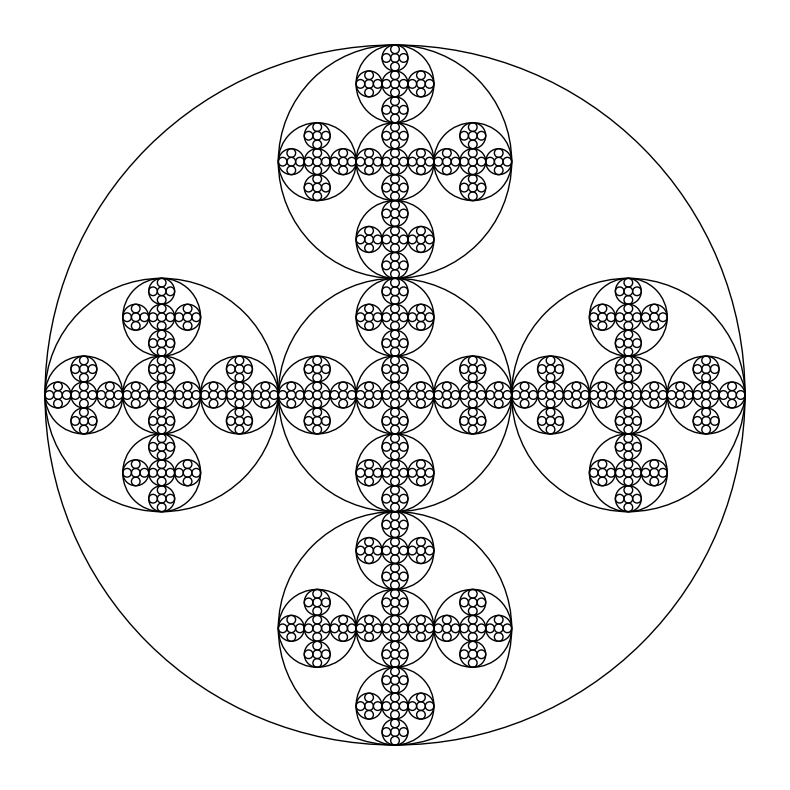

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import * # Circle
%matplotlib inline

plt.figure(figsize=(10, 10))
ax = plt.gca() ## 現在の座標軸

rlim = 0.03 # 半径がこれ以下になったら円を描いて終わる

def mandara(x, y, r):
    # 外側の円を作成
    c = Circle((x, y), r, fill=False)
    # 画面に円を加える
    ax.add_patch(c)

    # *** 実装しなさい ***
    # * もし半径 r が限度 (rlim) 以下なら
    # * ここで描画をやめる (return する)
    if r <= rlim:
        return

    # * もし半径 r が rlim より大きければ
    # * 自分と相似で大きさが 1/3 の図形を5つ描く
    else:
        mandara(x, y, r/3)
        mandara(x + 2*r/3, y, r/3)
        mandara(x - 2*r/3, y, r/3)
        mandara(x, y + 2*r/3, r/3)
        mandara(x, y - 2*r/3, r/3)

# 中心(0, 0), 半径1として呼び出し
mandara(0, 0, 1)

plt.axis('scaled') # 図形が収まる広さに調整
ax.set_aspect('equal') # 縦横 1:1 で表示
plt.axis("off") # 軸の目盛りは不要
plt.show();

### 練習12.3：コッホ雪片
ステップ $k$ のコッホ曲線とは，以下の様に再帰的に定義される曲線（折れ線）である．

* ステップ 0 のコッホ曲線とは，線分である
* ステップ $k+1$ のコッホ曲線とは，ステップ $k$ のコッホ曲線の各辺を3等分し，3等分した真ん中の部分を底辺とする正三角形を作り，底辺を消したものである．ただし正三角形は全て曲線の同じ側に作る．

以下の図は，左から順にステップ 0，ステップ 1, ステップ 2 の，$(0, 0)$ と $(1, 0)$ を端点とするコッホ曲線である：

![koch](data:image/png,%89PNG%0D%0A%1A%0A%00%00%00%0DIHDR%00%00%04%2B%00%00%00%9D%08%06%00%00%00%9D%17%F2%2A%00%00%00%04sBIT%08%08%08%08%7C%08d%88%00%00%00%01sRGB%00%AE%CE%1C%E9%00%00%00%04gAMA%00%00%B1%8F%0B%FCa%05%00%00%00%09pHYs%00%00%0B%12%00%00%0B%12%01%D2%DD~%FC%00%00%009tEXtSoftware%00matplotlib%20version%203.0.2%2C%20http%3A//matplotlib.org/8%80%3B%AD%00%00%00%21tEXtCreation%20Time%002019%3A12%3A01%2021%3A31%3A02%0C/0%8C%00%00%21oIDATx%5E%ED%DD%07%98T%D5%F9%C7%F1%DF%8A%28%8A%82%05%04T%EC1%82%1AP%96%26mEL%2C%20%2A%28b%8B%0D%10%7B%04%A34%B1A%8C%10%1B%9A%08v%13%14%10%15%C5%02%21%02%16%12E%EC%05%CB%FFQ%20%1B%29%2B%82%88%A8%80%CE%7F%DEs%CF%22mwfw%EE%EC%9Ce%BF%9F%E7%19%B9%F7%DC%D9%F5%EC%9D%BB%EF%DC%7D%E7%9C%F7%E4%25%92%04%00%00%00%00%00%10%88%AD%FC%BF%00%00%00%00%00%00A%20Y%01%00%00%00%00%00%82B%B2%02%00%00%00%00%00%04%85d%05%00%00%00%00%00%08%0A%C9%0A%00%00%00%00%00%10%14%92%15%00%00%00%00%00%20%28%24%2B%00%00%00%00%00%40PHV%00%00%00%00%00%80%A0%90%AC%00%00%00%00%00%00A%21Y%01%00%00%00%00%00%82B%B2%02%00%00%00%00%00%04%85d%05%00%00%00%00%00%08J%5E%22%C9o%07%A9N%9D%3A%DAg%9F%7D%FC%1E%00%84a%DE%BCy%FA%EA%AB%AF%FC%DE%96%8D8%0C%20T%C4b%00%C8%ADl%C6%E1%E0%93%15%F9%F9%F9%9A3g%8E%DF%03%800T%A5%D8D%1C%06%10%2Ab1%00%E4V6c%13%D3%40%00%00%00%00%00%40PHV%00%00%00%00%00%80%A0%90%AC%00%00%00%00%00%00A%21Y%01%00%00%00%00%00%82B%B2%02%00%00%00%00%00%04%85d%05%00%00%00%00%00%08%0A%C9%0A%00%00%00%00%00%10%14%92%15%00%00%00%00%00%20%28%24%2B%00%00%00%00%00%40PbMVL%980A-Z%B4P%B3f%CD%D4%AF_%3F%DF%BA%A9%F3%CF%3F_%E7%9Cs%8E%DF%03%00%C4%89X%0C%00%B9E%1C%06%80%CC%C5%96%AC%98%3F%7F%BE%86%0C%19%A2i%D3%A6i%CE%9C9%2A%2C%2C%D4%13O%3C%E1%8F%FE%E2%E9%A7%9F%D6%EA%D5%AB%FD%1E%00%20N%C4b%00%C8-%E20%00%C4%23%B6d%C5%94%29S%D4%AD%5B7%D5%AE%5D%5Byyy%EA%D3%A7%8F%26M%9A%E4%8FF%16/%5E%AC%11%23Fh%D0%A0A%BE%05%00%10%27b1%00%E4%16q%18%00%E2%11%5B%B2b%E9%D2%A5%AA_%BF%BE%DF%93%1A4h%A0%25K%96%F8%BD%C8%85%17%5E%A8%91%23G%AAF%8D%1A%BEe%F3%C6%8C%19%A3%FC%FC%7C%F7%28%2A%2A%F2%AD%00%80T%E2%8A%C5%C4a%00%28%1F%EE%89%01%20%1E%B1%25%2B%EA%D5%AB%B7A%20%5E%B4h%91k%2B6z%F4h5j%D4H%ADZ%B5%F2-%25%EB%DD%BB%B7%1B6g%8F%BAu%EB%FAV%00%40%2Aq%C5b%E20%00%94%0F%F7%C4%00%10%8F%D8%92%15%C7%1Dw%9C%9Ez%EA%29%7D%FB%ED%B7n%FF%81%07%1EP%D7%AE%5D%DD%B6%99%3Au%AA%DE%7D%F7%5D%9Dx%E2%89.%F0N%9F%3E%5D%FD%FB%F7%F7G%01%00q%20%16%03%40n%11%87%01%20%1E%B1%25%2Bl%88%DB%C0%81%03%D5%BE%7D%7B%B5l%D9%D2e%90m%BE%5EAA%81%CB%28%3F%F9%E4%93z%EE%B9%E7%DC%9C%3D%1B%D2%D6%B1cG7%FC%0D%00%10%1Fb1%00%E4%16q%18%00%E2%91%97H%F2%DBA%B29z6%F4%0D%00BR%95b%13q%18%40%A8%88%C5%00%90%5B%D9%8CM%B1%8D%AC%00%00%00%00%00%00%88%03%C9%0A%00%00%00%00%00%10%14%92%15%00%00%00%00%00%20%28%24%2B%00%00%00%00%00%40PHV%00%00%00%00%00%80%A0%90%AC%00%00%00%00%00%00A%21Y%01%00%00%00%00%00%82B%B2%02%00%00%00%00%00%04%85d%05%00%00%00%00%00%08%0A%C9%0A%00%00%00%00%00%10%14%92%15%00%00%A0%C2%24%12~%03%00%90%13%C4aT%16%24%2B%00%00%40%85%181Bj%DE%5CZ%B5%CA7%00%00%2A%D4%E2%C5R%E3%C6%D2%23%8F%F8%06%20%60%24%2B%00%00%40%D6%7D%FE%B94x%B0%F4%E6%9BQ%D2%02%00P%F1%06%0D%92%3E%FEX%FA%C3%1F%A4%AF%BF%F6%8D%40%A0HV%00%00%80%AC%EB%DF_%AA%5E%5D%FA%EDo%A5%3F%FFYZ%B0%C0%1F%00%00T%08K%16%3F%F0%80%D4%B5%AB%B4%7C%B9t%DDu%FE%00%10%28%92%15%00%00%20%AB%5E%7CQz%EA%A9%E8%13%BD%7B%EF%8D%E6K_%7D%B5%3F%08%00%C8%3A%8B%BB%97_.%D5%A9%23%3D%FC%B0t%E1%85%D2_%FF%2A%7D%F8%A1%7F%02%10%20%92%15%00%00%20k%D6%AE%95%AE%B8B%DAw%DFh%D8%F1%5E%7BE%89%8Aq%E3%A4W%5E%F1O%02%00d%D5%F8%F1%D2%ACY%D2%F0%E1R%ED%DA%D2%0D7H%B5jEq%99%82%9B%08%15%C9%0A%00%00%905c%C6H%1F%7C%20%8D%1C%29%D5%A8%11%B5%FD%F1%8F%D2%9E%7BF%9F%F2%FD%F4S%D4%06%00%C8%0E%2Bj%7C%D5U%D2a%87I%E7%9E%1B%B5%ED%BAk4%0Dd%DA4i%F2%E4%A8%0D%08%0D%C9%0A%00%00%90%15V%BCm%C8%10%E9%C8%23%A5%93N%F2%8DI%DBo/%DDr%8B%F4%F6%DB%D2C%0F%F9F%00%40VXQ%E3%C2B%E9%8E%3B%A4j%D5%7CcR%DF%BER%A3FR%BF~%D2%8F%3F%FAF%20%20%24%2B%00%00%40V%5C%7F%7DT%C4%ED%F6%DB%A5%BC%3C%DF%E8%9Dv%9A%D4%A6%8D4p%A0%B4b%85o%04%00%C4%CA%8A%19%5BQ%E3SO%95%DA%B5%F3%8D%9E%15%3D%BE%ED6%E9%FF%FEO%BA%F3N%DF%08%04%84d%05%00%00%88%DDG%1FIw%DF-%F5%E9%23%FD%E67%BEq%3D%96%BC%B0O%F9%8A%8A%A4%9Bn%F2%8D%00%80XY%8D%20%ABIa%A3%D96%E7w%BF%93%BAt%91n%BCQZ%B4%C87%02%81%20Y%01%00%00be7%C6VTs%C7%1D%A3%22n%25i%D6%2C%9A%3Fm%23/%3E%FB%CC7%02%00baE%8C%AD%98%B1%D5%09%DA%7Bo%DF%B8%19%7F%F9%8B%F4%C3%0F%D1%8AM%40HbMVL%980A-Z%B4H%DE%7C4S%3F%9B%FC%B4%91Q%A3F%A9U%ABVj%DD%BA%B5.%BA%E8%22%FD%FC%F3%CF%FE%08%00%20.%C4b%E4%DA%B3%CFFE%DB%ACx%9B-%93W%9Aa%C3%A2%C2%9B%9B%B9T%81J%8B8%8C%5C%B3K%CA%92%C6V%CC%D8%92%15%A5%F9%D5%AF%A2%82%C7%0F%3E%28%BD%F9%A6o%04%02%10%5B%B2b%FE%FC%F9%1A2dH%F2%E6d%9A%E6%CC%99%A3%C2%C2B%3D%F1%C4%13%FE%A8%AD%E1%FB%A1%26O%9E%ACY%B3f%E9%3F%FF%F9%8F%8A%8A%8A%9273%C9%BB%19%00%40l%88%C5%C85%2B%D2v%E5%95%D2A%07%29%F9G%98o%2CE%FD%FA%D2%E0%C1Q5%FA%7F%FE%D37%02%95%18q%18%21%B0%E2%C5o%BD%15M%FF%A8Y%D37%96%C2%E2p%DD%BAQ%D2%82%A5L%11%8A%D8%92%15S%A6LQ%B7n%DDT%BBvm%E5%E5%E5%A9O%9F%3E%9A4i%92%3F%2A%1D%7C%F0%C1z%E6%99gT%CD%97%A0%5D%BBv%AD%B6%DBn%3B%B7%0D%00%88%07%B1%18%B96jTT%AC%CD%A6vX%F1%B6t%D8%CD%F1%FE%FBG%EB%FD%AFY%E3%1B%81J%8A8%8C%5C%B3%A2%C5%03%06DE%8C%AD%98q%3A%92%97%AB%86%0F%97f%CD%92%C6%8F%F7%8D%40%8E%C5%96%ACX%BAt%A9%EA%DB%C7%23%5E%83%06%0D%B4d%C9%12%BF%17%A9Q%A3%86%96/_%AE%D3O%3F%5DM%9B6%D5%D1G%1F%ED%8F%00%00%E2%40%2CF.-%5E%1C%D5%A8%E8%DC9%2A%DA%96%AEm%B7%95n%BD5%2A%CAy%CF%3D%BE%11%A8%A4%88%C3%C85%2BZl%C5%8B%AD%88%F1%C6%2B1%95%E6%9Cs%A4%C3%0F%97%AE%BAJZ%B5%CA7%029%14%5B%B2%A2%5E%BDz%1B%04%E2E%8B%16%B9%B6%F5%7D%F0%C1%07%EA%D1%A3%87.%BF%FCr%0D%1D%3A%D4%B7nj%CC%981%CA%CF%CFw%0F%1B%1A%07%00HO%5C%B1%988%8C%F2%B0%E2lV%A4%CD%8A%B5%95%95U%A3%B7%BF%D7%AE%BDV%FA%EA%2B%DF%08TB%DC%13%23%13%13%26H%CD%9Bg%F6%B0%91m%96x%B0%22%C6ea%83%7D%ECk%0B%0B%A5%A6M7%FF%BD%D3%7D%9Cy%A6%FF%A6%40%06%F2%12I~%3B%23%0B%17.T%A7N%9D%F4%DAk%AFi%C7%1Dw%D4Yg%9D%A5%13O%3C%D1%0D%833%16%60%7B%F6%EC%E9%E6%EC%D9%B0%B8tYp%B6%F9~%00%10%92PcS6b1q%18%E9%B0%A2lv%83j%B5%04G%8C%F0%8De%F4%E1%87R%93%26%D1r%A7%B6%EC%29%90J%88%F1%89%7Bbd%C2%92%BD%FD%FBK%BF%FEu4%3D%AE%3Cv%DDU%1A9R%DAm7%DFPF%B7%DD%26%FD%EB_~%A7%8CV%AF%8E%BE%B6q%E3%28%A6c%CB%97%CD%D8%14%5B%B2%C2%8C%1D%3B6%F9%8B1R%DBl%B3%8D%DA%B5k%E7%B6%0B%0A%0A4n%DC8M%9C81y%E1%DF%A6%86%0D%1B%FAg%CB%0D%7D%EB%DD%BB%B7%DF%DB%3C%023%80%10%85%1C%9B%E2%8E%C5%C4a%A4bw%12%C9KM%9F~%1A-AZ%86%BF%BF6q%E9%A5%D2_%FF%2A%BD%F3%8Et%E8%A1%BE%11%28A%A8%F1%89%7Bb%94%D7%F7%DFG%7F%E8%DB%D2%CFV%20s%EB%AD%FD%81J%A28%D9%F2%FC%F3%D2%B1%C7%FAFl%D1%B2%19%9BbMVd%03%81%19%40%88%AARl%22%0E%23%15%5B%C7%BFgO%E9%DE%7B%A5%0B.%F0%8D%E5%F4%F5%D7%D12z6%04%D9%3E%9D%2B%CB%7CkT%3D%C4bl%89l%F1%98%EE%DD%A3%C4m%DF%BE%BE%B1%12%B0%D9O%16%BF%DB%B6%95%9E%7B%CE7b%8B%97%CD%D8%14%5B%CD%0A%00%00P%F5X%116%5B%C3%FF%B0%C3%A4s%CF%F5%8D%19%D8e%97%A8H%E7%F4%E9%D2%D3O%FBF%00%A8BN%3EY%2A%28%90%86%0C%91%96-%F3%8D%95%80-%7Fj%EF%09V0%19%88%03%C9%0A%00%00PnV%9F%E2%BF%FF%8D%AA%CE%FB%95%183f5%2B%0E%3E8%AA%7Fa%05%3B%01%A0%2A%B1%11eV%E8%D2%12%15%D7_%EF%1B%03%F7%F6%DB%D2%7D%F7ES%F9%AC%DE%06%10%07%92%15%00%00%A0%5C%16%2C%90%FE%FCg%A9G%8F%A8fE%5Cl%8E%B6%25%3F%3E%FF%3C%BAa%07%80%AA%C6%8A%0D%F7%EA%25%DDuW%B4%ACs%C8%AC%A8%C0%E5%97G%85%3DmE%27%20.%24%2B%00%00%40%B9%5C%7Dut%93z%CB-%BE%21FG%1D%25u%ED%2A%DDt%93%F4%E5%97%BE%11%00%AA%90%1Bo%94v%D8A%FA%C3%1F%A2X%1B%AA%C7%1F%97%5EyE%1A6L%DAi%27%DF%08%C4%80d%05%00%00%28%B3W_%8D%0AkZ%BD%8A%BD%F6%F2%8D1%1B9RZ%B3F%1A8%D07%00%40%15R%B7%AEt%DDu%D2%3F%FF%19n%C1J%5B%BD%E4%AA%AB%A2%91%20%E7%9F%EF%1B%81%98%90%AC%00%00%00e%F2%F3%CF%D1%90%DF%3D%F7%8C%92%15%D9r%C0%01%D1%27%8A%0F%3F%2C%BD%F1%86o%04%80%2A%E4%E2%8B%A5%83%0E%92%AE%BCRZ%BD%DA7%06%C4%92%CA6%250%CE%BAE%401%92%15%00%00%A0L%1EzHz%EB%ADh%FAG%CD%9A%BE1K%06%0D%92%EA%D7%97.%BB%2C%ECa%D0%00%90%0D%D5%ABK%B7%DD%26%7D%F6%994j%94o%0C%84%15W%FE%D3%9F%A2eV%3Bt%F0%8D%40%8CHV%00%00%80%B4%ADX%21%0D%18%20%B5i%23%9Dv%9Ao%CC%A2%1Dw%8Cn%86_%7BMz%F4Q%DF%08%00U%C81%C7H%C7%1F%1F-%EB%BCx%B1o%0C%C05%D7D%23%EDlU%28%20%1BHV%00%00%80%B4Y%C1%CB%25K%A2U%3Aly%BD%8Ap%F6%D9R~~4%E5d%E5J%DF%08%00U%C8_%FE%22%ADZ%25%0D%1E%EC%1Br%EC%DF%FF%8E%12%C8V%AFb%9F%7D%7C%23%103%92%15%00%00%20-6%0C%D9%92%14%E7%9E%1B%25%0F%2A%CAV%C9%BB%15%9B%0Fm%AB%82%D8R%A9%00P%D5%FC%FA%D7%D1t%B8%FB%EF%8F%A6%E1%E5Rq%DD%A2%DDw%8FV%85%02%B2%85d%05%00%00HK%BF~%D2%B6%DBJ%C3%87%FB%86%0At%C4%11%D2%E9%A7G%C3%8D%E7%CD%F3%8D%00P%81%96/%8F%12%B66%C2%21%17%86%0C%91%EA%D4%89%8Am%E6%D2%D8%B1%D2%9C9Q%F2%D8%96V%CD%85%A7%9F%8EFw%60%CBF%B2%02%00%00%A4dK%E7M%9E%1C%DD%2C%5B%C1%CB%5C%B0%1Bc%AB6%9F%CD%15H%00%A0%24%16%7Bl%85%A2%5C%24lM%ED%DA%D1%94%8B%5C%27l%8B%FF%FF%87%1E%1A%FD%5B%D1%3E%F9%24%2A%EAy%C2%09%D2%B2e%BE%11%5B%24%92%15%00%00%A0Tk%D6D7%E8%FB%EF%1F%0D%FD%CD%15%5B%2A%D5%0A%BA%3D%FE%B8%F4%D2K%BE%11%00%2A%C0%3B%EFH%F7%DD%27%D5%AA%15-%D7%99%8B%84%C1c%8FE%CB8_%7B%ADo%C8%11%5BNu%97%5D%A2%F7%85%5C%AC%D2T%3C%CA%CF%12%15Vt%14%5B.%92%15%00%00%A0T%F7%DC%23%7D%F4%91t%EB%AD%D1%0Db.%F5%EF/%ED%B5W%944%F9%E9%27%DF%08%00Yd%7F%90%5B%CC%D9uWi%D6%ACh%84%97%15%96%ACH%DF%7D%17%8D%ECh%D6L%3A%E7%1C%DF%98%23%96%A8%B0%24%C1%8C%19%D2%A4I%BE%B1%82%BC%F0%82%F4%DCs%D2%F5%D7K%BDzIw%DD%25%CD%9D%EB%0Fb%8BC%B2%02%00%00%94%E8%AB%AF%A2O%F1%3Au%92%BAt%F1%8D9%B4%DDvQ%DD%8Aw%DF%8D%0A%CD%01%40%B6M%9C%28%BD%FC%B24l%98t%C8%21%D1%08/k%9B9%D3%3F%A1%02%D84%B8%FF%FD/%2A6lE%87s%ADO%1F%E9%E0%83%A3Q%0E%3F%FC%E0%1B%B3%ACx%94%DF%AF~%25%5Dz%A9t%E3%8DR%CD%9A%B9%1B%E1%81%EC%23Y%01%00%00J4t%A8%F4%ED%B7%D2m%B7U%DCR%A5%A9%9Cr%8A%D4%AE%9D4hPT%F0%0E%00%B2%E5%FB%EF%A3%11%5DM%9AH%E7%9F%1F%B5U%F4%08%AF%F9%F3%A3%24m%CF%9ER%9B6%BE1%C7%B6%DE%3AJ%9C%7C%F1ETt%B4%22%DC%7DwT%AF%C2F%F9m%B3%8DT%B7n%F4%1E5u%AA%F4%FC%F3%FEI%D8%A2%90%AC%00%00%00%9B%F5%FE%FB%D1%14%90%BE%7D%A3O%13CaI%13%BBI%5E%BA4%FAd%0D%00%B2%C5%EAS%2CX%10%FDAn%D3%3FL%F1%08%AF%F7%DE%8B%EAXd%9BM%FF%B0%B8%17%DA%D2%CDG%1D%25%9Dx%A2t%D3M%D1%D2%D2%D9TT%24%5Dw%9D%F4%BB%DFI%C7%1F%EF%1B%93%AC~%86-%EBj%A3%2BV%AF%F6%8D%D8b%90%AC%00%00%00%9B%B0%21%B5W%5C%21%ED%B4S4784%87%1D%26%5Dp%81t%E7%9D%D1%27m%00%10%B7%C2B%E9%E6%9B%A3%95%27%0A%0A%7C%A3W%3C%C2k%F0%E0%EC%8E%F0%B2%E9%27%13%26DSO%1A6%F4%8D%01%B1d%8EM%CF%188%D07d%89%ADD%B5r%E5%A6%A3%FCl%84%85%B5%7D%F6YT%BF%02%5B%16%92%15%00%00%60%13%B6%86%FD%F4%E9Q%115%2B%A6%16%22%FB4o%FB%ED%A5%2B%AF%F4%0D%00%10%23K%10%D84%0F%1BE%B1%B1%F5GxekE%0A%FB%7F%DBT%13KR%D8%D4%93%10%D9%2AQ6%AA%E1%E1%87%A5%D9%B3%7Dc%CCl%25%961c%A4K.%91%1A5%F2%8D%EB9%F6X%E9%B8%E3%A2%C4%FA%92%25%BE%11%5B%04%92%15%00%00%60%03V%2C%CD%8A%A6Y%F14%2B%A2%16%AA%DDv%8B%8A%7F%DA%5Ce%E6%2B%03%88%D3%BF%FF-%8D%1D%1B%AD%FA%B1%CF%3E%BEq%23%C5%23%BCF%8D%92%3E%FE%D87%C6%E8%81%07%A2%3F%D4-Yb%89%D9PY%FD%A0%FA%F5%A5%CB.%93~%FE%D97%C6%A4x%94%9F%25%CD%AD%3EEI%AC%8E%C5%AAU%D1H%17l9HV%00%00%80%0D%D8%DC%EC%CF%3F%8F%FE%B5%22j%21%B3%8A%F0V%19%DEFW0_%19%40%1C%EC%0Fn%1B%D1%B0%FB%EE%D2%D5W%FB%C6%12dk%84%D77%DFDI%80%B6m%A5SO%F5%8D%81%DAqG%E9O%7F%92%5E%7F%5Dz%F4Q%DF%18%93%27%9F%94%5Ez%29%AAO%B4%F3%CE%BEq3%ACn%85%BD%1FX%0D%91%B7%DF%F6%8D%A8%F4HV%00%00%80u%16.%8Cn%BE%BBv%8D%96%2B%0D%5D%F1%7Ce%AB%5Ba%95%E2%01%20S%8F%3C%22%CD%99%13%15%B4%DCa%07%DFX%02%1B%E1e%9F%F8%BF%F0B%BC%23%BC%EC%8Fs%5B%3A%DA%A6%9A%84%B2%12Si%CE%3E%5B%CA%CF%8F%92%3BV%5B%22%0E%C5%2B%B1%1Cz%A8%D4%AB%97o%2C%85%8D%B4%DBu%D7%28%D1%C4R%A6%5B%86X%93%15%13%26LP%8B%16-%D4%ACY3%F5%B3%F1%A3%1B%B9%F3%CE%3B%D5%BCys5m%DAT%23%AD%1A%0B%00%20v%C4bd%C2%8A%A4Y%B1%B4%CAti%D8%5C%E5c%8E%89%E6%2B%5B%C5x%20%D7%88%C3%95%97-%D5%3C%60%80%D4%AA%95t%FA%E9%BE1%05%AB%A5p%E0%81%F1%8D%F0%B2%E4%AB%25%29l%A9%D4%C3%0F%F7%8D%81%DB%2A%F9W%A5%15%3C%B6UA%E2Z%B5%C4%A6v%CC%9B%97%FE%28%3F%2B%08%3Dl%98%F4%CA%2B%D2%C4%89%BE%11%95Zl%C9%8A%F9%F3%E7k%C8%90%21%9A6m%9A%E6%CC%99%A3%C2%C2B%3D%F1%C4%13%FE%A84k%D6%2C%3D%F6%D8c%EE%DF%D9%B3gk%D2%A4I%EEy%00%80%F8%10%8B%91%897%DE%90%1Ez%28%2A%96v%C0%01%BE%B1%12%B0O%1D%ED%A6%F6%BB%EF%A2%8A%F1%40.%11%87%2B%B7%E1%C3%A5E%8B%A2d%81%FD%01%9E%8E%B8GxY~%CB%A6%96%D8%28%B7%CA%A4uk%E9%8C3%A2%1A%1B%96d%C8%C4%FF%FE%17%BD%16%27%9F%2Cu%EC%E8%1B%D3%60%09%9E%26M%A2%11%1962%03%95%5B%5E%22%C9ogd%F4%E8%D1.8%0F%B7%AB%2Ai%FA%F4%E9z%F0%C1%07%F5%F7%BF%FF%DD%ED%0F%180%40%FB%EE%BB%AFz%F7%EE%ED%F6%1Fx%E0%01%7D%F1%C5%17%BA1%C5%02%E9%F9%F9%F9%04%F0%14%AC%E8%8C%15%DF%01%E2%D2%B4i%94%C5F%C9B%8DM%D9%88%C5%C4%E1%D4%3E%FDTz%ED5%BFS%89Y%91%B8%FF%FE7Z%02%CE%E6%20W6%F6~h%9F%EC%D9%A3V-%DFXIY1%B9%CE%9D%FD%0EJ%14b%7C%E2%9E8wl%89O%2B%10%5C%5E%F6%B5V%F7%A0g%CF%28q%5BV%B6%2A%85%15%E6%B4%7B%A8j%D5%7Cc%19Y%0C%B6%22%91%F6%07%7F%A8%2B%80%94%C6%96%7B%B5%FA%11m%DAHg%9E%E9%1B%CB%C1%5E%CB%7F%FDK%FA%E8%23i%BF%FD%7Cc%9A%AC%C6%85-5%7B%DEyR%87%0E%BE%B1%9C%2CQ%B2%E7%9E~%07%9B%95%CD%D8%14%5B%B2%C2%02%F2%0E%3B%EC%A0%CB%AC%0Cl%D2%DC%B9s%937%0DWh%EA%D4%A9n%DF%02r%E7%E4%BB%EE%09%27%9C%E0%F6_x%E1%05%97I%B6%80%BE%B11c%C6%B8%87%29%2A%2Ar%01%1F%25%23Y%81%B8%91%ACH-%D4%9B%C6%B8b1q%B8l%EC%F4%5Dx%A1%DF%A9%C4l%84%82%FD%3De%9F%8CUF%CB%96I%BF%F9Mt%B3%5C%D9%D9%2A%03o%BD%E5wP%A2%10c1%F7%C4%B9S%AF%5E%E6KW%D6%A9%23%BD%FBnT%5C%B3%AClE%90%E6%CD3%AF%D9%605%1A%EC%B2%B6%11%1B%95%91%25Z%FE%F8G%BF%93%01%9B%DAgu%28%CA%C3jh%F8%FC%60F%26O%26q%9CJ%A5HV%DC%7F%FF%FD.%2B%7C%93%1F%AF4c%C6%0C%97E~%C4%2A%D4%24%D9p%B8%BD%F7%DE%5B%17%D8%FA%3EIv%CC%9E%7FC%8A%85%89%C9%22%03%08Q%A8%B1%29%1B%B1%988%9C%DA%8A%15Q%21%B4%CA%CE%86%1D%DB%F2s%95%99M%05Y%BC%D8%EFTb%F6G%0A%9F%E6%A5%16b%7C%E2%9E8w%2C%97%F3%D3O~%A7%9C%EA%D6%CDld%D9%F2%E5%D2%D7_%FB%9Dr%DAc%0Fi%DBm%FDN%25eI%E3L%EAwT%AF.5l%E8w%CA%C1%FE%C2%B5%A9%28%99%FE%A5k%09%B0%9A5%FD%0E6%2B%AB%B1%C9%92%15q%F8%F2%CB/%13%8D%1B7N%ACX%B1%C2%ED%9Fy%E6%99%89%89%13%27%BAm%F3%C6%1Bo%24%DA%B5k%97X%BDzub%ED%DA%B5%89%0E%1D%3A%B8%B6T%9A5k%E6%B7%00%20%1C%A1%C6%A6l%C4b%E20%80P%85%18%9F%B8%27%06P%95d36%C5V%60%B3A%83%06%1A8p%A0%DA%B7o%AF%96-%5B%AA%5E%BDz%EA%D6%AD%9B%0A%0A%0A%B4h%D1%22%97q%B1%E1nv%ACU%ABV%EA%D2%A5%8Bk%03%00%C4%87X%0C%00%B9E%1C%06%80x%C46%0D%24%5B%2Cx3%E4%0D%40h%AARl%22%0E%03%08%15%B1%18%00r%2B%9B%B1%29%B6%91%15%00%00%00%00%00%00q%20Y%01%00%00%00%00%00%82B%B2%02%00%00%00%00%00%04%85d%05%00%00%00%00%00%08%0A%C9%0A%00%00%00%00%00%10%14%92%15%00%00%00%00%00%20%28%24%2B%00%00%00%00%00%40PHV%00%00%00%00%00%80%A0%90%AC%00%00%00%00%00%00A%21Y%01%00%00%00%00%00%82B%B2%02%00%00%00%00%00%04%85d%05%00%00%00%00%00%08%0A%C9%0A%00%00%00%00%00%10%14%92%15%00%00%00%00%00%20%28%24%2B%00%00%00%00%00%40PHV%00%00%00%00%00%80%A0%90%AC%00%00%00%00%00%00A%21Y%01%00%00%00%00%00%82B%B2%02%00%00%00%00%00%04%85d%05%00%00%00%00%00%08%0A%C9%0A%00%00%00%00%00%10%94%D8%92%15%89DB%03%06%0CP%CB%96-%D5%B4iS%8D%1D%3B%D6%1F%F9%C5%9A5k%D4%ABW/%B5m%DBV%F9%F9%F9%BA%EF%BE%FB%FC%11%00%40%A6%88%C3%00%90%7B%C4b%00%88Gl%C9%8AG%1F%7DT%9F%7D%F6%99%5E%7B%ED5%BD%FC%F2%CB%1A6l%98%16.%5C%E8%8FF%C6%8C%19%A3%86%0D%1B%EA%D5W_u%CF%19%3E%7C%B8%96-%5B%E6%8F%02%002A%1C%06%80%DC%23%16%03%40%3CbKV%3C%FB%EC%B3%EA%DD%BB%B7%F2%F2%F2T%ABV-u%EF%DE%5D%CF%3F%FF%BC%3F%1A%E9%DB%B7%AF%CB4%1B%CB%3Ao%BD%F5%D6%AAV%AD%9A%DB%07%00d%868%0C%00%B9G%2C%06%80x%949Y1%7D%FAt%15%14%14l%F2X%BAt%A9%EA%D7%AF%EF%9F%255h%D0%40K%96%2C%F1%7B%91%AD%B6%DAJ%D5%ABW%D7%DC%B9s%D5%B9sg%DDz%EB%AD.%88%03%00%D2G%1C%06%80%DC%23%16%03%40v%959Y%D1%B1cG%CD%9C9s%93G%BDz%F56%08%C4%8B%16-rm%1B%1B%3F~%BC%86%0E%1D%EA%E6%EFYp%DE%1C%1B%1Ag%F3%F7%ECQTT%E4%5B%01%00%868%0C%00%B9G%2C%06%80%EC%8Am%1AH%D7%AE%5Du%FF%FD%F7%BB%EDU%ABV%E9%C9%27%9F%D4%B1%C7%1E%EB%F6%8BY%00%9F2e%8A%0B%CE%BB%EF%BE%BBo%DD%94%0D%9D%9B3g%8E%7B%D4%AD%5B%D7%B7%02%00JC%1C%06%80%DC%23%16%03%40%3CbKVt%EB%D6%CD%05%5B%CB%FCv%E8%D0A%D7%5Cs%8D%1B%F6%F6%CE%3B%EF%E8%B4%D3Ns%CF%B9%EB%AE%BB%F4%DE%7B%EF%E9%C8%23%8F%5C7Tn%F6%EC%D9%EE%18%00%203%C4a%00%C8%3Db1%00%C4%23/aU%7D%02f%81%DE%B2%C9%00%10%92%AA%14%9B%88%C3%00BE%2C%06%80%DC%CAfl%8Amd%05%00%00%00%00%00%40%1CHV%00%00%00%00%00%80%A0%90%AC%00%00%00%00%00%00A%09%BEf%C5%0E%3B%EC%A0%83%0E%3A%C8%EF%85%C1%96%8E%0A%AD%223%7DJ%0F%7DJOh%7D%0A%F1%1C%7D%FC%F1%C7Z%B9r%A5%DF%DB%B2%11%87%D3C%9F%D2C%9F%D2C%9F%D2C%2C%CE-%AE%D3%F4%D0%A7%F4%D0%A7%D4B%3CGY%8D%C3%96%AC%08Y%B3f%CD%FCV8%E8Sz%E8Sz%E8Sj%9C%A3%DC%E2%FC%A7%87%3E%A5%87%3E%A5%87%3E%A5%27%C4%3Ee%0B%E7%3F%3D%F4%29%3D%F4%29%3D%A1%F5%A9%AA%9D%23%A6%81%00%00%00%00%00%80%A0%90%AC%00%00%00%00%00%00A%A9v%5D%92%DF%0EV%B3f%CD%FCV8%E8Sz%E8Sz%E8Sj%9C%A3%DC%E2%FC%A7%87%3E%A5%87%3E%A5%87%3E%A5%27%C4%3Ee%0B%E7%3F%3D%F4%29%3D%F4%29%3D%A1%F5%A9%2A%9D%A3%E0%0Bl%02%00%00%00%00%80%AA%85i%20%00%00%00%00%00%20%28A%24%2Blp%C7%80%01%03%D4%B2eK5m%DATc%C7%8E%F5G~%B1v%EDZ%D5%A9SG%05%05%05%EB%1E%ABW%AFv%C7%26L%98%A0%16-Z%B8%E1%27%FD%FA%F5sm%99H%A7%3Fk%D6%ACQ%AF%5E%BD%D4%B6m%5B%E5%E7%E7%EB%BE%FB%EE%F3G%B4A%1F%ED1%7B%F6l%7F%A4%7CR%FD%7Cw%DEy%A7%9A7o%EE%FA%3Ar%E4H%DF%2A%CD%981C%AD%5B%B7v_%7B%D6Yg%AD%3B_qH%D5%A7Q%A3F%A9U%ABV%EE%FF%7F%D1E%17%E9%E7%9F%7Fv%EDC%87%0Eu%FD%2C%3E7c%C6%8Cq%ED%99J%D5%9F%F5_%0F%7B%14%BF%26%EF%BE%FB%AE%3At%E8%E0%FA%DA%A5K%17-%5B%B6%CC%B5%C7%A1%B4%3E%8D%1F%3F~%83%FE%EC%B1%C7%1E%BA%FD%F6%DB%DD%B1l%9D%233q%E2D%9Dz%EA%A9%DAk%AF%BD%7C%CB%86J%EAs6%CFS%3A%7D%B2%EB%A8%5D%BBv%EEy%ABV%ADr%ED%0F%3E%F8%A0%5B%C2%AD%F8%3C%DDp%C3%0D%AE%3D%0E%A9%FA%F4%FB%DF%FF%DE%9D%8B%E2%FF%F73%CF%3C%E3%DA%17%2CX%A0c%8E9FG%1Cq%84k%9F%3F%7F%BEk%AF%0CB%8B%C3%26%A4X%9C%EA%E7%23%0EGR%F5i%FD%D7%C3%1EU1%16%13%87%D3S%15%E3%B0%E1%9E%B8t%A9~%3Ebq%EA%FE%AC%FFz%D8%83%7Bbbqir%1E%8B%93A%28%E7%FE%F1%8F%7F%24%BAu%EB%96H%FE%F2%26%BE%F9%E6%9BD%A3F%8D%12_~%F9%A5%3F%1A%F9%FC%F3%CF%13%3D%7B%F6%F4%7B%BF%987o%5E%E2%C0%03%0FL%2C_%BE%DC%7D%7D%F2d%26%92%27%D5%1F-%9Ft%FAs%D7%5Dw%25%AE%BF%FEz%B7%FD%DDw%DF%25%F6%DDw%DF%C4%D7_%7F%ED%F6%93/%98%FB7%0E%A9~%BEW_%7D%D5%FD%FF~%FC%F1G%F7h%D3%A6M%E2%8D7%DEH%7C%FB%ED%B7%89%BD%F7%DE%3BQXX%E8%9Ew%D5UW%25%92A%DBmg%2AU%9F%3E%F8%E0%83%C4%D1G%1F%9DH%BE%99%BA%FD%EE%DD%BB%27%9E~%FAi%B7%7D%F6%D9g%27%3E%F9%E4%13%B7%1D%97t%AE%81%CD%BD%26%F6%DC%E4/v%E2%9Dw%DEq%FBw%DF%7Dw%E2%92K.q%DB%99%2A%CBu%B9r%E5%CAD2%18%BA%7FM6%CEQ%B1%993g%26%8A%8A%8A%12%F5%EA%D5%F3-%BF%28%A9%CF%D9%3CO%A6%B4%3E-%5D%BA%D4-%87%94%0C%C6n%BF%7F%FF%FE%89%3B%EE%B8%C3m_%7B%ED%B5%89%A9S%A7%BA%ED%B8%95%D6%27s%E4%91G%AE%EB%D3%FA%3Au%EA%94H%06i%B7%FD%DCs%CF%25%3Aw%EE%EC%B6%2B%83%D0%E2%B0%09%25%16%A7%FA%F9%88%C3%91t%AE%03b1q8%5DU1%0E%1B%EE%89K%96%EA%E7%23%16%A7w%0D%10%87%23%C4%E2%F4%E4%3A%16%071%B2%E2%D9g%9FU%EF%DE%BD%95%97%97%A7Z%B5j%29%F9%8B%AC%E7%9F%7F%DE%1F%8D%24/%1A-Y%B2D%C7%1E%7B%AC%CB%26%8D%1B7%CE%B5O%992E%C9%20%AA%DA%B5k%BB%AF%EF%D3%A7%8F%26M%9A%E4%8E%95W%3A%FD%E9%DB%B7%AF%CB4%9B%E4y%D4%D6%5Bo%ADj%D5%AA%B9lw2%98%BB%0CT%FB%F6%ED5d%C8%10%FD%F4%D3O%EEy%E5%91%EA%E7%B3%BE%9E%7B%EE%B9%DAf%9Bm%DC%E3%BC%F3%CES2%08j%D6%ACY.%93e%D9Is%E1%85%17f%7C%5E%8A%A5%EA%D3%C1%07%1F%EC%B2jv%3E%8C%9D%93%ED%B6%DB%CEm%5B%96%ED%D6%5Bou%19I%CBl%7F%F5%D5W%AE%3D%13%A9%FAS%D2k%F2%E9%A7%9Fj%E7%9DwV%93%26M%DC%F3.%B8%E0%02%25%7F%99%DCv%A6%CAr%5D%DEr%CB-.%D3%5E%B3fM%B7%9F%8DsT%CC%BE%A7%7D%1A%B39%25%F59%9B%E7%C9%94%D6%A7%5Dv%D9E%C9%9B%8Fu%D7%CF%FA%D7%92%C5%04%8B%03%96%AD%3D%E9%A4%93%F4%C5%17_%B8%F68%94%D6%27%93%7C%F3r1%C0%AE%A7%E4%9B%94%CBl%DB%E3%E3%8F%3FvYvs%DCq%C7%29y%93%12%EB%A77%D9%14Z%1C6%A1%C4%E2T%3F%1Fq8%92%AAO%C4%E2%08q8%3DU1%0E%9B%D0bq%28q%D8%A4%FA%F9%88%C5%A9%FBC%1C%FE%05%B18%3D%B9%8E%C5%15%9A%AC%98%3E%7D%BA%3B%89%1B%3F%96.%5D%AA%FA%F5%EB%FBgI%0D%1A4pAx%7D%DBo%BF%BD%7B%AE%05%22%7B%8C%181B%1F%7D%F4QZ_%5B%92L%FA%B3%D5V%5B%A9z%F5%EA%9A%3Bw%AE%3Aw%EE%EC~%91%2C%88%AF%5C%B9%D2%BD%A86Li%E6%CC%99Z%B8p%E1%06%C3%E1%CA%2AU_J%3A%9E%C9yI%25%9D%EF%5D%A3F%0Dw%F1%9E~%FA%E9n%F8%D6%D1G%1F%ED%DAmh%DE%C5%17_%AC%97%5EzI%9D%3Au%D2%A5%97%5E%EA%DA3%91%AA%3F%25%BD%26%1B%7F%9D%BD%B1%D9/~%1C%D2%3D%FF6t%CC%DE%C4%CE8%E3%0C%DF%92%9Ds%94%8E%92%FA%9C%CD%F3%94%0E%BB%96~%F8%E1%07%5D~%F9%E5%FA%FE%FB%EF%DD%CD%87i%DC%B8%B1%CE%3E%FBl%F7%9A%DA%B1%F5%CFa%B6%D90%D7%1Bo%BCQ/%BF%FC%B2%EA%D6%AD%EB%B6%EDz%B7%ED%F5%ED%B6%DBn%EE%FC%85%24%B48lB%8F%C5%A9%FAQ%D2%F1L%CFKi%D2%F9%DE%15%19%87M%AA%3E%11%8BS%2B%A9%BF%D9%3CG%E9%20%0E%C7%8F%7B%E2%B2K%D5%97%92%8Egr%5ERI%E7%7BsO%9C%DE%F9%E7%9E8%B5%AA%18%8B%2B4Y%D1%B1cGw%127~%D4%ABWo%83%8Bv%D1%A2E%AEm%7D6Wn%F0%E0%C1.3iY%AE%A3%8E%3AJo%BE%F9fZ_%5B%92L%FAcl%8E%95%CD%A5%B2%F9%7B%16%9C%CDN%3B%ED%A4%BF%FD%EDo%EE_%0B%DE%27%9F%7CrF%F3%F3R%F5%A5%A4%E3%A9%BE.%13%E9%7Co%CB%9E%F5%E8%D1%C3%FD%C2%D89%2Af%19%D3C%0F%3D%D4m%9Fr%CA%29%19%CF%5D4%A9%FAS%D2k%B2%F1%D7%FD%F8%E3%8F.%E8%C4%21%9DsdF%8F%1E%ED%DE%BC%ECS%88b%D98G%E9%28%A9%CF%D9%3CO%E9%28%2C%2CtYb%9B%F7v%CF%3D%F7%AC%FBt%E2%EA%AB%AFv7R%C6%FE%B5%AC%B2%7D%A2S%11%ECM%BEa%C3%86n%BB%F85%B2%AC%F3%C6A%B8%A8%A8%A8%D4lt.%84%16%87M%E8%B18U%3FJ%3A%9E%EA%EB2%91%CE%F7%AE%C88lR%F5%89X%9CZI%FD%CD%E69J%07q8~%DC%13%97%5D%AA%BE%94t%3C%D5%D7e%22%9D%EF%CD%3Dqz%E7%9F%7B%E2%D4%AAd%2CN%FE%209%F7%F8%E3%8F%27N%3B%ED4%B7ms%DD%0E9%E4%90M%E6%C3%D9%3C%B4%C7%1E%7B%CCm%FF%F0%C3%0F%89%E6%CD%9B%27%DE%7F%FF%7D%F7%BC%C6%8D%1B%27V%ACX%E1%8E%9Dy%E6%99%25%CE%83JW%3A%FD%991cF%E2%9Cs%CEqs%97%D6%B7p%E1%C2%C4%B0a%C3%D6%B5_z%E9%A5n._y%A5%FA%F9l.%5E%BBv%ED%12%ABW%AFv%F3%E1%3At%E8%E0%DA%BE%FF%FE%FB%C4%01%07%1C%B0%AE%DF%83%06%0D%8Am~%5E%AA%3E%25%7F%89%13%C97N7%CFk%7DvN%92o%AE%EB%DA%EDk%BAw%EF%EE%B63%91%AA%3F%A5%BD%26M%9A4q%D7%91%B9%F7%DE%7Bc%9Bw%96%AAO%C5%F6%DF%7F%7F%D7%BFb%D9%3AG%1BK%06%5B%BF%F5%8B%D2%FA%9C%AD%F3%B4%BE%CD%F5%C9%AEc%BB%96%16%2CX%E0%5B~q%F3%CD7%AFk%B7k%DE%E68%C6ms%7DZ%B5j%95%7B%8D%92oPn%DF~%AFl%DE%A09%FE%F8%E3%13/%BC%F0%82%DB%9E6mZ%A5%9A%2B%1DZ%1C6%A1%C4%E2T%3F%1Fq8%92%AAO%C4%E2%0D%11%87%D3S%95%E2%B0%E1%9E%B8d%A9~%3Eb1q%B8%3C%88%C5%E9%C9U%2C%0E%22Ya%17%E3%95W%5E%E9%8A%86%E4%E7%E7%BBb%3E%E6%ED%B7%DFN%F4%E8%D1%C3m/%5D%BA4q%CA%29%A7%B8%E3V%18%C6.%8Eb%F6%FC%A6M%9B%BA%17%A6_%BF~%BE%B5%FC%D2%E9O%B7n%DD%12%87%1F~%B8%0B%84%C5%8F%D7_%7F%DD%7D%ED%80%01%03%5C%7F%DA%B6m%EB.%60%0B%9A%99%D8%DC%CFg%FF%BF%E2_%E8%11%23F%24%0E%3B%EC0%D7%D7%F5%83%AF%5D%18%D6%C7%D6%AD%5B%27%CE%3A%EB%ACu%17R%1CJ%EB%D3%A8Q%A3%12%FB%ED%B7%DF%06%E7f%F4%E8%D1%EE9%E3%C6%8Ds%7D%B57%13%BBh%D7%0FJ%99%28%AD%3F%A5%BD%26%F6%9A%DA%F5t%C4%11G%24%BAt%E9%B2%AE%20T%1CR%BDn%16L%EC%1A%DBX%B6%CE%D1%FA%D6%0F8vM%DBy0%9B%EB%B3%C9%E6y%2A%B6%B9%3EM%9E%3C9%B1%FB%EE%BBop-%15%17%F1z%F1%C5%17%DD%0D%9A%BD%A6%1D%3Bv%CCJ%01%A6%92%CE%D3%ED%B7%DF%EE%DE%AC%DA%B7o%EF%8A%9C%15%BF%99%CD%9B7/QPP%E0%CE%93%15%1C%B2%FD%CA%22%B48lB%8A%C5%A9~%9F%89%C3%91%D2%FAD%2C%DE%10q8%3DU%29%0E%9B%D0bqHq%D8%A4%FA%7D%26%16%97%DE%1F%E2%F0%A6%88%C5%E9%C9U%2C%CE%B3%FF%F8A%16%00%00%00%00%00%009%17%C4j%20%00%00%00%00%00%00%C5HV%00%00%00%00%00%80%A0%90%AC%00%00%00%00%00%00A%21Y%01%00%00%00%00%00%82B%B2%02%00%00%00%00%00%04%85d%05%00%00%00%00%00%08%0A%C9%0A%00%00%00%00%00%10%14%92%15%00%00%00%00%00%20%28%24%2B%00%00%00%00%00%40PHV%00%00%00%00%00%80%A0%90%AC%00%00%00%00%00%00A%21Y%01%00%00%00%00%00%82B%B2%02%00%00%00%00%00%04%85d%05%00%00%00%00%00%08%0A%C9%0A%00%00%00%00%00%10%14%92%15%00%00%00%00%00%20%28%24%2B%00%00%00%00%00%40PHV%00%00%00%00%00%80%A0%90%AC%00%00%00%00%00%00%01%91%FE%1F%7F%F7%95T%D5%B0%ED%22%00%00%00%00IEND%AEB%60%82)

正三角形の3辺に沿って，ステップ$k$のコッホ曲線を3つつなぎ合わせた雪の結晶のような形をステップ $k$ の[コッホ雪片](https://en.wikipedia.org/wiki/Koch_snowflake)という．

この練習問題では，任意のステップ数のコッホ雪片を描きたい．

そのために，まず与えられた2つの点 $(x_0, y_0), (x_1, y_1)$ を端点とする，ステップ $k$ のコッホ曲線を描く関数 koch($x_0, y_0, x_1, y_1, k$) を作りたい．
ただし，各辺の中央で正三角形が飛び出る方向は，$(x_0, y_0)$ から $(x_1, y_1)$ へ曲線に沿って進むときの左側とする．

曲線のそれぞれの頂点の座標を順に計算しようと思ったら大変そうだが，次のように考えれば簡単である：
* ステップ $k = 0$ ならば，単に $(x_0, y_0)$ と $(x_1, y_1)$ を端点とする線分を描けばよい
* ステップ $k > 0$ ならば，ステップ 1 のコッホ曲線の4つの辺のそれぞれの上に，ステップ $k-1$ のコッホ曲線を描けばよい

このように考えれば，関数 koch は大体つぎのようになるだろう:

In [3]:
def koch(x0, y0, x1, y1, k):
    if k == 0:
        # (x0, y0) と (x1, y1) を結ぶ線分を描く:
        plt.plot([x0, x1], [y0, y1], color="blue")
    else:
        # (x0, y0) および (x1, y1) を端点とする
        # ステップ 1 のコッホ曲線の頂点を順に
        # (x0, y0), (px, py), (qx, qy), (rx, ry), (x1, y1)
        # とするとき，真ん中の3つの座標を計算する:
        px = (2 * x0 + x1) / 3
        py = (2 * y0 + y1) / 3
        qx = (x0 + 2 * x1) / 3
        qy = (y0 + 2 * y1) / 3
        rx = px + (qx - px) * 0.5 - (qy - py) * (3**0.5) / 2
        ry = py + (qx - px) * (3**0.5) / 2 + (qy - py) * 0.5
        # それぞれの辺の上にステップ k - 1 のコッホ曲線を描く:
        koch(x0, y0, px, py, k-1)
        koch(px, py, rx, ry, k-1)
        koch(rx, ry, qx, qy, k-1)
        koch(qx, qy, x1, y1, k-1)

上のプログラムの足りないところ（`??`）を埋めて，関数 koch を実装しなさい．

実装できたら，まずは $(0, 0), (1, 0)$ を端点とするステップ 3 のコッホ曲線を描いてテストしてみよう：

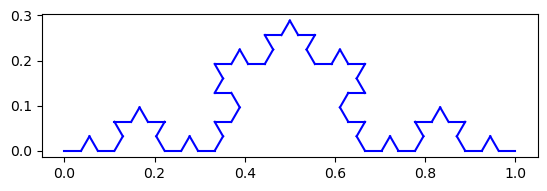

In [4]:
plt.gca().set_aspect('equal')  # 縦横比 1:1 にする

koch(0, 0, 1, 0, 3)

plt.show()

正しく描けていたら，正三角形の3辺に沿ってステップ $k$ のコッホ曲線を描き，コッホ雪片を作ってみなさい．
$k$ をあまり大きくすると計算時間が非常にかかる．$k = 5$ くらいまでにしておいたほうがよい．

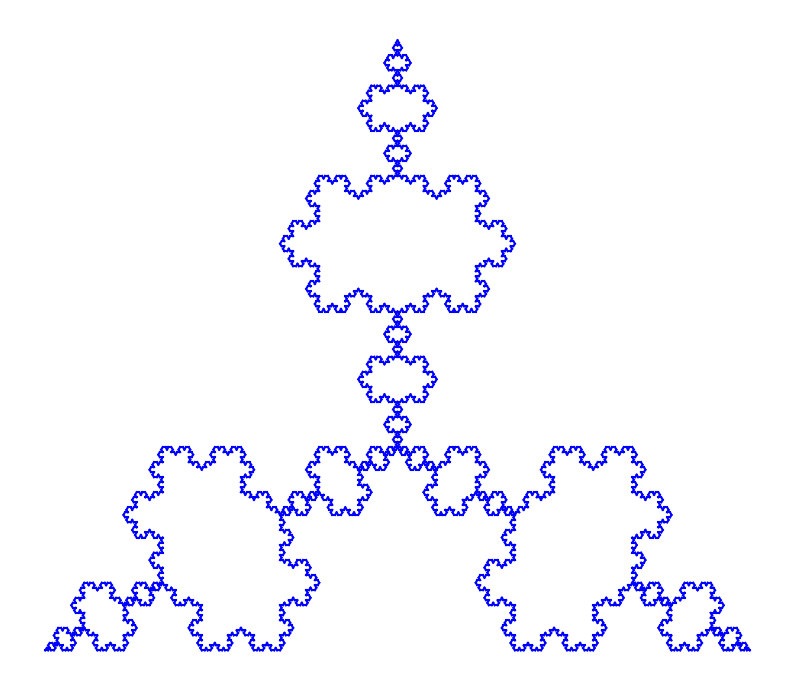

In [5]:
plt.figure(figsize=(10, 10))
plt.gca().set_aspect('equal') # 縦横 1:1 で表示

# *** 実装しなさい ***
# 3本のコッホ曲線を正三角形の辺に沿って描き、コッホ雪片を作る
koch(0, 0, 1, 0, 5)
koch(1, 0, 0.5, 3**0.5/2, 5)
koch(0.5, 3**0.5/2, 0, 0, 5)

plt.axis('off')
plt.show()

## 2. 簡単な数式処理
そのうち別の授業で Mathematica というソフトウェアを使ったプログラミングをすることになる．もうやっているかもしれない．

Mathematica では数式そのものについていろいろな処理ができる．すなわち単に数式を書いて計算するだけではなく，数式そのものをデータとして，いろいろな式変形をプログラムで行うことができる．

ここでは簡単な数式処理システムを Python で作ってみる．

まず数式をデータとして扱うための表現を決める．ここでは `[演算子, 引数1, 引数2]` あるいは `[関数, 引数]` というリストの形で数式を表すことにする．

`演算子` や `関数` のところには，演算子や関数の名前を文字列で書くことにする．

例えば，$1 + 3$ という数式は `["+", 1, 3]` というリストで表される．つまり 
```python
    [演算子, 引数1, 引数2]
```
は普通の書き方では
```python
    引数1 演算子 引数2
```
に対応する．

同様に，$\sin 2$ という数式は `["sin", 2]` というリストで表される．つまり
```python
    [関数, 引数]
```
は普通の描き方では
```python
    関数(引数)
```
に対応する．

`引数` のところに，さらに数式を入れることで，例えば $1 + 2 \times 3$ は `["+", 1, ["*", 2, 3]]` と表すことができる．

また，例えば $\sin 1 + \cos 3$ は `["+", ["sin", 1], ["cos", 3]]` と表されることになる．

リストのまとまりが計算の順序を表すので，普通の書き方では $(1 + 2) \times 3$ のようにカッコが必要なところも `["*", ["+", 1, 2], 3]` のように書ける．

差し当たり，演算子としては
* `"+"` ... 足し算
* `"-"` ... 引き算
* `"*"` ... かけ算
* `"/"` ... 割り算

の4種類を考えよう．

関数としては

* `"sin"` ... $\sin$
* `"cos"` ... $\cos$
* `"exp"` ... $\exp$
* `"-"` ... 単項演算子としてのマイナス；例えば `["-", 3]` は -3 と同じ意味

の4種類を考えよう．


### 練習12.4: 定数式の評価
まずは，上のようなリストによる数式の表現を受け取って，その値を計算する関数 `ev` を作ってみよう．ちょっと入力が面倒な電卓のようなものである．

例えば入出力例としては以下のようになる
```python
ev(["+", ["*", 1, 2], 3]) --> 5  
# つまり 1 * 2 + 3 = 5

ev(["+", ["*", ["sin", 1], ["sin", 1]],
         ["*", ["cos", 1], ["cos", 1]]]) --> 0.999999 
# つまり sin(1)*sin(1) + cos(1)*cos(1) = 誤差のためずれるが，ほぼ 1
```

あるリストを入力として受け取ったとき，例えばそれが長さ 3 であれば `[演算子, 引数1, 引数2]` の形であることが分かる．
また長さが2であれば，`[関数, 引数]` の形であることが分かる．

数式の値を計算するためには，`引数1`，`引数2` や `引数` の部分に数値が書いてあるか，それとも，さらにリストで表された数式になっているかを判定する必要がある．

そのためには，`引数1`，`引数2`，`引数` の部分の「タイプ」を調べればよい．これは Python の関数 `type` を使って行える．

例えば `type` に整数を与えると：

In [6]:
type(3)

int

と返り値は `int` になる．

また，`type` に浮動小数点数を与えると

In [7]:
type(3.2)

float

と返り値は `float` になる．

そして，`type` にリストを与えると

In [8]:
type(["+", 2, ["-", 2, 3]])

list

と返り値は `list` になる．

例えば `type(x)` を用いて調べた `x` のタイプが整数であるかどうかは，整数型を表す `int` と `type(x)` を比較すればよい．
このとき `int` を `"..."` で囲んだりする必要はなく，プログラム上でもそのまま `int` と書けばよい．その他のタイプについても同様：

In [9]:
x = 3
# x = [3] # こちらも試してみること

if type(x) == int:
    print("x は整数です")
elif type(x) == list:
    print("x はリストです")
else:
    print("x は整数でもリストでもありません")

x は整数です


これらを用いると，入力された数式を `expr` とするとき，その値の計算は以下のように場合分けして処理できる：
```python
if type(expr) == int or type(expr) == float:
    # 数式が数値そのものだった時の処理
elif type(expr) == list:
    if len(expr) == 2:
        # [関数, 引数] の処理
    elif len(expr) == 3:
        # [演算子, 引数1, 引数2] の処理
    else:
        # ありえないパターン
        print("入力エラーです:", expr)
else:
    # いまのところあり得ないパターン
    print("入力エラーです:", expr)    
```

それでは，入力としてリストで表現された数式 `expr` を受け取り，その値を返す関数 `ev` を実装しなさい．

関数 "sin", "cos", "exp" の値は `from math import *` と書いた後では単に Python の関数として `sin` `cos` `exp` で計算ができる．

ヒント（ダブルクリックで表示）
<!--
以下のように再帰的に実装すればよい．

expr = [演算子, 引数1, 引数2] の形ならば

    ev(expr) の値は ev(引数1) <演算> ev(引数2) と等しい

    （つまり return ev(引数1) <演算> ev(引数2) とすればよい．以下同様）

ここで <演算> は ev[0] の演算子名に対応する演算．


expr = [関数, 引数] の形ならば

    ev(expr) の値は <関数>( ev(引数) ) と等しい
    
ここで <関数> は expr[0] の関数名に対応した関数．

<演算> と <関数> については，"+", "-", ... "sin", ... などについて
それぞれ場合分けして計算すればよい．


expr = 数値  （例えば expr = 1.2) の形ならば

    ev(expr) の値は expr と等しい
   
つまり値は expr そのものになる．
-->

In [10]:
from math import *
import matplotlib.pyplot as plt
%matplotlib inline

def ev(expr, val):
    if type(expr) == int or type(expr) == float:
        return expr
    elif type(expr) == str:
        return val[expr]
    elif type(expr) == list:
        if len(expr) == 2:
            if expr[0] == "-":
                return -ev(expr[1], val)
            f = eval(expr[0])
            return f(ev(expr[1], val))
        elif len(expr) == 3:
            op = expr[0]
            val1 = ev(expr[1], val)
            val2 = ev(expr[2], val)
            if op == '+': return val1 + val2
            if op == '-': return val1 - val2
            if op == '*': return val1 * val2
            if op == '/': return val1 / val2
            if op == '**': return val1 ** val2

実装できたらテストしましょう：

In [11]:
print(ev(["+", ["*", 2, 3], 1], {}) == 7) # 2 * 3 + 1 = 7
print(ev(["-", 2, ["-", 2, 3]], {}) == 3) # 2 - (2 - 3) = 3
print(ev(["/", 1, ["/", 1, 2]], {}) == 2) # 1 / (1 / 2)

one = ["+", ["*", ["sin", 1], ["sin", 1]],
            ["*", ["cos", 1], ["cos", 1]]]


print(1 >= ev(one, {}) > 0.9999) # sin^2(1) + cos^2(1) ≒ 1 (だいたい 1)

ichi = ["exp", ["-", 1.2, ["+", 0.3, 0.9]]]


print(1.0001 >= ev(ichi, {}) >= 0.9999)

True
True
True
True
True


### 練習12.5: 変数を含む式の評価
数式の中で変数が使えるようにしましょう．

変数は文字列で `"x"` や `"y"` のように表すことにします．

そうすると，例えば $ax + b$ という式は `["+", ["*", "a", "x"], "b"]` という風に表されます．

また，$3 \cos 2x$ は `["*", 3, ["cos", ["*", 2, "x"]]]` となります．

`expr` の中の引数が変数かどうかは，`type(引数)` が `str` かどうかを調べれば分かります：

In [12]:
type("x")

str

変数を含む数式は，全ての変数に値を代入すれば値が決まります．これを行うプログラムを作りましょう．

上で実装した `ev` を拡張（コピペして修正）し，変数を含む（かもしれない）数式 `expr` と，`{"x": 1, "y": 2}` のように変数名をキーとして，その値を対応付けた辞書 `val` を受け取り，`val` で指定された値を変数に代入したときの `expr` の値を計算して返す関数 `ev(expr, val)` を実装しなさい．

`expr` に含まれる全ての変数は，`val` にキーとして存在すると仮定してよい．

ヒント（ダブルクリックで表示）
<!--
上で実装した関数 ev の type(expr) に関する場合わけは

* type(expr) == list の場合 -> 数式として処理

* type(expr) == int or type(expr) == float の場合 -> 数値として処理

だった．これに

* type(expr) == str の場合 -> 変数として処理

  つまり，辞書 val から対応する変数の値を探して返す処理を加えればよい

-->

In [13]:
from math import *

def ev(expr, val):
    if type(expr) == int or type(expr) == float:
        return expr
    elif type(expr) == str:
        return val[expr]
    elif type(expr) == list:
        if len(expr) == 2:
            f = eval(expr[0])
            return f(ev(expr[1], val))
        elif len(expr) == 3:
            op = expr[0]
            val1 = ev(expr[1], val)
            val2 = ev(expr[2], val)
            if op == '+': return val1 + val2
            if op == '-': return val1 - val2
            if op == '*': return val1 * val2
            if op == '/': return val1 / val2
            if op == '**': return val1 ** val2

実装できたらテストしなさい：

In [14]:
print(ev(["+", "x", 3], {"x": 1}) == 4)  # x = 1 --> x + 3 = 4
print(ev(["exp", ["+", "x", "y"]], {"x": 1, "y": -1}) == 1.0) # x = 1, y = -1 --> exp(x+y) = 1.0

True
True


### 練習12.6: グラフの表示
さらに，数式を関数とみなして，そのグラフを描いてみよう．

関数 `draw_graph(f, xs, c)` は以下の3つを入力として `f` のグラフを描く関数である．
* `f`: 変数として `"x"` だけを含む数式
* `xs`: `"x"` の値のリスト．例えば `xs = [0, 0.1, 0.2, ..., 1.9, 2.0]`
* `c`: 線の色を表す文字列．例えば `"red"`, `"blue"` など

手順としては，まず，`f` の中の変数 `"x"` に `xs = [x1, x2, ...]` の各値を代入したときの値を並べたリスト
 `ys = [y1, y2, ...]` を作る．
そして，`plt.plot(xs, ys, color=c)` によって点 `(x1, y1), (x2, y2), ...` をこの順につないだグラフを色 `c` で描けばよい．

以下の実装の足りない部分を埋めなさい：

In [15]:
import matplotlib.pyplot as plt

def draw_graph(f, xs, c):
    ys = [ev(f, {"x": x}) for x in xs]
    plt.plot(xs, ys, color=c)

ヒント（ダブルクリックで表示）
<!--
xs の各要素 x での値を ev(f, {"x": x}) で求めてリスト ys に入れればよい
-->

実装できたら，テストしましょう．以下のセルを実行すると $f(x) = x^2 \sin(2x)$ のグラフが描画される：

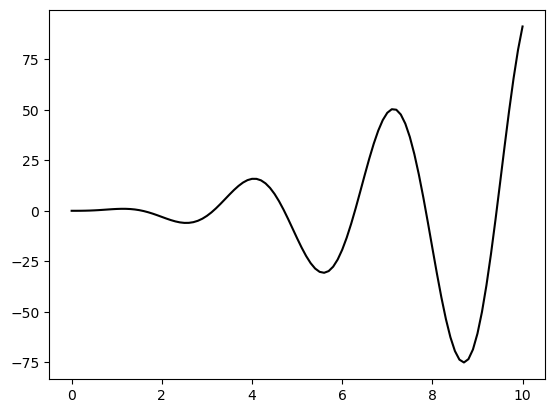

In [16]:
f = ["*", ["*", "x", "x"], ["sin", ["*", 2, "x"]]] # = x^2 sin(2x)
xs = [0.1 * i for i in range(0, 100+1)]

draw_graph(f, xs, "black")
plt.show()

以下のセルの `f` に数式，`xs` にx座標のリストをセットし，$f(x) = \cos\left(\frac{x}{2}\right)\sin(5x)$ のグラフを $-10 \le x \le 10$ の範囲で描きなさい．x座標のリストは上の例と同じく 0.1 刻みにしなさい．つまり `xs = [-10, -9.9, -9.8, ..., 9.9, 10]` となる：

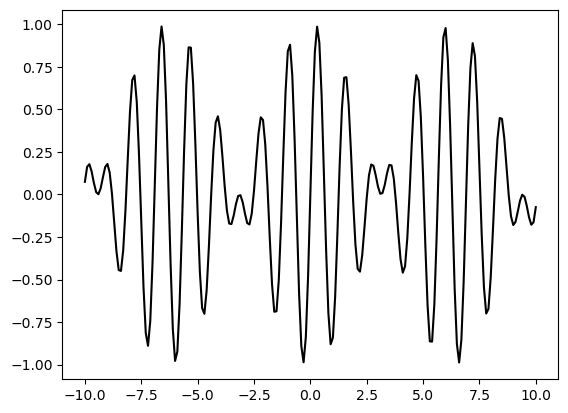

In [17]:
f = ["*", ["cos", ["/", "x", 2]], ["sin", ["*", 5, "x"]]]

xs = [-10 + 0.1 * i for i in range(201)]

draw_graph(f, xs, "black")
plt.show()

### 練習12.7: 微分の計算
次に，変数を含む（かもしれない）数式 `expr` を，ひとつの変数 `v` で微分した式を返す関数 `deriv(expr, v)` を実装しなさい．

Python の変数 `v` と，`v` が表す `expr` の中の変数（たとえば文字列 `"x"`）の区別に気をつけること．
例えば `v = "x"` ならば，`deriv(expr, v)` は，数式 `expr` を変数 `"x"` で微分した式を計算することになる．

入出力の例：
```python
# d/dx(x * x + 1) = 2x
deriv(["+", ["*", "x", "x"], 1], "x")
--> ['+', ['+', ['*', 1, 'x'], 
                ['*', 'x', 1]], 
          0]
# (= 1 * x + x * 1 + 0 = 2x)

# d/dx(3 * x * y) = 3y
deriv(["*", 3, ["*", "x", "y"]], "x") 
--> ['+', ['*', 0, ['*', 'x', 'y']], 
          ['*', 3, ['+', ['*', 1, 'y'], 
                         ['*', 'x', 0]]]]
# (= 0 * x * y + 3 * (1 * y + x * 0) = 3y)

# d/dx(cos(3*x)) = -3 sin(3x)
deriv(["cos", ["*", 3, "x"]], "x") 
--> ['*', ['+', ['*', 0, 'x'], ['*', 3, 1]], 
          ['-', ['sin', ['*', 3, 'x']]]] 
# (= (0x + 3*1) * (-sin(3x)) = -3 sin(3x))
```

上の入出力例から分かるように，微分した結果の式を簡単化して返す必要はない．例えば，一番上の例では `["*", 2, "x"]` を返す必要はない．

自然に実装すると上の例のように簡単でない形で結果が返ってくる理由は実装してみれば分かるだろう．

ヒント（ダブルクリックで表示）
<!--
和・差・積・商および合成関数の微分をひとつずつ実装していけばよい．

例えば和の微分 d(f+g)/dx = df/dx + dg/dx から

    deriv(["+", 引数1, 引数2], v) = ["+", deriv(引数1, v), deriv(引数2, v)]
    
となる．
-->

さらにヒント（ダブルクリックで表示）
<!--

関数 f の変数 x による微分を f' であらわすと
合成関数の微分

    (f(g(x)))' = g'(x) f'(g(x))

から

    deriv([関数, 引数], "x") = ["*", deriv(引数, "x"), [導関数, 引数]]
    
となる．ここで「導関数」は左辺の「関数」の導関数．
例えば 関数 = "sin" なら 導関数 = "cos" になる．

また，落ち着いて数学の問題だと思えば当り前だが
微分する変数，例えば "x" 以外の変数を "x" で微分すればゼロ：

    deriv("y", "x") = 0
    
微分する変数と同一の変数を微分すれば 1：

    deriv("x", "x") = 1
    
定数（数値）を微分すればゼロである：

    deriv(3, "x") = 0
-->

In [18]:
def deriv(expr, v):
    if type(expr) == int or type(expr) == float:
        return 0
    elif type(expr) == str:
        if expr == v:
            return 1
        else:
            return 0
    elif type(expr) == list:
        if len(expr) == 2:
            f = expr[0]
            arg = expr[1]
            darg = deriv(arg, v)
            if f == "sin":
                return ["*", ["cos", arg], darg]
            elif f == "cos":
                return ["*", ["*", -1, ["sin", arg]], darg]
            elif f == "exp":
                return ["*", ["exp", arg], darg]
        elif len(expr) == 3:
            op = expr[0]
            e1 = expr[1]
            e2 = expr[2]
            d1 = deriv(e1, v)
            d2 = deriv(e2, v)
            if op == "+":
                return ["+", d1, d2]
            elif op == "-":
                return ["+", d1, ["*", -1, d2]]
            elif op == "*":
                return ["+", ["*", d1, e2], ["*", e1, d2]]

実装できたらテストしましょう：

In [19]:
# f(x) = x * x + 1
# --> f'(x) = 2x
# --> f'(1) = 2
#     f'(0) = 0
f = ["+", ["*", "x", "x"], 1]
print(ev(deriv(f, "x"), {"x": 1}) == 2)
print(ev(deriv(f, "x"), {"x": 0}) == 0)

# g(x, y) = 3 * x * y
# --> (∂g/∂x)(x, y) = 3y
# --> (∂g/∂x)(1, 1) = 3
#     (∂g/∂x)(0, 2) = 6
g = ["*", 3, ["*", "x", "y"]]
print(ev(deriv(g, "x"), {"x": 1, "y": 1}) == 3)
print(ev(deriv(g, "x"), {"x": 0, "y": 2}) == 6)

# h(x) = cos(3 * x)
# --> h'(x) = -3 sin(3 * x)
# --> h'(0) = 0
#     h'(π/3) = 0
#     h'(π/6) = -3
import math
h = ["cos", ["*", 3, "x"]]
print(ev(deriv(h, "x"), {"x": 0}) == 0)
print(-0.0001 < ev(deriv(h, "x"), {"x": math.pi / 3}) < 0.0001)
print(-3.0001 < ev(deriv(h, "x"), {"x": math.pi / 6}) < -2.9999)

True
True
True
True
True
True
True


### 練習12.8: 接線のグラフ
数式が表す関数のグラフに接線をいくつか加えて描いてみよう．

以下のプログラムの足りないところを埋めて実行し，`x_min <= x <= x_max` の範囲の数式 `f` のグラフに接線を6本加えて描く関数 `draw_tangent_lines(f, x_min, x_max)` を実装しなさい．

接線を引く位置は，グラフを描く範囲の両端 `x_min`, `x_max` に，範囲を5等分する4点を加えた計6点としなさい．すなわち以下のような $x_0, x_1, \dots, x_5$ で接線を引きなさい．

$$
\mathrm{x\_min} = x_0 < x_1 < x_2 < x_3 < x_4 < x_5 = \mathrm{x\_max}
$$

$$
x_{i+1} - x_i = \frac{\mathrm{x\_max} - \mathrm{x\_min}}{5} \;\; (i = 0, 1, 2, 3, 4)
$$

関数 `f` のグラフは黒，接線は赤で描きなさい．

ヒント（ダブルクリックで表示）
<!--
ev を使えば接点の y 座標が計算でき，
deriv と ev を使えば接線の傾きが計算できる．

グラフ上の点を打つ x 座標のリスト xs はすでに計算してあるので，
接点の座標と傾きから接線を表す数式 g を作り draw_graph(g, xs, "red")
で接線のグラフを画面に加えればよい．
-->

In [20]:
def draw_tangent_lines(f, x_min, x_max):
    num_points = 100

    delta = (x_max - x_min) / (num_points - 1)

    xs = [x_min + delta * i for i in range(num_points + 1)]

    ys = [ev(f, {"x": x}) for x in xs]
    y_max = max(ys)
    y_min = min(ys)

    plt.ylim([y_min, y_max])

    draw_graph(f, xs, "black")

    df = deriv(f, "x")

    for i in range(6):
        xi = x_min + (x_max - x_min) * i / 5
        
        yi = ev(f, {"x": xi})
        slope = ev(df, {"x": xi})
        
        tangent_expr = ["+", ["*", slope, ["-", "x", xi]], yi]
        
        draw_graph(tangent_expr, xs, "red")

放物線でテスト：

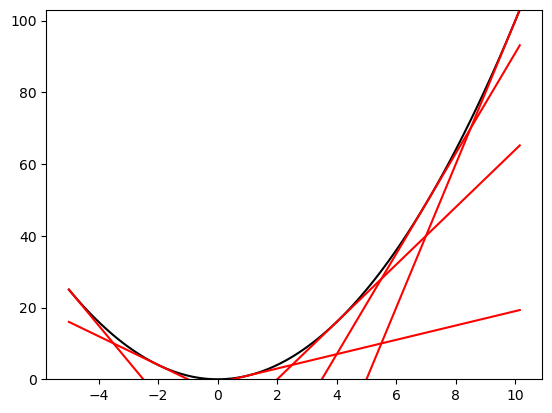

In [21]:
draw_tangent_lines(["*", "x", "x"], -5, 10)
plt.show()

$f(x) = x^2\sin(2x)$ でテスト：

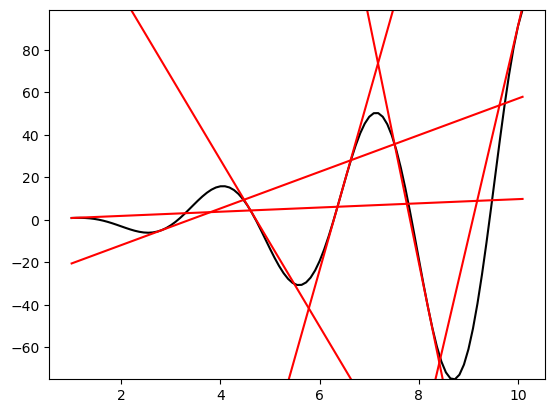

In [22]:
f = ["*", ["*", "x", "x"], ["sin", ["*", 2, "x"]]] # = x^2 sin(2x)

draw_tangent_lines(f, 1, 10)
plt.show()

---
**提出前の確認**

おつかれさまでした．以上で今回の課題は全て終わりです．
* メニューの Run から Run All Above Selected Cell を選択して全てのセルが全て正しく実行されることを確かめ，
* 左上の保存のボタンを押して出力結果を保存してからノートブックを提出してください．
* <font color="red">必ず出力結果も保存して提出すること</font>

---
中級編３：おわり